# BIL545 · Proje 1 · Vizeye kadarki konular (2.–7. haftalar)
**Veri Madenciliğinde İleri Konular · 2026–2027 Güz** · **Vize notu** · Teslim ve sunum: **8. hafta**

Bu defter projenin şablonudur. Grubunuz defteri kendi Drive'ına kopyalar (**Dosya → Drive'a kopya kaydet**), doldurur ve **iki yere** yükler: GitHub deposundaki `proje1/` klasörüne ve STIX'teki ödev alanına. Bütün yazılı cevaplar bu defterin metin hücrelerindedir; ayrı bir rapor yoktur.

**Kapsam grup tipine göre:** 1–3 kişilik gruplar Bölüm 1–3'ü, 4 kişilik gruplar ek olarak Ek paket 1'i, 5 kişilik gruplar Ek paket 1 ve 2'yi yapar. Grubunuzun yapmadığı ek paket bölümlerini silin. Defterin sonundaki **katkı beyanı puanlanır**; sunumda her üye en az bir alt başlığı anlatır.

**Teslimden önce:** Çalışma zamanını sıfırlayıp **Çalışma Zamanı → Tümünü çalıştır** ile defteri baştan sona hatasız çalıştırın.

**Puanlama:** Başarım puanlanmaz. Her bölüm kurulumun doğruluğu (%30), kararların gerekçesi (%25), dürüst raporlama (%25), yorum (%15) ve teknik düzene (%5) göre puanlanır. Ayrıntılar: *Proje 1 ve Proje 2 Yönergesi*.

## Grup bilgisi
| | Ad Soyad | Öğrenci no |
|---|---|---|
| Üye 1 | Murat Gülşen | 264309500 |
| Üye 2 | Halil Çankaroğlu | 264329016 |
| Üye 3 | Mesut İşsever | 264329015 |
| Üye 4 | Alp Aydın Özçelik | 244312033 |
| Üye 5 | Melih Turgut | 244309019 |

**Grup adı:** Grup 01  
**GitHub deposu:** https://github.com/gulsenmurat/proje1  
**Seçilen konu:** 9.28 — Banka müşterisi kaybı  
**Grup tipi:** 5 kişi: + Ek paket 1 ve 2  
**Veri kümesi ve sorumuz (tek cümle):** Bank Customer Churn (Churn_Modelling.csv) veri kümesindeki yaklaşık 10.000 müşteriye ait 14 sütunluk veriyi makine öğrenmesi yöntemleriyle analiz ederek, müşteri ayrılma riskini önceden tahmin edebilir ve bankanın müşteri elde tutma çalışmalarında öncelik vermesi gereken müşterileri belirleyebilir miyiz?

## Hazırlık

In [1]:
import sys, warnings, numpy as np, pandas as pd, sklearn, scipy, matplotlib
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
print("Python      ", sys.version.split()[0]); print("numpy       ", np.__version__)
print("pandas      ", pd.__version__);          print("scikit-learn", sklearn.__version__)
print("scipy       ", scipy.__version__);       print("matplotlib  ", matplotlib.__version__)
try:
    import statsmodels; print("statsmodels ", statsmodels.__version__)
except ImportError:
    print("statsmodels  yüklü değil (2.4'te gerekir: !pip -q install statsmodels)")

Python       3.13.16
numpy        2.1.3
pandas       2.2.3
scikit-learn 1.6.1
scipy        1.16.3
matplotlib   3.10.0
statsmodels  0.15.0


### Veriyi yükleme
**Kaynak:** Bank Customer Churn / Churn Modelling — [Kaggle Veri Kümesi](https://www.kaggle.com/datasets/aakash50897/churn-modellingcsv)

**Lisans:** Kaggle kaynak sayfasında açık bir lisans belirtilmemiştir (Unknown); yeniden dağıtım izni varsayılmamaktadır.

**İndirme / Yükleme Adımı:** Churn_Modelling.csv dosyası Kaggle üzerinden indirilerek Google Colab ortamına yüklenmiştir. Veri dosyası GitHub deposuna eklenmemiştir.

In [2]:
import os
DATA_PATH = "Churn_Modelling.csv"
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Churn_Modelling.csv dosyasını seçin (veri depoya konmaz, her oturumda yeniden yüklenir)...")
        files.upload()
    except ImportError:
        raise FileNotFoundError("Churn_Modelling.csv bu klasörde yok. Kaynaktan indirip defterin yanına koyun.")
df = pd.read_csv(DATA_PATH)

TARGET    = "Exited"                                   # 1 = müşteri bankadan ayrıldı
ID_COLS   = ["RowNumber", "CustomerId"]                # kimlik sütunları: modele girmez
HIGH_CARD = "Surname"                                  # yüksek kardinaliteli nominal sütun (1.4)
NUM_COLS  = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
BIN_COLS  = ["HasCrCard", "IsActiveMember"]
CAT_COLS  = ["Geography", "Gender"]
FEATURES  = NUM_COLS + BIN_COLS + CAT_COLS
beklenen = set(ID_COLS + [HIGH_CARD, TARGET] + FEATURES)
assert beklenen == set(df.columns), f"Sütun uyuşmazlığı: {beklenen ^ set(df.columns)}"
X = df[FEATURES].copy()
y = df[TARGET].astype(int).values
print(df.shape)
display(df.head())

Churn_Modelling.csv dosyasını seçin (veri depoya konmaz, her oturumda yeniden yüklenir)...


Saving Churn_Modelling.csv to Churn_Modelling.csv
(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# --- Ortak yardımcılar: bütün bölümler bunları kullanır ---
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_validate, cross_val_score

# Ana değerlendirme protokolü: 5 katlı, 5 kez tekrarlı, tabakalı çapraz doğrulama (25 katman)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)

# Sınıflar dengesiz olduğu için doğruluk (accuracy) ana ölçüt DEĞİLDİR; yalnızca neden yanıltıcı olduğunu göstermek için tabloda tutulur.
SCORING = {"roc_auc": "roc_auc", "avg_precision": "average_precision", "f1": "f1",
           "balanced_acc": "balanced_accuracy", "accuracy": "accuracy"}

def make_pre(num_cols=NUM_COLS, bin_cols=BIN_COLS, cat_cols=CAT_COLS, scale=True):
    """Ön işleme: yalnızca Pipeline içinde, her katta eğitim verisiyle uydurulur."""
    return ColumnTransformer([
        ("num", StandardScaler() if scale else "passthrough", list(num_cols)),
        ("bin", "passthrough", list(bin_cols)),
        ("cat", OneHotEncoder(handle_unknown="ignore"), list(cat_cols))])

def ort_std(a):
    a = np.asarray(a, dtype=float); return f"{a.mean():.3f} ± {a.std(ddof=1):.3f}"

def sonuc_tablosu(sonuclar, olcutler=("roc_auc", "avg_precision", "f1", "balanced_acc", "accuracy")):
    """sonuclar: {ad: cross_validate çıktısı}. Hücreler 'ortalama ± std' (std: katmanlar arası)."""
    return pd.DataFrame({ad: {o: ort_std(r["test_" + o]) for o in olcutler} for ad, r in sonuclar.items()}).T

def sekil_aciklamasi(metin):
    print("Şekil açıklaması:", metin)

# Bölüm 1 · Veri, ön işleme ve sızıntı *(ağırlık 30)*
**Makale:** Kaufman vd. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM TKDD*, 6(4).

Veri sızıntısı, modelin tahmin sırasında normalde erişemeyeceği bilgileri eğitim aşamasında kullanmasıdır. Bu durum modelin gerçekte olduğundan daha başarılı görünmesine neden olabilir. Müşteri numarası gibi kimlik sütunları tahmin için anlamlı özellikler olarak kullanılmamalıdır. Ayrıca hedef kodlama gibi işlemler tüm veri üzerinde değil, yalnızca ilgili eğitim verileri üzerinde yapılmalıdır.

### 1.1 Veri künyesi
| Soru | Cevap |
|---|---|
| Kim, hangi amaçla topladı? | *Veri Kaggle'da Aakash Aggrawal tarafından paylaşılmıştır. İlk kimin topladığı ve özgün toplama amacı belirtilmemiştir.* |
| Hangi dönemi kapsıyor? | *Veri toplama dönemi kaynakta belirtilmemiştir. Bu nedenle zaman içindeki değişimler değerlendirilememektedir.* |
| Hedef gerçek olgu mu, vekil mi? | *Exited sütunu müşterinin bankadan ayrılma durumunu gösterir. 1 ayrıldı, 0 kaldı anlamına gelir. Gerçek banka kayıtlarıyla doğrulanıp doğrulanmadığı belirtilmemiştir.* |
| Kimler eksik temsil ediliyor olabilir? | *Yalnızca Fransa, Almanya ve İspanya müşterileri bulunmaktadır. Diğer ülkelerdeki müşteriler temsil edilmemektedir.* |
| Lisans | *Kaggle kaynak sayfasında lisans bilgisi Unknown (bilinmiyor) olarak belirtilmiştir.* |

In [4]:
# Künyeyi doldururken kaynak sayfasındaki veri açıklamasını (kim, ne zaman, hangi amaçla) okuyun.
print("Satır × sütun:", df.shape)
print("Sütunlar:", list(df.columns))
print(df.dtypes.value_counts())
print("Hedef:", TARGET, "→ 1 = ayrıldı, 0 = kaldı")

Satır × sütun: (10000, 14)
Sütunlar: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
int64      9
object     3
float64    2
Name: count, dtype: int64
Hedef: Exited → 1 = ayrıldı, 0 = kaldı


**Yorum** Bu çalışmada Kaggle üzerinden elde ettiğim Bank Customer Churn veri kümesini inceledim. Veri kümesinde 10.000 müşteriye ait 14 sütun bulunmaktadır. Bunların 9'u tam sayı, 3'ü metin ve 2'si ondalıklı sayı türündedir.

Hedef değişken olan Exited, müşterinin bankadan ayrılıp ayrılmadığını göstermektedir. Veri kümesinin özgün toplanma amacı, dönemi ve üreticisi kesin olarak belgelenmediği için bu konularda sınırlılıklar bulunmaktadır.

RowNumber ve CustomerId gibi kimlik bilgilerini modelin tahmin değişkenleri arasında kullanmamayı tercih ettim. Ayrıca veriler yalnızca belirli ülkelerden müşterileri kapsadığı için elde edilen sonuçların bütün banka müşterilerine genellenemeyebileceğini düşünüyorum.

Veri kaynağı: https://www.kaggle.com/datasets/aakash50897/churn-modellingcsv

Erişim tarihi: 10.10.2026

### 1.2 Keşifsel analiz
Boyut; saklama ve ölçek tipleri; hedef dağılımı; yinelenen satırlar; künye tablosu (tip, eksik oranı, farklı değer sayısı, sıfır oranı); şüpheli öznitelik listesi.

Boyut: (10000, 14)
Exited
0    7963
1    2037
Name: count, dtype: int64 
Ayrılma oranı: 0.2037


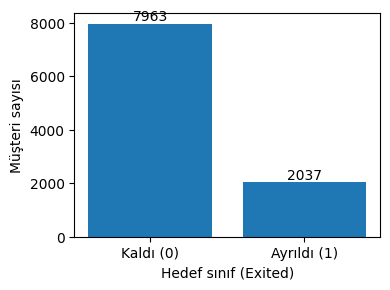

Şekil açıklaması: Sınıflar dengesiz: ayrılan müşteriler azınlıktır; bu yüzden doğruluk yanıltıcıdır.
Tam yinelenen satır: 0
Kimlik sütunları hariç yinelenen satır: 0
CustomerId benzersiz mi: True | RowNumber benzersiz mi: True


,saklama_tipi,olcek_tipi,eksik_orani,farkli_deger,sifir_orani
RowNumber,int64,kimlik (sıra no),0.0,10000,0.0000
CustomerId,int64,"kimlik (nominal, sayı görünümlü)",0.0,10000,0.0000
Surname,object,nominal (yüksek kardinalite),0.0,2932,NaN
CreditScore,int64,aralık,0.0,460,0.0000
Geography,object,nominal,0.0,3,NaN
Gender,object,nominal (ikili),0.0,2,NaN
Age,int64,oran,0.0,70,0.0000
Tenure,int64,oran (tam yıl),0.0,11,0.0413
Balance,float64,oran,0.0,6382,0.3617
NumOfProducts,int64,sıralı / sayım,0.0,4,0.0000


,sutun,gerekce
0,RowNumber,her satırda farklı değer → kimlik benzeri
1,CustomerId,her satırda farklı değer → kimlik benzeri
2,Surname,2932 farklı değer → yüksek kardinalite
3,Balance,sıfır oranı %36 → kodlanmış eksik olabilir


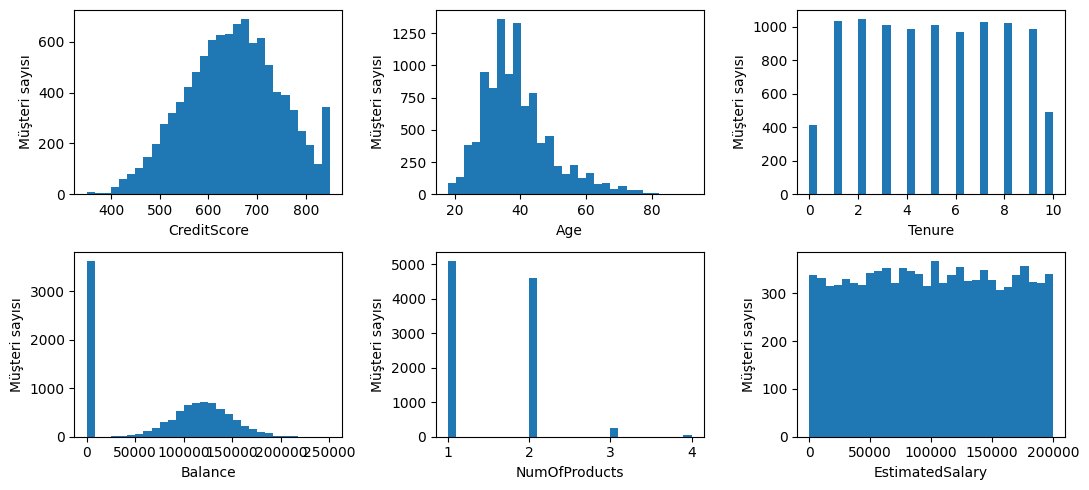

Şekil açıklaması: Balance'ta sıfırda büyük bir yığılma var; diğer sütunlar daha düzgün dağılıyor (Tenure ve EstimatedSalary neredeyse düzgün).


In [5]:
print("Boyut:", df.shape)

# Ölçek tipleri (öneri: ekip tartışıp doğrulasın)
olcek = {"RowNumber": "kimlik (sıra no)", "CustomerId": "kimlik (nominal, sayı görünümlü)", "Surname": "nominal (yüksek kardinalite)",
         "CreditScore": "aralık", "Geography": "nominal", "Gender": "nominal (ikili)", "Age": "oran", "Tenure": "oran (tam yıl)",
         "Balance": "oran", "NumOfProducts": "sıralı / sayım", "HasCrCard": "nominal (ikili)", "IsActiveMember": "nominal (ikili)",
         "EstimatedSalary": "oran", "Exited": "hedef, nominal (ikili)"}

# Hedef dağılımı
hd = df[TARGET].value_counts().sort_index()
print(hd, "\nAyrılma oranı:", round(df[TARGET].mean(), 4))
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["Kaldı (0)", "Ayrıldı (1)"], hd.values); ax.set_ylabel("Müşteri sayısı"); ax.set_xlabel("Hedef sınıf (Exited)")
for i, v in enumerate(hd.values): ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()
sekil_aciklamasi("Sınıflar dengesiz: ayrılan müşteriler azınlıktır; bu yüzden doğruluk yanıltıcıdır.")

# Yinelenen satırlar
print("Tam yinelenen satır:", int(df.duplicated().sum()))
print("Kimlik sütunları hariç yinelenen satır:", int(df.drop(columns=ID_COLS).duplicated().sum()))
print("CustomerId benzersiz mi:", df["CustomerId"].is_unique, "| RowNumber benzersiz mi:", df["RowNumber"].is_unique)

# Künye tablosu: tip, eksik oranı, farklı değer sayısı, sıfır oranı
sayisal = df.select_dtypes("number")
kunye = pd.DataFrame({
    "saklama_tipi": df.dtypes.astype(str),
    "olcek_tipi": pd.Series(olcek),
    "eksik_orani": df.isna().mean().round(4),
    "farkli_deger": df.nunique(),
    "sifir_orani": (sayisal == 0).mean().reindex(df.columns).round(4)})
display(kunye)

# Şüpheli öznitelik taraması (otomatik ipuçları; son kararı ekip verir)
supheli = []
for c in df.columns:
    if c == TARGET: continue
    nu = df[c].nunique()
    if nu == len(df):
        supheli.append((c, "her satırda farklı değer → kimlik benzeri"))
    if pd.api.types.is_numeric_dtype(df[c]) and nu > 0 and (sayisal[c] == 0).mean() > 0.20 and c not in BIN_COLS:
        supheli.append((c, f"sıfır oranı %{100*(sayisal[c]==0).mean():.0f} → kodlanmış eksik olabilir"))
    if not pd.api.types.is_numeric_dtype(df[c]) and nu / len(df) > 0.10:
        supheli.append((c, f"{nu} farklı değer → yüksek kardinalite"))
# Sonradan bilinen sütun var mı? (hedefle aynı anda oluşan bir sütun) → elle değerlendirin ve aşağıya yazın.
display(pd.DataFrame(supheli, columns=["sutun", "gerekce"]))

# Sayısal sütunların dağılımı
fig, axes = plt.subplots(2, 3, figsize=(11, 5))
for ax, c in zip(axes.ravel(), NUM_COLS):
    ax.hist(df[c], bins=30); ax.set_xlabel(c); ax.set_ylabel("Müşteri sayısı")
plt.tight_layout(); plt.show()
sekil_aciklamasi("Balance'ta sıfırda büyük bir yığılma var; diğer sütunlar daha düzgün dağılıyor (Tenure ve EstimatedSalary neredeyse düzgün).")

**Yorum** Bu çalışmada 10.000 müşteriye ait 14 sütundan oluşan veri kümesini inceledim. Müşterilerin 7.963'ünün (%79,63) bankada kaldığını, 2.037'sinin (%20,37) ise ayrıldığını gördüm. Bu durum veri kümesinde sınıf dengesizliği olduğunu göstermektedir. Bu nedenle modelin başarısını yalnızca doğruluk oranıyla değerlendirmek yanıltıcı olabilir. ROC AUC, F1 ve Average Precision gibi ölçütlerin de kullanılması gerektiğini düşünüyorum.

Veri kümesinde eksik değer ve tamamen yinelenen satır bulunmamaktadır. RowNumber ve CustomerId sütunlarının her satırda farklı olduğunu gördüm. Bu sütunlar müşteri kimliği ve kayıt sırası bilgileri taşıdığı için modele dahil edilmemelidir. Surname sütununda ise 2.932 farklı değer bulunmaktadır. Bu kadar fazla kategori bulunması modelin karmaşıklığını artırabileceğinden bu sütunu da kullanmamayı tercih ettim.

Balance değişkeninde müşterilerin yaklaşık %36,17'sinin bakiyesinin sıfır olduğunu gördüm. Bu değerler doğrudan eksik veri olarak değerlendirilmemelidir. Ayrıca yaş değişkeninin belirli aralıklarda yoğunlaştığı, maaş ve kıdem değişkenlerinin ise daha düzenli dağıldığı görülmektedir.

Veri sızıntısını kontrol etmek amacıyla sütun isimlerini, veri türlerini, kimlik alanlarını ve hedef değişkeni inceledim. Exited sütununun tahmin edilmesi gereken hedef olduğunu belirledim ve modelin giriş özelliklerinden ayırdım. Diğer sütunların tahmin anında gerçekten biliniyor olup olmadığı ise veri toplama zamanı belgelenmediği için kesin olarak doğrulanamamaktadır.

Sonuç olarak veri kümesinin makine öğrenmesi analizine uygun olduğunu, ancak sınıf dengesizliği, yüksek kategorili değişkenler ve olası veri sızıntısı risklerinin model geliştirme aşamasında dikkate alınması gerektiğini gördüm.

### 1.3 Eksiklik analizi
Eksik kodlarını `NaN`'a çevirin; deseni görselleştirin; en çok eksiği olan iki sütun için MCAR / MAR / MNAR tahmini; `add_indicator` etkisi.

Surname      metin eksik kodu: 0
Geography    metin eksik kodu: 0
Gender       metin eksik kodu: 0
Gerçek NaN sayısı: 0

Sıfır oranları (en yüksekten):
 Balance            0.3617
Tenure             0.0413
Age                0.0000
CreditScore        0.0000
NumOfProducts      0.0000
EstimatedSalary    0.0000
dtype: float64
Analiz edilen sütunlar: ['Balance', 'Tenure']

NaN'a çevirdikten sonra eksik oranı:
 Balance    0.3617
Tenure     0.0413
dtype: float64


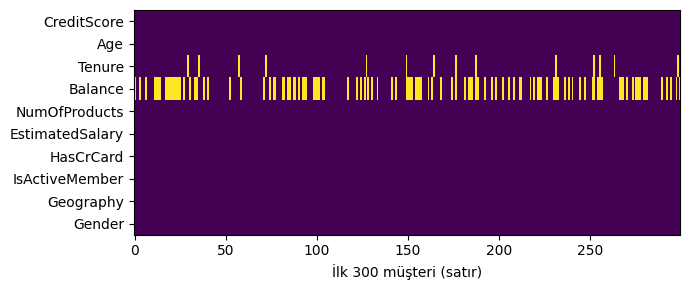

Şekil açıklaması: Açık renk = eksik (hipotez); eksiklik yalnızca seçilen sütunlarda ve satırlara düzensiz yayılmış görünüyor mu, bakın.

=== Balance: eksiklik göstergesi ===
Göstergeyi diğer özniteliklerden tahmin eden modelin AUC'si: 0.843 ± 0.007
Ayrılma oranı (gösterge=0 / gösterge=1): {0: 0.2408, 1: 0.1382}


,degisken,test,p_degeri,etki_buyuklugu
0,Geography,ki-kare,0.000000e+00,0.435657
7,NumOfProducts,Mann-Whitney,1.132327e-298,0.389961
5,Age,Mann-Whitney,2.148033e-05,0.051027
2,HasCrCard,ki-kare,6.984086e-02,0.018129
6,Tenure,Mann-Whitney,1.278048e-01,0.018212
8,EstimatedSalary,Mann-Whitney,1.514740e-01,0.017236
4,CreditScore,Mann-Whitney,3.828409e-01,0.010486
1,Gender,ki-kare,6.669053e-01,0.004304
3,IsActiveMember,ki-kare,6.959833e-01,0.003907



=== Tenure: eksiklik göstergesi ===
Göstergeyi diğer özniteliklerden tahmin eden modelin AUC'si: 0.478 ± 0.030
Ayrılma oranı (gösterge=0 / gösterge=1): {0: 0.2026, 1: 0.23}


,degisken,test,p_degeri,etki_buyuklugu
7,NumOfProducts,Mann-Whitney,0.004211,0.072958
2,HasCrCard,ki-kare,0.011680,0.025217
1,Gender,ki-kare,0.109105,0.016022
6,Balance,Mann-Whitney,0.310278,0.028736
5,Age,Mann-Whitney,0.410446,0.023870
8,EstimatedSalary,Mann-Whitney,0.410703,0.023871
3,IsActiveMember,ki-kare,0.562198,0.005796
4,CreditScore,Mann-Whitney,0.750691,0.009220
0,Geography,ki-kare,0.977325,0.002142


,roc_auc,avg_precision,f1,balanced_acc,accuracy
Sıfırı olduğu gibi bırak,0.765 ± 0.011,0.469 ± 0.025,0.313 ± 0.021,0.588 ± 0.009,0.811 ± 0.006
NaN → median (gösterge yok),0.763 ± 0.012,0.468 ± 0.025,0.313 ± 0.022,0.588 ± 0.009,0.811 ± 0.006
NaN → median + add_indicator,0.765 ± 0.011,0.468 ± 0.024,0.313 ± 0.024,0.588 ± 0.010,0.811 ± 0.006


add_indicator'ın ROC AUC farkı (aynı katmanlar):  0.002 ± 0.002


In [6]:
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 1) Kodlanmış eksik taraması: metin kodları ve gerçek NaN
metin_kodlari = ["?", "NA", "N/A", "NULL", "null", "-", "", " ", "unknown", "Unknown", "None"]
for c in df.select_dtypes(exclude="number").columns:
    print(f"{c:12s} metin eksik kodu: {int(df[c].astype(str).str.strip().isin(metin_kodlari).sum())}")
print("Gerçek NaN sayısı:", int(df.isna().sum().sum()))

# 2) Eksik benzeri adaylar: sıfırı doğal olmayan sayısal sütunlarda sıfır oranı
adaylar = (df[NUM_COLS] == 0).mean().sort_values(ascending=False).round(4)
print("\nSıfır oranları (en yüksekten):\n", adaylar)
# En yüksek iki aday analiz edilir. Balance = 0 için HİPOTEZ: 'bakiye bilinmiyor / kaydedilmemiş' (kodlanmış eksik).
# Tenure = 0 genelde 'bir yıldan az' demektir (doğal sıfır): karşılaştırma için bakılır.
ILK_IKI = list(adaylar.index[:2]); print("Analiz edilen sütunlar:", ILK_IKI)

# 3) Hipotez: sıfırlar eksik kodudur → NaN'a çevir (belirleyici, veriden öğrenmez; sızıntı yok)
df_nan = df.copy()
for c in ILK_IKI:
    df_nan.loc[df_nan[c] == 0, c] = np.nan
print("\nNaN'a çevirdikten sonra eksik oranı:\n", df_nan[ILK_IKI].isna().mean().round(4))

# 4) Eksiklik deseni
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(df_nan[FEATURES].isna().iloc[:300].T.values, aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES); ax.set_xlabel("İlk 300 müşteri (satır)")
plt.tight_layout(); plt.show()
sekil_aciklamasi("Açık renk = eksik (hipotez); eksiklik yalnızca seçilen sütunlarda ve satırlara düzensiz yayılmış görünüyor mu, bakın.")

# 5) MCAR / MAR / MNAR kanıtı: eksiklik göstergesini gözlenen değişkenlerle ilişkilendir
def eksiklik_kaniti(col):
    g = df_nan[col].isna().astype(int)
    if g.sum() < 20: print(col, ": yeterli eksik yok"); return None
    rows = []
    for c in CAT_COLS + BIN_COLS:
        ct = pd.crosstab(df[c], g); chi2, p, _, _ = chi2_contingency(ct)
        rows.append((c, "ki-kare", p, np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))))
    for c in [k for k in NUM_COLS if k != col]:
        a, b = df.loc[g == 1, c], df.loc[g == 0, c]
        u, p = mannwhitneyu(a, b); rows.append((c, "Mann-Whitney", p, abs(u / (len(a) * len(b)) - 0.5) * 2))
    tab = pd.DataFrame(rows, columns=["degisken", "test", "p_degeri", "etki_buyuklugu"]).sort_values("p_degeri")
    # Göstergeyi diğer özniteliklerden tahmin edebiliyor muyuz? AUC≈0.5 → MCAR ile uyumlu; yüksek → MAR kanıtı
    diger = [k for k in FEATURES if k != col]
    hat_g = Pipeline([("pre", make_pre(num_cols=[k for k in NUM_COLS if k != col])), ("clf", HistGradientBoostingClassifier(random_state=SEED))])
    auc = cross_val_score(hat_g, df[diger], g, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc")
    ayr = df.groupby(g.values)[TARGET].mean()
    print(f"\n=== {col}: eksiklik göstergesi ===")
    print("Göstergeyi diğer özniteliklerden tahmin eden modelin AUC'si:", ort_std(auc))
    print("Ayrılma oranı (gösterge=0 / gösterge=1):", ayr.round(4).to_dict())
    display(tab)
    return tab
kanit = {c: eksiklik_kaniti(c) for c in ILK_IKI}
# Not: MNAR veriden test edilemez; yalnızca alan bilgisiyle savunulur.

# 6) add_indicator etkisi (eksiklik bilgisi öznitelik olarak): median doldurma ile / göstergesiz
def hat_doldur(add_ind):
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=add_ind)), ("sc", StandardScaler())])
    pre = ColumnTransformer([("num", num_pipe, NUM_COLS), ("bin", "passthrough", BIN_COLS),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS)])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000))])
Xn = df_nan[FEATURES]
r_ref = cross_validate(Pipeline([("pre", make_pre()), ("clf", LogisticRegression(max_iter=1000))]), X, y, cv=cv, scoring=SCORING)
r_imp0 = cross_validate(hat_doldur(False), Xn, y, cv=cv, scoring=SCORING)
r_imp1 = cross_validate(hat_doldur(True), Xn, y, cv=cv, scoring=SCORING)
display(sonuc_tablosu({"Sıfırı olduğu gibi bırak": r_ref, "NaN → median (gösterge yok)": r_imp0, "NaN → median + add_indicator": r_imp1}))
fark = r_imp1["test_roc_auc"] - r_imp0["test_roc_auc"]
print("add_indicator'ın ROC AUC farkı (aynı katmanlar): ", ort_std(fark))

**Yorum** Bu çalışmada veri kümesindeki eksik değerleri ve sıfır değerlerinin eksik veri olarak değerlendirilmesinin model performansına etkisini inceledim.

Veri kümesinde gerçek NaN değeri bulunmadığını gördüm. Ancak Balance değişkeninde %36,17 ve Tenure değişkeninde %4,13 oranında sıfır değeri bulunmaktadır. Bu değerler mutlaka eksik veri anlamına gelmez. Örneğin müşterinin hesap bakiyesi gerçekten sıfır olabilir veya bankadaki kıdemi henüz sıfır yıl olabilir.

Balance değişkenindeki sıfır değerlerinin diğer özelliklerden tahmin edilmesinde ROC AUC 0.843 ± 0.007 olarak elde edilmiştir. Özellikle ülke ve ürün sayısı ile güçlü ilişkiler görülmektedir. Tenure değişkenindeki sıfır değerlerinin tahmininde ise ROC AUC 0.478 ± 0.030 çıkmıştır. Bu sonuç, Tenure için sıfır olma durumunun diğer değişkenlerden iyi tahmin edilemediğini göstermektedir.

Eksik veri işleme yöntemlerini karşılaştırdığımda sıfırları olduğu gibi bırakan modelin ROC AUC değeri 0.765, sıfırları NaN yapıp medyanla dolduran modelin 0.763 ve eksiklik göstergesi eklenen modelin 0.765 olduğunu gördüm.

Eksiklik göstergesi eklenmesi ROC AUC değerinde yaklaşık 0.002 puanlık bir artış sağlamıştır. Ancak bu fark oldukça küçüktür ve yöntemin kesin olarak daha başarılı olduğunu göstermemektedir.

Sonuç olarak veri kümesinde gerçek eksik değer bulunmadığından, sıfırları eksik kabul etmek için yeterli gerekçe olmadığını düşünüyorum. Bu nedenle sıfır değerlerini olduğu gibi bırakmayı tercih ettim. Eksik veri işlemlerinin veri kümesinin özelliklerine göre belirlenmesi gerektiğini öğrendim.

### 1.4 Kategorik kodlama
Yüksek kardinaliteli bir sütunda bire-bir, nadir kategorileri birleştiren bire-bir ve kat dışı hedef kodlama; hedef kodlamanın bir kez yanlış uygulanması.

Surname: 2932 farklı değer | tek kez geçen: 1558 | ortalama sıklık: 3.4


,roc_auc,avg_precision,f1,balanced_acc,accuracy
Bire-bir,0.746 ± 0.012,0.439 ± 0.021,0.317 ± 0.019,0.588 ± 0.008,0.805 ± 0.006
Bire-bir + nadirleri birleştir,0.758 ± 0.012,0.458 ± 0.024,0.315 ± 0.023,0.588 ± 0.010,0.809 ± 0.006
"Hedef kodlama (doğru, hat içi)",0.766 ± 0.011,0.469 ± 0.025,0.312 ± 0.023,0.587 ± 0.009,0.810 ± 0.006
"Hedef kodlama (YANLIŞ, bütün veride)",0.884 ± 0.007,0.717 ± 0.011,0.585 ± 0.014,0.720 ± 0.008,0.861 ± 0.005


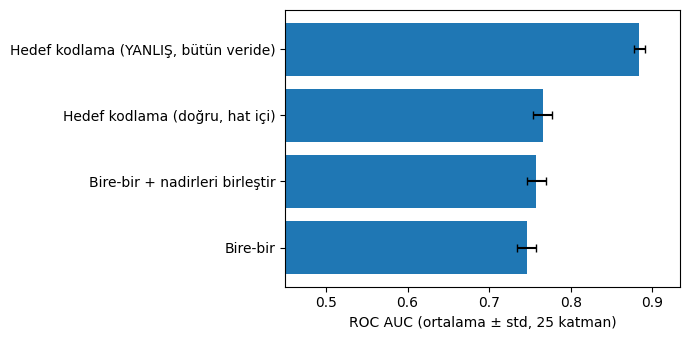

Şekil açıklaması: Aynı model, dört farklı soyadı kodlaması: yanlış (bütün veride) hedef kodlama skoru şişiriyor.


In [7]:
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LogisticRegression

vc = df[HIGH_CARD].value_counts()
print(f"{HIGH_CARD}: {df[HIGH_CARD].nunique()} farklı değer | tek kez geçen: {(vc == 1).sum()} | ortalama sıklık: {vc.mean():.1f}")

XS = df[FEATURES + [HIGH_CARD]]

def hat_kodlama(kodlayici):
    pre = ColumnTransformer([("num", StandardScaler(), NUM_COLS), ("bin", "passthrough", BIN_COLS),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                             ("sur", kodlayici, [HIGH_CARD])])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000))])

sonuc14 = {}
# (a) bire-bir (bütün soyadları)
sonuc14["Bire-bir"] = cross_validate(hat_kodlama(OneHotEncoder(handle_unknown="ignore")), XS, y, cv=cv, scoring=SCORING)
# (b) nadir kategorileri birleştiren bire-bir (min_frequency: bu sayının altı tek 'nadir' sütunda toplanır)
sonuc14["Bire-bir + nadirleri birleştir"] = cross_validate(hat_kodlama(OneHotEncoder(handle_unknown="ignore", min_frequency=10)), XS, y, cv=cv, scoring=SCORING)
# (c) kat dışı hedef kodlama (Pipeline içinde: eğitim katında iç çapraz uydurma, test katında eğitimden öğrenilen eşleme)
sonuc14["Hedef kodlama (doğru, hat içi)"] = cross_validate(hat_kodlama(TargetEncoder(target_type="binary", random_state=SEED)), XS, y, cv=cv, scoring=SCORING)

# (d) YANLIŞ (bilerek): hedef kodlama bütün veride, kendi etiketi de dahil, çapraz doğrulamadan ÖNCE
te_yanlis = df.groupby(HIGH_CARD)[TARGET].transform("mean")
XY = X.assign(Surname_te=te_yanlis.values)
pre_y = ColumnTransformer([("num", StandardScaler(), NUM_COLS + ["Surname_te"]), ("bin", "passthrough", BIN_COLS),
                           ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS)])
hat_y = Pipeline([("pre", pre_y), ("clf", LogisticRegression(max_iter=2000))])
sonuc14["Hedef kodlama (YANLIŞ, bütün veride)"] = cross_validate(hat_y, XY, y, cv=cv, scoring=SCORING)

display(sonuc_tablosu(sonuc14))
fig, ax = plt.subplots(figsize=(7, 3.5))
ad = list(sonuc14); m = [sonuc14[a]["test_roc_auc"].mean() for a in ad]; s = [sonuc14[a]["test_roc_auc"].std(ddof=1) for a in ad]
ax.barh(ad, m, xerr=s, capsize=3); ax.set_xlabel("ROC AUC (ortalama ± std, 25 katman)"); ax.set_xlim(0.45, max(m) + 0.05)
plt.tight_layout(); plt.show()
sekil_aciklamasi("Aynı model, dört farklı soyadı kodlaması: yanlış (bütün veride) hedef kodlama skoru şişiriyor.")

**Yorum** Bu çalışmada Surname değişkeni için dört farklı kodlama yöntemini karşılaştırdım. Veri kümesinde 2.932 farklı soyadı bulunduğunu ve bunlardan 1.558'inin yalnızca bir kez geçtiğini gördüm.

Bire-bir kodlama yönteminde ROC AUC değeri 0.746 ± 0.012, nadir kategorilerin birleştirildiği yöntemde 0.758 ± 0.012 ve Pipeline içerisinde yapılan doğru hedef kodlamada 0.766 ± 0.011 olarak hesaplanmıştır.

Hedef kodlamanın yanlış şekilde tüm veri üzerinde yapılması durumunda ise ROC AUC değeri 0.884 ± 0.007 seviyesine yükselmiştir. Bu yüksek sonucun nedeni veri sızıntısıdır. Özellikle yalnızca bir kez geçen soyadlarında hedef bilgisi doğrudan kodlamaya yansıyabildiği için model gerçekte olduğundan daha başarılı görünmektedir.

Nadir soyadlarının birleştirilmesi, kategori sayısını azaltarak bire-bir kodlamaya göre performansı bir miktar artırmıştır. Ancak doğru hedef kodlamanın daha yüksek sonuç vermesi, soyadı bilgisinin mutlaka kullanılması gerektiği anlamına gelmez.

Soyadı, müşterinin bankadan ayrılmasını doğrudan açıklayan bir özellik değildir. Ayrıca kimlik ve demografik bilgilerle dolaylı ilişkiler taşıyabileceğinden modelde kullanılması risk oluşturabilir.

Bu nedenle ana modelimde Surname değişkenini kullanmamayı tercih ettim. Diğer müşteri özellikleriyle zaten benzer bir performans elde edilebildiği için soyadı bilgisinin sağlayacağı sınırlı katkının, oluşturabileceği veri sızıntısı ve aşırı öğrenme risklerine değmeyeceğini düşünüyorum.

Sonuç olarak yüksek ROC AUC değerinin her zaman güvenilir bir model anlamına gelmediğini ve özellikle hedef bilgisine dayalı kodlama işlemlerinin çapraz doğrulama içerisinde yapılması gerektiğini öğrendim.

### 1.5 Sızıntı deneyi
Ön işlemenin bütün veride yapıldığı kurulum (yanlış) ile `Pipeline` içinde yapıldığı kurulum (doğru); hata çubuklarıyla.

,ROC AUC (ort ± std)
Hedef kodlama + seçim: YANLIŞ (bütün veride),0.898 ± 0.006
Hedef kodlama + seçim: DOĞRU (Pipeline içinde),0.775 ± 0.012
Yalnızca ölçekleme: yanlış (bütün veride),0.765 ± 0.011
Yalnızca ölçekleme: doğru (Pipeline içinde),0.765 ± 0.011


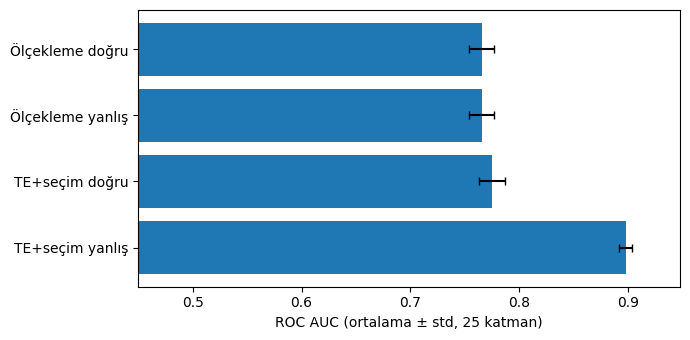

Şekil açıklaması: Hedefi kullanan adımlar (hedef kodlama, seçim) bütün veride yapılınca skor şişer; hedefi kullanmayan ölçekleme neredeyse fark yaratmaz.


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import TargetEncoder

XS = df[FEATURES + [HIGH_CARD]]
def on_isleme():
    return ColumnTransformer([("num", StandardScaler(), NUM_COLS), ("bin", "passthrough", BIN_COLS),
                              ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
                              ("te", TargetEncoder(target_type="binary", random_state=SEED), [HIGH_CARD])])
def model():
    return RandomForestClassifier(n_estimators=200, min_samples_leaf=3, n_jobs=-1, random_state=SEED)

# Not: bu hat sızıntıyı göstermek için bilerek sade ve kısıtlı (k=6); ana model değildir, skoru 2.1 ile kıyaslanmaz.
# DOĞRU: ön işleme + öznitelik seçimi Pipeline içinde (her katta yalnızca eğitim verisiyle uydurulur)
hat_dogru = Pipeline([("pre", on_isleme()), ("sec", SelectKBest(f_classif, k=6)), ("clf", model())])
skor_dogru = cross_val_score(hat_dogru, XS, y, cv=cv, scoring="roc_auc")

# YANLIŞ: ön işleme ve seçim bütün veride (y dahil) yapılıp sonra çapraz doğrulama
pre_all = on_isleme().fit(XS, y)            # fit ile transform ayrı: hedef kodlama eğitim satırlarına kendi etiketini de katar
Z = pre_all.transform(XS)
Z = SelectKBest(f_classif, k=6).fit(Z, y).transform(Z)
skor_yanlis = cross_val_score(model(), Z, y, cv=cv, scoring="roc_auc")

# Karşılaştırma için hafif sızıntı: yalnızca ölçekleme (hedefi kullanmaz) bütün veride
from sklearn.linear_model import LogisticRegression
Xs_all = pd.get_dummies(X, columns=CAT_COLS, dtype=float); Xs_all[NUM_COLS] = StandardScaler().fit_transform(Xs_all[NUM_COLS])
skor_olcek_yanlis = cross_val_score(LogisticRegression(max_iter=1000), Xs_all, y, cv=cv, scoring="roc_auc")
skor_olcek_dogru = cross_val_score(Pipeline([("pre", make_pre()), ("clf", LogisticRegression(max_iter=1000))]), X, y, cv=cv, scoring="roc_auc")

tab15 = pd.DataFrame({"ROC AUC (ort ± std)": {
    "Hedef kodlama + seçim: YANLIŞ (bütün veride)": ort_std(skor_yanlis),
    "Hedef kodlama + seçim: DOĞRU (Pipeline içinde)": ort_std(skor_dogru),
    "Yalnızca ölçekleme: yanlış (bütün veride)": ort_std(skor_olcek_yanlis),
    "Yalnızca ölçekleme: doğru (Pipeline içinde)": ort_std(skor_olcek_dogru)}})
display(tab15)
fig, ax = plt.subplots(figsize=(7, 3.5))
etiket = ["TE+seçim yanlış", "TE+seçim doğru", "Ölçekleme yanlış", "Ölçekleme doğru"]
diz = [skor_yanlis, skor_dogru, skor_olcek_yanlis, skor_olcek_dogru]
ax.barh(etiket, [d.mean() for d in diz], xerr=[d.std(ddof=1) for d in diz], capsize=3)
ax.set_xlabel("ROC AUC (ortalama ± std, 25 katman)"); ax.set_xlim(0.45, max(d.mean() for d in diz) + 0.05)
plt.tight_layout(); plt.show()
sekil_aciklamasi("Hedefi kullanan adımlar (hedef kodlama, seçim) bütün veride yapılınca skor şişer; hedefi kullanmayan ölçekleme neredeyse fark yaratmaz.")

In [9]:
# tab15 tablosunu tekrar ekrana yazdıralım
display(tab15)

,ROC AUC (ort ± std)
Hedef kodlama + seçim: YANLIŞ (bütün veride),0.898 ± 0.006
Hedef kodlama + seçim: DOĞRU (Pipeline içinde),0.775 ± 0.012
Yalnızca ölçekleme: yanlış (bütün veride),0.765 ± 0.011
Yalnızca ölçekleme: doğru (Pipeline içinde),0.765 ± 0.011


**Yorum** Bu çalışmada veri sızıntısının model performansını nasıl etkilediğini inceledim. Hedef kodlama ve özellik seçimi tüm veri üzerinde yanlış şekilde yapıldığında ROC AUC değeri 0.898 ± 0.006, aynı işlemler Pipeline içerisinde doğru şekilde yapıldığında ise 0.775 ± 0.012 olarak hesaplanmıştır.

Aradaki 0.123 puanlık fark, yanlış yöntemde test verilerinden eğitim sürecine bilgi sızması nedeniyle modelin olduğundan daha başarılı göründüğünü göstermektedir. Standart sapma değerlerinin küçük olması, sonuçların katmanlar arasında fazla değişmediğini ancak yanlış yöntemin güvenilir olduğunu göstermediğini ortaya koymaktadır.

Yalnızca ölçekleme yapılan deneylerde ise her iki yöntemde de ROC AUC değeri 0.765 ± 0.011 çıkmıştır. Bu durum, ölçeklemenin bu veri kümesinde belirgin bir performans farkı oluşturmadığını göstermektedir. Ancak ölçeklemenin tüm veri üzerinde yapılmasının her zaman güvenli olduğu anlamına gelmez.

Gerçek hayatta veri sızıntısı nedeniyle performansı olduğundan yüksek görünen bir modele güvenilmesi, bankanın müşteri elde tutma ekibinin yanlış müşterilere öncelik vermesine ve kaynaklarını verimsiz kullanmasına neden olabilir.

Sonuç olarak hedef bilgisini kullanan ön işleme adımlarının çapraz doğrulama içerisinde gerçekleştirilmesinin güvenilir model değerlendirmesi açısından önemli olduğunu öğrendim.

### 1.6 Baseline ve ilk model
`DummyClassifier` ve tek bir basit model, sızıntısız hat içinde.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

hat_dummy = Pipeline([("pre", make_pre()), ("clf", DummyClassifier(strategy="prior"))])
hat_lr = Pipeline([("pre", make_pre()), ("clf", LogisticRegression(max_iter=1000))])
sonuc16 = {"Baseline (DummyClassifier, prior)": cross_validate(hat_dummy, X, y, cv=cv, scoring=SCORING),
           "Lojistik regresyon": cross_validate(hat_lr, X, y, cv=cv, scoring=SCORING)}
display(sonuc_tablosu(sonuc16))
print("Çoğunluk sınıfı oranı (baseline doğruluğu):", round(1 - y.mean(), 4))

,roc_auc,avg_precision,f1,balanced_acc,accuracy
"Baseline (DummyClassifier, prior)",0.500 ± 0.000,0.204 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.796 ± 0.000
Lojistik regresyon,0.765 ± 0.011,0.469 ± 0.025,0.313 ± 0.021,0.588 ± 0.009,0.811 ± 0.006


Çoğunluk sınıfı oranı (baseline doğruluğu): 0.7963


**Yorum** Bu çalışmada Baseline (DummyClassifier) ve Lojistik Regresyon modellerinin performanslarını karşılaştırdım.

Baseline modelinin doğruluk oranı %79,6 olmasına rağmen ROC AUC değeri 0.500 ve F1 skoru 0.000 olarak hesaplanmıştır. Bunun nedeni veri kümesindeki müşterilerin büyük çoğunluğunun bankadan ayrılmamış olmasıdır. Baseline modeli çoğunluk sınıfını tahmin ettiği için yüksek doğruluk elde etse de ayrılan müşterileri tespit edememektedir.

Lojistik Regresyon modelinde ise doğruluk oranı %81,1, ROC AUC değeri 0.765 ± 0.011, F1 skoru 0.313 ve Average Precision değeri 0.469 olarak elde edilmiştir. Balanced Accuracy değerinin 0.500'den 0.588'e yükselmesi de modelin sınıfları ayırt etmede Baseline modelinden daha başarılı olduğunu göstermektedir.

İki modelin doğruluk oranları arasındaki fark küçük görünse de ROC AUC ve diğer ölçütlerdeki farklar daha belirgindir. Bu nedenle özellikle dengesiz veri kümelerinde yalnızca doğruluk oranına bakmanın yanıltıcı olabileceğini gördüm.

Sonuç olarak Lojistik Regresyon modelinin Baseline modelinden daha başarılı olduğunu düşünüyorum. Ancak F1 ve Balanced Accuracy değerlerinin hâlâ sınırlı olması nedeniyle bu performansın bankanın müşteri elde tutma kararları için tek başına yeterli olduğunu söyleyemem. Daha başarılı modellerle karşılaştırma yapılması gerektiğini düşünüyorum.

### 1.7 Weka ile bağımsız kontrol
ZeroR ve J48, 10 kat çapraz doğrulama; çıktıyı yapıştırın ve Python ile tutarlılığını yorumlayın.

In [11]:
# --- Weka ile bağımsız kontrol: veriyi ARFF olarak hazırla ---
def arff_yaz(frame, yol, relation, nominal_cols):
    with open(yol, "w", encoding="utf-8") as f:
        f.write(f"@relation {relation}\n\n")
        for c in frame.columns:
            if c in nominal_cols:
                f.write("@attribute %s {%s}\n" % (c, ",".join(sorted(frame[c].astype(str).unique()))))
            else:
                f.write(f"@attribute {c} numeric\n")
        f.write("\n@data\n")
        for satir in frame.astype(str).itertuples(index=False):
            f.write(",".join(satir) + "\n")

weka_df = df[FEATURES + [TARGET]].copy()  # Surname ve kimlik sütunları dışarıda
arff_yaz(weka_df, "churn_p1_weka.arff", "churn_p1", nominal_cols=BIN_COLS + CAT_COLS + [TARGET])
print("churn_p1_weka.arff yazıldı. İndirmek için: from google.colab import files; files.download('churn_p1_weka.arff')")

# Weka sürümü: 3.8.7
# Explorer → Preprocess → Open file (churn_p1_weka.arff) → Classify
# ZeroR: rules → ZeroR; Cross-validation Folds=10; hedef: Exited
# J48: trees → J48; C=0.25, M=2; Cross-validation Folds=10

weka_cikti = """Weka sürümü: 3.8.7

=== ZeroR: Weka classifier output ===
=== Run information ===

Scheme:       weka.classifiers.rules.ZeroR
Relation:     churn_p1
Instances:    10000
Attributes:   11
              CreditScore
              Age
              Tenure
              Balance
              NumOfProducts
              EstimatedSalary
              HasCrCard
              IsActiveMember
              Geography
              Gender
              Exited
Test mode:    10-fold cross-validation

=== Classifier model (full training set) ===

ZeroR predicts class value: 0

Time taken to build model: 0 seconds

=== Stratified cross-validation ===
=== Summary ===

Correctly Classified Instances        7963               79.63   %
Kappa statistic                          0
Mean absolute error                      0.3245
Root mean squared error                  0.4027
Relative absolute error                100      %
Root relative squared error            100      %
Total Number of Instances            10000

=== Detailed Accuracy By Class ===

                 TP Rate  FP Rate  Precision  Recall   F-Measure  MCC      ROC Area  PRC Area  Class
                 1,000    1,000    0,796      1,000    0,887      ?        0,499     0,796     0
                 0,000    0,000    ?          0,000    ?          ?        0,499     0,203     1
Weighted Avg.    0,796    0,796    ?          0,796    ?          ?        0,499     0,675

=== Confusion Matrix ===

    a    b   <-- classified as
 7963    0 |    a = 0
 2037    0 |    b = 1


=== J48: Weka classifier output ===
=== Run information ===

Scheme:       weka.classifiers.trees.J48 -C 0.25 -M 2
Relation:     churn_p1
Instances:    10000
Attributes:   11
              CreditScore
              Age
              Tenure
              Balance
              NumOfProducts
              EstimatedSalary
              HasCrCard
              IsActiveMember
              Geography
              Gender
              Exited
Test mode:    10-fold cross-validation

=== Classifier model (full training set) ===

J48 pruned tree
------------------

NumOfProducts <= 2
|   Age <= 42
|   |   NumOfProducts <= 1
|   |   |   Age <= 38: 0 (2654.0/356.0)
|   |   |   Age > 38
|   |   |   |   IsActiveMember = 0
|   |   |   |   |   Geography = France
|   |   |   |   |   |   Age <= 39
|   |   |   |   |   |   |   CreditScore <= 756: 0 (46.0/4.0)
|   |   |   |   |   |   |   CreditScore > 756
|   |   |   |   |   |   |   |   Balance <= 104498.79: 0 (4.0)
|   |   |   |   |   |   |   |   Balance > 104498.79: 1 (5.0/1.0)
|   |   |   |   |   |   Age > 39
|   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   Age <= 41
|   |   |   |   |   |   |   |   |   HasCrCard = 0: 1 (10.0/3.0)
|   |   |   |   |   |   |   |   |   HasCrCard = 1: 0 (43.0/15.0)
|   |   |   |   |   |   |   |   Age > 41
|   |   |   |   |   |   |   |   |   Balance <= 28082.95: 1 (4.0)
|   |   |   |   |   |   |   |   |   Balance > 28082.95: 0 (8.0)
|   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   Tenure <= 7
|   |   |   |   |   |   |   |   |   Tenure <= 3
|   |   |   |   |   |   |   |   |   |   Balance <= 123502.53: 0 (13.0)
|   |   |   |   |   |   |   |   |   |   Balance > 123502.53
|   |   |   |   |   |   |   |   |   |   |   Tenure <= 1: 1 (2.0)
|   |   |   |   |   |   |   |   |   |   |   Tenure > 1
|   |   |   |   |   |   |   |   |   |   |   |   Balance <= 146606.6: 1 (4.0/1.0)
|   |   |   |   |   |   |   |   |   |   |   |   Balance > 146606.6: 0 (4.0)
|   |   |   |   |   |   |   |   |   Tenure > 3
|   |   |   |   |   |   |   |   |   |   Balance <= 116060.08: 1 (16.0/5.0)
|   |   |   |   |   |   |   |   |   |   Balance > 116060.08
|   |   |   |   |   |   |   |   |   |   |   CreditScore <= 596: 1 (3.0/1.0)
|   |   |   |   |   |   |   |   |   |   |   CreditScore > 596: 0 (8.0)
|   |   |   |   |   |   |   |   Tenure > 7: 0 (20.0/2.0)
|   |   |   |   |   Geography = Germany
|   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   Balance <= 114888.74: 0 (22.0/2.0)
|   |   |   |   |   |   |   Balance > 114888.74
|   |   |   |   |   |   |   |   HasCrCard = 0: 0 (6.0/1.0)
|   |   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   |   Balance <= 152685.4: 1 (29.0/8.0)
|   |   |   |   |   |   |   |   |   Balance > 152685.4: 0 (4.0)
|   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   HasCrCard = 0
|   |   |   |   |   |   |   |   Tenure <= 3: 1 (6.0)
|   |   |   |   |   |   |   |   Tenure > 3
|   |   |   |   |   |   |   |   |   Age <= 40: 0 (3.0)
|   |   |   |   |   |   |   |   |   Age > 40: 1 (4.0/1.0)
|   |   |   |   |   |   |   HasCrCard = 1: 0 (41.0/18.0)
|   |   |   |   |   Geography = Spain
|   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   Balance <= 97408.03
|   |   |   |   |   |   |   |   Balance <= 12459.19
|   |   |   |   |   |   |   |   |   Age <= 39: 1 (3.0)
|   |   |   |   |   |   |   |   |   Age > 39
|   |   |   |   |   |   |   |   |   |   CreditScore <= 645: 0 (4.0)
|   |   |   |   |   |   |   |   |   |   CreditScore > 645
|   |   |   |   |   |   |   |   |   |   |   Age <= 40: 0 (2.0)
|   |   |   |   |   |   |   |   |   |   |   Age > 40: 1 (6.0/1.0)
|   |   |   |   |   |   |   |   Balance > 12459.19: 1 (7.0)
|   |   |   |   |   |   |   Balance > 97408.03
|   |   |   |   |   |   |   |   Balance <= 163630.76
|   |   |   |   |   |   |   |   |   Age <= 39
|   |   |   |   |   |   |   |   |   |   EstimatedSalary <= 129192.55: 0 (6.0)
|   |   |   |   |   |   |   |   |   |   EstimatedSalary > 129192.55: 1 (2.0)
|   |   |   |   |   |   |   |   |   Age > 39: 0 (11.0)
|   |   |   |   |   |   |   |   Balance > 163630.76: 1 (4.0)
|   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   Age <= 41
|   |   |   |   |   |   |   |   Balance <= 105563
|   |   |   |   |   |   |   |   |   Balance <= 104552.72
|   |   |   |   |   |   |   |   |   |   Tenure <= 5: 0 (12.0)
|   |   |   |   |   |   |   |   |   |   Tenure > 5
|   |   |   |   |   |   |   |   |   |   |   Balance <= 69143.91: 1 (4.0/1.0)
|   |   |   |   |   |   |   |   |   |   |   Balance > 69143.91: 0 (3.0)
|   |   |   |   |   |   |   |   |   Balance > 104552.72: 1 (2.0)
|   |   |   |   |   |   |   |   Balance > 105563: 0 (19.0)
|   |   |   |   |   |   |   Age > 41
|   |   |   |   |   |   |   |   HasCrCard = 0: 1 (2.0)
|   |   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   |   Tenure <= 3: 0 (2.0)
|   |   |   |   |   |   |   |   |   Tenure > 3
|   |   |   |   |   |   |   |   |   |   CreditScore <= 645: 0 (3.0/1.0)
|   |   |   |   |   |   |   |   |   |   CreditScore > 645: 1 (2.0)
|   |   |   |   IsActiveMember = 1
|   |   |   |   |   Geography = France
|   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   Tenure <= 1: 1 (7.0/1.0)
|   |   |   |   |   |   |   Tenure > 1: 0 (81.0/14.0)
|   |   |   |   |   |   Gender = Male: 0 (108.0/14.0)
|   |   |   |   |   Geography = Germany
|   |   |   |   |   |   HasCrCard = 0: 0 (30.0/9.0)
|   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   CreditScore <= 731
|   |   |   |   |   |   |   |   Age <= 40
|   |   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   |   CreditScore <= 680: 1 (10.0/1.0)
|   |   |   |   |   |   |   |   |   |   CreditScore > 680: 0 (2.0)
|   |   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   |   CreditScore <= 605: 0 (3.0)
|   |   |   |   |   |   |   |   |   |   CreditScore > 605: 1 (5.0/1.0)
|   |   |   |   |   |   |   |   Age > 40
|   |   |   |   |   |   |   |   |   Gender = Female: 0 (8.0/1.0)
|   |   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   |   EstimatedSalary <= 42143.61: 1 (4.0)
|   |   |   |   |   |   |   |   |   |   EstimatedSalary > 42143.61: 0 (10.0/2.0)
|   |   |   |   |   |   |   CreditScore > 731: 0 (10.0)
|   |   |   |   |   Geography = Spain: 0 (105.0/7.0)
|   |   NumOfProducts > 1: 0 (3510.0/151.0)
|   Age > 42
|   |   NumOfProducts <= 1
|   |   |   IsActiveMember = 0
|   |   |   |   Age <= 49
|   |   |   |   |   Geography = France
|   |   |   |   |   |   Balance <= 47134.75
|   |   |   |   |   |   |   Age <= 44: 0 (10.0/3.0)
|   |   |   |   |   |   |   Age > 44
|   |   |   |   |   |   |   |   HasCrCard = 0
|   |   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   |   CreditScore <= 659: 1 (6.0)
|   |   |   |   |   |   |   |   |   |   CreditScore > 659
|   |   |   |   |   |   |   |   |   |   |   EstimatedSalary <= 163060.43: 0 (2.0)
|   |   |   |   |   |   |   |   |   |   |   EstimatedSalary > 163060.43: 1 (2.0)
|   |   |   |   |   |   |   |   |   Gender = Male: 0 (5.0/1.0)
|   |   |   |   |   |   |   |   HasCrCard = 1: 1 (40.0/8.0)
|   |   |   |   |   |   Balance > 47134.75
|   |   |   |   |   |   |   HasCrCard = 0
|   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   Tenure <= 2: 1 (3.0)
|   |   |   |   |   |   |   |   |   Tenure > 2: 0 (15.0/3.0)
|   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   Tenure <= 4: 0 (10.0)
|   |   |   |   |   |   |   |   |   Tenure > 4
|   |   |   |   |   |   |   |   |   |   Tenure <= 6: 1 (2.0)
|   |   |   |   |   |   |   |   |   |   Tenure > 6: 0 (8.0/1.0)
|   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   Tenure <= 5
|   |   |   |   |   |   |   |   |   Age <= 47
|   |   |   |   |   |   |   |   |   |   Age <= 46
|   |   |   |   |   |   |   |   |   |   |   EstimatedSalary <= 73585.18
|   |   |   |   |   |   |   |   |   |   |   |   EstimatedSalary <= 44165.84: 1 (10.0/4.0)
|   |   |   |   |   |   |   |   |   |   |   |   EstimatedSalary > 44165.84: 0 (9.0)
|   |   |   |   |   |   |   |   |   |   |   EstimatedSalary > 73585.18: 1 (25.0/8.0)
|   |   |   |   |   |   |   |   |   |   Age > 46: 0 (3.0)
|   |   |   |   |   |   |   |   |   Age > 47
|   |   |   |   |   |   |   |   |   |   Age <= 48: 1 (6.0)
|   |   |   |   |   |   |   |   |   |   Age > 48
|   |   |   |   |   |   |   |   |   |   |   CreditScore <= 728: 1 (3.0)
|   |   |   |   |   |   |   |   |   |   |   CreditScore > 728: 0 (2.0)
|   |   |   |   |   |   |   |   Tenure > 5
|   |   |   |   |   |   |   |   |   Balance <= 172812.72
|   |   |   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   |   |   Age <= 46
|   |   |   |   |   |   |   |   |   |   |   |   Tenure <= 8
|   |   |   |   |   |   |   |   |   |   |   |   |   CreditScore <= 545: 1 (2.0)
|   |   |   |   |   |   |   |   |   |   |   |   |   CreditScore > 545: 0 (9.0/2.0)
|   |   |   |   |   |   |   |   |   |   |   |   Tenure > 8: 1 (4.0)
|   |   |   |   |   |   |   |   |   |   |   Age > 46: 0 (5.0)
|   |   |   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   |   |   EstimatedSalary <= 66485.26
|   |   |   |   |   |   |   |   |   |   |   |   Age <= 47
|   |   |   |   |   |   |   |   |   |   |   |   |   Tenure <= 7: 0 (5.0)
|   |   |   |   |   |   |   |   |   |   |   |   |   Tenure > 7
|   |   |   |   |   |   |   |   |   |   |   |   |   |   CreditScore <= 611: 1 (2.0)
|   |   |   |   |   |   |   |   |   |   |   |   |   |   CreditScore > 611: 0 (3.0/1.0)
|   |   |   |   |   |   |   |   |   |   |   |   Age > 47: 1 (2.0)
|   |   |   |   |   |   |   |   |   |   |   EstimatedSalary > 66485.26: 0 (19.0)
|   |   |   |   |   |   |   |   |   Balance > 172812.72: 1 (5.0)
|   |   |   |   |   Geography = Germany
|   |   |   |   |   |   Gender = Female: 1 (88.0/16.0)
|   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   Balance <= 97495.8: 0 (9.0/2.0)
|   |   |   |   |   |   |   Balance > 97495.8: 1 (64.0/14.0)
|   |   |   |   |   Geography = Spain
|   |   |   |   |   |   Balance <= 82794.18
|   |   |   |   |   |   |   CreditScore <= 622
|   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   CreditScore <= 591: 1 (4.0)
|   |   |   |   |   |   |   |   |   CreditScore > 591: 0 (4.0/1.0)
|   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   Tenure <= 2: 1 (2.0)
|   |   |   |   |   |   |   |   |   Tenure > 2
|   |   |   |   |   |   |   |   |   |   Balance <= 37702.79: 0 (8.0)
|   |   |   |   |   |   |   |   |   |   Balance > 37702.79: 1 (3.0/1.0)
|   |   |   |   |   |   |   CreditScore > 622: 1 (27.0/2.0)
|   |   |   |   |   |   Balance > 82794.18
|   |   |   |   |   |   |   HasCrCard = 0
|   |   |   |   |   |   |   |   CreditScore <= 544: 1 (3.0)
|   |   |   |   |   |   |   |   CreditScore > 544
|   |   |   |   |   |   |   |   |   EstimatedSalary <= 137254.55: 0 (8.0)
|   |   |   |   |   |   |   |   |   EstimatedSalary > 137254.55
|   |   |   |   |   |   |   |   |   |   Age <= 45: 0 (4.0/1.0)
|   |   |   |   |   |   |   |   |   |   Age > 45: 1 (3.0)
|   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   Balance <= 124662.54: 1 (10.0/3.0)
|   |   |   |   |   |   |   |   |   Balance > 124662.54: 0 (12.0/1.0)
|   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   Tenure <= 8
|   |   |   |   |   |   |   |   |   |   CreditScore <= 669: 0 (11.0)
|   |   |   |   |   |   |   |   |   |   CreditScore > 669
|   |   |   |   |   |   |   |   |   |   |   Balance <= 160858.13: 0 (7.0/2.0)
|   |   |   |   |   |   |   |   |   |   |   Balance > 160858.13: 1 (2.0)
|   |   |   |   |   |   |   |   |   Tenure > 8: 1 (2.0)
|   |   |   |   Age > 49
|   |   |   |   |   Age <= 64: 1 (300.0/33.0)
|   |   |   |   |   Age > 64
|   |   |   |   |   |   Age <= 73
|   |   |   |   |   |   |   Tenure <= 7: 1 (14.0/1.0)
|   |   |   |   |   |   |   Tenure > 7
|   |   |   |   |   |   |   |   CreditScore <= 537: 0 (3.0)
|   |   |   |   |   |   |   |   CreditScore > 537: 1 (4.0/1.0)
|   |   |   |   |   |   Age > 73: 0 (5.0/1.0)
|   |   |   IsActiveMember = 1
|   |   |   |   Age <= 65
|   |   |   |   |   Geography = France
|   |   |   |   |   |   Balance <= 32197.64
|   |   |   |   |   |   |   HasCrCard = 0
|   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   EstimatedSalary <= 108419.41
|   |   |   |   |   |   |   |   |   |   Age <= 46: 0 (4.0)
|   |   |   |   |   |   |   |   |   |   Age > 46: 1 (5.0/1.0)
|   |   |   |   |   |   |   |   |   EstimatedSalary > 108419.41: 1 (9.0)
|   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   EstimatedSalary <= 112520.07: 1 (5.0)
|   |   |   |   |   |   |   |   |   EstimatedSalary > 112520.07
|   |   |   |   |   |   |   |   |   |   Tenure <= 3: 1 (2.0)
|   |   |   |   |   |   |   |   |   |   Tenure > 3: 0 (4.0/1.0)
|   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   Age <= 61
|   |   |   |   |   |   |   |   |   Age <= 44: 0 (7.0/1.0)
|   |   |   |   |   |   |   |   |   Age > 44: 1 (51.0/22.0)
|   |   |   |   |   |   |   |   Age > 61: 0 (7.0/1.0)
|   |   |   |   |   |   Balance > 32197.64: 0 (233.0/57.0)
|   |   |   |   |   Geography = Germany
|   |   |   |   |   |   Balance <= 87347.7: 0 (12.0/1.0)
|   |   |   |   |   |   Balance > 87347.7
|   |   |   |   |   |   |   Balance <= 137104.47
|   |   |   |   |   |   |   |   Tenure <= 5: 1 (79.0/18.0)
|   |   |   |   |   |   |   |   Tenure > 5
|   |   |   |   |   |   |   |   |   EstimatedSalary <= 190937.09
|   |   |   |   |   |   |   |   |   |   CreditScore <= 534: 0 (4.0)
|   |   |   |   |   |   |   |   |   |   CreditScore > 534
|   |   |   |   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   |   |   |   Balance <= 113386.36: 1 (11.0)
|   |   |   |   |   |   |   |   |   |   |   |   Balance > 113386.36
|   |   |   |   |   |   |   |   |   |   |   |   |   Balance <= 126875.62: 0 (6.0/1.0)
|   |   |   |   |   |   |   |   |   |   |   |   |   Balance > 126875.62: 1 (6.0/1.0)
|   |   |   |   |   |   |   |   |   |   |   Gender = Male: 1 (29.0/12.0)
|   |   |   |   |   |   |   |   |   EstimatedSalary > 190937.09: 0 (5.0)
|   |   |   |   |   |   |   Balance > 137104.47
|   |   |   |   |   |   |   |   HasCrCard = 0
|   |   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   |   Balance <= 141675.23: 0 (2.0)
|   |   |   |   |   |   |   |   |   |   Balance > 141675.23: 1 (8.0/1.0)
|   |   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   |   Tenure <= 3: 0 (2.0)
|   |   |   |   |   |   |   |   |   |   Tenure > 3: 1 (4.0/1.0)
|   |   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   |   CreditScore <= 718: 0 (13.0/3.0)
|   |   |   |   |   |   |   |   |   |   CreditScore > 718: 1 (3.0)
|   |   |   |   |   |   |   |   |   Gender = Male: 0 (18.0/3.0)
|   |   |   |   |   Geography = Spain
|   |   |   |   |   |   EstimatedSalary <= 106061.47: 0 (114.0/19.0)
|   |   |   |   |   |   EstimatedSalary > 106061.47
|   |   |   |   |   |   |   CreditScore <= 585
|   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   EstimatedSalary <= 127875.1: 0 (4.0)
|   |   |   |   |   |   |   |   |   EstimatedSalary > 127875.1
|   |   |   |   |   |   |   |   |   |   HasCrCard = 0: 1 (3.0)
|   |   |   |   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   |   |   |   CreditScore <= 507: 1 (2.0)
|   |   |   |   |   |   |   |   |   |   |   CreditScore > 507: 0 (2.0)
|   |   |   |   |   |   |   |   Gender = Male: 1 (10.0/1.0)
|   |   |   |   |   |   |   CreditScore > 585
|   |   |   |   |   |   |   |   Gender = Female: 0 (27.0/8.0)
|   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   HasCrCard = 0
|   |   |   |   |   |   |   |   |   |   Tenure <= 3: 0 (6.0)
|   |   |   |   |   |   |   |   |   |   Tenure > 3
|   |   |   |   |   |   |   |   |   |   |   CreditScore <= 636: 0 (2.0)
|   |   |   |   |   |   |   |   |   |   |   CreditScore > 636: 1 (2.0)
|   |   |   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   |   |   EstimatedSalary <= 145490.85
|   |   |   |   |   |   |   |   |   |   |   CreditScore <= 694
|   |   |   |   |   |   |   |   |   |   |   |   EstimatedSalary <= 132210.49: 0 (4.0)
|   |   |   |   |   |   |   |   |   |   |   |   EstimatedSalary > 132210.49: 1 (2.0)
|   |   |   |   |   |   |   |   |   |   |   CreditScore > 694: 1 (4.0)
|   |   |   |   |   |   |   |   |   |   EstimatedSalary > 145490.85: 0 (10.0)
|   |   |   |   Age > 65: 0 (113.0/8.0)
|   |   NumOfProducts > 1
|   |   |   Balance <= 42157.08
|   |   |   |   IsActiveMember = 0
|   |   |   |   |   Age <= 51: 0 (165.0/17.0)
|   |   |   |   |   Age > 51
|   |   |   |   |   |   Geography = France
|   |   |   |   |   |   |   CreditScore <= 634
|   |   |   |   |   |   |   |   HasCrCard = 0: 1 (3.0)
|   |   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   |   CreditScore <= 583: 0 (4.0/1.0)
|   |   |   |   |   |   |   |   |   CreditScore > 583: 1 (3.0)
|   |   |   |   |   |   |   CreditScore > 634: 0 (4.0)
|   |   |   |   |   |   Geography = Germany: 1 (0.0)
|   |   |   |   |   |   Geography = Spain
|   |   |   |   |   |   |   Tenure <= 7
|   |   |   |   |   |   |   |   Gender = Female: 1 (3.0/1.0)
|   |   |   |   |   |   |   |   Gender = Male: 0 (3.0)
|   |   |   |   |   |   |   Tenure > 7: 1 (4.0)
|   |   |   |   IsActiveMember = 1: 0 (386.0/15.0)
|   |   |   Balance > 42157.08
|   |   |   |   IsActiveMember = 0
|   |   |   |   |   Age <= 53
|   |   |   |   |   |   Age <= 44: 0 (61.0/9.0)
|   |   |   |   |   |   Age > 44
|   |   |   |   |   |   |   Geography = France
|   |   |   |   |   |   |   |   Age <= 51
|   |   |   |   |   |   |   |   |   HasCrCard = 0: 0 (9.0/1.0)
|   |   |   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   |   |   CreditScore <= 616: 0 (5.0)
|   |   |   |   |   |   |   |   |   |   CreditScore > 616
|   |   |   |   |   |   |   |   |   |   |   CreditScore <= 750: 1 (6.0/1.0)
|   |   |   |   |   |   |   |   |   |   |   CreditScore > 750: 0 (4.0)
|   |   |   |   |   |   |   |   Age > 51: 1 (3.0)
|   |   |   |   |   |   |   Geography = Germany
|   |   |   |   |   |   |   |   HasCrCard = 0
|   |   |   |   |   |   |   |   |   Tenure <= 9
|   |   |   |   |   |   |   |   |   |   Tenure <= 2
|   |   |   |   |   |   |   |   |   |   |   Gender = Female: 1 (2.0)
|   |   |   |   |   |   |   |   |   |   |   Gender = Male: 0 (3.0/1.0)
|   |   |   |   |   |   |   |   |   |   Tenure > 2: 0 (12.0/1.0)
|   |   |   |   |   |   |   |   |   Tenure > 9: 1 (2.0)
|   |   |   |   |   |   |   |   HasCrCard = 1
|   |   |   |   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   |   |   |   Tenure <= 4: 0 (10.0/1.0)
|   |   |   |   |   |   |   |   |   |   Tenure > 4
|   |   |   |   |   |   |   |   |   |   |   Tenure <= 8: 1 (10.0/3.0)
|   |   |   |   |   |   |   |   |   |   |   Tenure > 8: 0 (2.0)
|   |   |   |   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   |   |   |   EstimatedSalary <= 46044.7: 0 (5.0)
|   |   |   |   |   |   |   |   |   |   EstimatedSalary > 46044.7
|   |   |   |   |   |   |   |   |   |   |   Tenure <= 6: 1 (9.0/1.0)
|   |   |   |   |   |   |   |   |   |   |   Tenure > 6
|   |   |   |   |   |   |   |   |   |   |   |   Balance <= 129646.91: 1 (3.0/1.0)
|   |   |   |   |   |   |   |   |   |   |   |   Balance > 129646.91: 0 (3.0)
|   |   |   |   |   |   |   Geography = Spain
|   |   |   |   |   |   |   |   Age <= 45: 0 (3.0)
|   |   |   |   |   |   |   |   Age > 45: 1 (15.0/4.0)
|   |   |   |   |   Age > 53: 1 (37.0/4.0)
|   |   |   |   IsActiveMember = 1: 0 (301.0/66.0)
NumOfProducts > 2
|   Balance <= 50194.59
|   |   NumOfProducts <= 3
|   |   |   Age <= 42
|   |   |   |   EstimatedSalary <= 167554.86
|   |   |   |   |   IsActiveMember = 0
|   |   |   |   |   |   Gender = Female
|   |   |   |   |   |   |   Geography = France: 1 (9.0/3.0)
|   |   |   |   |   |   |   Geography = Germany: 1 (0.0)
|   |   |   |   |   |   |   Geography = Spain
|   |   |   |   |   |   |   |   CreditScore <= 607: 1 (2.0)
|   |   |   |   |   |   |   |   CreditScore > 607: 0 (4.0)
|   |   |   |   |   |   Gender = Male
|   |   |   |   |   |   |   Geography = France: 0 (6.0/1.0)
|   |   |   |   |   |   |   Geography = Germany: 0 (0.0)
|   |   |   |   |   |   |   Geography = Spain
|   |   |   |   |   |   |   |   CreditScore <= 657: 1 (2.0)
|   |   |   |   |   |   |   |   CreditScore > 657: 0 (3.0/1.0)
|   |   |   |   |   IsActiveMember = 1: 0 (24.0/6.0)
|   |   |   |   EstimatedSalary > 167554.86: 1 (9.0)
|   |   |   Age > 42
|   |   |   |   Age <= 65: 1 (40.0/1.0)
|   |   |   |   Age > 65: 0 (4.0)
|   |   NumOfProducts > 3: 1 (15.0)
|   Balance > 50194.59: 1 (208.0/9.0)

Number of Leaves  : 	193

Size of the tree : 	377


Time taken to build model: 0.24 seconds

=== Stratified cross-validation ===
=== Summary ===

Correctly Classified Instances        8536               85.36   %
Kappa statistic                          0.4832
Mean absolute error                      0.2108
Root mean squared error                  0.3491
Relative absolute error                 64.9658 %
Root relative squared error             86.6914 %
Total Number of Instances            10000

=== Detailed Accuracy By Class ===

                 TP Rate  FP Rate  Precision  Recall   F-Measure  MCC      ROC Area  PRC Area  Class
                 0,952    0,530    0,875      0,952    0,912      0,498    0,779     0,892     0
                 0,470    0,048    0,713      0,470    0,567      0,498    0,779     0,552     1
Weighted Avg.    0,854    0,432    0,842      0,854    0,842      0,498    0,779     0,823

=== Confusion Matrix ===

    a    b   <-- classified as
 7578  385 |    a = 0
 1079  958 |    b = 1


"""


# Weka sonuçları (0-1 ölçeği):
weka_zeror_acc = 0.7963
weka_j48_acc   = 0.8536
weka_j48_auc   = 0.779


# Python ile karşılaştırma: aynı 10 katlı tabakalı çapraz doğrulama
cv10 = StratifiedKFold(10, shuffle=True, random_state=1)
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
py_zeror = cross_validate(DummyClassifier(strategy="most_frequent"), X, y, cv=cv10, scoring=["accuracy"])
# J48 ≈ C4.5; sklearn'de birebir eşdeğeri yok.
py_j48 = cross_validate(Pipeline([("pre", make_pre(scale=False)),
                                  ("clf", DecisionTreeClassifier(criterion="entropy", min_samples_leaf=2,
                                                                 ccp_alpha=0.0005, random_state=SEED))]),
                        X, y, cv=cv10, scoring=["accuracy", "roc_auc"])
print("Python ZeroR  doğruluk:", ort_std(py_zeror["test_accuracy"]))
print("Python ~J48   doğruluk:", ort_std(py_j48["test_accuracy"]), "| ROC AUC:", ort_std(py_j48["test_roc_auc"]))

if weka_zeror_acc is not None:
    print("ZeroR farkı (Weka − Python):", round(weka_zeror_acc - py_zeror["test_accuracy"].mean(), 4))
if weka_j48_acc is not None:
    print("J48 doğruluk farkı:", round(weka_j48_acc - py_j48["test_accuracy"].mean(), 4),
          "| AUC farkı:", None if weka_j48_auc is None else round(weka_j48_auc - py_j48["test_roc_auc"].mean(), 4))


churn_p1_weka.arff yazıldı. İndirmek için: from google.colab import files; files.download('churn_p1_weka.arff')
Python ZeroR  doğruluk: 0.796 ± 0.000
Python ~J48   doğruluk: 0.840 ± 0.006 | ROC AUC: 0.790 ± 0.017
ZeroR farkı (Weka − Python): 0.0
J48 doğruluk farkı: 0.0134 | AUC farkı: -0.0112


**Yorum** Weka ve Python sonuçlarını karşılaştırdığımda ZeroR modelinin Weka'da %79,63 doğruluk verdiğini gördüm. Bu sonuç Python'da elde edilen yaklaşık %79,6 doğruluk değeriyle uyumludur.

J48 modelinde Weka doğruluğu %85,36, ROC AUC değeri ise 0.779 olarak hesaplanmıştır. Python'daki yaklaşık karar ağacı modelinde doğruluk 0.840 ± 0.006 ve ROC AUC 0.790 ± 0.017 olarak bulunmuştur.

İki ortam arasındaki farkların, J48'in C4.5 algoritmasına dayanması, Python'daki karar ağacının farklı bölme ve budama yöntemleri kullanması ve çapraz doğrulama katlarının aynı olmamasından kaynaklanabileceğini düşünüyorum.

Sonuç olarak ZeroR sonuçlarının tutarlı olduğunu, J48 ile Python karar ağacı sonuçlarının ise birbirine yakın olmakla birlikte tamamen aynı olmadığını gördüm. Bu karşılaştırma model değerlendirme sürecinin genel tutarlılığını desteklemektedir.

# Bölüm 2 · Sınıflandırma ve dürüst model değerlendirme *(ağırlık 30)*
**Makale:** Dietterich (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7).

Dietterich (1998) çalışmasında, sınıflandırma algoritmalarını karşılaştırırken istatistiksel testlerin doğru seçilmesinin önemini açıklamaktadır. McNemar testi, aynı test verisi üzerindeki iki modelin doğru ve yanlış tahminlerini karşılaştırmak için kullanılır. 5×2 çapraz doğrulamalı t-testi ise veriyi beş kez iki parçaya ayırarak modellerin farklı eğitim ve test bölmelerindeki hata oranlarını karşılaştırır. Bu nedenle çalışmamın 2.4 bölümünde her iki testi kullanarak Gradyan Artırma ve Rastgele Orman modellerinin performans farkının istatistiksel olarak anlamlı olup olmadığını değerlendirdim.

### 2.1 Model karşılaştırması
Baseline, karar ağacı, k-NN, rastgele orman, gradyan artırma; tekrarlı katmanlı ÇD; ortalama ± std tablosu ve kutu grafiği; ölçüt seçiminin gerekçesi.

Baseline (prior) → ROC AUC 0.500 ± 0.000
Karar ağacı → ROC AUC 0.822 ± 0.010
k-NN (k=25) → ROC AUC 0.835 ± 0.009
Rastgele orman → ROC AUC 0.859 ± 0.008
Gradyan artırma → ROC AUC 0.859 ± 0.009


,roc_auc,avg_precision,f1,balanced_acc,accuracy
Baseline (prior),0.500 ± 0.000,0.204 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.796 ± 0.000
Karar ağacı,0.822 ± 0.010,0.628 ± 0.023,0.567 ± 0.021,0.714 ± 0.013,0.849 ± 0.006
k-NN (k=25),0.835 ± 0.009,0.620 ± 0.016,0.482 ± 0.017,0.663 ± 0.008,0.844 ± 0.004
Rastgele orman,0.859 ± 0.008,0.688 ± 0.020,0.574 ± 0.024,0.711 ± 0.013,0.863 ± 0.006
Gradyan artırma,0.859 ± 0.009,0.698 ± 0.017,0.594 ± 0.021,0.726 ± 0.013,0.861 ± 0.006


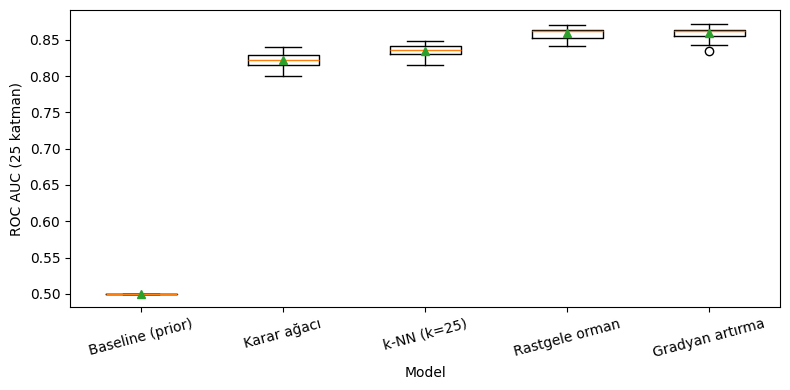

Şekil açıklaması: Her kutu 25 katmanın ROC AUC dağılımı (üçgen: ortalama); baseline 0,5 çizgisindedir.


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier

modeller = {
    "Baseline (prior)": DummyClassifier(strategy="prior"),
    "Karar ağacı": DecisionTreeClassifier(min_samples_leaf=20, random_state=SEED),
    "k-NN (k=25)": KNeighborsClassifier(n_neighbors=25),
    "Rastgele orman": RandomForestClassifier(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=SEED),
    "Gradyan artırma": HistGradientBoostingClassifier(random_state=SEED),
}
sonuc21 = {}
for ad, m in modeller.items():
    hat_m = Pipeline([("pre", make_pre()), ("clf", m)])
    sonuc21[ad] = cross_validate(hat_m, X, y, cv=cv, scoring=SCORING)
    print(ad, "→ ROC AUC", ort_std(sonuc21[ad]["test_roc_auc"]))

tab21 = sonuc_tablosu(sonuc21)
display(tab21)

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([sonuc21[a]["test_roc_auc"] for a in modeller], showmeans=True); ax.set_xticklabels(list(modeller))
ax.set_ylabel("ROC AUC (25 katman)"); ax.set_xlabel("Model"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()
sekil_aciklamasi("Her kutu 25 katmanın ROC AUC dağılımı (üçgen: ortalama); baseline 0,5 çizgisindedir.")

# Not: 'accuracy' sütunu bilerek tablodadır; baseline'ın doğruluğu çoğunluk oranına eşittir → sınıflar dengesizken yanıltıcı.

In [13]:
# tab21 tablosunu ekrana yazdırarak modelleri karşılaştıralım
display(tab21)

,roc_auc,avg_precision,f1,balanced_acc,accuracy
Baseline (prior),0.500 ± 0.000,0.204 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.796 ± 0.000
Karar ağacı,0.822 ± 0.010,0.628 ± 0.023,0.567 ± 0.021,0.714 ± 0.013,0.849 ± 0.006
k-NN (k=25),0.835 ± 0.009,0.620 ± 0.016,0.482 ± 0.017,0.663 ± 0.008,0.844 ± 0.004
Rastgele orman,0.859 ± 0.008,0.688 ± 0.020,0.574 ± 0.024,0.711 ± 0.013,0.863 ± 0.006
Gradyan artırma,0.859 ± 0.009,0.698 ± 0.017,0.594 ± 0.021,0.726 ± 0.013,0.861 ± 0.006


**Yorum** Bu çalışmada Baseline, Karar Ağacı, k-NN, Rastgele Orman ve Gradyan Artırma modellerinin performanslarını karşılaştırdım. Modelleri 5 katlı ve 5 tekrarlı çapraz doğrulama yöntemiyle toplam 25 değerlendirme üzerinden inceledim.

Baseline modelinin ROC AUC değeri 0.500 iken Karar Ağacı 0.822, k-NN 0.835, Rastgele Orman 0.859 ve Gradyan Artırma 0.859 olarak hesaplandı.

En yüksek ROC AUC değerlerini Rastgele Orman ve Gradyan Artırma modelleri elde etti. Ancak Gradyan Artırma modelinin F1 skoru 0.594, Average Precision değeri 0.698 ve Balanced Accuracy değeri 0.726 ile diğer modellerden daha yüksek çıktı. Rastgele Orman ise 0.863 ile en yüksek doğruluk oranına ulaştı.

Baseline modelinin doğruluk oranı %79,6 olmasına rağmen F1 skorunun sıfır olması, dengesiz veri kümelerinde yalnızca doğruluk oranına bakmanın yanıltıcı olabileceğini göstermektedir.

Kutu grafiğinde Rastgele Orman ve Gradyan Artırma modellerinin ROC AUC dağılımlarının birbirine yakın ve standart sapmalarının düşük olduğunu gördüm. Bu durum modellerin farklı veri bölmelerinde benzer performans gösterdiğini düşündürmektedir. Ancak aralarındaki küçük farkların istatistiksel olarak anlamlı olduğu henüz söylenemez.

Ana değerlendirme ölçütü olarak ROC AUC'yi tercih ettim. Çünkü müşteri ayrılma riski yüksek olan kişileri düşük riskli kişilerden ayırt etmek istiyorum. F1 ve Average Precision değerlerini de dikkate aldığımda Gradyan Artırma modelini tercih etmeyi uygun buldum. Ancak kesin model kararı için sonraki istatistiksel karşılaştırmaları da değerlendirmek gerektiğini düşünüyorum.

### 2.2 Karar ağacının yorumu
`export_text` ile kök ve ilk iki düzeyin alan bilgisiyle yorumu.

In [14]:
from sklearn.tree import export_text

# Yalnızca YORUM için bütün veride uydurulan sığ ağaç (başarım raporu değildir; başarım 2.1'deki çapraz doğrulamadandır)
hat_agac = Pipeline([("pre", make_pre(scale=False)),
                     ("clf", DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=SEED))]).fit(X, y)
adlar = [a.split("__", 1)[1] for a in hat_agac.named_steps["pre"].get_feature_names_out()]
print(export_text(hat_agac.named_steps["clf"], feature_names=adlar, show_weights=True))

|--- Age <= 42.50
|   |--- NumOfProducts <= 2.50
|   |   |--- NumOfProducts <= 1.50
|   |   |   |--- weights: [2874.00, 562.00] class: 0
|   |   |--- NumOfProducts >  1.50
|   |   |   |--- weights: [3359.00, 151.00] class: 0
|   |--- NumOfProducts >  2.50
|   |   |--- Balance <= 55948.91
|   |   |   |--- weights: [32.00, 31.00] class: 0
|   |   |--- Balance >  55948.91
|   |   |   |--- weights: [9.00, 88.00] class: 1
|--- Age >  42.50
|   |--- IsActiveMember <= 0.50
|   |   |--- Age <= 50.50
|   |   |   |--- weights: [461.00, 417.00] class: 0
|   |   |--- Age >  50.50
|   |   |   |--- weights: [64.00, 361.00] class: 1
|   |--- IsActiveMember >  0.50
|   |   |--- NumOfProducts <= 2.50
|   |   |   |--- weights: [1159.00, 362.00] class: 0
|   |   |--- NumOfProducts >  2.50
|   |   |   |--- weights: [5.00, 65.00] class: 1



**Yorum** Bu çalışmada karar ağacı modelinin müşteri ayrılma riskini hangi değişkenlere göre değerlendirdiğini inceledim.

Karar ağacının ilk olarak yaş (Age) değişkenine göre ayrıldığını gördüm. 42,5 yaşın altındaki müşterilerde ürün sayısı (NumOfProducts) önemli bir belirleyici olarak öne çıkmaktadır. Özellikle 3 veya daha fazla ürün kullanan ve hesap bakiyesi 55.948,91'in üzerinde olan müşterilerde model ayrılma (sınıf 1) tahmini yapmaktadır.

42,5 yaşın üzerindeki müşterilerde ise aktif üyelik durumu (IsActiveMember) önem kazanmaktadır. Aktif olmayan ve 50,5 yaşın üzerinde bulunan müşterilerde ayrılma tahmini öne çıkmaktadır. Aktif müşterilerde ise 3 veya daha fazla ürün kullanılması durumunda model yine ayrılma tahmini yapmaktadır.

Ağaçta bulunan weights değerleri, her karar grubundaki sınıf 0 ve sınıf 1 gözlemlerinin sayılarını göstermektedir. Örneğin 42,5 yaşın üzerinde, aktif olmayan ve 50,5 yaşından büyük müşterilerin bulunduğu grupta 64 müşteri kalırken 361 müşteri ayrılmıştır.

Sonuç olarak yaş, ürün sayısı, hesap bakiyesi ve aktif üyelik durumunun modelin kararlarında önemli rol oynadığını gördüm. Karar ağacı, tahminlerin hangi koşullara göre yapıldığını anlamamı kolaylaştırmaktadır. Ancak bu sonuçlar değişkenlerin müşteri ayrılmasına doğrudan neden olduğunu kanıtlamaz. Ayrıca ağaç tüm veri üzerinde eğitildiği için gerçek tahmin başarısını değerlendirmede çapraz doğrulama sonuçları esas alınmalıdır.

### 2.3 Optimist yanlılık
`GridSearchCV.best_score_` ile iç içe ÇD skorunun karşılaştırması.

GridSearchCV.best_score_ (iyimser): 0.8666 | en iyi parametreler: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__min_samples_leaf': 20}
İç içe ÇD (dürüst): 0.866 ± 0.007
Fark (best_score_ − iç içe ortalama): 0.0011
Karşılaştırma için 2.1'deki varsayılan parametreli skor: 0.859 ± 0.009


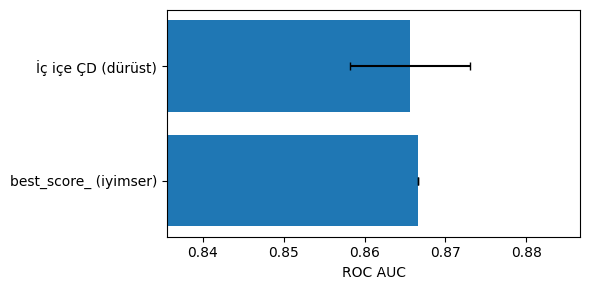

Şekil açıklaması: Aynı model ve ızgara: ayarın yapıldığı katmanlarda raporlanan skor (üst) ile iç içe ÇD skoru (alt).


In [15]:
from sklearn.model_selection import GridSearchCV

hat_gs = Pipeline([("pre", make_pre()), ("clf", HistGradientBoostingClassifier(random_state=SEED))])
izgara = {"clf__max_depth": [3, 6], "clf__learning_rate": [0.03, 0.1], "clf__min_samples_leaf": [20, 100]}   # 8 kombinasyon

# (a) İyimser: aynı çapraz doğrulama hem ayar hem raporlama için
gs = GridSearchCV(hat_gs, izgara, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc", n_jobs=-1).fit(X, y)
print("GridSearchCV.best_score_ (iyimser):", round(gs.best_score_, 4), "| en iyi parametreler:", gs.best_params_)

# (b) Dürüst: iç içe çapraz doğrulama (dış: 5×2 tabakalı; iç: 3 katlı ayar)
dis = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)
ic = StratifiedKFold(3, shuffle=True, random_state=SEED)
nested = cross_val_score(GridSearchCV(hat_gs, izgara, cv=ic, scoring="roc_auc", n_jobs=-1), X, y, cv=dis, scoring="roc_auc")
print("İç içe ÇD (dürüst):", ort_std(nested))
print("Fark (best_score_ − iç içe ortalama):", round(gs.best_score_ - nested.mean(), 4))
print("Karşılaştırma için 2.1'deki varsayılan parametreli skor:", ort_std(sonuc21["Gradyan artırma"]["test_roc_auc"]))

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(["best_score_ (iyimser)", "İç içe ÇD (dürüst)"], [gs.best_score_, nested.mean()], xerr=[0, nested.std(ddof=1)], capsize=3)
ax.set_xlabel("ROC AUC"); ax.set_xlim(min(gs.best_score_, nested.mean()) - 0.03, max(gs.best_score_, nested.mean()) + 0.02)
plt.tight_layout(); plt.show()
sekil_aciklamasi("Aynı model ve ızgara: ayarın yapıldığı katmanlarda raporlanan skor (üst) ile iç içe ÇD skoru (alt).")

**Yorum** Bu çalışmada Gradyan Artırma modelinin performansını geliştirmek amacıyla GridSearchCV yöntemiyle hiperparametre optimizasyonu yaptım.

Yapılan denemeler sonucunda en iyi parametreler learning_rate=0.1, max_depth=3 ve min_samples_leaf=20 olarak belirlendi. Bu parametrelerle GridSearchCV ROC AUC değeri 0.8666 olarak hesaplandı.

Ancak aynı çapraz doğrulama sonuçları hem parametre seçimi hem de performans değerlendirmesi için kullanıldığında sonuçların iyimser olabileceğini gördüm. Daha güvenilir bir değerlendirme yapmak için iç içe çapraz doğrulama yöntemini kullandım. Bu yöntemde ROC AUC değeri 0.866 ± 0.007 olarak elde edildi.

İki yöntem arasındaki farkın yalnızca 0.0011 olması, bu deneyde parametre seçiminin oluşturduğu iyimserlik etkisinin oldukça düşük olduğunu göstermektedir.

Önceki çalışmada varsayılan parametrelerle elde edilen ROC AUC değeri 0.859 ± 0.009 idi. Parametre optimizasyonuyla performansta küçük bir artış sağlanmıştır. Ancak bu artışın istatistiksel olarak anlamlı olduğu henüz kanıtlanmamıştır.

Sonuç olarak hiperparametre optimizasyonunun model performansını iyileştirebildiğini, ancak güvenilir değerlendirme için parametre seçimi ile performans ölçümünün birbirinden ayrılması gerektiğini öğrendim. Bu nedenle iç içe çapraz doğrulama sonuçlarını daha güvenilir buluyorum.

### 2.4 İstatistiksel test
En iyi iki modelin farkı: McNemar ya da 5×2 ÇD t-testi. "Fark anlamlı çıkmadı" tam puanlık bir sonuçtur.

In [16]:
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats
from sklearn.model_selection import train_test_split

# En iyi iki model (2.1'de ROC AUC ortalamasına göre; baseline hariç)
sirali = sorted([k for k in modeller if not k.startswith("Baseline")], key=lambda k: -np.mean(sonuc21[k]["test_roc_auc"]))
A, B = sirali[:2]
print("Karşılaştırılan modeller:", A, "vs", B)
hat_A = Pipeline([("pre", make_pre()), ("clf", modeller[A])])
hat_B = Pipeline([("pre", make_pre()), ("clf", modeller[B])])

# (1) McNemar (Dietterich 1998): tek eğitim/test bölmesi, hata (yanlış sınıflama) üzerinden. Tek bölmeye güvenilmesin diye 5 farklı bölmede.
sat = []
for i in range(5):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=1/3, stratify=y, random_state=SEED + i)
    pa = clone(hat_A).fit(Xtr, ytr).predict(Xte); pb = clone(hat_B).fit(Xtr, ytr).predict(Xte)
    ka, kb = (pa == yte), (pb == yte)
    tablo = [[np.sum(ka & kb), np.sum(ka & ~kb)], [np.sum(~ka & kb), np.sum(~ka & ~kb)]]
    n01, n10 = tablo[0][1], tablo[1][0]
    s = mcnemar(tablo, exact=(n01 + n10) < 25, correction=True)
    sat.append({"bolme": i, f"yalnız {A} doğru": n01, f"yalnız {B} doğru": n10, "istatistik": s.statistic, "p_degeri": s.pvalue,
                f"{A} doğruluk": ka.mean(), f"{B} doğruluk": kb.mean()})
display(pd.DataFrame(sat).round(4))

# (2) 5×2 çapraz doğrulamalı t-testi (Dietterich 1998)
def cv5x2_t(model_a, model_b, X, y, seed=SEED):
    d = np.zeros((5, 2))
    for i in range(5):
        for j, (tr, te) in enumerate(StratifiedKFold(2, shuffle=True, random_state=seed + i).split(X, y)):
            ea = 1 - (clone(model_a).fit(X.iloc[tr], y[tr]).predict(X.iloc[te]) == y[te]).mean()
            eb = 1 - (clone(model_b).fit(X.iloc[tr], y[tr]).predict(X.iloc[te]) == y[te]).mean()
            d[i, j] = ea - eb
    ort = d.mean(1); s2 = (d[:, 0] - ort) ** 2 + (d[:, 1] - ort) ** 2
    t = d[0, 0] / np.sqrt(s2.mean()); p = 2 * stats.t.sf(abs(t), df=5)
    return t, p, d.mean()
t, p, fark = cv5x2_t(hat_A, hat_B, X, y)
print(f"5×2cv t-testi: t = {t:.3f}, p = {p:.4f}, ortalama hata farkı ({A} − {B}) = {fark:.4f}")
print("Yorum notu: iki test de varsayılan eşikte HATA oranını karşılaştırır; model seçimi ise ROC AUC ile yapıldı. Bu uyuşmazlığı yorumda tartışın.")

Karşılaştırılan modeller: Gradyan artırma vs Rastgele orman


,bolme,yalnız Gradyan artırma doğru,yalnız Rastgele orman doğru,istatistik,p_degeri,Gradyan artırma doğruluk,Rastgele orman doğruluk
0,0,53,61,0.4298,0.5121,0.8608,0.8632
1,1,60,73,1.0827,0.2981,0.8554,0.8593
2,2,55,71,1.7857,0.1814,0.8521,0.8569
3,3,58,59,0.0000,1.0000,0.8578,0.8581
4,4,59,57,0.0086,0.9260,0.8572,0.8566


5×2cv t-testi: t = -0.211, p = 0.8416, ortalama hata farkı (Gradyan artırma − Rastgele orman) = 0.0018
Yorum notu: iki test de varsayılan eşikte HATA oranını karşılaştırır; model seçimi ise ROC AUC ile yapıldı. Bu uyuşmazlığı yorumda tartışın.


**Yorum** Bu çalışmada en yüksek ROC AUC değerlerine sahip olan Gradyan Artırma ve Rastgele Orman modellerini istatistiksel olarak karşılaştırdım.

McNemar testini 5 farklı veri bölmesinde uyguladım. Elde edilen p-değerleri 0.1814 ile 1.0000 arasında değişmektedir. Tüm p-değerlerinin 0.05'ten büyük olması, iki modelin hata oranları arasında istatistiksel olarak anlamlı bir fark tespit edilemediğini göstermektedir.

5×2 çapraz doğrulamalı t-testinde ise t=-0.211 ve p=0.8416 sonuçları elde edildi. Ortalama hata farkı 0.0018 olarak hesaplandı. Bu sonuç da iki modelin hata oranları arasında anlamlı bir fark bulunmadığını desteklemektedir. Ancak anlamlı fark bulunmaması, modellerin tamamen eşit olduğunu kanıtlamaz.

Burada dikkatimi çeken nokta, istatistiksel testlerin yanlış sınıflandırma oranlarını karşılaştırması, model seçiminde ise ROC AUC ölçütünün kullanılmasıdır. Bu nedenle testlerde anlamlı fark bulunmaması, ROC AUC açısından da fark olmadığı anlamına gelmez.

Önceki analizde her iki modelin ROC AUC değeri yaklaşık 0.859 olarak bulunmuştur. Ancak Gradyan Artırma modelinin F1 skoru (0.594) ve Average Precision değeri (0.698), Rastgele Orman modelinden biraz daha yüksektir.

Sonuç olarak iki modelin performanslarının birbirine yakın olduğunu gördüm. İstatistiksel testlerde anlamlı fark bulunmamasına rağmen, özellikle ayrılma riski taşıyan müşterilerin belirlenmesinde yardımcı ölçütlerde daha iyi sonuç verdiği için Gradyan Artırma modelini tercih ettim. Bu tercihin kesin bir üstünlük kanıtı olmadığını ve gerçek kullanım öncesinde bağımsız verilerle değerlendirilmesi gerektiğini düşünüyorum.

### 2.5 Proje 2'ye aktarılacak model ve çıktılar
En iyi modeli ve protokolü gerekçesiyle seçin; temizlenmiş veriyi ve hattı kaydedin.

In [17]:
import joblib, json

SECILEN = "Gradyan artırma"      # [KARAR] 2.1–2.4 sonuçlarına göre ekip değiştirsin; gerekçeyi Yorum ve Varsayım defterine yazın
hat = Pipeline([("pre", make_pre()), ("clf", clone(modeller[SECILEN]))])      # uydurulmamış hat (P2'de katman içinde yeniden uydurulur)

df_temiz = df.drop(columns=["RowNumber"])       # RowNumber saf sıra numarası; CustomerId yalnızca satır eşleştirmek için tutulur, ÖZNİTELİK DEĞİLDİR
df_temiz.to_csv("p1_temiz_veri.csv", index=False)
joblib.dump(hat, "p1_hat.joblib")
joblib.dump(clone(hat).fit(X, y), "p1_model_tum_veri.joblib")    # yalnızca açıklama/inceleme için; başarım raporunda KULLANILMAZ

# Proje 2 için katman dışı (out-of-fold) tahminler: alt grup / küme / aykırı gözlem analizlerinde dürüst hata hesabı için
oof = np.zeros(len(df))
for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y):
    oof[te] = clone(hat).fit(X.iloc[tr], y[tr]).predict_proba(X.iloc[te])[:, 1]
pd.DataFrame({"CustomerId": df["CustomerId"], "y_true": y, "oof_proba": oof}).to_csv("p1_oof.csv", index=False)

meta = {"seed": SEED, "hedef": TARGET, "ozellikler": FEATURES, "sayisal": NUM_COLS, "ikili": BIN_COLS, "kategorik": CAT_COLS,
        "dislanan": ID_COLS + [HIGH_CARD], "secilen_model": SECILEN,
        "cv_protokolu": "RepeatedStratifiedKFold(5 kat, 5 tekrar)", "ana_olcut": "roc_auc",
        "cv_roc_auc_ort": float(np.mean(sonuc21[SECILEN]["test_roc_auc"])), "cv_roc_auc_std": float(np.std(sonuc21[SECILEN]["test_roc_auc"], ddof=1)),
        "sklearn_surumu": sklearn.__version__}
json.dump(meta, open("p1_meta.json", "w"), ensure_ascii=False, indent=2)
print("Kaydedildi: p1_temiz_veri.csv, p1_hat.joblib, p1_model_tum_veri.joblib, p1_oof.csv, p1_meta.json")
print("Colab diski geçicidir: bu dosyaları indirip GitHub'daki proje1/ klasörüne (veri dosyası hariç) koyun.")
print(json.dumps(meta, ensure_ascii=False, indent=2))

Kaydedildi: p1_temiz_veri.csv, p1_hat.joblib, p1_model_tum_veri.joblib, p1_oof.csv, p1_meta.json
Colab diski geçicidir: bu dosyaları indirip GitHub'daki proje1/ klasörüne (veri dosyası hariç) koyun.
{
  "seed": 42,
  "hedef": "Exited",
  "ozellikler": [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "HasCrCard",
    "IsActiveMember",
    "Geography",
    "Gender"
  ],
  "sayisal": [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
  ],
  "ikili": [
    "HasCrCard",
    "IsActiveMember"
  ],
  "kategorik": [
    "Geography",
    "Gender"
  ],
  "dislanan": [
    "RowNumber",
    "CustomerId",
    "Surname"
  ],
  "secilen_model": "Gradyan artırma",
  "cv_protokolu": "RepeatedStratifiedKFold(5 kat, 5 tekrar)",
  "ana_olcut": "roc_auc",
  "cv_roc_auc_ort": 0.8593316162707018,
  "cv_roc_auc_std": 0.008677503913869976,
  "sklearn_surumu": "1.6.1"
}


**Yorum** Bu çalışmada önceki analizlerin sonuçlarını değerlendirerek Gradyan Artırma modelini seçtim. Modelin 5 katlı ve 5 tekrarlı çapraz doğrulama sonucunda ROC AUC ortalaması 0.8593, standart sapması ise 0.0087 olarak hesaplanmıştır.

Gradyan Artırma ve Rastgele Orman modellerinin ROC AUC değerleri birbirine oldukça yakın çıkmıştır. Ancak Gradyan Artırma modelinin F1, Average Precision ve Balanced Accuracy değerleri daha yüksek olduğu için bu modeli tercih ettim. İstatistiksel testlerde iki model arasında anlamlı bir fark bulunmadığını da dikkate aldım.

Modelin eğitiminde veri sızıntısını önlemek amacıyla RowNumber, CustomerId ve Surname değişkenlerini tahmin özelliklerinden çıkardım. Ön işleme işlemlerini Pipeline içerisinde gerçekleştirdim.

Proje 2'de kullanılmak üzere temiz veri dosyasını, eğitilmemiş model Pipeline'ını, tüm veri üzerinde eğitilmiş modeli, katman dışı tahminleri ve model bilgilerini kaydettim.

Tüm veri üzerinde eğitilen modelin başarı değerlendirmesi amacıyla kullanılmaması gerektiğini, bunun yerine çapraz doğrulama sonuçlarının esas alınması gerektiğini öğrendim. Bu nedenle Proje 2'de daha güvenilir değerlendirmeler yapabilmek için katman dışı tahminleri kullanacağım.

# Bölüm 3 · Veri küpü ve birliktelik analizi *(ağırlık 15)*
**Makale:** Wu, Chen ve Han (2010). Re-examination of interestingness measures in pattern mining. *Data Mining and Knowledge Discovery*, 21(3).

Wu, Chen ve Han (2010) çalışmasında birliktelik kurallarının değerlendirilmesinde farklı ilginçlik ölçütlerinin önemini incelemiştir. Null-invariance özelliği, incelenen öğelerin hiçbirini içermeyen işlemler eklendiğinde ölçütün değişmemesini ifade eder. Yalnızca lift veya güven değerine bakmak yanıltıcı olabileceğinden Kulczynski ölçütüyle iki yönlü koşullu olasılıkları değerlendirmek, dengesizlik oranıyla da öğelerin görülme sıklıkları arasındaki farkı incelemek gerekir. Bu ölçütlerin birlikte kullanılması, birliktelik kurallarının daha sağlıklı yorumlanmasını sağlar.

### 3.1 Kısa veri küpü
Bir olgu ve en az üç boyut; roll-up ve drill-down; toplamdaki bir eğilimin alt gruplarda değişip değişmediği (Simpson paradoksu).

Küp hücre sayısı: 30


musteri  ayrilma
Geography Gender YasGrubu                  
France    Female 18-29         398    0.058
                 30-39         977    0.110
                 40-49         580    0.312
                 50-59         174    0.615
                 60+           132    0.318
          Male   18-29         468    0.047
                 30-39        1273    0.060
                 40-49         662    0.205
                 50-59         208    0.433
                 60+           142    0.183
Germany   Female 18-29         171    0.170
                 30-39         455    0.240


[Roll-up] Geography × YasGrubu


YasGrubu,18-29,30-39,40-49,50-59,60+
Geography,,,,,
France,0.052,0.081,0.255,0.516,0.248
Germany,0.126,0.189,0.451,0.700,0.415
Spain,0.079,0.093,0.244,0.457,0.217


[Roll-up] Yalnız YasGrubu


,size,mean
YasGrubu,,
18-29,1641,0.076
30-39,4346,0.109
40-49,2618,0.308
50-59,869,0.560
60+,526,0.279


[Roll-up] Toplam ayrılma oranı: 0.204

[Drill-down] Germany: cinsiyet ve yaş grubuna göre


size   mean
Gender YasGrubu             
Female 18-29      171  0.170
       30-39      455  0.240
       40-49      368  0.481
       50-59      141  0.730
       60+         58  0.517
Male   18-29      201  0.090
       30-39      542  0.146
       40-49      372  0.422
       50-59      136  0.669
       60+         65  0.323

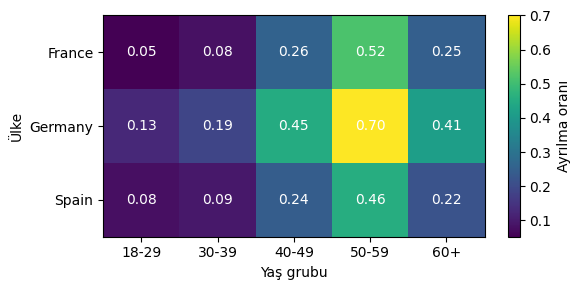

Şekil açıklaması: Ülke × yaş grubu hücrelerinde ayrılma oranı; hücre değerleri oran, renk ölçeği ayrılma oranıdır.


,ikili_boyut,katman,fark_tanimi,toplam_fark,ters_yonlu_katman,TUM_katmanlarda_ters
0,Gender,Geography,Male − Female,-0.086,0/3,False
1,Gender,YasGrubu,Male − Female,-0.086,0/5,False
2,Gender,UrunSayisi,Male − Female,-0.086,0/3,False
3,Aktiflik,Geography,Pasif − Aktif,0.126,0/3,False
4,Aktiflik,YasGrubu,Pasif − Aktif,0.126,0/5,False
5,Aktiflik,UrunSayisi,Pasif − Aktif,0.126,0/3,False
6,Bakiye,Geography,Sifir − Bakiyeli,-0.103,0/2,False
7,Bakiye,YasGrubu,Sifir − Bakiyeli,-0.103,0/5,False
8,Bakiye,UrunSayisi,Sifir − Bakiyeli,-0.103,1/3,False
9,HasCrCard,Geography,1 − 0,-0.006,0/3,False


In [18]:
# Veri küpü için boyutlar (kesikli kategoriler)
df3 = df.copy()
df3["YasGrubu"] = pd.cut(df3["Age"], [17, 29, 39, 49, 59, 100], labels=["18-29", "30-39", "40-49", "50-59", "60+"])
df3["Bakiye"] = np.where(df3["Balance"] == 0, "Sifir", "Bakiyeli")
df3["UrunSayisi"] = df3["NumOfProducts"].clip(upper=3).map({1: "1", 2: "2", 3: "3+"})
df3["Aktiflik"] = df3["IsActiveMember"].map({0: "Pasif", 1: "Aktif"})

# OLGU: ayrılma oranı (Exited ortalaması) ve müşteri sayısı. BOYUTLAR: Geography, Gender, YasGrubu
kup = df3.groupby(["Geography", "Gender", "YasGrubu"], observed=True).agg(musteri=(TARGET, "size"), ayrilma=(TARGET, "mean")).round(3)
print("Küp hücre sayısı:", len(kup)); display(kup.head(12))

# Roll-up: ayrıntıdan özete
print("\n[Roll-up] Geography × YasGrubu"); display(df3.pivot_table(index="Geography", columns="YasGrubu", values=TARGET, aggfunc="mean", observed=True).round(3))
print("[Roll-up] Yalnız YasGrubu"); display(df3.groupby("YasGrubu", observed=True)[TARGET].agg(["size", "mean"]).round(3))
print("[Roll-up] Toplam ayrılma oranı:", round(df3[TARGET].mean(), 3))

# Drill-down: özetten ayrıntıya (örnek: en yüksek ayrılma oranlı ülke)
en_yuksek = df3.groupby("Geography")[TARGET].mean().idxmax()
print(f"\n[Drill-down] {en_yuksek}: cinsiyet ve yaş grubuna göre")
display(df3[df3.Geography == en_yuksek].groupby(["Gender", "YasGrubu"], observed=True)[TARGET].agg(["size", "mean"]).round(3))

# Isı haritası
pv = df3.pivot_table(index="Geography", columns="YasGrubu", values=TARGET, aggfunc="mean", observed=True)
fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(pv.values, aspect="auto"); ax.set_xticks(range(pv.shape[1])); ax.set_xticklabels(pv.columns); ax.set_yticks(range(pv.shape[0])); ax.set_yticklabels(pv.index)
ax.set_xlabel("Yaş grubu"); ax.set_ylabel("Ülke")
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]): ax.text(j, i, f"{pv.values[i, j]:.2f}", ha="center", va="center", color="w")
fig.colorbar(im, label="Ayrılma oranı"); plt.tight_layout(); plt.show()
sekil_aciklamasi("Ülke × yaş grubu hücrelerinde ayrılma oranı; hücre değerleri oran, renk ölçeği ayrılma oranıdır.")

# Simpson paradoksu taraması: ikili boyutun toplam etkisi, katmanlarda yön değiştiriyor mu?
def simpson_tara(ikili, katman):
    d = df3.dropna(subset=[ikili, katman]); seviyeler = sorted(d[ikili].astype(str).unique())
    if len(seviyeler) != 2: return None
    g = d.groupby(d[ikili].astype(str))[TARGET].mean(); toplam = g[seviyeler[1]] - g[seviyeler[0]]
    farklar = {}
    for k, alt in d.groupby(katman, observed=True):
        gg = alt.groupby(alt[ikili].astype(str))[TARGET].mean()
        if set(gg.index) == set(seviyeler): farklar[k] = gg[seviyeler[1]] - gg[seviyeler[0]]
    ters = [k for k, v in farklar.items() if np.sign(v) != np.sign(toplam)]
    return {"ikili_boyut": ikili, "katman": katman, "fark_tanimi": f"{seviyeler[1]} − {seviyeler[0]}", "toplam_fark": round(toplam, 3),
            "ters_yonlu_katman": f"{len(ters)}/{len(farklar)}", "TUM_katmanlarda_ters": len(ters) == len(farklar) and len(farklar) > 0}
satirlar = [simpson_tara(a, b) for a in ["Gender", "Aktiflik", "Bakiye", "HasCrCard"] for b in ["Geography", "YasGrubu", "UrunSayisi"]]
display(pd.DataFrame([s for s in satirlar if s]))

**Yorum** Bu çalışmada müşteri ayrılma oranlarını ülke, cinsiyet ve yaş gruplarına göre inceleyerek 30 farklı veri küpü hücresi oluşturdum. Genel müşteri ayrılma oranının %20,4 olduğunu gördüm.

Yaş gruplarını karşılaştırdığımda en yüksek ayrılma oranının %56 ile 50-59 yaş grubunda olduğunu belirledim. Ülkeler arasında ise Almanya'nın diğer ülkelere göre daha yüksek ayrılma oranlarına sahip olduğu görülmektedir. Özellikle Almanya'da 50-59 yaş grubunun ayrılma oranı %70'e ulaşmaktadır.

Drill-down analiziyle Almanya'daki müşterileri cinsiyet ve yaş gruplarına göre daha ayrıntılı inceledim. Bu analizde 50-59 yaş grubundaki kadınların %73'ünün, erkeklerin ise %66,9'unun bankadan ayrıldığını gördüm. Bu sonuç, genel ortalamaların bazı alt gruplardaki yüksek ayrılma risklerini gizleyebileceğini göstermektedir.

Cinsiyet karşılaştırmasında kadınların ayrılma oranının erkeklerden 8,6 yüzde puan daha yüksek olduğu görülmektedir. Ayrıca pasif müşterilerin ayrılma oranı aktif müşterilerden 12,6 yüzde puan daha yüksektir.

Simpson paradoksunu araştırmak için genel sonuçlarla alt grup sonuçlarını karşılaştırdım. İncelenen karşılaştırmaların hiçbirinde genel eğilimin bütün alt gruplarda tersine döndüğü bir durum tespit edilmedi. Ancak kredi kartı sahipliği karşılaştırmasında 5 yaş grubunun 3'ünde genel eğilimin tersine döndüğünü gördüm. Bu durum, alt grupların ayrı ayrı incelenmesinin önemini göstermektedir.

Sonuç olarak veri küpü analizinin müşteri ayrılma davranışlarını farklı açılardan değerlendirmemi sağladığını gördüm. Roll-up işlemiyle genel eğilimleri, drill-down işlemiyle alt gruplardaki farklılıkları inceleyebildim. Ancak bu sonuçların neden-sonuç ilişkisi göstermediğini ve özellikle az sayıda müşterinin bulunduğu gruplarda dikkatli yorum yapılması gerektiğini düşünüyorum.

### 3.2 Birliktelik: seçenek ve kurulum
İşlem bilgisi varsa **A**, yoksa **B**. Veri değiştirilmez.

**Seçenek:** **B** — veride işlem (sepet, sipariş, oturum) bilgisi yok; her satır bir müşteri (yönergeye göre bu konuda B uygulanır). Tablo, sayısal sütunlar ayrıklaştırılarak "öznitelik = değer" öğelerinden oluşan işlemlere çevrilir.

In [19]:
!pip -q install mlxtend
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Seçenek B: her satır bir müşteri (işlem/sepet bilgisi yok) → tabloyu "öznitelik = değer" işlemlerine çevir.
# Ayrıklaştırma sınırları (gerekçeler Varsayım defterinde): etiketler Weka ile uyum için özel karakter içermez.
def ayriklastir(d):
    o = pd.DataFrame(index=d.index)
    o["Yas"] = pd.cut(d["Age"], [17, 29, 39, 49, 59, 100], labels=["18_29", "30_39", "40_49", "50_59", "60_plus"])
    o["KrediSkoru"] = pd.cut(d["CreditScore"], [0, 579, 669, 739, 799, 900], labels=["zayif", "orta", "iyi", "cok_iyi", "mukemmel"])   # FICO benzeri bantlar
    o["Kidem"] = pd.cut(d["Tenure"], [-1, 2, 5, 8, 10], labels=["0_2yil", "3_5yil", "6_8yil", "9_10yil"])
    pozitif = d.loc[d["Balance"] > 0, "Balance"]; q = pozitif.quantile([1/3, 2/3]).values
    o["Bakiye"] = np.select([d["Balance"] == 0, d["Balance"] <= q[0], d["Balance"] <= q[1]], ["sifir", "dusuk", "orta"], default="yuksek")
    qm = d["EstimatedSalary"].quantile([1/3, 2/3]).values
    o["Maas"] = np.select([d["EstimatedSalary"] <= qm[0], d["EstimatedSalary"] <= qm[1]], ["dusuk", "orta"], default="yuksek")
    o["Urun"] = d["NumOfProducts"].clip(upper=3).map({1: "1", 2: "2", 3: "3_ve_uzeri"})
    o["Kart"] = d["HasCrCard"].map({0: "yok", 1: "var"})
    o["Aktiflik"] = d["IsActiveMember"].map({0: "pasif", 1: "aktif"})
    o["Geography"] = d["Geography"]; o["Gender"] = d["Gender"]
    o["Exited"] = d["Exited"].map({0: "Kaldi", 1: "Ayrildi"})
    return o.astype(str)
tablo_ayrik = ayriklastir(df)
T = pd.get_dummies(tablo_ayrik, prefix_sep="=").astype(bool)      # satır = işlem, sütun = 'öznitelik=değer' öğesi
print("İşlem sayısı:", len(T), "| öğe sayısı:", T.shape[1])
display(tablo_ayrik.head())
print("Öğe destekleri (en nadir 8):"); display(T.mean().sort_values().head(8).round(4))

İşlem sayısı: 10000 | öğe sayısı: 35


,Yas,KrediSkoru,Kidem,Bakiye,Maas,Urun,Kart,Aktiflik,Geography,Gender,Exited
0,40_49,orta,0_2yil,sifir,orta,1,var,aktif,France,Female,Ayrildi
1,40_49,orta,0_2yil,dusuk,orta,1,yok,aktif,Spain,Female,Kaldi
2,40_49,zayif,6_8yil,yuksek,orta,3_ve_uzeri,var,pasif,France,Female,Ayrildi
3,30_39,iyi,0_2yil,sifir,orta,2,yok,pasif,France,Female,Kaldi
4,40_49,mukemmel,0_2yil,orta,orta,1,var,aktif,Spain,Female,Kaldi


Öğe destekleri (en nadir 8):


,0
Urun=3_ve_uzeri,0.0326
Yas=60_plus,0.0526
KrediSkoru=mukemmel,0.0655
Yas=50_59,0.0869
KrediSkoru=cok_iyi,0.1224
Kidem=9_10yil,0.1474
Yas=18_29,0.1641
Exited=Ayrildi,0.2037


**Yorum** Bu çalışmada birliktelik analizi için Seçenek B yöntemini kullandım. Veri kümesinde alışveriş sepeti veya işlem bilgisi bulunmadığından her müşteriyi bir işlem olarak değerlendirdim.

Analiz sonucunda 10.000 müşteri kaydı 35 farklı öğeden oluşan bir yapıya dönüştürüldü. Yaş, kredi skoru, kıdem, bakiye ve maaş gibi sayısal değişkenleri belirli kategorilere ayırarak birliktelik analizine uygun hale getirdim.

Öğe desteklerini incelediğimde en düşük görülme oranının %3,26 ile üç veya daha fazla ürün kullanan müşterilere ait olduğunu gördüm. Ayrıca 60 yaş ve üzerindeki müşterilerin oranı %5,26, mükemmel kredi skoruna sahip müşterilerin oranı ise %6,55 olarak hesaplandı.

Müşterilerin %20,37'sinin bankadan ayrıldığı görülmektedir. Bu sonuç önceki analizlerde elde edilen ayrılma oranıyla tutarlıdır.

Bazı öğelerin daha az görülmesi, bu öğeleri içeren birliktelik kurallarının daha sınırlı sayıda müşteriye dayanmasına neden olabilir. Bu nedenle sonraki aşamalarda yalnızca güven ve lift değerlerini değil, destek oranını, Kulczynski ölçütünü ve dengesizlik oranını da değerlendirmem gerektiğini düşünüyorum.

Sonuç olarak müşteri özelliklerini kategorilere ayırarak birliktelik analizi için gerekli veri yapısını oluşturdum. Bu yöntemle müşteri özelliklerinin birlikte görülme durumlarını inceleyebileceğim. Ancak elde edilecek birlikteliklerin doğrudan neden-sonuç ilişkisi göstermeyeceğini dikkate alacağım.

### 3.3 Kurallar ve ilgi ölçütleri
**A:** işlem tanımı; Apriori ve FP-Growth, en az üç `min_support`; güven, lift ve Kulczynski; null-invariance testi.
**B:** ayrıklaştırma ve "öznitelik = değer" işlemleri; hedefe yönelik kurallar; lift ve Kulczynski; Proje 1 modelinin önemli öznitelikleriyle karşılaştırma.
İki seçenekte de üç kuralın alan bilgisiyle yorumu.

In [20]:
import re
MIN_SUP, MIN_CONF = 0.02, 0.30      # Weka'da (3.4) AYNI eşikler kullanılacak
HEDEF = frozenset({"Exited=Ayrildi"})

ogeler = fpgrowth(T, min_support=MIN_SUP, use_colnames=True, max_len=4)
try:
    kurallar = association_rules(ogeler, metric="confidence", min_threshold=MIN_CONF)
except TypeError:
    kurallar = association_rules(ogeler, num_itemsets=len(T), metric="confidence", min_threshold=MIN_CONF)
print("Sık öğe kümesi:", len(ogeler), "| kural:", len(kurallar))

h = kurallar[kurallar["consequents"] == HEDEF].copy()           # hedefe yönelik kurallar: {...} → Exited=Ayrildi
h["kulc"] = 0.5 * (h["support"] / h["antecedent support"] + h["support"] / h["consequent support"])
h["IR"] = (h["antecedent support"] - h["consequent support"]).abs() / (h["antecedent support"] + h["consequent support"] - h["support"])
h["kural"] = h["antecedents"].apply(lambda s: " & ".join(sorted(s)))
kol = ["kural", "support", "confidence", "lift", "kulc", "IR"]
print("Hedefe yönelik kural sayısı:", len(h))
if len(h) < 10:
    print("UYARI: çok az hedefe yönelik kural var; MIN_SUP / MIN_CONF değerlerini hedef oranına göre (Exited=Ayrildi desteği) gözden geçirin ve 3.4'te Weka'da AYNI değerleri kullanın.")
print("\n--- Güvene göre ilk 10 ---"); display(h.sort_values("confidence", ascending=False)[kol].head(10).round(3))
print("--- Lift'e göre ilk 10 ---");   display(h.sort_values("lift", ascending=False)[kol].head(10).round(3))
print("--- Kulczynski'ye göre ilk 10 ---"); display(h.sort_values("kulc", ascending=False)[kol].head(10).round(3))

# Nadir kategori içeren kurallarda lift ile Kulczynski sıralaması nasıl ayrışıyor?
destek = T.mean()
nadir_ogeler = set(destek[destek < 0.05].index) - {"Exited=Ayrildi"}
nadir = h[h["antecedents"].apply(lambda s: len(s & nadir_ogeler) > 0)].copy()
h["lift_sira"] = h["lift"].rank(ascending=False); h["kulc_sira"] = h["kulc"].rank(ascending=False)
nadir = h.loc[nadir.index, kol + ["lift_sira", "kulc_sira"]]
nadir["sira_farki"] = (nadir["lift_sira"] - nadir["kulc_sira"]).abs()
print("\nNadir öğe (destek < %5) içeren kurallar; lift ve Kulczynski sıralarının farkı en büyükler:")
display(nadir.sort_values("sira_farki", ascending=False).head(8).round(3))

# Proje 1 modelinin önemli öznitelikleriyle örtüşme (permütasyon önemi, katman dışı)
from sklearn.inspection import permutation_importance
imps = []
for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y):
    m = clone(hat).fit(X.iloc[tr], y[tr])
    imps.append(permutation_importance(m, X.iloc[te], y[te], scoring="roc_auc", n_repeats=5, random_state=SEED).importances_mean)
onem = pd.Series(np.mean(imps, axis=0), index=X.columns).sort_values(ascending=False)
print("\nPermütasyon önemi (ROC AUC düşüşü, 5 katın ortalaması):"); display(onem.round(4))
kaynak = {"Yas": "Age", "KrediSkoru": "CreditScore", "Kidem": "Tenure", "Bakiye": "Balance", "Maas": "EstimatedSalary", "Urun": "NumOfProducts",
          "Kart": "HasCrCard", "Aktiflik": "IsActiveMember", "Geography": "Geography", "Gender": "Gender"}
ilk10 = h.sort_values("lift", ascending=False).head(10)
kural_sutunlari = {kaynak[o.split("=")[0]] for s in ilk10["antecedents"] for o in s}
ilk5_model = set(onem.index[:5])
print("Lift'e göre ilk 10 kuralda geçen sütunlar:", sorted(kural_sutunlari))
print("Modelin en önemli 5 özniteliği:", sorted(ilk5_model))
print("Örtüşen:", sorted(kural_sutunlari & ilk5_model))

Sık öğe kümesi: 7927 | kural: 26657
Hedefe yönelik kural sayısı: 116

--- Güvene göre ilk 10 ---


,kural,support,confidence,lift,kulc,IR
21825,Aktiflik=pasif & Urun=1 & Yas=50_59,0.022,0.869,4.264,0.488,0.863
16265,Urun=3_ve_uzeri,0.028,0.859,4.216,0.498,0.821
21812,Aktiflik=pasif & Yas=50_59,0.030,0.812,3.988,0.481,0.790
21820,Aktiflik=pasif & Kart=var & Yas=50_59,0.021,0.802,3.939,0.452,0.852
21800,Urun=1 & Yas=50_59,0.034,0.641,3.145,0.405,0.673
21833,Gender=Female & Yas=50_59,0.026,0.629,3.090,0.380,0.737
21806,Kart=var & Urun=1 & Yas=50_59,0.023,0.623,3.056,0.367,0.770
6604,Geography=Germany & Urun=1 & Yas=40_49,0.023,0.577,2.831,0.346,0.740
21746,Yas=50_59,0.049,0.560,2.751,0.400,0.483
21803,Kart=var & Yas=50_59,0.032,0.548,2.688,0.353,0.629


--- Lift'e göre ilk 10 ---


,kural,support,confidence,lift,kulc,IR
21825,Aktiflik=pasif & Urun=1 & Yas=50_59,0.022,0.869,4.264,0.488,0.863
16265,Urun=3_ve_uzeri,0.028,0.859,4.216,0.498,0.821
21812,Aktiflik=pasif & Yas=50_59,0.030,0.812,3.988,0.481,0.790
21820,Aktiflik=pasif & Kart=var & Yas=50_59,0.021,0.802,3.939,0.452,0.852
21800,Urun=1 & Yas=50_59,0.034,0.641,3.145,0.405,0.673
21833,Gender=Female & Yas=50_59,0.026,0.629,3.090,0.380,0.737
21806,Kart=var & Urun=1 & Yas=50_59,0.023,0.623,3.056,0.367,0.770
6604,Geography=Germany & Urun=1 & Yas=40_49,0.023,0.577,2.831,0.346,0.740
21746,Yas=50_59,0.049,0.560,2.751,0.400,0.483
21803,Kart=var & Yas=50_59,0.032,0.548,2.688,0.353,0.629


--- Kulczynski'ye göre ilk 10 ---


...


Nadir öğe (destek < %5) içeren kurallar; lift ve Kulczynski sıralarının farkı en büyükler:


,kural,support,confidence,lift,kulc,IR,lift_sira,kulc_sira,sira_farki
16265,Urun=3_ve_uzeri,0.028,0.859,4.216,0.498,0.821,2.0,1.0,1.0



Permütasyon önemi (ROC AUC düşüşü, 5 katın ortalaması):


,0
NumOfProducts,0.1295
Age,0.1175
Balance,0.0438
IsActiveMember,0.0312
Geography,0.0283
Gender,0.0066
EstimatedSalary,0.0020
CreditScore,0.0020
HasCrCard,0.0001
Tenure,-0.0004


Lift'e göre ilk 10 kuralda geçen sütunlar: ['Age', 'Gender', 'Geography', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
Modelin en önemli 5 özniteliği: ['Age', 'Balance', 'Geography', 'IsActiveMember', 'NumOfProducts']
Örtüşen: ['Age', 'Geography', 'IsActiveMember', 'NumOfProducts']


In [21]:
print("Sık öğe kümesi:", len(ogeler))
print("Toplam kural:", len(kurallar))
print("Hedefe yönelik kural sayısı:", len(h))

kolonlar = ["kural", "support", "confidence", "lift", "kulc", "IR"]

print("\nGüvene göre ilk 10:")
display(h.sort_values("confidence", ascending=False)[kolonlar].head(10).round(3))

print("\nLift'e göre ilk 10:")
display(h.sort_values("lift", ascending=False)[kolonlar].head(10).round(3))

print("\nKulczynski'ye göre ilk 10:")
display(h.sort_values("kulc", ascending=False)[kolonlar].head(10).round(3))

Sık öğe kümesi: 7927
Toplam kural: 26657
Hedefe yönelik kural sayısı: 116

Güvene göre ilk 10:


,kural,support,confidence,lift,kulc,IR
21825,Aktiflik=pasif & Urun=1 & Yas=50_59,0.022,0.869,4.264,0.488,0.863
16265,Urun=3_ve_uzeri,0.028,0.859,4.216,0.498,0.821
21812,Aktiflik=pasif & Yas=50_59,0.030,0.812,3.988,0.481,0.790
21820,Aktiflik=pasif & Kart=var & Yas=50_59,0.021,0.802,3.939,0.452,0.852
21800,Urun=1 & Yas=50_59,0.034,0.641,3.145,0.405,0.673
21833,Gender=Female & Yas=50_59,0.026,0.629,3.090,0.380,0.737
21806,Kart=var & Urun=1 & Yas=50_59,0.023,0.623,3.056,0.367,0.770
6604,Geography=Germany & Urun=1 & Yas=40_49,0.023,0.577,2.831,0.346,0.740
21746,Yas=50_59,0.049,0.560,2.751,0.400,0.483
21803,Kart=var & Yas=50_59,0.032,0.548,2.688,0.353,0.629



Lift'e göre ilk 10:


,kural,support,confidence,lift,kulc,IR
21825,Aktiflik=pasif & Urun=1 & Yas=50_59,0.022,0.869,4.264,0.488,0.863
16265,Urun=3_ve_uzeri,0.028,0.859,4.216,0.498,0.821
21812,Aktiflik=pasif & Yas=50_59,0.030,0.812,3.988,0.481,0.790
21820,Aktiflik=pasif & Kart=var & Yas=50_59,0.021,0.802,3.939,0.452,0.852
21800,Urun=1 & Yas=50_59,0.034,0.641,3.145,0.405,0.673
21833,Gender=Female & Yas=50_59,0.026,0.629,3.090,0.380,0.737
21806,Kart=var & Urun=1 & Yas=50_59,0.023,0.623,3.056,0.367,0.770
6604,Geography=Germany & Urun=1 & Yas=40_49,0.023,0.577,2.831,0.346,0.740
21746,Yas=50_59,0.049,0.560,2.751,0.400,0.483
21803,Kart=var & Yas=50_59,0.032,0.548,2.688,0.353,0.629



Kulczynski'ye göre ilk 10:


,kural,support,confidence,lift,kulc,IR
16265,Urun=3_ve_uzeri,0.028,0.859,4.216,0.498,0.821
21825,Aktiflik=pasif & Urun=1 & Yas=50_59,0.022,0.869,4.264,0.488,0.863
21812,Aktiflik=pasif & Yas=50_59,0.030,0.812,3.988,0.481,0.790
21820,Aktiflik=pasif & Kart=var & Yas=50_59,0.021,0.802,3.939,0.452,0.852
6838,Aktiflik=pasif & Urun=1,0.092,0.367,1.799,0.410,0.133
21800,Urun=1 & Yas=50_59,0.034,0.641,3.145,0.405,0.673
21746,Yas=50_59,0.049,0.560,2.751,0.400,0.483
21833,Gender=Female & Yas=50_59,0.026,0.629,3.090,0.380,0.737
21806,Kart=var & Urun=1 & Yas=50_59,0.023,0.623,3.056,0.367,0.770
6445,Geography=Germany,0.081,0.324,1.593,0.362,0.126


**Yorum** Bu çalışmada FP-Growth yöntemiyle birliktelik kurallarını oluşturdum. Analiz sonucunda 7.927 sık öğe kümesi, 26.657 birliktelik kuralı ve müşteri ayrılmasına yönelik 116 kural elde ettim.

Güven değerlerine göre en dikkat çekici kuralın 50-59 yaş grubunda bulunan, aktif olmayan ve yalnızca bir ürün kullanan müşterilere ait olduğunu gördüm. Bu grupta müşteri ayrılma oranı %86,9, lift değeri ise 4.264 olarak hesaplanmıştır. Bu durum, söz konusu müşteri grubunun genel ayrılma oranına göre yaklaşık 4,26 kat daha yüksek ayrılma oranına sahip olduğunu göstermektedir.

İkinci önemli kuralda üç veya daha fazla ürün kullanan müşterilerin ayrılma oranı %85,9 ve lift değeri 4.216 olarak bulunmuştur. Ayrıca 50-59 yaş grubundaki pasif müşterilerde ayrılma oranının %81,2 olduğu görülmektedir.

Kuralları yalnızca güven ve lift değerleriyle değil, Kulczynski ve dengesizlik oranı (IR) ölçütleriyle de değerlendirdim. Örneğin üç veya daha fazla ürün kullanan müşterilere ait kuralın Kulczynski değeri 0.498, IR değeri ise 0.821 olarak hesaplanmıştır. Yüksek IR değeri, kuraldaki öğelerin görülme sıklıkları arasında belirgin bir dengesizlik bulunduğunu göstermektedir.

Lift ve Kulczynski sıralamalarının her zaman aynı olmadığını gördüm. Bu nedenle bir kuralın yüksek lift değerine sahip olması, tek başına en güvenilir veya en kullanışlı kural olduğu anlamına gelmemektedir. Destek, güven, Kulczynski ve IR değerlerinin birlikte incelenmesi daha sağlıklı bir değerlendirme sağlamaktadır.

Birliktelik kurallarını Proje 1'de geliştirdiğim makine öğrenmesi modelinin değişken önemleriyle karşılaştırdığımda yaş, ülke, aktif üyelik durumu ve ürün sayısının her iki analizde de öne çıktığını gördüm. Özellikle ürün sayısı ve yaş, müşteri ayrılmasını açıklamada önemli değişkenler olarak görünmektedir.

Sonuç olarak birliktelik analizi sayesinde ayrılma oranı yüksek müşteri gruplarını belirleyebildim. Ancak bu ilişkilerin doğrudan neden-sonuç ilişkisi göstermediğini ve kuralların yeni müşteriler üzerinde ayrıca doğrulanması gerektiğini düşünüyorum.

### 3.4 Weka ile kontrol
Aynı eşiklerde Weka Apriori çıktısı.

In [22]:
# --- 3.4 Weka Apriori kontrolu (Weka 3.8.7, yuklenen gercek cikti) ---
import re
import numpy as np
import pandas as pd

# Her satir bir musteri; ayriklastirilmis islemleri aynen Weka'ya aktar.
def arff_yaz(frame, yol, relation, nominal_cols):
    with open(yol, "w", encoding="utf-8") as f:
        f.write(f"@relation {relation}\n\n")
        for c in frame.columns:
            if c in nominal_cols:
                degerler = ",".join(sorted(frame[c].astype(str).unique()))
                f.write(f"@attribute {c} {{{degerler}}}\n")
            else:
                f.write(f"@attribute {c} numeric\n")
        f.write("\n@data\n")
        for satir in frame.astype(str).itertuples(index=False):
            f.write(",".join(satir) + "\n")

arff_yaz(tablo_ayrik, "churn_p1_apriori.arff", "churn_apriori", nominal_cols=list(tablo_ayrik.columns))
print("churn_p1_apriori.arff yazildi; Weka 3.8.7 sonucu kodun icine eklendi.")

# Weka 3.8.7, Apriori: -N 5000 -T 0 -C 0.3 -D 0.01 -U 1.0 -M 0.02 -c -1
# Kaynak: kullanicinin yukledigi 'yenisonuc' Weka metin dosyasi.
# Weka'nin 4731 kuralinin 132'si Exited=Ayrildi sonucuna sahip.
weka_apriori = """
Weka surumu: 3.8.7
=== Run information ===

Scheme:       weka.associations.Apriori -N 5000 -T 0 -C 0.3 -D 0.01 -U 1.0 -M 0.02 -S -1.0 -A -c -1
Relation:     churn_apriori
Instances:    10000
Attributes:   11
              Yas
              KrediSkoru
              Kidem
              Bakiye
              Maas
              Urun
              Kart
              Aktiflik
              Geography
              Gender
              Exited
=== Associator model (full training set) ===


Apriori
=======

Minimum support: 0.02 (200 instances)
Minimum metric <confidence>: 0.3
Number of cycles performed: 98

Generated sets of large itemsets:

Size of set of large itemsets L(1): 62

Size of set of large itemsets L(2): 560

Size of set of large itemsets L(3): 1921

Size of set of large itemsets L(4): 1893

Size of set of large itemsets L(5): 488

Size of set of large itemsets L(6): 30

Best rules found:

   1. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=aktif Gender=Male 349 ==> Exited=Kaldi 349    conf:(1)
   2. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Gender=Male 249 ==> Exited=Kaldi 249    conf:(1)
   3. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France Gender=Male 239 ==> Exited=Kaldi 239    conf:(1)
   4. Yas=30_39 KrediSkoru=orta Bakiye=sifir Urun=2 Gender=Male 226 ==> Exited=Kaldi 226    conf:(1)
   5. Yas=30_39 Bakiye=sifir Maas=dusuk Urun=2 Gender=Male 253 ==> Exited=Kaldi 252    conf:(1)
   6. KrediSkoru=orta Bakiye=sifir Urun=2 Kart=var Geography=France Gender=Male 236 ==> Exited=Kaldi 235    conf:(1)
   7. Yas=30_39 Bakiye=sifir Maas=orta Urun=2 Gender=Male 221 ==> Exited=Kaldi 220    conf:(1)
   8. Yas=30_39 Kidem=6_8yil Bakiye=sifir Urun=2 Gender=Male 219 ==> Exited=Kaldi 218    conf:(1)
   9. Yas=30_39 Maas=orta Urun=2 Aktiflik=aktif Gender=Male 210 ==> Exited=Kaldi 209    conf:(1)
  10. Yas=30_39 Bakiye=sifir Urun=2 Geography=France Gender=Male 474 ==> Exited=Kaldi 471    conf:(0.99)
  11. Yas=18_29 Bakiye=sifir Urun=2 Gender=Male 280 ==> Exited=Kaldi 278    conf:(0.99)
  12. Yas=30_39 Bakiye=sifir Urun=2 Gender=Male 697 ==> Exited=Kaldi 692    conf:(0.99)
  13. KrediSkoru=orta Bakiye=sifir Urun=2 Aktiflik=aktif Gender=Male 273 ==> Exited=Kaldi 271    conf:(0.99)
  14. Yas=30_39 Kidem=6_8yil Bakiye=sifir Urun=2 Geography=France 260 ==> Exited=Kaldi 258    conf:(0.99)
  15. Bakiye=sifir Maas=yuksek Urun=2 Aktiflik=aktif Gender=Male 254 ==> Exited=Kaldi 252    conf:(0.99)
  16. Yas=30_39 Maas=orta Urun=2 Kart=var Aktiflik=aktif 253 ==> Exited=Kaldi 251    conf:(0.99)
  17. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Gender=Male 504 ==> Exited=Kaldi 500    conf:(0.99)
  18. Bakiye=sifir Urun=2 Aktiflik=aktif Geography=Spain Gender=Male 244 ==> Exited=Kaldi 242    conf:(0.99)
  19. Bakiye=sifir Maas=orta Urun=2 Aktiflik=aktif Gender=Male 242 ==> Exited=Kaldi 240    conf:(0.99)
  20. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Geography=France Gender=Male 351 ==> Exited=Kaldi 348    conf:(0.99)
  21. Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var Geography=France Gender=Male 234 ==> Exited=Kaldi 232    conf:(0.99)
  22. Kidem=3_5yil Bakiye=sifir Urun=2 Aktiflik=aktif Gender=Male 231 ==> Exited=Kaldi 229    conf:(0.99)
  23. KrediSkoru=orta Bakiye=sifir Urun=2 Geography=France Gender=Male 341 ==> Exited=Kaldi 338    conf:(0.99)
  24. Yas=30_39 Bakiye=sifir Urun=2 Geography=Spain Gender=Male 223 ==> Exited=Kaldi 221    conf:(0.99)
  25. Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var Gender=Male 331 ==> Exited=Kaldi 328    conf:(0.99)
  26. Yas=30_39 KrediSkoru=zayif Bakiye=sifir Urun=2 Kart=var 215 ==> Exited=Kaldi 213    conf:(0.99)
  27. Yas=30_39 Kidem=3_5yil Bakiye=sifir Urun=2 Gender=Male 211 ==> Exited=Kaldi 209    conf:(0.99)
  28. Kidem=6_8yil Bakiye=sifir Urun=2 Aktiflik=pasif Gender=Male 211 ==> Exited=Kaldi 209    conf:(0.99)
  29. Bakiye=sifir Maas=orta Urun=2 Kart=var Geography=France Gender=Male 209 ==> Exited=Kaldi 207    conf:(0.99)
  30. KrediSkoru=zayif Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif 208 ==> Exited=Kaldi 206    conf:(0.99)
  31. Yas=30_39 KrediSkoru=zayif Bakiye=sifir Urun=2 Geography=France 206 ==> Exited=Kaldi 204    conf:(0.99)
  32. Yas=18_29 Bakiye=sifir Urun=2 Kart=var Gender=Male 205 ==> Exited=Kaldi 203    conf:(0.99)
  33. Yas=30_39 KrediSkoru=zayif Bakiye=sifir Urun=2 297 ==> Exited=Kaldi 294    conf:(0.99)
  34. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Geography=Spain 290 ==> Exited=Kaldi 287    conf:(0.99)
  35. Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Geography=France Gender=Male 384 ==> Exited=Kaldi 380    conf:(0.99)
  36. Yas=30_39 Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var 287 ==> Exited=Kaldi 284    conf:(0.99)
  37. Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Gender=Male 551 ==> Exited=Kaldi 545    conf:(0.99)
  38. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif 446 ==> Exited=Kaldi 441    conf:(0.99)
  39. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=aktif 609 ==> Exited=Kaldi 602    conf:(0.99)
  40. KrediSkoru=orta Bakiye=sifir Urun=2 Kart=var Gender=Male 347 ==> Exited=Kaldi 343    conf:(0.99)
  41. Yas=18_29 Bakiye=sifir Urun=2 Aktiflik=pasif 259 ==> Exited=Kaldi 256    conf:(0.99)
  42. Bakiye=sifir Urun=2 Aktiflik=aktif Gender=Male 765 ==> Exited=Kaldi 756    conf:(0.99)
  43. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France 410 ==> Exited=Kaldi 405    conf:(0.99)
  44. Yas=30_39 KrediSkoru=zayif Urun=2 Aktiflik=aktif 244 ==> Exited=Kaldi 241    conf:(0.99)
  45. Yas=30_39 Urun=2 Aktiflik=aktif Geography=France Gender=Male 323 ==> Exited=Kaldi 319    conf:(0.99)
  46. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=pasif Geography=France Gender=Male 235 ==> Exited=Kaldi 232    conf:(0.99)
  47. Yas=30_39 Bakiye=sifir Maas=yuksek Urun=2 386 ==> Exited=Kaldi 381    conf:(0.99)
  48. Yas=30_39 Urun=2 Kart=var Aktiflik=aktif Geography=France Gender=Male 230 ==> Exited=Kaldi 227    conf:(0.99)
  49. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Geography=France 306 ==> Exited=Kaldi 302    conf:(0.99)
  50. Bakiye=sifir Maas=orta Urun=2 Kart=var Gender=Male 304 ==> Exited=Kaldi 300    conf:(0.99)
  51. KrediSkoru=zayif Bakiye=sifir Urun=2 Aktiflik=aktif 302 ==> Exited=Kaldi 298    conf:(0.99)
  52. Yas=30_39 Kidem=3_5yil Urun=2 Kart=var Aktiflik=aktif 225 ==> Exited=Kaldi 222    conf:(0.99)
  53. Yas=18_29 Urun=2 Aktiflik=pasif Geography=France 224 ==> Exited=Kaldi 221    conf:(0.99)
  54. Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France Gender=Male 521 ==> Exited=Kaldi 514    conf:(0.99)
  55. Yas=30_39 Bakiye=sifir Maas=yuksek Urun=2 Gender=Male 223 ==> Exited=Kaldi 220    conf:(0.99)
  56. Bakiye=sifir Maas=yuksek Urun=2 Kart=var Aktiflik=aktif Geography=France 222 ==> Exited=Kaldi 219    conf:(0.99)
  57. Yas=30_39 Bakiye=sifir Urun=2 Kart=yok Geography=France 220 ==> Exited=Kaldi 217    conf:(0.99)
  58. Bakiye=sifir Urun=2 Kart=yok Aktiflik=aktif Gender=Male 214 ==> Exited=Kaldi 211    conf:(0.99)
  59. Yas=30_39 Bakiye=sifir Maas=orta Urun=2 Kart=var 285 ==> Exited=Kaldi 281    conf:(0.99)
  60. Yas=30_39 KrediSkoru=orta Urun=2 Aktiflik=aktif Gender=Male 213 ==> Exited=Kaldi 210    conf:(0.99)
  61. KrediSkoru=orta Bakiye=sifir Urun=2 Gender=Male 493 ==> Exited=Kaldi 486    conf:(0.99)
  62. Yas=18_29 Maas=orta Urun=2 280 ==> Exited=Kaldi 276    conf:(0.99)
  63. Yas=30_39 Bakiye=sifir Maas=yuksek Urun=2 Kart=var 280 ==> Exited=Kaldi 276    conf:(0.99)
  64. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=pasif Gender=Male 348 ==> Exited=Kaldi 343    conf:(0.99)
  65. Kidem=3_5yil Bakiye=sifir Urun=2 Aktiflik=aktif 411 ==> Exited=Kaldi 405    conf:(0.99)
  66. Yas=30_39 Bakiye=sifir Urun=2 Geography=Spain 408 ==> Exited=Kaldi 402    conf:(0.99)
  67. KrediSkoru=zayif Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France 204 ==> Exited=Kaldi 201    conf:(0.99)
  68. Yas=30_39 Kidem=3_5yil Bakiye=sifir Urun=2 Kart=var 269 ==> Exited=Kaldi 265    conf:(0.99)
  69. Kidem=6_8yil Bakiye=sifir Urun=2 Gender=Male 465 ==> Exited=Kaldi 458    conf:(0.98)
  70. Yas=30_39 Kidem=6_8yil Bakiye=sifir Urun=2 391 ==> Exited=Kaldi 385    conf:(0.98)
  71. Bakiye=sifir Maas=yuksek Urun=2 Kart=var Aktiflik=aktif 325 ==> Exited=Kaldi 320    conf:(0.98)
  72. Yas=30_39 Kidem=3_5yil Urun=2 Kart=var Gender=Male 260 ==> Exited=Kaldi 256    conf:(0.98)
  73. Yas=18_29 Bakiye=sifir Urun=2 518 ==> Exited=Kaldi 510    conf:(0.98)
  74. Yas=30_39 Urun=2 Kart=var Aktiflik=aktif Gender=Male 453 ==> Exited=Kaldi 446    conf:(0.98)
  75. Yas=30_39 Urun=2 Aktiflik=aktif Gender=Male 639 ==> Exited=Kaldi 629    conf:(0.98)
  76. Kidem=3_5yil Bakiye=sifir Urun=2 Kart=var Gender=Male 319 ==> Exited=Kaldi 314    conf:(0.98)
  77. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif Gender=Male 255 ==> Exited=Kaldi 251    conf:(0.98)
  78. Yas=30_39 Kidem=3_5yil Urun=2 Aktiflik=aktif 316 ==> Exited=Kaldi 311    conf:(0.98)
  79. Kidem=6_8yil Bakiye=sifir Urun=2 Geography=France Gender=Male 315 ==> Exited=Kaldi 310    conf:(0.98)
  80. Bakiye=sifir Maas=orta Urun=2 Kart=var Aktiflik=aktif 314 ==> Exited=Kaldi 309    conf:(0.98)
  81. Yas=30_39 Kidem=3_5yil Bakiye=sifir Urun=2 367 ==> Exited=Kaldi 361    conf:(0.98)
  82. KrediSkoru=iyi Bakiye=sifir Urun=2 Geography=France Gender=Male 242 ==> Exited=Kaldi 238    conf:(0.98)
  83. Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Geography=France 242 ==> Exited=Kaldi 238    conf:(0.98)
  84. Kidem=3_5yil Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif 297 ==> Exited=Kaldi 292    conf:(0.98)
  85. Bakiye=sifir Maas=orta Urun=2 Geography=France Gender=Male 297 ==> Exited=Kaldi 292    conf:(0.98)
  86. Yas=18_29 Bakiye=sifir Urun=2 Geography=France 353 ==> Exited=Kaldi 347    conf:(0.98)
  87. Yas=30_39 Maas=orta Urun=2 Aktiflik=aktif 353 ==> Exited=Kaldi 347    conf:(0.98)
  88. Bakiye=sifir Urun=2 Kart=var Geography=France Gender=Male 702 ==> Exited=Kaldi 690    conf:(0.98)
  89. KrediSkoru=iyi Bakiye=sifir Urun=2 Gender=Male 348 ==> Exited=Kaldi 342    conf:(0.98)
  90. Yas=30_39 Bakiye=sifir Maas=orta Urun=2 404 ==> Exited=Kaldi 397    conf:(0.98)
  91. Bakiye=sifir Urun=2 Aktiflik=aktif Geography=Spain 453 ==> Exited=Kaldi 445    conf:(0.98)
  92. Yas=30_39 Bakiye=sifir Urun=2 Kart=yok 338 ==> Exited=Kaldi 332    conf:(0.98)
  93. Kidem=0_2yil Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France 225 ==> Exited=Kaldi 221    conf:(0.98)
  94. Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif 336 ==> Exited=Kaldi 330    conf:(0.98)
  95. Yas=30_39 KrediSkoru=iyi Urun=2 Kart=var Gender=Male 223 ==> Exited=Kaldi 219    conf:(0.98)
  96. Maas=yuksek Urun=2 Kart=var Aktiflik=aktif Gender=Male 334 ==> Exited=Kaldi 328    conf:(0.98)
  97. Yas=30_39 Maas=orta Urun=2 Geography=France Gender=Male 219 ==> Exited=Kaldi 215    conf:(0.98)
  98. Bakiye=sifir Maas=orta Urun=2 Gender=Male 437 ==> Exited=Kaldi 429    conf:(0.98)
  99. Bakiye=sifir Maas=yuksek Urun=2 Gender=Male 490 ==> Exited=Kaldi 481    conf:(0.98)
 100. Kidem=3_5yil Bakiye=sifir Urun=2 Gender=Male 434 ==> Exited=Kaldi 426    conf:(0.98)
 101. Bakiye=sifir Maas=dusuk Urun=2 Aktiflik=aktif Gender=Male 269 ==> Exited=Kaldi 264    conf:(0.98)
 102. Yas=30_39 Kidem=3_5yil Maas=orta Urun=2 215 ==> Exited=Kaldi 211    conf:(0.98)
 103. Yas=30_39 Bakiye=sifir Urun=2 1236 ==> Exited=Kaldi 1213    conf:(0.98)
 104. Yas=30_39 Bakiye=sifir Maas=orta Urun=2 Geography=France 268 ==> Exited=Kaldi 263    conf:(0.98)
 105. Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Geography=Spain 319 ==> Exited=Kaldi 313    conf:(0.98)
 106. Kidem=6_8yil Bakiye=sifir Maas=orta Urun=2 265 ==> Exited=Kaldi 260    conf:(0.98)
 107. Yas=30_39 Bakiye=sifir Urun=2 Kart=var 898 ==> Exited=Kaldi 881    conf:(0.98)
 108. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=pasif Geography=Spain 209 ==> Exited=Kaldi 205    conf:(0.98)
 109. KrediSkoru=orta Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var 208 ==> Exited=Kaldi 204    conf:(0.98)
 110. Yas=18_29 Bakiye=sifir Urun=2 Aktiflik=aktif 259 ==> Exited=Kaldi 254    conf:(0.98)
 111. Yas=30_39 Maas=dusuk Urun=2 Kart=var Gender=Male 310 ==> Exited=Kaldi 304    conf:(0.98)
 112. KrediSkoru=iyi Bakiye=sifir Urun=2 Kart=var Gender=Male 258 ==> Exited=Kaldi 253    conf:(0.98)
 113. Bakiye=sifir Maas=yuksek Urun=2 Kart=var Gender=Male 361 ==> Exited=Kaldi 354    conf:(0.98)
 114. Bakiye=sifir Urun=2 Kart=var Gender=Male 1030 ==> Exited=Kaldi 1010    conf:(0.98)
 115. Yas=18_29 Kidem=6_8yil Urun=2 Kart=var 206 ==> Exited=Kaldi 202    conf:(0.98)
 116. Yas=30_39 Bakiye=sifir Maas=yuksek Urun=2 Geography=France 257 ==> Exited=Kaldi 252    conf:(0.98)
 117. Yas=30_39 Urun=2 Kart=var Geography=France Gender=Male 461 ==> Exited=Kaldi 452    conf:(0.98)
 118. Yas=30_39 Maas=yuksek Urun=2 Aktiflik=aktif 358 ==> Exited=Kaldi 351    conf:(0.98)
 119. Bakiye=sifir Maas=yuksek Urun=2 Aktiflik=aktif 460 ==> Exited=Kaldi 451    conf:(0.98)
 120. Yas=30_39 Maas=dusuk Urun=2 Aktiflik=pasif Gender=Male 204 ==> Exited=Kaldi 200    conf:(0.98)
 121. Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var Geography=France 407 ==> Exited=Kaldi 399    conf:(0.98)
 122. Kidem=6_8yil Bakiye=sifir Urun=2 Aktiflik=aktif Gender=Male 254 ==> Exited=Kaldi 249    conf:(0.98)
 123. Bakiye=sifir Urun=2 Geography=France Gender=Male 963 ==> Exited=Kaldi 944    conf:(0.98)
 124. Bakiye=sifir Maas=yuksek Urun=2 Kart=var Geography=France Gender=Male 252 ==> Exited=Kaldi 247    conf:(0.98)
 125. Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var 597 ==> Exited=Kaldi 585    conf:(0.98)
 126. Bakiye=sifir Maas=orta Urun=2 Aktiflik=aktif 440 ==> Exited=Kaldi 431    conf:(0.98)
 127. Yas=30_39 Bakiye=sifir Urun=2 Geography=France 828 ==> Exited=Kaldi 811    conf:(0.98)
 128. Yas=18_29 Urun=2 Kart=var Gender=Male 340 ==> Exited=Kaldi 333    conf:(0.98)
 129. Yas=30_39 Maas=yuksek Urun=2 Kart=var Gender=Male 290 ==> Exited=Kaldi 284    conf:(0.98)
 130. Bakiye=sifir Maas=dusuk Urun=2 Kart=var Geography=France Gender=Male 241 ==> Exited=Kaldi 236    conf:(0.98)
 131. Bakiye=sifir Maas=dusuk Urun=2 Geography=France Gender=Male 337 ==> Exited=Kaldi 330    conf:(0.98)
 132. Yas=18_29 Urun=2 Geography=France Gender=Male 240 ==> Exited=Kaldi 235    conf:(0.98)
 133. Bakiye=sifir Urun=2 Gender=Male 1439 ==> Exited=Kaldi 1409    conf:(0.98)
 134. Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif 997 ==> Exited=Kaldi 976    conf:(0.98)
 135. Kidem=0_2yil Bakiye=sifir Urun=2 Aktiflik=aktif 329 ==> Exited=Kaldi 322    conf:(0.98)
 136. Bakiye=sifir Maas=yuksek Urun=2 Geography=France Gender=Male 329 ==> Exited=Kaldi 322    conf:(0.98)
 137. Bakiye=sifir Maas=yuksek Urun=2 Geography=Spain 281 ==> Exited=Kaldi 275    conf:(0.98)
 138. Yas=18_29 Urun=2 Geography=France 467 ==> Exited=Kaldi 457    conf:(0.98)
 139. Kidem=3_5yil Bakiye=sifir Urun=2 Geography=France Gender=Male 278 ==> Exited=Kaldi 272    conf:(0.98)
 140. Yas=18_29 Urun=2 Aktiflik=pasif Gender=Male 231 ==> Exited=Kaldi 226    conf:(0.98)
 141. Yas=18_29 Bakiye=sifir Urun=2 Kart=var 369 ==> Exited=Kaldi 361    conf:(0.98)
 142. Kidem=3_5yil Bakiye=sifir Urun=2 Geography=Spain 276 ==> Exited=Kaldi 270    conf:(0.98)
 143. Bakiye=sifir Maas=orta Urun=2 Geography=Spain 276 ==> Exited=Kaldi 270    conf:(0.98)
 144. Kidem=0_2yil Bakiye=sifir Urun=2 Geography=France Gender=Male 230 ==> Exited=Kaldi 225    conf:(0.98)
 145. Yas=30_39 Urun=2 Geography=France Gender=Male 639 ==> Exited=Kaldi 625    conf:(0.98)
 146. Yas=18_29 Urun=2 Geography=France Gender=Female 227 ==> Exited=Kaldi 222    conf:(0.98)
 147. Yas=30_39 Bakiye=sifir Maas=dusuk Urun=2 Aktiflik=aktif 227 ==> Exited=Kaldi 222    conf:(0.98)
 148. Bakiye=sifir Maas=orta Urun=2 Kart=var Aktiflik=aktif Geography=France 227 ==> Exited=Kaldi 222    conf:(0.98)
 149. Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Geography=France 678 ==> Exited=Kaldi 663    conf:(0.98)
 150. Kidem=0_2yil Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif 225 ==> Exited=Kaldi 220    conf:(0.98)
 151. Bakiye=sifir Urun=2 Aktiflik=aktif 1385 ==> Exited=Kaldi 1354    conf:(0.98)
 152. Bakiye=sifir Maas=orta Urun=2 Kart=var 575 ==> Exited=Kaldi 562    conf:(0.98)
 153. Yas=30_39 KrediSkoru=orta Bakiye=sifir Urun=2 Geography=France 265 ==> Exited=Kaldi 259    conf:(0.98)
 154. Bakiye=sifir Maas=orta Urun=2 Aktiflik=aktif Geography=France 308 ==> Exited=Kaldi 301    conf:(0.98)
 155. KrediSkoru=orta Bakiye=sifir Urun=2 Aktiflik=pasif Gender=Male 220 ==> Exited=Kaldi 215    conf:(0.98)
 156. Yas=30_39 KrediSkoru=orta Bakiye=sifir Urun=2 393 ==> Exited=Kaldi 384    conf:(0.98)
 157. Kidem=3_5yil Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France 262 ==> Exited=Kaldi 256    conf:(0.98)
 158. Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif 261 ==> Exited=Kaldi 255    conf:(0.98)
 159. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Geography=France 608 ==> Exited=Kaldi 594    conf:(0.98)
 160. Bakiye=sifir Maas=yuksek Urun=2 Aktiflik=aktif Geography=France 304 ==> Exited=Kaldi 297    conf:(0.98)
 161. Yas=30_39 Bakiye=sifir Maas=dusuk Urun=2 Geography=France 303 ==> Exited=Kaldi 296    conf:(0.98)
 162. Bakiye=sifir Urun=2 Geography=Spain Gender=Male 476 ==> Exited=Kaldi 465    conf:(0.98)
 163. Yas=30_39 Maas=orta Aktiflik=aktif Geography=France Gender=Male 216 ==> Exited=Kaldi 211    conf:(0.98)
 164. Yas=30_39 Urun=2 Kart=var Geography=Spain Gender=Male 216 ==> Exited=Kaldi 211    conf:(0.98)
 165. KrediSkoru=orta Bakiye=sifir Maas=yuksek Urun=2 Kart=var 216 ==> Exited=Kaldi 211    conf:(0.98)
 166. Maas=yuksek Urun=2 Aktiflik=aktif Gender=Male 471 ==> Exited=Kaldi 460    conf:(0.98)
 167. Yas=40_49 Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif 213 ==> Exited=Kaldi 208    conf:(0.98)
 168. Yas=30_39 Kidem=0_2yil Urun=2 Gender=Male 296 ==> Exited=Kaldi 289    conf:(0.98)
 169. KrediSkoru=orta Urun=2 Kart=var Aktiflik=aktif Gender=Male 338 ==> Exited=Kaldi 330    conf:(0.98)
 170. Yas=18_29 Urun=2 Gender=Male 463 ==> Exited=Kaldi 452    conf:(0.98)
 171. KrediSkoru=orta Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif 336 ==> Exited=Kaldi 328    conf:(0.98)
 172. Yas=18_29 Bakiye=sifir Urun=2 Kart=var Geography=France 252 ==> Exited=Kaldi 246    conf:(0.98)
 173. Kidem=3_5yil Bakiye=sifir Maas=orta Urun=2 251 ==> Exited=Kaldi 245    conf:(0.98)
 174. KrediSkoru=zayif Bakiye=sifir Maas=orta Urun=2 209 ==> Exited=Kaldi 204    conf:(0.98)
 175. Kidem=3_5yil Bakiye=sifir Urun=2 Kart=var Geography=France Gender=Male 209 ==> Exited=Kaldi 204    conf:(0.98)
 176. KrediSkoru=orta Bakiye=sifir Maas=yuksek Urun=2 291 ==> Exited=Kaldi 284    conf:(0.98)
 177. Yas=18_29 Maas=yuksek Urun=2 Kart=var 207 ==> Exited=Kaldi 202    conf:(0.98)
 178. Yas=18_29 Kidem=0_2yil Geography=France 206 ==> Exited=Kaldi 201    conf:(0.98)
 179. Bakiye=sifir Urun=2 Kart=var Geography=Spain Gender=Male 328 ==> Exited=Kaldi 320    conf:(0.98)
 180. Bakiye=sifir Urun=2 Kart=yok Gender=Male 409 ==> Exited=Kaldi 399    conf:(0.98)
 181. Yas=30_39 Kidem=3_5yil Urun=2 Gender=Male 366 ==> Exited=Kaldi 357    conf:(0.98)
 182. Yas=18_29 Kidem=6_8yil Urun=2 284 ==> Exited=Kaldi 277    conf:(0.98)
 183. Bakiye=sifir Maas=dusuk Urun=2 Kart=var Gender=Male 365 ==> Exited=Kaldi 356    conf:(0.98)
 184. Yas=30_39 Bakiye=sifir Maas=dusuk Urun=2 446 ==> Exited=Kaldi 435    conf:(0.98)
 185. Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France 932 ==> Exited=Kaldi 909    conf:(0.98)
 186. Yas=30_39 KrediSkoru=zayif Urun=2 Geography=France 281 ==> Exited=Kaldi 274    conf:(0.98)
 187. Yas=30_39 KrediSkoru=orta Urun=2 Kart=var Gender=Male 280 ==> Exited=Kaldi 273    conf:(0.97)
 188. Yas=18_29 Urun=2 Kart=var Geography=France 319 ==> Exited=Kaldi 311    conf:(0.97)
 189. Yas=30_39 Urun=2 Aktiflik=aktif Geography=Spain 279 ==> Exited=Kaldi 272    conf:(0.97)
 190. Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif Geography=France Gender=Male 318 ==> Exited=Kaldi 310    conf:(0.97)
 191. Yas=30_39 Urun=2 Kart=var Gender=Male 874 ==> Exited=Kaldi 852    conf:(0.97)
 192. Yas=18_29 Bakiye=sifir Urun=2 Gender=Female 238 ==> Exited=Kaldi 232    conf:(0.97)
 193. Yas=30_39 Kidem=3_5yil Bakiye=sifir Urun=2 Geography=France 238 ==> Exited=Kaldi 232    conf:(0.97)
 194. Yas=30_39 Urun=2 Kart=var Geography=Spain 395 ==> Exited=Kaldi 385    conf:(0.97)
 195. Bakiye=sifir Maas=dusuk Urun=2 Gender=Male 512 ==> Exited=Kaldi 499    conf:(0.97)
 196. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=pasif 627 ==> Exited=Kaldi 611    conf:(0.97)
 197. Yas=30_39 KrediSkoru=iyi Bakiye=sifir Urun=2 312 ==> Exited=Kaldi 304    conf:(0.97)
 198. Yas=18_29 Urun=2 Aktiflik=aktif 428 ==> Exited=Kaldi 417    conf:(0.97)
 199. Yas=30_39 Maas=orta Kart=var Aktiflik=aktif Geography=France 272 ==> Exited=Kaldi 265    conf:(0.97)
 200. Urun=2 Kart=var Aktiflik=aktif Geography=Spain Gender=Male 233 ==> Exited=Kaldi 227    conf:(0.97)
 201. Bakiye=sifir Urun=2 Kart=yok Aktiflik=aktif 388 ==> Exited=Kaldi 378    conf:(0.97)
 202. KrediSkoru=orta Bakiye=sifir Urun=2 Aktiflik=aktif 464 ==> Exited=Kaldi 452    conf:(0.97)
 203. Yas=18_29 Urun=2 Aktiflik=aktif Gender=Male 232 ==> Exited=Kaldi 226    conf:(0.97)
 204. Yas=30_39 Urun=2 Kart=var Aktiflik=pasif Geography=France Gender=Male 231 ==> Exited=Kaldi 225    conf:(0.97)
 205. KrediSkoru=orta Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Geography=France 231 ==> Exited=Kaldi 225    conf:(0.97)
 206. KrediSkoru=zayif Bakiye=sifir Urun=2 Kart=var 418 ==> Exited=Kaldi 407    conf:(0.97)
 207. Yas=40_49 Bakiye=sifir Urun=2 Kart=var Gender=Male 228 ==> Exited=Kaldi 222    conf:(0.97)
 208. Yas=30_39 Urun=2 Kart=var Aktiflik=aktif 797 ==> Exited=Kaldi 776    conf:(0.97)
 209. Yas=30_39 KrediSkoru=iyi Urun=2 Gender=Male 303 ==> Exited=Kaldi 295    conf:(0.97)
 210. KrediSkoru=iyi Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif 265 ==> Exited=Kaldi 258    conf:(0.97)
 211. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif 452 ==> Exited=Kaldi 440    conf:(0.97)
 212. Yas=18_29 Urun=2 Kart=var Aktiflik=aktif 301 ==> Exited=Kaldi 293    conf:(0.97)
 213. Yas=30_39 Urun=2 Aktiflik=aktif Geography=France 564 ==> Exited=Kaldi 549    conf:(0.97)
 214. Yas=30_39 KrediSkoru=iyi Bakiye=sifir Urun=2 Kart=var 225 ==> Exited=Kaldi 219    conf:(0.97)
 215. Yas=18_29 Bakiye=sifir Kart=var Gender=Male 262 ==> Exited=Kaldi 255    conf:(0.97)
 216. Bakiye=sifir Maas=dusuk Urun=2 Aktiflik=aktif 485 ==> Exited=Kaldi 472    conf:(0.97)
 217. Bakiye=sifir Urun=2 Kart=yok Geography=France Gender=Male 261 ==> Exited=Kaldi 254    conf:(0.97)
 218. Yas=30_39 Urun=2 Kart=var Aktiflik=aktif Geography=France 410 ==> Exited=Kaldi 399    conf:(0.97)
 219. KrediSkoru=cok_iyi Bakiye=sifir Urun=2 Kart=var 223 ==> Exited=Kaldi 217    conf:(0.97)
 220. Yas=30_39 Maas=dusuk Urun=2 Geography=France Gender=Male 223 ==> Exited=Kaldi 217    conf:(0.97)
 221. Kidem=3_5yil Bakiye=sifir Maas=dusuk Urun=2 260 ==> Exited=Kaldi 253    conf:(0.97)
 222. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=aktif Gender=Female 260 ==> Exited=Kaldi 253    conf:(0.97)
 223. Yas=30_39 Bakiye=sifir Maas=dusuk Urun=2 Kart=var 333 ==> Exited=Kaldi 324    conf:(0.97)
 224. Kidem=0_2yil Bakiye=sifir Urun=2 Gender=Male 332 ==> Exited=Kaldi 323    conf:(0.97)
 225. Bakiye=sifir Urun=2 Aktiflik=pasif Geography=France Gender=Male 442 ==> Exited=Kaldi 430    conf:(0.97)
 226. Yas=30_39 KrediSkoru=orta Urun=2 Gender=Male 403 ==> Exited=Kaldi 392    conf:(0.97)
 227. Yas=18_29 KrediSkoru=orta Geography=France 256 ==> Exited=Kaldi 249    conf:(0.97)
 228. Yas=30_39 Kidem=0_2yil Bakiye=sifir Urun=2 292 ==> Exited=Kaldi 284    conf:(0.97)
 229. Yas=18_29 Kidem=6_8yil Kart=var Gender=Male 219 ==> Exited=Kaldi 213    conf:(0.97)
 230. Yas=30_39 Bakiye=sifir Maas=dusuk Urun=2 Aktiflik=pasif 219 ==> Exited=Kaldi 213    conf:(0.97)
 231. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=aktif Geography=France Gender=Male 219 ==> Exited=Kaldi 213    conf:(0.97)
 232. Yas=30_39 Maas=yuksek Urun=2 Gender=Male 399 ==> Exited=Kaldi 388    conf:(0.97)
 233. Yas=30_39 Maas=dusuk Urun=2 Gender=Male 433 ==> Exited=Kaldi 421    conf:(0.97)
 234. KrediSkoru=iyi Bakiye=sifir Urun=2 Aktiflik=aktif 360 ==> Exited=Kaldi 350    conf:(0.97)
 235. Bakiye=sifir Urun=2 Kart=yok Geography=Spain 252 ==> Exited=Kaldi 245    conf:(0.97)
 236. Yas=30_39 Maas=yuksek Urun=2 Kart=var Aktiflik=aktif 252 ==> Exited=Kaldi 245    conf:(0.97)
 237. KrediSkoru=mukemmel Urun=2 Kart=var 216 ==> Exited=Kaldi 210    conf:(0.97)
 238. Yas=18_29 Urun=2 Kart=var 608 ==> Exited=Kaldi 591    conf:(0.97)
 239. Yas=30_39 KrediSkoru=zayif Urun=2 Kart=var 356 ==> Exited=Kaldi 346    conf:(0.97)
 240. Bakiye=sifir Maas=dusuk Urun=2 Aktiflik=aktif Geography=France 320 ==> Exited=Kaldi 311    conf:(0.97)
 241. Bakiye=sifir Maas=orta Urun=2 Kart=var Geography=France 391 ==> Exited=Kaldi 380    conf:(0.97)
 242. Yas=30_39 Urun=2 Aktiflik=aktif 1101 ==> Exited=Kaldi 1070    conf:(0.97)
 243. Yas=30_39 KrediSkoru=orta Bakiye=sifir Urun=2 Kart=var 284 ==> Exited=Kaldi 276    conf:(0.97)
 244. KrediSkoru=orta Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France 319 ==> Exited=Kaldi 310    conf:(0.97)
 245. Kidem=6_8yil Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France 318 ==> Exited=Kaldi 309    conf:(0.97)
 246. Kidem=3_5yil Bakiye=sifir Urun=2 Kart=yok 212 ==> Exited=Kaldi 206    conf:(0.97)
 247. Yas=30_39 Urun=2 Gender=Male 1230 ==> Exited=Kaldi 1195    conf:(0.97)
 248. Yas=18_29 Kidem=0_2yil Aktiflik=aktif 210 ==> Exited=Kaldi 204    conf:(0.97)
 249. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=pasif Geography=France 418 ==> Exited=Kaldi 406    conf:(0.97)
 250. Kidem=6_8yil Bakiye=sifir Maas=yuksek Urun=2 Kart=var 209 ==> Exited=Kaldi 203    conf:(0.97)
 251. Bakiye=sifir Urun=2 Aktiflik=aktif Geography=Spain Gender=Female 209 ==> Exited=Kaldi 203    conf:(0.97)
 252. Kidem=6_8yil Bakiye=sifir Urun=2 Geography=France 556 ==> Exited=Kaldi 540    conf:(0.97)
 253. Yas=18_29 Urun=2 Aktiflik=aktif Geography=France 243 ==> Exited=Kaldi 236    conf:(0.97)
 254. Kidem=6_8yil Bakiye=sifir Urun=2 Aktiflik=aktif 451 ==> Exited=Kaldi 438    conf:(0.97)
 255. Kidem=9_10yil Bakiye=sifir Urun=2 Gender=Male 208 ==> Exited=Kaldi 202    conf:(0.97)
 256. Yas=18_29 Kidem=0_2yil Gender=Male 207 ==> Exited=Kaldi 201    conf:(0.97)
 257. Yas=30_39 Kidem=3_5yil Urun=2 Kart=var Geography=France 241 ==> Exited=Kaldi 234    conf:(0.97)
 258. Kidem=6_8yil Bakiye=sifir Urun=2 826 ==> Exited=Kaldi 802    conf:(0.97)
 259. Yas=18_29 Urun=2 859 ==> Exited=Kaldi 834    conf:(0.97)
 260. KrediSkoru=orta Urun=2 Aktiflik=aktif Gender=Male 479 ==> Exited=Kaldi 465    conf:(0.97)
 261. Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif Gender=Male 479 ==> Exited=Kaldi 465    conf:(0.97)
 262. Yas=18_29 Maas=yuksek Kart=var Gender=Male 239 ==> Exited=Kaldi 232    conf:(0.97)
 263. KrediSkoru=orta Bakiye=sifir Urun=2 Kart=yok 239 ==> Exited=Kaldi 232    conf:(0.97)
 264. KrediSkoru=zayif Bakiye=sifir Urun=2 Gender=Female 273 ==> Exited=Kaldi 265    conf:(0.97)
 265. Yas=18_29 Urun=2 Kart=var Aktiflik=pasif 307 ==> Exited=Kaldi 298    conf:(0.97)
 266. Kidem=6_8yil Bakiye=sifir Urun=2 Aktiflik=pasif 375 ==> Exited=Kaldi 364    conf:(0.97)
 267. Kidem=6_8yil Bakiye=sifir Urun=2 Aktiflik=pasif Geography=France 238 ==> Exited=Kaldi 231    conf:(0.97)
 268. Kidem=3_5yil Bakiye=sifir Urun=2 781 ==> Exited=Kaldi 758    conf:(0.97)
 269. Urun=2 Aktiflik=aktif Geography=Spain Gender=Male 339 ==> Exited=Kaldi 329    conf:(0.97)
 270. Kidem=6_8yil Bakiye=sifir Urun=2 Geography=Spain 270 ==> Exited=Kaldi 262    conf:(0.97)
 271. Bakiye=sifir Maas=dusuk Urun=2 Kart=yok 236 ==> Exited=Kaldi 229    conf:(0.97)
 272. Bakiye=sifir Maas=yuksek Urun=2 Aktiflik=pasif Gender=Male 236 ==> Exited=Kaldi 229    conf:(0.97)
 273. KrediSkoru=iyi Urun=2 Kart=var Geography=France Gender=Male 235 ==> Exited=Kaldi 228    conf:(0.97)
 274. Yas=40_49 Bakiye=sifir Urun=2 Aktiflik=aktif 302 ==> Exited=Kaldi 293    conf:(0.97)
 275. KrediSkoru=orta Bakiye=sifir Maas=orta Urun=2 268 ==> Exited=Kaldi 260    conf:(0.97)
 276. Kidem=3_5yil Bakiye=sifir Urun=2 Kart=var 569 ==> Exited=Kaldi 552    conf:(0.97)
 277. Bakiye=sifir Maas=orta Urun=2 832 ==> Exited=Kaldi 807    conf:(0.97)
 278. Yas=30_39 Maas=orta Urun=2 Gender=Male 398 ==> Exited=Kaldi 386    conf:(0.97)
 279. Bakiye=sifir Urun=2 Geography=Spain 861 ==> Exited=Kaldi 835    conf:(0.97)
 280. Kidem=3_5yil Urun=2 Kart=var Aktiflik=aktif Gender=Male 295 ==> Exited=Kaldi 286    conf:(0.97)
 281. Bakiye=sifir Maas=dusuk Urun=2 Kart=var Aktiflik=aktif Geography=France 229 ==> Exited=Kaldi 222    conf:(0.97)
 282. Yas=30_39 Kidem=3_5yil Urun=2 Kart=var 457 ==> Exited=Kaldi 443    conf:(0.97)
 283. Bakiye=sifir Maas=orta Urun=2 Kart=var Aktiflik=pasif 261 ==> Exited=Kaldi 253    conf:(0.97)
 284. Yas=30_39 Kidem=3_5yil Bakiye=sifir Aktiflik=aktif 228 ==> Exited=Kaldi 221    conf:(0.97)
 285. Yas=18_29 Bakiye=sifir Gender=Male 358 ==> Exited=Kaldi 347    conf:(0.97)
 286. Bakiye=sifir Maas=dusuk Urun=2 Kart=var Aktiflik=aktif 358 ==> Exited=Kaldi 347    conf:(0.97)
 287. Bakiye=sifir Maas=yuksek Urun=2 Kart=var Geography=France 423 ==> Exited=Kaldi 410    conf:(0.97)
 288. Bakiye=sifir Maas=yuksek Urun=2 Kart=var 618 ==> Exited=Kaldi 599    conf:(0.97)
 289. Yas=30_39 KrediSkoru=orta Urun=2 Aktiflik=aktif 355 ==> Exited=Kaldi 344    conf:(0.97)
 290. Yas=18_29 KrediSkoru=orta Urun=2 290 ==> Exited=Kaldi 281    conf:(0.97)
 291. KrediSkoru=iyi Bakiye=sifir Maas=yuksek Urun=2 225 ==> Exited=Kaldi 218    conf:(0.97)
 292. Yas=30_39 Bakiye=sifir Maas=dusuk Urun=2 Kart=var Geography=France 225 ==> Exited=Kaldi 218    conf:(0.97)
 293. Bakiye=sifir Maas=yuksek Urun=2 867 ==> Exited=Kaldi 840    conf:(0.97)
 294. Bakiye=sifir Urun=2 Aktiflik=pasif Gender=Male 674 ==> Exited=Kaldi 653    conf:(0.97)
 295. Bakiye=sifir Urun=2 Kart=var Geography=Spain 609 ==> Exited=Kaldi 590    conf:(0.97)
 296. Yas=30_39 Urun=2 Geography=Spain Gender=Male 319 ==> Exited=Kaldi 309    conf:(0.97)
 297. Bakiye=sifir Urun=2 Kart=yok Aktiflik=aktif Geography=France 254 ==> Exited=Kaldi 246    conf:(0.97)
 298. Yas=30_39 KrediSkoru=iyi Urun=2 Aktiflik=aktif 285 ==> Exited=Kaldi 276    conf:(0.97)
 299. Yas=30_39 Urun=2 Aktiflik=pasif Geography=France Gender=Male 316 ==> Exited=Kaldi 306    conf:(0.97)
 300. Yas=18_29 Urun=2 Geography=Spain 221 ==> Exited=Kaldi 214    conf:(0.97)
 301. KrediSkoru=zayif Bakiye=sifir Urun=2 Kart=var Geography=France 284 ==> Exited=Kaldi 275    conf:(0.97)
 302. Bakiye=sifir Urun=2 Kart=var 1858 ==> Exited=Kaldi 1799    conf:(0.97)
 303. Yas=30_39 Kidem=0_2yil Urun=2 Aktiflik=aktif 283 ==> Exited=Kaldi 274    conf:(0.97)
 304. Kidem=0_2yil Maas=yuksek Urun=2 Aktiflik=aktif 220 ==> Exited=Kaldi 213    conf:(0.97)
 305. Yas=18_29 Urun=2 Kart=yok 251 ==> Exited=Kaldi 243    conf:(0.97)
 306. Yas=30_39 Kidem=6_8yil Urun=2 Kart=var Geography=France 251 ==> Exited=Kaldi 243    conf:(0.97)
 307. Kidem=3_5yil Urun=2 Kart=var Aktiflik=aktif Geography=France 251 ==> Exited=Kaldi 243    conf:(0.97)
 308. Urun=2 Kart=var Aktiflik=aktif Gender=Male 972 ==> Exited=Kaldi 941    conf:(0.97)
 309. KrediSkoru=iyi Bakiye=sifir Urun=2 Geography=Spain 219 ==> Exited=Kaldi 212    conf:(0.97)
 310. Urun=2 Kart=var Aktiflik=aktif Geography=France Gender=Male 500 ==> Exited=Kaldi 484    conf:(0.97)
 311. Bakiye=sifir Urun=2 Kart=var Geography=France 1249 ==> Exited=Kaldi 1209    conf:(0.97)
 312. Yas=30_39 KrediSkoru=zayif Urun=2 Gender=Male 281 ==> Exited=Kaldi 272    conf:(0.97)
 313. Bakiye=sifir Maas=yuksek Urun=2 Kart=yok 249 ==> Exited=Kaldi 241    conf:(0.97)
 314. Yas=30_39 KrediSkoru=zayif Urun=2 496 ==> Exited=Kaldi 480    conf:(0.97)
 315. KrediSkoru=orta Kidem=6_8yil Bakiye=sifir Urun=2 279 ==> Exited=Kaldi 270    conf:(0.97)
 316. Yas=18_29 Bakiye=sifir Aktiflik=aktif Geography=France 216 ==> Exited=Kaldi 209    conf:(0.97)
 317. Yas=18_29 Maas=dusuk Kart=var Geography=France 216 ==> Exited=Kaldi 209    conf:(0.97)
 318. Yas=30_39 Kidem=3_5yil Maas=dusuk Urun=2 216 ==> Exited=Kaldi 209    conf:(0.97)
 319. Yas=18_29 Urun=2 Aktiflik=pasif 431 ==> Exited=Kaldi 417    conf:(0.97)
 320. Yas=18_29 Maas=dusuk Aktiflik=aktif 277 ==> Exited=Kaldi 268    conf:(0.97)
 321. Yas=30_39 KrediSkoru=zayif Urun=2 Gender=Female 215 ==> Exited=Kaldi 208    conf:(0.97)
 322. KrediSkoru=zayif Bakiye=sifir Maas=dusuk Urun=2 215 ==> Exited=Kaldi 208    conf:(0.97)
 323. Kidem=3_5yil Urun=2 Kart=var Geography=France Gender=Male 276 ==> Exited=Kaldi 267    conf:(0.97)
 324. Maas=dusuk Urun=2 Kart=var Geography=France Gender=Male 306 ==> Exited=Kaldi 296    conf:(0.97)
 325. Yas=18_29 Kidem=6_8yil Bakiye=sifir 214 ==> Exited=Kaldi 207    conf:(0.97)
 326. KrediSkoru=iyi Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France 244 ==> Exited=Kaldi 236    conf:(0.97)
 327. KrediSkoru=orta Bakiye=sifir Urun=2 Geography=France 579 ==> Exited=Kaldi 560    conf:(0.97)
 328. KrediSkoru=zayif Bakiye=sifir Urun=2 608 ==> Exited=Kaldi 588    conf:(0.97)
 329. Yas=30_39 Urun=2 Kart=yok Aktiflik=aktif 304 ==> Exited=Kaldi 294    conf:(0.97)
 330. Bakiye=sifir Maas=dusuk Urun=2 Aktiflik=pasif Gender=Male 243 ==> Exited=Kaldi 235    conf:(0.97)
 331. Kidem=6_8yil Bakiye=sifir Maas=dusuk Urun=2 273 ==> Exited=Kaldi 264    conf:(0.97)
 332. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Gender=Female 394 ==> Exited=Kaldi 381    conf:(0.97)
 333. KrediSkoru=cok_iyi Bakiye=sifir Urun=2 303 ==> Exited=Kaldi 293    conf:(0.97)
 334. KrediSkoru=iyi Bakiye=sifir Maas=orta Urun=2 212 ==> Exited=Kaldi 205    conf:(0.97)
 335. KrediSkoru=orta Kidem=3_5yil Bakiye=sifir Urun=2 242 ==> Exited=Kaldi 234    conf:(0.97)
 336. Bakiye=sifir Urun=2 2600 ==> Exited=Kaldi 2514    conf:(0.97)
 337. Yas=30_39 Maas=orta Urun=2 Kart=var Geography=France 272 ==> Exited=Kaldi 263    conf:(0.97)
 338. Kidem=6_8yil Urun=2 Kart=var Geography=France Gender=Male 302 ==> Exited=Kaldi 292    conf:(0.97)
 339. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif Geography=France 302 ==> Exited=Kaldi 292    conf:(0.97)
 340. KrediSkoru=orta Kidem=3_5yil Urun=2 Gender=Male 241 ==> Exited=Kaldi 233    conf:(0.97)
 341. Bakiye=sifir Maas=orta Urun=2 Kart=var Gender=Female 271 ==> Exited=Kaldi 262    conf:(0.97)
 342. Yas=18_29 Maas=dusuk Geography=France 300 ==> Exited=Kaldi 290    conf:(0.97)
 343. Yas=18_29 Bakiye=sifir Geography=France Gender=Male 240 ==> Exited=Kaldi 232    conf:(0.97)
 344. Yas=30_39 Bakiye=sifir Urun=2 Gender=Female 539 ==> Exited=Kaldi 521    conf:(0.97)
 345. Yas=30_39 KrediSkoru=orta Urun=2 Geography=France Gender=Male 209 ==> Exited=Kaldi 202    conf:(0.97)
 346. Bakiye=sifir Maas=dusuk Urun=2 Geography=France 597 ==> Exited=Kaldi 577    conf:(0.97)
 347. Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Gender=Female 446 ==> Exited=Kaldi 431    conf:(0.97)
 348. Yas=30_39 Kidem=3_5yil Maas=orta Aktiflik=aktif 208 ==> Exited=Kaldi 201    conf:(0.97)
 349. Yas=30_39 KrediSkoru=iyi Urun=2 Kart=var Aktiflik=aktif 208 ==> Exited=Kaldi 201    conf:(0.97)
 350. Kidem=3_5yil Bakiye=sifir Urun=2 Geography=France 505 ==> Exited=Kaldi 488    conf:(0.97)
 351. Maas=yuksek Urun=2 Aktiflik=aktif Geography=France Gender=Male 237 ==> Exited=Kaldi 229    conf:(0.97)
 352. Yas=30_39 KrediSkoru=iyi Bakiye=sifir Urun=2 Geography=France 207 ==> Exited=Kaldi 200    conf:(0.97)
 353. Yas=40_49 Bakiye=sifir Urun=2 Geography=France Gender=Male 207 ==> Exited=Kaldi 200    conf:(0.97)
 354. Kidem=6_8yil Bakiye=sifir Urun=2 Kart=var Gender=Female 266 ==> Exited=Kaldi 257    conf:(0.97)
 355. Kidem=6_8yil Urun=2 Kart=var Aktiflik=aktif Gender=Male 325 ==> Exited=Kaldi 314    conf:(0.97)
 356. Yas=18_29 Kidem=6_8yil Gender=Male 294 ==> Exited=Kaldi 284    conf:(0.97)
 357. Kidem=6_8yil Urun=2 Geography=France Gender=Male 410 ==> Exited=Kaldi 396    conf:(0.97)
 358. Bakiye=sifir Maas=orta Urun=2 Geography=France 556 ==> Exited=Kaldi 537    conf:(0.97)
 359. Maas=yuksek Urun=2 Kart=var Aktiflik=aktif Geography=France 292 ==> Exited=Kaldi 282    conf:(0.97)
 360. Yas=40_49 Bakiye=sifir Urun=2 Gender=Male 321 ==> Exited=Kaldi 310    conf:(0.97)
 361. Yas=30_39 Kidem=6_8yil Urun=2 Kart=var Aktiflik=aktif 262 ==> Exited=Kaldi 253    conf:(0.97)
 362. Yas=18_29 Bakiye=sifir Aktiflik=aktif 320 ==> Exited=Kaldi 309    conf:(0.97)
 363. Bakiye=sifir Urun=2 Geography=France 1739 ==> Exited=Kaldi 1679    conf:(0.97)
 364. Yas=30_39 Maas=dusuk Urun=2 Kart=var Aktiflik=pasif 260 ==> Exited=Kaldi 251    conf:(0.97)
 365. KrediSkoru=zayif Bakiye=sifir Urun=2 Kart=var Gender=Male 231 ==> Exited=Kaldi 223    conf:(0.97)
 366. Yas=30_39 Kidem=6_8yil Urun=2 Geography=France 346 ==> Exited=Kaldi 334    conf:(0.97)
 367. KrediSkoru=iyi Urun=2 Geography=France Gender=Male 317 ==> Exited=Kaldi 306    conf:(0.97)
 368. Kidem=6_8yil Bakiye=sifir Maas=yuksek Urun=2 288 ==> Exited=Kaldi 278    conf:(0.97)
 369. Kidem=0_2yil Bakiye=sifir Urun=2 Kart=var Gender=Male 230 ==> Exited=Kaldi 222    conf:(0.97)
 370. Yas=30_39 Kidem=3_5yil Urun=2 631 ==> Exited=Kaldi 609    conf:(0.97)
 371. Yas=30_39 Urun=2 Aktiflik=aktif Geography=Germany 258 ==> Exited=Kaldi 249    conf:(0.97)
 372. KrediSkoru=orta Bakiye=sifir Urun=2 859 ==> Exited=Kaldi 829    conf:(0.97)
 373. Yas=18_29 Bakiye=sifir Kart=var Aktiflik=aktif 229 ==> Exited=Kaldi 221    conf:(0.97)
 374. Yas=30_39 Maas=dusuk Urun=2 Aktiflik=aktif Gender=Male 229 ==> Exited=Kaldi 221    conf:(0.97)
 375. Kidem=3_5yil Bakiye=sifir Urun=2 Kart=var Geography=France 370 ==> Exited=Kaldi 357    conf:(0.96)
 376. Maas=orta Urun=2 Kart=var Aktiflik=aktif Gender=Male 313 ==> Exited=Kaldi 302    conf:(0.96)
 377. Yas=30_39 Kidem=6_8yil Urun=2 Aktiflik=aktif 341 ==> Exited=Kaldi 329    conf:(0.96)
 378. Yas=30_39 KrediSkoru=orta Urun=2 Kart=var Aktiflik=aktif 255 ==> Exited=Kaldi 246    conf:(0.96)
 379. Yas=30_39 Maas=yuksek Urun=2 Kart=var Geography=France 255 ==> Exited=Kaldi 246    conf:(0.96)
 380. Yas=18_29 Maas=dusuk Urun=2 283 ==> Exited=Kaldi 273    conf:(0.96)
 381. Yas=18_29 Urun=2 Gender=Female 396 ==> Exited=Kaldi 382    conf:(0.96)
 382. Maas=yuksek Urun=2 Geography=Spain Gender=Male 226 ==> Exited=Kaldi 218    conf:(0.96)
 383. Maas=dusuk Urun=2 Aktiflik=aktif Geography=France Gender=Male 226 ==> Exited=Kaldi 218    conf:(0.96)
 384. Urun=2 Aktiflik=aktif Geography=France Gender=Male 706 ==> Exited=Kaldi 681    conf:(0.96)
 385. Bakiye=sifir Urun=2 Aktiflik=aktif Gender=Female 620 ==> Exited=Kaldi 598    conf:(0.96)
 386. KrediSkoru=iyi Bakiye=sifir Urun=2 Kart=var Geography=France 310 ==> Exited=Kaldi 299    conf:(0.96)
 387. Yas=30_39 Urun=2 Kart=var Geography=France 816 ==> Exited=Kaldi 787    conf:(0.96)
 388. Yas=30_39 Urun=2 Geography=Spain 562 ==> Exited=Kaldi 542    conf:(0.96)
 389. Yas=30_39 Urun=2 Kart=var Aktiflik=pasif Gender=Male 421 ==> Exited=Kaldi 406    conf:(0.96)
 390. KrediSkoru=zayif Bakiye=sifir Urun=2 Gender=Male 335 ==> Exited=Kaldi 323    conf:(0.96)
 391. KrediSkoru=orta Urun=2 Kart=var Geography=France Gender=Male 307 ==> Exited=Kaldi 296    conf:(0.96)
 392. Bakiye=sifir Maas=yuksek Urun=2 Geography=France 586 ==> Exited=Kaldi 565    conf:(0.96)
 393. Yas=18_29 Kart=var Aktiflik=aktif Gender=Male 334 ==> Exited=Kaldi 322    conf:(0.96)
 394. KrediSkoru=orta Bakiye=sifir Urun=2 Kart=var Geography=France 414 ==> Exited=Kaldi 399    conf:(0.96)
 395. Yas=30_39 Bakiye=sifir Aktiflik=aktif Geography=France Gender=Male 303 ==> Exited=Kaldi 292    conf:(0.96)
 396. Bakiye=sifir Urun=2 Kart=yok 742 ==> Exited=Kaldi 715    conf:(0.96)
 397. Urun=2 Aktiflik=aktif Gender=Male 1373 ==> Exited=Kaldi 1323    conf:(0.96)
 398. Yas=30_39 Maas=orta Urun=2 Kart=var Gender=Male 274 ==> Exited=Kaldi 264    conf:(0.96)
 399. Yas=30_39 Urun=2 Kart=yok Gender=Male 356 ==> Exited=Kaldi 343    conf:(0.96)
 400. Kidem=9_10yil Bakiye=sifir Urun=2 Kart=var 273 ==> Exited=Kaldi 263    conf:(0.96)
 401. Yas=30_39 Maas=orta Urun=2 Geography=France 382 ==> Exited=Kaldi 368    conf:(0.96)
 402. Kidem=6_8yil Urun=2 Aktiflik=aktif Gender=Male 436 ==> Exited=Kaldi 420    conf:(0.96)
 403. Yas=30_39 Kidem=3_5yil Urun=2 Geography=France 327 ==> Exited=Kaldi 315    conf:(0.96)
 404. KrediSkoru=iyi Bakiye=sifir Urun=2 653 ==> Exited=Kaldi 629    conf:(0.96)
 405. Bakiye=sifir Maas=dusuk Urun=2 Kart=var Geography=France 435 ==> Exited=Kaldi 419    conf:(0.96)
 406. Yas=30_39 Maas=yuksek Urun=2 Geography=France 353 ==> Exited=Kaldi 340    conf:(0.96)
 407. Urun=2 Kart=var Geography=France Gender=Male 922 ==> Exited=Kaldi 888    conf:(0.96)
 408. Yas=30_39 Maas=orta Urun=2 Kart=var 488 ==> Exited=Kaldi 470    conf:(0.96)
 409. Kidem=3_5yil Urun=2 Aktiflik=aktif Geography=France 351 ==> Exited=Kaldi 338    conf:(0.96)
 410. Maas=yuksek Urun=2 Kart=var Geography=France Gender=Male 324 ==> Exited=Kaldi 312    conf:(0.96)
 411. Kidem=3_5yil Bakiye=sifir Maas=yuksek Urun=2 270 ==> Exited=Kaldi 260    conf:(0.96)
 412. Maas=orta Urun=2 Aktiflik=aktif Geography=France Gender=Male 243 ==> Exited=Kaldi 234    conf:(0.96)
 413. Yas=18_29 KrediSkoru=orta Kart=var Gender=Male 216 ==> Exited=Kaldi 208    conf:(0.96)
 414. Bakiye=sifir Maas=dusuk Urun=2 Aktiflik=aktif Gender=Female 216 ==> Exited=Kaldi 208    conf:(0.96)
 415. KrediSkoru=orta Bakiye=sifir Urun=2 Kart=var 620 ==> Exited=Kaldi 597    conf:(0.96)
 416. Kidem=3_5yil Urun=2 Aktiflik=aktif Gender=Male 404 ==> Exited=Kaldi 389    conf:(0.96)
 417. Yas=18_29 Maas=yuksek Urun=2 296 ==> Exited=Kaldi 285    conf:(0.96)
 418. Yas=30_39 KrediSkoru=iyi Bakiye=sifir Gender=Male 215 ==> Exited=Kaldi 207    conf:(0.96)
 419. Yas=18_29 Urun=2 Kart=var Gender=Female 268 ==> Exited=Kaldi 258    conf:(0.96)
 420. Yas=30_39 Maas=orta Urun=2 Kart=var Gender=Female 214 ==> Exited=Kaldi 206    conf:(0.96)
 421. Yas=30_39 Maas=orta Urun=2 695 ==> Exited=Kaldi 669    conf:(0.96)
 422. Bakiye=sifir Urun=2 Kart=var Aktiflik=aktif Geography=France Gender=Female 294 ==> Exited=Kaldi 283    conf:(0.96)
 423. Yas=18_29 Maas=yuksek Gender=Male 320 ==> Exited=Kaldi 308    conf:(0.96)
 424. Urun=2 Kart=var Aktiflik=aktif Geography=Germany Gender=Male 239 ==> Exited=Kaldi 230    conf:(0.96)
 425. KrediSkoru=zayif Urun=2 Aktiflik=aktif Gender=Male 292 ==> Exited=Kaldi 281    conf:(0.96)
 426. Kidem=0_2yil Bakiye=sifir Urun=2 610 ==> Exited=Kaldi 587    conf:(0.96)
 427. Bakiye=sifir Maas=dusuk Urun=2 901 ==> Exited=Kaldi 867    conf:(0.96)
 428. Yas=18_29 Kidem=3_5yil Urun=2 265 ==> Exited=Kaldi 255    conf:(0.96)
 429. Yas=30_39 Maas=orta Kart=var Aktiflik=aktif Gender=Male 291 ==> Exited=Kaldi 280    conf:(0.96)
 430. Yas=30_39 Kart=var Aktiflik=aktif Geography=France Gender=Male 449 ==> Exited=Kaldi 432    conf:(0.96)
 431. KrediSkoru=orta Bakiye=sifir Maas=dusuk Urun=2 Geography=France 211 ==> Exited=Kaldi 203    conf:(0.96)
 432. KrediSkoru=zayif Urun=2 Kart=var Aktiflik=aktif Gender=Male 211 ==> Exited=Kaldi 203    conf:(0.96)
 433. Yas=30_39 Urun=2 Geography=France 1132 ==> Exited=Kaldi 1089    conf:(0.96)
 434. Kidem=0_2yil Bakiye=sifir Urun=2 Geography=France 421 ==> Exited=Kaldi 405    conf:(0.96)
 435. Maas=orta Urun=2 Geography=France Gender=Male 421 ==> Exited=Kaldi 405    conf:(0.96)
 436. Yas=30_39 Maas=dusuk Urun=2 Kart=var 552 ==> Exited=Kaldi 531    conf:(0.96)
 437. Yas=30_39 Maas=dusuk Urun=2 Kart=var Geography=France 289 ==> Exited=Kaldi 278    conf:(0.96)
 438. KrediSkoru=orta Urun=2 Geography=France Gender=Male 446 ==> Exited=Kaldi 429    conf:(0.96)
 439. KrediSkoru=cok_iyi Urun=2 Kart=var Aktiflik=aktif 209 ==> Exited=Kaldi 201    conf:(0.96)
 440. KrediSkoru=iyi Bakiye=sifir Urun=2 Kart=var 470 ==> Exited=Kaldi 452    conf:(0.96)
 441. Maas=orta Urun=2 Aktiflik=aktif Gender=Male 443 ==> Exited=Kaldi 426    conf:(0.96)
 442. Yas=30_39 Bakiye=dusuk Aktiflik=aktif Gender=Male 260 ==> Exited=Kaldi 250    conf:(0.96)
 443. KrediSkoru=orta Bakiye=sifir Urun=2 Aktiflik=pasif Geography=France 260 ==> Exited=Kaldi 250    conf:(0.96)
 444. KrediSkoru=orta Urun=2 Aktiflik=aktif Geography=France Gender=Male 260 ==> Exited=Kaldi 250    conf:(0.96)
 445. Kidem=3_5yil Maas=orta Urun=2 Aktiflik=aktif 234 ==> Exited=Kaldi 225    conf:(0.96)
 446. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=aktif Geography=France 388 ==> Exited=Kaldi 373    conf:(0.96)
 447. Bakiye=sifir Urun=2 Aktiflik=pasif Geography=Spain Gender=Male 232 ==> Exited=Kaldi 223    conf:(0.96)
 448. Yas=30_39 Kidem=6_8yil Urun=2 Kart=var Gender=Male 283 ==> Exited=Kaldi 272    conf:(0.96)
 449. Yas=18_29 Bakiye=sifir 643 ==> Exited=Kaldi 618    conf:(0.96)
 450. Yas=18_29 Bakiye=sifir Geography=France 437 ==> Exited=Kaldi 420    conf:(0.96)
 451. Bakiye=sifir Urun=2 Aktiflik=aktif Geography=France Gender=Female 411 ==> Exited=Kaldi 395    conf:(0.96)
 452. Bakiye=sifir Urun=2 Geography=Spain Gender=Female 385 ==> Exited=Kaldi 370    conf:(0.96)
 453. Bakiye=sifir Urun=2 Kart=var Geography=Spain Gender=Female 281 ==> Exited=Kaldi 270    conf:(0.96)
 454. KrediSkoru=iyi Bakiye=sifir Urun=2 Geography=France 434 ==> Exited=Kaldi 417    conf:(0.96)
 455. KrediSkoru=orta Bakiye=sifir Urun=2 Geography=Spain 280 ==> Exited=Kaldi 269    conf:(0.96)
 456. Yas=30_39 Urun=2 Kart=var 1551 ==> Exited=Kaldi 1490    conf:(0.96)
 457. Yas=30_39 Bakiye=sifir Urun=2 Aktiflik=pasif Gender=Female 279 ==> Exited=Kaldi 268    conf:(0.96)
 458. Yas=30_39 KrediSkoru=iyi Kart=var Geography=France Gender=Male 228 ==> Exited=Kaldi 219    conf:(0.96)
 459. Kidem=6_8yil Urun=2 Aktiflik=aktif Geography=France Gender=Male 228 ==> Exited=Kaldi 219    conf:(0.96)
 460. Yas=30_39 Bakiye=sifir Urun=2 Geography=France Gender=Female 354 ==> Exited=Kaldi 340    conf:(0.96)
 461. Yas=30_39 Maas=orta Aktiflik=aktif Geography=France 379 ==> Exited=Kaldi 364    conf:(0.96)
 462. Yas=18_29 Aktiflik=aktif Gender=Male 454 ==> Exited=Kaldi 436    conf:(0.96)
 463. Bakiye=sifir Maas=dusuk Urun=2 Aktiflik=pasif Geography=France 277 ==> Exited=Kaldi 266    conf:(0.96)
 464. Yas=40_49 Bakiye=sifir Urun=2 Kart=var Geography=France 276 ==> Exited=Kaldi 265    conf:(0.96)
 465. Yas=30_39 Maas=dusuk Urun=2 Geography=France 397 ==> Exited=Kaldi 381    conf:(0.96)
 466. Yas=30_39 Kidem=0_2yil Urun=2 Kart=var 372 ==> Exited=Kaldi 357    conf:(0.96)
 467. Kidem=6_8yil Maas=orta Urun=2 Geography=France 248 ==> Exited=Kaldi 238    conf:(0.96)
 468. Yas=30_39 KrediSkoru=orta Maas=orta Urun=2 223 ==> Exited=Kaldi 214    conf:(0.96)
 469. Yas=30_39 Kidem=0_2yil Urun=2 545 ==> Exited=Kaldi 523    conf:(0.96)
 470. Yas=30_39 Kidem=9_10yil Urun=2 322 ==> Exited=Kaldi 309    conf:(0.96)
 471. Yas=30_39 Urun=2 Geography=Germany Gender=Male 272 ==> Exited=Kaldi 261    conf:(0.96)
 472. Bakiye=sifir Maas=dusuk Urun=2 Kart=var 665 ==> Exited=Kaldi 638    conf:(0.96)
 473. Maas=dusuk Urun=2 Kart=var Aktiflik=aktif Geography=France 295 ==> Exited=Kaldi 283    conf:(0.96)
 474. Yas=30_39 Urun=2 Kart=var Aktiflik=aktif Gender=Female 344 ==> Exited=Kaldi 330    conf:(0.96)
 475. Bakiye=sifir Urun=2 Kart=yok Geography=France 490 ==> Exited=Kaldi 470    conf:(0.96)
 476. Yas=30_39 KrediSkoru=iyi Urun=2 Kart=var 392 ==> Exited=Kaldi 376    conf:(0.96)
 477. Bakiye=sifir Maas=orta Urun=2 Aktiflik=pasif 392 ==> Exited=Kaldi 376    conf:(0.96)
 478. Urun=2 Geography=France Gender=Male 1296 ==> Exited=Kaldi 1243    conf:(0.96)
 479. Yas=30_39 Maas=orta Aktiflik=aktif Gender=Male 414 ==> Exited=Kaldi 397    conf:(0.96)
 480. Yas=30_39 Maas=dusuk Urun=2 Kart=var Aktiflik=aktif 292 ==> Exited=Kaldi 280    conf:(0.96)
 481. Maas=orta Urun=2 Kart=var Geography=France Gender=Male 292 ==> Exited=Kaldi 280    conf:(0.96)
 482. Yas=30_39 Urun=2 Geography=Spain Gender=Female 243 ==> Exited=Kaldi 233    conf:(0.96)
 483. Yas=30_39 Maas=yuksek Kart=var Aktiflik=aktif Geography=France 243 ==> Exited=Kaldi 233    conf:(0.96)
 484. Yas=18_29 Bakiye=sifir Kart=var 461 ==> Exited=Kaldi 442    conf:(0.96)
 485. Urun=2 Kart=var Aktiflik=aktif Geography=France 896 ==> Exited=Kaldi 859    conf:(0.96)
 486. Kidem=3_5yil Maas=dusuk Urun=2 Geography=France 217 ==> Exited=Kaldi 208    conf:(0.96)
 487. KrediSkoru=zayif Bakiye=sifir Urun=2 Geography=France Gender=Male 217 ==> Exited=Kaldi 208    conf:(0.96)
 488. Kidem=6_8yil Urun=2 Kart=var Aktiflik=aktif Geography=France 313 ==> Exited=Kaldi 300    conf:(0.96)
 489. Yas=30_39 Aktiflik=aktif Geography=France Gender=Male 625 ==> Exited=Kaldi 599    conf:(0.96)
 490. KrediSkoru=zayif Bakiye=sifir Urun=2 Geography=France 408 ==> Exited=Kaldi 391    conf:(0.96)
 491. Yas=30_39 Kidem=0_2yil Urun=2 Geography=France 288 ==> Exited=Kaldi 276    conf:(0.96)
 492. Kidem=9_10yil Bakiye=sifir Urun=2 383 ==> Exited=Kaldi 367    conf:(0.96)
 493. Maas=dusuk Urun=2 Geography=France Gender=Male 430 ==> Exited=Kaldi 412    conf:(0.96)
 494. Urun=2 Kart=var Aktiflik=aktif Geography=Spain 429 ==> Exited=Kaldi 411    conf:(0.96)
 495. Yas=30_39 Urun=2 2164 ==> Exited=Kaldi 2073    conf:(0.96)
 496. KrediSkoru=cok_iyi Urun=2 Geography=France 285 ==> Exited=Kaldi 273    conf:(0.96)
 497. Yas=30_39 Maas=yuksek Urun=2 712 ==> Exited=Kaldi 682    conf:(0.96)
 498. Yas=30_39 Urun=2 Aktiflik=pasif Gender=Male 591 ==> Exited=Kaldi 566    conf:(0.96)
 499. Yas=18_29 Aktiflik=aktif Geography=France Gender=Male 236 ==> Exited=Kaldi 226    conf:(0.96)
 500. Urun=2 Kart=var Aktiflik=pasif Geography=France Gender=Male 422 ==> Exited=Kaldi 404    conf:(0.96)
 501. Yas=30_39 Kidem=0_2yil Kart=var Geography=France Gender=Male 211 ==> Exited=Kaldi 202    conf:(0.96)
 502. Maas=yuksek Urun=2 Geography=France Gender=Male 445 ==> Exited=Kaldi 426    conf:(0.96)
 503. Kidem=0_2yil Urun=2 Kart=var Aktiflik=aktif Gender=Male 234 ==> Exited=Kaldi 224    conf:(0.96)
 504. Kidem=9_10yil Bakiye=sifir Urun=2 Geography=France 257 ==> Exited=Kaldi 246    conf:(0.96)
 505. Yas=30_39 Bakiye=sifir Urun=2 Kart=var Geography=France Gender=Female 257 ==> Exited=Kaldi 246    conf:(0.96)
 506. KrediSkoru=zayif Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif 210 ==> Exited=Kaldi 201    conf:(0.96)
 507. Yas=30_39 Bakiye=sifir Maas=orta Kart=var Geography=France 256 ==> Exited=Kaldi 245    conf:(0.96)
 508. Bakiye=sifir Maas=orta Urun=2 Gender=Female 395 ==> Exited=Kaldi 378    conf:(0.96)
 509. Yas=30_39 Maas=yuksek Urun=2 Kart=var 511 ==> Exited=Kaldi 489    conf:(0.96)
 510. Yas=18_29 Bakiye=sifir Maas=dusuk 209 ==> Exited=Kaldi 200    conf:(0.96)
 511. Maas=dusuk Urun=2 Kart=var Aktiflik=aktif Gender=Male 325 ==> Exited=Kaldi 311    conf:(0.96)
 512. Yas=30_39 Kidem=9_10yil Urun=2 Kart=var 232 ==> Exited=Kaldi 222    conf:(0.96)
 513. Yas=30_39 Kidem=3_5yil Maas=orta Gender=Male 255 ==> Exited=Kaldi 244    conf:(0.96)
 514. KrediSkoru=zayif Urun=2 Aktiflik=aktif Geography=France 278 ==> Exited=Kaldi 266    conf:(0.96)
 515. Kidem=3_5yil Bakiye=sifir Urun=2 Gender=Female 347 ==> Exited=Kaldi 332    conf:(0.96)
 516. Yas=18_29 Aktiflik=aktif Geography=France 439 ==> Exited=Kaldi 420    conf:(0.96)
 517. KrediSkoru=orta Urun=2 Kart=var Aktiflik=aktif Geography=France 300 ==> Exited=Kaldi 287    conf:(0.96)
 518. Yas=18_29 Bakiye=sifir Aktiflik=pasif 323 ==> Exited=Kaldi 309    conf:(0.96)
 519. Yas=40_49 Bakiye=sifir Urun=2 Kart=var 415 ==> Exited=Kaldi 397    conf:(0.96)
 520. Yas=30_39 Kidem=6_8yil Urun=2 Gender=Male 391 ==> Exited=Kaldi 374    conf:(0.96)
 521. Yas=18_29 Bakiye=sifir Maas=yuksek 230 ==> Exited=Kaldi 220    conf:(0.96)
 522. Kidem=3_5yil Maas=yuksek Urun=2 Aktiflik=aktif 230 ==> Exited=Kaldi 220    conf:(0.96)
 523. Yas=30_39 Kidem=3_5yil Kart=var Aktiflik=aktif Geography=France 229 ==> Exited=Kaldi 219    conf:(0.96)
 524. Yas=18_29 Kart=var Geography=France Gender=Male 343 ==> Exited=Kaldi 328    conf:(0.96)
 525. Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif Geography=France 571 ==> Exited=Kaldi 546    conf:(0.96)
 526. Bakiye=sifir Urun=2 Aktiflik=pasif Geography=Spain 408 ==> Exited=Kaldi 390    conf:(0.96)
 527. Kidem=3_5yil Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif 272 ==> Exited=Kaldi 260    conf:(0.96)
 528. Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif 861 ==> Exited=Kaldi 823    conf:(0.96)
 529. Yas=30_39 KrediSkoru=orta Maas=dusuk Urun=2 249 ==> Exited=Kaldi 238    conf:(0.96)
 530. Bakiye=sifir Maas=yuksek Urun=2 Aktiflik=pasif 407 ==> Exited=Kaldi 389    conf:(0.96)
 531. Kidem=9_10yil Urun=2 Aktiflik=aktif 339 ==> Exited=Kaldi 324    conf:(0.96)
 532. Yas=30_39 Urun=2 Kart=yok Geography=France 316 ==> Exited=Kaldi 302    conf:(0.96)
 533. Yas=30_39 Urun=2 Kart=var Aktiflik=pasif Geography=France 406 ==> Exited=Kaldi 388    conf:(0.96)
 534. Maas=orta Urun=2 Aktiflik=aktif Geography=France 428 ==> Exited=Kaldi 409    conf:(0.96)
 535. Yas=30_39 KrediSkoru=iyi Urun=2 540 ==> Exited=Kaldi 516    conf:(0.96)
 536. Yas=30_39 KrediSkoru=orta Urun=2 Geography=France 360 ==> Exited=Kaldi 344    conf:(0.96)
 537. Yas=30_39 Kidem=3_5yil Bakiye=sifir Gender=Male 270 ==> Exited=Kaldi 258    conf:(0.96)
 538. Kidem=3_5yil Urun=2 Kart=var Geography=France 494 ==> Exited=Kaldi 472    conf:(0.96)
 539. Kidem=6_8yil Urun=2 Kart=var Gender=Male 583 ==> Exited=Kaldi 557    conf:(0.96)
 540. Yas=18_29 Bakiye=sifir Kart=var Geography=France 313 ==> Exited=Kaldi 299    conf:(0.96)
 541. Kidem=3_5yil Urun=2 Geography=France Gender=Male 380 ==> Exited=Kaldi 363    conf:(0.96)
 542. Kidem=6_8yil Maas=dusuk Urun=2 Gender=Male 268 ==> Exited=Kaldi 256    conf:(0.96)
 543. Kidem=0_2yil Bakiye=sifir Urun=2 Kart=var Geography=France 290 ==> Exited=Kaldi 277    conf:(0.96)
 544. Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif Geography=Spain 290 ==> Exited=Kaldi 277    conf:(0.96)
 545. Yas=30_39 Kidem=6_8yil Urun=2 Kart=var 490 ==> Exited=Kaldi 468    conf:(0.96)
 546. Maas=yuksek Urun=2 Aktiflik=aktif Geography=France 423 ==> Exited=Kaldi 404    conf:(0.96)
 547. Kidem=6_8yil Urun=2 Kart=var Geography=France 534 ==> Exited=Kaldi 510    conf:(0.96)
 548. KrediSkoru=orta Maas=dusuk Urun=2 Gender=Male 289 ==> Exited=Kaldi 276    conf:(0.96)
 549. Yas=18_29 Geography=Spain Gender=Male 222 ==> Exited=Kaldi 212    conf:(0.95)
 550. KrediSkoru=cok_iyi Urun=2 Kart=var Gender=Male 222 ==> Exited=Kaldi 212    conf:(0.95)
 551. Yas=18_29 Bakiye=sifir Aktiflik=pasif Geography=France 221 ==> Exited=Kaldi 211    conf:(0.95)
 552. Bakiye=sifir Urun=2 Aktiflik=pasif 1215 ==> Exited=Kaldi 1160    conf:(0.95)
 553. Kidem=3_5yil Bakiye=sifir Urun=2 Aktiflik=pasif Geography=France 243 ==> Exited=Kaldi 232    conf:(0.95)
 554. Yas=30_39 KrediSkoru=orta Urun=2 705 ==> Exited=Kaldi 673    conf:(0.95)
 555. Yas=30_39 Urun=2 Aktiflik=aktif Gender=Female 462 ==> Exited=Kaldi 441    conf:(0.95)
 556. KrediSkoru=orta Bakiye=sifir Urun=2 Aktiflik=pasif 395 ==> Exited=Kaldi 377    conf:(0.95)
 557. Yas=30_39 Urun=2 Aktiflik=aktif Geography=France Gender=Female 241 ==> Exited=Kaldi 230    conf:(0.95)
 558. Kidem=6_8yil Bakiye=sifir Urun=2 Geography=France Gender=Female 241 ==> Exited=Kaldi 230    conf:(0.95)
 559. Maas=yuksek Urun=2 Aktiflik=aktif Geography=Spain 219 ==> Exited=Kaldi 209    conf:(0.95)
 560. Maas=dusuk Urun=2 Kart=var Gender=Male 613 ==> Exited=Kaldi 585    conf:(0.95)
 561. Urun=2 Aktiflik=aktif Geography=France 1269 ==> Exited=Kaldi 1211    conf:(0.95)
 562. Urun=2 Aktiflik=aktif Geography=Germany Gender=Male 328 ==> Exited=Kaldi 313    conf:(0.95)
 563. Kidem=6_8yil Maas=dusuk Urun=2 Aktiflik=aktif 240 ==> Exited=Kaldi 229    conf:(0.95)
 564. Bakiye=sifir Urun=2 Aktiflik=pasif Geography=France 807 ==> Exited=Kaldi 770    conf:(0.95)
 565. KrediSkoru=orta Urun=2 Geography=Spain Gender=Male 218 ==> Exited=Kaldi 208    conf:(0.95)
 566. Yas=30_39 Urun=2 Aktiflik=pasif Geography=Spain 283 ==> Exited=Kaldi 270    conf:(0.95)
 567. Kidem=3_5yil Bakiye=sifir Urun=2 Aktiflik=pasif 370 ==> Exited=Kaldi 353    conf:(0.95)
 568. Yas=18_29 Kidem=6_8yil Geography=France 261 ==> Exited=Kaldi 249    conf:(0.95)
 569. Bakiye=sifir Maas=dusuk Urun=2 Geography=Spain 304 ==> Exited=Kaldi 290    conf:(0.95)
 570. Yas=30_39 Maas=dusuk Urun=2 Aktiflik=aktif 390 ==> Exited=Kaldi 372    conf:(0.95)
 571. Yas=30_39 Maas=orta Geography=France Gender=Male 433 ==> Exited=Kaldi 413    conf:(0.95)
 572. Yas=30_39 Kidem=6_8yil Aktiflik=aktif Gender=Male 368 ==> Exited=Kaldi 351    conf:(0.95)
 573. Yas=30_39 Maas=dusuk Urun=2 757 ==> Exited=Kaldi 722    conf:(0.95)
 574. Maas=yuksek Urun=2 Kart=var Gender=Male 627 ==> Exited=Kaldi 598    conf:(0.95)
 575. Yas=18_29 Urun=1 Aktiflik=aktif Gender=Male 216 ==> Exited=Kaldi 206    conf:(0.95)
 576. KrediSkoru=iyi Bakiye=sifir Maas=dusuk Urun=2 216 ==> Exited=Kaldi 206    conf:(0.95)
 577. Yas=30_39 Maas=dusuk Urun=2 Aktiflik=pasif 367 ==> Exited=Kaldi 350    conf:(0.95)
 578. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=aktif Gender=Male 323 ==> Exited=Kaldi 308    conf:(0.95)
 579. Urun=2 Kart=var Geography=Spain Gender=Male 452 ==> Exited=Kaldi 431    conf:(0.95)
 580. Kidem=3_5yil Urun=2 Kart=var Gender=Male 538 ==> Exited=Kaldi 513    conf:(0.95)
 581. Yas=30_39 Bakiye=dusuk Geography=France Gender=Male 215 ==> Exited=Kaldi 205    conf:(0.95)
 582. KrediSkoru=iyi Maas=yuksek Urun=2 Aktiflik=aktif 215 ==> Exited=Kaldi 205    conf:(0.95)
 583. Yas=30_39 Kidem=3_5yil Aktiflik=aktif Geography=France 322 ==> Exited=Kaldi 307    conf:(0.95)
 584. Bakiye=sifir Maas=orta Urun=2 Kart=yok 257 ==> Exited=Kaldi 245    conf:(0.95)
 585. Bakiye=sifir Maas=yuksek Urun=2 Kart=var Gender=Female 257 ==> Exited=Kaldi 245    conf:(0.95)
 586. Yas=30_39 KrediSkoru=iyi Urun=2 Geography=France 278 ==> Exited=Kaldi 265    conf:(0.95)
 587. Maas=orta Urun=2 Kart=var Aktiflik=aktif 554 ==> Exited=Kaldi 528    conf:(0.95)
 588. Yas=18_29 Geography=France Gender=Male 468 ==> Exited=Kaldi 446    conf:(0.95)
 589. Kidem=9_10yil Urun=2 Kart=var Aktiflik=aktif 234 ==> Exited=Kaldi 223    conf:(0.95)
 590. Yas=18_29 Kart=yok Geography=France 255 ==> Exited=Kaldi 243    conf:(0.95)
 591. Kidem=6_8yil Bakiye=sifir Urun=2 Gender=Female 361 ==> Exited=Kaldi 344    conf:(0.95)
 592. Bakiye=sifir Urun=2 Kart=var Gender=Female 828 ==> Exited=Kaldi 789    conf:(0.95)
 593. Yas=30_39 Maas=orta Urun=2 Gender=Female 297 ==> Exited=Kaldi 283    conf:(0.95)
 594. Kidem=0_2yil Urun=2 Kart=var Aktiflik=aktif Geography=France 212 ==> Exited=Kaldi 202    conf:(0.95)
 595. Urun=2 Kart=yok Aktiflik=aktif Gender=Male 401 ==> Exited=Kaldi 382    conf:(0.95)
 596. Yas=18_29 Bakiye=sifir Kart=var Aktiflik=pasif 232 ==> Exited=Kaldi 221    conf:(0.95)
 597. Yas=30_39 Kidem=3_5yil Urun=2 Kart=var Aktiflik=pasif 232 ==> Exited=Kaldi 221    conf:(0.95)
 598. KrediSkoru=iyi Urun=2 Kart=var Aktiflik=aktif Gender=Male 232 ==> Exited=Kaldi 221    conf:(0.95)
 599. Yas=30_39 KrediSkoru=cok_iyi Urun=2 274 ==> Exited=Kaldi 261    conf:(0.95)
 600. Urun=2 Aktiflik=pasif Geography=France Gender=Male 590 ==> Exited=Kaldi 562    conf:(0.95)
 601. Yas=18_29 KrediSkoru=orta Gender=Male 295 ==> Exited=Kaldi 281    conf:(0.95)
 602. Kidem=0_2yil Bakiye=sifir Urun=2 Kart=var 419 ==> Exited=Kaldi 399    conf:(0.95)
 603. Bakiye=sifir Maas=yuksek Urun=2 Gender=Female 377 ==> Exited=Kaldi 359    conf:(0.95)
 604. Kidem=0_2yil Urun=2 Aktiflik=aktif Gender=Male 356 ==> Exited=Kaldi 339    conf:(0.95)
 605. KrediSkoru=mukemmel Urun=2 314 ==> Exited=Kaldi 299    conf:(0.95)
 606. Yas=30_39 Kidem=0_2yil Geography=France Gender=Male 314 ==> Exited=Kaldi 299    conf:(0.95)
 607. KrediSkoru=iyi Bakiye=sifir Urun=2 Aktiflik=pasif 293 ==> Exited=Kaldi 279    conf:(0.95)
 608. Bakiye=sifir Maas=yuksek Urun=2 Kart=var Aktiflik=pasif 293 ==> Exited=Kaldi 279    conf:(0.95)
 609. Yas=30_39 Bakiye=sifir Maas=orta Aktiflik=aktif 272 ==> Exited=Kaldi 259    conf:(0.95)
 610. Bakiye=sifir Maas=dusuk Urun=2 Kart=var Geography=Spain 230 ==> Exited=Kaldi 219    conf:(0.95)
 611. Maas=dusuk Urun=2 Aktiflik=aktif Geography=France 418 ==> Exited=Kaldi 398    conf:(0.95)
 612. Maas=dusuk Urun=2 Aktiflik=aktif Gender=Male 459 ==> Exited=Kaldi 437    conf:(0.95)
 613. KrediSkoru=orta Urun=2 Kart=var Gender=Male 605 ==> Exited=Kaldi 576    conf:(0.95)
 614. Kidem=3_5yil Bakiye=sifir Urun=2 Kart=var Gender=Female 250 ==> Exited=Kaldi 238    conf:(0.95)
 615. Bakiye=sifir Urun=2 Kart=yok Aktiflik=pasif 354 ==> Exited=Kaldi 337    conf:(0.95)
 616. KrediSkoru=orta Maas=orta Urun=2 Gender=Male 270 ==> Exited=Kaldi 257    conf:(0.95)
 617. Bakiye=sifir Urun=2 Gender=Female 1161 ==> Exited=Kaldi 1105    conf:(0.95)
 618. Yas=30_39 Bakiye=dusuk Urun=2 310 ==> Exited=Kaldi 295    conf:(0.95)
 619. Bakiye=sifir Maas=orta Urun=2 Aktiflik=pasif Geography=France 248 ==> Exited=Kaldi 236    conf:(0.95)
 620. Kidem=3_5yil Bakiye=sifir Urun=2 Geography=France Gender=Female 227 ==> Exited=Kaldi 216    conf:(0.95)
 621. Maas=yuksek Urun=2 Kart=var Aktiflik=aktif 577 ==> Exited=Kaldi 549    conf:(0.95)
 622. Maas=orta Urun=2 Kart=var Aktiflik=aktif Geography=France 309 ==> Exited=Kaldi 294    conf:(0.95)
 623. Maas=dusuk Urun=2 Kart=var Aktiflik=pasif Gender=Male 288 ==> Exited=Kaldi 274    conf:(0.95)
 624. Yas=30_39 Urun=2 Kart=yok 613 ==> Exited=Kaldi 583    conf:(0.95)
 625. Yas=30_39 Maas=orta Kart=yok Gender=Male 245 ==> Exited=Kaldi 233    conf:(0.95)
 626. Yas=30_39 Kidem=3_5yil Urun=2 Gender=Female 265 ==> Exited=Kaldi 252    conf:(0.95)
 627. Yas=18_29 Bakiye=sifir Gender=Female 285 ==> Exited=Kaldi 271    conf:(0.95)
 628. Yas=30_39 Bakiye=sifir Aktiflik=aktif Geography=France 529 ==> Exited=Kaldi 503    conf:(0.95)
 629. Kidem=6_8yil Maas=orta Urun=2 Aktiflik=aktif 244 ==> Exited=Kaldi 232    conf:(0.95)
 630. Urun=2 Aktiflik=aktif Geography=Spain 609 ==> Exited=Kaldi 579    conf:(0.95)
 631. Yas=30_39 Bakiye=sifir Geography=France Gender=Male 609 ==> Exited=Kaldi 579    conf:(0.95)
 632. Kidem=6_8yil Maas=dusuk Urun=2 Kart=var 345 ==> Exited=Kaldi 328    conf:(0.95)
 633. Yas=30_39 Urun=2 Aktiflik=pasif Geography=France 568 ==> Exited=Kaldi 540    conf:(0.95)
 634. Yas=30_39 Kidem=0_2yil Urun=2 Aktiflik=pasif 262 ==> Exited=Kaldi 249    conf:(0.95)
 635. Kidem=3_5yil Maas=yuksek Urun=2 Gender=Male 262 ==> Exited=Kaldi 249    conf:(0.95)
 636. Kidem=6_8yil Urun=2 Kart=var Aktiflik=aktif 564 ==> Exited=Kaldi 536    conf:(0.95)
 637. Bakiye=sifir Maas=yuksek Urun=2 Aktiflik=pasif Geography=France 282 ==> Exited=Kaldi 268    conf:(0.95)
 638. Kidem=6_8yil Urun=2 Aktiflik=aktif Geography=France 422 ==> Exited=Kaldi 401    conf:(0.95)
 639. Yas=40_49 Bakiye=sifir Maas=yuksek Urun=2 221 ==> Exited=Kaldi 210    conf:(0.95)
 640. Yas=30_39 Bakiye=sifir Maas=dusuk Geography=France Gender=Male 221 ==> Exited=Kaldi 210    conf:(0.95)
 641. Kidem=6_8yil Urun=2 Kart=var Aktiflik=pasif Geography=France 221 ==> Exited=Kaldi 210    conf:(0.95)
 642. KrediSkoru=cok_iyi Urun=2 Aktiflik=aktif 301 ==> Exited=Kaldi 286    conf:(0.95)
 643. Maas=orta Urun=2 Kart=var Geography=France 540 ==> Exited=Kaldi 513    conf:(0.95)
 644. KrediSkoru=orta Bakiye=sifir Maas=dusuk Urun=2 300 ==> Exited=Kaldi 285    conf:(0.95)
 645. Yas=30_39 Kidem=6_8yil Kart=var Aktiflik=aktif Gender=Male 280 ==> Exited=Kaldi 266    conf:(0.95)
 646. Bakiye=sifir Maas=dusuk Urun=2 Geography=France Gender=Female 260 ==> Exited=Kaldi 247    conf:(0.95)
 647. Kidem=3_5yil Maas=orta Urun=2 Geography=France 219 ==> Exited=Kaldi 208    conf:(0.95)
 648. KrediSkoru=orta Urun=2 Gender=Male 855 ==> Exited=Kaldi 812    conf:(0.95)
 649. Yas=30_39 Bakiye=sifir Aktiflik=aktif Gender=Male 457 ==> Exited=Kaldi 434    conf:(0.95)
 650. Kidem=0_2yil Bakiye=sifir Urun=2 Gender=Female 278 ==> Exited=Kaldi 264    conf:(0.95)
 651. Maas=yuksek Urun=2 Gender=Male 873 ==> Exited=Kaldi 829    conf:(0.95)
 652. Bakiye=sifir Maas=dusuk Urun=2 Aktiflik=pasif 416 ==> Exited=Kaldi 395    conf:(0.95)
 653. Yas=40_49 Bakiye=sifir Urun=2 593 ==> Exited=Kaldi 563    conf:(0.95)
 654. Urun=2 Kart=var Gender=Male 1797 ==> Exited=Kaldi 1706    conf:(0.95)
 655. KrediSkoru=zayif Urun=2 Kart=var Aktiflik=aktif 375 ==> Exited=Kaldi 356    conf:(0.95)
 656. Yas=30_39 Bakiye=sifir Maas=orta Geography=France 355 ==> Exited=Kaldi 337    conf:(0.95)
 657. Yas=30_39 KrediSkoru=iyi Geography=France Gender=Male 315 ==> Exited=Kaldi 299    conf:(0.95)
 658. Urun=2 Kart=yok Geography=France Gender=Male 374 ==> Exited=Kaldi 355    conf:(0.95)
 659. Bakiye=sifir Urun=2 Kart=yok Aktiflik=pasif Geography=France 236 ==> Exited=Kaldi 224    conf:(0.95)
 660. Yas=30_39 Kidem=6_8yil Urun=2 666 ==> Exited=Kaldi 632    conf:(0.95)
 661. Bakiye=sifir Urun=2 Kart=yok Gender=Female 333 ==> Exited=Kaldi 316    conf:(0.95)
 662. KrediSkoru=orta Urun=2 Aktiflik=aktif Geography=France 430 ==> Exited=Kaldi 408    conf:(0.95)
 663. Bakiye=sifir Urun=2 Kart=var Geography=France Gender=Female 547 ==> Exited=Kaldi 519    conf:(0.95)
 664. Yas=30_39 Bakiye=sifir Kart=var Geography=France Gender=Male 449 ==> Exited=Kaldi 426    conf:(0.95)
 665. KrediSkoru=iyi Urun=2 Kart=var Aktiflik=aktif Geography=France 234 ==> Exited=Kaldi 222    conf:(0.95)
 666. Yas=30_39 Kidem=6_8yil Bakiye=sifir Geography=France 331 ==> Exited=Kaldi 314    conf:(0.95)
 667. Yas=30_39 Urun=1 Kart=var Aktiflik=aktif Geography=France Gender=Male 214 ==> Exited=Kaldi 203    conf:(0.95)
 668. KrediSkoru=zayif Urun=2 Aktiflik=aktif 525 ==> Exited=Kaldi 498    conf:(0.95)
 669. Kidem=6_8yil Urun=2 Gender=Male 797 ==> Exited=Kaldi 756    conf:(0.95)
 670. Yas=18_29 Kidem=0_2yil 369 ==> Exited=Kaldi 350    conf:(0.95)
 671. Yas=30_39 KrediSkoru=orta Maas=yuksek Urun=2 233 ==> Exited=Kaldi 221    conf:(0.95)
 672. Yas=30_39 Kidem=3_5yil Maas=orta Geography=France 233 ==> Exited=Kaldi 221    conf:(0.95)
 673. Yas=30_39 KrediSkoru=orta Urun=2 Kart=var 504 ==> Exited=Kaldi 478    conf:(0.95)
 674. Yas=30_39 KrediSkoru=zayif Urun=2 Aktiflik=pasif 252 ==> Exited=Kaldi 239    conf:(0.95)
 675. Yas=30_39 Maas=orta Kart=var Geography=France Gender=Male 310 ==> Exited=Kaldi 294    conf:(0.95)
 676. Kidem=9_10yil Urun=2 Gender=Male 368 ==> Exited=Kaldi 349    conf:(0.95)
 677. KrediSkoru=iyi Urun=2 Kart=var Gender=Male 445 ==> Exited=Kaldi 422    conf:(0.95)
 678. Urun=2 Kart=var Geography=France 1663 ==> Exited=Kaldi 1577    conf:(0.95)
 679. Yas=18_29 Aktiflik=pasif Geography=France Gender=Male 232 ==> Exited=Kaldi 220    conf:(0.95)
 680. Yas=30_39 Bakiye=sifir Maas=yuksek Aktiflik=aktif 232 ==> Exited=Kaldi 220    conf:(0.95)
 681. KrediSkoru=orta Urun=2 Kart=yok Geography=France 232 ==> Exited=Kaldi 220    conf:(0.95)
 682. Kidem=9_10yil Urun=2 Kart=var Geography=France 232 ==> Exited=Kaldi 220    conf:(0.95)
 683. Maas=dusuk Urun=2 Kart=var Geography=France 560 ==> Exited=Kaldi 531    conf:(0.95)
 684. Urun=2 Geography=Spain Gender=Male 656 ==> Exited=Kaldi 622    conf:(0.95)
 685. Urun=2 Kart=var Aktiflik=aktif 1735 ==> Exited=Kaldi 1645    conf:(0.95)
 686. Maas=yuksek Urun=2 Aktiflik=aktif 828 ==> Exited=Kaldi 785    conf:(0.95)
 687. Yas=18_29 Kart=var Aktiflik=aktif Geography=France 308 ==> Exited=Kaldi 292    conf:(0.95)
 688. Maas=orta Urun=2 Kart=var Aktiflik=pasif Geography=France 231 ==> Exited=Kaldi 219    conf:(0.95)
 689. Yas=18_29 Geography=France 866 ==> Exited=Kaldi 821    conf:(0.95)
 690. Yas=30_39 Bakiye=sifir Maas=dusuk Gender=Male 327 ==> Exited=Kaldi 310    conf:(0.95)
 691. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=aktif 577 ==> Exited=Kaldi 547    conf:(0.95)
 692. Yas=30_39 Bakiye=sifir Kart=yok Gender=Male 250 ==> Exited=Kaldi 237    conf:(0.95)
 693. Kidem=3_5yil Urun=2 Aktiflik=aktif 710 ==> Exited=Kaldi 673    conf:(0.95)
 694. Bakiye=sifir Maas=dusuk Urun=2 Kart=var Aktiflik=pasif 307 ==> Exited=Kaldi 291    conf:(0.95)
 695. Maas=dusuk Urun=2 Aktiflik=aktif Geography=Spain 211 ==> Exited=Kaldi 200    conf:(0.95)
 696. Kidem=0_2yil Urun=2 Aktiflik=aktif Geography=France 326 ==> Exited=Kaldi 309    conf:(0.95)
 697. Kidem=3_5yil Urun=2 Geography=France 689 ==> Exited=Kaldi 653    conf:(0.95)
 698. KrediSkoru=zayif Bakiye=sifir Urun=2 Aktiflik=pasif 306 ==> Exited=Kaldi 290    conf:(0.95)
 699. Kidem=6_8yil Bakiye=sifir Urun=2 Kart=yok 229 ==> Exited=Kaldi 217    conf:(0.95)
 700. Yas=30_39 KrediSkoru=iyi Aktiflik=aktif Gender=Male 305 ==> Exited=Kaldi 289    conf:(0.95)
 701. KrediSkoru=iyi Urun=2 Aktiflik=aktif Gender=Male 323 ==> Exited=Kaldi 306    conf:(0.95)
 702. Yas=30_39 KrediSkoru=iyi Aktiflik=aktif Geography=France 285 ==> Exited=Kaldi 270    conf:(0.95)
 703. Yas=18_29 Kart=yok Aktiflik=aktif 247 ==> Exited=Kaldi 234    conf:(0.95)
 704. Kidem=3_5yil Maas=orta Urun=2 Gender=Male 247 ==> Exited=Kaldi 234    conf:(0.95)
 705. Kidem=6_8yil Urun=2 Geography=France 739 ==> Exited=Kaldi 700    conf:(0.95)
 706. KrediSkoru=orta Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif 284 ==> Exited=Kaldi 269    conf:(0.95)
 707. Bakiye=sifir Urun=2 Geography=France Gender=Female 776 ==> Exited=Kaldi 735    conf:(0.95)
 708. Kidem=3_5yil Urun=2 Kart=var Aktiflik=aktif 510 ==> Exited=Kaldi 483    conf:(0.95)
 709. Maas=orta Urun=2 Aktiflik=aktif 792 ==> Exited=Kaldi 750    conf:(0.95)
 710. Urun=2 Kart=var Aktiflik=aktif Geography=France Gender=Female 396 ==> Exited=Kaldi 375    conf:(0.95)
 711. Yas=30_39 Urun=2 Kart=var Aktiflik=pasif 754 ==> Exited=Kaldi 714    conf:(0.95)
 712. Kidem=0_2yil Urun=2 Geography=France Gender=Male 320 ==> Exited=Kaldi 303    conf:(0.95)
 713. KrediSkoru=iyi Urun=2 Kart=var Geography=France 414 ==> Exited=Kaldi 392    conf:(0.95)
 714. Yas=30_39 Bakiye=sifir Maas=orta Gender=Male 301 ==> Exited=Kaldi 285    conf:(0.95)
 715. Yas=30_39 Kidem=3_5yil Kart=var Aktiflik=aktif Gender=Male 263 ==> Exited=Kaldi 249    conf:(0.95)
 716. Yas=18_29 Kart=var Gender=Male 657 ==> Exited=Kaldi 622    conf:(0.95)
 717. Maas=yuksek Urun=2 Kart=var Geography=France 563 ==> Exited=Kaldi 533    conf:(0.95)
 718. Yas=40_49 Bakiye=sifir Urun=2 Geography=France 394 ==> Exited=Kaldi 373    conf:(0.95)
 719. Yas=30_39 Kidem=6_8yil Bakiye=sifir Gender=Male 281 ==> Exited=Kaldi 266    conf:(0.95)
 720. Kidem=3_5yil Urun=2 Gender=Male 749 ==> Exited=Kaldi 709    conf:(0.95)
 721. Yas=30_39 Bakiye=yuksek Urun=2 Kart=var 224 ==> Exited=Kaldi 212    conf:(0.95)
 722. Yas=18_29 Aktiflik=aktif 837 ==> Exited=Kaldi 792    conf:(0.95)
 723. Yas=30_39 Bakiye=orta Urun=1 Geography=France 279 ==> Exited=Kaldi 264    conf:(0.95)
 724. Maas=orta Urun=2 Kart=yok Gender=Male 241 ==> Exited=Kaldi 228    conf:(0.95)
 725. Yas=30_39 Kidem=3_5yil Urun=2 Aktiflik=pasif 315 ==> Exited=Kaldi 298    conf:(0.95)
 726. Maas=orta Urun=2 Geography=France 778 ==> Exited=Kaldi 736    conf:(0.95)
 727. Bakiye=sifir Maas=dusuk Urun=2 Gender=Female 389 ==> Exited=Kaldi 368    conf:(0.95)
 728. Yas=18_29 Kart=var Geography=France 611 ==> Exited=Kaldi 578    conf:(0.95)
 729. Yas=30_39 Maas=yuksek Kart=var Geography=France Gender=Male 296 ==> Exited=Kaldi 280    conf:(0.95)
 730. Bakiye=sifir Maas=orta Urun=2 Geography=France Gender=Female 259 ==> Exited=Kaldi 245    conf:(0.95)
 731. Kidem=3_5yil Bakiye=sifir Kart=var Aktiflik=aktif Gender=Male 222 ==> Exited=Kaldi 210    conf:(0.95)
 732. Yas=30_39 Kidem=6_8yil Bakiye=sifir Kart=var Geography=France 240 ==> Exited=Kaldi 227    conf:(0.95)
 733. Yas=18_29 Kart=var Aktiflik=aktif 590 ==> Exited=Kaldi 558    conf:(0.95)
 734. Yas=30_39 KrediSkoru=orta Urun=2 Kart=var Geography=France 258 ==> Exited=Kaldi 244    conf:(0.95)
 735. Yas=18_29 Kidem=0_2yil Kart=var 257 ==> Exited=Kaldi 243    conf:(0.95)
 736. KrediSkoru=zayif Maas=dusuk Urun=2 Kart=var 257 ==> Exited=Kaldi 243    conf:(0.95)
 737. Bakiye=sifir Maas=yuksek Urun=2 Geography=France Gender=Female 257 ==> Exited=Kaldi 243    conf:(0.95)
 738. KrediSkoru=cok_iyi Urun=2 Gender=Male 312 ==> Exited=Kaldi 295    conf:(0.95)
 739. Urun=2 Gender=Male 2530 ==> Exited=Kaldi 2392    conf:(0.95)
 740. KrediSkoru=orta Maas=dusuk Urun=2 Geography=France 275 ==> Exited=Kaldi 260    conf:(0.95)
 741. Yas=30_39 KrediSkoru=iyi Kart=var Aktiflik=aktif Gender=Male 220 ==> Exited=Kaldi 208    conf:(0.95)
 742. KrediSkoru=orta Bakiye=sifir Maas=dusuk Urun=2 Kart=var 220 ==> Exited=Kaldi 208    conf:(0.95)
 743. Yas=30_39 Kidem=6_8yil Maas=dusuk Urun=2 238 ==> Exited=Kaldi 225    conf:(0.95)
 744. KrediSkoru=orta Maas=yuksek Urun=2 Geography=France 256 ==> Exited=Kaldi 242    conf:(0.95)
 745. Kidem=6_8yil Maas=orta Urun=2 Gender=Male 256 ==> Exited=Kaldi 242    conf:(0.95)
 746. Maas=dusuk Urun=2 Gender=Male 859 ==> Exited=Kaldi 812    conf:(0.95)
 747. Kidem=0_2yil Urun=2 Kart=var Geography=France Gender=Male 219 ==> Exited=Kaldi 207    conf:(0.95)
 748. Kidem=6_8yil Maas=yuksek Urun=2 Gender=Male 273 ==> Exited=Kaldi 258    conf:(0.95)
 749. Yas=30_39 Maas=yuksek Aktiflik=aktif Geography=France 344 ==> Exited=Kaldi 325    conf:(0.94)
 750. Yas=30_39 Kart=var Aktiflik=aktif Geography=France 795 ==> Exited=Kaldi 751    conf:(0.94)
 751. Yas=30_39 Kidem=3_5yil Kart=var Geography=France Gender=Male 271 ==> Exited=Kaldi 256    conf:(0.94)
 752. Urun=2 Aktiflik=aktif 2446 ==> Exited=Kaldi 2310    conf:(0.94)
 753. Yas=40_49 Maas=yuksek Urun=2 Gender=Male 233 ==> Exited=Kaldi 220    conf:(0.94)
 754. KrediSkoru=orta Kidem=3_5yil Urun=2 Aktiflik=aktif 233 ==> Exited=Kaldi 220    conf:(0.94)
 755. Kidem=6_8yil Maas=dusuk Urun=2 Geography=France 233 ==> Exited=Kaldi 220    conf:(0.94)
 756. Yas=30_39 Aktiflik=aktif Geography=Spain Gender=Male 340 ==> Exited=Kaldi 321    conf:(0.94)
 757. KrediSkoru=orta Urun=2 Kart=yok Gender=Male 250 ==> Exited=Kaldi 236    conf:(0.94)
 758. Kidem=0_2yil Maas=yuksek Urun=2 Kart=var 250 ==> Exited=Kaldi 236    conf:(0.94)
 759. Yas=18_29 Kart=var Aktiflik=pasif Geography=France 303 ==> Exited=Kaldi 286    conf:(0.94)
 760. Yas=18_29 Gender=Male 891 ==> Exited=Kaldi 841    conf:(0.94)
 761. KrediSkoru=orta Urun=2 Kart=var Aktiflik=aktif 588 ==> Exited=Kaldi 555    conf:(0.94)
 762. Kidem=0_2yil Urun=2 Kart=var Aktiflik=aktif 427 ==> Exited=Kaldi 403    conf:(0.94)
 763. Urun=2 Kart=yok Aktiflik=aktif Geography=France 373 ==> Exited=Kaldi 352    conf:(0.94)
 764. Maas=dusuk Urun=2 Geography=France 781 ==> Exited=Kaldi 737    conf:(0.94)
 765. Yas=30_39 Urun=2 Kart=var Geography=France Gender=Female 355 ==> Exited=Kaldi 335    conf:(0.94)
 766. KrediSkoru=iyi Urun=2 Kart=var Aktiflik=pasif Gender=Male 213 ==> Exited=Kaldi 201    conf:(0.94)
 767. KrediSkoru=orta Maas=yuksek Urun=2 Aktiflik=aktif 266 ==> Exited=Kaldi 251    conf:(0.94)
 768. Yas=30_39 Urun=2 Aktiflik=pasif 1063 ==> Exited=Kaldi 1003    conf:(0.94)
 769. KrediSkoru=orta Urun=2 Geography=France 779 ==> Exited=Kaldi 735    conf:(0.94)
 770. KrediSkoru=orta Maas=dusuk Urun=2 Aktiflik=aktif 283 ==> Exited=Kaldi 267    conf:(0.94)
 771. Yas=30_39 Bakiye=sifir Aktiflik=aktif 795 ==> Exited=Kaldi 750    conf:(0.94)
 772. Yas=18_29 Maas=orta Aktiflik=aktif 265 ==> Exited=Kaldi 250    conf:(0.94)
 773. Yas=30_39 Kidem=6_8yil Maas=yuksek Geography=France 212 ==> Exited=Kaldi 200    conf:(0.94)
 774. Yas=30_39 Bakiye=sifir Maas=orta Kart=var Gender=Male 212 ==> Exited=Kaldi 200    conf:(0.94)
 775. Bakiye=sifir Urun=2 Kart=yok Geography=France Gender=Female 229 ==> Exited=Kaldi 216    conf:(0.94)
 776. Kidem=6_8yil Urun=2 Aktiflik=pasif Geography=France 317 ==> Exited=Kaldi 299    conf:(0.94)
 777. KrediSkoru=orta Kidem=6_8yil Urun=2 Geography=France 246 ==> Exited=Kaldi 232    conf:(0.94)
 778. Kidem=0_2yil Bakiye=sifir Urun=2 Aktiflik=pasif 281 ==> Exited=Kaldi 265    conf:(0.94)
 779. Kidem=9_10yil Maas=dusuk Urun=2 228 ==> Exited=Kaldi 215    conf:(0.94)
 780. Yas=30_39 KrediSkoru=orta Kidem=6_8yil Urun=2 228 ==> Exited=Kaldi 215    conf:(0.94)
 781. Yas=30_39 Kidem=6_8yil Urun=2 Kart=var Aktiflik=pasif 228 ==> Exited=Kaldi 215    conf:(0.94)
 782. Urun=2 Geography=France 2367 ==> Exited=Kaldi 2232    conf:(0.94)
 783. Kidem=0_2yil Maas=yuksek Urun=2 368 ==> Exited=Kaldi 347    conf:(0.94)
 784. KrediSkoru=iyi Kidem=3_5yil Urun=2 Kart=var 245 ==> Exited=Kaldi 231    conf:(0.94)
 785. Yas=30_39 Bakiye=sifir Gender=Male 908 ==> Exited=Kaldi 856    conf:(0.94)
 786. KrediSkoru=orta Kidem=3_5yil Urun=2 Geography=France 227 ==> Exited=Kaldi 214    conf:(0.94)
 787. KrediSkoru=iyi Urun=2 Gender=Male 611 ==> Exited=Kaldi 576    conf:(0.94)
 788. KrediSkoru=orta Maas=yuksek Urun=2 Gender=Male 296 ==> Exited=Kaldi 279    conf:(0.94)
 789. Yas=30_39 Kidem=3_5yil Geography=France Gender=Male 383 ==> Exited=Kaldi 361    conf:(0.94)
 790. Yas=30_39 Urun=2 Kart=var Gender=Female 677 ==> Exited=Kaldi 638    conf:(0.94)
 791. Kidem=3_5yil Urun=2 Kart=var Aktiflik=pasif Geography=France 243 ==> Exited=Kaldi 229    conf:(0.94)
 792. Yas=18_29 Geography=France Gender=Female 398 ==> Exited=Kaldi 375    conf:(0.94)
 793. KrediSkoru=zayif Urun=2 Kart=var Geography=France 380 ==> Exited=Kaldi 358    conf:(0.94)
 794. Yas=18_29 Kidem=6_8yil Aktiflik=aktif 259 ==> Exited=Kaldi 244    conf:(0.94)
 795. Yas=30_39 Maas=yuksek Urun=2 Kart=var Aktiflik=pasif 259 ==> Exited=Kaldi 244    conf:(0.94)
 796. Yas=30_39 Maas=yuksek Kart=var Aktiflik=aktif Gender=Male 276 ==> Exited=Kaldi 260    conf:(0.94)
 797. Yas=30_39 Kart=var Geography=France Gender=Male 913 ==> Exited=Kaldi 860    conf:(0.94)
 798. Kidem=6_8yil Maas=orta Urun=2 Kart=var 327 ==> Exited=Kaldi 308    conf:(0.94)
 799. Kidem=6_8yil Urun=2 Aktiflik=aktif 757 ==> Exited=Kaldi 713    conf:(0.94)
 800. Kidem=9_10yil Urun=2 Geography=France 344 ==> Exited=Kaldi 324    conf:(0.94)
 801. Kidem=6_8yil Urun=2 Kart=var Aktiflik=pasif Gender=Male 258 ==> Exited=Kaldi 243    conf:(0.94)
 802. KrediSkoru=orta Urun=2 Aktiflik=aktif 825 ==> Exited=Kaldi 777    conf:(0.94)
 803. Kidem=3_5yil Maas=dusuk Urun=2 Gender=Male 240 ==> Exited=Kaldi 226    conf:(0.94)
 804. Yas=30_39 Maas=orta Urun=2 Aktiflik=pasif 342 ==> Exited=Kaldi 322    conf:(0.94)
 805. KrediSkoru=orta Urun=2 Kart=var Geography=France 547 ==> Exited=Kaldi 515    conf:(0.94)
 806. Yas=30_39 Kidem=6_8yil Maas=yuksek Urun=2 222 ==> Exited=Kaldi 209    conf:(0.94)
 807. Yas=30_39 Bakiye=orta Geography=France Gender=Male 222 ==> Exited=Kaldi 209    conf:(0.94)
 808. Kidem=9_10yil Urun=2 Kart=var Gender=Male 256 ==> Exited=Kaldi 241    conf:(0.94)
 809. Urun=2 Aktiflik=aktif Geography=France Gender=Female 563 ==> Exited=Kaldi 530    conf:(0.94)
 810. Yas=30_39 KrediSkoru=iyi Bakiye=sifir Kart=var 290 ==> Exited=Kaldi 273    conf:(0.94)
 811. Yas=30_39 KrediSkoru=orta Kart=var Aktiflik=aktif Gender=Male 290 ==> Exited=Kaldi 273    conf:(0.94)
 812. KrediSkoru=iyi Urun=2 Aktiflik=aktif Geography=France 324 ==> Exited=Kaldi 305    conf:(0.94)
 813. Yas=30_39 Urun=2 Geography=France Gender=Female 493 ==> Exited=Kaldi 464    conf:(0.94)
 814. Yas=30_39 KrediSkoru=iyi Urun=2 Aktiflik=pasif 255 ==> Exited=Kaldi 240    conf:(0.94)
 815. Yas=30_39 Maas=orta Kart=yok Geography=France 221 ==> Exited=Kaldi 208    conf:(0.94)
 816. Maas=orta Urun=2 Gender=Male 798 ==> Exited=Kaldi 751    conf:(0.94)
 817. KrediSkoru=cok_iyi Urun=2 Kart=var 390 ==> Exited=Kaldi 367    conf:(0.94)
 818. KrediSkoru=iyi Bakiye=sifir Urun=2 Gender=Female 305 ==> Exited=Kaldi 287    conf:(0.94)
 819. Yas=30_39 Kidem=6_8yil Kart=var Aktiflik=aktif Geography=France 254 ==> Exited=Kaldi 239    conf:(0.94)
 820. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=aktif Gender=Female 254 ==> Exited=Kaldi 239    conf:(0.94)
 821. Yas=30_39 Bakiye=sifir Maas=dusuk Kart=var Gender=Male 237 ==> Exited=Kaldi 223    conf:(0.94)
 822. Kidem=6_8yil Bakiye=sifir Kart=var Aktiflik=aktif Gender=Male 237 ==> Exited=Kaldi 223    conf:(0.94)
 823. Yas=30_39 Kidem=6_8yil Aktiflik=aktif Geography=France 338 ==> Exited=Kaldi 318    conf:(0.94)
 824. Yas=30_39 Bakiye=sifir Kart=var Gender=Male 658 ==> Exited=Kaldi 619    conf:(0.94)
 825. Yas=30_39 Kart=var Aktiflik=aktif Geography=Spain Gender=Male 236 ==> Exited=Kaldi 222    conf:(0.94)
 826. Yas=30_39 Kart=var Aktiflik=aktif Gender=Male 893 ==> Exited=Kaldi 840    conf:(0.94)
 827. Kidem=0_2yil Urun=2 Kart=var Gender=Male 420 ==> Exited=Kaldi 395    conf:(0.94)
 828. Yas=18_29 Kidem=3_5yil Aktiflik=aktif 252 ==> Exited=Kaldi 237    conf:(0.94)
 829. Yas=30_39 Urun=2 Geography=Germany 470 ==> Exited=Kaldi 442    conf:(0.94)
 830. Maas=dusuk Urun=2 Kart=var Aktiflik=aktif 604 ==> Exited=Kaldi 568    conf:(0.94)
 831. Maas=dusuk Urun=2 Kart=var Geography=Spain 302 ==> Exited=Kaldi 284    conf:(0.94)
 832. Kidem=3_5yil Urun=2 Kart=var Geography=France Gender=Female 218 ==> Exited=Kaldi 205    conf:(0.94)
 833. Yas=30_39 Geography=France Gender=Male 1273 ==> Exited=Kaldi 1197    conf:(0.94)
 834. Maas=yuksek Urun=2 Kart=yok Aktiflik=aktif 251 ==> Exited=Kaldi 236    conf:(0.94)
 835. Yas=30_39 Kidem=3_5yil Aktiflik=aktif Gender=Male 368 ==> Exited=Kaldi 346    conf:(0.94)
 836. Maas=dusuk Urun=2 Geography=Spain Gender=Male 234 ==> Exited=Kaldi 220    conf:(0.94)
 837. Yas=30_39 Urun=2 Gender=Female 934 ==> Exited=Kaldi 878    conf:(0.94)
 838. Yas=30_39 KrediSkoru=orta Urun=2 Aktiflik=pasif 350 ==> Exited=Kaldi 329    conf:(0.94)
 839. Bakiye=sifir Maas=dusuk Urun=2 Kart=var Gender=Female 300 ==> Exited=Kaldi 282    conf:(0.94)
 840. KrediSkoru=orta Kidem=9_10yil Urun=2 233 ==> Exited=Kaldi 219    conf:(0.94)
 841. Bakiye=sifir Maas=orta Kart=var Aktiflik=aktif Gender=Male 233 ==> Exited=Kaldi 219    conf:(0.94)
 842. KrediSkoru=iyi Urun=2 Geography=France 582 ==> Exited=Kaldi 547    conf:(0.94)
 843. Yas=18_29 Kidem=6_8yil Kart=var 382 ==> Exited=Kaldi 359    conf:(0.94)
 844. Yas=30_39 Kidem=0_2yil Urun=2 Gender=Female 249 ==> Exited=Kaldi 234    conf:(0.94)
 845. Kidem=6_8yil Urun=2 Kart=var Geography=France Gender=Female 232 ==> Exited=Kaldi 218    conf:(0.94)
 846. Yas=30_39 Aktiflik=aktif Geography=France 1109 ==> Exited=Kaldi 1042    conf:(0.94)
 847. Kidem=6_8yil Urun=2 Geography=Spain Gender=Male 215 ==> Exited=Kaldi 202    conf:(0.94)
 848. KrediSkoru=orta Maas=orta Urun=2 Geography=France 248 ==> Exited=Kaldi 233    conf:(0.94)
 849. Maas=orta Urun=2 Kart=var Geography=France Gender=Female 248 ==> Exited=Kaldi 233    conf:(0.94)
 850. Yas=40_49 Urun=2 Geography=France Gender=Male 281 ==> Exited=Kaldi 264    conf:(0.94)
 851. Yas=30_39 KrediSkoru=orta Aktiflik=aktif Geography=France 347 ==> Exited=Kaldi 326    conf:(0.94)
 852. Kidem=6_8yil Urun=2 Kart=var Geography=Spain 264 ==> Exited=Kaldi 248    conf:(0.94)
 853. Maas=yuksek Urun=2 Geography=France 808 ==> Exited=Kaldi 759    conf:(0.94)
 854. Yas=18_29 Maas=yuksek Geography=France 313 ==> Exited=Kaldi 294    conf:(0.94)
 855. Yas=30_39 Maas=yuksek Urun=2 Gender=Female 313 ==> Exited=Kaldi 294    conf:(0.94)
 856. KrediSkoru=iyi Bakiye=sifir Aktiflik=aktif Gender=Male 247 ==> Exited=Kaldi 232    conf:(0.94)
 857. Yas=18_29 Aktiflik=pasif Geography=France 427 ==> Exited=Kaldi 401    conf:(0.94)
 858. Maas=yuksek Urun=2 Kart=yok Gender=Male 246 ==> Exited=Kaldi 231    conf:(0.94)
 859. Maas=orta Urun=2 Kart=var Gender=Male 557 ==> Exited=Kaldi 523    conf:(0.94)
 860. Yas=30_39 KrediSkoru=orta Kart=var Aktiflik=aktif Geography=France 245 ==> Exited=Kaldi 230    conf:(0.94)
 861. Kidem=6_8yil Maas=orta Urun=2 457 ==> Exited=Kaldi 429    conf:(0.94)
 862. Kidem=3_5yil Urun=2 Geography=France Gender=Female 309 ==> Exited=Kaldi 290    conf:(0.94)
 863. KrediSkoru=orta Kidem=6_8yil Urun=2 Aktiflik=aktif 260 ==> Exited=Kaldi 244    conf:(0.94)
 864. Yas=30_39 Aktiflik=aktif Gender=Male 1251 ==> Exited=Kaldi 1174    conf:(0.94)
 865. KrediSkoru=orta Maas=orta Urun=2 Aktiflik=aktif 276 ==> Exited=Kaldi 259    conf:(0.94)
 866. KrediSkoru=iyi Urun=2 Kart=var Aktiflik=aktif 438 ==> Exited=Kaldi 411    conf:(0.94)
 867. Kidem=0_2yil Urun=2 Gender=Male 616 ==> Exited=Kaldi 578    conf:(0.94)
 868. Maas=dusuk Urun=2 Aktiflik=aktif 826 ==> Exited=Kaldi 775    conf:(0.94)
 869. Yas=30_39 Kidem=6_8yil Urun=2 Gender=Female 275 ==> Exited=Kaldi 258    conf:(0.94)
 870. Bakiye=yuksek Urun=2 Kart=var Gender=Male 275 ==> Exited=Kaldi 258    conf:(0.94)
 871. Kidem=0_2yil Bakiye=sifir Maas=dusuk Urun=2 226 ==> Exited=Kaldi 212    conf:(0.94)
 872. Yas=30_39 Maas=dusuk Urun=2 Kart=var Gender=Female 242 ==> Exited=Kaldi 227    conf:(0.94)
 873. Yas=30_39 Bakiye=sifir Maas=orta Kart=var 387 ==> Exited=Kaldi 363    conf:(0.94)
 874. KrediSkoru=iyi Urun=2 Aktiflik=pasif Geography=France 258 ==> Exited=Kaldi 242    conf:(0.94)
 875. Kidem=6_8yil Maas=yuksek Urun=2 Geography=France 258 ==> Exited=Kaldi 242    conf:(0.94)
 876. Yas=30_39 Bakiye=sifir Aktiflik=pasif Geography=France Gender=Male 306 ==> Exited=Kaldi 287    conf:(0.94)
 877. Yas=30_39 KrediSkoru=orta Aktiflik=aktif Gender=Male 402 ==> Exited=Kaldi 377    conf:(0.94)
 878. Yas=30_39 Kidem=3_5yil Bakiye=sifir 482 ==> Exited=Kaldi 452    conf:(0.94)
 879. Maas=orta Urun=2 Kart=var Aktiflik=aktif Gender=Female 241 ==> Exited=Kaldi 226    conf:(0.94)
 880. KrediSkoru=iyi Urun=2 Aktiflik=aktif 610 ==> Exited=Kaldi 572    conf:(0.94)
 881. Kidem=0_2yil Urun=2 Aktiflik=aktif 640 ==> Exited=Kaldi 600    conf:(0.94)
 882. Maas=dusuk Urun=2 Aktiflik=pasif Gender=Male 400 ==> Exited=Kaldi 375    conf:(0.94)
 883. Yas=30_39 Bakiye=dusuk Kart=var Aktiflik=aktif 320 ==> Exited=Kaldi 300    conf:(0.94)
 884. KrediSkoru=iyi Urun=2 Aktiflik=pasif Gender=Male 288 ==> Exited=Kaldi 270    conf:(0.94)
 885. Yas=30_39 KrediSkoru=zayif Bakiye=sifir Geography=France 272 ==> Exited=Kaldi 255    conf:(0.94)
 886. Maas=orta Urun=2 Kart=var Geography=Spain 256 ==> Exited=Kaldi 240    conf:(0.94)
 887. Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif Gender=Female 382 ==> Exited=Kaldi 358    conf:(0.94)
 888. KrediSkoru=orta Bakiye=sifir Urun=2 Gender=Female 366 ==> Exited=Kaldi 343    conf:(0.94)
 889. Bakiye=sifir Urun=2 Aktiflik=pasif Gender=Female 541 ==> Exited=Kaldi 507    conf:(0.94)
 890. Yas=18_29 Kidem=6_8yil 524 ==> Exited=Kaldi 491    conf:(0.94)
 891. Kidem=6_8yil Aktiflik=aktif Geography=Spain Gender=Male 238 ==> Exited=Kaldi 223    conf:(0.94)
 892. Maas=orta Urun=2 Kart=yok Geography=France 238 ==> Exited=Kaldi 223    conf:(0.94)
 893. KrediSkoru=orta Urun=2 Aktiflik=pasif Geography=France 349 ==> Exited=Kaldi 327    conf:(0.94)
 894. Yas=18_29 Maas=yuksek Kart=var Geography=France 222 ==> Exited=Kaldi 208    conf:(0.94)
 895. Yas=30_39 KrediSkoru=iyi Kart=var Gender=Male 428 ==> Exited=Kaldi 401    conf:(0.94)
 896. Yas=18_29 Maas=orta Geography=France 253 ==> Exited=Kaldi 237    conf:(0.94)
 897. Kidem=3_5yil Maas=yuksek Urun=2 Geography=France 253 ==> Exited=Kaldi 237    conf:(0.94)
 898. KrediSkoru=orta Urun=2 Kart=yok Aktiflik=aktif 237 ==> Exited=Kaldi 222    conf:(0.94)
 899. Yas=30_39 Maas=yuksek Geography=France Gender=Male 410 ==> Exited=Kaldi 384    conf:(0.94)
 900. Yas=30_39 Maas=yuksek Aktiflik=aktif Gender=Male 394 ==> Exited=Kaldi 369    conf:(0.94)
 901. Yas=30_39 Kidem=0_2yil Bakiye=sifir Geography=France 252 ==> Exited=Kaldi 236    conf:(0.94)
 902. Yas=30_39 Kidem=3_5yil Maas=orta 440 ==> Exited=Kaldi 412    conf:(0.94)
 903. Yas=30_39 Maas=orta Kart=var Aktiflik=aktif 518 ==> Exited=Kaldi 485    conf:(0.94)
 904. KrediSkoru=zayif Urun=2 Gender=Male 580 ==> Exited=Kaldi 543    conf:(0.94)
 905. Urun=2 Kart=var Aktiflik=pasif Geography=France 767 ==> Exited=Kaldi 718    conf:(0.94)
 906. Yas=30_39 Kart=yok Geography=France Gender=Male 360 ==> Exited=Kaldi 337    conf:(0.94)
 907. Kidem=6_8yil Bakiye=sifir Kart=var Aktiflik=aktif Geography=France 313 ==> Exited=Kaldi 293    conf:(0.94)
 908. Yas=30_39 Kidem=3_5yil Kart=yok Gender=Male 219 ==> Exited=Kaldi 205    conf:(0.94)
 909. KrediSkoru=iyi Bakiye=sifir Kart=var Aktiflik=aktif 344 ==> Exited=Kaldi 322    conf:(0.94)
 910. Yas=40_49 Urun=2 Aktiflik=aktif Gender=Male 297 ==> Exited=Kaldi 278    conf:(0.94)
 911. KrediSkoru=zayif Urun=2 Kart=var Gender=Male 406 ==> Exited=Kaldi 380    conf:(0.94)
 912. Yas=18_29 Kart=yok Gender=Male 234 ==> Exited=Kaldi 219    conf:(0.94)
 913. Urun=2 Kart=yok Gender=Male 733 ==> Exited=Kaldi 686    conf:(0.94)
 914. Maas=dusuk Urun=2 Kart=var Aktiflik=pasif Geography=France 265 ==> Exited=Kaldi 248    conf:(0.94)
 915. Yas=30_39 Urun=1 Aktiflik=aktif Geography=France Gender=Male 296 ==> Exited=Kaldi 277    conf:(0.94)
 916. Yas=30_39 Bakiye=sifir Aktiflik=pasif Gender=Male 451 ==> Exited=Kaldi 422    conf:(0.94)
 917. Yas=30_39 Bakiye=dusuk Gender=Male 497 ==> Exited=Kaldi 465    conf:(0.94)
 918. Yas=18_29 Maas=orta Gender=Male 264 ==> Exited=Kaldi 247    conf:(0.94)
 919. Yas=30_39 KrediSkoru=orta Kidem=3_5yil Gender=Male 217 ==> Exited=Kaldi 203    conf:(0.94)
 920. KrediSkoru=iyi Maas=dusuk Urun=2 Gender=Male 217 ==> Exited=Kaldi 203    conf:(0.94)
 921. Yas=30_39 Maas=dusuk Aktiflik=aktif Geography=France Gender=Male 217 ==> Exited=Kaldi 203    conf:(0.94)
 922. Urun=2 Kart=yok Aktiflik=aktif 711 ==> Exited=Kaldi 665    conf:(0.94)
 923. Yas=30_39 KrediSkoru=orta Bakiye=sifir Geography=France 340 ==> Exited=Kaldi 318    conf:(0.94)
 924. Yas=30_39 Urun=2 Kart=var Geography=Germany 340 ==> Exited=Kaldi 318    conf:(0.94)
 925. Yas=30_39 Urun=2 Kart=yok Aktiflik=pasif 309 ==> Exited=Kaldi 289    conf:(0.94)
 926. Yas=30_39 Aktiflik=aktif Geography=Spain 556 ==> Exited=Kaldi 520    conf:(0.94)
 927. Yas=30_39 KrediSkoru=zayif Geography=France Gender=Male 324 ==> Exited=Kaldi 303    conf:(0.94)
 928. KrediSkoru=iyi Bakiye=sifir Kart=var Aktiflik=aktif Geography=France 231 ==> Exited=Kaldi 216    conf:(0.94)
 929. Yas=30_39 Maas=yuksek Urun=2 Aktiflik=pasif 354 ==> Exited=Kaldi 331    conf:(0.94)
 930. Yas=30_39 KrediSkoru=orta Bakiye=sifir Gender=Male 292 ==> Exited=Kaldi 273    conf:(0.93)
 931. KrediSkoru=zayif Urun=2 Geography=France Gender=Male 292 ==> Exited=Kaldi 273    conf:(0.93)
 932. Yas=30_39 Bakiye=sifir Aktiflik=aktif Gender=Female 338 ==> Exited=Kaldi 316    conf:(0.93)
 933. Yas=30_39 Bakiye=sifir Kart=var Geography=France 783 ==> Exited=Kaldi 732    conf:(0.93)
 934. KrediSkoru=orta Kidem=6_8yil Urun=2 Gender=Male 276 ==> Exited=Kaldi 258    conf:(0.93)
 935. Yas=30_39 Kidem=6_8yil Maas=yuksek Gender=Male 230 ==> Exited=Kaldi 215    conf:(0.93)
 936. Yas=30_39 Kart=var Aktiflik=aktif Geography=Spain 398 ==> Exited=Kaldi 372    conf:(0.93)
 937. Yas=30_39 Kidem=6_8yil Bakiye=sifir Aktiflik=aktif 260 ==> Exited=Kaldi 243    conf:(0.93)
 938. Yas=40_49 Urun=2 Kart=var Geography=France 367 ==> Exited=Kaldi 343    conf:(0.93)
 939. Yas=30_39 Bakiye=sifir Maas=orta 550 ==> Exited=Kaldi 514    conf:(0.93)
 940. KrediSkoru=iyi Urun=2 Geography=Spain 290 ==> Exited=Kaldi 271    conf:(0.93)
 941. Maas=orta Urun=2 Aktiflik=pasif Geography=France 350 ==> Exited=Kaldi 327    conf:(0.93)
 942. Yas=30_39 KrediSkoru=zayif Kart=var Geography=France Gender=Male 228 ==> Exited=Kaldi 213    conf:(0.93)
 943. Yas=30_39 Kidem=9_10yil Bakiye=sifir 243 ==> Exited=Kaldi 227    conf:(0.93)
 944. Kidem=3_5yil Urun=2 Kart=var Aktiflik=pasif Gender=Male 243 ==> Exited=Kaldi 227    conf:(0.93)
 945. Bakiye=sifir Maas=yuksek Kart=var Aktiflik=aktif Gender=Male 243 ==> Exited=Kaldi 227    conf:(0.93)
 946. KrediSkoru=zayif Maas=dusuk Urun=2 349 ==> Exited=Kaldi 326    conf:(0.93)
 947. KrediSkoru=iyi Maas=yuksek Urun=2 Kart=var 288 ==> Exited=Kaldi 269    conf:(0.93)
 948. Maas=dusuk Urun=2 Aktiflik=pasif Geography=France 363 ==> Exited=Kaldi 339    conf:(0.93)
 949. Maas=orta Urun=2 Geography=Spain 378 ==> Exited=Kaldi 353    conf:(0.93)
 950. Yas=30_39 Urun=2 Kart=yok Gender=Female 257 ==> Exited=Kaldi 240    conf:(0.93)
 951. Yas=30_39 Bakiye=dusuk Urun=1 Gender=Male 317 ==> Exited=Kaldi 296    conf:(0.93)
 952. KrediSkoru=iyi Kidem=3_5yil Urun=2 332 ==> Exited=Kaldi 310    conf:(0.93)
 953. Kidem=6_8yil Bakiye=sifir Kart=var Aktiflik=aktif 437 ==> Exited=Kaldi 408    conf:(0.93)
 954. Yas=30_39 Bakiye=sifir Aktiflik=aktif Geography=France Gender=Female 226 ==> Exited=Kaldi 211    conf:(0.93)
 955. Kidem=6_8yil Urun=2 Kart=var 1023 ==> Exited=Kaldi 955    conf:(0.93)
 956. Yas=18_29 KrediSkoru=orta Kart=var 391 ==> Exited=Kaldi 365    conf:(0.93)
 957. Yas=30_39 Maas=orta Aktiflik=aktif 720 ==> Exited=Kaldi 672    conf:(0.93)
 958. Yas=30_39 Kidem=3_5yil Bakiye=sifir Kart=var 360 ==> Exited=Kaldi 336    conf:(0.93)
 959. Kidem=3_5yil Maas=orta Urun=2 449 ==> Exited=Kaldi 419    conf:(0.93)
 960. KrediSkoru=iyi Kart=var Aktiflik=aktif Geography=France Gender=Male 269 ==> Exited=Kaldi 251    conf:(0.93)
 961. Yas=30_39 Bakiye=sifir Geography=France 1075 ==> Exited=Kaldi 1003    conf:(0.93)
 962. Yas=30_39 Bakiye=sifir Maas=dusuk Geography=France 388 ==> Exited=Kaldi 362    conf:(0.93)
 963. Yas=30_39 Kart=yok Aktiflik=aktif Gender=Male 358 ==> Exited=Kaldi 334    conf:(0.93)
 964. Urun=2 Kart=var Geography=Spain 834 ==> Exited=Kaldi 778    conf:(0.93)
 965. Yas=18_29 Kart=var Geography=France Gender=Female 268 ==> Exited=Kaldi 250    conf:(0.93)
 966. Bakiye=sifir Urun=2 Kart=var Aktiflik=pasif Geography=France Gender=Female 253 ==> Exited=Kaldi 236    conf:(0.93)
 967. Kidem=0_2yil Urun=2 Geography=France 595 ==> Exited=Kaldi 555    conf:(0.93)
 968. Maas=orta Urun=2 Kart=yok Aktiflik=aktif 238 ==> Exited=Kaldi 222    conf:(0.93)
 969. KrediSkoru=orta Bakiye=sifir Urun=2 Geography=France Gender=Female 238 ==> Exited=Kaldi 222    conf:(0.93)
 970. Maas=orta Urun=2 Kart=var 1023 ==> Exited=Kaldi 954    conf:(0.93)
 971. Yas=30_39 KrediSkoru=iyi Urun=2 Gender=Female 237 ==> Exited=Kaldi 221    conf:(0.93)
 972. Maas=dusuk Urun=2 Kart=yok Aktiflik=aktif 222 ==> Exited=Kaldi 207    conf:(0.93)
 973. Kidem=6_8yil Maas=dusuk Urun=2 458 ==> Exited=Kaldi 427    conf:(0.93)
 974. Yas=30_39 Kidem=6_8yil Urun=2 Aktiflik=pasif 325 ==> Exited=Kaldi 303    conf:(0.93)
 975. Yas=30_39 Maas=orta Geography=France 768 ==> Exited=Kaldi 716    conf:(0.93)
 976. KrediSkoru=zayif Kidem=6_8yil Urun=2 Kart=var 236 ==> Exited=Kaldi 220    conf:(0.93)
 977. Yas=30_39 Bakiye=sifir Maas=yuksek Gender=Male 280 ==> Exited=Kaldi 261    conf:(0.93)
 978. Maas=dusuk Urun=2 Kart=yok Geography=France 221 ==> Exited=Kaldi 206    conf:(0.93)
 979. Yas=18_29 Kidem=6_8yil Aktiflik=pasif 265 ==> Exited=Kaldi 247    conf:(0.93)
 980. Yas=40_49 Urun=2 Aktiflik=aktif Geography=France 265 ==> Exited=Kaldi 247    conf:(0.93)
 981. Yas=30_39 Kidem=0_2yil Aktiflik=aktif Geography=France 294 ==> Exited=Kaldi 274    conf:(0.93)
 982. Kidem=3_5yil Urun=2 Aktiflik=pasif Geography=France 338 ==> Exited=Kaldi 315    conf:(0.93)
 983. Yas=30_39 KrediSkoru=orta Maas=orta Geography=France 235 ==> Exited=Kaldi 219    conf:(0.93)
 984. Yas=30_39 Maas=orta Urun=2 Kart=var Aktiflik=pasif 235 ==> Exited=Kaldi 219    conf:(0.93)
 985. KrediSkoru=zayif Urun=2 Geography=France 558 ==> Exited=Kaldi 520    conf:(0.93)
 986. Bakiye=sifir Kart=var Aktiflik=aktif Geography=France Gender=Male 499 ==> Exited=Kaldi 465    conf:(0.93)
 987. KrediSkoru=iyi Maas=yuksek Urun=2 396 ==> Exited=Kaldi 369    conf:(0.93)
 988. KrediSkoru=zayif Urun=2 Geography=Spain 264 ==> Exited=Kaldi 246    conf:(0.93)
 989. Yas=30_39 Bakiye=dusuk Kart=var Geography=France 264 ==> Exited=Kaldi 246    conf:(0.93)
 990. Yas=30_39 KrediSkoru=orta Urun=2 Kart=var Aktiflik=pasif 249 ==> Exited=Kaldi 232    conf:(0.93)
 991. Yas=30_39 KrediSkoru=orta Kart=yok Gender=Male 234 ==> Exited=Kaldi 218    conf:(0.93)
 992. Yas=18_29 Maas=dusuk Gender=Male 307 ==> Exited=Kaldi 286    conf:(0.93)
 993. Kidem=3_5yil Bakiye=sifir Aktiflik=aktif Gender=Male 307 ==> Exited=Kaldi 286    conf:(0.93)
 994. Yas=30_39 Maas=dusuk Kart=var Geography=France Gender=Male 307 ==> Exited=Kaldi 286    conf:(0.93)
 995. Bakiye=sifir Urun=2 Aktiflik=pasif Geography=France Gender=Female 365 ==> Exited=Kaldi 340    conf:(0.93)
 996. Urun=2 Kart=var Aktiflik=pasif Geography=Spain Gender=Male 219 ==> Exited=Kaldi 204    conf:(0.93)
 997. Yas=30_39 KrediSkoru=orta Geography=France Gender=Male 394 ==> Exited=Kaldi 367    conf:(0.93)
 998. Maas=yuksek Aktiflik=aktif Geography=Spain Gender=Male 248 ==> Exited=Kaldi 231    conf:(0.93)
 999. Yas=30_39 KrediSkoru=iyi Aktiflik=aktif 539 ==> Exited=Kaldi 502    conf:(0.93)
1000. KrediSkoru=zayif Urun=2 Aktiflik=aktif Gender=Female 233 ==> Exited=Kaldi 217    conf:(0.93)
1001. Yas=30_39 Bakiye=sifir Maas=dusuk Aktiflik=aktif 291 ==> Exited=Kaldi 271    conf:(0.93)
1002. Kidem=3_5yil Urun=2 Kart=yok 378 ==> Exited=Kaldi 352    conf:(0.93)
1003. Yas=30_39 Bakiye=sifir Kart=yok Aktiflik=aktif 218 ==> Exited=Kaldi 203    conf:(0.93)
1004. Yas=30_39 Bakiye=dusuk Aktiflik=aktif 464 ==> Exited=Kaldi 432    conf:(0.93)
1005. Yas=30_39 KrediSkoru=zayif Bakiye=sifir Kart=var 290 ==> Exited=Kaldi 270    conf:(0.93)
1006. KrediSkoru=zayif Maas=orta Urun=2 Kart=var 246 ==> Exited=Kaldi 229    conf:(0.93)
1007. Yas=18_29 KrediSkoru=iyi Gender=Male 217 ==> Exited=Kaldi 202    conf:(0.93)
1008. Yas=30_39 Maas=orta Aktiflik=pasif Geography=France Gender=Male 217 ==> Exited=Kaldi 202    conf:(0.93)
1009. Kidem=6_8yil Urun=2 Aktiflik=pasif Gender=Male 361 ==> Exited=Kaldi 336    conf:(0.93)
1010. Kidem=3_5yil Urun=2 Kart=var Geography=Spain 274 ==> Exited=Kaldi 255    conf:(0.93)
1011. Yas=30_39 Maas=yuksek Kart=var Aktiflik=aktif 490 ==> Exited=Kaldi 456    conf:(0.93)
1012. Kidem=0_2yil Urun=2 Kart=var Geography=France 403 ==> Exited=Kaldi 375    conf:(0.93)
1013. Yas=30_39 Kidem=6_8yil Bakiye=sifir Kart=var 374 ==> Exited=Kaldi 348    conf:(0.93)
1014. Yas=30_39 KrediSkoru=orta Urun=2 Gender=Female 302 ==> Exited=Kaldi 281    conf:(0.93)
1015. KrediSkoru=orta Bakiye=sifir Urun=2 Kart=var Gender=Female 273 ==> Exited=Kaldi 254    conf:(0.93)
1016. Urun=2 Kart=yok Geography=France 704 ==> Exited=Kaldi 655    conf:(0.93)
1017. Yas=30_39 Kidem=3_5yil Maas=orta Kart=var 316 ==> Exited=Kaldi 294    conf:(0.93)
1018. Bakiye=yuksek Urun=2 Kart=var Aktiflik=aktif 244 ==> Exited=Kaldi 227    conf:(0.93)
1019. Yas=30_39 Maas=dusuk Geography=France Gender=Male 430 ==> Exited=Kaldi 400    conf:(0.93)
1020. KrediSkoru=zayif Kidem=3_5yil Urun=2 301 ==> Exited=Kaldi 280    conf:(0.93)
1021. Yas=40_49 Bakiye=sifir Urun=2 Gender=Female 272 ==> Exited=Kaldi 253    conf:(0.93)
1022. Urun=2 Aktiflik=pasif Geography=France 1098 ==> Exited=Kaldi 1021    conf:(0.93)
1023. Maas=orta Urun=2 1482 ==> Exited=Kaldi 1378    conf:(0.93)
1024. Urun=2 Kart=var Geography=France Gender=Female 741 ==> Exited=Kaldi 689    conf:(0.93)
1025. Yas=30_39 Kidem=6_8yil Bakiye=sifir 513 ==> Exited=Kaldi 477    conf:(0.93)
1026. Kidem=9_10yil Urun=2 Kart=var 469 ==> Exited=Kaldi 436    conf:(0.93)
1027. Yas=30_39 Bakiye=orta Kart=var Geography=France 270 ==> Exited=Kaldi 251    conf:(0.93)
1028. Yas=30_39 Kidem=3_5yil Gender=Male 738 ==> Exited=Kaldi 686    conf:(0.93)
1029. Yas=18_29 Aktiflik=aktif Gender=Female 383 ==> Exited=Kaldi 356    conf:(0.93)
1030. Yas=18_29 Urun=1 Aktiflik=aktif 397 ==> Exited=Kaldi 369    conf:(0.93)
1031. Yas=30_39 Kidem=3_5yil Aktiflik=aktif 637 ==> Exited=Kaldi 592    conf:(0.93)
1032. Yas=30_39 KrediSkoru=iyi Gender=Male 593 ==> Exited=Kaldi 551    conf:(0.93)
1033. Yas=30_39 Maas=dusuk Urun=2 Gender=Female 324 ==> Exited=Kaldi 301    conf:(0.93)
1034. Kidem=3_5yil Maas=orta Urun=2 Kart=var 324 ==> Exited=Kaldi 301    conf:(0.93)
1035. Yas=30_39 Bakiye=dusuk Kart=var Gender=Male 338 ==> Exited=Kaldi 314    conf:(0.93)
1036. Bakiye=sifir Kart=var Aktiflik=aktif Gender=Male 732 ==> Exited=Kaldi 680    conf:(0.93)
1037. Yas=18_29 Maas=yuksek Kart=var 408 ==> Exited=Kaldi 379    conf:(0.93)
1038. Yas=18_29 Urun=1 Geography=France Gender=Male 225 ==> Exited=Kaldi 209    conf:(0.93)
1039. Kidem=6_8yil Urun=2 Kart=var Aktiflik=aktif Gender=Female 239 ==> Exited=Kaldi 222    conf:(0.93)
1040. KrediSkoru=orta Maas=orta Urun=2 492 ==> Exited=Kaldi 457    conf:(0.93)
1041. Yas=30_39 KrediSkoru=orta Kart=var Geography=France Gender=Male 281 ==> Exited=Kaldi 261    conf:(0.93)
1042. Yas=18_29 Maas=yuksek Aktiflik=aktif 295 ==> Exited=Kaldi 274    conf:(0.93)
1043. Yas=30_39 Bakiye=yuksek Urun=2 309 ==> Exited=Kaldi 287    conf:(0.93)
1044. Yas=18_29 Kart=var Aktiflik=pasif Gender=Male 323 ==> Exited=Kaldi 300    conf:(0.93)
1045. Yas=18_29 Bakiye=dusuk 337 ==> Exited=Kaldi 313    conf:(0.93)
1046. Yas=30_39 KrediSkoru=iyi Bakiye=sifir 407 ==> Exited=Kaldi 378    conf:(0.93)
1047. Yas=30_39 Maas=orta Kart=var Geography=France 547 ==> Exited=Kaldi 508    conf:(0.93)
1048. KrediSkoru=orta Urun=2 Kart=yok 434 ==> Exited=Kaldi 403    conf:(0.93)
1049. Kidem=3_5yil Urun=2 Geography=Spain 378 ==> Exited=Kaldi 351    conf:(0.93)
1050. Yas=30_39 Bakiye=sifir Aktiflik=aktif Geography=Spain 266 ==> Exited=Kaldi 247    conf:(0.93)
1051. KrediSkoru=zayif Urun=2 Geography=France Gender=Female 266 ==> Exited=Kaldi 247    conf:(0.93)
1052. Yas=30_39 KrediSkoru=orta Bakiye=sifir Aktiflik=aktif 252 ==> Exited=Kaldi 234    conf:(0.93)
1053. Yas=30_39 Urun=2 Aktiflik=pasif Geography=France Gender=Female 252 ==> Exited=Kaldi 234    conf:(0.93)
1054. KrediSkoru=orta Bakiye=sifir Kart=var Aktiflik=aktif Gender=Male 252 ==> Exited=Kaldi 234    conf:(0.93)
1055. Maas=dusuk Urun=2 Geography=Spain 405 ==> Exited=Kaldi 376    conf:(0.93)
1056. Maas=orta Urun=2 Aktiflik=aktif Gender=Female 349 ==> Exited=Kaldi 324    conf:(0.93)
1057. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=pasif Gender=Male 335 ==> Exited=Kaldi 311    conf:(0.93)
1058. Yas=18_29 Maas=dusuk 558 ==> Exited=Kaldi 518    conf:(0.93)
1059. Kidem=3_5yil Urun=2 Aktiflik=aktif Gender=Female 306 ==> Exited=Kaldi 284    conf:(0.93)
1060. Yas=30_39 Bakiye=sifir Kart=yok Geography=France 292 ==> Exited=Kaldi 271    conf:(0.93)
1061. Maas=dusuk Urun=2 Kart=var 1123 ==> Exited=Kaldi 1042    conf:(0.93)
1062. Kidem=9_10yil Urun=2 679 ==> Exited=Kaldi 630    conf:(0.93)
1063. Yas=40_49 Bakiye=sifir Urun=2 Aktiflik=pasif 291 ==> Exited=Kaldi 270    conf:(0.93)
1064. Yas=30_39 KrediSkoru=iyi Bakiye=sifir Geography=France 263 ==> Exited=Kaldi 244    conf:(0.93)
1065. Yas=30_39 KrediSkoru=iyi Maas=orta Kart=var 249 ==> Exited=Kaldi 231    conf:(0.93)
1066. Yas=30_39 KrediSkoru=orta Bakiye=sifir Kart=var Geography=France 249 ==> Exited=Kaldi 231    conf:(0.93)
1067. Yas=30_39 KrediSkoru=zayif Kart=var Geography=France 401 ==> Exited=Kaldi 372    conf:(0.93)
1068. Yas=30_39 Kidem=3_5yil Kart=var Aktiflik=aktif 456 ==> Exited=Kaldi 423    conf:(0.93)
1069. Yas=18_29 KrediSkoru=iyi Geography=France 221 ==> Exited=Kaldi 205    conf:(0.93)
1070. Yas=30_39 Maas=yuksek Urun=2 Kart=var Gender=Female 221 ==> Exited=Kaldi 205    conf:(0.93)
1071. Kidem=3_5yil Urun=2 Aktiflik=pasif Gender=Male 345 ==> Exited=Kaldi 320    conf:(0.93)
1072. Yas=30_39 KrediSkoru=zayif Bakiye=sifir 400 ==> Exited=Kaldi 371    conf:(0.93)
1073. Yas=18_29 KrediSkoru=zayif 386 ==> Exited=Kaldi 358    conf:(0.93)
1074. KrediSkoru=zayif Maas=orta Urun=2 358 ==> Exited=Kaldi 332    conf:(0.93)
1075. KrediSkoru=cok_iyi Urun=2 564 ==> Exited=Kaldi 523    conf:(0.93)
1076. Urun=2 Kart=var 3246 ==> Exited=Kaldi 3010    conf:(0.93)
1077. Urun=2 Kart=var Aktiflik=pasif Gender=Male 825 ==> Exited=Kaldi 765    conf:(0.93)
1078. Yas=30_39 KrediSkoru=cok_iyi Kart=var Gender=Male 220 ==> Exited=Kaldi 204    conf:(0.93)
1079. Maas=orta Urun=2 Geography=France Gender=Female 357 ==> Exited=Kaldi 331    conf:(0.93)
1080. Bakiye=sifir Maas=yuksek Aktiflik=aktif Gender=Male 329 ==> Exited=Kaldi 305    conf:(0.93)
1081. Yas=18_29 Bakiye=dusuk Kart=var 233 ==> Exited=Kaldi 216    conf:(0.93)
1082. Yas=30_39 Bakiye=yuksek Aktiflik=aktif Gender=Male 274 ==> Exited=Kaldi 254    conf:(0.93)
1083. Yas=18_29 KrediSkoru=orta Aktiflik=pasif 260 ==> Exited=Kaldi 241    conf:(0.93)
1084. KrediSkoru=iyi Urun=2 Aktiflik=aktif Gender=Female 287 ==> Exited=Kaldi 266    conf:(0.93)
1085. Kidem=3_5yil Maas=dusuk Urun=2 Aktiflik=aktif 246 ==> Exited=Kaldi 228    conf:(0.93)
1086. Yas=30_39 Kidem=3_5yil Kart=var Gender=Male 519 ==> Exited=Kaldi 481    conf:(0.93)
1087. Yas=18_29 Aktiflik=pasif Gender=Male 437 ==> Exited=Kaldi 405    conf:(0.93)
1088. Yas=30_39 Kart=yok Aktiflik=aktif Geography=France 314 ==> Exited=Kaldi 291    conf:(0.93)
1089. Yas=30_39 Maas=dusuk Geography=Spain Gender=Male 218 ==> Exited=Kaldi 202    conf:(0.93)
1090. Yas=30_39 Kidem=0_2yil Kart=var Geography=France 395 ==> Exited=Kaldi 366    conf:(0.93)
1091. Yas=30_39 Bakiye=sifir Maas=dusuk 572 ==> Exited=Kaldi 530    conf:(0.93)
1092. Urun=2 Geography=Spain 1183 ==> Exited=Kaldi 1096    conf:(0.93)
1093. Yas=30_39 Bakiye=sifir Geography=Spain Gender=Male 299 ==> Exited=Kaldi 277    conf:(0.93)
1094. Yas=30_39 KrediSkoru=zayif Bakiye=sifir Gender=Male 231 ==> Exited=Kaldi 214    conf:(0.93)
1095. Kidem=6_8yil Bakiye=sifir Aktiflik=aktif Gender=Male 326 ==> Exited=Kaldi 302    conf:(0.93)
1096. Yas=18_29 KrediSkoru=orta 543 ==> Exited=Kaldi 503    conf:(0.93)
1097. Yas=30_39 Kidem=6_8yil Kart=var Geography=France Gender=Male 285 ==> Exited=Kaldi 264    conf:(0.93)
1098. Yas=30_39 Bakiye=sifir Maas=dusuk Kart=var Geography=France 285 ==> Exited=Kaldi 264    conf:(0.93)
1099. Bakiye=yuksek Maas=orta Urun=2 217 ==> Exited=Kaldi 201    conf:(0.93)
1100. Yas=30_39 Bakiye=dusuk Urun=1 Kart=var Gender=Male 217 ==> Exited=Kaldi 201    conf:(0.93)
1101. Yas=30_39 Maas=yuksek Kart=var Gender=Male 556 ==> Exited=Kaldi 515    conf:(0.93)
1102. Maas=yuksek Urun=2 Kart=var Aktiflik=pasif Geography=France 271 ==> Exited=Kaldi 251    conf:(0.93)
1103. KrediSkoru=iyi Kidem=6_8yil Urun=2 325 ==> Exited=Kaldi 301    conf:(0.93)
1104. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=pasif Geography=France Gender=Male 230 ==> Exited=Kaldi 213    conf:(0.93)
1105. Yas=30_39 Bakiye=sifir Kart=var 1175 ==> Exited=Kaldi 1088    conf:(0.93)
1106. Maas=dusuk Urun=2 Geography=France Gender=Female 351 ==> Exited=Kaldi 325    conf:(0.93)
1107. Yas=30_39 Kidem=3_5yil Geography=Spain 324 ==> Exited=Kaldi 300    conf:(0.93)
1108. Urun=2 Aktiflik=aktif Geography=Spain Gender=Female 270 ==> Exited=Kaldi 250    conf:(0.93)
1109. Yas=30_39 Urun=2 Aktiflik=pasif Gender=Female 472 ==> Exited=Kaldi 437    conf:(0.93)
1110. Yas=18_29 KrediSkoru=orta Aktiflik=aktif 283 ==> Exited=Kaldi 262    conf:(0.93)
1111. Yas=18_29 Urun=1 Kart=var Geography=France 283 ==> Exited=Kaldi 262    conf:(0.93)
1112. Yas=18_29 KrediSkoru=zayif Kart=var 269 ==> Exited=Kaldi 249    conf:(0.93)
1113. Yas=30_39 Bakiye=dusuk Urun=1 Geography=France 295 ==> Exited=Kaldi 273    conf:(0.93)
1114. Yas=18_29 Kart=yok 469 ==> Exited=Kaldi 434    conf:(0.93)
1115. Yas=30_39 KrediSkoru=zayif Aktiflik=aktif Geography=France 268 ==> Exited=Kaldi 248    conf:(0.93)
1116. Yas=30_39 Bakiye=sifir 1621 ==> Exited=Kaldi 1500    conf:(0.93)
1117. Yas=18_29 Urun=1 Kart=var Aktiflik=aktif 281 ==> Exited=Kaldi 260    conf:(0.93)
1118. Maas=dusuk Urun=2 Kart=var Geography=France Gender=Female 254 ==> Exited=Kaldi 235    conf:(0.93)
1119. Yas=18_29 Maas=dusuk Kart=var Gender=Male 227 ==> Exited=Kaldi 210    conf:(0.93)
1120. KrediSkoru=iyi Urun=2 Kart=var 801 ==> Exited=Kaldi 741    conf:(0.93)
1121. Kidem=3_5yil Urun=2 1360 ==> Exited=Kaldi 1258    conf:(0.93)
1122. KrediSkoru=zayif Urun=2 Kart=var 733 ==> Exited=Kaldi 678    conf:(0.92)
1123. Yas=30_39 Urun=2 Kart=var Aktiflik=pasif Gender=Female 333 ==> Exited=Kaldi 308    conf:(0.92)
1124. Yas=30_39 Kidem=6_8yil Bakiye=sifir Aktiflik=pasif 253 ==> Exited=Kaldi 234    conf:(0.92)
1125. Maas=orta Urun=2 Kart=var Gender=Female 466 ==> Exited=Kaldi 431    conf:(0.92)
1126. Yas=30_39 Bakiye=orta Geography=France 386 ==> Exited=Kaldi 357    conf:(0.92)
1127. Yas=18_29 Maas=dusuk Kart=var 399 ==> Exited=Kaldi 369    conf:(0.92)
1128. Yas=30_39 Kidem=3_5yil Maas=yuksek Gender=Male 226 ==> Exited=Kaldi 209    conf:(0.92)
1129. Yas=18_29 Kidem=3_5yil Geography=France 279 ==> Exited=Kaldi 258    conf:(0.92)
1130. KrediSkoru=iyi Maas=orta Urun=2 Kart=var 239 ==> Exited=Kaldi 221    conf:(0.92)
1131. Kidem=0_2yil Maas=orta Urun=2 Kart=var 239 ==> Exited=Kaldi 221    conf:(0.92)
1132. Maas=yuksek Urun=2 Kart=var Geography=France Gender=Female 239 ==> Exited=Kaldi 221    conf:(0.92)
1133. Yas=30_39 KrediSkoru=iyi Kart=var Aktiflik=aktif 398 ==> Exited=Kaldi 368    conf:(0.92)
1134. Yas=30_39 KrediSkoru=zayif Geography=France 570 ==> Exited=Kaldi 527    conf:(0.92)
1135. Yas=30_39 Maas=orta Urun=1 Geography=France 371 ==> Exited=Kaldi 343    conf:(0.92)
1136. KrediSkoru=zayif Kidem=6_8yil Urun=2 331 ==> Exited=Kaldi 306    conf:(0.92)
1137. Yas=18_29 1641 ==> Exited=Kaldi 1517    conf:(0.92)
1138. KrediSkoru=orta Kidem=6_8yil Urun=2 Kart=var 357 ==> Exited=Kaldi 330    conf:(0.92)
1139. KrediSkoru=iyi Kidem=6_8yil Urun=2 Kart=var 238 ==> Exited=Kaldi 220    conf:(0.92)
1140. Yas=18_29 Maas=dusuk Gender=Female 251 ==> Exited=Kaldi 232    conf:(0.92)
1141. Urun=2 Aktiflik=pasif Geography=Spain Gender=Male 317 ==> Exited=Kaldi 293    conf:(0.92)
1142. Yas=30_39 Maas=yuksek Aktiflik=aktif 700 ==> Exited=Kaldi 647    conf:(0.92)
1143. Maas=yuksek Kart=var Aktiflik=aktif Geography=France Gender=Male 330 ==> Exited=Kaldi 305    conf:(0.92)
1144. Urun=2 4590 ==> Exited=Kaldi 4242    conf:(0.92)
1145. Yas=18_29 Kart=var 1172 ==> Exited=Kaldi 1083    conf:(0.92)
1146. Bakiye=sifir Maas=orta Aktiflik=aktif Geography=France Gender=Male 237 ==> Exited=Kaldi 219    conf:(0.92)
1147. Bakiye=yuksek Urun=2 Geography=Germany 329 ==> Exited=Kaldi 304    conf:(0.92)
1148. Kidem=6_8yil Urun=2 Geography=France Gender=Female 329 ==> Exited=Kaldi 304    conf:(0.92)
1149. Urun=2 Aktiflik=pasif Gender=Male 1157 ==> Exited=Kaldi 1069    conf:(0.92)
1150. Kidem=6_8yil Urun=2 1406 ==> Exited=Kaldi 1299    conf:(0.92)
1151. Yas=30_39 KrediSkoru=zayif Aktiflik=pasif Geography=France 302 ==> Exited=Kaldi 279    conf:(0.92)
1152. Yas=30_39 Maas=orta Kart=yok 420 ==> Exited=Kaldi 388    conf:(0.92)
1153. Yas=30_39 Bakiye=sifir Kart=yok 446 ==> Exited=Kaldi 412    conf:(0.92)
1154. Yas=30_39 Maas=orta Geography=Spain Gender=Male 223 ==> Exited=Kaldi 206    conf:(0.92)
1155. Kidem=0_2yil Maas=dusuk Urun=2 Aktiflik=aktif 223 ==> Exited=Kaldi 206    conf:(0.92)
1156. KrediSkoru=iyi Urun=2 1128 ==> Exited=Kaldi 1042    conf:(0.92)
1157. Maas=orta Urun=2 Kart=yok 459 ==> Exited=Kaldi 424    conf:(0.92)
1158. KrediSkoru=orta Bakiye=sifir Aktiflik=aktif Geography=France Gender=Male 249 ==> Exited=Kaldi 230    conf:(0.92)
1159. Kidem=3_5yil Maas=yuksek Urun=2 458 ==> Exited=Kaldi 423    conf:(0.92)
1160. Kidem=0_2yil Urun=2 Kart=var 772 ==> Exited=Kaldi 713    conf:(0.92)
1161. Urun=2 Geography=France Gender=Female 1071 ==> Exited=Kaldi 989    conf:(0.92)
1162. Yas=30_39 KrediSkoru=orta Maas=yuksek Aktiflik=aktif 222 ==> Exited=Kaldi 205    conf:(0.92)
1163. KrediSkoru=orta Urun=2 Kart=var Geography=Spain 300 ==> Exited=Kaldi 277    conf:(0.92)
1164. Yas=30_39 Urun=1 Kart=var Aktiflik=aktif Geography=France 378 ==> Exited=Kaldi 349    conf:(0.92)
1165. Bakiye=sifir Maas=orta Kart=var Aktiflik=aktif 430 ==> Exited=Kaldi 397    conf:(0.92)
1166. Bakiye=sifir Aktiflik=aktif Geography=Spain Gender=Male 338 ==> Exited=Kaldi 312    conf:(0.92)
1167. Yas=30_39 KrediSkoru=cok_iyi Gender=Male 312 ==> Exited=Kaldi 288    conf:(0.92)
1168. Kidem=6_8yil Maas=yuksek Urun=2 Aktiflik=aktif 273 ==> Exited=Kaldi 252    conf:(0.92)
1169. Yas=30_39 KrediSkoru=orta Maas=yuksek Gender=Male 247 ==> Exited=Kaldi 228    conf:(0.92)
1170. KrediSkoru=orta Aktiflik=aktif Geography=Spain Gender=Male 247 ==> Exited=Kaldi 228    conf:(0.92)
1171. KrediSkoru=orta Urun=2 Kart=var Aktiflik=pasif Geography=France 247 ==> Exited=Kaldi 228    conf:(0.92)
1172. Yas=30_39 Maas=yuksek Kart=var Geography=France 506 ==> Exited=Kaldi 467    conf:(0.92)
1173. KrediSkoru=orta Urun=2 Aktiflik=pasif Gender=Male 376 ==> Exited=Kaldi 347    conf:(0.92)
1174. Bakiye=sifir Aktiflik=aktif Gender=Male 1024 ==> Exited=Kaldi 945    conf:(0.92)
1175. Yas=30_39 Aktiflik=pasif Geography=France Gender=Male 648 ==> Exited=Kaldi 598    conf:(0.92)
1176. Yas=30_39 Kidem=3_5yil Bakiye=sifir Geography=France 324 ==> Exited=Kaldi 299    conf:(0.92)
1177. Maas=dusuk Urun=2 Kart=yok Gender=Male 246 ==> Exited=Kaldi 227    conf:(0.92)
1178. Bakiye=sifir Kart=var Aktiflik=aktif Geography=Spain Gender=Male 233 ==> Exited=Kaldi 215    conf:(0.92)
1179. Bakiye=sifir Aktiflik=aktif Geography=France Gender=Male 686 ==> Exited=Kaldi 633    conf:(0.92)
1180. Yas=30_39 Geography=Spain Gender=Male 647 ==> Exited=Kaldi 597    conf:(0.92)
1181. Yas=30_39 Bakiye=sifir Maas=dusuk Kart=var 427 ==> Exited=Kaldi 394    conf:(0.92)
1182. Kidem=3_5yil Bakiye=sifir Kart=var Aktiflik=aktif 401 ==> Exited=Kaldi 370    conf:(0.92)
1183. Urun=2 Kart=var Aktiflik=aktif Gender=Female 763 ==> Exited=Kaldi 704    conf:(0.92)
1184. KrediSkoru=orta Kidem=0_2yil Urun=2 375 ==> Exited=Kaldi 346    conf:(0.92)
1185. Yas=18_29 Maas=orta 517 ==> Exited=Kaldi 477    conf:(0.92)
1186. Yas=30_39 Kidem=3_5yil Geography=France 672 ==> Exited=Kaldi 620    conf:(0.92)
1187. Kidem=3_5yil Urun=2 Kart=var 982 ==> Exited=Kaldi 906    conf:(0.92)
1188. KrediSkoru=orta Urun=2 Geography=Spain 400 ==> Exited=Kaldi 369    conf:(0.92)
1189. Maas=dusuk Urun=2 1548 ==> Exited=Kaldi 1428    conf:(0.92)
1190. Maas=yuksek Urun=2 Kart=yok Geography=France 245 ==> Exited=Kaldi 226    conf:(0.92)
1191. Yas=30_39 Kart=var Aktiflik=pasif Geography=France Gender=Male 464 ==> Exited=Kaldi 428    conf:(0.92)
1192. Yas=30_39 Kidem=6_8yil Geography=France Gender=Male 386 ==> Exited=Kaldi 356    conf:(0.92)
1193. Yas=18_29 Maas=yuksek 566 ==> Exited=Kaldi 522    conf:(0.92)
1194. Kidem=6_8yil Kart=var Aktiflik=aktif Geography=Spain 283 ==> Exited=Kaldi 261    conf:(0.92)
1195. KrediSkoru=zayif Kidem=0_2yil Urun=2 257 ==> Exited=Kaldi 237    conf:(0.92)
1196. Yas=30_39 Kidem=3_5yil Bakiye=sifir Kart=var Geography=France 244 ==> Exited=Kaldi 225    conf:(0.92)
1197. Maas=yuksek Urun=2 Aktiflik=pasif Geography=France 385 ==> Exited=Kaldi 355    conf:(0.92)
1198. Bakiye=sifir Maas=dusuk Aktiflik=aktif Geography=France Gender=Male 231 ==> Exited=Kaldi 213    conf:(0.92)
1199. Yas=30_39 Maas=orta Kart=yok Aktiflik=pasif 218 ==> Exited=Kaldi 201    conf:(0.92)
1200. Bakiye=sifir Maas=yuksek Aktiflik=aktif Geography=France Gender=Male 218 ==> Exited=Kaldi 201    conf:(0.92)
1201. Bakiye=dusuk Urun=2 Geography=Germany 346 ==> Exited=Kaldi 319    conf:(0.92)
1202. Yas=30_39 Kart=var Aktiflik=aktif Geography=France Gender=Female 346 ==> Exited=Kaldi 319    conf:(0.92)
1203. KrediSkoru=iyi Bakiye=sifir Aktiflik=aktif 474 ==> Exited=Kaldi 437    conf:(0.92)
1204. Yas=18_29 Kart=var Aktiflik=aktif Gender=Female 256 ==> Exited=Kaldi 236    conf:(0.92)
1205. Maas=yuksek Urun=2 Kart=var 1100 ==> Exited=Kaldi 1014    conf:(0.92)
1206. Bakiye=yuksek Urun=2 Kart=var Geography=Germany 243 ==> Exited=Kaldi 224    conf:(0.92)
1207. Yas=30_39 Kart=yok Gender=Male 716 ==> Exited=Kaldi 660    conf:(0.92)
1208. Yas=30_39 Bakiye=sifir Maas=dusuk Aktiflik=pasif 281 ==> Exited=Kaldi 259    conf:(0.92)
1209. Yas=30_39 Kidem=6_8yil Kart=var Geography=France 485 ==> Exited=Kaldi 447    conf:(0.92)
1210. Kidem=0_2yil Urun=2 Geography=Spain 268 ==> Exited=Kaldi 247    conf:(0.92)
1211. Bakiye=sifir Maas=dusuk Aktiflik=aktif Gender=Male 357 ==> Exited=Kaldi 329    conf:(0.92)
1212. Bakiye=sifir Maas=orta Kart=var Aktiflik=aktif Geography=France 306 ==> Exited=Kaldi 282    conf:(0.92)
1213. Maas=yuksek Urun=2 Kart=var Aktiflik=pasif Gender=Male 293 ==> Exited=Kaldi 270    conf:(0.92)
1214. Yas=30_39 Bakiye=sifir Maas=yuksek Kart=var Geography=France 242 ==> Exited=Kaldi 223    conf:(0.92)
1215. Kidem=0_2yil Urun=2 1145 ==> Exited=Kaldi 1055    conf:(0.92)
1216. KrediSkoru=orta Urun=2 Kart=var Aktiflik=pasif Gender=Male 267 ==> Exited=Kaldi 246    conf:(0.92)
1217. Kidem=0_2yil Aktiflik=aktif Geography=France Gender=Male 368 ==> Exited=Kaldi 339    conf:(0.92)
1218. Yas=30_39 Kidem=3_5yil Kart=var Geography=France 482 ==> Exited=Kaldi 444    conf:(0.92)
1219. Maas=dusuk Urun=2 Kart=var Aktiflik=aktif Gender=Female 279 ==> Exited=Kaldi 257    conf:(0.92)
1220. Yas=30_39 KrediSkoru=orta Geography=France 709 ==> Exited=Kaldi 653    conf:(0.92)
1221. Yas=30_39 Maas=dusuk Aktiflik=aktif Gender=Male 443 ==> Exited=Kaldi 408    conf:(0.92)
1222. Maas=dusuk Urun=2 Aktiflik=aktif Gender=Female 367 ==> Exited=Kaldi 338    conf:(0.92)
1223. Kidem=3_5yil Maas=yuksek Urun=2 Kart=var 329 ==> Exited=Kaldi 303    conf:(0.92)
1224. Yas=30_39 KrediSkoru=iyi Kart=var Geography=France 391 ==> Exited=Kaldi 360    conf:(0.92)
1225. Yas=18_29 Geography=Spain 403 ==> Exited=Kaldi 371    conf:(0.92)
1226. Yas=30_39 Kidem=6_8yil Geography=France 680 ==> Exited=Kaldi 626    conf:(0.92)
1227. Yas=30_39 Maas=orta Gender=Male 831 ==> Exited=Kaldi 765    conf:(0.92)
1228. Maas=yuksek Urun=2 1560 ==> Exited=Kaldi 1436    conf:(0.92)
1229. Yas=18_29 Urun=1 Geography=France 390 ==> Exited=Kaldi 359    conf:(0.92)
1230. KrediSkoru=zayif Urun=2 1044 ==> Exited=Kaldi 961    conf:(0.92)
1231. KrediSkoru=iyi Urun=2 Kart=yok 327 ==> Exited=Kaldi 301    conf:(0.92)
1232. Kidem=0_2yil Maas=dusuk Urun=2 Gender=Male 226 ==> Exited=Kaldi 208    conf:(0.92)
1233. Maas=yuksek Urun=2 Kart=var Geography=Spain 276 ==> Exited=Kaldi 254    conf:(0.92)
1234. Yas=30_39 Maas=dusuk Kart=var Aktiflik=aktif Gender=Male 326 ==> Exited=Kaldi 300    conf:(0.92)
1235. Kart=var Aktiflik=aktif Geography=Spain Gender=Male 514 ==> Exited=Kaldi 473    conf:(0.92)
1236. KrediSkoru=iyi Maas=orta Urun=2 351 ==> Exited=Kaldi 323    conf:(0.92)
1237. Yas=18_29 Kart=var Geography=Spain 288 ==> Exited=Kaldi 265    conf:(0.92)
1238. KrediSkoru=orta Kidem=3_5yil Aktiflik=aktif Gender=Male 288 ==> Exited=Kaldi 265    conf:(0.92)
1239. KrediSkoru=orta Urun=2 1540 ==> Exited=Kaldi 1417    conf:(0.92)
1240. Bakiye=sifir Maas=orta Aktiflik=aktif Gender=Male 338 ==> Exited=Kaldi 311    conf:(0.92)
1241. Yas=30_39 KrediSkoru=orta Kart=yok 388 ==> Exited=Kaldi 357    conf:(0.92)
1242. Yas=30_39 Kart=var Geography=France 1600 ==> Exited=Kaldi 1472    conf:(0.92)
1243. Yas=30_39 KrediSkoru=iyi Maas=orta 350 ==> Exited=Kaldi 322    conf:(0.92)
1244. Urun=2 Aktiflik=aktif Gender=Female 1073 ==> Exited=Kaldi 987    conf:(0.92)
1245. Maas=orta Kart=var Aktiflik=aktif Geography=France Gender=Male 349 ==> Exited=Kaldi 321    conf:(0.92)
1246. Yas=30_39 Bakiye=sifir Maas=orta Gender=Female 249 ==> Exited=Kaldi 229    conf:(0.92)
1247. Kidem=3_5yil Kart=var Aktiflik=aktif Geography=France Gender=Male 311 ==> Exited=Kaldi 286    conf:(0.92)
1248. Yas=30_39 Kidem=6_8yil Aktiflik=aktif 658 ==> Exited=Kaldi 605    conf:(0.92)
1249. Yas=18_29 Urun=1 Kart=var Gender=Male 310 ==> Exited=Kaldi 285    conf:(0.92)
1250. KrediSkoru=orta Maas=orta Urun=2 Kart=var 347 ==> Exited=Kaldi 319    conf:(0.92)
1251. Kart=var Aktiflik=aktif Geography=France Gender=Male 1016 ==> Exited=Kaldi 934    conf:(0.92)
1252. Kidem=0_2yil Urun=2 Aktiflik=pasif Gender=Male 260 ==> Exited=Kaldi 239    conf:(0.92)
1253. Yas=30_39 Bakiye=dusuk Geography=France 396 ==> Exited=Kaldi 364    conf:(0.92)
1254. Yas=30_39 Bakiye=dusuk Urun=1 Aktiflik=aktif 297 ==> Exited=Kaldi 273    conf:(0.92)
1255. KrediSkoru=mukemmel Kart=var Aktiflik=aktif 235 ==> Exited=Kaldi 216    conf:(0.92)
1256. Kidem=0_2yil Urun=2 Aktiflik=aktif Gender=Female 284 ==> Exited=Kaldi 261    conf:(0.92)
1257. Bakiye=dusuk Urun=2 Aktiflik=aktif 358 ==> Exited=Kaldi 329    conf:(0.92)
1258. KrediSkoru=orta Bakiye=sifir Aktiflik=aktif Gender=Male 358 ==> Exited=Kaldi 329    conf:(0.92)
1259. Yas=30_39 Kidem=3_5yil Aktiflik=pasif Gender=Male 370 ==> Exited=Kaldi 340    conf:(0.92)
1260. KrediSkoru=orta Urun=2 Geography=France Gender=Female 333 ==> Exited=Kaldi 306    conf:(0.92)
1261. Yas=30_39 Kidem=9_10yil Kart=var Aktiflik=aktif 222 ==> Exited=Kaldi 204    conf:(0.92)
1262. Yas=30_39 Kidem=9_10yil Aktiflik=aktif 308 ==> Exited=Kaldi 283    conf:(0.92)
1263. Yas=40_49 Urun=2 Geography=France 529 ==> Exited=Kaldi 486    conf:(0.92)
1264. KrediSkoru=iyi Aktiflik=aktif Geography=France Gender=Male 369 ==> Exited=Kaldi 339    conf:(0.92)
1265. Yas=30_39 Geography=France 2250 ==> Exited=Kaldi 2067    conf:(0.92)
1266. KrediSkoru=iyi Maas=dusuk Urun=2 381 ==> Exited=Kaldi 350    conf:(0.92)
1267. Yas=30_39 Kart=var Geography=Spain Gender=Male 442 ==> Exited=Kaldi 406    conf:(0.92)
1268. Yas=30_39 Kidem=0_2yil Bakiye=sifir Gender=Male 221 ==> Exited=Kaldi 203    conf:(0.92)
1269. Kidem=0_2yil Maas=orta Urun=2 368 ==> Exited=Kaldi 338    conf:(0.92)
1270. Yas=30_39 KrediSkoru=iyi Geography=Spain 282 ==> Exited=Kaldi 259    conf:(0.92)
1271. Yas=30_39 Kart=var Aktiflik=aktif 1569 ==> Exited=Kaldi 1441    conf:(0.92)
1272. Yas=30_39 Aktiflik=aktif 2181 ==> Exited=Kaldi 2003    conf:(0.92)
1273. Yas=30_39 Kidem=6_8yil Geography=France Gender=Female 294 ==> Exited=Kaldi 270    conf:(0.92)
1274. Kidem=3_5yil Maas=dusuk Urun=2 453 ==> Exited=Kaldi 416    conf:(0.92)
1275. Yas=30_39 Kart=yok Aktiflik=aktif 612 ==> Exited=Kaldi 562    conf:(0.92)
1276. Yas=30_39 Urun=1 Kart=var Geography=France Gender=Male 440 ==> Exited=Kaldi 404    conf:(0.92)
1277. Yas=30_39 Bakiye=sifir Maas=dusuk Kart=var Aktiflik=aktif 220 ==> Exited=Kaldi 202    conf:(0.92)
1278. Yas=40_49 Urun=2 Kart=var Gender=Male 403 ==> Exited=Kaldi 370    conf:(0.92)
1279. Yas=30_39 Kidem=3_5yil Kart=var Geography=Spain 232 ==> Exited=Kaldi 213    conf:(0.92)
1280. Yas=30_39 Maas=yuksek Gender=Male 793 ==> Exited=Kaldi 728    conf:(0.92)
1281. Yas=30_39 Kidem=0_2yil Geography=France 573 ==> Exited=Kaldi 526    conf:(0.92)
1282. Kidem=3_5yil Maas=dusuk Urun=2 Kart=var 329 ==> Exited=Kaldi 302    conf:(0.92)
1283. Maas=yuksek Urun=2 Aktiflik=pasif Gender=Male 402 ==> Exited=Kaldi 369    conf:(0.92)
1284. Yas=18_29 Maas=orta Kart=var 365 ==> Exited=Kaldi 335    conf:(0.92)
1285. Kidem=6_8yil Bakiye=sifir Aktiflik=aktif Geography=France Gender=Male 219 ==> Exited=Kaldi 201    conf:(0.92)
1286. Kidem=9_10yil Maas=yuksek Urun=2 243 ==> Exited=Kaldi 223    conf:(0.92)
1287. Maas=yuksek Urun=2 Geography=Spain 400 ==> Exited=Kaldi 367    conf:(0.92)
1288. Yas=30_39 Urun=1 Aktiflik=aktif Geography=France 533 ==> Exited=Kaldi 489    conf:(0.92)
1289. Kidem=6_8yil Maas=yuksek Kart=var Aktiflik=aktif Gender=Male 218 ==> Exited=Kaldi 200    conf:(0.92)
1290. Maas=yuksek Urun=2 Kart=yok 460 ==> Exited=Kaldi 422    conf:(0.92)
1291. Yas=30_39 KrediSkoru=orta Maas=yuksek Geography=France 230 ==> Exited=Kaldi 211    conf:(0.92)
1292. Maas=yuksek Urun=2 Geography=France Gender=Female 363 ==> Exited=Kaldi 333    conf:(0.92)
1293. Yas=30_39 Urun=1 Geography=France Gender=Male 617 ==> Exited=Kaldi 566    conf:(0.92)
1294. Yas=30_39 Bakiye=sifir Maas=orta Aktiflik=pasif 278 ==> Exited=Kaldi 255    conf:(0.92)
1295. KrediSkoru=iyi Maas=yuksek Aktiflik=aktif Gender=Male 229 ==> Exited=Kaldi 210    conf:(0.92)
1296. KrediSkoru=orta Kidem=0_2yil Urun=2 Kart=var 253 ==> Exited=Kaldi 232    conf:(0.92)
1297. Yas=30_39 Urun=1 Aktiflik=aktif Geography=Spain 265 ==> Exited=Kaldi 243    conf:(0.92)
1298. Yas=30_39 Kidem=0_2yil Aktiflik=aktif Gender=Male 337 ==> Exited=Kaldi 309    conf:(0.92)
1299. Yas=30_39 Maas=orta Urun=1 Aktiflik=aktif 349 ==> Exited=Kaldi 320    conf:(0.92)
1300. Yas=30_39 Bakiye=sifir Maas=yuksek Kart=var 361 ==> Exited=Kaldi 331    conf:(0.92)
1301. Kidem=0_2yil Urun=2 Kart=yok 373 ==> Exited=Kaldi 342    conf:(0.92)
1302. Yas=30_39 KrediSkoru=orta Kart=var Geography=France 505 ==> Exited=Kaldi 463    conf:(0.92)
1303. KrediSkoru=orta Urun=2 Kart=var 1106 ==> Exited=Kaldi 1014    conf:(0.92)
1304. Kidem=3_5yil Bakiye=sifir Aktiflik=aktif 553 ==> Exited=Kaldi 507    conf:(0.92)
1305. Yas=30_39 Gender=Male 2462 ==> Exited=Kaldi 2257    conf:(0.92)
1306. Urun=2 Kart=yok 1344 ==> Exited=Kaldi 1232    conf:(0.92)
1307. Maas=orta Urun=2 Gender=Female 684 ==> Exited=Kaldi 627    conf:(0.92)
1308. Bakiye=sifir Kart=var Aktiflik=aktif Geography=Spain 432 ==> Exited=Kaldi 396    conf:(0.92)
1309. KrediSkoru=orta Maas=dusuk Urun=2 Kart=var 384 ==> Exited=Kaldi 352    conf:(0.92)
1310. Kidem=6_8yil Kart=var Aktiflik=aktif Geography=France Gender=Male 324 ==> Exited=Kaldi 297    conf:(0.92)
1311. KrediSkoru=iyi Bakiye=sifir Kart=var Geography=France Gender=Male 240 ==> Exited=Kaldi 220    conf:(0.92)
1312. Yas=30_39 Bakiye=sifir Kart=yok Aktiflik=pasif 228 ==> Exited=Kaldi 209    conf:(0.92)
1313. KrediSkoru=orta Maas=dusuk Urun=2 527 ==> Exited=Kaldi 483    conf:(0.92)
1314. Yas=18_29 Urun=1 Gender=Male 419 ==> Exited=Kaldi 384    conf:(0.92)
1315. Yas=30_39 Maas=orta Geography=Spain 383 ==> Exited=Kaldi 351    conf:(0.92)
1316. Yas=30_39 KrediSkoru=zayif Aktiflik=aktif Gender=Male 287 ==> Exited=Kaldi 263    conf:(0.92)
1317. Kidem=0_2yil Urun=2 Geography=France Gender=Female 275 ==> Exited=Kaldi 252    conf:(0.92)
1318. Yas=30_39 Bakiye=yuksek Kart=yok 263 ==> Exited=Kaldi 241    conf:(0.92)
1319. Yas=30_39 Kidem=6_8yil Kart=var Aktiflik=aktif 490 ==> Exited=Kaldi 449    conf:(0.92)
1320. Kidem=0_2yil Kart=var Aktiflik=aktif Geography=France Gender=Male 239 ==> Exited=Kaldi 219    conf:(0.92)
1321. Yas=18_29 KrediSkoru=iyi 406 ==> Exited=Kaldi 372    conf:(0.92)
1322. Bakiye=dusuk Urun=2 Gender=Male 358 ==> Exited=Kaldi 328    conf:(0.92)
1323. Yas=30_39 Bakiye=sifir Kart=var Geography=France Gender=Female 334 ==> Exited=Kaldi 306    conf:(0.92)
1324. Yas=30_39 KrediSkoru=orta Aktiflik=aktif 691 ==> Exited=Kaldi 633    conf:(0.92)
1325. KrediSkoru=iyi Maas=dusuk Urun=2 Kart=var 274 ==> Exited=Kaldi 251    conf:(0.92)
1326. Yas=18_29 KrediSkoru=iyi Kart=var 285 ==> Exited=Kaldi 261    conf:(0.92)
1327. Yas=30_39 Bakiye=sifir Aktiflik=pasif Geography=France 546 ==> Exited=Kaldi 500    conf:(0.92)
1328. Yas=30_39 Maas=orta Kart=var Geography=Spain 261 ==> Exited=Kaldi 239    conf:(0.92)
1329. Yas=30_39 Bakiye=sifir Maas=yuksek Geography=France 332 ==> Exited=Kaldi 304    conf:(0.92)
1330. Urun=2 Kart=yok Aktiflik=pasif Gender=Male 332 ==> Exited=Kaldi 304    conf:(0.92)
1331. Yas=30_39 Kidem=6_8yil Maas=orta Geography=France 225 ==> Exited=Kaldi 206    conf:(0.92)
1332. KrediSkoru=orta Maas=yuksek Urun=2 521 ==> Exited=Kaldi 477    conf:(0.92)
1333. Urun=2 Aktiflik=aktif Geography=Germany 568 ==> Exited=Kaldi 520    conf:(0.92)
1334. Maas=orta Urun=2 Aktiflik=pasif Gender=Male 355 ==> Exited=Kaldi 325    conf:(0.92)
1335. Kidem=6_8yil Bakiye=sifir Aktiflik=aktif Geography=France 414 ==> Exited=Kaldi 379    conf:(0.92)
1336. Urun=2 Kart=yok Aktiflik=pasif Geography=France 331 ==> Exited=Kaldi 303    conf:(0.92)
1337. Yas=30_39 Kart=yok Geography=France 650 ==> Exited=Kaldi 595    conf:(0.92)
1338. Yas=30_39 Aktiflik=aktif Geography=France Gender=Female 484 ==> Exited=Kaldi 443    conf:(0.92)
1339. Yas=30_39 KrediSkoru=orta Urun=2 Kart=var Gender=Female 224 ==> Exited=Kaldi 205    conf:(0.92)
1340. Bakiye=sifir Aktiflik=aktif Geography=Spain 613 ==> Exited=Kaldi 561    conf:(0.92)
1341. Yas=18_29 Maas=yuksek Aktiflik=pasif 271 ==> Exited=Kaldi 248    conf:(0.92)
1342. Kidem=6_8yil Urun=2 Geography=Spain 377 ==> Exited=Kaldi 345    conf:(0.92)
1343. Yas=30_39 Kidem=3_5yil Kart=yok 365 ==> Exited=Kaldi 334    conf:(0.92)
1344. KrediSkoru=orta Maas=yuksek Aktiflik=aktif Gender=Male 306 ==> Exited=Kaldi 280    conf:(0.92)
1345. Yas=30_39 Kidem=6_8yil Kart=var Gender=Male 541 ==> Exited=Kaldi 495    conf:(0.91)
1346. Urun=2 Kart=var Geography=Germany Gender=Male 423 ==> Exited=Kaldi 387    conf:(0.91)
1347. Yas=18_29 Kart=yok Gender=Female 235 ==> Exited=Kaldi 215    conf:(0.91)
1348. Bakiye=dusuk Urun=2 Kart=var Aktiflik=aktif 235 ==> Exited=Kaldi 215    conf:(0.91)
1349. Yas=40_49 Urun=2 Gender=Male 575 ==> Exited=Kaldi 526    conf:(0.91)
1350. Yas=30_39 KrediSkoru=orta Bakiye=sifir 516 ==> Exited=Kaldi 472    conf:(0.91)
1351. KrediSkoru=orta Maas=yuksek Urun=2 Kart=var 375 ==> Exited=Kaldi 343    conf:(0.91)
1352. Yas=30_39 Kart=var Gender=Male 1746 ==> Exited=Kaldi 1597    conf:(0.91)
1353. Maas=orta Aktiflik=aktif Geography=France Gender=Male 492 ==> Exited=Kaldi 450    conf:(0.91)
1354. Urun=2 Kart=var Aktiflik=aktif Geography=Germany 410 ==> Exited=Kaldi 375    conf:(0.91)
1355. Aktiflik=aktif Geography=Spain Gender=Male 749 ==> Exited=Kaldi 685    conf:(0.91)
1356. Yas=30_39 Maas=dusuk Kart=yok Gender=Male 234 ==> Exited=Kaldi 214    conf:(0.91)
1357. Yas=30_39 Maas=dusuk Aktiflik=aktif Geography=France 386 ==> Exited=Kaldi 353    conf:(0.91)
1358. Yas=30_39 Kidem=3_5yil Aktiflik=aktif Gender=Female 269 ==> Exited=Kaldi 246    conf:(0.91)
1359. Kidem=0_2yil Urun=2 Aktiflik=pasif Geography=France 269 ==> Exited=Kaldi 246    conf:(0.91)
1360. Maas=dusuk Aktiflik=aktif Geography=Spain Gender=Male 269 ==> Exited=Kaldi 246    conf:(0.91)
1361. KrediSkoru=orta Kidem=6_8yil Urun=2 479 ==> Exited=Kaldi 438    conf:(0.91)
1362. Kidem=6_8yil Bakiye=sifir Aktiflik=aktif 595 ==> Exited=Kaldi 544    conf:(0.91)
1363. Yas=30_39 Kidem=0_2yil Bakiye=dusuk 245 ==> Exited=Kaldi 224    conf:(0.91)
1364. Yas=30_39 KrediSkoru=orta Urun=1 Geography=France 338 ==> Exited=Kaldi 309    conf:(0.91)
1365. Bakiye=sifir Maas=dusuk Kart=var Aktiflik=aktif Gender=Male 256 ==> Exited=Kaldi 234    conf:(0.91)
1366. Yas=30_39 KrediSkoru=orta Maas=orta Aktiflik=aktif 221 ==> Exited=Kaldi 202    conf:(0.91)
1367. Maas=orta Urun=2 Kart=yok Aktiflik=pasif 221 ==> Exited=Kaldi 202    conf:(0.91)
1368. Maas=dusuk Kart=var Aktiflik=aktif Geography=France Gender=Male 337 ==> Exited=Kaldi 308    conf:(0.91)
1369. Yas=30_39 KrediSkoru=orta Maas=dusuk Geography=France 244 ==> Exited=Kaldi 223    conf:(0.91)
1370. KrediSkoru=orta Kidem=3_5yil Urun=2 453 ==> Exited=Kaldi 414    conf:(0.91)
1371. Yas=30_39 Maas=dusuk Kart=var Aktiflik=pasif Geography=France 267 ==> Exited=Kaldi 244    conf:(0.91)
1372. Yas=30_39 Bakiye=sifir Maas=yuksek 499 ==> Exited=Kaldi 456    conf:(0.91)
1373. Yas=18_29 Kidem=6_8yil Urun=1 232 ==> Exited=Kaldi 212    conf:(0.91)
1374. Yas=30_39 KrediSkoru=zayif Kidem=3_5yil 324 ==> Exited=Kaldi 296    conf:(0.91)
1375. KrediSkoru=iyi Aktiflik=aktif Geography=Spain 335 ==> Exited=Kaldi 306    conf:(0.91)
1376. Maas=dusuk Urun=2 Kart=var Aktiflik=pasif 519 ==> Exited=Kaldi 474    conf:(0.91)
1377. Yas=30_39 Kidem=3_5yil Maas=dusuk Geography=France 219 ==> Exited=Kaldi 200    conf:(0.91)
1378. KrediSkoru=iyi Bakiye=sifir Geography=France Gender=Male 322 ==> Exited=Kaldi 294    conf:(0.91)
1379. Yas=30_39 Maas=orta Urun=1 Kart=var Aktiflik=aktif 253 ==> Exited=Kaldi 231    conf:(0.91)
1380. Kidem=6_8yil Kart=var Aktiflik=aktif Geography=France 586 ==> Exited=Kaldi 535    conf:(0.91)
1381. Urun=2 Kart=yok Aktiflik=aktif Gender=Female 310 ==> Exited=Kaldi 283    conf:(0.91)
1382. Kidem=6_8yil Urun=2 Kart=var Aktiflik=pasif 459 ==> Exited=Kaldi 419    conf:(0.91)
1383. Bakiye=sifir Kart=var Aktiflik=aktif 1342 ==> Exited=Kaldi 1225    conf:(0.91)
1384. Kidem=6_8yil Urun=2 Aktiflik=aktif Gender=Female 321 ==> Exited=Kaldi 293    conf:(0.91)
1385. Yas=30_39 KrediSkoru=orta Maas=dusuk Gender=Male 275 ==> Exited=Kaldi 251    conf:(0.91)
1386. Kidem=9_10yil Kart=var Aktiflik=aktif Gender=Male 275 ==> Exited=Kaldi 251    conf:(0.91)
1387. KrediSkoru=iyi Kart=var Aktiflik=aktif Geography=Spain 240 ==> Exited=Kaldi 219    conf:(0.91)
1388. Yas=30_39 KrediSkoru=orta Urun=1 Kart=var Geography=France 240 ==> Exited=Kaldi 219    conf:(0.91)
1389. KrediSkoru=orta Urun=2 Kart=var Geography=France Gender=Female 240 ==> Exited=Kaldi 219    conf:(0.91)
1390. Yas=30_39 KrediSkoru=orta Kart=var Aktiflik=aktif 501 ==> Exited=Kaldi 457    conf:(0.91)
1391. Yas=30_39 KrediSkoru=iyi Maas=yuksek Kart=var 239 ==> Exited=Kaldi 218    conf:(0.91)
1392. Yas=18_29 Kidem=3_5yil Gender=Male 273 ==> Exited=Kaldi 249    conf:(0.91)
1393. Kidem=3_5yil Maas=orta Aktiflik=aktif Gender=Male 273 ==> Exited=Kaldi 249    conf:(0.91)
1394. Yas=30_39 Maas=dusuk Geography=France 762 ==> Exited=Kaldi 695    conf:(0.91)
1395. Yas=30_39 Kidem=0_2yil Kart=var Aktiflik=aktif Gender=Male 227 ==> Exited=Kaldi 207    conf:(0.91)
1396. Yas=30_39 KrediSkoru=cok_iyi Geography=France 261 ==> Exited=Kaldi 238    conf:(0.91)
1397. Kidem=3_5yil Bakiye=sifir Kart=var Gender=Male 431 ==> Exited=Kaldi 393    conf:(0.91)
1398. Aktiflik=aktif Geography=France Gender=Male 1429 ==> Exited=Kaldi 1303    conf:(0.91)
1399. Yas=30_39 Kidem=6_8yil Gender=Male 748 ==> Exited=Kaldi 682    conf:(0.91)
1400. Urun=2 Geography=Germany Gender=Male 578 ==> Exited=Kaldi 527    conf:(0.91)
1401. Yas=30_39 Maas=dusuk Gender=Male 838 ==> Exited=Kaldi 764    conf:(0.91)
1402. KrediSkoru=iyi Bakiye=sifir Kart=var Gender=Male 351 ==> Exited=Kaldi 320    conf:(0.91)
1403. Maas=yuksek Aktiflik=aktif Geography=France Gender=Male 464 ==> Exited=Kaldi 423    conf:(0.91)
1404. Yas=30_39 Kidem=9_10yil Gender=Male 362 ==> Exited=Kaldi 330    conf:(0.91)
1405. Bakiye=dusuk Maas=dusuk Urun=2 226 ==> Exited=Kaldi 206    conf:(0.91)
1406. Kidem=9_10yil Aktiflik=aktif Gender=Male 395 ==> Exited=Kaldi 360    conf:(0.91)
1407. KrediSkoru=zayif Urun=2 Kart=var Gender=Female 327 ==> Exited=Kaldi 298    conf:(0.91)
1408. Yas=30_39 KrediSkoru=orta Maas=dusuk Aktiflik=aktif 248 ==> Exited=Kaldi 226    conf:(0.91)
1409. Bakiye=dusuk Urun=2 Kart=var Gender=Male 248 ==> Exited=Kaldi 226    conf:(0.91)
1410. Yas=30_39 KrediSkoru=iyi Geography=France 552 ==> Exited=Kaldi 503    conf:(0.91)
1411. Urun=2 Kart=yok Geography=Spain 349 ==> Exited=Kaldi 318    conf:(0.91)
1412. Bakiye=sifir Maas=yuksek Kart=var Aktiflik=aktif 439 ==> Exited=Kaldi 400    conf:(0.91)
1413. Yas=30_39 Maas=yuksek Geography=France 720 ==> Exited=Kaldi 656    conf:(0.91)
1414. Yas=18_29 Kidem=9_10yil 225 ==> Exited=Kaldi 205    conf:(0.91)
1415. Maas=orta Urun=2 Kart=var Aktiflik=pasif Gender=Female 225 ==> Exited=Kaldi 205    conf:(0.91)
1416. Yas=30_39 Urun=1 Kart=var Aktiflik=aktif Gender=Male 427 ==> Exited=Kaldi 389    conf:(0.91)
1417. Bakiye=sifir Kart=var Aktiflik=aktif Geography=France 910 ==> Exited=Kaldi 829    conf:(0.91)
1418. Bakiye=yuksek Urun=2 Aktiflik=aktif 337 ==> Exited=Kaldi 307    conf:(0.91)
1419. Yas=30_39 KrediSkoru=orta Gender=Male 796 ==> Exited=Kaldi 725    conf:(0.91)
1420. Yas=30_39 Maas=yuksek Kart=var Aktiflik=pasif Gender=Male 280 ==> Exited=Kaldi 255    conf:(0.91)
1421. Yas=30_39 Kart=yok Aktiflik=pasif Gender=Male 358 ==> Exited=Kaldi 326    conf:(0.91)
1422. Yas=30_39 Maas=dusuk Kart=var Gender=Male 604 ==> Exited=Kaldi 550    conf:(0.91)
1423. Yas=30_39 KrediSkoru=zayif Geography=France Gender=Female 246 ==> Exited=Kaldi 224    conf:(0.91)
1424. Bakiye=dusuk Urun=1 Kart=var Aktiflik=aktif Geography=France 246 ==> Exited=Kaldi 224    conf:(0.91)
1425. Yas=30_39 Kidem=0_2yil Gender=Male 614 ==> Exited=Kaldi 559    conf:(0.91)
1426. Maas=yuksek Urun=2 Aktiflik=aktif Gender=Female 357 ==> Exited=Kaldi 325    conf:(0.91)
1427. Maas=yuksek Kart=var Aktiflik=aktif Gender=Male 658 ==> Exited=Kaldi 599    conf:(0.91)
1428. Yas=30_39 Bakiye=orta Urun=2 Kart=var 223 ==> Exited=Kaldi 203    conf:(0.91)
1429. Yas=30_39 Bakiye=sifir Geography=Spain 546 ==> Exited=Kaldi 497    conf:(0.91)
1430. Yas=30_39 KrediSkoru=iyi Aktiflik=aktif Gender=Female 234 ==> Exited=Kaldi 213    conf:(0.91)
1431. KrediSkoru=orta Maas=dusuk Kart=var Aktiflik=aktif Gender=Male 234 ==> Exited=Kaldi 213    conf:(0.91)
1432. Yas=30_39 Kidem=0_2yil Kart=var Aktiflik=aktif 401 ==> Exited=Kaldi 365    conf:(0.91)
1433. Maas=orta Urun=2 Aktiflik=pasif 690 ==> Exited=Kaldi 628    conf:(0.91)
1434. Urun=2 Kart=var Aktiflik=pasif Geography=France Gender=Female 345 ==> Exited=Kaldi 314    conf:(0.91)
1435. KrediSkoru=zayif Urun=2 Kart=yok 311 ==> Exited=Kaldi 283    conf:(0.91)
1436. Yas=30_39 Bakiye=sifir Geography=France Gender=Female 466 ==> Exited=Kaldi 424    conf:(0.91)
1437. KrediSkoru=iyi Bakiye=sifir Gender=Male 477 ==> Exited=Kaldi 434    conf:(0.91)
1438. Bakiye=yuksek Urun=2 Gender=Male 377 ==> Exited=Kaldi 343    conf:(0.91)
1439. Kidem=6_8yil Bakiye=sifir Maas=orta Kart=var 255 ==> Exited=Kaldi 232    conf:(0.91)
1440. Yas=30_39 KrediSkoru=iyi Aktiflik=pasif Gender=Male 288 ==> Exited=Kaldi 262    conf:(0.91)
1441. KrediSkoru=zayif Urun=2 Aktiflik=pasif Gender=Male 288 ==> Exited=Kaldi 262    conf:(0.91)
1442. Yas=30_39 Maas=dusuk Aktiflik=pasif Geography=France 376 ==> Exited=Kaldi 342    conf:(0.91)
1443. Bakiye=yuksek Urun=2 Kart=var 464 ==> Exited=Kaldi 422    conf:(0.91)
1444. Yas=30_39 Kidem=3_5yil Maas=orta Aktiflik=pasif 232 ==> Exited=Kaldi 211    conf:(0.91)
1445. Yas=30_39 Kidem=6_8yil Bakiye=sifir Gender=Female 232 ==> Exited=Kaldi 211    conf:(0.91)
1446. KrediSkoru=zayif Bakiye=sifir Aktiflik=aktif Gender=Male 232 ==> Exited=Kaldi 211    conf:(0.91)
1447. Maas=yuksek Urun=2 Kart=var Aktiflik=aktif Gender=Female 243 ==> Exited=Kaldi 221    conf:(0.91)
1448. Yas=30_39 Kidem=3_5yil Bakiye=sifir Aktiflik=pasif 254 ==> Exited=Kaldi 231    conf:(0.91)
1449. KrediSkoru=iyi Urun=2 Geography=France Gender=Female 265 ==> Exited=Kaldi 241    conf:(0.91)
1450. Yas=30_39 Maas=orta Urun=1 Kart=var Geography=France 265 ==> Exited=Kaldi 241    conf:(0.91)
1451. Yas=30_39 Kidem=6_8yil Maas=yuksek Kart=var 309 ==> Exited=Kaldi 281    conf:(0.91)
1452. KrediSkoru=iyi Bakiye=sifir Aktiflik=aktif Geography=France 320 ==> Exited=Kaldi 291    conf:(0.91)
1453. Bakiye=sifir Maas=dusuk Aktiflik=aktif 638 ==> Exited=Kaldi 580    conf:(0.91)
1454. Maas=dusuk Aktiflik=aktif Geography=France Gender=Male 473 ==> Exited=Kaldi 430    conf:(0.91)
1455. Yas=40_49 Urun=2 Kart=var Aktiflik=aktif 374 ==> Exited=Kaldi 340    conf:(0.91)
1456. KrediSkoru=iyi Urun=2 Kart=var Aktiflik=pasif 363 ==> Exited=Kaldi 330    conf:(0.91)
1457. Urun=2 Kart=yok Geography=France Gender=Female 330 ==> Exited=Kaldi 300    conf:(0.91)
1458. Bakiye=sifir Maas=yuksek Kart=var Aktiflik=aktif Geography=France 297 ==> Exited=Kaldi 270    conf:(0.91)
1459. Kidem=3_5yil Kart=var Aktiflik=aktif Geography=Spain 275 ==> Exited=Kaldi 250    conf:(0.91)
1460. Maas=orta Kart=var Aktiflik=aktif Geography=Spain 275 ==> Exited=Kaldi 250    conf:(0.91)
1461. Yas=18_29 Maas=orta Gender=Female 253 ==> Exited=Kaldi 230    conf:(0.91)
1462. Yas=30_39 KrediSkoru=orta Kidem=6_8yil Gender=Male 253 ==> Exited=Kaldi 230    conf:(0.91)
1463. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=pasif Geography=France 395 ==> Exited=Kaldi 359    conf:(0.91)
1464. Kidem=6_8yil Maas=yuksek Urun=2 Kart=var 351 ==> Exited=Kaldi 319    conf:(0.91)
1465. Yas=30_39 Kart=yok Geography=Spain 329 ==> Exited=Kaldi 299    conf:(0.91)
1466. Yas=30_39 KrediSkoru=cok_iyi Aktiflik=aktif 296 ==> Exited=Kaldi 269    conf:(0.91)
1467. Kidem=3_5yil Bakiye=sifir Kart=var Geography=Spain 274 ==> Exited=Kaldi 249    conf:(0.91)
1468. Yas=30_39 KrediSkoru=orta Kidem=6_8yil Geography=France 230 ==> Exited=Kaldi 209    conf:(0.91)
1469. Yas=30_39 Maas=dusuk Kart=var Geography=France 547 ==> Exited=Kaldi 497    conf:(0.91)
1470. Yas=30_39 Maas=yuksek Aktiflik=aktif Gender=Female 306 ==> Exited=Kaldi 278    conf:(0.91)
1471. Kidem=6_8yil Kart=var Aktiflik=aktif Geography=France Gender=Female 262 ==> Exited=Kaldi 238    conf:(0.91)
1472. Urun=2 Kart=var Geography=Spain Gender=Female 382 ==> Exited=Kaldi 347    conf:(0.91)
1473. Maas=orta Urun=2 Kart=var Aktiflik=pasif 469 ==> Exited=Kaldi 426    conf:(0.91)
1474. Kidem=6_8yil Bakiye=sifir Kart=var Gender=Male 436 ==> Exited=Kaldi 396    conf:(0.91)
1475. KrediSkoru=orta Kart=var Aktiflik=aktif Geography=France Gender=Male 327 ==> Exited=Kaldi 297    conf:(0.91)
1476. Maas=dusuk Urun=2 Kart=yok 425 ==> Exited=Kaldi 386    conf:(0.91)
1477. KrediSkoru=zayif Bakiye=sifir Kart=var Aktiflik=aktif 305 ==> Exited=Kaldi 277    conf:(0.91)
1478. Yas=30_39 Bakiye=sifir Kart=var Geography=Spain 392 ==> Exited=Kaldi 356    conf:(0.91)
1479. Yas=30_39 Bakiye=sifir Aktiflik=pasif 826 ==> Exited=Kaldi 750    conf:(0.91)
1480. Yas=30_39 KrediSkoru=orta Geography=France Gender=Female 315 ==> Exited=Kaldi 286    conf:(0.91)
1481. Yas=30_39 KrediSkoru=iyi Kidem=3_5yil Kart=var 228 ==> Exited=Kaldi 207    conf:(0.91)
1482. Yas=30_39 Maas=orta Kart=var Gender=Male 586 ==> Exited=Kaldi 532    conf:(0.91)
1483. Kidem=6_8yil Maas=yuksek Aktiflik=aktif Gender=Male 293 ==> Exited=Kaldi 266    conf:(0.91)
1484. Kidem=6_8yil Kart=var Aktiflik=aktif Gender=Male 640 ==> Exited=Kaldi 581    conf:(0.91)
1485. Yas=30_39 Kidem=9_10yil Geography=France 325 ==> Exited=Kaldi 295    conf:(0.91)
1486. Yas=30_39 Bakiye=orta Aktiflik=aktif Gender=Male 260 ==> Exited=Kaldi 236    conf:(0.91)
1487. Yas=30_39 KrediSkoru=zayif Kart=var Aktiflik=aktif 357 ==> Exited=Kaldi 324    conf:(0.91)
1488. Bakiye=sifir Kart=yok Aktiflik=aktif Gender=Male 292 ==> Exited=Kaldi 265    conf:(0.91)
1489. Bakiye=sifir Maas=dusuk Kart=var Geography=France Gender=Male 324 ==> Exited=Kaldi 294    conf:(0.91)
1490. Yas=30_39 Kidem=3_5yil Bakiye=dusuk 270 ==> Exited=Kaldi 245    conf:(0.91)
1491. KrediSkoru=iyi Kart=var Aktiflik=aktif Geography=France 475 ==> Exited=Kaldi 431    conf:(0.91)
1492. Yas=30_39 Kidem=0_2yil Kart=var Gender=Male 421 ==> Exited=Kaldi 382    conf:(0.91)
1493. KrediSkoru=iyi Urun=2 Aktiflik=pasif 518 ==> Exited=Kaldi 470    conf:(0.91)
1494. Kidem=3_5yil Bakiye=sifir Kart=var Aktiflik=aktif Geography=France 259 ==> Exited=Kaldi 235    conf:(0.91)
1495. KrediSkoru=iyi Kidem=0_2yil Urun=2 302 ==> Exited=Kaldi 274    conf:(0.91)
1496. Yas=30_39 Geography=Spain 1099 ==> Exited=Kaldi 997    conf:(0.91)
1497. Yas=30_39 Bakiye=dusuk Aktiflik=pasif Gender=Male 237 ==> Exited=Kaldi 215    conf:(0.91)
1498. Yas=30_39 Bakiye=sifir Kart=var Gender=Female 517 ==> Exited=Kaldi 469    conf:(0.91)
1499. KrediSkoru=zayif Urun=2 Aktiflik=pasif Geography=France 280 ==> Exited=Kaldi 254    conf:(0.91)
1500. KrediSkoru=orta Aktiflik=aktif Geography=France Gender=Male 473 ==> Exited=Kaldi 429    conf:(0.91)
1501. Kidem=6_8yil Bakiye=sifir Kart=var Geography=France Gender=Male 301 ==> Exited=Kaldi 273    conf:(0.91)
1502. Yas=30_39 KrediSkoru=zayif Aktiflik=aktif 505 ==> Exited=Kaldi 458    conf:(0.91)
1503. Kidem=0_2yil Bakiye=sifir Aktiflik=aktif Gender=Male 247 ==> Exited=Kaldi 224    conf:(0.91)
1504. Bakiye=sifir Maas=dusuk Geography=France Gender=Male 451 ==> Exited=Kaldi 409    conf:(0.91)
1505. Yas=30_39 Kidem=6_8yil Maas=yuksek 418 ==> Exited=Kaldi 379    conf:(0.91)
1506. Yas=30_39 Kidem=3_5yil Maas=dusuk Gender=Male 257 ==> Exited=Kaldi 233    conf:(0.91)
1507. Yas=30_39 Kart=var Geography=Spain 770 ==> Exited=Kaldi 698    conf:(0.91)
1508. Kidem=9_10yil Urun=2 Kart=var Aktiflik=pasif 235 ==> Exited=Kaldi 213    conf:(0.91)
1509. Yas=30_39 Kidem=6_8yil Maas=dusuk Gender=Male 267 ==> Exited=Kaldi 242    conf:(0.91)
1510. Yas=30_39 Kidem=3_5yil Kart=var Aktiflik=pasif Gender=Male 256 ==> Exited=Kaldi 232    conf:(0.91)
1511. Urun=2 Kart=var Aktiflik=pasif Geography=Spain 405 ==> Exited=Kaldi 367    conf:(0.91)
1512. Yas=30_39 Maas=yuksek Geography=Spain 341 ==> Exited=Kaldi 309    conf:(0.91)
1513. Yas=30_39 KrediSkoru=iyi Urun=1 Gender=Male 277 ==> Exited=Kaldi 251    conf:(0.91)
1514. Yas=30_39 KrediSkoru=zayif Kidem=3_5yil Kart=var 234 ==> Exited=Kaldi 212    conf:(0.91)
1515. Maas=dusuk Aktiflik=aktif Geography=Spain 446 ==> Exited=Kaldi 404    conf:(0.91)
1516. Maas=dusuk Kart=var Aktiflik=aktif Geography=Spain 329 ==> Exited=Kaldi 298    conf:(0.91)
1517. Yas=30_39 KrediSkoru=iyi Urun=1 Aktiflik=aktif 244 ==> Exited=Kaldi 221    conf:(0.91)
1518. Maas=orta Urun=2 Kart=var Aktiflik=pasif Gender=Male 244 ==> Exited=Kaldi 221    conf:(0.91)
1519. Yas=30_39 Urun=1 Aktiflik=aktif Gender=Male 594 ==> Exited=Kaldi 538    conf:(0.91)
1520. Bakiye=sifir Aktiflik=aktif Geography=Spain Gender=Female 275 ==> Exited=Kaldi 249    conf:(0.91)
1521. Yas=30_39 Kidem=6_8yil Maas=dusuk Geography=France 243 ==> Exited=Kaldi 220    conf:(0.91)
1522. Yas=40_49 Urun=2 Aktiflik=pasif Geography=France 264 ==> Exited=Kaldi 239    conf:(0.91)
1523. KrediSkoru=zayif Kart=var Aktiflik=aktif Geography=France Gender=Male 232 ==> Exited=Kaldi 210    conf:(0.91)
1524. Yas=60_plus Aktiflik=aktif Geography=France 221 ==> Exited=Kaldi 200    conf:(0.9)
1525. Yas=30_39 Maas=orta Aktiflik=pasif Geography=France 389 ==> Exited=Kaldi 352    conf:(0.9)
1526. Bakiye=sifir Maas=dusuk Kart=var Aktiflik=aktif 473 ==> Exited=Kaldi 428    conf:(0.9)
1527. Yas=30_39 Kidem=0_2yil Aktiflik=aktif 578 ==> Exited=Kaldi 523    conf:(0.9)
1528. Yas=30_39 KrediSkoru=orta Bakiye=sifir Kart=var 378 ==> Exited=Kaldi 342    conf:(0.9)
1529. Yas=30_39 Kart=yok Aktiflik=pasif Geography=France 336 ==> Exited=Kaldi 304    conf:(0.9)
1530. Yas=30_39 KrediSkoru=mukemmel 294 ==> Exited=Kaldi 266    conf:(0.9)
1531. Yas=40_49 Maas=yuksek Urun=2 Kart=var 273 ==> Exited=Kaldi 247    conf:(0.9)
1532. KrediSkoru=cok_iyi Urun=2 Gender=Female 252 ==> Exited=Kaldi 228    conf:(0.9)
1533. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=pasif 598 ==> Exited=Kaldi 541    conf:(0.9)
1534. Kidem=6_8yil Aktiflik=aktif Geography=France Gender=Male 430 ==> Exited=Kaldi 389    conf:(0.9)
1535. Kidem=0_2yil Maas=dusuk Urun=2 409 ==> Exited=Kaldi 370    conf:(0.9)
1536. Kidem=6_8yil Kart=var Geography=Spain Gender=Male 304 ==> Exited=Kaldi 275    conf:(0.9)
1537. Kidem=0_2yil Maas=dusuk Urun=2 Kart=var 283 ==> Exited=Kaldi 256    conf:(0.9)
1538. Kidem=6_8yil Urun=2 Kart=var Gender=Female 440 ==> Exited=Kaldi 398    conf:(0.9)
1539. Yas=30_39 Maas=orta Geography=France Gender=Female 335 ==> Exited=Kaldi 303    conf:(0.9)
1540. Maas=orta Urun=2 Aktiflik=pasif Gender=Female 335 ==> Exited=Kaldi 303    conf:(0.9)
1541. Maas=dusuk Urun=2 Aktiflik=pasif 722 ==> Exited=Kaldi 653    conf:(0.9)
1542. Yas=30_39 KrediSkoru=zayif Gender=Male 595 ==> Exited=Kaldi 538    conf:(0.9)
1543. Yas=30_39 KrediSkoru=iyi Kidem=6_8yil 313 ==> Exited=Kaldi 283    conf:(0.9)
1544. Kidem=9_10yil Bakiye=sifir Aktiflik=aktif 271 ==> Exited=Kaldi 245    conf:(0.9)
1545. Bakiye=sifir Aktiflik=aktif 1873 ==> Exited=Kaldi 1693    conf:(0.9)
1546. Yas=30_39 Bakiye=dusuk Maas=dusuk 291 ==> Exited=Kaldi 263    conf:(0.9)
1547. Bakiye=sifir Maas=dusuk Aktiflik=aktif Geography=France 426 ==> Exited=Kaldi 385    conf:(0.9)
1548. Yas=30_39 KrediSkoru=iyi Kart=var 748 ==> Exited=Kaldi 676    conf:(0.9)
1549. Yas=30_39 KrediSkoru=zayif Maas=orta 363 ==> Exited=Kaldi 328    conf:(0.9)
1550. Yas=30_39 Maas=dusuk Kart=var Aktiflik=aktif Geography=France 280 ==> Exited=Kaldi 253    conf:(0.9)
1551. Urun=2 Aktiflik=pasif Geography=France Gender=Female 508 ==> Exited=Kaldi 459    conf:(0.9)
1552. Kidem=9_10yil Urun=2 Gender=Female 311 ==> Exited=Kaldi 281    conf:(0.9)
1553. Kidem=0_2yil Urun=2 Kart=var Gender=Female 352 ==> Exited=Kaldi 318    conf:(0.9)
1554. Kidem=3_5yil Bakiye=sifir Gender=Male 590 ==> Exited=Kaldi 533    conf:(0.9)
1555. Urun=2 Kart=var Aktiflik=pasif 1511 ==> Exited=Kaldi 1365    conf:(0.9)
1556. Yas=30_39 Kidem=9_10yil Kart=var Geography=France 238 ==> Exited=Kaldi 215    conf:(0.9)
1557. Yas=30_39 KrediSkoru=orta Aktiflik=pasif Geography=France 362 ==> Exited=Kaldi 327    conf:(0.9)
1558. Kidem=6_8yil Bakiye=sifir Gender=Male 610 ==> Exited=Kaldi 551    conf:(0.9)
1559. Yas=30_39 Bakiye=sifir Gender=Female 713 ==> Exited=Kaldi 644    conf:(0.9)
1560. Yas=30_39 Kidem=0_2yil Aktiflik=pasif Geography=France 279 ==> Exited=Kaldi 252    conf:(0.9)
1561. Yas=30_39 Kidem=6_8yil Maas=dusuk Aktiflik=aktif 248 ==> Exited=Kaldi 224    conf:(0.9)
1562. Yas=30_39 Kidem=3_5yil 1281 ==> Exited=Kaldi 1157    conf:(0.9)
1563. Kart=var Aktiflik=aktif Geography=Spain 908 ==> Exited=Kaldi 820    conf:(0.9)
1564. KrediSkoru=iyi Bakiye=sifir Aktiflik=aktif Gender=Female 227 ==> Exited=Kaldi 205    conf:(0.9)
1565. Yas=30_39 Maas=orta Kart=var Aktiflik=aktif Gender=Female 227 ==> Exited=Kaldi 205    conf:(0.9)
1566. Yas=30_39 Maas=orta Kart=var Geography=France Gender=Female 237 ==> Exited=Kaldi 214    conf:(0.9)
1567. Kidem=6_8yil Urun=2 Aktiflik=pasif 649 ==> Exited=Kaldi 586    conf:(0.9)
1568. Yas=30_39 KrediSkoru=orta Bakiye=dusuk 319 ==> Exited=Kaldi 288    conf:(0.9)
1569. Kidem=0_2yil Bakiye=sifir Geography=France Gender=Male 319 ==> Exited=Kaldi 288    conf:(0.9)
1570. Bakiye=dusuk Urun=2 Kart=var Geography=Germany 236 ==> Exited=Kaldi 213    conf:(0.9)
1571. Yas=30_39 Kidem=0_2yil Aktiflik=pasif Gender=Male 277 ==> Exited=Kaldi 250    conf:(0.9)
1572. Yas=18_29 Kidem=3_5yil Kart=var 379 ==> Exited=Kaldi 342    conf:(0.9)
1573. Bakiye=sifir Maas=dusuk Kart=var Aktiflik=aktif Geography=France 307 ==> Exited=Kaldi 277    conf:(0.9)
1574. Kidem=6_8yil Aktiflik=aktif Geography=Spain 399 ==> Exited=Kaldi 360    conf:(0.9)
1575. Kidem=6_8yil Maas=yuksek Urun=2 491 ==> Exited=Kaldi 443    conf:(0.9)
1576. KrediSkoru=orta Kart=var Aktiflik=aktif Gender=Male 675 ==> Exited=Kaldi 609    conf:(0.9)
1577. KrediSkoru=iyi Maas=dusuk Geography=France Gender=Male 225 ==> Exited=Kaldi 203    conf:(0.9)
1578. Yas=30_39 Maas=dusuk Kart=var Geography=Spain 276 ==> Exited=Kaldi 249    conf:(0.9)
1579. Yas=30_39 KrediSkoru=orta Kart=var Gender=Male 562 ==> Exited=Kaldi 507    conf:(0.9)
1580. Kart=yok Aktiflik=aktif Geography=Spain Gender=Male 235 ==> Exited=Kaldi 212    conf:(0.9)
1581. Kidem=3_5yil Aktiflik=aktif Geography=France Gender=Male 429 ==> Exited=Kaldi 387    conf:(0.9)
1582. Yas=18_29 Kart=var Aktiflik=pasif 582 ==> Exited=Kaldi 525    conf:(0.9)
1583. Bakiye=sifir Maas=dusuk Gender=Male 684 ==> Exited=Kaldi 617    conf:(0.9)
1584. Urun=1 Kart=var Aktiflik=aktif Geography=France Gender=Male 490 ==> Exited=Kaldi 442    conf:(0.9)
1585. Yas=30_39 Kidem=9_10yil Kart=var Gender=Male 265 ==> Exited=Kaldi 239    conf:(0.9)
1586. Yas=30_39 KrediSkoru=orta Bakiye=dusuk Kart=var 224 ==> Exited=Kaldi 202    conf:(0.9)
1587. Kidem=3_5yil Aktiflik=aktif Geography=Spain Gender=Male 224 ==> Exited=Kaldi 202    conf:(0.9)
1588. Yas=30_39 KrediSkoru=orta Kart=var Geography=France Gender=Female 224 ==> Exited=Kaldi 202    conf:(0.9)
1589. Yas=18_29 Aktiflik=pasif 804 ==> Exited=Kaldi 725    conf:(0.9)
1590. KrediSkoru=orta Urun=2 Aktiflik=aktif Gender=Female 346 ==> Exited=Kaldi 312    conf:(0.9)
1591. Kidem=0_2yil Urun=2 Gender=Female 529 ==> Exited=Kaldi 477    conf:(0.9)
1592. Kidem=3_5yil Bakiye=sifir Aktiflik=aktif Geography=France 356 ==> Exited=Kaldi 321    conf:(0.9)
1593. Bakiye=sifir Maas=orta Aktiflik=aktif 620 ==> Exited=Kaldi 559    conf:(0.9)
1594. Yas=30_39 KrediSkoru=orta Bakiye=sifir Aktiflik=pasif 264 ==> Exited=Kaldi 238    conf:(0.9)
1595. Yas=30_39 Bakiye=dusuk Kart=var 609 ==> Exited=Kaldi 549    conf:(0.9)
1596. Yas=30_39 Kidem=0_2yil Urun=1 Geography=France 274 ==> Exited=Kaldi 247    conf:(0.9)
1597. Bakiye=dusuk Urun=1 Kart=var Aktiflik=aktif Gender=Male 294 ==> Exited=Kaldi 265    conf:(0.9)
1598. KrediSkoru=iyi Urun=2 Gender=Female 517 ==> Exited=Kaldi 466    conf:(0.9)
1599. Bakiye=dusuk Urun=2 Kart=yok 223 ==> Exited=Kaldi 201    conf:(0.9)
1600. KrediSkoru=orta Kidem=6_8yil Kart=var Aktiflik=aktif Gender=Male 223 ==> Exited=Kaldi 201    conf:(0.9)
1601. Yas=18_29 Gender=Female 750 ==> Exited=Kaldi 676    conf:(0.9)
1602. Yas=60_plus Aktiflik=aktif Gender=Male 233 ==> Exited=Kaldi 210    conf:(0.9)
1603. Yas=30_39 Maas=yuksek Kart=var Geography=Spain 233 ==> Exited=Kaldi 210    conf:(0.9)
1604. Yas=30_39 Maas=dusuk Aktiflik=pasif Gender=Male 395 ==> Exited=Kaldi 356    conf:(0.9)
1605. Bakiye=orta Urun=1 Kart=var Geography=France Gender=Male 243 ==> Exited=Kaldi 219    conf:(0.9)
1606. KrediSkoru=orta Kidem=3_5yil Urun=2 Kart=var 334 ==> Exited=Kaldi 301    conf:(0.9)
1607. KrediSkoru=cok_iyi Urun=2 Aktiflik=pasif 263 ==> Exited=Kaldi 237    conf:(0.9)
1608. Urun=2 Aktiflik=pasif 2144 ==> Exited=Kaldi 1932    conf:(0.9)
1609. Kidem=0_2yil Urun=2 Aktiflik=pasif 505 ==> Exited=Kaldi 455    conf:(0.9)
1610. Yas=30_39 Urun=1 Kart=yok Geography=France 323 ==> Exited=Kaldi 291    conf:(0.9)
1611. KrediSkoru=orta Bakiye=sifir Kart=var Aktiflik=aktif 444 ==> Exited=Kaldi 400    conf:(0.9)
1612. Yas=18_29 Kart=yok Aktiflik=pasif 222 ==> Exited=Kaldi 200    conf:(0.9)
1613. KrediSkoru=orta Maas=orta Urun=2 Gender=Female 222 ==> Exited=Kaldi 200    conf:(0.9)
1614. Yas=30_39 Bakiye=dusuk 898 ==> Exited=Kaldi 809    conf:(0.9)
1615. KrediSkoru=zayif Urun=2 Gender=Female 464 ==> Exited=Kaldi 418    conf:(0.9)
1616. Bakiye=sifir Maas=yuksek Aktiflik=aktif 615 ==> Exited=Kaldi 554    conf:(0.9)
1617. Yas=18_29 Maas=orta Aktiflik=pasif 252 ==> Exited=Kaldi 227    conf:(0.9)
1618. Yas=30_39 KrediSkoru=zayif Geography=Spain 252 ==> Exited=Kaldi 227    conf:(0.9)
1619. Yas=30_39 Kidem=0_2yil Bakiye=sifir Kart=var 262 ==> Exited=Kaldi 236    conf:(0.9)
1620. Yas=40_49 Urun=2 Aktiflik=aktif 544 ==> Exited=Kaldi 490    conf:(0.9)
1621. Urun=2 Aktiflik=pasif Geography=Spain 574 ==> Exited=Kaldi 517    conf:(0.9)
1622. Yas=30_39 Kidem=6_8yil Aktiflik=pasif Geography=France 342 ==> Exited=Kaldi 308    conf:(0.9)
1623. Yas=18_29 Kidem=3_5yil 523 ==> Exited=Kaldi 471    conf:(0.9)
1624. Yas=30_39 Maas=yuksek Kart=var 985 ==> Exited=Kaldi 887    conf:(0.9)
1625. Yas=30_39 Kidem=6_8yil Kart=var Aktiflik=pasif Geography=France 231 ==> Exited=Kaldi 208    conf:(0.9)
1626. Yas=18_29 KrediSkoru=orta Urun=1 241 ==> Exited=Kaldi 217    conf:(0.9)
1627. Yas=30_39 Maas=orta 1465 ==> Exited=Kaldi 1319    conf:(0.9)
1628. Yas=30_39 Urun=1 Aktiflik=pasif Geography=France Gender=Male 321 ==> Exited=Kaldi 289    conf:(0.9)
1629. Yas=40_49 Maas=yuksek Urun=2 401 ==> Exited=Kaldi 361    conf:(0.9)
1630. Kidem=3_5yil Urun=2 Aktiflik=pasif 650 ==> Exited=Kaldi 585    conf:(0.9)
1631. Kidem=9_10yil Urun=2 Aktiflik=pasif 340 ==> Exited=Kaldi 306    conf:(0.9)
1632. Yas=18_29 Maas=yuksek Urun=1 260 ==> Exited=Kaldi 234    conf:(0.9)
1633. KrediSkoru=orta Urun=2 Kart=var Aktiflik=aktif Gender=Female 250 ==> Exited=Kaldi 225    conf:(0.9)
1634. Kidem=6_8yil Bakiye=sifir Maas=orta Geography=France 240 ==> Exited=Kaldi 216    conf:(0.9)
1635. Yas=18_29 Kidem=6_8yil Gender=Female 230 ==> Exited=Kaldi 207    conf:(0.9)
1636. Urun=2 Kart=var Gender=Female 1449 ==> Exited=Kaldi 1304    conf:(0.9)
1637. Yas=30_39 Maas=yuksek Aktiflik=pasif Gender=Male 399 ==> Exited=Kaldi 359    conf:(0.9)
1638. Yas=30_39 Bakiye=orta Urun=2 309 ==> Exited=Kaldi 278    conf:(0.9)
1639. Yas=30_39 Bakiye=dusuk Maas=orta 299 ==> Exited=Kaldi 269    conf:(0.9)
1640. Yas=30_39 Bakiye=dusuk Kart=yok 289 ==> Exited=Kaldi 260    conf:(0.9)
1641. Kidem=6_8yil Bakiye=sifir Aktiflik=aktif Gender=Female 269 ==> Exited=Kaldi 242    conf:(0.9)
1642. KrediSkoru=zayif Urun=2 Kart=var Aktiflik=pasif 358 ==> Exited=Kaldi 322    conf:(0.9)
1643. Urun=2 Geography=Spain Gender=Female 527 ==> Exited=Kaldi 474    conf:(0.9)
1644. Yas=30_39 Bakiye=dusuk Maas=yuksek 308 ==> Exited=Kaldi 277    conf:(0.9)
1645. Yas=30_39 Maas=dusuk Kart=var Aktiflik=pasif Gender=Male 278 ==> Exited=Kaldi 250    conf:(0.9)
1646. Kidem=6_8yil Maas=orta Aktiflik=aktif Geography=France 268 ==> Exited=Kaldi 241    conf:(0.9)
1647. Yas=30_39 KrediSkoru=zayif Maas=orta Kart=var 258 ==> Exited=Kaldi 232    conf:(0.9)
1648. KrediSkoru=zayif Maas=yuksek Urun=2 337 ==> Exited=Kaldi 303    conf:(0.9)
1649. Yas=30_39 Aktiflik=pasif Geography=Spain Gender=Male 307 ==> Exited=Kaldi 276    conf:(0.9)
1650. Kidem=3_5yil Maas=dusuk Aktiflik=aktif Geography=France 257 ==> Exited=Kaldi 231    conf:(0.9)
1651. Yas=30_39 Maas=dusuk Aktiflik=aktif 761 ==> Exited=Kaldi 684    conf:(0.9)
1652. Yas=30_39 Maas=orta Urun=1 Gender=Male 415 ==> Exited=Kaldi 373    conf:(0.9)
1653. Bakiye=sifir Maas=dusuk Kart=var Gender=Male 494 ==> Exited=Kaldi 444    conf:(0.9)
1654. Kidem=6_8yil Bakiye=sifir Geography=France Gender=Male 405 ==> Exited=Kaldi 364    conf:(0.9)
1655. Yas=30_39 Urun=1 Geography=Spain Gender=Male 316 ==> Exited=Kaldi 284    conf:(0.9)
1656. Yas=30_39 Maas=yuksek Kart=yok Gender=Male 237 ==> Exited=Kaldi 213    conf:(0.9)
1657. Yas=30_39 Maas=orta Aktiflik=aktif Gender=Female 306 ==> Exited=Kaldi 275    conf:(0.9)
1658. Yas=30_39 Bakiye=yuksek Geography=France Gender=Male 227 ==> Exited=Kaldi 204    conf:(0.9)
1659. KrediSkoru=iyi Maas=dusuk Aktiflik=aktif Geography=France 227 ==> Exited=Kaldi 204    conf:(0.9)
1660. Yas=30_39 Maas=dusuk Geography=Spain 375 ==> Exited=Kaldi 337    conf:(0.9)
1661. Kidem=3_5yil Bakiye=sifir Geography=Spain 375 ==> Exited=Kaldi 337    conf:(0.9)
1662. KrediSkoru=orta Bakiye=sifir Kart=var Aktiflik=aktif Geography=France 296 ==> Exited=Kaldi 266    conf:(0.9)
1663. Maas=yuksek Aktiflik=aktif Gender=Male 937 ==> Exited=Kaldi 842    conf:(0.9)
1664. Kidem=0_2yil Urun=2 Kart=var Aktiflik=pasif 345 ==> Exited=Kaldi 310    conf:(0.9)
1665. Yas=30_39 Kidem=3_5yil Maas=yuksek Kart=var 276 ==> Exited=Kaldi 248    conf:(0.9)
1666. Kidem=3_5yil Urun=2 Gender=Female 611 ==> Exited=Kaldi 549    conf:(0.9)
1667. Yas=30_39 Bakiye=yuksek Aktiflik=aktif 463 ==> Exited=Kaldi 416    conf:(0.9)
1668. Yas=30_39 Kidem=3_5yil Kart=var 916 ==> Exited=Kaldi 823    conf:(0.9)
1669. KrediSkoru=cok_iyi Geography=France Gender=Male 325 ==> Exited=Kaldi 292    conf:(0.9)
1670. KrediSkoru=iyi Kidem=6_8yil Bakiye=sifir 256 ==> Exited=Kaldi 230    conf:(0.9)
1671. Bakiye=sifir Aktiflik=aktif Geography=France 1260 ==> Exited=Kaldi 1132    conf:(0.9)
1672. Kidem=3_5yil Bakiye=sifir Aktiflik=aktif Gender=Female 246 ==> Exited=Kaldi 221    conf:(0.9)
1673. Yas=30_39 Aktiflik=pasif Geography=France 1141 ==> Exited=Kaldi 1025    conf:(0.9)
1674. Yas=30_39 Kidem=3_5yil Maas=dusuk Aktiflik=aktif 226 ==> Exited=Kaldi 203    conf:(0.9)
1675. Yas=30_39 Kidem=0_2yil Bakiye=sifir 383 ==> Exited=Kaldi 344    conf:(0.9)
1676. Kidem=6_8yil Urun=2 Kart=yok 383 ==> Exited=Kaldi 344    conf:(0.9)
1677. Urun=2 Gender=Female 2060 ==> Exited=Kaldi 1850    conf:(0.9)
1678. KrediSkoru=iyi Aktiflik=aktif Geography=France 667 ==> Exited=Kaldi 599    conf:(0.9)
1679. Yas=30_39 Bakiye=sifir Maas=dusuk Gender=Female 245 ==> Exited=Kaldi 220    conf:(0.9)
1680. Kidem=0_2yil Kart=yok Aktiflik=aktif Gender=Male 245 ==> Exited=Kaldi 220    conf:(0.9)
1681. Yas=30_39 Kart=yok 1254 ==> Exited=Kaldi 1126    conf:(0.9)
1682. Yas=30_39 KrediSkoru=iyi 1048 ==> Exited=Kaldi 941    conf:(0.9)
1683. Kidem=6_8yil Maas=orta Aktiflik=aktif Gender=Male 284 ==> Exited=Kaldi 255    conf:(0.9)
1684. Yas=30_39 KrediSkoru=orta Maas=orta Gender=Male 274 ==> Exited=Kaldi 246    conf:(0.9)
1685. Kidem=6_8yil Maas=dusuk Aktiflik=aktif Geography=France 274 ==> Exited=Kaldi 246    conf:(0.9)
1686. Bakiye=dusuk Aktiflik=aktif Geography=France Gender=Male 274 ==> Exited=Kaldi 246    conf:(0.9)
1687. Kidem=6_8yil Aktiflik=aktif Geography=France 802 ==> Exited=Kaldi 720    conf:(0.9)
1688. Yas=30_39 Kart=yok Aktiflik=aktif Gender=Female 254 ==> Exited=Kaldi 228    conf:(0.9)
1689. Yas=30_39 KrediSkoru=zayif Kart=var Gender=Male 420 ==> Exited=Kaldi 377    conf:(0.9)
1690. Bakiye=sifir Maas=orta Aktiflik=aktif Geography=France 429 ==> Exited=Kaldi 385    conf:(0.9)
1691. Maas=orta Urun=1 Aktiflik=aktif Geography=France Gender=Male 234 ==> Exited=Kaldi 210    conf:(0.9)
1692. Bakiye=dusuk Maas=dusuk Kart=var Aktiflik=aktif 263 ==> Exited=Kaldi 236    conf:(0.9)
1693. Yas=30_39 Kidem=6_8yil Kart=var Geography=Spain 253 ==> Exited=Kaldi 227    conf:(0.9)
1694. Kidem=0_2yil Urun=2 Geography=Germany 282 ==> Exited=Kaldi 253    conf:(0.9)
1695. Yas=30_39 Urun=1 Kart=yok Gender=Male 350 ==> Exited=Kaldi 314    conf:(0.9)
1696. Maas=orta Kart=var Aktiflik=aktif Geography=France 622 ==> Exited=Kaldi 558    conf:(0.9)
1697. Yas=30_39 KrediSkoru=iyi Kidem=3_5yil 311 ==> Exited=Kaldi 279    conf:(0.9)
1698. Yas=30_39 Bakiye=yuksek Urun=1 Aktiflik=aktif 291 ==> Exited=Kaldi 261    conf:(0.9)
1699. KrediSkoru=zayif Aktiflik=aktif Geography=France Gender=Male 320 ==> Exited=Kaldi 287    conf:(0.9)
1700. Kidem=3_5yil Kart=var Aktiflik=aktif Gender=Male 610 ==> Exited=Kaldi 547    conf:(0.9)
1701. Yas=30_39 Kidem=3_5yil Bakiye=yuksek 271 ==> Exited=Kaldi 243    conf:(0.9)
1702. Yas=30_39 KrediSkoru=zayif Maas=yuksek 329 ==> Exited=Kaldi 295    conf:(0.9)
1703. KrediSkoru=orta Kart=var Aktiflik=aktif Geography=Spain 319 ==> Exited=Kaldi 286    conf:(0.9)
1704. KrediSkoru=orta Maas=dusuk Aktiflik=aktif Geography=France 290 ==> Exited=Kaldi 260    conf:(0.9)
1705. Bakiye=orta Urun=1 Aktiflik=aktif Geography=France 290 ==> Exited=Kaldi 260    conf:(0.9)
1706. Maas=orta Aktiflik=aktif Geography=Spain Gender=Male 232 ==> Exited=Kaldi 208    conf:(0.9)
1707. Yas=30_39 Maas=yuksek Urun=1 Kart=var Aktiflik=aktif 232 ==> Exited=Kaldi 208    conf:(0.9)
1708. Yas=30_39 Bakiye=dusuk Urun=1 Kart=var 396 ==> Exited=Kaldi 355    conf:(0.9)
1709. Yas=30_39 Kidem=6_8yil Maas=orta Gender=Male 251 ==> Exited=Kaldi 225    conf:(0.9)
1710. Bakiye=sifir Kart=yok Geography=France Gender=Male 357 ==> Exited=Kaldi 320    conf:(0.9)
1711. Yas=18_29 Maas=dusuk Urun=1 270 ==> Exited=Kaldi 242    conf:(0.9)
1712. Yas=30_39 Kidem=3_5yil Geography=France Gender=Female 289 ==> Exited=Kaldi 259    conf:(0.9)
1713. Kidem=3_5yil Urun=2 Kart=var Aktiflik=pasif 472 ==> Exited=Kaldi 423    conf:(0.9)
1714. Kidem=6_8yil Maas=yuksek Aktiflik=aktif Geography=France 260 ==> Exited=Kaldi 233    conf:(0.9)
1715. Yas=30_39 KrediSkoru=orta Kart=var Aktiflik=pasif Geography=France 260 ==> Exited=Kaldi 233    conf:(0.9)
1716. Maas=dusuk Urun=2 Kart=var Gender=Female 510 ==> Exited=Kaldi 457    conf:(0.9)
1717. KrediSkoru=iyi Urun=2 Kart=var Gender=Female 356 ==> Exited=Kaldi 319    conf:(0.9)
1718. Kart=var Aktiflik=aktif Gender=Male 2020 ==> Exited=Kaldi 1810    conf:(0.9)
1719. Bakiye=dusuk Urun=1 Aktiflik=aktif Geography=France 346 ==> Exited=Kaldi 310    conf:(0.9)
1720. Urun=2 Kart=yok Aktiflik=pasif 633 ==> Exited=Kaldi 567    conf:(0.9)
1721. Bakiye=dusuk Kart=var Aktiflik=aktif Gender=Male 441 ==> Exited=Kaldi 395    conf:(0.9)
1722. Yas=30_39 Kart=var Aktiflik=pasif Geography=France 805 ==> Exited=Kaldi 721    conf:(0.9)
1723. KrediSkoru=zayif Maas=yuksek Urun=2 Kart=var 230 ==> Exited=Kaldi 206    conf:(0.9)
1724. Kidem=0_2yil Maas=dusuk Aktiflik=aktif Gender=Male 249 ==> Exited=Kaldi 223    conf:(0.9)
1725. KrediSkoru=orta Bakiye=sifir Aktiflik=aktif Geography=France 411 ==> Exited=Kaldi 368    conf:(0.9)
1726. Bakiye=sifir Kart=yok Gender=Male 554 ==> Exited=Kaldi 496    conf:(0.9)
1727. KrediSkoru=iyi Kart=var Aktiflik=aktif Gender=Male 506 ==> Exited=Kaldi 453    conf:(0.9)
1728. KrediSkoru=zayif Bakiye=sifir Aktiflik=aktif 439 ==> Exited=Kaldi 393    conf:(0.9)
1729. Yas=18_29 KrediSkoru=orta Gender=Female 248 ==> Exited=Kaldi 222    conf:(0.9)
1730. Yas=40_49 Urun=2 Geography=France Gender=Female 248 ==> Exited=Kaldi 222    conf:(0.9)
1731. Yas=18_29 Kart=var Gender=Female 515 ==> Exited=Kaldi 461    conf:(0.9)
1732. KrediSkoru=orta Urun=2 Aktiflik=pasif 715 ==> Exited=Kaldi 640    conf:(0.9)
1733. KrediSkoru=orta Bakiye=sifir Geography=France Gender=Male 456 ==> Exited=Kaldi 408    conf:(0.89)
1734. Yas=30_39 KrediSkoru=orta Maas=yuksek Kart=var 323 ==> Exited=Kaldi 289    conf:(0.89)
1735. Maas=yuksek Kart=var Aktiflik=aktif Geography=Spain 304 ==> Exited=Kaldi 272    conf:(0.89)
1736. Yas=30_39 Urun=1 Aktiflik=aktif Geography=France Gender=Female 237 ==> Exited=Kaldi 212    conf:(0.89)
1737. KrediSkoru=iyi Aktiflik=aktif Gender=Male 710 ==> Exited=Kaldi 635    conf:(0.89)
1738. Bakiye=yuksek Kart=var Aktiflik=aktif Gender=Male 426 ==> Exited=Kaldi 381    conf:(0.89)
1739. Yas=30_39 Maas=yuksek Urun=1 Kart=var Geography=France 246 ==> Exited=Kaldi 220    conf:(0.89)
1740. Yas=30_39 Aktiflik=pasif Gender=Male 1211 ==> Exited=Kaldi 1083    conf:(0.89)
1741. Yas=30_39 Kidem=3_5yil Aktiflik=pasif Geography=France 350 ==> Exited=Kaldi 313    conf:(0.89)
1742. Yas=30_39 KrediSkoru=zayif Kidem=6_8yil Kart=var 227 ==> Exited=Kaldi 203    conf:(0.89)
1743. Yas=30_39 Maas=yuksek 1408 ==> Exited=Kaldi 1259    conf:(0.89)
1744. Yas=30_39 Bakiye=yuksek Gender=Male 529 ==> Exited=Kaldi 473    conf:(0.89)
1745. Kidem=3_5yil Kart=var Aktiflik=aktif Geography=France 538 ==> Exited=Kaldi 481    conf:(0.89)
1746. Maas=dusuk Urun=2 Gender=Female 689 ==> Exited=Kaldi 616    conf:(0.89)
1747. Yas=30_39 Bakiye=dusuk Urun=1 575 ==> Exited=Kaldi 514    conf:(0.89)
1748. Bakiye=sifir Maas=yuksek Aktiflik=aktif Geography=France 405 ==> Exited=Kaldi 362    conf:(0.89)
1749. Bakiye=orta Urun=1 Geography=France Gender=Male 339 ==> Exited=Kaldi 303    conf:(0.89)
1750. Yas=30_39 KrediSkoru=zayif Kart=yok 301 ==> Exited=Kaldi 269    conf:(0.89)
1751. Urun=2 Kart=yok Gender=Female 611 ==> Exited=Kaldi 546    conf:(0.89)
1752. Yas=18_29 Bakiye=yuksek Kart=var 263 ==> Exited=Kaldi 235    conf:(0.89)
1753. Yas=30_39 KrediSkoru=orta Maas=yuksek 460 ==> Exited=Kaldi 411    conf:(0.89)
1754. KrediSkoru=iyi Bakiye=sifir Maas=dusuk 291 ==> Exited=Kaldi 260    conf:(0.89)
1755. Kart=yok Aktiflik=aktif Geography=France Gender=Male 413 ==> Exited=Kaldi 369    conf:(0.89)
1756. Bakiye=sifir Kart=var Aktiflik=aktif Gender=Female 610 ==> Exited=Kaldi 545    conf:(0.89)
1757. Maas=orta Kart=yok Geography=France Gender=Male 272 ==> Exited=Kaldi 243    conf:(0.89)
1758. Kidem=3_5yil Bakiye=dusuk Kart=var Aktiflik=aktif 225 ==> Exited=Kaldi 201    conf:(0.89)
1759. Bakiye=yuksek Aktiflik=aktif Geography=France Gender=Male 253 ==> Exited=Kaldi 226    conf:(0.89)
1760. Yas=30_39 Kidem=6_8yil Geography=Spain 356 ==> Exited=Kaldi 318    conf:(0.89)
1761. Bakiye=sifir Maas=dusuk Aktiflik=aktif Gender=Female 281 ==> Exited=Kaldi 251    conf:(0.89)
1762. Kart=var Aktiflik=aktif Geography=France 1826 ==> Exited=Kaldi 1631    conf:(0.89)
1763. KrediSkoru=orta Bakiye=sifir Aktiflik=aktif 618 ==> Exited=Kaldi 552    conf:(0.89)
1764. Kidem=6_8yil Bakiye=sifir Kart=var Geography=France 543 ==> Exited=Kaldi 485    conf:(0.89)
1765. KrediSkoru=orta Bakiye=dusuk Urun=2 234 ==> Exited=Kaldi 209    conf:(0.89)
1766. Yas=30_39 Kidem=3_5yil Urun=1 Gender=Male 365 ==> Exited=Kaldi 326    conf:(0.89)
1767. Bakiye=sifir Geography=France Gender=Male 1309 ==> Exited=Kaldi 1169    conf:(0.89)
1768. KrediSkoru=orta Aktiflik=aktif Gender=Male 963 ==> Exited=Kaldi 860    conf:(0.89)
1769. Bakiye=sifir Gender=Male 1963 ==> Exited=Kaldi 1753    conf:(0.89)
1770. KrediSkoru=orta Kidem=3_5yil Aktiflik=aktif Geography=France 243 ==> Exited=Kaldi 217    conf:(0.89)
1771. Bakiye=sifir Geography=Spain Gender=Male 654 ==> Exited=Kaldi 584    conf:(0.89)
1772. Yas=30_39 KrediSkoru=zayif Aktiflik=pasif Gender=Male 308 ==> Exited=Kaldi 275    conf:(0.89)
1773. Yas=30_39 Bakiye=sifir Aktiflik=pasif Geography=Spain 280 ==> Exited=Kaldi 250    conf:(0.89)
1774. KrediSkoru=iyi Maas=yuksek Aktiflik=aktif Geography=France 224 ==> Exited=Kaldi 200    conf:(0.89)
1775. KrediSkoru=orta Bakiye=sifir Maas=yuksek Gender=Male 224 ==> Exited=Kaldi 200    conf:(0.89)
1776. Kidem=6_8yil Bakiye=sifir Maas=dusuk Gender=Male 224 ==> Exited=Kaldi 200    conf:(0.89)
1777. Bakiye=sifir Kart=var Geography=Spain Gender=Male 457 ==> Exited=Kaldi 408    conf:(0.89)
1778. Yas=30_39 Kidem=0_2yil Maas=orta 373 ==> Exited=Kaldi 333    conf:(0.89)
1779. KrediSkoru=zayif Bakiye=sifir Maas=dusuk 289 ==> Exited=Kaldi 258    conf:(0.89)
1780. Bakiye=sifir Maas=dusuk Geography=Spain Gender=Male 233 ==> Exited=Kaldi 208    conf:(0.89)
1781. Aktiflik=aktif Geography=Spain 1312 ==> Exited=Kaldi 1171    conf:(0.89)
1782. Yas=30_39 Urun=1 Geography=France 1088 ==> Exited=Kaldi 971    conf:(0.89)
1783. Maas=dusuk Kart=var Aktiflik=aktif Geography=France 623 ==> Exited=Kaldi 556    conf:(0.89)
1784. Yas=30_39 Kidem=6_8yil Urun=1 Geography=France 325 ==> Exited=Kaldi 290    conf:(0.89)
1785. Bakiye=sifir Kart=var Gender=Male 1409 ==> Exited=Kaldi 1257    conf:(0.89)
1786. KrediSkoru=zayif Urun=2 Aktiflik=pasif 519 ==> Exited=Kaldi 463    conf:(0.89)
1787. Yas=40_49 Urun=2 Aktiflik=pasif Gender=Male 278 ==> Exited=Kaldi 248    conf:(0.89)
1788. Bakiye=sifir Kart=var Geography=France Gender=Male 952 ==> Exited=Kaldi 849    conf:(0.89)
1789. Bakiye=orta Kart=var Geography=France Gender=Male 305 ==> Exited=Kaldi 272    conf:(0.89)
1790. Kidem=3_5yil Maas=dusuk Geography=France Gender=Male 268 ==> Exited=Kaldi 239    conf:(0.89)
1791. Bakiye=orta Geography=France Gender=Male 443 ==> Exited=Kaldi 395    conf:(0.89)
1792. Kidem=6_8yil Urun=2 Gender=Female 609 ==> Exited=Kaldi 543    conf:(0.89)
1793. Kidem=6_8yil Aktiflik=aktif Gender=Male 867 ==> Exited=Kaldi 773    conf:(0.89)
1794. Yas=30_39 Aktiflik=aktif Gender=Female 930 ==> Exited=Kaldi 829    conf:(0.89)
1795. Yas=18_29 Urun=1 755 ==> Exited=Kaldi 673    conf:(0.89)
1796. Yas=30_39 Maas=dusuk Kart=var Aktiflik=aktif 561 ==> Exited=Kaldi 500    conf:(0.89)
1797. Yas=30_39 Kidem=3_5yil Urun=1 Geography=France 340 ==> Exited=Kaldi 303    conf:(0.89)
1798. Yas=30_39 4346 ==> Exited=Kaldi 3873    conf:(0.89)
1799. Yas=18_29 Urun=1 Kart=var 542 ==> Exited=Kaldi 483    conf:(0.89)
1800. KrediSkoru=iyi Kart=var Geography=France Gender=Male 496 ==> Exited=Kaldi 442    conf:(0.89)
1801. Kidem=0_2yil Maas=yuksek Aktiflik=aktif Gender=Male 248 ==> Exited=Kaldi 221    conf:(0.89)
1802. Bakiye=dusuk Urun=1 Kart=var Geography=France Gender=Male 257 ==> Exited=Kaldi 229    conf:(0.89)
1803. Yas=30_39 KrediSkoru=zayif 1037 ==> Exited=Kaldi 924    conf:(0.89)
1804. Yas=30_39 Kidem=3_5yil Urun=1 Aktiflik=aktif 312 ==> Exited=Kaldi 278    conf:(0.89)
1805. Yas=30_39 Maas=orta Kart=var 1045 ==> Exited=Kaldi 931    conf:(0.89)
1806. Yas=30_39 Bakiye=yuksek Urun=1 Gender=Male 330 ==> Exited=Kaldi 294    conf:(0.89)
1807. Kidem=3_5yil Bakiye=sifir Kart=var Geography=France Gender=Male 284 ==> Exited=Kaldi 253    conf:(0.89)
1808. Yas=30_39 Kart=var Geography=France Gender=Female 687 ==> Exited=Kaldi 612    conf:(0.89)
1809. Yas=30_39 KrediSkoru=orta Kidem=0_2yil 357 ==> Exited=Kaldi 318    conf:(0.89)
1810. KrediSkoru=cok_iyi Kart=var Geography=France Gender=Male 238 ==> Exited=Kaldi 212    conf:(0.89)
1811. Kidem=6_8yil Bakiye=sifir Maas=orta 366 ==> Exited=Kaldi 326    conf:(0.89)
1812. Yas=30_39 Bakiye=sifir Geography=Spain Gender=Female 247 ==> Exited=Kaldi 220    conf:(0.89)
1813. KrediSkoru=orta Maas=dusuk Aktiflik=aktif Gender=Male 329 ==> Exited=Kaldi 293    conf:(0.89)
1814. Yas=30_39 Maas=dusuk Kart=yok 411 ==> Exited=Kaldi 366    conf:(0.89)
1815. Yas=30_39 Geography=France Gender=Female 977 ==> Exited=Kaldi 870    conf:(0.89)
1816. Maas=orta Aktiflik=aktif Geography=Spain 420 ==> Exited=Kaldi 374    conf:(0.89)
1817. Yas=18_29 Bakiye=yuksek 356 ==> Exited=Kaldi 317    conf:(0.89)
1818. Bakiye=sifir Maas=orta Kart=var Gender=Male 438 ==> Exited=Kaldi 390    conf:(0.89)
1819. KrediSkoru=zayif Bakiye=sifir Aktiflik=aktif Geography=France 301 ==> Exited=Kaldi 268    conf:(0.89)
1820. Kidem=3_5yil Maas=yuksek Urun=2 Aktiflik=pasif 228 ==> Exited=Kaldi 203    conf:(0.89)
1821. Yas=30_39 Kidem=6_8yil Urun=1 Kart=var Geography=France 228 ==> Exited=Kaldi 203    conf:(0.89)
1822. KrediSkoru=iyi Maas=yuksek Kart=var Gender=Male 310 ==> Exited=Kaldi 276    conf:(0.89)
1823. Bakiye=sifir Maas=yuksek Gender=Male 647 ==> Exited=Kaldi 576    conf:(0.89)
1824. Yas=30_39 Kart=var Geography=Spain Gender=Female 328 ==> Exited=Kaldi 292    conf:(0.89)
1825. Maas=orta Kart=var Aktiflik=aktif Gender=Male 665 ==> Exited=Kaldi 592    conf:(0.89)
1826. Urun=2 Kart=yok Geography=Germany 291 ==> Exited=Kaldi 259    conf:(0.89)
1827. Yas=30_39 KrediSkoru=zayif Kart=var 736 ==> Exited=Kaldi 655    conf:(0.89)
1828. Bakiye=dusuk Kart=var Aktiflik=aktif Geography=France 327 ==> Exited=Kaldi 291    conf:(0.89)
1829. Maas=yuksek Kart=var Aktiflik=aktif Geography=France 581 ==> Exited=Kaldi 517    conf:(0.89)
1830. Kidem=6_8yil Aktiflik=aktif Geography=France Gender=Female 372 ==> Exited=Kaldi 331    conf:(0.89)
1831. Yas=30_39 Maas=yuksek Kart=var Aktiflik=pasif Geography=France 263 ==> Exited=Kaldi 234    conf:(0.89)
1832. Yas=18_29 Maas=dusuk Aktiflik=pasif 281 ==> Exited=Kaldi 250    conf:(0.89)
1833. Yas=30_39 Kart=yok Geography=France Gender=Female 290 ==> Exited=Kaldi 258    conf:(0.89)
1834. Kidem=0_2yil Kart=var Aktiflik=aktif Geography=France 443 ==> Exited=Kaldi 394    conf:(0.89)
1835. KrediSkoru=orta Bakiye=sifir Gender=Male 669 ==> Exited=Kaldi 595    conf:(0.89)
1836. Bakiye=dusuk Urun=2 678 ==> Exited=Kaldi 603    conf:(0.89)
1837. KrediSkoru=orta Bakiye=sifir Maas=dusuk Gender=Male 226 ==> Exited=Kaldi 201    conf:(0.89)
1838. Yas=30_39 Urun=1 Kart=var Aktiflik=pasif Geography=France Gender=Male 226 ==> Exited=Kaldi 201    conf:(0.89)
1839. Yas=18_29 Bakiye=yuksek Urun=1 235 ==> Exited=Kaldi 209    conf:(0.89)
1840. Maas=yuksek Urun=2 Aktiflik=pasif 732 ==> Exited=Kaldi 651    conf:(0.89)
1841. Yas=30_39 Kidem=3_5yil Kart=var Aktiflik=pasif Geography=France 253 ==> Exited=Kaldi 225    conf:(0.89)
1842. KrediSkoru=iyi Maas=yuksek Kart=var Aktiflik=aktif 307 ==> Exited=Kaldi 273    conf:(0.89)
1843. Yas=30_39 KrediSkoru=cok_iyi Kart=var 379 ==> Exited=Kaldi 337    conf:(0.89)
1844. Maas=yuksek Urun=2 Kart=var Aktiflik=pasif 523 ==> Exited=Kaldi 465    conf:(0.89)
1845. Yas=30_39 Kart=var Aktiflik=aktif Gender=Female 676 ==> Exited=Kaldi 601    conf:(0.89)
1846. Yas=30_39 Urun=1 Kart=var Geography=France 765 ==> Exited=Kaldi 680    conf:(0.89)
1847. Yas=30_39 KrediSkoru=iyi Maas=yuksek 342 ==> Exited=Kaldi 304    conf:(0.89)
1848. Bakiye=yuksek Urun=2 647 ==> Exited=Kaldi 575    conf:(0.89)
1849. Kidem=6_8yil Maas=dusuk Kart=var Aktiflik=aktif 377 ==> Exited=Kaldi 335    conf:(0.89)
1850. KrediSkoru=mukemmel Aktiflik=aktif 350 ==> Exited=Kaldi 311    conf:(0.89)
1851. Yas=30_39 Maas=dusuk Geography=France Gender=Female 332 ==> Exited=Kaldi 295    conf:(0.89)
1852. Yas=30_39 Urun=1 Kart=yok Aktiflik=aktif 296 ==> Exited=Kaldi 263    conf:(0.89)
1853. KrediSkoru=iyi Kidem=6_8yil Kart=var Gender=Male 269 ==> Exited=Kaldi 239    conf:(0.89)
1854. Yas=30_39 Kart=var 3092 ==> Exited=Kaldi 2747    conf:(0.89)
1855. Kidem=6_8yil Bakiye=sifir Kart=var 806 ==> Exited=Kaldi 716    conf:(0.89)
1856. Yas=30_39 Aktiflik=aktif Geography=Germany Gender=Male 286 ==> Exited=Kaldi 254    conf:(0.89)
1857. Maas=dusuk Kart=var Aktiflik=aktif Gender=Male 697 ==> Exited=Kaldi 619    conf:(0.89)
1858. Kidem=3_5yil Aktiflik=aktif Geography=Spain 402 ==> Exited=Kaldi 357    conf:(0.89)
1859. Kidem=6_8yil Bakiye=sifir Maas=yuksek Kart=var 268 ==> Exited=Kaldi 238    conf:(0.89)
1860. Aktiflik=aktif Gender=Male 2867 ==> Exited=Kaldi 2546    conf:(0.89)
1861. Maas=dusuk Aktiflik=aktif Geography=France 875 ==> Exited=Kaldi 777    conf:(0.89)
1862. Kidem=6_8yil Maas=orta Kart=var Aktiflik=aktif 375 ==> Exited=Kaldi 333    conf:(0.89)
1863. Yas=18_29 Kidem=3_5yil Gender=Female 250 ==> Exited=Kaldi 222    conf:(0.89)
1864. Yas=30_39 Kidem=0_2yil Maas=dusuk Kart=var 241 ==> Exited=Kaldi 214    conf:(0.89)
1865. Yas=30_39 Kidem=0_2yil Aktiflik=aktif Gender=Female 241 ==> Exited=Kaldi 214    conf:(0.89)
1866. KrediSkoru=iyi Urun=1 Kart=var Aktiflik=aktif Geography=France 232 ==> Exited=Kaldi 206    conf:(0.89)
1867. Yas=30_39 KrediSkoru=orta Urun=1 Aktiflik=aktif 321 ==> Exited=Kaldi 285    conf:(0.89)
1868. KrediSkoru=orta Bakiye=sifir Kart=var Geography=France Gender=Male 321 ==> Exited=Kaldi 285    conf:(0.89)
1869. Yas=30_39 Kidem=6_8yil Kart=yok 374 ==> Exited=Kaldi 332    conf:(0.89)
1870. Maas=orta Aktiflik=aktif Gender=Male 952 ==> Exited=Kaldi 845    conf:(0.89)
1871. KrediSkoru=orta Kart=var Geography=Spain Gender=Male 329 ==> Exited=Kaldi 292    conf:(0.89)
1872. Yas=30_39 Bakiye=sifir Aktiflik=pasif Geography=France Gender=Female 240 ==> Exited=Kaldi 213    conf:(0.89)
1873. Yas=30_39 Kart=var Aktiflik=pasif Gender=Male 853 ==> Exited=Kaldi 757    conf:(0.89)
1874. Maas=orta Aktiflik=aktif Geography=France 879 ==> Exited=Kaldi 780    conf:(0.89)
1875. Yas=30_39 KrediSkoru=orta Geography=Spain 364 ==> Exited=Kaldi 323    conf:(0.89)
1876. Bakiye=dusuk Urun=1 Aktiflik=aktif Gender=Male 417 ==> Exited=Kaldi 370    conf:(0.89)
1877. KrediSkoru=orta Kidem=6_8yil Bakiye=sifir Kart=var 275 ==> Exited=Kaldi 244    conf:(0.89)
1878. Yas=30_39 Bakiye=yuksek Kart=var Gender=Male 381 ==> Exited=Kaldi 338    conf:(0.89)
1879. Kidem=6_8yil Geography=Spain Gender=Male 443 ==> Exited=Kaldi 393    conf:(0.89)
1880. Bakiye=sifir Maas=yuksek Geography=France Gender=Male 434 ==> Exited=Kaldi 385    conf:(0.89)
1881. Kidem=6_8yil Bakiye=sifir Maas=yuksek Geography=France 248 ==> Exited=Kaldi 220    conf:(0.89)
1882. Yas=30_39 Kidem=6_8yil 1328 ==> Exited=Kaldi 1178    conf:(0.89)
1883. Bakiye=dusuk Aktiflik=aktif Gender=Male 628 ==> Exited=Kaldi 557    conf:(0.89)
1884. Yas=40_49 KrediSkoru=orta Urun=2 Kart=var 274 ==> Exited=Kaldi 243    conf:(0.89)
1885. Urun=1 Kart=var Aktiflik=aktif Geography=Spain Gender=Male 274 ==> Exited=Kaldi 243    conf:(0.89)
1886. Yas=30_39 Kidem=6_8yil Kart=var 954 ==> Exited=Kaldi 846    conf:(0.89)
1887. Bakiye=sifir Maas=yuksek Kart=var Gender=Male 477 ==> Exited=Kaldi 423    conf:(0.89)
1888. KrediSkoru=orta Kidem=6_8yil Aktiflik=aktif Gender=Male 300 ==> Exited=Kaldi 266    conf:(0.89)
1889. Kidem=6_8yil Bakiye=sifir Geography=France 741 ==> Exited=Kaldi 657    conf:(0.89)
1890. Yas=30_39 Bakiye=orta Kart=var Aktiflik=aktif 344 ==> Exited=Kaldi 305    conf:(0.89)
1891. Yas=30_39 KrediSkoru=orta Maas=dusuk 485 ==> Exited=Kaldi 430    conf:(0.89)
1892. Maas=orta Urun=2 Geography=Germany 326 ==> Exited=Kaldi 289    conf:(0.89)
1893. KrediSkoru=orta Kart=yok Geography=France Gender=Male 273 ==> Exited=Kaldi 242    conf:(0.89)
1894. KrediSkoru=orta Kart=var Aktiflik=aktif Geography=France 581 ==> Exited=Kaldi 515    conf:(0.89)
1895. Yas=30_39 KrediSkoru=iyi Urun=1 Geography=France 264 ==> Exited=Kaldi 234    conf:(0.89)
1896. Yas=30_39 Kidem=0_2yil Maas=orta Kart=var 264 ==> Exited=Kaldi 234    conf:(0.89)
1897. Yas=30_39 Kidem=0_2yil Kart=yok 343 ==> Exited=Kaldi 304    conf:(0.89)
1898. KrediSkoru=orta Maas=yuksek Urun=2 Aktiflik=pasif 255 ==> Exited=Kaldi 226    conf:(0.89)
1899. Yas=30_39 Bakiye=yuksek Urun=1 Geography=France 281 ==> Exited=Kaldi 249    conf:(0.89)
1900. KrediSkoru=orta Urun=2 Kart=var Aktiflik=pasif 518 ==> Exited=Kaldi 459    conf:(0.89)
1901. Bakiye=sifir Maas=orta Gender=Male 632 ==> Exited=Kaldi 560    conf:(0.89)
1902. KrediSkoru=orta Bakiye=sifir Kart=var Gender=Male 474 ==> Exited=Kaldi 420    conf:(0.89)
1903. Maas=dusuk Kart=var Geography=Spain Gender=Male 333 ==> Exited=Kaldi 295    conf:(0.89)
1904. Yas=30_39 Kidem=3_5yil Maas=yuksek 403 ==> Exited=Kaldi 357    conf:(0.89)
1905. Yas=30_39 Kidem=3_5yil Maas=dusuk 438 ==> Exited=Kaldi 388    conf:(0.89)
1906. KrediSkoru=cok_iyi Kart=var Aktiflik=aktif Gender=Male 254 ==> Exited=Kaldi 225    conf:(0.89)
1907. Yas=30_39 KrediSkoru=orta Aktiflik=aktif Gender=Female 289 ==> Exited=Kaldi 256    conf:(0.89)
1908. KrediSkoru=orta Bakiye=sifir Maas=yuksek Kart=var 289 ==> Exited=Kaldi 256    conf:(0.89)
1909. Yas=30_39 Kidem=0_2yil 1103 ==> Exited=Kaldi 977    conf:(0.89)
1910. Yas=30_39 KrediSkoru=orta 1409 ==> Exited=Kaldi 1248    conf:(0.89)
1911. Kidem=3_5yil Bakiye=sifir Geography=France Gender=Male 385 ==> Exited=Kaldi 341    conf:(0.89)
1912. KrediSkoru=orta Kidem=6_8yil Bakiye=sifir Geography=France 245 ==> Exited=Kaldi 217    conf:(0.89)
1913. Bakiye=sifir Kart=var Aktiflik=aktif Geography=France Gender=Female 411 ==> Exited=Kaldi 364    conf:(0.89)
1914. Yas=40_49 Urun=2 Geography=Spain 271 ==> Exited=Kaldi 240    conf:(0.89)
1915. Kidem=3_5yil Bakiye=sifir Maas=dusuk Kart=var 271 ==> Exited=Kaldi 240    conf:(0.89)
1916. Yas=30_39 Kidem=0_2yil Kart=var 760 ==> Exited=Kaldi 673    conf:(0.89)
1917. Bakiye=sifir Maas=orta Kart=var Geography=France Gender=Male 297 ==> Exited=Kaldi 263    conf:(0.89)
1918. Yas=30_39 KrediSkoru=zayif Maas=yuksek Kart=var 227 ==> Exited=Kaldi 201    conf:(0.89)
1919. Maas=orta Urun=2 Kart=var Geography=Germany 227 ==> Exited=Kaldi 201    conf:(0.89)
1920. Yas=30_39 KrediSkoru=cok_iyi 558 ==> Exited=Kaldi 494    conf:(0.89)
1921. KrediSkoru=orta Maas=dusuk Urun=2 Aktiflik=pasif 244 ==> Exited=Kaldi 216    conf:(0.89)
1922. Yas=30_39 KrediSkoru=orta Kidem=3_5yil 392 ==> Exited=Kaldi 347    conf:(0.89)
1923. KrediSkoru=zayif Bakiye=sifir Kart=var Gender=Male 331 ==> Exited=Kaldi 293    conf:(0.89)
1924. Kidem=3_5yil Urun=2 Kart=var Gender=Female 444 ==> Exited=Kaldi 393    conf:(0.89)
1925. KrediSkoru=zayif Bakiye=sifir Gender=Male 470 ==> Exited=Kaldi 416    conf:(0.89)
1926. Aktiflik=aktif Geography=France 2591 ==> Exited=Kaldi 2293    conf:(0.88)
1927. Yas=30_39 Geography=Spain Gender=Female 452 ==> Exited=Kaldi 400    conf:(0.88)
1928. Yas=30_39 Bakiye=orta Maas=yuksek Kart=var 226 ==> Exited=Kaldi 200    conf:(0.88)
1929. KrediSkoru=iyi Kidem=6_8yil Kart=var Geography=France 252 ==> Exited=Kaldi 223    conf:(0.88)
1930. Yas=30_39 Kidem=9_10yil 634 ==> Exited=Kaldi 561    conf:(0.88)
1931. Yas=30_39 KrediSkoru=iyi Maas=dusuk 356 ==> Exited=Kaldi 315    conf:(0.88)
1932. KrediSkoru=iyi Maas=yuksek Aktiflik=aktif 434 ==> Exited=Kaldi 384    conf:(0.88)
1933. Yas=30_39 Urun=1 Aktiflik=aktif 1040 ==> Exited=Kaldi 920    conf:(0.88)
1934. Kidem=3_5yil Aktiflik=aktif Geography=France 754 ==> Exited=Kaldi 667    conf:(0.88)
1935. Yas=30_39 Kidem=6_8yil Maas=dusuk Kart=var 338 ==> Exited=Kaldi 299    conf:(0.88)
1936. Yas=30_39 KrediSkoru=zayif Maas=dusuk Kart=var 251 ==> Exited=Kaldi 222    conf:(0.88)
1937. Bakiye=sifir Maas=orta Geography=France Gender=Male 424 ==> Exited=Kaldi 375    conf:(0.88)
1938. KrediSkoru=iyi Kidem=6_8yil Aktiflik=aktif 372 ==> Exited=Kaldi 329    conf:(0.88)
1939. Kidem=6_8yil Kart=var Aktiflik=aktif 1124 ==> Exited=Kaldi 994    conf:(0.88)
1940. KrediSkoru=orta Kidem=6_8yil Aktiflik=aktif Geography=France 268 ==> Exited=Kaldi 237    conf:(0.88)
1941. Kidem=0_2yil Bakiye=sifir Kart=var Aktiflik=aktif 311 ==> Exited=Kaldi 275    conf:(0.88)
1942. Yas=30_39 Maas=yuksek Urun=1 Kart=var Gender=Male 259 ==> Exited=Kaldi 229    conf:(0.88)
1943. Yas=40_49 Urun=2 Kart=var 751 ==> Exited=Kaldi 664    conf:(0.88)
1944. KrediSkoru=iyi Kidem=3_5yil Bakiye=sifir 276 ==> Exited=Kaldi 244    conf:(0.88)
1945. Kidem=0_2yil Maas=orta Geography=France Gender=Male 250 ==> Exited=Kaldi 221    conf:(0.88)
1946. Maas=dusuk Kart=var Geography=France Gender=Male 655 ==> Exited=Kaldi 579    conf:(0.88)
1947. Yas=30_39 KrediSkoru=iyi Kidem=0_2yil 267 ==> Exited=Kaldi 236    conf:(0.88)
1948. Yas=30_39 Bakiye=sifir Maas=yuksek Aktiflik=pasif 267 ==> Exited=Kaldi 236    conf:(0.88)
1949. KrediSkoru=zayif Kart=var Aktiflik=aktif Geography=France 422 ==> Exited=Kaldi 373    conf:(0.88)
1950. Kidem=3_5yil Maas=orta Aktiflik=aktif Geography=France 241 ==> Exited=Kaldi 213    conf:(0.88)
1951. Yas=30_39 KrediSkoru=zayif Kidem=6_8yil 318 ==> Exited=Kaldi 281    conf:(0.88)
1952. Yas=30_39 Maas=orta Kart=var Aktiflik=pasif Geography=France 275 ==> Exited=Kaldi 243    conf:(0.88)
1953. KrediSkoru=iyi Maas=orta Aktiflik=aktif Gender=Male 232 ==> Exited=Kaldi 205    conf:(0.88)
1954. Maas=yuksek Urun=2 Gender=Female 687 ==> Exited=Kaldi 607    conf:(0.88)
1955. KrediSkoru=iyi Maas=dusuk Aktiflik=aktif Gender=Male 249 ==> Exited=Kaldi 220    conf:(0.88)
1956. Yas=30_39 Bakiye=orta Urun=1 Kart=var Gender=Male 249 ==> Exited=Kaldi 220    conf:(0.88)
1957. Yas=30_39 Kidem=0_2yil Maas=dusuk 352 ==> Exited=Kaldi 311    conf:(0.88)
1958. Bakiye=dusuk Urun=2 Kart=var 455 ==> Exited=Kaldi 402    conf:(0.88)
1959. Kidem=0_2yil Bakiye=sifir Aktiflik=aktif Geography=France 309 ==> Exited=Kaldi 273    conf:(0.88)
1960. Yas=30_39 Bakiye=orta Kart=var Gender=Male 369 ==> Exited=Kaldi 326    conf:(0.88)
1961. Yas=30_39 KrediSkoru=iyi Kart=yok 300 ==> Exited=Kaldi 265    conf:(0.88)
1962. KrediSkoru=zayif Kidem=6_8yil Kart=var Aktiflik=aktif 257 ==> Exited=Kaldi 227    conf:(0.88)
1963. Yas=30_39 KrediSkoru=orta Aktiflik=pasif Gender=Male 394 ==> Exited=Kaldi 348    conf:(0.88)
1964. KrediSkoru=cok_iyi Aktiflik=aktif Geography=France 334 ==> Exited=Kaldi 295    conf:(0.88)
1965. KrediSkoru=orta Urun=2 Gender=Female 685 ==> Exited=Kaldi 605    conf:(0.88)
1966. Urun=1 Aktiflik=aktif Geography=France Gender=Male 693 ==> Exited=Kaldi 612    conf:(0.88)
1967. Yas=30_39 Kidem=6_8yil Urun=1 Aktiflik=aktif 308 ==> Exited=Kaldi 272    conf:(0.88)
1968. Yas=30_39 Urun=1 Kart=var Aktiflik=aktif 744 ==> Exited=Kaldi 657    conf:(0.88)
1969. KrediSkoru=iyi Geography=France Gender=Male 683 ==> Exited=Kaldi 603    conf:(0.88)
1970. Kidem=3_5yil Maas=orta Kart=var Aktiflik=aktif 350 ==> Exited=Kaldi 309    conf:(0.88)
1971. Kidem=6_8yil Maas=dusuk Aktiflik=aktif Gender=Female 230 ==> Exited=Kaldi 203    conf:(0.88)
1972. KrediSkoru=orta Bakiye=dusuk Kart=var Aktiflik=aktif 264 ==> Exited=Kaldi 233    conf:(0.88)
1973. Yas=30_39 Maas=orta Urun=1 Kart=var Gender=Male 298 ==> Exited=Kaldi 263    conf:(0.88)
1974. Yas=30_39 Maas=orta Aktiflik=pasif Gender=Male 417 ==> Exited=Kaldi 368    conf:(0.88)
1975. Yas=30_39 Bakiye=orta Aktiflik=aktif 459 ==> Exited=Kaldi 405    conf:(0.88)
1976. Yas=40_49 KrediSkoru=orta Urun=2 374 ==> Exited=Kaldi 330    conf:(0.88)
1977. Yas=30_39 Kidem=0_2yil Maas=yuksek Kart=var 255 ==> Exited=Kaldi 225    conf:(0.88)
1978. Bakiye=sifir Maas=dusuk Kart=var Aktiflik=pasif Gender=Male 238 ==> Exited=Kaldi 210    conf:(0.88)
1979. Bakiye=sifir Maas=yuksek Kart=var Geography=France Gender=Male 331 ==> Exited=Kaldi 292    conf:(0.88)
1980. KrediSkoru=zayif Bakiye=sifir Geography=Spain 280 ==> Exited=Kaldi 247    conf:(0.88)
1981. Yas=40_49 Urun=2 1086 ==> Exited=Kaldi 958    conf:(0.88)
1982. Kidem=0_2yil Maas=orta Aktiflik=aktif Geography=France 229 ==> Exited=Kaldi 202    conf:(0.88)
1983. Kidem=0_2yil Aktiflik=aktif Geography=France 670 ==> Exited=Kaldi 591    conf:(0.88)
1984. Kidem=0_2yil Geography=France Gender=Male 678 ==> Exited=Kaldi 598    conf:(0.88)
1985. Yas=18_29 Bakiye=orta 305 ==> Exited=Kaldi 269    conf:(0.88)
1986. Bakiye=sifir Maas=orta Kart=var Geography=Spain 271 ==> Exited=Kaldi 239    conf:(0.88)
1987. Bakiye=yuksek Urun=1 Kart=var Aktiflik=aktif Gender=Male 271 ==> Exited=Kaldi 239    conf:(0.88)
1988. KrediSkoru=zayif Kidem=6_8yil Kart=var Gender=Male 279 ==> Exited=Kaldi 246    conf:(0.88)
1989. KrediSkoru=orta Kidem=3_5yil Kart=var Aktiflik=aktif 355 ==> Exited=Kaldi 313    conf:(0.88)
1990. Bakiye=sifir Kart=yok Aktiflik=pasif Gender=Male 262 ==> Exited=Kaldi 231    conf:(0.88)
1991. Kidem=0_2yil Urun=2 Aktiflik=pasif Gender=Female 245 ==> Exited=Kaldi 216    conf:(0.88)
1992. Urun=1 Aktiflik=aktif Geography=Spain Gender=Male 397 ==> Exited=Kaldi 350    conf:(0.88)
1993. Maas=dusuk Urun=1 Aktiflik=aktif Geography=Spain 228 ==> Exited=Kaldi 201    conf:(0.88)
1994. Yas=30_39 KrediSkoru=zayif Urun=1 Geography=France 287 ==> Exited=Kaldi 253    conf:(0.88)
1995. Maas=orta Kart=yok Aktiflik=aktif Gender=Male 287 ==> Exited=Kaldi 253    conf:(0.88)
1996. KrediSkoru=iyi Kidem=0_2yil Aktiflik=aktif 346 ==> Exited=Kaldi 305    conf:(0.88)
1997. KrediSkoru=iyi Geography=Spain Gender=Male 329 ==> Exited=Kaldi 290    conf:(0.88)
1998. KrediSkoru=iyi Kart=yok Aktiflik=aktif 371 ==> Exited=Kaldi 327    conf:(0.88)
1999. Bakiye=sifir Kart=yok Aktiflik=aktif 531 ==> Exited=Kaldi 468    conf:(0.88)
2000. Kidem=9_10yil Bakiye=sifir Gender=Male 295 ==> Exited=Kaldi 260    conf:(0.88)
2001. Kidem=3_5yil Maas=yuksek Kart=var Aktiflik=aktif 337 ==> Exited=Kaldi 297    conf:(0.88)
2002. Maas=yuksek Aktiflik=aktif Geography=Spain 446 ==> Exited=Kaldi 393    conf:(0.88)
2003. Yas=30_39 Bakiye=yuksek Kart=var Aktiflik=aktif 328 ==> Exited=Kaldi 289    conf:(0.88)
2004. Kidem=6_8yil Bakiye=sifir Maas=yuksek 370 ==> Exited=Kaldi 326    conf:(0.88)
2005. KrediSkoru=iyi Kidem=6_8yil Kart=var Aktiflik=aktif 269 ==> Exited=Kaldi 237    conf:(0.88)
2006. Bakiye=sifir Aktiflik=aktif Gender=Female 849 ==> Exited=Kaldi 748    conf:(0.88)
2007. Yas=30_39 Kidem=0_2yil Maas=yuksek 378 ==> Exited=Kaldi 333    conf:(0.88)
2008. Kidem=3_5yil Aktiflik=aktif Gender=Male 865 ==> Exited=Kaldi 762    conf:(0.88)
2009. Yas=30_39 Urun=1 Gender=Male 1192 ==> Exited=Kaldi 1050    conf:(0.88)
2010. KrediSkoru=zayif Maas=dusuk Kart=var Geography=France 277 ==> Exited=Kaldi 244    conf:(0.88)
2011. KrediSkoru=orta Geography=Spain Gender=Male 470 ==> Exited=Kaldi 414    conf:(0.88)
2012. Kidem=6_8yil Bakiye=sifir 1116 ==> Exited=Kaldi 983    conf:(0.88)
2013. KrediSkoru=zayif Kart=var Aktiflik=aktif Gender=Male 453 ==> Exited=Kaldi 399    conf:(0.88)
2014. Bakiye=sifir Maas=dusuk Aktiflik=pasif Gender=Male 327 ==> Exited=Kaldi 288    conf:(0.88)
2015. Kart=var Aktiflik=aktif Geography=Spain Gender=Female 394 ==> Exited=Kaldi 347    conf:(0.88)
2016. Maas=yuksek Urun=2 Geography=Germany 352 ==> Exited=Kaldi 310    conf:(0.88)
2017. Yas=30_39 KrediSkoru=orta Kidem=6_8yil 452 ==> Exited=Kaldi 398    conf:(0.88)
2018. Yas=30_39 Kidem=6_8yil Urun=1 Kart=var Gender=Male 251 ==> Exited=Kaldi 221    conf:(0.88)
2019. KrediSkoru=iyi Maas=yuksek Geography=France Gender=Male 234 ==> Exited=Kaldi 206    conf:(0.88)
2020. Bakiye=dusuk Maas=dusuk Aktiflik=aktif 376 ==> Exited=Kaldi 331    conf:(0.88)
2021. Yas=30_39 Maas=yuksek Aktiflik=pasif Geography=France 376 ==> Exited=Kaldi 331    conf:(0.88)
2022. Yas=30_39 KrediSkoru=zayif Kidem=0_2yil 259 ==> Exited=Kaldi 228    conf:(0.88)
2023. KrediSkoru=orta Maas=orta Aktiflik=aktif Geography=France 284 ==> Exited=Kaldi 250    conf:(0.88)
2024. Kidem=6_8yil Maas=orta Geography=France Gender=Male 284 ==> Exited=Kaldi 250    conf:(0.88)
2025. KrediSkoru=cok_iyi Aktiflik=aktif Gender=Male 359 ==> Exited=Kaldi 316    conf:(0.88)
2026. Yas=30_39 Maas=yuksek Urun=1 Gender=Male 384 ==> Exited=Kaldi 338    conf:(0.88)
2027. Yas=60_plus Kart=var Aktiflik=aktif 292 ==> Exited=Kaldi 257    conf:(0.88)
2028. Maas=orta Urun=1 Kart=var Aktiflik=aktif Geography=France 292 ==> Exited=Kaldi 257    conf:(0.88)
2029. KrediSkoru=orta Maas=dusuk Geography=France Gender=Male 317 ==> Exited=Kaldi 279    conf:(0.88)
2030. Yas=30_39 KrediSkoru=iyi Kart=var Aktiflik=pasif 350 ==> Exited=Kaldi 308    conf:(0.88)
2031. Yas=30_39 Maas=yuksek Urun=1 Geography=France 358 ==> Exited=Kaldi 315    conf:(0.88)
2032. Yas=30_39 KrediSkoru=zayif Kart=var Gender=Female 316 ==> Exited=Kaldi 278    conf:(0.88)
2033. Bakiye=yuksek Aktiflik=aktif Gender=Male 607 ==> Exited=Kaldi 534    conf:(0.88)
2034. Kidem=0_2yil Aktiflik=aktif Gender=Male 740 ==> Exited=Kaldi 651    conf:(0.88)
2035. Yas=40_49 Kidem=6_8yil Urun=2 299 ==> Exited=Kaldi 263    conf:(0.88)
2036. Maas=yuksek Urun=2 Kart=var Gender=Female 473 ==> Exited=Kaldi 416    conf:(0.88)
2037. Yas=30_39 Maas=yuksek Kart=yok 423 ==> Exited=Kaldi 372    conf:(0.88)
2038. Bakiye=sifir Maas=orta Aktiflik=aktif Gender=Female 282 ==> Exited=Kaldi 248    conf:(0.88)
2039. Maas=yuksek Aktiflik=aktif Geography=France 837 ==> Exited=Kaldi 736    conf:(0.88)
2040. KrediSkoru=zayif Aktiflik=aktif Geography=Spain 290 ==> Exited=Kaldi 255    conf:(0.88)
2041. Yas=40_49 Kidem=3_5yil Urun=2 323 ==> Exited=Kaldi 284    conf:(0.88)
2042. Bakiye=yuksek Urun=1 Aktiflik=aktif Gender=Male 389 ==> Exited=Kaldi 342    conf:(0.88)
2043. Yas=30_39 Maas=dusuk Kart=var Geography=France Gender=Female 240 ==> Exited=Kaldi 211    conf:(0.88)
2044. Yas=30_39 Maas=dusuk 1473 ==> Exited=Kaldi 1295    conf:(0.88)
2045. Yas=18_29 Kart=var Geography=Germany 273 ==> Exited=Kaldi 240    conf:(0.88)
2046. Yas=30_39 Bakiye=orta Urun=1 Aktiflik=aktif 281 ==> Exited=Kaldi 247    conf:(0.88)
2047. Yas=40_49 Kidem=0_2yil Urun=2 289 ==> Exited=Kaldi 254    conf:(0.88)
2048. Bakiye=dusuk Urun=1 Geography=France Gender=Male 355 ==> Exited=Kaldi 312    conf:(0.88)
2049. Urun=2 Geography=Germany 1040 ==> Exited=Kaldi 914    conf:(0.88)
2050. Bakiye=orta Aktiflik=aktif Geography=France 404 ==> Exited=Kaldi 355    conf:(0.88)
2051. Yas=30_39 Kidem=0_2yil Geography=Spain 272 ==> Exited=Kaldi 239    conf:(0.88)
2052. KrediSkoru=orta Maas=dusuk Kart=var Aktiflik=aktif 412 ==> Exited=Kaldi 362    conf:(0.88)
2053. KrediSkoru=orta Kidem=3_5yil Kart=var Gender=Male 379 ==> Exited=Kaldi 333    conf:(0.88)
2054. Yas=30_39 Kart=yok Aktiflik=pasif 642 ==> Exited=Kaldi 564    conf:(0.88)
2055. Yas=30_39 Kidem=6_8yil Maas=dusuk 469 ==> Exited=Kaldi 412    conf:(0.88)
2056. Yas=30_39 Aktiflik=pasif Geography=Spain 543 ==> Exited=Kaldi 477    conf:(0.88)
2057. Yas=30_39 Kidem=6_8yil Bakiye=dusuk 255 ==> Exited=Kaldi 224    conf:(0.88)
2058. Yas=30_39 KrediSkoru=orta Kart=var Geography=Spain 263 ==> Exited=Kaldi 231    conf:(0.88)
2059. Kidem=6_8yil Bakiye=sifir Kart=var Geography=Spain 263 ==> Exited=Kaldi 231    conf:(0.88)
2060. Maas=dusuk Aktiflik=aktif Gender=Male 978 ==> Exited=Kaldi 859    conf:(0.88)
2061. KrediSkoru=orta Aktiflik=aktif Geography=France 830 ==> Exited=Kaldi 729    conf:(0.88)
2062. KrediSkoru=iyi Bakiye=sifir Aktiflik=pasif Gender=Male 230 ==> Exited=Kaldi 202    conf:(0.88)
2063. Yas=40_49 KrediSkoru=iyi Urun=2 271 ==> Exited=Kaldi 238    conf:(0.88)
2064. Yas=30_39 KrediSkoru=orta Urun=1 Kart=var Aktiflik=aktif 238 ==> Exited=Kaldi 209    conf:(0.88)
2065. Yas=30_39 Bakiye=yuksek Maas=orta 295 ==> Exited=Kaldi 259    conf:(0.88)
2066. Kidem=3_5yil Maas=yuksek Aktiflik=aktif Gender=Male 278 ==> Exited=Kaldi 244    conf:(0.88)
2067. Yas=30_39 Kidem=3_5yil Urun=1 Kart=var Geography=France 237 ==> Exited=Kaldi 208    conf:(0.88)
2068. Yas=40_49 Urun=2 Kart=yok 335 ==> Exited=Kaldi 294    conf:(0.88)
2069. Yas=30_39 Kidem=6_8yil Maas=orta 441 ==> Exited=Kaldi 387    conf:(0.88)
2070. Yas=30_39 Bakiye=yuksek Maas=yuksek 294 ==> Exited=Kaldi 258    conf:(0.88)
2071. Yas=40_49 KrediSkoru=zayif Urun=2 245 ==> Exited=Kaldi 215    conf:(0.88)
2072. Yas=30_39 Kidem=3_5yil Urun=1 Kart=var Gender=Male 253 ==> Exited=Kaldi 222    conf:(0.88)
2073. Yas=30_39 Maas=yuksek Geography=France Gender=Female 310 ==> Exited=Kaldi 272    conf:(0.88)
2074. Yas=30_39 Kidem=6_8yil Kart=var Aktiflik=pasif Gender=Male 261 ==> Exited=Kaldi 229    conf:(0.88)
2075. Yas=30_39 Kidem=3_5yil Aktiflik=pasif 644 ==> Exited=Kaldi 565    conf:(0.88)
2076. Kidem=6_8yil Kart=var Geography=France Gender=Male 619 ==> Exited=Kaldi 543    conf:(0.88)
2077. Yas=30_39 KrediSkoru=orta Maas=orta 464 ==> Exited=Kaldi 407    conf:(0.88)
2078. Maas=dusuk Geography=Spain Gender=Male 472 ==> Exited=Kaldi 414    conf:(0.88)
2079. Bakiye=dusuk Maas=yuksek Urun=2 244 ==> Exited=Kaldi 214    conf:(0.88)
2080. KrediSkoru=iyi Aktiflik=aktif 1285 ==> Exited=Kaldi 1127    conf:(0.88)
2081. Maas=dusuk Kart=yok Aktiflik=aktif Geography=France 252 ==> Exited=Kaldi 221    conf:(0.88)
2082. Yas=30_39 Bakiye=orta Gender=Male 528 ==> Exited=Kaldi 463    conf:(0.88)
2083. Kidem=9_10yil Geography=France Gender=Male 414 ==> Exited=Kaldi 363    conf:(0.88)
2084. Kidem=6_8yil Bakiye=sifir Aktiflik=pasif Gender=Male 284 ==> Exited=Kaldi 249    conf:(0.88)
2085. Yas=30_39 Kidem=9_10yil Kart=var 462 ==> Exited=Kaldi 405    conf:(0.88)
2086. KrediSkoru=cok_iyi Kart=var Aktiflik=aktif Geography=France 235 ==> Exited=Kaldi 206    conf:(0.88)
2087. Kidem=3_5yil Maas=orta Aktiflik=aktif 494 ==> Exited=Kaldi 433    conf:(0.88)
2088. Bakiye=dusuk Aktiflik=aktif Geography=Spain 251 ==> Exited=Kaldi 220    conf:(0.88)
2089. KrediSkoru=orta Kidem=3_5yil Geography=France Gender=Male 251 ==> Exited=Kaldi 220    conf:(0.88)
2090. Yas=30_39 Kidem=0_2yil Geography=France Gender=Female 259 ==> Exited=Kaldi 227    conf:(0.88)
2091. Bakiye=orta Urun=2 Kart=var Aktiflik=aktif 259 ==> Exited=Kaldi 227    conf:(0.88)
2092. Yas=30_39 Kidem=6_8yil Urun=1 Gender=Male 348 ==> Exited=Kaldi 305    conf:(0.88)
2093. Bakiye=orta Urun=2 Gender=Male 356 ==> Exited=Kaldi 312    conf:(0.88)
2094. Yas=30_39 Kart=var Aktiflik=pasif Geography=Spain 372 ==> Exited=Kaldi 326    conf:(0.88)
2095. Kidem=6_8yil Maas=yuksek Kart=var Aktiflik=aktif 372 ==> Exited=Kaldi 326    conf:(0.88)
2096. KrediSkoru=iyi Urun=1 Aktiflik=aktif Geography=France 331 ==> Exited=Kaldi 290    conf:(0.88)
2097. Kidem=3_5yil Kart=var Geography=France Gender=Male 589 ==> Exited=Kaldi 516    conf:(0.88)
2098. Bakiye=dusuk Aktiflik=aktif Geography=France 484 ==> Exited=Kaldi 424    conf:(0.88)
2099. Kidem=6_8yil Bakiye=sifir Kart=var Geography=France Gender=Female 242 ==> Exited=Kaldi 212    conf:(0.88)
2100. KrediSkoru=iyi Bakiye=sifir Kart=yok 250 ==> Exited=Kaldi 219    conf:(0.88)
2101. Maas=dusuk Geography=France Gender=Male 911 ==> Exited=Kaldi 798    conf:(0.88)
2102. Yas=30_39 KrediSkoru=zayif Aktiflik=pasif 532 ==> Exited=Kaldi 466    conf:(0.88)
2103. Kidem=6_8yil Urun=2 Geography=Germany 290 ==> Exited=Kaldi 254    conf:(0.88)
2104. Yas=30_39 Kidem=6_8yil Aktiflik=aktif Gender=Female 290 ==> Exited=Kaldi 254    conf:(0.88)
2105. KrediSkoru=iyi Maas=orta Kart=var Aktiflik=aktif 298 ==> Exited=Kaldi 261    conf:(0.88)
2106. Maas=yuksek Kart=var Geography=France Gender=Male 660 ==> Exited=Kaldi 578    conf:(0.88)
2107. Yas=40_49 Maas=orta Urun=2 Kart=var 233 ==> Exited=Kaldi 204    conf:(0.88)
2108. Kidem=3_5yil Kart=var Geography=Spain Gender=Male 289 ==> Exited=Kaldi 253    conf:(0.88)
2109. KrediSkoru=iyi Kart=var Aktiflik=aktif 914 ==> Exited=Kaldi 800    conf:(0.88)
2110. Maas=yuksek Geography=Spain Gender=Male 457 ==> Exited=Kaldi 400    conf:(0.88)
2111. Kidem=6_8yil Maas=dusuk Aktiflik=aktif 520 ==> Exited=Kaldi 455    conf:(0.88)
2112. Urun=1 Kart=var Aktiflik=aktif Geography=Spain 464 ==> Exited=Kaldi 406    conf:(0.88)
2113. Kidem=3_5yil Bakiye=sifir Maas=dusuk 360 ==> Exited=Kaldi 315    conf:(0.88)
2114. KrediSkoru=orta Maas=orta Aktiflik=aktif Gender=Male 328 ==> Exited=Kaldi 287    conf:(0.88)
2115. Yas=30_39 Kidem=0_2yil Urun=1 Gender=Male 304 ==> Exited=Kaldi 266    conf:(0.88)
2116. KrediSkoru=iyi Urun=2 Geography=Germany 256 ==> Exited=Kaldi 224    conf:(0.88)
2117. Kidem=6_8yil Maas=dusuk Geography=Spain 256 ==> Exited=Kaldi 224    conf:(0.88)
2118. KrediSkoru=mukemmel Bakiye=sifir 232 ==> Exited=Kaldi 203    conf:(0.88)
2119. Kidem=6_8yil Bakiye=yuksek Kart=var Aktiflik=aktif 232 ==> Exited=Kaldi 203    conf:(0.88)
2120. Yas=30_39 Maas=dusuk Kart=var 1062 ==> Exited=Kaldi 929    conf:(0.87)
2121. Yas=60_plus Aktiflik=aktif 415 ==> Exited=Kaldi 363    conf:(0.87)
2122. Yas=30_39 Bakiye=sifir Aktiflik=pasif Gender=Female 375 ==> Exited=Kaldi 328    conf:(0.87)
2123. Yas=40_49 Maas=orta Urun=2 359 ==> Exited=Kaldi 314    conf:(0.87)
2124. Urun=2 Kart=var Aktiflik=pasif Gender=Female 686 ==> Exited=Kaldi 600    conf:(0.87)
2125. Yas=30_39 Maas=yuksek Urun=1 Aktiflik=aktif 335 ==> Exited=Kaldi 293    conf:(0.87)
2126. Bakiye=sifir Maas=dusuk Kart=yok 319 ==> Exited=Kaldi 279    conf:(0.87)
2127. Yas=30_39 Bakiye=sifir Kart=var Aktiflik=pasif Gender=Female 263 ==> Exited=Kaldi 230    conf:(0.87)
2128. Urun=2 Kart=var Geography=Germany 749 ==> Exited=Kaldi 655    conf:(0.87)
2129. Kidem=0_2yil Bakiye=sifir Aktiflik=aktif 454 ==> Exited=Kaldi 397    conf:(0.87)
2130. Bakiye=sifir Maas=dusuk Geography=France 820 ==> Exited=Kaldi 717    conf:(0.87)
2131. Bakiye=sifir Maas=dusuk Kart=var Geography=France 597 ==> Exited=Kaldi 522    conf:(0.87)
2132. Urun=2 Aktiflik=pasif Gender=Female 987 ==> Exited=Kaldi 863    conf:(0.87)
2133. Bakiye=orta Urun=2 Aktiflik=aktif 366 ==> Exited=Kaldi 320    conf:(0.87)
2134. KrediSkoru=orta Urun=2 Kart=var Gender=Female 501 ==> Exited=Kaldi 438    conf:(0.87)
2135. KrediSkoru=iyi Bakiye=sifir Geography=Spain 310 ==> Exited=Kaldi 271    conf:(0.87)
2136. Kidem=9_10yil Kart=var Geography=France Gender=Male 294 ==> Exited=Kaldi 257    conf:(0.87)
2137. KrediSkoru=iyi Maas=dusuk Aktiflik=aktif 437 ==> Exited=Kaldi 382    conf:(0.87)
2138. Yas=30_39 Urun=1 Kart=var Gender=Male 842 ==> Exited=Kaldi 736    conf:(0.87)
2139. Yas=30_39 KrediSkoru=orta Kidem=3_5yil Kart=var 278 ==> Exited=Kaldi 243    conf:(0.87)
2140. Bakiye=dusuk Maas=dusuk Urun=1 Aktiflik=aktif 246 ==> Exited=Kaldi 215    conf:(0.87)
2141. Kidem=0_2yil Bakiye=sifir Gender=Male 468 ==> Exited=Kaldi 409    conf:(0.87)
2142. KrediSkoru=orta Aktiflik=aktif Geography=Spain 452 ==> Exited=Kaldi 395    conf:(0.87)
2143. Yas=30_39 Maas=orta Gender=Female 634 ==> Exited=Kaldi 554    conf:(0.87)
2144. Kart=var Geography=France Gender=Male 1965 ==> Exited=Kaldi 1717    conf:(0.87)
2145. Urun=2 Kart=yok Aktiflik=pasif Gender=Female 301 ==> Exited=Kaldi 263    conf:(0.87)
2146. Yas=18_29 Geography=Germany 372 ==> Exited=Kaldi 325    conf:(0.87)
2147. Kidem=6_8yil Bakiye=sifir Maas=dusuk Geography=France 253 ==> Exited=Kaldi 221    conf:(0.87)
2148. Yas=30_39 KrediSkoru=zayif Kart=var Aktiflik=pasif 379 ==> Exited=Kaldi 331    conf:(0.87)
2149. Yas=30_39 KrediSkoru=zayif Gender=Female 442 ==> Exited=Kaldi 386    conf:(0.87)
2150. Bakiye=orta Kart=var Aktiflik=aktif Geography=France 284 ==> Exited=Kaldi 248    conf:(0.87)
2151. Yas=30_39 KrediSkoru=iyi Maas=dusuk Kart=var 260 ==> Exited=Kaldi 227    conf:(0.87)
2152. Yas=30_39 Bakiye=orta Maas=yuksek 307 ==> Exited=Kaldi 268    conf:(0.87)
2153. Maas=yuksek Kart=var Geography=Spain Gender=Male 307 ==> Exited=Kaldi 268    conf:(0.87)
2154. KrediSkoru=iyi Bakiye=sifir Kart=var Geography=France 425 ==> Exited=Kaldi 371    conf:(0.87)
2155. Kidem=6_8yil Bakiye=orta Geography=France 236 ==> Exited=Kaldi 206    conf:(0.87)
2156. Geography=France Gender=Male 2753 ==> Exited=Kaldi 2403    conf:(0.87)
2157. Kidem=3_5yil Bakiye=sifir Aktiflik=pasif Gender=Male 283 ==> Exited=Kaldi 247    conf:(0.87)
2158. Yas=30_39 Bakiye=yuksek Geography=France 393 ==> Exited=Kaldi 343    conf:(0.87)
2159. Yas=30_39 KrediSkoru=orta Kart=var 1021 ==> Exited=Kaldi 891    conf:(0.87)
2160. Yas=30_39 KrediSkoru=iyi Aktiflik=pasif Geography=France 267 ==> Exited=Kaldi 233    conf:(0.87)
2161. Kart=var Geography=Spain Gender=Male 950 ==> Exited=Kaldi 829    conf:(0.87)
2162. Bakiye=dusuk Maas=orta Urun=1 Aktiflik=aktif 251 ==> Exited=Kaldi 219    conf:(0.87)
2163. KrediSkoru=iyi Aktiflik=aktif Geography=France Gender=Female 298 ==> Exited=Kaldi 260    conf:(0.87)
2164. Yas=30_39 KrediSkoru=zayif Maas=dusuk 345 ==> Exited=Kaldi 301    conf:(0.87)
2165. KrediSkoru=orta Bakiye=sifir Maas=yuksek 392 ==> Exited=Kaldi 342    conf:(0.87)
2166. Kidem=6_8yil Urun=1 Kart=var Aktiflik=aktif Geography=France 266 ==> Exited=Kaldi 232    conf:(0.87)
2167. KrediSkoru=zayif Aktiflik=aktif Geography=France 602 ==> Exited=Kaldi 525    conf:(0.87)
2168. Kidem=6_8yil Bakiye=sifir Geography=France Gender=Female 336 ==> Exited=Kaldi 293    conf:(0.87)
2169. KrediSkoru=iyi Maas=orta Aktiflik=aktif 414 ==> Exited=Kaldi 361    conf:(0.87)
2170. Yas=18_29 Aktiflik=pasif Gender=Female 367 ==> Exited=Kaldi 320    conf:(0.87)
2171. KrediSkoru=iyi Kidem=3_5yil Kart=var Aktiflik=aktif 281 ==> Exited=Kaldi 245    conf:(0.87)
2172. Yas=30_39 Maas=dusuk Urun=1 Geography=France 359 ==> Exited=Kaldi 313    conf:(0.87)
2173. Kidem=6_8yil Maas=yuksek Geography=France Gender=Male 273 ==> Exited=Kaldi 238    conf:(0.87)
2174. Maas=yuksek Geography=France Gender=Male 920 ==> Exited=Kaldi 802    conf:(0.87)
2175. KrediSkoru=orta Kidem=6_8yil Bakiye=sifir 374 ==> Exited=Kaldi 326    conf:(0.87)
2176. Urun=2 Aktiflik=pasif Geography=Spain Gender=Female 257 ==> Exited=Kaldi 224    conf:(0.87)
2177. KrediSkoru=iyi Bakiye=sifir 903 ==> Exited=Kaldi 787    conf:(0.87)
2178. KrediSkoru=orta Kart=yok Aktiflik=aktif Gender=Male 288 ==> Exited=Kaldi 251    conf:(0.87)
2179. KrediSkoru=iyi Urun=1 Aktiflik=aktif Gender=Male 373 ==> Exited=Kaldi 325    conf:(0.87)
2180. Kidem=3_5yil Bakiye=dusuk Aktiflik=aktif 334 ==> Exited=Kaldi 291    conf:(0.87)
2181. Kidem=6_8yil Maas=yuksek Kart=var Gender=Male 396 ==> Exited=Kaldi 345    conf:(0.87)
2182. KrediSkoru=iyi Urun=1 Kart=var Aktiflik=aktif Gender=Male 264 ==> Exited=Kaldi 230    conf:(0.87)
2183. Kidem=3_5yil Maas=yuksek Aktiflik=aktif Geography=France 256 ==> Exited=Kaldi 223    conf:(0.87)
2184. Kidem=6_8yil Bakiye=sifir Maas=dusuk 380 ==> Exited=Kaldi 331    conf:(0.87)
2185. Yas=30_39 Kidem=6_8yil Aktiflik=pasif Gender=Male 380 ==> Exited=Kaldi 331    conf:(0.87)
2186. Kidem=3_5yil Geography=France Gender=Male 822 ==> Exited=Kaldi 716    conf:(0.87)
2187. Maas=yuksek Urun=1 Kart=var Aktiflik=aktif Gender=Male 310 ==> Exited=Kaldi 270    conf:(0.87)
2188. Maas=yuksek Kart=yok Aktiflik=aktif Gender=Male 279 ==> Exited=Kaldi 243    conf:(0.87)
2189. Maas=orta Geography=France Gender=Male 922 ==> Exited=Kaldi 803    conf:(0.87)
2190. Yas=40_49 Bakiye=sifir Kart=var Aktiflik=aktif 302 ==> Exited=Kaldi 263    conf:(0.87)
2191. KrediSkoru=orta Kidem=0_2yil Aktiflik=aktif Gender=Male 240 ==> Exited=Kaldi 209    conf:(0.87)
2192. Bakiye=dusuk Maas=yuksek Kart=var Aktiflik=aktif 240 ==> Exited=Kaldi 209    conf:(0.87)
2193. Maas=dusuk Urun=1 Aktiflik=aktif Geography=France Gender=Male 240 ==> Exited=Kaldi 209    conf:(0.87)
2194. Yas=30_39 Maas=yuksek Kart=var Aktiflik=pasif 495 ==> Exited=Kaldi 431    conf:(0.87)
2195. Kidem=0_2yil Kart=var Aktiflik=aktif Gender=Male 495 ==> Exited=Kaldi 431    conf:(0.87)
2196. Yas=30_39 Bakiye=dusuk Geography=Germany 317 ==> Exited=Kaldi 276    conf:(0.87)
2197. Bakiye=sifir Maas=orta Geography=Spain 402 ==> Exited=Kaldi 350    conf:(0.87)
2198. Bakiye=sifir Maas=yuksek Aktiflik=aktif Gender=Female 286 ==> Exited=Kaldi 249    conf:(0.87)
2199. KrediSkoru=orta Bakiye=sifir Maas=yuksek Geography=France 255 ==> Exited=Kaldi 222    conf:(0.87)
2200. KrediSkoru=orta Geography=France Gender=Male 904 ==> Exited=Kaldi 787    conf:(0.87)
2201. Yas=30_39 Maas=orta Urun=1 734 ==> Exited=Kaldi 639    conf:(0.87)
2202. Kart=yok Geography=France Gender=Male 788 ==> Exited=Kaldi 686    conf:(0.87)
2203. KrediSkoru=zayif Bakiye=sifir Geography=France Gender=Male 309 ==> Exited=Kaldi 269    conf:(0.87)
2204. Maas=dusuk Urun=2 Geography=Germany 362 ==> Exited=Kaldi 315    conf:(0.87)
2205. Kidem=3_5yil Bakiye=sifir Kart=var 801 ==> Exited=Kaldi 697    conf:(0.87)
2206. KrediSkoru=iyi Bakiye=sifir Geography=France 593 ==> Exited=Kaldi 516    conf:(0.87)
2207. KrediSkoru=zayif Urun=2 Aktiflik=pasif Gender=Female 231 ==> Exited=Kaldi 201    conf:(0.87)
2208. Yas=30_39 KrediSkoru=orta Maas=dusuk Kart=var 354 ==> Exited=Kaldi 308    conf:(0.87)
2209. KrediSkoru=orta Maas=orta Geography=France Gender=Male 300 ==> Exited=Kaldi 261    conf:(0.87)
2210. Yas=18_29 Maas=yuksek Gender=Female 246 ==> Exited=Kaldi 214    conf:(0.87)
2211. KrediSkoru=zayif Bakiye=sifir Kart=var 607 ==> Exited=Kaldi 528    conf:(0.87)
2212. KrediSkoru=iyi Bakiye=sifir Kart=var 653 ==> Exited=Kaldi 568    conf:(0.87)
2213. KrediSkoru=iyi Kidem=6_8yil Geography=France 361 ==> Exited=Kaldi 314    conf:(0.87)
2214. KrediSkoru=orta Maas=dusuk Urun=2 Gender=Female 238 ==> Exited=Kaldi 207    conf:(0.87)
2215. Maas=dusuk Urun=2 Kart=var Geography=Germany 261 ==> Exited=Kaldi 227    conf:(0.87)
2216. Maas=yuksek Urun=2 Kart=var Geography=Germany 261 ==> Exited=Kaldi 227    conf:(0.87)
2217. Kidem=9_10yil Geography=Spain 330 ==> Exited=Kaldi 287    conf:(0.87)
2218. Kidem=6_8yil Maas=yuksek Kart=var Geography=France 353 ==> Exited=Kaldi 307    conf:(0.87)
2219. Yas=30_39 Kidem=3_5yil Kart=var Aktiflik=pasif 460 ==> Exited=Kaldi 400    conf:(0.87)
2220. KrediSkoru=iyi Urun=2 Aktiflik=pasif Gender=Female 230 ==> Exited=Kaldi 200    conf:(0.87)
2221. Yas=40_49 Maas=dusuk Urun=2 Kart=var 245 ==> Exited=Kaldi 213    conf:(0.87)
2222. Bakiye=sifir Aktiflik=aktif Geography=France Gender=Female 574 ==> Exited=Kaldi 499    conf:(0.87)
2223. Kidem=6_8yil Bakiye=sifir Geography=Spain 375 ==> Exited=Kaldi 326    conf:(0.87)
2224. Yas=30_39 Bakiye=orta Urun=1 Gender=Male 352 ==> Exited=Kaldi 306    conf:(0.87)
2225. Maas=orta Kart=var Aktiflik=aktif 1186 ==> Exited=Kaldi 1031    conf:(0.87)
2226. Yas=30_39 Maas=orta Kart=var Gender=Female 459 ==> Exited=Kaldi 399    conf:(0.87)
2227. Kidem=6_8yil Bakiye=sifir Maas=dusuk Kart=var 283 ==> Exited=Kaldi 246    conf:(0.87)
2228. Yas=30_39 Bakiye=yuksek 902 ==> Exited=Kaldi 784    conf:(0.87)
2229. KrediSkoru=iyi Kidem=6_8yil Gender=Male 382 ==> Exited=Kaldi 332    conf:(0.87)
2230. Kidem=6_8yil Maas=dusuk Aktiflik=aktif Gender=Male 290 ==> Exited=Kaldi 252    conf:(0.87)
2231. Kart=yok Aktiflik=aktif Gender=Male 847 ==> Exited=Kaldi 736    conf:(0.87)
2232. Geography=Spain Gender=Male 1388 ==> Exited=Kaldi 1206    conf:(0.87)
2233. Kidem=3_5yil Urun=2 Aktiflik=pasif Gender=Female 305 ==> Exited=Kaldi 265    conf:(0.87)
2234. Kidem=6_8yil Urun=1 Kart=var Aktiflik=aktif Gender=Male 305 ==> Exited=Kaldi 265    conf:(0.87)
2235. Bakiye=orta Urun=2 Kart=var Gender=Male 244 ==> Exited=Kaldi 212    conf:(0.87)
2236. Kart=yok Aktiflik=aktif Geography=Spain 404 ==> Exited=Kaldi 351    conf:(0.87)
2237. Yas=30_39 KrediSkoru=orta Kidem=6_8yil Kart=var 343 ==> Exited=Kaldi 298    conf:(0.87)
2238. Yas=30_39 Kidem=0_2yil Urun=1 Aktiflik=aktif 282 ==> Exited=Kaldi 245    conf:(0.87)
2239. Bakiye=sifir Maas=dusuk 1227 ==> Exited=Kaldi 1066    conf:(0.87)
2240. Yas=18_29 Kart=var Aktiflik=pasif Gender=Female 259 ==> Exited=Kaldi 225    conf:(0.87)
2241. Yas=30_39 Urun=1 Kart=yok 617 ==> Exited=Kaldi 536    conf:(0.87)
2242. Bakiye=dusuk Kart=var Aktiflik=aktif 754 ==> Exited=Kaldi 655    conf:(0.87)
2243. Yas=30_39 Bakiye=dusuk Aktiflik=pasif 434 ==> Exited=Kaldi 377    conf:(0.87)
2244. Kidem=6_8yil Maas=dusuk Geography=France Gender=Female 236 ==> Exited=Kaldi 205    conf:(0.87)
2245. KrediSkoru=zayif Aktiflik=aktif Gender=Male 639 ==> Exited=Kaldi 555    conf:(0.87)
2246. Yas=50_59 Urun=1 Aktiflik=pasif 251 ==> Exited=Ayrildi 218    conf:(0.87)
2247. Yas=30_39 Urun=1 Aktiflik=pasif Geography=France 555 ==> Exited=Kaldi 482    conf:(0.87)
2248. Yas=30_39 Maas=orta Aktiflik=pasif 745 ==> Exited=Kaldi 647    conf:(0.87)
2249. Maas=orta Urun=1 Aktiflik=aktif Geography=France 418 ==> Exited=Kaldi 363    conf:(0.87)
2250. Yas=30_39 KrediSkoru=orta Urun=1 Gender=Male 380 ==> Exited=Kaldi 330    conf:(0.87)
2251. KrediSkoru=zayif Kidem=6_8yil Bakiye=sifir 281 ==> Exited=Kaldi 244    conf:(0.87)
2252. KrediSkoru=orta Bakiye=sifir Maas=dusuk Geography=France 281 ==> Exited=Kaldi 244    conf:(0.87)
2253. Maas=orta Kart=var Aktiflik=aktif Geography=France Gender=Female 273 ==> Exited=Kaldi 237    conf:(0.87)
2254. Yas=40_49 Maas=dusuk Urun=2 326 ==> Exited=Kaldi 283    conf:(0.87)
2255. Kidem=9_10yil Maas=dusuk Aktiflik=aktif 235 ==> Exited=Kaldi 204    conf:(0.87)
2256. Kidem=6_8yil Urun=2 Aktiflik=pasif Gender=Female 288 ==> Exited=Kaldi 250    conf:(0.87)
2257. Kidem=3_5yil Geography=Spain Gender=Male 424 ==> Exited=Kaldi 368    conf:(0.87)
2258. Yas=30_39 Maas=dusuk Aktiflik=aktif Gender=Female 318 ==> Exited=Kaldi 276    conf:(0.87)
2259. Kidem=9_10yil Maas=orta Aktiflik=aktif 265 ==> Exited=Kaldi 230    conf:(0.87)
2260. Bakiye=yuksek Urun=1 Aktiflik=aktif Geography=France 333 ==> Exited=Kaldi 289    conf:(0.87)
2261. Urun=1 Aktiflik=aktif Geography=Spain 673 ==> Exited=Kaldi 584    conf:(0.87)
2262. Yas=30_39 Urun=1 Geography=Spain 514 ==> Exited=Kaldi 446    conf:(0.87)
2263. KrediSkoru=cok_iyi Bakiye=sifir Geography=France 287 ==> Exited=Kaldi 249    conf:(0.87)
2264. Bakiye=dusuk Urun=1 Kart=var Aktiflik=aktif 506 ==> Exited=Kaldi 439    conf:(0.87)
2265. Yas=30_39 Bakiye=yuksek Urun=1 Kart=var Gender=Male 234 ==> Exited=Kaldi 203    conf:(0.87)
2266. Yas=30_39 Kidem=3_5yil Gender=Female 543 ==> Exited=Kaldi 471    conf:(0.87)
2267. Yas=30_39 Kidem=3_5yil Maas=dusuk Kart=var 324 ==> Exited=Kaldi 281    conf:(0.87)
2268. Yas=30_39 KrediSkoru=orta Kidem=0_2yil Kart=var 241 ==> Exited=Kaldi 209    conf:(0.87)
2269. Yas=30_39 Bakiye=dusuk Kart=var Gender=Female 271 ==> Exited=Kaldi 235    conf:(0.87)
2270. Yas=30_39 Maas=yuksek Kart=var Gender=Female 429 ==> Exited=Kaldi 372    conf:(0.87)
2271. Maas=dusuk Kart=var Aktiflik=aktif Geography=France Gender=Female 286 ==> Exited=Kaldi 248    conf:(0.87)
2272. KrediSkoru=orta Urun=2 Geography=Germany 361 ==> Exited=Kaldi 313    conf:(0.87)
2273. Bakiye=sifir Maas=orta Kart=var 834 ==> Exited=Kaldi 723    conf:(0.87)
2274. KrediSkoru=zayif Kidem=3_5yil Bakiye=sifir 278 ==> Exited=Kaldi 241    conf:(0.87)
2275. Bakiye=orta Urun=1 Geography=Spain 278 ==> Exited=Kaldi 241    conf:(0.87)
2276. Yas=30_39 Bakiye=dusuk Urun=1 Aktiflik=pasif 278 ==> Exited=Kaldi 241    conf:(0.87)
2277. Kidem=3_5yil Urun=2 Geography=Germany 293 ==> Exited=Kaldi 254    conf:(0.87)
2278. Bakiye=sifir Maas=dusuk Kart=var 908 ==> Exited=Kaldi 787    conf:(0.87)
2279. Kidem=6_8yil Maas=orta Aktiflik=aktif 510 ==> Exited=Kaldi 442    conf:(0.87)
2280. Bakiye=sifir Maas=yuksek Kart=var Geography=Spain 270 ==> Exited=Kaldi 234    conf:(0.87)
2281. Yas=30_39 Kidem=6_8yil Maas=orta Kart=var 307 ==> Exited=Kaldi 266    conf:(0.87)
2282. Kart=var Aktiflik=aktif 3607 ==> Exited=Kaldi 3125    conf:(0.87)
2283. Bakiye=sifir Kart=var Geography=Spain 852 ==> Exited=Kaldi 738    conf:(0.87)
2284. Yas=30_39 Kart=yok Gender=Female 538 ==> Exited=Kaldi 466    conf:(0.87)
2285. KrediSkoru=zayif Maas=orta Kart=var Aktiflik=aktif 269 ==> Exited=Kaldi 233    conf:(0.87)
2286. Yas=30_39 Aktiflik=pasif Geography=France Gender=Female 493 ==> Exited=Kaldi 427    conf:(0.87)
2287. Kidem=0_2yil Kart=var Geography=France Gender=Male 463 ==> Exited=Kaldi 401    conf:(0.87)
2288. Maas=yuksek Kart=var Aktiflik=aktif 1178 ==> Exited=Kaldi 1020    conf:(0.87)
2289. Kidem=9_10yil Kart=var Geography=Spain 231 ==> Exited=Kaldi 200    conf:(0.87)
2290. Bakiye=yuksek Maas=yuksek Urun=2 231 ==> Exited=Kaldi 200    conf:(0.87)
2291. Maas=dusuk Urun=2 Kart=var Aktiflik=pasif Gender=Female 231 ==> Exited=Kaldi 200    conf:(0.87)
2292. Bakiye=sifir Kart=yok Aktiflik=aktif Geography=France 350 ==> Exited=Kaldi 303    conf:(0.87)
2293. Kidem=6_8yil Bakiye=yuksek Aktiflik=aktif 320 ==> Exited=Kaldi 277    conf:(0.87)
2294. Kidem=3_5yil Maas=yuksek Geography=France Gender=Male 305 ==> Exited=Kaldi 264    conf:(0.87)
2295. Yas=30_39 KrediSkoru=orta Maas=yuksek Aktiflik=pasif 238 ==> Exited=Kaldi 206    conf:(0.87)
2296. Kidem=6_8yil Aktiflik=aktif 1553 ==> Exited=Kaldi 1344    conf:(0.87)
2297. Kart=yok Aktiflik=aktif Geography=France 765 ==> Exited=Kaldi 662    conf:(0.87)
2298. Kidem=6_8yil Geography=France Gender=Male 839 ==> Exited=Kaldi 726    conf:(0.87)
2299. Bakiye=dusuk Kart=var Geography=France Gender=Male 341 ==> Exited=Kaldi 295    conf:(0.87)
2300. KrediSkoru=orta Kidem=3_5yil Gender=Male 526 ==> Exited=Kaldi 455    conf:(0.87)
2301. Kidem=6_8yil Bakiye=sifir Kart=var Gender=Female 370 ==> Exited=Kaldi 320    conf:(0.86)
2302. Yas=30_39 Kidem=0_2yil Aktiflik=pasif 525 ==> Exited=Kaldi 454    conf:(0.86)
2303. Kidem=3_5yil Kart=var Aktiflik=aktif 1071 ==> Exited=Kaldi 926    conf:(0.86)
2304. Bakiye=yuksek Urun=2 Aktiflik=pasif 310 ==> Exited=Kaldi 268    conf:(0.86)
2305. Yas=30_39 Maas=yuksek Aktiflik=pasif 708 ==> Exited=Kaldi 612    conf:(0.86)
2306. KrediSkoru=orta Kidem=6_8yil Kart=var Aktiflik=aktif 398 ==> Exited=Kaldi 344    conf:(0.86)
2307. KrediSkoru=orta Urun=2 Aktiflik=pasif Gender=Female 339 ==> Exited=Kaldi 293    conf:(0.86)
2308. Yas=30_39 Kidem=3_5yil Urun=1 626 ==> Exited=Kaldi 541    conf:(0.86)
2309. Bakiye=sifir Kart=var 2592 ==> Exited=Kaldi 2240    conf:(0.86)
2310. Bakiye=sifir Maas=yuksek Geography=Spain 390 ==> Exited=Kaldi 337    conf:(0.86)
2311. Bakiye=sifir Geography=Spain 1199 ==> Exited=Kaldi 1036    conf:(0.86)
2312. Maas=dusuk Kart=var Aktiflik=aktif 1243 ==> Exited=Kaldi 1074    conf:(0.86)
2313. Kidem=6_8yil Kart=var Geography=Spain 544 ==> Exited=Kaldi 470    conf:(0.86)
2314. Kidem=3_5yil Bakiye=sifir 1095 ==> Exited=Kaldi 946    conf:(0.86)
2315. Maas=orta Kart=yok Aktiflik=aktif Geography=France 257 ==> Exited=Kaldi 222    conf:(0.86)
2316. Yas=30_39 Aktiflik=pasif 2165 ==> Exited=Kaldi 1870    conf:(0.86)
2317. KrediSkoru=orta Kart=var Geography=France Gender=Male 631 ==> Exited=Kaldi 545    conf:(0.86)
2318. Yas=40_49 Urun=2 Aktiflik=pasif 542 ==> Exited=Kaldi 468    conf:(0.86)
2319. Yas=18_29 Kidem=3_5yil Aktiflik=pasif 271 ==> Exited=Kaldi 234    conf:(0.86)
2320. Bakiye=yuksek Maas=orta Kart=var Aktiflik=aktif 249 ==> Exited=Kaldi 215    conf:(0.86)
2321. Yas=30_39 Maas=yuksek Gender=Female 615 ==> Exited=Kaldi 531    conf:(0.86)
2322. Bakiye=orta Urun=1 Kart=var Geography=France 410 ==> Exited=Kaldi 354    conf:(0.86)
2323. Maas=dusuk Urun=2 Aktiflik=pasif Gender=Female 322 ==> Exited=Kaldi 278    conf:(0.86)
2324. Kidem=3_5yil Bakiye=sifir Maas=orta Kart=var 256 ==> Exited=Kaldi 221    conf:(0.86)
2325. KrediSkoru=orta Bakiye=yuksek Urun=2 234 ==> Exited=Kaldi 202    conf:(0.86)
2326. Aktiflik=aktif Geography=Spain Gender=Female 563 ==> Exited=Kaldi 486    conf:(0.86)
2327. Bakiye=sifir Kart=var Geography=France 1740 ==> Exited=Kaldi 1502    conf:(0.86)
2328. Maas=dusuk Aktiflik=aktif Geography=France Gender=Female 402 ==> Exited=Kaldi 347    conf:(0.86)
2329. Kidem=6_8yil Kart=var Gender=Male 1205 ==> Exited=Kaldi 1040    conf:(0.86)
2330. Kidem=9_10yil Aktiflik=aktif Geography=France 365 ==> Exited=Kaldi 315    conf:(0.86)
2331. Yas=30_39 Bakiye=orta Maas=orta 321 ==> Exited=Kaldi 277    conf:(0.86)
2332. KrediSkoru=iyi Kidem=6_8yil Maas=dusuk 233 ==> Exited=Kaldi 201    conf:(0.86)
2333. Yas=30_39 Maas=dusuk Urun=1 Gender=Male 393 ==> Exited=Kaldi 339    conf:(0.86)
2334. KrediSkoru=orta Maas=dusuk Aktiflik=aktif 582 ==> Exited=Kaldi 502    conf:(0.86)
2335. Kidem=9_10yil Aktiflik=aktif 720 ==> Exited=Kaldi 621    conf:(0.86)
2336. Urun=2 Aktiflik=aktif Geography=Germany Gender=Female 240 ==> Exited=Kaldi 207    conf:(0.86)
2337. Yas=30_39 KrediSkoru=iyi Aktiflik=pasif 509 ==> Exited=Kaldi 439    conf:(0.86)
2338. Yas=30_39 Bakiye=yuksek Urun=1 574 ==> Exited=Kaldi 495    conf:(0.86)
2339. Yas=30_39 Maas=dusuk Urun=1 Aktiflik=aktif 356 ==> Exited=Kaldi 307    conf:(0.86)
2340. Maas=orta Aktiflik=aktif 1707 ==> Exited=Kaldi 1472    conf:(0.86)
2341. Bakiye=yuksek Aktiflik=aktif Geography=France 443 ==> Exited=Kaldi 382    conf:(0.86)
2342. KrediSkoru=iyi Bakiye=sifir Maas=yuksek 305 ==> Exited=Kaldi 263    conf:(0.86)
2343. Bakiye=yuksek Kart=var Aktiflik=aktif Geography=France 305 ==> Exited=Kaldi 263    conf:(0.86)
2344. Yas=30_39 Maas=dusuk Urun=1 Kart=var Geography=France 254 ==> Exited=Kaldi 219    conf:(0.86)
2345. KrediSkoru=zayif Kidem=6_8yil Kart=var Geography=France 261 ==> Exited=Kaldi 225    conf:(0.86)
2346. Yas=18_29 Kidem=3_5yil Urun=1 246 ==> Exited=Kaldi 212    conf:(0.86)
2347. Bakiye=sifir 3617 ==> Exited=Kaldi 3117    conf:(0.86)
2348. KrediSkoru=iyi Bakiye=dusuk Aktiflik=aktif 282 ==> Exited=Kaldi 243    conf:(0.86)
2349. Yas=30_39 Bakiye=dusuk Kart=var Aktiflik=pasif 289 ==> Exited=Kaldi 249    conf:(0.86)
2350. Maas=orta Kart=var Geography=France Gender=Male 650 ==> Exited=Kaldi 560    conf:(0.86)
2351. KrediSkoru=zayif Maas=orta Aktiflik=aktif 390 ==> Exited=Kaldi 336    conf:(0.86)
2352. Kidem=3_5yil Aktiflik=aktif Geography=France Gender=Female 325 ==> Exited=Kaldi 280    conf:(0.86)
2353. Maas=yuksek Kart=yok Geography=France Gender=Male 260 ==> Exited=Kaldi 224    conf:(0.86)
2354. Kidem=6_8yil Kart=var Geography=France 1090 ==> Exited=Kaldi 939    conf:(0.86)
2355. Yas=30_39 Kidem=3_5yil Kart=var Gender=Female 397 ==> Exited=Kaldi 342    conf:(0.86)
2356. KrediSkoru=zayif Bakiye=sifir Aktiflik=pasif Gender=Male 238 ==> Exited=Kaldi 205    conf:(0.86)
2357. Kidem=3_5yil Bakiye=sifir Maas=yuksek Kart=var 274 ==> Exited=Kaldi 236    conf:(0.86)
2358. Kidem=6_8yil Bakiye=sifir Kart=yok 310 ==> Exited=Kaldi 267    conf:(0.86)
2359. KrediSkoru=iyi Maas=yuksek Gender=Male 439 ==> Exited=Kaldi 378    conf:(0.86)
2360. Kidem=6_8yil Urun=1 Aktiflik=aktif Geography=France 367 ==> Exited=Kaldi 316    conf:(0.86)
2361. Bakiye=dusuk Geography=France Gender=Male 482 ==> Exited=Kaldi 415    conf:(0.86)
2362. KrediSkoru=iyi Maas=dusuk Kart=var Aktiflik=aktif 309 ==> Exited=Kaldi 266    conf:(0.86)
2363. Bakiye=sifir Aktiflik=pasif Geography=Spain Gender=Male 316 ==> Exited=Kaldi 272    conf:(0.86)
2364. Yas=30_39 KrediSkoru=iyi Geography=France Gender=Female 237 ==> Exited=Kaldi 204    conf:(0.86)
2365. Yas=30_39 KrediSkoru=orta Maas=dusuk Aktiflik=pasif 237 ==> Exited=Kaldi 204    conf:(0.86)
2366. KrediSkoru=iyi Kidem=0_2yil Kart=var Aktiflik=aktif 237 ==> Exited=Kaldi 204    conf:(0.86)
2367. Kart=yok Geography=Spain Gender=Male 438 ==> Exited=Kaldi 377    conf:(0.86)
2368. Bakiye=sifir Geography=France 2418 ==> Exited=Kaldi 2081    conf:(0.86)
2369. KrediSkoru=orta Maas=yuksek Geography=France Gender=Male 287 ==> Exited=Kaldi 247    conf:(0.86)
2370. Kidem=9_10yil Bakiye=sifir 538 ==> Exited=Kaldi 463    conf:(0.86)
2371. Kidem=0_2yil Bakiye=yuksek Aktiflik=aktif 294 ==> Exited=Kaldi 253    conf:(0.86)
2372. Kart=var Aktiflik=aktif Geography=France Gender=Female 810 ==> Exited=Kaldi 697    conf:(0.86)
2373. Bakiye=sifir Aktiflik=pasif Gender=Male 939 ==> Exited=Kaldi 808    conf:(0.86)
2374. KrediSkoru=iyi Kidem=3_5yil Aktiflik=aktif 387 ==> Exited=Kaldi 333    conf:(0.86)
2375. Yas=30_39 KrediSkoru=zayif Urun=1 Gender=Male 308 ==> Exited=Kaldi 265    conf:(0.86)
2376. Bakiye=sifir Aktiflik=pasif Geography=France Gender=Male 623 ==> Exited=Kaldi 536    conf:(0.86)
2377. Yas=30_39 KrediSkoru=orta Kart=var Aktiflik=pasif Gender=Male 272 ==> Exited=Kaldi 234    conf:(0.86)
2378. Maas=orta Urun=1 Kart=var Aktiflik=aktif Gender=Male 329 ==> Exited=Kaldi 283    conf:(0.86)
2379. Kidem=3_5yil Bakiye=sifir Maas=yuksek 379 ==> Exited=Kaldi 326    conf:(0.86)
2380. KrediSkoru=orta Bakiye=sifir Kart=var Geography=Spain 286 ==> Exited=Kaldi 246    conf:(0.86)
2381. Yas=18_29 Urun=1 Gender=Female 336 ==> Exited=Kaldi 289    conf:(0.86)
2382. Kidem=6_8yil Maas=orta Geography=France 507 ==> Exited=Kaldi 436    conf:(0.86)
2383. KrediSkoru=iyi Bakiye=sifir Maas=orta 307 ==> Exited=Kaldi 264    conf:(0.86)
2384. Yas=30_39 Urun=1 Geography=France Gender=Female 471 ==> Exited=Kaldi 405    conf:(0.86)
2385. KrediSkoru=orta Bakiye=sifir Geography=France 792 ==> Exited=Kaldi 681    conf:(0.86)
2386. Bakiye=sifir Maas=orta Kart=var Geography=France 563 ==> Exited=Kaldi 484    conf:(0.86)
2387. Kidem=6_8yil Maas=orta Kart=var Gender=Male 399 ==> Exited=Kaldi 343    conf:(0.86)
2388. Yas=30_39 KrediSkoru=iyi Urun=1 Kart=var 342 ==> Exited=Kaldi 294    conf:(0.86)
2389. Bakiye=sifir Maas=orta 1204 ==> Exited=Kaldi 1035    conf:(0.86)
2390. Kidem=3_5yil Urun=1 Kart=var Aktiflik=aktif Gender=Male 299 ==> Exited=Kaldi 257    conf:(0.86)
2391. Yas=30_39 KrediSkoru=iyi Urun=1 484 ==> Exited=Kaldi 416    conf:(0.86)
2392. KrediSkoru=orta Kart=yok Aktiflik=aktif Geography=France 249 ==> Exited=Kaldi 214    conf:(0.86)
2393. Yas=40_49 Urun=2 Kart=var Aktiflik=pasif 377 ==> Exited=Kaldi 324    conf:(0.86)
2394. Bakiye=dusuk Urun=2 Gender=Female 320 ==> Exited=Kaldi 275    conf:(0.86)
2395. Yas=30_39 KrediSkoru=iyi Kart=var Gender=Female 320 ==> Exited=Kaldi 275    conf:(0.86)
2396. KrediSkoru=iyi Maas=dusuk Gender=Male 455 ==> Exited=Kaldi 391    conf:(0.86)
2397. Bakiye=yuksek Urun=2 Gender=Female 270 ==> Exited=Kaldi 232    conf:(0.86)
2398. Yas=30_39 Kart=var Aktiflik=pasif Geography=France Gender=Female 341 ==> Exited=Kaldi 293    conf:(0.86)
2399. KrediSkoru=zayif Bakiye=sifir Kart=var Geography=France 419 ==> Exited=Kaldi 360    conf:(0.86)
2400. KrediSkoru=orta Kart=var Aktiflik=aktif 1207 ==> Exited=Kaldi 1037    conf:(0.86)
2401. Maas=orta Kart=yok Geography=France 497 ==> Exited=Kaldi 427    conf:(0.86)
2402. Urun=3_ve_uzeri 326 ==> Exited=Ayrildi 280    conf:(0.86)
2403. Bakiye=sifir Maas=yuksek Kart=var 850 ==> Exited=Kaldi 730    conf:(0.86)
2404. Yas=30_39 Bakiye=yuksek Aktiflik=pasif Gender=Male 255 ==> Exited=Kaldi 219    conf:(0.86)
2405. Bakiye=sifir Kart=yok Geography=Spain 347 ==> Exited=Kaldi 298    conf:(0.86)
2406. Yas=30_39 KrediSkoru=cok_iyi Aktiflik=pasif 262 ==> Exited=Kaldi 225    conf:(0.86)
2407. Kidem=0_2yil Maas=yuksek Aktiflik=aktif 453 ==> Exited=Kaldi 389    conf:(0.86)
2408. Urun=1 Kart=var Aktiflik=aktif Gender=Male 998 ==> Exited=Kaldi 857    conf:(0.86)
2409. Yas=30_39 Bakiye=yuksek Kart=var Geography=France 283 ==> Exited=Kaldi 243    conf:(0.86)
2410. KrediSkoru=zayif Kidem=6_8yil Gender=Male 389 ==> Exited=Kaldi 334    conf:(0.86)
2411. KrediSkoru=iyi Maas=dusuk Geography=France 410 ==> Exited=Kaldi 352    conf:(0.86)
2412. Kidem=6_8yil Maas=dusuk Kart=var Gender=Male 410 ==> Exited=Kaldi 352    conf:(0.86)
2413. Kidem=0_2yil Maas=dusuk Kart=var Aktiflik=aktif 318 ==> Exited=Kaldi 273    conf:(0.86)
2414. Kidem=0_2yil Aktiflik=aktif Geography=Spain 332 ==> Exited=Kaldi 285    conf:(0.86)
2415. Yas=30_39 Kidem=0_2yil Kart=var Gender=Female 339 ==> Exited=Kaldi 291    conf:(0.86)
2416. Kidem=3_5yil Kart=yok Geography=France Gender=Male 233 ==> Exited=Kaldi 200    conf:(0.86)
2417. Kidem=6_8yil Maas=orta Kart=var Geography=France 360 ==> Exited=Kaldi 309    conf:(0.86)
2418. Yas=40_49 Urun=2 Aktiflik=aktif Gender=Female 247 ==> Exited=Kaldi 212    conf:(0.86)
2419. KrediSkoru=orta Kart=var Aktiflik=aktif Geography=France Gender=Female 254 ==> Exited=Kaldi 218    conf:(0.86)
2420. Yas=30_39 Maas=dusuk Aktiflik=pasif 712 ==> Exited=Kaldi 611    conf:(0.86)
2421. Maas=orta Kart=var Geography=Spain Gender=Male 310 ==> Exited=Kaldi 266    conf:(0.86)
2422. KrediSkoru=zayif Kart=var Aktiflik=aktif 803 ==> Exited=Kaldi 689    conf:(0.86)
2423. Yas=30_39 Kidem=0_2yil Kart=var Aktiflik=pasif 359 ==> Exited=Kaldi 308    conf:(0.86)
2424. Yas=30_39 Bakiye=dusuk Gender=Female 401 ==> Exited=Kaldi 344    conf:(0.86)
2425. Urun=1 Kart=var Aktiflik=aktif Geography=France 886 ==> Exited=Kaldi 760    conf:(0.86)
2426. Kidem=0_2yil Maas=dusuk Aktiflik=aktif 457 ==> Exited=Kaldi 392    conf:(0.86)
2427. Yas=30_39 Gender=Female 1884 ==> Exited=Kaldi 1616    conf:(0.86)
2428. KrediSkoru=orta Bakiye=sifir Aktiflik=aktif Gender=Female 260 ==> Exited=Kaldi 223    conf:(0.86)
2429. Kidem=3_5yil Urun=1 Kart=var Aktiflik=aktif Geography=France 274 ==> Exited=Kaldi 235    conf:(0.86)
2430. Yas=30_39 Kart=var Aktiflik=pasif 1523 ==> Exited=Kaldi 1306    conf:(0.86)
2431. Kidem=9_10yil Bakiye=sifir Kart=var 386 ==> Exited=Kaldi 331    conf:(0.86)
2432. Bakiye=sifir Maas=dusuk Geography=Spain 407 ==> Exited=Kaldi 349    conf:(0.86)
2433. KrediSkoru=cok_iyi Bakiye=sifir 421 ==> Exited=Kaldi 361    conf:(0.86)
2434. KrediSkoru=zayif Kart=var Geography=France Gender=Male 470 ==> Exited=Kaldi 403    conf:(0.86)
2435. Aktiflik=aktif 5151 ==> Exited=Kaldi 4416    conf:(0.86)
2436. Yas=30_39 KrediSkoru=iyi Gender=Female 455 ==> Exited=Kaldi 390    conf:(0.86)
2437. KrediSkoru=orta Bakiye=sifir Kart=yok 329 ==> Exited=Kaldi 282    conf:(0.86)
2438. KrediSkoru=zayif Maas=dusuk Kart=var Aktiflik=aktif 287 ==> Exited=Kaldi 246    conf:(0.86)
2439. KrediSkoru=orta Bakiye=dusuk Urun=1 Aktiflik=aktif 259 ==> Exited=Kaldi 222    conf:(0.86)
2440. KrediSkoru=orta Urun=2 Kart=var Geography=Germany 259 ==> Exited=Kaldi 222    conf:(0.86)
2441. KrediSkoru=orta Bakiye=orta Geography=France 245 ==> Exited=Kaldi 210    conf:(0.86)
2442. KrediSkoru=zayif Bakiye=sifir 874 ==> Exited=Kaldi 749    conf:(0.86)
2443. KrediSkoru=orta Bakiye=sifir 1187 ==> Exited=Kaldi 1017    conf:(0.86)
2444. Kidem=6_8yil Maas=dusuk Kart=var Geography=France 377 ==> Exited=Kaldi 323    conf:(0.86)
2445. Kidem=3_5yil Bakiye=sifir Maas=orta 356 ==> Exited=Kaldi 305    conf:(0.86)
2446. Maas=dusuk Aktiflik=aktif 1745 ==> Exited=Kaldi 1495    conf:(0.86)
2447. Kidem=0_2yil Maas=yuksek Kart=var Aktiflik=aktif 314 ==> Exited=Kaldi 269    conf:(0.86)
2448. Kidem=3_5yil Maas=dusuk Aktiflik=aktif Gender=Male 314 ==> Exited=Kaldi 269    conf:(0.86)
2449. Bakiye=sifir Maas=yuksek 1186 ==> Exited=Kaldi 1016    conf:(0.86)
2450. KrediSkoru=orta Bakiye=sifir Kart=var 858 ==> Exited=Kaldi 735    conf:(0.86)
2451. Kidem=6_8yil Bakiye=dusuk Kart=var Gender=Male 251 ==> Exited=Kaldi 215    conf:(0.86)
2452. Yas=30_39 KrediSkoru=orta Aktiflik=pasif 718 ==> Exited=Kaldi 615    conf:(0.86)
2453. Yas=30_39 Bakiye=orta Maas=orta Kart=var 237 ==> Exited=Kaldi 203    conf:(0.86)
2454. Yas=30_39 Maas=yuksek Urun=1 Kart=var 460 ==> Exited=Kaldi 394    conf:(0.86)
2455. Yas=30_39 Urun=1 Aktiflik=aktif Gender=Female 446 ==> Exited=Kaldi 382    conf:(0.86)
2456. KrediSkoru=orta Kidem=3_5yil Aktiflik=aktif 508 ==> Exited=Kaldi 435    conf:(0.86)
2457. Yas=30_39 Maas=dusuk Kart=var Aktiflik=pasif 501 ==> Exited=Kaldi 429    conf:(0.86)
2458. Bakiye=dusuk Urun=2 Aktiflik=pasif 320 ==> Exited=Kaldi 274    conf:(0.86)
2459. Yas=30_39 Urun=1 Aktiflik=pasif Gender=Male 598 ==> Exited=Kaldi 512    conf:(0.86)
2460. Yas=40_49 Bakiye=sifir Aktiflik=aktif 431 ==> Exited=Kaldi 369    conf:(0.86)
2461. Yas=30_39 Maas=dusuk Urun=1 Kart=var Gender=Male 285 ==> Exited=Kaldi 244    conf:(0.86)
2462. Urun=2 Aktiflik=pasif Geography=Germany Gender=Male 250 ==> Exited=Kaldi 214    conf:(0.86)
2463. KrediSkoru=zayif Maas=orta Geography=France Gender=Male 236 ==> Exited=Kaldi 202    conf:(0.86)
2464. KrediSkoru=iyi Kart=var Gender=Male 930 ==> Exited=Kaldi 796    conf:(0.86)
2465. KrediSkoru=iyi Aktiflik=aktif Gender=Female 575 ==> Exited=Kaldi 492    conf:(0.86)
2466. Maas=orta Urun=1 Aktiflik=aktif Gender=Male 478 ==> Exited=Kaldi 409    conf:(0.86)
2467. Bakiye=sifir Kart=yok 1025 ==> Exited=Kaldi 877    conf:(0.86)
2468. Yas=30_39 Kidem=6_8yil Kart=var Aktiflik=pasif 464 ==> Exited=Kaldi 397    conf:(0.86)
2469. Yas=30_39 Urun=1 Kart=var Geography=Spain 360 ==> Exited=Kaldi 308    conf:(0.86)
2470. Bakiye=orta Maas=orta Geography=France 270 ==> Exited=Kaldi 231    conf:(0.86)
2471. Bakiye=dusuk Maas=dusuk Kart=var Gender=Male 270 ==> Exited=Kaldi 231    conf:(0.86)
2472. KrediSkoru=orta Maas=yuksek Aktiflik=aktif Geography=France 256 ==> Exited=Kaldi 219    conf:(0.86)
2473. Maas=dusuk Kart=yok Geography=France Gender=Male 256 ==> Exited=Kaldi 219    conf:(0.86)
2474. Maas=yuksek Kart=yok Aktiflik=aktif Geography=France 256 ==> Exited=Kaldi 219    conf:(0.86)
2475. Kidem=3_5yil Maas=orta Geography=France Gender=Male 249 ==> Exited=Kaldi 213    conf:(0.86)
2476. Bakiye=yuksek Aktiflik=aktif Geography=Spain 235 ==> Exited=Kaldi 201    conf:(0.86)
2477. KrediSkoru=orta Bakiye=sifir Aktiflik=pasif Gender=Male 311 ==> Exited=Kaldi 266    conf:(0.86)
2478. Yas=30_39 Urun=1 Kart=var Aktiflik=pasif Geography=France 387 ==> Exited=Kaldi 331    conf:(0.86)
2479. Yas=30_39 Kidem=6_8yil Aktiflik=pasif 670 ==> Exited=Kaldi 573    conf:(0.86)
2480. Kidem=6_8yil Maas=dusuk Geography=France 518 ==> Exited=Kaldi 443    conf:(0.86)
2481. Kidem=0_2yil Bakiye=sifir Geography=France 587 ==> Exited=Kaldi 502    conf:(0.86)
2482. Yas=30_39 Kidem=6_8yil Gender=Female 580 ==> Exited=Kaldi 496    conf:(0.86)
2483. Bakiye=sifir Maas=yuksek Kart=var Geography=France 580 ==> Exited=Kaldi 496    conf:(0.86)
2484. KrediSkoru=orta Maas=dusuk Geography=France 566 ==> Exited=Kaldi 484    conf:(0.86)
2485. Kidem=0_2yil Kart=yok Gender=Male 421 ==> Exited=Kaldi 360    conf:(0.86)
2486. Kidem=0_2yil Bakiye=sifir Kart=var Geography=France 400 ==> Exited=Kaldi 342    conf:(0.85)
2487. Yas=30_39 Maas=orta Urun=1 Kart=var 531 ==> Exited=Kaldi 454    conf:(0.85)
2488. KrediSkoru=orta Bakiye=dusuk Aktiflik=aktif 386 ==> Exited=Kaldi 330    conf:(0.85)
2489. KrediSkoru=cok_iyi Kart=var Aktiflik=aktif 448 ==> Exited=Kaldi 383    conf:(0.85)
2490. Bakiye=dusuk Maas=yuksek Kart=var Gender=Male 255 ==> Exited=Kaldi 218    conf:(0.85)
2491. KrediSkoru=orta Bakiye=sifir Kart=var Geography=France 572 ==> Exited=Kaldi 489    conf:(0.85)
2492. Kidem=9_10yil Kart=var Aktiflik=aktif 503 ==> Exited=Kaldi 430    conf:(0.85)
2493. Bakiye=yuksek Geography=Spain Gender=Male 248 ==> Exited=Kaldi 212    conf:(0.85)
2494. Kidem=6_8yil Maas=yuksek Gender=Male 551 ==> Exited=Kaldi 471    conf:(0.85)
2495. Yas=30_39 Kidem=0_2yil Gender=Female 489 ==> Exited=Kaldi 418    conf:(0.85)
2496. KrediSkoru=zayif Kidem=6_8yil Aktiflik=aktif 365 ==> Exited=Kaldi 312    conf:(0.85)
2497. KrediSkoru=iyi Maas=dusuk Kart=var Geography=France 296 ==> Exited=Kaldi 253    conf:(0.85)
2498. Kidem=6_8yil Maas=yuksek Aktiflik=aktif 523 ==> Exited=Kaldi 447    conf:(0.85)
2499. Bakiye=orta Urun=1 Geography=France 578 ==> Exited=Kaldi 494    conf:(0.85)
2500. KrediSkoru=iyi Maas=yuksek Kart=var Geography=France 289 ==> Exited=Kaldi 247    conf:(0.85)
2501. Yas=30_39 Aktiflik=aktif Geography=Germany 516 ==> Exited=Kaldi 441    conf:(0.85)
2502. Yas=30_39 KrediSkoru=orta Maas=orta Kart=var 344 ==> Exited=Kaldi 294    conf:(0.85)
2503. Maas=yuksek Urun=2 Aktiflik=pasif Gender=Female 330 ==> Exited=Kaldi 282    conf:(0.85)
2504. KrediSkoru=orta Kidem=6_8yil Kart=var Geography=France 371 ==> Exited=Kaldi 317    conf:(0.85)
2505. Yas=18_29 Urun=1 Kart=var Aktiflik=pasif 261 ==> Exited=Kaldi 223    conf:(0.85)
2506. Yas=30_39 Kart=var Gender=Female 1346 ==> Exited=Kaldi 1150    conf:(0.85)
2507. Yas=30_39 Geography=Germany Gender=Male 542 ==> Exited=Kaldi 463    conf:(0.85)
2508. Yas=30_39 Maas=orta Kart=var Aktiflik=pasif Gender=Male 295 ==> Exited=Kaldi 252    conf:(0.85)
2509. Bakiye=dusuk Aktiflik=aktif 1118 ==> Exited=Kaldi 955    conf:(0.85)
2510. Maas=orta Kart=yok Aktiflik=pasif Geography=France 240 ==> Exited=Kaldi 205    conf:(0.85)
2511. Bakiye=sifir Maas=orta Geography=France 802 ==> Exited=Kaldi 685    conf:(0.85)
2512. Maas=dusuk Kart=yok Aktiflik=aktif Gender=Male 281 ==> Exited=Kaldi 240    conf:(0.85)
2513. Maas=orta Geography=Spain Gender=Male 459 ==> Exited=Kaldi 392    conf:(0.85)
2514. Kidem=6_8yil Maas=orta Gender=Male 548 ==> Exited=Kaldi 468    conf:(0.85)
2515. Bakiye=sifir Kart=yok Geography=France 678 ==> Exited=Kaldi 579    conf:(0.85)
2516. Kidem=0_2yil Bakiye=dusuk Aktiflik=aktif 315 ==> Exited=Kaldi 269    conf:(0.85)
2517. Kidem=6_8yil Geography=France 1520 ==> Exited=Kaldi 1298    conf:(0.85)
2518. Kidem=6_8yil Bakiye=sifir Gender=Female 506 ==> Exited=Kaldi 432    conf:(0.85)
2519. Yas=30_39 Maas=yuksek Kart=var Geography=Germany 246 ==> Exited=Kaldi 210    conf:(0.85)
2520. KrediSkoru=orta Kidem=6_8yil Geography=France 512 ==> Exited=Kaldi 437    conf:(0.85)
2521. Kidem=6_8yil Kart=var Aktiflik=aktif Gender=Female 484 ==> Exited=Kaldi 413    conf:(0.85)
2522. KrediSkoru=iyi Kidem=0_2yil Gender=Male 334 ==> Exited=Kaldi 285    conf:(0.85)
2523. Kidem=9_10yil Kart=var Aktiflik=aktif Geography=France 259 ==> Exited=Kaldi 221    conf:(0.85)
2524. Kidem=0_2yil Bakiye=sifir Kart=var Gender=Male 327 ==> Exited=Kaldi 279    conf:(0.85)
2525. Yas=30_39 KrediSkoru=orta Gender=Female 613 ==> Exited=Kaldi 523    conf:(0.85)
2526. Yas=30_39 Bakiye=yuksek Maas=dusuk 313 ==> Exited=Kaldi 267    conf:(0.85)
2527. Bakiye=sifir Maas=yuksek Geography=France 796 ==> Exited=Kaldi 679    conf:(0.85)
2528. KrediSkoru=iyi Gender=Male 1313 ==> Exited=Kaldi 1120    conf:(0.85)
2529. KrediSkoru=orta Bakiye=sifir Maas=dusuk 401 ==> Exited=Kaldi 342    conf:(0.85)
2530. KrediSkoru=orta Maas=dusuk Kart=var Geography=France 401 ==> Exited=Kaldi 342    conf:(0.85)
2531. Maas=yuksek Aktiflik=aktif 1699 ==> Exited=Kaldi 1449    conf:(0.85)
2532. Yas=30_39 Kidem=9_10yil Aktiflik=pasif 326 ==> Exited=Kaldi 278    conf:(0.85)
2533. Maas=orta Aktiflik=aktif Geography=France Gender=Female 387 ==> Exited=Kaldi 330    conf:(0.85)
2534. Kidem=0_2yil Kart=var Aktiflik=aktif 909 ==> Exited=Kaldi 775    conf:(0.85)
2535. KrediSkoru=zayif Geography=France Gender=Male 658 ==> Exited=Kaldi 561    conf:(0.85)
2536. KrediSkoru=orta Kidem=3_5yil Bakiye=sifir 339 ==> Exited=Kaldi 289    conf:(0.85)
2537. Maas=dusuk Kart=var Geography=France 1193 ==> Exited=Kaldi 1017    conf:(0.85)
2538. KrediSkoru=orta Maas=orta Kart=var Aktiflik=aktif 393 ==> Exited=Kaldi 335    conf:(0.85)
2539. KrediSkoru=zayif Geography=Spain Gender=Male 332 ==> Exited=Kaldi 283    conf:(0.85)
2540. Bakiye=sifir Kart=var Aktiflik=pasif Gender=Male 677 ==> Exited=Kaldi 577    conf:(0.85)
2541. Yas=30_39 KrediSkoru=orta Bakiye=orta 291 ==> Exited=Kaldi 248    conf:(0.85)
2542. Bakiye=sifir Maas=yuksek Aktiflik=pasif Gender=Male 318 ==> Exited=Kaldi 271    conf:(0.85)
2543. Maas=dusuk Kart=var Aktiflik=pasif Geography=France Gender=Male 318 ==> Exited=Kaldi 271    conf:(0.85)
2544. Bakiye=sifir Maas=dusuk Kart=var Geography=Spain 311 ==> Exited=Kaldi 265    conf:(0.85)
2545. Kidem=9_10yil Maas=dusuk Geography=France 250 ==> Exited=Kaldi 213    conf:(0.85)
2546. Yas=30_39 Kidem=6_8yil Bakiye=yuksek 277 ==> Exited=Kaldi 236    conf:(0.85)
2547. Aktiflik=aktif Geography=France Gender=Female 1162 ==> Exited=Kaldi 990    conf:(0.85)
2548. Yas=40_49 Aktiflik=aktif Geography=Spain 304 ==> Exited=Kaldi 259    conf:(0.85)
2549. Kidem=0_2yil Maas=orta Aktiflik=aktif Gender=Male 243 ==> Exited=Kaldi 207    conf:(0.85)
2550. Bakiye=dusuk Maas=orta Aktiflik=aktif 371 ==> Exited=Kaldi 316    conf:(0.85)
2551. Yas=30_39 Aktiflik=pasif Geography=Spain Gender=Female 236 ==> Exited=Kaldi 201    conf:(0.85)
2552. KrediSkoru=orta Urun=1 Aktiflik=aktif Geography=Spain 236 ==> Exited=Kaldi 201    conf:(0.85)
2553. Kidem=3_5yil Aktiflik=aktif 1530 ==> Exited=Kaldi 1303    conf:(0.85)
2554. Kidem=0_2yil Aktiflik=aktif 1348 ==> Exited=Kaldi 1148    conf:(0.85)
2555. KrediSkoru=iyi Kart=var Geography=France 876 ==> Exited=Kaldi 746    conf:(0.85)
2556. Yas=30_39 Kidem=6_8yil Bakiye=orta 283 ==> Exited=Kaldi 241    conf:(0.85)
2557. KrediSkoru=zayif Bakiye=sifir Kart=var Gender=Female 276 ==> Exited=Kaldi 235    conf:(0.85)
2558. Kidem=0_2yil Bakiye=sifir Kart=yok 269 ==> Exited=Kaldi 229    conf:(0.85)
2559. Bakiye=sifir Maas=yuksek Kart=yok 336 ==> Exited=Kaldi 286    conf:(0.85)
2560. KrediSkoru=iyi Geography=Spain 618 ==> Exited=Kaldi 526    conf:(0.85)
2561. KrediSkoru=cok_iyi Bakiye=sifir Kart=var 309 ==> Exited=Kaldi 263    conf:(0.85)
2562. Kidem=3_5yil Maas=dusuk Kart=var Geography=France 356 ==> Exited=Kaldi 303    conf:(0.85)
2563. Yas=30_39 Maas=dusuk Kart=var Aktiflik=aktif Gender=Female 235 ==> Exited=Kaldi 200    conf:(0.85)
2564. Maas=yuksek Urun=1 Kart=var Aktiflik=aktif Geography=France 275 ==> Exited=Kaldi 234    conf:(0.85)
2565. KrediSkoru=orta Maas=yuksek Gender=Male 596 ==> Exited=Kaldi 507    conf:(0.85)
2566. KrediSkoru=orta Bakiye=sifir Geography=Spain 395 ==> Exited=Kaldi 336    conf:(0.85)
2567. KrediSkoru=zayif Maas=dusuk Geography=France 395 ==> Exited=Kaldi 336    conf:(0.85)
2568. Yas=30_39 Maas=orta Aktiflik=pasif Gender=Female 328 ==> Exited=Kaldi 279    conf:(0.85)
2569. KrediSkoru=iyi Kart=var Aktiflik=aktif Gender=Female 408 ==> Exited=Kaldi 347    conf:(0.85)
2570. Yas=30_39 Urun=1 Kart=yok Aktiflik=pasif 321 ==> Exited=Kaldi 273    conf:(0.85)
2571. KrediSkoru=orta Kidem=6_8yil Geography=France Gender=Male 294 ==> Exited=Kaldi 250    conf:(0.85)
2572. Bakiye=dusuk Maas=dusuk Gender=Male 374 ==> Exited=Kaldi 318    conf:(0.85)
2573. KrediSkoru=zayif Maas=yuksek Kart=var Aktiflik=aktif 247 ==> Exited=Kaldi 210    conf:(0.85)
2574. Kidem=6_8yil Bakiye=sifir Aktiflik=pasif Geography=France 327 ==> Exited=Kaldi 278    conf:(0.85)
2575. Kidem=3_5yil Bakiye=sifir Kart=var Geography=France 527 ==> Exited=Kaldi 448    conf:(0.85)
2576. Yas=30_39 Kidem=3_5yil Urun=1 Kart=var 440 ==> Exited=Kaldi 374    conf:(0.85)
2577. Yas=30_39 Kidem=6_8yil Kart=var Gender=Female 413 ==> Exited=Kaldi 351    conf:(0.85)
2578. KrediSkoru=zayif Bakiye=sifir Maas=orta 313 ==> Exited=Kaldi 266    conf:(0.85)
2579. Yas=30_39 Bakiye=yuksek Kart=var 639 ==> Exited=Kaldi 543    conf:(0.85)
2580. Maas=dusuk Kart=var Geography=Spain 599 ==> Exited=Kaldi 509    conf:(0.85)
2581. Kidem=0_2yil Kart=yok Aktiflik=aktif 439 ==> Exited=Kaldi 373    conf:(0.85)
2582. KrediSkoru=orta Aktiflik=aktif 1713 ==> Exited=Kaldi 1455    conf:(0.85)
2583. Kidem=3_5yil Maas=orta Urun=1 Aktiflik=aktif 239 ==> Exited=Kaldi 203    conf:(0.85)
2584. Bakiye=sifir Kart=yok Aktiflik=aktif Gender=Female 239 ==> Exited=Kaldi 203    conf:(0.85)
2585. KrediSkoru=orta Kidem=6_8yil Aktiflik=aktif 531 ==> Exited=Kaldi 451    conf:(0.85)
2586. Yas=30_39 Kidem=9_10yil Gender=Female 272 ==> Exited=Kaldi 231    conf:(0.85)
2587. Yas=30_39 Urun=1 Kart=var Geography=France Gender=Female 325 ==> Exited=Kaldi 276    conf:(0.85)
2588. KrediSkoru=cok_iyi Geography=France 610 ==> Exited=Kaldi 518    conf:(0.85)
2589. Yas=18_29 Urun=1 Aktiflik=pasif 358 ==> Exited=Kaldi 304    conf:(0.85)
2590. Yas=40_49 Aktiflik=aktif Geography=France Gender=Male 318 ==> Exited=Kaldi 270    conf:(0.85)
2591. Kidem=3_5yil Maas=orta Geography=Spain 265 ==> Exited=Kaldi 225    conf:(0.85)
2592. Yas=30_39 Maas=yuksek Urun=1 675 ==> Exited=Kaldi 573    conf:(0.85)
2593. KrediSkoru=orta Kart=yok Gender=Male 529 ==> Exited=Kaldi 449    conf:(0.85)
2594. KrediSkoru=orta Urun=2 Kart=var Aktiflik=pasif Gender=Female 251 ==> Exited=Kaldi 213    conf:(0.85)
2595. Maas=dusuk Geography=Spain 819 ==> Exited=Kaldi 695    conf:(0.85)
2596. KrediSkoru=orta Urun=1 Kart=var Aktiflik=aktif Gender=Male 323 ==> Exited=Kaldi 274    conf:(0.85)
2597. KrediSkoru=orta Kart=yok Geography=France 474 ==> Exited=Kaldi 402    conf:(0.85)
2598. Yas=30_39 KrediSkoru=orta Bakiye=yuksek 283 ==> Exited=Kaldi 240    conf:(0.85)
2599. Bakiye=dusuk Urun=1 Aktiflik=aktif 737 ==> Exited=Kaldi 625    conf:(0.85)
2600. Yas=30_39 Urun=1 2098 ==> Exited=Kaldi 1779    conf:(0.85)
2601. Maas=dusuk Geography=France 1670 ==> Exited=Kaldi 1416    conf:(0.85)
2602. KrediSkoru=iyi Urun=1 Aktiflik=aktif 644 ==> Exited=Kaldi 546    conf:(0.85)
2603. Urun=1 Aktiflik=aktif Geography=Spain Gender=Female 276 ==> Exited=Kaldi 234    conf:(0.85)
2604. Bakiye=sifir Kart=var Aktiflik=pasif Geography=France Gender=Male 453 ==> Exited=Kaldi 384    conf:(0.85)
2605. KrediSkoru=orta Bakiye=sifir Maas=orta Kart=var 269 ==> Exited=Kaldi 228    conf:(0.85)
2606. KrediSkoru=iyi Geography=France 1240 ==> Exited=Kaldi 1051    conf:(0.85)
2607. Yas=30_39 Bakiye=orta Kart=var 669 ==> Exited=Kaldi 567    conf:(0.85)
2608. KrediSkoru=mukemmel Kart=var Gender=Male 249 ==> Exited=Kaldi 211    conf:(0.85)
2609. KrediSkoru=iyi Kidem=0_2yil Geography=France 321 ==> Exited=Kaldi 272    conf:(0.85)
2610. Yas=30_39 Maas=yuksek Geography=Germany 347 ==> Exited=Kaldi 294    conf:(0.85)
2611. Bakiye=yuksek Maas=orta Aktiflik=aktif 360 ==> Exited=Kaldi 305    conf:(0.85)
2612. Yas=30_39 Bakiye=orta Aktiflik=pasif Gender=Male 268 ==> Exited=Kaldi 227    conf:(0.85)
2613. KrediSkoru=orta Maas=orta Aktiflik=aktif 575 ==> Exited=Kaldi 487    conf:(0.85)
2614. Yas=30_39 KrediSkoru=orta Urun=1 673 ==> Exited=Kaldi 570    conf:(0.85)
2615. Urun=1 Aktiflik=aktif Geography=France 1261 ==> Exited=Kaldi 1068    conf:(0.85)
2616. Kidem=3_5yil Bakiye=sifir Kart=yok 294 ==> Exited=Kaldi 249    conf:(0.85)
2617. Bakiye=sifir Maas=orta Aktiflik=pasif Gender=Male 294 ==> Exited=Kaldi 249    conf:(0.85)
2618. Kidem=3_5yil Maas=yuksek Aktiflik=aktif 503 ==> Exited=Kaldi 426    conf:(0.85)
2619. Kidem=6_8yil Gender=Male 1665 ==> Exited=Kaldi 1410    conf:(0.85)
2620. Maas=dusuk Urun=1 Kart=var Aktiflik=aktif Gender=Male 359 ==> Exited=Kaldi 304    conf:(0.85)
2621. KrediSkoru=orta Kidem=3_5yil Bakiye=sifir Kart=var 248 ==> Exited=Kaldi 210    conf:(0.85)
2622. KrediSkoru=iyi Bakiye=yuksek Aktiflik=aktif 261 ==> Exited=Kaldi 221    conf:(0.85)
2623. Yas=30_39 Kart=var Geography=Germany Gender=Male 391 ==> Exited=Kaldi 331    conf:(0.85)
2624. Kidem=6_8yil Maas=yuksek Geography=France 495 ==> Exited=Kaldi 419    conf:(0.85)
2625. Maas=orta Kart=yok Aktiflik=aktif 521 ==> Exited=Kaldi 441    conf:(0.85)
2626. Kidem=6_8yil Maas=orta Geography=Spain 267 ==> Exited=Kaldi 226    conf:(0.85)
2627. KrediSkoru=cok_iyi Aktiflik=aktif 638 ==> Exited=Kaldi 540    conf:(0.85)
2628. Yas=30_39 Maas=orta Kart=var Aktiflik=pasif 527 ==> Exited=Kaldi 446    conf:(0.85)
2629. Maas=orta Kart=var Geography=Spain 559 ==> Exited=Kaldi 473    conf:(0.85)
2630. KrediSkoru=iyi Maas=dusuk Kart=var Gender=Male 325 ==> Exited=Kaldi 275    conf:(0.85)
2631. KrediSkoru=iyi Kidem=3_5yil Kart=var Geography=France 273 ==> Exited=Kaldi 231    conf:(0.85)
2632. Yas=30_39 KrediSkoru=orta Urun=1 Kart=var Gender=Male 273 ==> Exited=Kaldi 231    conf:(0.85)
2633. KrediSkoru=iyi Kart=var Geography=Spain 435 ==> Exited=Kaldi 368    conf:(0.85)
2634. KrediSkoru=iyi Kart=yok Gender=Male 383 ==> Exited=Kaldi 324    conf:(0.85)
2635. Kidem=3_5yil Maas=yuksek Kart=var Gender=Male 383 ==> Exited=Kaldi 324    conf:(0.85)
2636. Kidem=9_10yil Bakiye=sifir Geography=France 370 ==> Exited=Kaldi 313    conf:(0.85)
2637. Kidem=3_5yil Bakiye=sifir Geography=France 720 ==> Exited=Kaldi 609    conf:(0.85)
2638. KrediSkoru=orta Maas=yuksek Kart=var Aktiflik=aktif 402 ==> Exited=Kaldi 340    conf:(0.85)
2639. Yas=30_39 Kart=var Aktiflik=aktif Geography=Germany 376 ==> Exited=Kaldi 318    conf:(0.85)
2640. Maas=yuksek Kart=var Gender=Male 1283 ==> Exited=Kaldi 1085    conf:(0.85)
2641. KrediSkoru=orta Kidem=0_2yil Aktiflik=aktif 427 ==> Exited=Kaldi 361    conf:(0.85)
2642. Yas=30_39 Urun=1 Kart=var Aktiflik=aktif Gender=Female 317 ==> Exited=Kaldi 268    conf:(0.85)
2643. Yas=40_49 Urun=2 Gender=Female 511 ==> Exited=Kaldi 432    conf:(0.85)
2644. KrediSkoru=iyi Maas=orta Kart=var Geography=France 291 ==> Exited=Kaldi 246    conf:(0.85)
2645. Kart=yok Aktiflik=pasif Geography=France Gender=Male 375 ==> Exited=Kaldi 317    conf:(0.85)
2646. KrediSkoru=orta Kidem=0_2yil Kart=var Aktiflik=aktif 278 ==> Exited=Kaldi 235    conf:(0.85)
2647. KrediSkoru=orta Urun=1 Kart=var Aktiflik=aktif Geography=France 265 ==> Exited=Kaldi 224    conf:(0.85)
2648. KrediSkoru=mukemmel Geography=France 323 ==> Exited=Kaldi 273    conf:(0.85)
2649. KrediSkoru=orta Bakiye=sifir Maas=orta 394 ==> Exited=Kaldi 333    conf:(0.85)
2650. KrediSkoru=zayif Bakiye=sifir Geography=France 594 ==> Exited=Kaldi 502    conf:(0.85)
2651. Kidem=0_2yil Urun=1 Geography=France Gender=Male 342 ==> Exited=Kaldi 289    conf:(0.85)
2652. Yas=30_39 Bakiye=dusuk Urun=1 Gender=Female 258 ==> Exited=Kaldi 218    conf:(0.84)
2653. KrediSkoru=orta Maas=yuksek Kart=var Geography=France 361 ==> Exited=Kaldi 305    conf:(0.84)
2654. Yas=40_49 Urun=2 Kart=var Gender=Female 348 ==> Exited=Kaldi 294    conf:(0.84)
2655. Bakiye=sifir Maas=dusuk Kart=var Aktiflik=pasif Geography=France 290 ==> Exited=Kaldi 245    conf:(0.84)
2656. Maas=yuksek Urun=1 Aktiflik=aktif Gender=Male 451 ==> Exited=Kaldi 381    conf:(0.84)
2657. KrediSkoru=orta Bakiye=dusuk Gender=Male 380 ==> Exited=Kaldi 321    conf:(0.84)
2658. Maas=yuksek Kart=var Aktiflik=aktif Geography=France Gender=Female 251 ==> Exited=Kaldi 212    conf:(0.84)
2659. Urun=1 Aktiflik=aktif Gender=Male 1428 ==> Exited=Kaldi 1206    conf:(0.84)
2660. KrediSkoru=iyi Maas=orta Geography=France 418 ==> Exited=Kaldi 353    conf:(0.84)
2661. Bakiye=orta Kart=var Geography=France 553 ==> Exited=Kaldi 467    conf:(0.84)
2662. Bakiye=yuksek Kart=var Aktiflik=aktif 745 ==> Exited=Kaldi 629    conf:(0.84)
2663. Kidem=3_5yil Maas=dusuk Geography=France 488 ==> Exited=Kaldi 412    conf:(0.84)
2664. Yas=40_49 Bakiye=sifir Kart=var Gender=Male 321 ==> Exited=Kaldi 271    conf:(0.84)
2665. KrediSkoru=iyi Urun=1 Kart=var Geography=France Gender=Male 250 ==> Exited=Kaldi 211    conf:(0.84)
2666. KrediSkoru=zayif Maas=dusuk Aktiflik=aktif 391 ==> Exited=Kaldi 330    conf:(0.84)
2667. KrediSkoru=zayif Aktiflik=aktif Geography=France Gender=Female 282 ==> Exited=Kaldi 238    conf:(0.84)
2668. Kidem=6_8yil Maas=dusuk Geography=France Gender=Male 282 ==> Exited=Kaldi 238    conf:(0.84)
2669. Yas=30_39 Bakiye=yuksek Geography=Germany 314 ==> Exited=Kaldi 265    conf:(0.84)
2670. Yas=40_49 Kart=var Aktiflik=aktif Geography=France 410 ==> Exited=Kaldi 346    conf:(0.84)
2671. KrediSkoru=zayif Aktiflik=aktif 1165 ==> Exited=Kaldi 983    conf:(0.84)
2672. Yas=30_39 KrediSkoru=zayif Urun=1 Aktiflik=aktif 256 ==> Exited=Kaldi 216    conf:(0.84)
2673. Yas=30_39 Kidem=0_2yil Urun=1 531 ==> Exited=Kaldi 448    conf:(0.84)
2674. Yas=30_39 Kart=yok Geography=Germany 275 ==> Exited=Kaldi 232    conf:(0.84)
2675. Yas=30_39 KrediSkoru=orta Maas=orta Aktiflik=pasif 243 ==> Exited=Kaldi 205    conf:(0.84)
2676. KrediSkoru=orta Maas=yuksek Kart=var Gender=Male 409 ==> Exited=Kaldi 345    conf:(0.84)
2677. Yas=30_39 Kidem=0_2yil Bakiye=orta 249 ==> Exited=Kaldi 210    conf:(0.84)
2678. KrediSkoru=iyi Bakiye=orta Aktiflik=aktif 268 ==> Exited=Kaldi 226    conf:(0.84)
2679. Maas=dusuk Urun=1 Kart=var Aktiflik=aktif Geography=France 319 ==> Exited=Kaldi 269    conf:(0.84)
2680. Yas=30_39 Bakiye=orta 925 ==> Exited=Kaldi 780    conf:(0.84)
2681. Bakiye=sifir Maas=orta Kart=yok 370 ==> Exited=Kaldi 312    conf:(0.84)
2682. Kidem=3_5yil Kart=yok Aktiflik=aktif Gender=Male 255 ==> Exited=Kaldi 215    conf:(0.84)
2683. Kidem=3_5yil Bakiye=sifir Maas=yuksek Geography=France 261 ==> Exited=Kaldi 220    conf:(0.84)
2684. Kidem=0_2yil Bakiye=sifir Maas=dusuk 299 ==> Exited=Kaldi 252    conf:(0.84)
2685. Bakiye=orta Geography=France 795 ==> Exited=Kaldi 670    conf:(0.84)
2686. Bakiye=dusuk Maas=yuksek Gender=Male 375 ==> Exited=Kaldi 316    conf:(0.84)
2687. Bakiye=sifir Maas=dusuk Aktiflik=pasif Geography=France 394 ==> Exited=Kaldi 332    conf:(0.84)
2688. Kidem=6_8yil Bakiye=sifir Aktiflik=pasif 521 ==> Exited=Kaldi 439    conf:(0.84)
2689. Maas=orta Kart=var Aktiflik=aktif Gender=Female 521 ==> Exited=Kaldi 439    conf:(0.84)
2690. Kidem=3_5yil Urun=1 Aktiflik=aktif Geography=France 387 ==> Exited=Kaldi 326    conf:(0.84)
2691. Maas=dusuk Urun=1 Aktiflik=aktif Geography=France 444 ==> Exited=Kaldi 374    conf:(0.84)
2692. KrediSkoru=orta Kidem=9_10yil Gender=Male 279 ==> Exited=Kaldi 235    conf:(0.84)
2693. KrediSkoru=orta Kidem=9_10yil Aktiflik=aktif 247 ==> Exited=Kaldi 208    conf:(0.84)
2694. Yas=30_39 Bakiye=orta Urun=1 Kart=var 430 ==> Exited=Kaldi 362    conf:(0.84)
2695. Kidem=6_8yil Geography=Spain 784 ==> Exited=Kaldi 660    conf:(0.84)
2696. Kidem=0_2yil Kart=yok Geography=France 392 ==> Exited=Kaldi 330    conf:(0.84)
2697. Maas=yuksek Gender=Male 1814 ==> Exited=Kaldi 1527    conf:(0.84)
2698. KrediSkoru=iyi Urun=1 Kart=var Aktiflik=aktif 455 ==> Exited=Kaldi 383    conf:(0.84)
2699. Yas=30_39 Maas=dusuk Urun=1 Kart=var Aktiflik=aktif 259 ==> Exited=Kaldi 218    conf:(0.84)
2700. KrediSkoru=orta Urun=1 Geography=Spain Gender=Male 240 ==> Exited=Kaldi 202    conf:(0.84)
2701. Maas=orta Urun=1 Kart=yok Geography=France 240 ==> Exited=Kaldi 202    conf:(0.84)
2702. Bakiye=sifir Kart=yok Aktiflik=pasif Geography=France 328 ==> Exited=Kaldi 276    conf:(0.84)
2703. Maas=orta Kart=yok Gender=Male 536 ==> Exited=Kaldi 451    conf:(0.84)
2704. Kidem=0_2yil Geography=Spain Gender=Male 334 ==> Exited=Kaldi 281    conf:(0.84)
2705. Yas=40_49 Bakiye=sifir Gender=Male 460 ==> Exited=Kaldi 387    conf:(0.84)
2706. Bakiye=yuksek Maas=dusuk Kart=var Aktiflik=aktif 252 ==> Exited=Kaldi 212    conf:(0.84)
2707. Kidem=0_2yil Maas=orta Kart=var Aktiflik=aktif 277 ==> Exited=Kaldi 233    conf:(0.84)
2708. Yas=30_39 Kidem=3_5yil Bakiye=orta 258 ==> Exited=Kaldi 217    conf:(0.84)
2709. Bakiye=sifir Maas=orta Kart=yok Geography=France 239 ==> Exited=Kaldi 201    conf:(0.84)
2710. Yas=30_39 Kidem=0_2yil Urun=1 Kart=var 371 ==> Exited=Kaldi 312    conf:(0.84)
2711. Bakiye=sifir Maas=orta Kart=var Gender=Female 396 ==> Exited=Kaldi 333    conf:(0.84)
2712. Bakiye=orta Kart=var Aktiflik=aktif Gender=Male 421 ==> Exited=Kaldi 354    conf:(0.84)
2713. KrediSkoru=zayif Kidem=6_8yil Geography=France 377 ==> Exited=Kaldi 317    conf:(0.84)
2714. KrediSkoru=orta Urun=1 Aktiflik=aktif Geography=France 377 ==> Exited=Kaldi 317    conf:(0.84)
2715. Kidem=6_8yil Kart=var Geography=France Gender=Female 471 ==> Exited=Kaldi 396    conf:(0.84)
2716. KrediSkoru=iyi Aktiflik=pasif Geography=France Gender=Male 314 ==> Exited=Kaldi 264    conf:(0.84)
2717. Kidem=6_8yil Urun=1 Kart=var Aktiflik=aktif 540 ==> Exited=Kaldi 454    conf:(0.84)
2718. Kidem=9_10yil Bakiye=sifir Kart=var Geography=France 270 ==> Exited=Kaldi 227    conf:(0.84)
2719. KrediSkoru=orta Maas=dusuk Kart=var Gender=Male 452 ==> Exited=Kaldi 380    conf:(0.84)
2720. Kidem=0_2yil Maas=dusuk Geography=France 414 ==> Exited=Kaldi 348    conf:(0.84)
2721. KrediSkoru=orta Gender=Male 1819 ==> Exited=Kaldi 1529    conf:(0.84)
2722. KrediSkoru=cok_iyi Kart=var Geography=France 439 ==> Exited=Kaldi 369    conf:(0.84)
2723. KrediSkoru=orta Aktiflik=aktif Geography=France Gender=Female 357 ==> Exited=Kaldi 300    conf:(0.84)
2724. Kidem=3_5yil Maas=yuksek Kart=var Geography=France 357 ==> Exited=Kaldi 300    conf:(0.84)
2725. KrediSkoru=iyi Kidem=3_5yil Kart=var Gender=Male 288 ==> Exited=Kaldi 242    conf:(0.84)
2726. Maas=dusuk Aktiflik=pasif Geography=France Gender=Male 438 ==> Exited=Kaldi 368    conf:(0.84)
2727. Kidem=6_8yil Geography=France Gender=Female 681 ==> Exited=Kaldi 572    conf:(0.84)
2728. KrediSkoru=orta Bakiye=sifir Maas=orta Geography=France 256 ==> Exited=Kaldi 215    conf:(0.84)
2729. Yas=30_39 Kidem=6_8yil Urun=1 643 ==> Exited=Kaldi 540    conf:(0.84)
2730. KrediSkoru=iyi Maas=yuksek Geography=France 412 ==> Exited=Kaldi 346    conf:(0.84)
2731. Kidem=0_2yil Maas=dusuk Kart=var Geography=France 287 ==> Exited=Kaldi 241    conf:(0.84)
2732. Kidem=6_8yil Urun=1 Aktiflik=aktif Gender=Male 418 ==> Exited=Kaldi 351    conf:(0.84)
2733. KrediSkoru=iyi Kidem=6_8yil Kart=var 492 ==> Exited=Kaldi 413    conf:(0.84)
2734. KrediSkoru=iyi Bakiye=dusuk Gender=Male 274 ==> Exited=Kaldi 230    conf:(0.84)
2735. Kart=var Geography=France 3543 ==> Exited=Kaldi 2974    conf:(0.84)
2736. Kidem=0_2yil Urun=1 Aktiflik=aktif Geography=France 330 ==> Exited=Kaldi 277    conf:(0.84)
2737. Bakiye=orta Maas=dusuk Geography=France 249 ==> Exited=Kaldi 209    conf:(0.84)
2738. Yas=30_39 Urun=1 Kart=var 1481 ==> Exited=Kaldi 1243    conf:(0.84)
2739. Bakiye=yuksek Aktiflik=aktif 1076 ==> Exited=Kaldi 903    conf:(0.84)
2740. KrediSkoru=orta Kidem=0_2yil Geography=France 398 ==> Exited=Kaldi 334    conf:(0.84)
2741. Maas=orta Geography=France 1691 ==> Exited=Kaldi 1419    conf:(0.84)
2742. Maas=yuksek Aktiflik=aktif Geography=France Gender=Female 373 ==> Exited=Kaldi 313    conf:(0.84)
2743. Yas=30_39 Kidem=9_10yil Urun=1 298 ==> Exited=Kaldi 250    conf:(0.84)
2744. Bakiye=orta Kart=yok Geography=France 242 ==> Exited=Kaldi 203    conf:(0.84)
2745. Kidem=9_10yil Maas=yuksek Gender=Male 273 ==> Exited=Kaldi 229    conf:(0.84)
2746. Bakiye=orta Aktiflik=aktif Gender=Male 608 ==> Exited=Kaldi 510    conf:(0.84)
2747. Bakiye=dusuk Kart=yok Gender=Male 341 ==> Exited=Kaldi 286    conf:(0.84)
2748. Maas=dusuk Kart=yok Aktiflik=aktif 502 ==> Exited=Kaldi 421    conf:(0.84)
2749. KrediSkoru=iyi Kidem=6_8yil 700 ==> Exited=Kaldi 587    conf:(0.84)
2750. KrediSkoru=orta Kart=var Geography=Spain 607 ==> Exited=Kaldi 509    conf:(0.84)
2751. Maas=orta Geography=Spain 836 ==> Exited=Kaldi 701    conf:(0.84)
2752. Kart=var Geography=Spain 1721 ==> Exited=Kaldi 1443    conf:(0.84)
2753. Geography=France 5014 ==> Exited=Kaldi 4204    conf:(0.84)
2754. KrediSkoru=zayif Kidem=3_5yil Aktiflik=aktif 328 ==> Exited=Kaldi 275    conf:(0.84)
2755. Kidem=3_5yil Kart=var Geography=France 1058 ==> Exited=Kaldi 887    conf:(0.84)
2756. KrediSkoru=orta Geography=France 1621 ==> Exited=Kaldi 1359    conf:(0.84)
2757. Yas=30_39 Bakiye=yuksek Aktiflik=pasif 439 ==> Exited=Kaldi 368    conf:(0.84)
2758. Kidem=3_5yil Urun=1 Aktiflik=aktif Gender=Male 439 ==> Exited=Kaldi 368    conf:(0.84)
2759. Yas=30_39 KrediSkoru=cok_iyi Urun=1 272 ==> Exited=Kaldi 228    conf:(0.84)
2760. KrediSkoru=iyi Kidem=3_5yil Geography=France 377 ==> Exited=Kaldi 316    conf:(0.84)
2761. KrediSkoru=orta Maas=yuksek Aktiflik=aktif 556 ==> Exited=Kaldi 466    conf:(0.84)
2762. KrediSkoru=orta Kidem=6_8yil Kart=var Gender=Male 426 ==> Exited=Kaldi 357    conf:(0.84)
2763. Yas=30_39 Kart=yok Aktiflik=pasif Gender=Female 284 ==> Exited=Kaldi 238    conf:(0.84)
2764. KrediSkoru=iyi Kart=yok Geography=France 364 ==> Exited=Kaldi 305    conf:(0.84)
2765. Maas=dusuk Kart=var Gender=Male 1314 ==> Exited=Kaldi 1101    conf:(0.84)
2766. Kidem=0_2yil Maas=orta Aktiflik=aktif 438 ==> Exited=Kaldi 367    conf:(0.84)
2767. KrediSkoru=orta Maas=orta Gender=Male 592 ==> Exited=Kaldi 496    conf:(0.84)
2768. Yas=40_49 Bakiye=sifir Geography=France Gender=Male 302 ==> Exited=Kaldi 253    conf:(0.84)
2769. KrediSkoru=iyi Maas=orta Gender=Male 419 ==> Exited=Kaldi 351    conf:(0.84)
2770. Urun=2 Geography=Germany Gender=Female 462 ==> Exited=Kaldi 387    conf:(0.84)
2771. Bakiye=dusuk Urun=1 Kart=var Geography=France 462 ==> Exited=Kaldi 387    conf:(0.84)
2772. KrediSkoru=cok_iyi Gender=Male 659 ==> Exited=Kaldi 552    conf:(0.84)
2773. Yas=30_39 Kidem=3_5yil Urun=1 Aktiflik=pasif 314 ==> Exited=Kaldi 263    conf:(0.84)
2774. Yas=30_39 Kidem=6_8yil Maas=orta Aktiflik=pasif 240 ==> Exited=Kaldi 201    conf:(0.84)
2775. Yas=30_39 Kidem=9_10yil Kart=var Aktiflik=pasif 240 ==> Exited=Kaldi 201    conf:(0.84)
2776. Yas=30_39 KrediSkoru=zayif Urun=1 529 ==> Exited=Kaldi 443    conf:(0.84)
2777. Yas=30_39 KrediSkoru=cok_iyi Gender=Female 246 ==> Exited=Kaldi 206    conf:(0.84)
2778. Yas=30_39 Bakiye=orta Urun=1 596 ==> Exited=Kaldi 499    conf:(0.84)
2779. KrediSkoru=orta Kart=var Gender=Male 1290 ==> Exited=Kaldi 1080    conf:(0.84)
2780. KrediSkoru=cok_iyi Kart=var Gender=Male 473 ==> Exited=Kaldi 396    conf:(0.84)
2781. Kart=var Gender=Male 3863 ==> Exited=Kaldi 3234    conf:(0.84)
2782. Kidem=3_5yil Aktiflik=pasif Geography=France Gender=Male 393 ==> Exited=Kaldi 329    conf:(0.84)
2783. Bakiye=yuksek Maas=dusuk Aktiflik=aktif 362 ==> Exited=Kaldi 303    conf:(0.84)
2784. KrediSkoru=orta Bakiye=sifir Maas=dusuk Kart=var 300 ==> Exited=Kaldi 251    conf:(0.84)
2785. Bakiye=dusuk Maas=orta Kart=var Aktiflik=aktif 251 ==> Exited=Kaldi 210    conf:(0.84)
2786. KrediSkoru=iyi Kidem=3_5yil Gender=Male 404 ==> Exited=Kaldi 338    conf:(0.84)
2787. Yas=30_39 KrediSkoru=orta Kart=var Gender=Female 459 ==> Exited=Kaldi 384    conf:(0.84)
2788. KrediSkoru=mukemmel Gender=Male 361 ==> Exited=Kaldi 302    conf:(0.84)
2789. Kidem=6_8yil Bakiye=yuksek Kart=var Gender=Male 263 ==> Exited=Kaldi 220    conf:(0.84)
2790. Maas=dusuk Kart=yok Geography=France 477 ==> Exited=Kaldi 399    conf:(0.84)
2791. Kidem=3_5yil Kart=var Geography=Spain 544 ==> Exited=Kaldi 455    conf:(0.84)
2792. Bakiye=yuksek Urun=1 Aktiflik=aktif 709 ==> Exited=Kaldi 593    conf:(0.84)
2793. Kidem=6_8yil Bakiye=dusuk Gender=Male 342 ==> Exited=Kaldi 286    conf:(0.84)
2794. Yas=30_39 Maas=dusuk Gender=Female 635 ==> Exited=Kaldi 531    conf:(0.84)
2795. KrediSkoru=orta Urun=1 Aktiflik=aktif Gender=Male 464 ==> Exited=Kaldi 388    conf:(0.84)
2796. Kart=yok Geography=France 1471 ==> Exited=Kaldi 1230    conf:(0.84)
2797. Yas=30_39 Urun=1 Kart=var Aktiflik=pasif Gender=Male 415 ==> Exited=Kaldi 347    conf:(0.84)
2798. Kart=yok Aktiflik=aktif 1544 ==> Exited=Kaldi 1291    conf:(0.84)
2799. Kidem=3_5yil Maas=yuksek Gender=Male 549 ==> Exited=Kaldi 459    conf:(0.84)
2800. Kidem=3_5yil Geography=France 1488 ==> Exited=Kaldi 1244    conf:(0.84)
2801. KrediSkoru=orta Maas=dusuk Geography=Spain 274 ==> Exited=Kaldi 229    conf:(0.84)
2802. Bakiye=orta Urun=1 Kart=var Aktiflik=aktif Gender=Male 274 ==> Exited=Kaldi 229    conf:(0.84)
2803. Maas=orta Urun=1 Kart=var Aktiflik=aktif 590 ==> Exited=Kaldi 493    conf:(0.84)
2804. Kidem=0_2yil Aktiflik=pasif Geography=France Gender=Male 310 ==> Exited=Kaldi 259    conf:(0.84)
2805. Bakiye=sifir Kart=var Geography=Spain Gender=Female 395 ==> Exited=Kaldi 330    conf:(0.84)
2806. Gender=Male 5457 ==> Exited=Kaldi 4559    conf:(0.84)
2807. Kidem=9_10yil Bakiye=sifir Gender=Female 243 ==> Exited=Kaldi 203    conf:(0.84)
2808. KrediSkoru=orta Aktiflik=aktif Geography=Germany Gender=Male 243 ==> Exited=Kaldi 203    conf:(0.84)
2809. Kidem=0_2yil Bakiye=sifir 868 ==> Exited=Kaldi 725    conf:(0.84)
2810. KrediSkoru=orta Bakiye=dusuk Kart=var Gender=Male 261 ==> Exited=Kaldi 218    conf:(0.84)
2811. Kidem=3_5yil Kart=var Gender=Male 1171 ==> Exited=Kaldi 978    conf:(0.84)
2812. Kidem=0_2yil Maas=dusuk Gender=Male 455 ==> Exited=Kaldi 380    conf:(0.84)
2813. Bakiye=orta Kart=var Geography=Spain 273 ==> Exited=Kaldi 228    conf:(0.84)
2814. Bakiye=sifir Maas=dusuk Kart=var Geography=France Gender=Female 273 ==> Exited=Kaldi 228    conf:(0.84)
2815. Kidem=0_2yil Bakiye=dusuk Gender=Male 285 ==> Exited=Kaldi 238    conf:(0.84)
2816. Kidem=3_5yil Maas=orta Kart=var Gender=Male 388 ==> Exited=Kaldi 324    conf:(0.84)
2817. Yas=40_49 Bakiye=sifir Aktiflik=aktif Geography=France 297 ==> Exited=Kaldi 248    conf:(0.84)
2818. Kidem=6_8yil Kart=yok Geography=France 430 ==> Exited=Kaldi 359    conf:(0.83)
2819. Yas=40_49 Kart=var Aktiflik=aktif Gender=Male 448 ==> Exited=Kaldi 374    conf:(0.83)
2820. Kidem=0_2yil Geography=France 1259 ==> Exited=Kaldi 1051    conf:(0.83)
2821. Maas=yuksek Kart=var Geography=France 1156 ==> Exited=Kaldi 965    conf:(0.83)
2822. Urun=2 Aktiflik=pasif Geography=Germany 472 ==> Exited=Kaldi 394    conf:(0.83)
2823. Kidem=6_8yil Bakiye=sifir Kart=var Aktiflik=pasif 369 ==> Exited=Kaldi 308    conf:(0.83)
2824. Bakiye=sifir Maas=dusuk Geography=France Gender=Female 369 ==> Exited=Kaldi 308    conf:(0.83)
2825. Kidem=6_8yil Maas=orta Urun=1 Aktiflik=aktif 248 ==> Exited=Kaldi 207    conf:(0.83)
2826. Yas=30_39 KrediSkoru=orta Kart=var Aktiflik=pasif 520 ==> Exited=Kaldi 434    conf:(0.83)
2827. Kidem=0_2yil Bakiye=sifir Maas=yuksek 266 ==> Exited=Kaldi 222    conf:(0.83)
2828. Kidem=9_10yil Maas=dusuk Gender=Male 266 ==> Exited=Kaldi 222    conf:(0.83)
2829. Yas=30_39 Kidem=6_8yil Aktiflik=pasif Gender=Female 290 ==> Exited=Kaldi 242    conf:(0.83)
2830. Kidem=0_2yil Maas=yuksek Gender=Male 441 ==> Exited=Kaldi 368    conf:(0.83)
2831. Bakiye=dusuk Maas=dusuk Geography=France 296 ==> Exited=Kaldi 247    conf:(0.83)
2832. Kidem=0_2yil Aktiflik=aktif Geography=France Gender=Female 302 ==> Exited=Kaldi 252    conf:(0.83)
2833. KrediSkoru=orta Kart=var Geography=France 1147 ==> Exited=Kaldi 957    conf:(0.83)
2834. KrediSkoru=orta Kidem=3_5yil Kart=var Geography=France 338 ==> Exited=Kaldi 282    conf:(0.83)
2835. Kidem=0_2yil Maas=orta Geography=France 446 ==> Exited=Kaldi 372    conf:(0.83)
2836. Kidem=3_5yil Maas=orta Gender=Male 548 ==> Exited=Kaldi 457    conf:(0.83)
2837. Kidem=6_8yil Kart=var Aktiflik=pasif Geography=France Gender=Male 295 ==> Exited=Kaldi 246    conf:(0.83)
2838. Yas=30_39 Maas=orta Urun=1 Gender=Female 319 ==> Exited=Kaldi 266    conf:(0.83)
2839. Yas=30_39 Bakiye=yuksek Gender=Female 373 ==> Exited=Kaldi 311    conf:(0.83)
2840. Maas=dusuk Urun=1 Aktiflik=aktif Gender=Male 499 ==> Exited=Kaldi 416    conf:(0.83)
2841. KrediSkoru=orta Maas=dusuk Gender=Male 631 ==> Exited=Kaldi 526    conf:(0.83)
2842. Kidem=3_5yil Gender=Male 1651 ==> Exited=Kaldi 1376    conf:(0.83)
2843. Bakiye=dusuk Gender=Male 1134 ==> Exited=Kaldi 945    conf:(0.83)
2844. Maas=dusuk Kart=var Aktiflik=aktif Gender=Female 546 ==> Exited=Kaldi 455    conf:(0.83)
2845. Yas=30_39 Kidem=6_8yil Urun=1 Kart=var 450 ==> Exited=Kaldi 375    conf:(0.83)
2846. Kidem=3_5yil Maas=dusuk Kart=var Aktiflik=aktif 384 ==> Exited=Kaldi 320    conf:(0.83)
2847. Bakiye=yuksek Maas=yuksek Aktiflik=aktif 354 ==> Exited=Kaldi 295    conf:(0.83)
2848. Bakiye=orta Maas=yuksek Geography=France 276 ==> Exited=Kaldi 230    conf:(0.83)
2849. Yas=40_49 Urun=2 Aktiflik=pasif Gender=Female 264 ==> Exited=Kaldi 220    conf:(0.83)
2850. KrediSkoru=zayif Kidem=3_5yil Maas=orta 258 ==> Exited=Kaldi 215    conf:(0.83)
2851. Geography=Spain 2477 ==> Exited=Kaldi 2064    conf:(0.83)
2852. Kidem=3_5yil Maas=dusuk Aktiflik=aktif 533 ==> Exited=Kaldi 444    conf:(0.83)
2853. KrediSkoru=orta Maas=yuksek Geography=France 521 ==> Exited=Kaldi 434    conf:(0.83)
2854. Bakiye=orta Geography=Spain 389 ==> Exited=Kaldi 324    conf:(0.83)
2855. Bakiye=dusuk Urun=1 Geography=France 652 ==> Exited=Kaldi 543    conf:(0.83)
2856. Kidem=0_2yil Maas=dusuk Kart=var Gender=Male 317 ==> Exited=Kaldi 264    conf:(0.83)
2857. Maas=dusuk Gender=Male 1841 ==> Exited=Kaldi 1533    conf:(0.83)
2858. Kidem=3_5yil Maas=orta Geography=France 484 ==> Exited=Kaldi 403    conf:(0.83)
2859. Yas=30_39 KrediSkoru=zayif Urun=1 Kart=var 370 ==> Exited=Kaldi 308    conf:(0.83)
2860. Maas=yuksek Kart=yok Gender=Male 531 ==> Exited=Kaldi 442    conf:(0.83)
2861. KrediSkoru=iyi Urun=1 Geography=France Gender=Male 352 ==> Exited=Kaldi 293    conf:(0.83)
2862. Kart=yok Aktiflik=aktif Geography=France Gender=Female 352 ==> Exited=Kaldi 293    conf:(0.83)
2863. Kidem=6_8yil Aktiflik=aktif Gender=Female 686 ==> Exited=Kaldi 571    conf:(0.83)
2864. KrediSkoru=orta Bakiye=dusuk Geography=France 304 ==> Exited=Kaldi 253    conf:(0.83)
2865. Kidem=6_8yil Maas=dusuk Gender=Male 566 ==> Exited=Kaldi 471    conf:(0.83)
2866. Yas=30_39 Bakiye=orta Kart=yok 256 ==> Exited=Kaldi 213    conf:(0.83)
2867. Maas=orta Gender=Male 1802 ==> Exited=Kaldi 1499    conf:(0.83)
2868. Maas=orta Urun=1 Aktiflik=aktif 850 ==> Exited=Kaldi 707    conf:(0.83)
2869. Kidem=0_2yil Kart=var Geography=France 867 ==> Exited=Kaldi 721    conf:(0.83)
2870. Yas=30_39 Kidem=3_5yil Geography=Germany 285 ==> Exited=Kaldi 237    conf:(0.83)
2871. Yas=30_39 KrediSkoru=zayif Urun=1 Aktiflik=pasif 273 ==> Exited=Kaldi 227    conf:(0.83)
2872. Kidem=0_2yil Maas=yuksek Kart=var Geography=France 273 ==> Exited=Kaldi 227    conf:(0.83)
2873. Yas=30_39 Urun=1 Kart=yok Gender=Female 267 ==> Exited=Kaldi 222    conf:(0.83)
2874. Kidem=3_5yil Maas=yuksek Geography=France 516 ==> Exited=Kaldi 429    conf:(0.83)
2875. KrediSkoru=zayif Urun=1 Kart=var Geography=France Gender=Male 255 ==> Exited=Kaldi 212    conf:(0.83)
2876. Maas=orta Kart=var Geography=Spain Gender=Female 249 ==> Exited=Kaldi 207    conf:(0.83)
2877. Bakiye=yuksek Urun=1 Kart=var Aktiflik=aktif 480 ==> Exited=Kaldi 399    conf:(0.83)
2878. Kart=yok Gender=Male 1594 ==> Exited=Kaldi 1325    conf:(0.83)
2879. Maas=yuksek Aktiflik=pasif Geography=France Gender=Male 456 ==> Exited=Kaldi 379    conf:(0.83)
2880. KrediSkoru=zayif Bakiye=sifir Kart=var Aktiflik=pasif 302 ==> Exited=Kaldi 251    conf:(0.83)
2881. KrediSkoru=zayif Maas=dusuk Kart=var Gender=Male 302 ==> Exited=Kaldi 251    conf:(0.83)
2882. KrediSkoru=orta Kidem=0_2yil Bakiye=sifir 290 ==> Exited=Kaldi 241    conf:(0.83)
2883. Bakiye=dusuk Kart=var Gender=Male 793 ==> Exited=Kaldi 659    conf:(0.83)
2884. Bakiye=sifir Kart=var Gender=Female 1183 ==> Exited=Kaldi 983    conf:(0.83)
2885. Kidem=0_2yil Kart=var Aktiflik=aktif Gender=Female 414 ==> Exited=Kaldi 344    conf:(0.83)
2886. Bakiye=sifir Maas=orta Kart=var Geography=France Gender=Female 266 ==> Exited=Kaldi 221    conf:(0.83)
2887. Maas=orta Kart=var Geography=France 1194 ==> Exited=Kaldi 992    conf:(0.83)
2888. Aktiflik=pasif Geography=France Gender=Male 1324 ==> Exited=Kaldi 1100    conf:(0.83)
2889. Maas=yuksek Urun=1 Kart=var Geography=France Gender=Male 319 ==> Exited=Kaldi 265    conf:(0.83)
2890. Bakiye=dusuk Kart=var Aktiflik=aktif Gender=Female 313 ==> Exited=Kaldi 260    conf:(0.83)
2891. KrediSkoru=orta Aktiflik=pasif Geography=France Gender=Male 431 ==> Exited=Kaldi 358    conf:(0.83)
2892. KrediSkoru=zayif Bakiye=dusuk Aktiflik=aktif 242 ==> Exited=Kaldi 201    conf:(0.83)
2893. KrediSkoru=iyi Maas=orta Kart=var Gender=Male 295 ==> Exited=Kaldi 245    conf:(0.83)
2894. Maas=orta Aktiflik=aktif Gender=Female 755 ==> Exited=Kaldi 627    conf:(0.83)
2895. Bakiye=sifir Maas=orta Gender=Female 572 ==> Exited=Kaldi 475    conf:(0.83)
2896. KrediSkoru=zayif Kart=var Geography=France 849 ==> Exited=Kaldi 705    conf:(0.83)
2897. Kidem=3_5yil Maas=dusuk Gender=Male 554 ==> Exited=Kaldi 460    conf:(0.83)
2898. Kidem=6_8yil Maas=orta Kart=var 713 ==> Exited=Kaldi 592    conf:(0.83)
2899. Kidem=3_5yil Kart=yok Geography=France 430 ==> Exited=Kaldi 357    conf:(0.83)
2900. Bakiye=dusuk Maas=yuksek Aktiflik=aktif 371 ==> Exited=Kaldi 308    conf:(0.83)
2901. KrediSkoru=cok_iyi Kidem=6_8yil 359 ==> Exited=Kaldi 298    conf:(0.83)
2902. KrediSkoru=zayif Kidem=3_5yil Geography=France 359 ==> Exited=Kaldi 298    conf:(0.83)
2903. KrediSkoru=orta Kidem=9_10yil Geography=France 241 ==> Exited=Kaldi 200    conf:(0.83)
2904. Kidem=3_5yil Geography=Spain 770 ==> Exited=Kaldi 639    conf:(0.83)
2905. KrediSkoru=cok_iyi Geography=Spain 288 ==> Exited=Kaldi 239    conf:(0.83)
2906. KrediSkoru=orta Bakiye=yuksek Kart=var Gender=Male 288 ==> Exited=Kaldi 239    conf:(0.83)
2907. KrediSkoru=zayif Kart=var Geography=Spain 382 ==> Exited=Kaldi 317    conf:(0.83)
2908. Kidem=0_2yil Urun=1 Aktiflik=aktif Gender=Male 370 ==> Exited=Kaldi 307    conf:(0.83)
2909. Kidem=0_2yil Maas=yuksek Geography=France 399 ==> Exited=Kaldi 331    conf:(0.83)
2910. Maas=yuksek Urun=1 Aktiflik=aktif Geography=France 399 ==> Exited=Kaldi 331    conf:(0.83)
2911. Bakiye=sifir Geography=Spain Gender=Female 545 ==> Exited=Kaldi 452    conf:(0.83)
2912. KrediSkoru=orta Maas=orta Geography=Spain 293 ==> Exited=Kaldi 243    conf:(0.83)
2913. Kidem=6_8yil Maas=dusuk Kart=var 738 ==> Exited=Kaldi 612    conf:(0.83)
2914. Maas=dusuk Aktiflik=aktif Gender=Female 767 ==> Exited=Kaldi 636    conf:(0.83)
2915. Kidem=3_5yil Kart=yok Gender=Male 480 ==> Exited=Kaldi 398    conf:(0.83)
2916. Kidem=9_10yil Urun=1 Aktiflik=aktif 351 ==> Exited=Kaldi 291    conf:(0.83)
2917. Kidem=9_10yil Gender=Male 807 ==> Exited=Kaldi 669    conf:(0.83)
2918. KrediSkoru=orta Kidem=6_8yil Gender=Male 573 ==> Exited=Kaldi 475    conf:(0.83)
2919. KrediSkoru=cok_iyi Kidem=6_8yil Kart=var 257 ==> Exited=Kaldi 213    conf:(0.83)
2920. Kidem=3_5yil Bakiye=yuksek Kart=var Gender=Male 257 ==> Exited=Kaldi 213    conf:(0.83)
2921. Yas=30_39 Bakiye=yuksek Urun=1 Kart=var 397 ==> Exited=Kaldi 329    conf:(0.83)
2922. Bakiye=sifir Kart=var Geography=France Gender=Female 788 ==> Exited=Kaldi 653    conf:(0.83)
2923. KrediSkoru=iyi Bakiye=sifir Gender=Female 426 ==> Exited=Kaldi 353    conf:(0.83)
2924. Kart=var Aktiflik=aktif Gender=Female 1587 ==> Exited=Kaldi 1315    conf:(0.83)
2925. Yas=30_39 Maas=orta Urun=1 Aktiflik=pasif 385 ==> Exited=Kaldi 319    conf:(0.83)
2926. KrediSkoru=zayif Kart=var Aktiflik=aktif Gender=Female 350 ==> Exited=Kaldi 290    conf:(0.83)
2927. Bakiye=sifir Maas=dusuk Kart=var Gender=Female 414 ==> Exited=Kaldi 343    conf:(0.83)
2928. Kidem=0_2yil Bakiye=sifir Maas=orta 303 ==> Exited=Kaldi 251    conf:(0.83)
2929. Yas=30_39 KrediSkoru=orta Urun=1 Kart=var 495 ==> Exited=Kaldi 410    conf:(0.83)
2930. Maas=yuksek Geography=France 1653 ==> Exited=Kaldi 1369    conf:(0.83)
2931. Kidem=0_2yil Bakiye=sifir Kart=var 599 ==> Exited=Kaldi 496    conf:(0.83)
2932. Bakiye=yuksek Maas=yuksek Kart=var Gender=Male 279 ==> Exited=Kaldi 231    conf:(0.83)
2933. Bakiye=sifir Kart=yok Aktiflik=pasif 494 ==> Exited=Kaldi 409    conf:(0.83)
2934. Bakiye=yuksek Maas=yuksek Kart=var Aktiflik=aktif 244 ==> Exited=Kaldi 202    conf:(0.83)
2935. Maas=orta Kart=var Gender=Male 1266 ==> Exited=Kaldi 1048    conf:(0.83)
2936. Bakiye=yuksek Kart=yok Aktiflik=aktif 331 ==> Exited=Kaldi 274    conf:(0.83)
2937. KrediSkoru=zayif Bakiye=sifir Kart=yok 267 ==> Exited=Kaldi 221    conf:(0.83)
2938. Kidem=0_2yil Gender=Male 1334 ==> Exited=Kaldi 1104    conf:(0.83)
2939. Bakiye=yuksek Urun=1 Geography=Spain 319 ==> Exited=Kaldi 264    conf:(0.83)
2940. Kidem=6_8yil Bakiye=dusuk Geography=France 261 ==> Exited=Kaldi 216    conf:(0.83)
2941. Bakiye=dusuk Geography=Spain Gender=Male 261 ==> Exited=Kaldi 216    conf:(0.83)
2942. Yas=30_39 Maas=dusuk Kart=var Gender=Female 458 ==> Exited=Kaldi 379    conf:(0.83)
2943. KrediSkoru=orta Maas=orta Kart=var Gender=Male 429 ==> Exited=Kaldi 355    conf:(0.83)
2944. Bakiye=yuksek Maas=dusuk Urun=1 Aktiflik=aktif 255 ==> Exited=Kaldi 211    conf:(0.83)
2945. Kidem=3_5yil Kart=var Aktiflik=pasif Geography=France Gender=Male 278 ==> Exited=Kaldi 230    conf:(0.83)
2946. Maas=yuksek Kart=var Aktiflik=pasif Geography=France Gender=Male 330 ==> Exited=Kaldi 273    conf:(0.83)
2947. KrediSkoru=zayif Bakiye=sifir Maas=yuksek 272 ==> Exited=Kaldi 225    conf:(0.83)
2948. Bakiye=orta Urun=2 665 ==> Exited=Kaldi 550    conf:(0.83)
2949. Bakiye=sifir Maas=dusuk Gender=Female 543 ==> Exited=Kaldi 449    conf:(0.83)
2950. KrediSkoru=orta Geography=Spain 849 ==> Exited=Kaldi 702    conf:(0.83)
2951. Yas=30_39 Bakiye=yuksek Urun=1 Aktiflik=pasif 283 ==> Exited=Kaldi 234    conf:(0.83)
2952. KrediSkoru=zayif Maas=orta Geography=France 433 ==> Exited=Kaldi 358    conf:(0.83)
2953. KrediSkoru=orta Kart=yok Aktiflik=aktif 506 ==> Exited=Kaldi 418    conf:(0.83)
2954. KrediSkoru=zayif Kidem=6_8yil Kart=var 506 ==> Exited=Kaldi 418    conf:(0.83)
2955. KrediSkoru=orta Bakiye=yuksek Kart=var Aktiflik=aktif 253 ==> Exited=Kaldi 209    conf:(0.83)
2956. KrediSkoru=orta Maas=dusuk Aktiflik=aktif Gender=Female 253 ==> Exited=Kaldi 209    conf:(0.83)
2957. Urun=2 Kart=var Aktiflik=pasif Geography=Germany 339 ==> Exited=Kaldi 280    conf:(0.83)
2958. Kidem=6_8yil Bakiye=dusuk Aktiflik=aktif 316 ==> Exited=Kaldi 261    conf:(0.83)
2959. KrediSkoru=orta Maas=orta Geography=France 534 ==> Exited=Kaldi 441    conf:(0.83)
2960. Kidem=3_5yil Maas=dusuk Geography=Spain 258 ==> Exited=Kaldi 213    conf:(0.83)
2961. KrediSkoru=orta Kidem=3_5yil Geography=France 470 ==> Exited=Kaldi 388    conf:(0.83)
2962. KrediSkoru=zayif Maas=yuksek Aktiflik=aktif 384 ==> Exited=Kaldi 317    conf:(0.83)
2963. KrediSkoru=orta Kidem=0_2yil Gender=Male 441 ==> Exited=Kaldi 364    conf:(0.83)
2964. KrediSkoru=zayif Kidem=3_5yil Kart=var Geography=France 252 ==> Exited=Kaldi 208    conf:(0.83)
2965. Bakiye=sifir Maas=dusuk Kart=var Aktiflik=pasif 435 ==> Exited=Kaldi 359    conf:(0.83)
2966. Kidem=9_10yil Urun=1 Kart=var Aktiflik=aktif 246 ==> Exited=Kaldi 203    conf:(0.83)
2967. Bakiye=orta Urun=2 Kart=var 469 ==> Exited=Kaldi 387    conf:(0.83)
2968. Bakiye=sifir Maas=dusuk Aktiflik=pasif 589 ==> Exited=Kaldi 486    conf:(0.83)
2969. KrediSkoru=zayif Geography=Spain 566 ==> Exited=Kaldi 467    conf:(0.83)
2970. Kart=var Aktiflik=pasif Geography=France Gender=Male 949 ==> Exited=Kaldi 783    conf:(0.83)
2971. Kidem=3_5yil Maas=dusuk Kart=var Gender=Male 400 ==> Exited=Kaldi 330    conf:(0.82)
2972. Yas=30_39 Aktiflik=pasif Gender=Female 954 ==> Exited=Kaldi 787    conf:(0.82)
2973. Bakiye=sifir Gender=Female 1654 ==> Exited=Kaldi 1364    conf:(0.82)
2974. Kidem=0_2yil Bakiye=dusuk Geography=France 245 ==> Exited=Kaldi 202    conf:(0.82)
2975. Bakiye=dusuk Maas=orta Geography=France 313 ==> Exited=Kaldi 258    conf:(0.82)
2976. KrediSkoru=zayif Bakiye=sifir Gender=Female 404 ==> Exited=Kaldi 333    conf:(0.82)
2977. Bakiye=dusuk Kart=var Aktiflik=aktif Geography=Germany 256 ==> Exited=Kaldi 211    conf:(0.82)
2978. KrediSkoru=orta Bakiye=yuksek Aktiflik=aktif 364 ==> Exited=Kaldi 300    conf:(0.82)
2979. Bakiye=dusuk Kart=yok Aktiflik=aktif 364 ==> Exited=Kaldi 300    conf:(0.82)
2980. KrediSkoru=iyi Bakiye=sifir Aktiflik=pasif Geography=France 273 ==> Exited=Kaldi 225    conf:(0.82)
2981. KrediSkoru=iyi Bakiye=yuksek Gender=Male 290 ==> Exited=Kaldi 239    conf:(0.82)
2982. Kidem=0_2yil Maas=orta Kart=var Geography=France 307 ==> Exited=Kaldi 253    conf:(0.82)
2983. Yas=30_39 KrediSkoru=orta Aktiflik=pasif Gender=Female 324 ==> Exited=Kaldi 267    conf:(0.82)
2984. Maas=dusuk Urun=1 Kart=var Geography=France Gender=Male 341 ==> Exited=Kaldi 281    conf:(0.82)
2985. Kidem=6_8yil Aktiflik=pasif Geography=France Gender=Male 409 ==> Exited=Kaldi 337    conf:(0.82)
2986. Kidem=3_5yil Bakiye=yuksek Gender=Male 369 ==> Exited=Kaldi 304    conf:(0.82)
2987. Maas=yuksek Urun=1 Geography=France Gender=Male 454 ==> Exited=Kaldi 374    conf:(0.82)
2988. Yas=30_39 Bakiye=yuksek Urun=1 Gender=Female 244 ==> Exited=Kaldi 201    conf:(0.82)
2989. Yas=30_39 Kidem=3_5yil Urun=1 Gender=Female 261 ==> Exited=Kaldi 215    conf:(0.82)
2990. Kidem=0_2yil Bakiye=sifir Aktiflik=pasif Geography=France 278 ==> Exited=Kaldi 229    conf:(0.82)
2991. KrediSkoru=zayif Urun=1 Aktiflik=aktif Geography=France 312 ==> Exited=Kaldi 257    conf:(0.82)
2992. Yas=30_39 Maas=yuksek Urun=1 Aktiflik=pasif 340 ==> Exited=Kaldi 280    conf:(0.82)
2993. Kidem=6_8yil Maas=dusuk Urun=1 Aktiflik=aktif 272 ==> Exited=Kaldi 224    conf:(0.82)
2994. Maas=yuksek Kart=yok Aktiflik=aktif 521 ==> Exited=Kaldi 429    conf:(0.82)
2995. KrediSkoru=orta Maas=dusuk Geography=France Gender=Female 249 ==> Exited=Kaldi 205    conf:(0.82)
2996. Kidem=3_5yil Maas=orta Kart=var Geography=France 345 ==> Exited=Kaldi 284    conf:(0.82)
2997. Maas=orta Kart=yok Geography=Spain 277 ==> Exited=Kaldi 228    conf:(0.82)
2998. Maas=orta Urun=1 Kart=yok Aktiflik=aktif 260 ==> Exited=Kaldi 214    conf:(0.82)
2999. Bakiye=sifir Maas=yuksek Kart=var Gender=Female 373 ==> Exited=Kaldi 307    conf:(0.82)
3000. Kidem=0_2yil Maas=yuksek Kart=var Gender=Male 305 ==> Exited=Kaldi 251    conf:(0.82)
3001. Yas=30_39 Maas=dusuk Urun=1 689 ==> Exited=Kaldi 567    conf:(0.82)
3002. Bakiye=dusuk Maas=dusuk Urun=1 Gender=Male 254 ==> Exited=Kaldi 209    conf:(0.82)
3003. KrediSkoru=zayif Maas=orta Kart=var Geography=France 299 ==> Exited=Kaldi 246    conf:(0.82)
3004. Kidem=3_5yil Urun=1 Kart=var Aktiflik=aktif 530 ==> Exited=Kaldi 436    conf:(0.82)
3005. Yas=30_39 Kidem=0_2yil Aktiflik=pasif Gender=Female 248 ==> Exited=Kaldi 204    conf:(0.82)
3006. Urun=1 Kart=var Aktiflik=aktif 1775 ==> Exited=Kaldi 1460    conf:(0.82)
3007. Bakiye=dusuk Kart=var Geography=France 614 ==> Exited=Kaldi 505    conf:(0.82)
3008. Kart=var Aktiflik=aktif Geography=Germany Gender=Male 490 ==> Exited=Kaldi 403    conf:(0.82)
3009. Kidem=6_8yil Kart=var 2162 ==> Exited=Kaldi 1778    conf:(0.82)
3010. Kidem=6_8yil Urun=1 Aktiflik=aktif 760 ==> Exited=Kaldi 625    conf:(0.82)
3011. Bakiye=sifir Geography=France Gender=Female 1109 ==> Exited=Kaldi 912    conf:(0.82)
3012. KrediSkoru=iyi Maas=dusuk 805 ==> Exited=Kaldi 662    conf:(0.82)
3013. Kidem=9_10yil Kart=var Gender=Male 574 ==> Exited=Kaldi 472    conf:(0.82)
3014. Maas=yuksek Urun=1 Kart=var Aktiflik=aktif 568 ==> Exited=Kaldi 467    conf:(0.82)
3015. Kidem=6_8yil Maas=orta 1001 ==> Exited=Kaldi 823    conf:(0.82)
3016. KrediSkoru=zayif Geography=France 1220 ==> Exited=Kaldi 1003    conf:(0.82)
3017. Kidem=3_5yil Kart=var Aktiflik=aktif Gender=Female 461 ==> Exited=Kaldi 379    conf:(0.82)
3018. Urun=2 Kart=var Geography=Germany Gender=Female 326 ==> Exited=Kaldi 268    conf:(0.82)
3019. KrediSkoru=iyi Maas=orta Kart=yok 247 ==> Exited=Kaldi 203    conf:(0.82)
3020. Yas=30_39 Kidem=0_2yil Geography=Germany 258 ==> Exited=Kaldi 212    conf:(0.82)
3021. Kidem=3_5yil Bakiye=sifir Kart=var Gender=Female 370 ==> Exited=Kaldi 304    conf:(0.82)
3022. Bakiye=yuksek Maas=yuksek Gender=Male 398 ==> Exited=Kaldi 327    conf:(0.82)
3023. KrediSkoru=orta Kidem=0_2yil Kart=var Geography=France 269 ==> Exited=Kaldi 221    conf:(0.82)
3024. KrediSkoru=orta Bakiye=sifir Aktiflik=pasif Geography=France 381 ==> Exited=Kaldi 313    conf:(0.82)
3025. Kart=yok Geography=Spain 756 ==> Exited=Kaldi 621    conf:(0.82)
3026. Kidem=3_5yil Bakiye=yuksek Geography=France 280 ==> Exited=Kaldi 230    conf:(0.82)
3027. KrediSkoru=cok_iyi Bakiye=dusuk 252 ==> Exited=Kaldi 207    conf:(0.82)
3028. Kidem=3_5yil Kart=yok Aktiflik=aktif 459 ==> Exited=Kaldi 377    conf:(0.82)
3029. Urun=1 Kart=yok Aktiflik=aktif Geography=France 375 ==> Exited=Kaldi 308    conf:(0.82)
3030. Bakiye=dusuk Urun=1 Kart=var Gender=Male 526 ==> Exited=Kaldi 432    conf:(0.82)
3031. KrediSkoru=zayif Urun=1 Aktiflik=aktif Gender=Male 330 ==> Exited=Kaldi 271    conf:(0.82)
3032. KrediSkoru=iyi Bakiye=sifir Kart=var Gender=Female 302 ==> Exited=Kaldi 248    conf:(0.82)
3033. Yas=30_39 Kidem=3_5yil Aktiflik=pasif Gender=Female 274 ==> Exited=Kaldi 225    conf:(0.82)
3034. Maas=orta Aktiflik=pasif Geography=France Gender=Male 430 ==> Exited=Kaldi 353    conf:(0.82)
3035. KrediSkoru=mukemmel Kart=var 452 ==> Exited=Kaldi 371    conf:(0.82)
3036. KrediSkoru=orta Bakiye=dusuk Maas=dusuk 262 ==> Exited=Kaldi 215    conf:(0.82)
3037. KrediSkoru=orta Bakiye=sifir Kart=var Gender=Female 384 ==> Exited=Kaldi 315    conf:(0.82)
3038. Bakiye=orta Maas=orta Aktiflik=aktif 356 ==> Exited=Kaldi 292    conf:(0.82)
3039. Bakiye=yuksek Kart=var Geography=France Gender=Male 367 ==> Exited=Kaldi 301    conf:(0.82)
3040. Bakiye=sifir Maas=orta Geography=France Gender=Female 378 ==> Exited=Kaldi 310    conf:(0.82)
3041. Urun=1 Kart=var Geography=France Gender=Male 999 ==> Exited=Kaldi 819    conf:(0.82)
3042. Maas=dusuk Kart=yok Gender=Male 527 ==> Exited=Kaldi 432    conf:(0.82)
3043. KrediSkoru=orta Kidem=6_8yil Aktiflik=pasif Geography=France 244 ==> Exited=Kaldi 200    conf:(0.82)
3044. Maas=orta Geography=Spain Gender=Female 377 ==> Exited=Kaldi 309    conf:(0.82)
3045. Kidem=6_8yil Bakiye=orta Kart=var Gender=Male 255 ==> Exited=Kaldi 209    conf:(0.82)
3046. Bakiye=orta Maas=yuksek Kart=var Aktiflik=aktif 255 ==> Exited=Kaldi 209    conf:(0.82)
3047. Bakiye=sifir Aktiflik=pasif Geography=France 1158 ==> Exited=Kaldi 949    conf:(0.82)
3048. Kidem=3_5yil Maas=orta Kart=yok 288 ==> Exited=Kaldi 236    conf:(0.82)
3049. Yas=30_39 Kart=var Aktiflik=pasif Gender=Female 670 ==> Exited=Kaldi 549    conf:(0.82)
3050. Bakiye=sifir Maas=yuksek Kart=var Geography=France Gender=Female 249 ==> Exited=Kaldi 204    conf:(0.82)
3051. Bakiye=dusuk Geography=France 896 ==> Exited=Kaldi 734    conf:(0.82)
3052. KrediSkoru=orta Kidem=6_8yil Geography=Spain 271 ==> Exited=Kaldi 222    conf:(0.82)
3053. KrediSkoru=iyi Bakiye=sifir Geography=France Gender=Female 271 ==> Exited=Kaldi 222    conf:(0.82)
3054. Bakiye=dusuk Urun=1 Gender=Male 752 ==> Exited=Kaldi 616    conf:(0.82)
3055. Yas=30_39 KrediSkoru=orta Urun=1 Gender=Female 293 ==> Exited=Kaldi 240    conf:(0.82)
3056. Urun=1 Geography=France Gender=Male 1398 ==> Exited=Kaldi 1145    conf:(0.82)
3057. Maas=orta Urun=1 Geography=France Gender=Male 475 ==> Exited=Kaldi 389    conf:(0.82)
3058. Kidem=9_10yil Maas=orta Geography=France 254 ==> Exited=Kaldi 208    conf:(0.82)
3059. Bakiye=orta Urun=1 Aktiflik=aktif Gender=Male 392 ==> Exited=Kaldi 321    conf:(0.82)
3060. Maas=yuksek Kart=var Geography=Spain 563 ==> Exited=Kaldi 461    conf:(0.82)
3061. Yas=30_39 Maas=yuksek Aktiflik=pasif Gender=Female 309 ==> Exited=Kaldi 253    conf:(0.82)
3062. Aktiflik=aktif Gender=Female 2284 ==> Exited=Kaldi 1870    conf:(0.82)
3063. Yas=40_49 Kidem=6_8yil Kart=var Aktiflik=aktif 248 ==> Exited=Kaldi 203    conf:(0.82)
3064. KrediSkoru=orta Bakiye=yuksek Gender=Male 402 ==> Exited=Kaldi 329    conf:(0.82)
3065. KrediSkoru=zayif Bakiye=sifir Aktiflik=pasif 435 ==> Exited=Kaldi 356    conf:(0.82)
3066. KrediSkoru=orta Bakiye=dusuk Urun=1 Gender=Male 253 ==> Exited=Kaldi 207    conf:(0.82)
3067. KrediSkoru=iyi Maas=dusuk Kart=var 577 ==> Exited=Kaldi 472    conf:(0.82)
3068. Kidem=6_8yil Maas=dusuk 1011 ==> Exited=Kaldi 827    conf:(0.82)
3069. Kidem=9_10yil Geography=France 747 ==> Exited=Kaldi 611    conf:(0.82)
3070. Bakiye=yuksek Maas=orta Kart=var Gender=Male 280 ==> Exited=Kaldi 229    conf:(0.82)
3071. Kidem=3_5yil Bakiye=sifir Gender=Female 505 ==> Exited=Kaldi 413    conf:(0.82)
3072. KrediSkoru=orta Kidem=3_5yil Maas=dusuk Kart=var 247 ==> Exited=Kaldi 202    conf:(0.82)
3073. Bakiye=yuksek Maas=orta Gender=Male 395 ==> Exited=Kaldi 323    conf:(0.82)
3074. KrediSkoru=zayif Bakiye=sifir Geography=France Gender=Female 285 ==> Exited=Kaldi 233    conf:(0.82)
3075. Kidem=3_5yil Bakiye=sifir Kart=var Aktiflik=pasif 400 ==> Exited=Kaldi 327    conf:(0.82)
3076. Kidem=0_2yil Aktiflik=aktif Gender=Female 608 ==> Exited=Kaldi 497    conf:(0.82)
3077. KrediSkoru=orta Bakiye=sifir Aktiflik=pasif 569 ==> Exited=Kaldi 465    conf:(0.82)
3078. Urun=1 Kart=yok Geography=France Gender=Male 399 ==> Exited=Kaldi 326    conf:(0.82)
3079. Urun=1 Geography=Spain Gender=Male 705 ==> Exited=Kaldi 576    conf:(0.82)
3080. KrediSkoru=iyi Urun=1 Geography=Spain 306 ==> Exited=Kaldi 250    conf:(0.82)
3081. Kidem=6_8yil Urun=1 Kart=var Geography=France Gender=Male 306 ==> Exited=Kaldi 250    conf:(0.82)
3082. Bakiye=yuksek Geography=France Gender=Male 519 ==> Exited=Kaldi 424    conf:(0.82)
3083. Kidem=3_5yil Urun=1 Geography=France Gender=Male 426 ==> Exited=Kaldi 348    conf:(0.82)
3084. Yas=30_39 Bakiye=yuksek Kart=var Aktiflik=pasif 311 ==> Exited=Kaldi 254    conf:(0.82)
3085. KrediSkoru=iyi Geography=Spain Gender=Female 289 ==> Exited=Kaldi 236    conf:(0.82)
3086. Bakiye=sifir Aktiflik=pasif 1744 ==> Exited=Kaldi 1424    conf:(0.82)
3087. Kart=var Aktiflik=pasif Geography=Spain Gender=Male 436 ==> Exited=Kaldi 356    conf:(0.82)
3088. Kidem=9_10yil Bakiye=sifir Aktiflik=pasif 267 ==> Exited=Kaldi 218    conf:(0.82)
3089. KrediSkoru=orta Kidem=3_5yil Geography=Spain 256 ==> Exited=Kaldi 209    conf:(0.82)
3090. Yas=30_39 Aktiflik=pasif Geography=Germany Gender=Male 256 ==> Exited=Kaldi 209    conf:(0.82)
3091. Bakiye=orta Maas=orta Kart=var Aktiflik=aktif 256 ==> Exited=Kaldi 209    conf:(0.82)
3092. Bakiye=sifir Maas=yuksek Gender=Female 539 ==> Exited=Kaldi 440    conf:(0.82)
3093. Bakiye=yuksek Urun=1 Geography=France Gender=Male 392 ==> Exited=Kaldi 320    conf:(0.82)
3094. Yas=40_49 Aktiflik=aktif Gender=Male 664 ==> Exited=Kaldi 542    conf:(0.82)
3095. KrediSkoru=orta Kidem=3_5yil Urun=1 Aktiflik=aktif 261 ==> Exited=Kaldi 213    conf:(0.82)
3096. Kidem=0_2yil Urun=1 Kart=var Aktiflik=aktif Gender=Male 250 ==> Exited=Kaldi 204    conf:(0.82)
3097. Bakiye=dusuk Maas=dusuk Kart=var 489 ==> Exited=Kaldi 399    conf:(0.82)
3098. KrediSkoru=iyi Bakiye=sifir Aktiflik=pasif 429 ==> Exited=Kaldi 350    conf:(0.82)
3099. Kidem=6_8yil Kart=yok Aktiflik=aktif 429 ==> Exited=Kaldi 350    conf:(0.82)
3100. KrediSkoru=orta Kart=var Aktiflik=pasif Geography=France Gender=Male 304 ==> Exited=Kaldi 248    conf:(0.82)
3101. Bakiye=yuksek Kart=var Gender=Male 841 ==> Exited=Kaldi 686    conf:(0.82)
3102. KrediSkoru=iyi Kidem=9_10yil Kart=var 255 ==> Exited=Kaldi 208    conf:(0.82)
3103. KrediSkoru=orta Maas=yuksek Geography=Spain 282 ==> Exited=Kaldi 230    conf:(0.82)
3104. KrediSkoru=iyi Urun=1 Aktiflik=aktif Gender=Female 271 ==> Exited=Kaldi 221    conf:(0.82)
3105. KrediSkoru=zayif Kart=var Gender=Male 921 ==> Exited=Kaldi 751    conf:(0.82)
3106. Urun=1 Kart=var Geography=Spain Gender=Male 482 ==> Exited=Kaldi 393    conf:(0.82)
3107. Kidem=3_5yil Bakiye=dusuk Gender=Male 352 ==> Exited=Kaldi 287    conf:(0.82)
3108. Aktiflik=pasif Geography=Spain Gender=Male 639 ==> Exited=Kaldi 521    conf:(0.82)
3109. Bakiye=yuksek Kart=var Geography=Spain 287 ==> Exited=Kaldi 234    conf:(0.82)
3110. Yas=30_39 Kidem=0_2yil Urun=1 Aktiflik=pasif 249 ==> Exited=Kaldi 203    conf:(0.82)
3111. Yas=30_39 Urun=1 Aktiflik=pasif Geography=Spain 249 ==> Exited=Kaldi 203    conf:(0.82)
3112. Bakiye=sifir Maas=orta Aktiflik=pasif 584 ==> Exited=Kaldi 476    conf:(0.82)
3113. Kidem=0_2yil Kart=var Gender=Male 913 ==> Exited=Kaldi 744    conf:(0.81)
3114. KrediSkoru=zayif Urun=1 Geography=France Gender=Male 351 ==> Exited=Kaldi 286    conf:(0.81)
3115. KrediSkoru=orta Bakiye=sifir Gender=Female 518 ==> Exited=Kaldi 422    conf:(0.81)
3116. Kidem=3_5yil Urun=1 Kart=var Geography=France Gender=Male 302 ==> Exited=Kaldi 246    conf:(0.81)
3117. Maas=dusuk Urun=1 Geography=France Gender=Male 469 ==> Exited=Kaldi 382    conf:(0.81)
3118. Bakiye=sifir Kart=var Aktiflik=pasif Geography=Spain 420 ==> Exited=Kaldi 342    conf:(0.81)
3119. Maas=dusuk Geography=France Gender=Female 759 ==> Exited=Kaldi 618    conf:(0.81)
3120. Maas=dusuk Kart=var Geography=France Gender=Female 538 ==> Exited=Kaldi 438    conf:(0.81)
3121. Bakiye=yuksek Kart=yok Geography=France 269 ==> Exited=Kaldi 219    conf:(0.81)
3122. Kidem=6_8yil Urun=1 Kart=var Geography=Spain 269 ==> Exited=Kaldi 219    conf:(0.81)
3123. Bakiye=orta Kart=var Aktiflik=pasif Geography=France 269 ==> Exited=Kaldi 219    conf:(0.81)
3124. KrediSkoru=cok_iyi Maas=orta 425 ==> Exited=Kaldi 346    conf:(0.81)
3125. KrediSkoru=iyi Maas=yuksek Kart=var 581 ==> Exited=Kaldi 473    conf:(0.81)
3126. KrediSkoru=iyi Kart=var 1705 ==> Exited=Kaldi 1388    conf:(0.81)
3127. KrediSkoru=iyi 2428 ==> Exited=Kaldi 1976    conf:(0.81)
3128. Kidem=3_5yil Maas=yuksek Geography=Spain 247 ==> Exited=Kaldi 201    conf:(0.81)
3129. KrediSkoru=zayif Aktiflik=aktif Gender=Female 526 ==> Exited=Kaldi 428    conf:(0.81)
3130. Kidem=6_8yil Bakiye=orta Aktiflik=aktif 322 ==> Exited=Kaldi 262    conf:(0.81)
3131. KrediSkoru=iyi Maas=orta 794 ==> Exited=Kaldi 646    conf:(0.81)
3132. Kidem=3_5yil Aktiflik=aktif Gender=Female 665 ==> Exited=Kaldi 541    conf:(0.81)
3133. Kidem=9_10yil Maas=orta Gender=Male 268 ==> Exited=Kaldi 218    conf:(0.81)
3134. Bakiye=orta Maas=yuksek Aktiflik=aktif 359 ==> Exited=Kaldi 292    conf:(0.81)
3135. KrediSkoru=iyi Kart=yok 723 ==> Exited=Kaldi 588    conf:(0.81)
3136. KrediSkoru=zayif Urun=1 Kart=var Aktiflik=aktif 407 ==> Exited=Kaldi 331    conf:(0.81)
3137. Bakiye=yuksek Urun=1 Kart=var Geography=France Gender=Male 273 ==> Exited=Kaldi 222    conf:(0.81)
3138. Yas=40_49 Geography=Spain Gender=Male 337 ==> Exited=Kaldi 274    conf:(0.81)
3139. Maas=yuksek Kart=yok Geography=France 497 ==> Exited=Kaldi 404    conf:(0.81)
3140. Kidem=0_2yil Maas=orta Gender=Male 438 ==> Exited=Kaldi 356    conf:(0.81)
3141. KrediSkoru=orta Bakiye=sifir Kart=var Geography=France Gender=Female 251 ==> Exited=Kaldi 204    conf:(0.81)
3142. Maas=yuksek Geography=Spain 822 ==> Exited=Kaldi 668    conf:(0.81)
3143. KrediSkoru=orta Bakiye=sifir Geography=France Gender=Female 336 ==> Exited=Kaldi 273    conf:(0.81)
3144. Bakiye=orta Urun=1 Aktiflik=pasif Geography=France 288 ==> Exited=Kaldi 234    conf:(0.81)
3145. Kidem=6_8yil Kart=var Aktiflik=pasif Gender=Male 565 ==> Exited=Kaldi 459    conf:(0.81)
3146. Kidem=6_8yil Bakiye=dusuk Kart=var 437 ==> Exited=Kaldi 355    conf:(0.81)
3147. Yas=50_59 Aktiflik=pasif 373 ==> Exited=Ayrildi 303    conf:(0.81)
3148. Bakiye=dusuk Aktiflik=aktif Gender=Female 490 ==> Exited=Kaldi 398    conf:(0.81)
3149. KrediSkoru=zayif Kart=yok Aktiflik=aktif 362 ==> Exited=Kaldi 294    conf:(0.81)
3150. Bakiye=sifir Maas=yuksek Geography=France Gender=Female 362 ==> Exited=Kaldi 294    conf:(0.81)
3151. Bakiye=dusuk Kart=yok Geography=France 282 ==> Exited=Kaldi 229    conf:(0.81)
3152. Bakiye=dusuk Aktiflik=aktif Geography=Germany 383 ==> Exited=Kaldi 311    conf:(0.81)
3153. Bakiye=sifir Kart=var Aktiflik=pasif 1250 ==> Exited=Kaldi 1015    conf:(0.81)
3154. Yas=30_39 Urun=1 Aktiflik=pasif 1058 ==> Exited=Kaldi 859    conf:(0.81)
3155. KrediSkoru=orta Kidem=3_5yil Maas=dusuk 340 ==> Exited=Kaldi 276    conf:(0.81)
3156. Urun=1 Kart=yok Aktiflik=aktif Gender=Male 430 ==> Exited=Kaldi 349    conf:(0.81)
3157. KrediSkoru=orta Maas=dusuk Aktiflik=pasif Geography=France 276 ==> Exited=Kaldi 224    conf:(0.81)
3158. Yas=30_39 Geography=Germany 997 ==> Exited=Kaldi 809    conf:(0.81)
3159. KrediSkoru=orta Maas=yuksek Aktiflik=pasif Geography=France 265 ==> Exited=Kaldi 215    conf:(0.81)
3160. Kidem=6_8yil 3020 ==> Exited=Kaldi 2450    conf:(0.81)
3161. Maas=orta Urun=1 Geography=Spain Gender=Male 249 ==> Exited=Kaldi 202    conf:(0.81)
3162. Yas=40_49 Urun=2 Geography=Germany 286 ==> Exited=Kaldi 232    conf:(0.81)
3163. KrediSkoru=zayif Kidem=0_2yil Aktiflik=aktif 323 ==> Exited=Kaldi 262    conf:(0.81)
3164. Kidem=3_5yil Bakiye=yuksek Aktiflik=aktif 323 ==> Exited=Kaldi 262    conf:(0.81)
3165. Maas=orta Kart=yok 1000 ==> Exited=Kaldi 811    conf:(0.81)
3166. Kidem=6_8yil Bakiye=yuksek Gender=Male 365 ==> Exited=Kaldi 296    conf:(0.81)
3167. Bakiye=sifir Kart=var Aktiflik=pasif Geography=France 830 ==> Exited=Kaldi 673    conf:(0.81)
3168. Yas=40_49 Aktiflik=aktif Geography=France 592 ==> Exited=Kaldi 480    conf:(0.81)
3169. Urun=1 Aktiflik=aktif 2563 ==> Exited=Kaldi 2078    conf:(0.81)
3170. Bakiye=sifir Maas=yuksek Aktiflik=pasif Geography=France 391 ==> Exited=Kaldi 317    conf:(0.81)
3171. KrediSkoru=zayif Aktiflik=pasif Geography=France Gender=Male 338 ==> Exited=Kaldi 274    conf:(0.81)
3172. Bakiye=sifir Aktiflik=pasif Geography=Spain 586 ==> Exited=Kaldi 475    conf:(0.81)
3173. KrediSkoru=orta Urun=1 Kart=var Aktiflik=aktif 586 ==> Exited=Kaldi 475    conf:(0.81)
3174. KrediSkoru=orta Maas=dusuk Urun=1 Aktiflik=aktif 285 ==> Exited=Kaldi 231    conf:(0.81)
3175. Maas=dusuk Urun=1 Kart=var Aktiflik=aktif 617 ==> Exited=Kaldi 500    conf:(0.81)
3176. Kidem=3_5yil Bakiye=sifir Aktiflik=pasif 542 ==> Exited=Kaldi 439    conf:(0.81)
3177. KrediSkoru=iyi Maas=orta Kart=var 547 ==> Exited=Kaldi 443    conf:(0.81)
3178. Aktiflik=aktif Geography=Germany Gender=Male 689 ==> Exited=Kaldi 558    conf:(0.81)
3179. KrediSkoru=zayif Maas=yuksek Gender=Male 426 ==> Exited=Kaldi 345    conf:(0.81)
3180. Maas=dusuk Geography=Spain Gender=Female 347 ==> Exited=Kaldi 281    conf:(0.81)
3181. KrediSkoru=orta Maas=orta Aktiflik=aktif Gender=Female 247 ==> Exited=Kaldi 200    conf:(0.81)
3182. Yas=30_39 KrediSkoru=orta Urun=1 Aktiflik=pasif 352 ==> Exited=Kaldi 285    conf:(0.81)
3183. Maas=yuksek Kart=var Aktiflik=aktif Gender=Female 520 ==> Exited=Kaldi 421    conf:(0.81)
3184. Yas=30_39 KrediSkoru=orta Geography=Germany 336 ==> Exited=Kaldi 272    conf:(0.81)
3185. KrediSkoru=zayif Gender=Male 1305 ==> Exited=Kaldi 1056    conf:(0.81)
3186. KrediSkoru=orta Bakiye=sifir Kart=var Aktiflik=pasif 414 ==> Exited=Kaldi 335    conf:(0.81)
3187. Bakiye=sifir Maas=yuksek Aktiflik=pasif 571 ==> Exited=Kaldi 462    conf:(0.81)
3188. KrediSkoru=zayif Maas=dusuk Gender=Male 419 ==> Exited=Kaldi 339    conf:(0.81)
3189. KrediSkoru=iyi Kart=var Aktiflik=pasif Gender=Male 424 ==> Exited=Kaldi 343    conf:(0.81)
3190. Bakiye=sifir Kart=yok Gender=Female 471 ==> Exited=Kaldi 381    conf:(0.81)
3191. Yas=40_49 Bakiye=sifir Geography=Spain 293 ==> Exited=Kaldi 237    conf:(0.81)
3192. Maas=dusuk Kart=var Aktiflik=pasif Geography=France 570 ==> Exited=Kaldi 461    conf:(0.81)
3193. Bakiye=yuksek Gender=Male 1187 ==> Exited=Kaldi 960    conf:(0.81)
3194. Kidem=9_10yil Kart=var Geography=France 528 ==> Exited=Kaldi 427    conf:(0.81)
3195. KrediSkoru=zayif Maas=orta Gender=Male 460 ==> Exited=Kaldi 372    conf:(0.81)
3196. KrediSkoru=iyi Kidem=3_5yil Kart=var 533 ==> Exited=Kaldi 431    conf:(0.81)
3197. KrediSkoru=zayif Maas=yuksek Kart=var Gender=Male 308 ==> Exited=Kaldi 249    conf:(0.81)
3198. KrediSkoru=orta Kidem=6_8yil Maas=orta Kart=var 261 ==> Exited=Kaldi 211    conf:(0.81)
3199. Bakiye=dusuk Maas=dusuk 699 ==> Exited=Kaldi 565    conf:(0.81)
3200. KrediSkoru=cok_iyi Aktiflik=pasif Geography=France 276 ==> Exited=Kaldi 223    conf:(0.81)
3201. KrediSkoru=orta Bakiye=sifir Kart=var Aktiflik=pasif Geography=France 276 ==> Exited=Kaldi 223    conf:(0.81)
3202. Bakiye=dusuk Maas=orta Gender=Male 385 ==> Exited=Kaldi 311    conf:(0.81)
3203. KrediSkoru=orta Kidem=0_2yil Kart=yok 260 ==> Exited=Kaldi 210    conf:(0.81)
3204. Yas=30_39 Maas=yuksek Urun=1 Gender=Female 291 ==> Exited=Kaldi 235    conf:(0.81)
3205. Bakiye=orta Urun=2 Kart=var Geography=Germany 270 ==> Exited=Kaldi 218    conf:(0.81)
3206. Kidem=6_8yil Maas=yuksek Kart=var 711 ==> Exited=Kaldi 574    conf:(0.81)
3207. KrediSkoru=orta Maas=orta Urun=1 Aktiflik=aktif 275 ==> Exited=Kaldi 222    conf:(0.81)
3208. Kidem=3_5yil Bakiye=dusuk Kart=var Gender=Male 249 ==> Exited=Kaldi 201    conf:(0.81)
3209. KrediSkoru=orta Maas=orta Kart=yok 311 ==> Exited=Kaldi 251    conf:(0.81)
3210. KrediSkoru=zayif Maas=orta Kart=var Gender=Male 311 ==> Exited=Kaldi 251    conf:(0.81)
3211. Bakiye=sifir Maas=orta Kart=var Aktiflik=pasif 404 ==> Exited=Kaldi 326    conf:(0.81)
3212. Bakiye=sifir Kart=yok Geography=France Gender=Female 321 ==> Exited=Kaldi 259    conf:(0.81)
3213. Kidem=6_8yil Maas=orta Aktiflik=pasif Gender=Male 264 ==> Exited=Kaldi 213    conf:(0.81)
3214. KrediSkoru=iyi Kidem=9_10yil 362 ==> Exited=Kaldi 292    conf:(0.81)
3215. Yas=30_39 KrediSkoru=orta Kart=var Aktiflik=pasif Gender=Female 248 ==> Exited=Kaldi 200    conf:(0.81)
3216. KrediSkoru=zayif Maas=dusuk Kart=var 537 ==> Exited=Kaldi 433    conf:(0.81)
3217. Kidem=3_5yil Maas=orta 1012 ==> Exited=Kaldi 816    conf:(0.81)
3218. Yas=30_39 Bakiye=orta Kart=var Aktiflik=pasif 325 ==> Exited=Kaldi 262    conf:(0.81)
3219. Yas=30_39 Maas=dusuk Urun=1 Kart=var 490 ==> Exited=Kaldi 395    conf:(0.81)
3220. Bakiye=dusuk Maas=orta Urun=1 Gender=Male 263 ==> Exited=Kaldi 212    conf:(0.81)
3221. Kidem=0_2yil Geography=Spain 593 ==> Exited=Kaldi 478    conf:(0.81)
3222. KrediSkoru=zayif Kidem=0_2yil Geography=France 309 ==> Exited=Kaldi 249    conf:(0.81)
3223. KrediSkoru=iyi Maas=yuksek 829 ==> Exited=Kaldi 668    conf:(0.81)
3224. Bakiye=orta Aktiflik=pasif Geography=France 391 ==> Exited=Kaldi 315    conf:(0.81)
3225. Kidem=9_10yil Kart=yok 427 ==> Exited=Kaldi 344    conf:(0.81)
3226. KrediSkoru=iyi Kidem=0_2yil 627 ==> Exited=Kaldi 505    conf:(0.81)
3227. Kidem=9_10yil Maas=dusuk Kart=var 334 ==> Exited=Kaldi 269    conf:(0.81)
3228. Maas=orta Urun=1 Kart=var Geography=France Gender=Male 339 ==> Exited=Kaldi 273    conf:(0.81)
3229. KrediSkoru=orta Maas=orta Kart=var Geography=France 385 ==> Exited=Kaldi 310    conf:(0.81)
3230. KrediSkoru=iyi Urun=1 Gender=Male 667 ==> Exited=Kaldi 537    conf:(0.81)
3231. Kidem=6_8yil Aktiflik=pasif Geography=France 718 ==> Exited=Kaldi 578    conf:(0.81)
3232. KrediSkoru=zayif Kidem=6_8yil 723 ==> Exited=Kaldi 582    conf:(0.8)
3233. Yas=30_39 Bakiye=orta Aktiflik=pasif 466 ==> Exited=Kaldi 375    conf:(0.8)
3234. KrediSkoru=orta Kidem=6_8yil Kart=var 773 ==> Exited=Kaldi 622    conf:(0.8)
3235. Yas=30_39 Urun=1 Gender=Female 906 ==> Exited=Kaldi 729    conf:(0.8)
3236. Kidem=6_8yil Maas=yuksek Geography=Spain 261 ==> Exited=Kaldi 210    conf:(0.8)
3237. Maas=orta Urun=1 Kart=var Aktiflik=aktif Gender=Female 261 ==> Exited=Kaldi 210    conf:(0.8)
3238. KrediSkoru=mukemmel 655 ==> Exited=Kaldi 527    conf:(0.8)
3239. KrediSkoru=orta Urun=1 Geography=France Gender=Male 440 ==> Exited=Kaldi 354    conf:(0.8)
3240. Kart=yok Aktiflik=pasif Geography=France 706 ==> Exited=Kaldi 568    conf:(0.8)
3241. KrediSkoru=orta Kart=var Aktiflik=aktif Gender=Female 532 ==> Exited=Kaldi 428    conf:(0.8)
3242. Maas=dusuk Kart=var Geography=Spain Gender=Female 266 ==> Exited=Kaldi 214    conf:(0.8)
3243. KrediSkoru=cok_iyi Kart=yok 358 ==> Exited=Kaldi 288    conf:(0.8)
3244. Yas=30_39 Maas=dusuk Aktiflik=pasif Gender=Female 317 ==> Exited=Kaldi 255    conf:(0.8)
3245. Kidem=6_8yil Kart=yok Gender=Male 460 ==> Exited=Kaldi 370    conf:(0.8)
3246. KrediSkoru=iyi Aktiflik=pasif Gender=Male 603 ==> Exited=Kaldi 485    conf:(0.8)
3247. KrediSkoru=iyi Geography=France Gender=Female 557 ==> Exited=Kaldi 448    conf:(0.8)
3248. Maas=dusuk Urun=1 Aktiflik=aktif 884 ==> Exited=Kaldi 711    conf:(0.8)
3249. Bakiye=sifir Maas=orta Aktiflik=pasif Geography=France 373 ==> Exited=Kaldi 300    conf:(0.8)
3250. Bakiye=orta Kart=var Aktiflik=aktif 766 ==> Exited=Kaldi 616    conf:(0.8)
3251. Bakiye=yuksek Aktiflik=aktif Geography=Germany 398 ==> Exited=Kaldi 320    conf:(0.8)
3252. Maas=dusuk Aktiflik=pasif Geography=France 795 ==> Exited=Kaldi 639    conf:(0.8)
3253. Kidem=3_5yil Bakiye=dusuk Geography=France 265 ==> Exited=Kaldi 213    conf:(0.8)
3254. KrediSkoru=orta Kidem=6_8yil Maas=yuksek 326 ==> Exited=Kaldi 262    conf:(0.8)
3255. Kidem=3_5yil Urun=1 Aktiflik=aktif 774 ==> Exited=Kaldi 622    conf:(0.8)
3256. Kidem=0_2yil Bakiye=orta Aktiflik=aktif 285 ==> Exited=Kaldi 229    conf:(0.8)
3257. Bakiye=yuksek Kart=var Aktiflik=aktif Geography=Germany 290 ==> Exited=Kaldi 233    conf:(0.8)
3258. KrediSkoru=orta Maas=dusuk Kart=var 824 ==> Exited=Kaldi 662    conf:(0.8)
3259. Yas=30_39 Bakiye=orta Kart=var Gender=Female 300 ==> Exited=Kaldi 241    conf:(0.8)
3260. Bakiye=orta Urun=1 Kart=var Aktiflik=aktif 483 ==> Exited=Kaldi 388    conf:(0.8)
3261. KrediSkoru=zayif Kart=yok Geography=France 371 ==> Exited=Kaldi 298    conf:(0.8)
3262. Kidem=9_10yil Aktiflik=aktif Gender=Female 325 ==> Exited=Kaldi 261    conf:(0.8)
3263. Bakiye=dusuk Geography=Germany Gender=Male 391 ==> Exited=Kaldi 314    conf:(0.8)
3264. KrediSkoru=orta Bakiye=dusuk Kart=var 523 ==> Exited=Kaldi 420    conf:(0.8)
3265. Urun=1 Kart=var Aktiflik=aktif Geography=France Gender=Female 396 ==> Exited=Kaldi 318    conf:(0.8)
3266. Bakiye=sifir Maas=yuksek Kart=var Aktiflik=pasif 411 ==> Exited=Kaldi 330    conf:(0.8)
3267. KrediSkoru=cok_iyi Aktiflik=aktif Gender=Female 279 ==> Exited=Kaldi 224    conf:(0.8)
3268. Urun=1 Aktiflik=aktif Geography=France Gender=Female 568 ==> Exited=Kaldi 456    conf:(0.8)
3269. Kidem=0_2yil Bakiye=dusuk 547 ==> Exited=Kaldi 439    conf:(0.8)
3270. Yas=30_39 Maas=orta Geography=Germany 314 ==> Exited=Kaldi 252    conf:(0.8)
3271. Kidem=6_8yil Urun=1 Kart=var Gender=Male 597 ==> Exited=Kaldi 479    conf:(0.8)
3272. Maas=orta 3334 ==> Exited=Kaldi 2675    conf:(0.8)
3273. Yas=50_59 Kart=var Aktiflik=pasif 258 ==> Exited=Ayrildi 207    conf:(0.8)
3274. Yas=40_49 Maas=dusuk Kart=var Aktiflik=aktif 263 ==> Exited=Kaldi 211    conf:(0.8)
3275. KrediSkoru=iyi Urun=1 Kart=var Gender=Male 460 ==> Exited=Kaldi 369    conf:(0.8)
3276. Yas=30_39 Maas=orta Urun=1 Kart=var Aktiflik=pasif 278 ==> Exited=Kaldi 223    conf:(0.8)
3277. Kidem=6_8yil Maas=orta Kart=yok 288 ==> Exited=Kaldi 231    conf:(0.8)
3278. KrediSkoru=cok_iyi Maas=orta Kart=var 293 ==> Exited=Kaldi 235    conf:(0.8)
3279. KrediSkoru=iyi Kidem=6_8yil Gender=Female 318 ==> Exited=Kaldi 255    conf:(0.8)
3280. Kidem=6_8yil Kart=var Aktiflik=pasif Geography=France 504 ==> Exited=Kaldi 404    conf:(0.8)
3281. Bakiye=yuksek Maas=yuksek Urun=1 Gender=Male 252 ==> Exited=Kaldi 202    conf:(0.8)
3282. KrediSkoru=orta Maas=dusuk 1139 ==> Exited=Kaldi 913    conf:(0.8)
3283. Kidem=6_8yil Maas=dusuk Urun=1 Geography=France 277 ==> Exited=Kaldi 222    conf:(0.8)
3284. Bakiye=yuksek Maas=dusuk Kart=var Gender=Male 282 ==> Exited=Kaldi 226    conf:(0.8)
3285. Yas=30_39 Kidem=6_8yil Geography=Germany 292 ==> Exited=Kaldi 234    conf:(0.8)
3286. Kidem=9_10yil Maas=dusuk 478 ==> Exited=Kaldi 383    conf:(0.8)
3287. Kidem=6_8yil Urun=1 Aktiflik=aktif Gender=Female 342 ==> Exited=Kaldi 274    conf:(0.8)
3288. Kidem=3_5yil Maas=orta Kart=var 724 ==> Exited=Kaldi 580    conf:(0.8)
3289. Maas=dusuk Kart=var 2388 ==> Exited=Kaldi 1913    conf:(0.8)
3290. KrediSkoru=iyi Kidem=3_5yil 739 ==> Exited=Kaldi 592    conf:(0.8)
3291. Maas=orta Urun=1 Aktiflik=aktif Gender=Female 372 ==> Exited=Kaldi 298    conf:(0.8)
3292. Maas=orta Geography=France Gender=Female 769 ==> Exited=Kaldi 616    conf:(0.8)
3293. KrediSkoru=orta Kidem=9_10yil 492 ==> Exited=Kaldi 394    conf:(0.8)
3294. Kidem=0_2yil Maas=dusuk Kart=yok 251 ==> Exited=Kaldi 201    conf:(0.8)
3295. KrediSkoru=iyi Kidem=3_5yil Maas=orta 256 ==> Exited=Kaldi 205    conf:(0.8)
3296. Kidem=6_8yil Kart=var Aktiflik=pasif Geography=Spain 261 ==> Exited=Kaldi 209    conf:(0.8)
3297. Kidem=0_2yil Maas=yuksek Kart=var 562 ==> Exited=Kaldi 450    conf:(0.8)
3298. Bakiye=yuksek Maas=orta Geography=France 306 ==> Exited=Kaldi 245    conf:(0.8)
3299. Kidem=6_8yil Maas=dusuk Gender=Female 445 ==> Exited=Kaldi 356    conf:(0.8)
3300. KrediSkoru=iyi Kart=var Geography=France Gender=Female 380 ==> Exited=Kaldi 304    conf:(0.8)
3301. Kidem=0_2yil Bakiye=dusuk Kart=var 365 ==> Exited=Kaldi 292    conf:(0.8)
3302. Yas=30_39 Kidem=6_8yil Urun=1 Aktiflik=pasif 335 ==> Exited=Kaldi 268    conf:(0.8)
3303. Kidem=3_5yil Bakiye=sifir Geography=France Gender=Female 335 ==> Exited=Kaldi 268    conf:(0.8)
3304. Yas=40_49 Bakiye=sifir Maas=yuksek 320 ==> Exited=Kaldi 256    conf:(0.8)
3305. Yas=30_39 Bakiye=orta Urun=1 Aktiflik=pasif 315 ==> Exited=Kaldi 252    conf:(0.8)
3306. Kidem=0_2yil Urun=1 Kart=var Aktiflik=aktif 459 ==> Exited=Kaldi 367    conf:(0.8)
3307. KrediSkoru=orta Kidem=6_8yil Maas=orta 354 ==> Exited=Kaldi 283    conf:(0.8)
3308. Kidem=0_2yil Maas=orta Kart=yok 279 ==> Exited=Kaldi 223    conf:(0.8)
3309. Maas=yuksek Kart=yok Geography=Spain 259 ==> Exited=Kaldi 207    conf:(0.8)
3310. Yas=30_39 Kart=var Geography=Germany 722 ==> Exited=Kaldi 577    conf:(0.8)
3311. KrediSkoru=orta Kidem=3_5yil Kart=var 702 ==> Exited=Kaldi 561    conf:(0.8)
3312. Maas=dusuk Urun=1 Geography=Spain 393 ==> Exited=Kaldi 314    conf:(0.8)
3313. Kidem=6_8yil Urun=1 Geography=Spain 388 ==> Exited=Kaldi 310    conf:(0.8)
3314. KrediSkoru=orta Bakiye=dusuk 741 ==> Exited=Kaldi 592    conf:(0.8)
3315. KrediSkoru=orta Urun=1 Aktiflik=aktif 835 ==> Exited=Kaldi 667    conf:(0.8)
3316. Maas=dusuk 3333 ==> Exited=Kaldi 2662    conf:(0.8)
3317. KrediSkoru=zayif Bakiye=sifir Aktiflik=pasif Geography=France 293 ==> Exited=Kaldi 234    conf:(0.8)
3318. Maas=orta Kart=var 2334 ==> Exited=Kaldi 1864    conf:(0.8)
3319. Bakiye=sifir Maas=yuksek Kart=var Aktiflik=pasif Geography=France 283 ==> Exited=Kaldi 226    conf:(0.8)
3320. Kidem=0_2yil Bakiye=sifir Geography=France Gender=Female 268 ==> Exited=Kaldi 214    conf:(0.8)
3321. Yas=30_39 Bakiye=orta Gender=Female 397 ==> Exited=Kaldi 317    conf:(0.8)
3322. KrediSkoru=orta Urun=1 Kart=yok Gender=Male 263 ==> Exited=Kaldi 210    conf:(0.8)
3323. KrediSkoru=orta Kart=var Geography=France Gender=Female 516 ==> Exited=Kaldi 412    conf:(0.8)
3324. Kidem=6_8yil Aktiflik=pasif Gender=Male 798 ==> Exited=Kaldi 637    conf:(0.8)
3325. Kart=var 7055 ==> Exited=Kaldi 5631    conf:(0.8)
3326. KrediSkoru=cok_iyi Kidem=0_2yil 302 ==> Exited=Kaldi 241    conf:(0.8)
3327. Bakiye=orta Aktiflik=aktif 1084 ==> Exited=Kaldi 865    conf:(0.8)
3328. Bakiye=dusuk Maas=yuksek Geography=France 287 ==> Exited=Kaldi 229    conf:(0.8)
3329. KrediSkoru=iyi Bakiye=orta Gender=Male 272 ==> Exited=Kaldi 217    conf:(0.8)
3330. Kidem=0_2yil Bakiye=sifir Kart=var Gender=Female 272 ==> Exited=Kaldi 217    conf:(0.8)
3331. KrediSkoru=orta Geography=France Gender=Female 717 ==> Exited=Kaldi 572    conf:(0.8)
3332. Kidem=9_10yil Bakiye=dusuk 306 ==> Exited=Kaldi 244    conf:(0.8)
3333. Bakiye=orta Urun=2 Geography=Germany 365 ==> Exited=Kaldi 291    conf:(0.8)
3334. Bakiye=dusuk Urun=1 Aktiflik=aktif Gender=Female 320 ==> Exited=Kaldi 255    conf:(0.8)
3335. KrediSkoru=orta Bakiye=yuksek Urun=1 Gender=Male 256 ==> Exited=Kaldi 204    conf:(0.8)
3336. KrediSkoru=zayif Kart=var Geography=France Gender=Female 379 ==> Exited=Kaldi 302    conf:(0.8)
3337. KrediSkoru=orta Maas=dusuk Kart=yok 315 ==> Exited=Kaldi 251    conf:(0.8)
3338. Kidem=3_5yil Maas=yuksek Kart=var 689 ==> Exited=Kaldi 549    conf:(0.8)
3339. Bakiye=yuksek Geography=Spain 438 ==> Exited=Kaldi 349    conf:(0.8)
3340. Bakiye=yuksek Maas=dusuk Geography=France 305 ==> Exited=Kaldi 243    conf:(0.8)
3341. Yas=30_39 Kidem=6_8yil Urun=1 Gender=Female 295 ==> Exited=Kaldi 235    conf:(0.8)
3342. Maas=yuksek Aktiflik=aktif Gender=Female 762 ==> Exited=Kaldi 607    conf:(0.8)
3343. Kart=var Geography=France Gender=Female 1578 ==> Exited=Kaldi 1257    conf:(0.8)
3344. Geography=France Gender=Female 2261 ==> Exited=Kaldi 1801    conf:(0.8)
3345. KrediSkoru=orta Kidem=6_8yil 1042 ==> Exited=Kaldi 830    conf:(0.8)
3346. Kidem=0_2yil Bakiye=yuksek Gender=Male 285 ==> Exited=Kaldi 227    conf:(0.8)
3347. Kart=yok Geography=France Gender=Female 683 ==> Exited=Kaldi 544    conf:(0.8)
3348. KrediSkoru=orta Aktiflik=pasif Geography=France 791 ==> Exited=Kaldi 630    conf:(0.8)
3349. Kidem=0_2yil Urun=1 Aktiflik=aktif 678 ==> Exited=Kaldi 540    conf:(0.8)
3350. Kidem=6_8yil Urun=1 Geography=France Gender=Female 334 ==> Exited=Kaldi 266    conf:(0.8)
3351. Kart=var Geography=Spain Gender=Female 771 ==> Exited=Kaldi 614    conf:(0.8)
3352. Bakiye=dusuk Urun=1 Geography=Spain 329 ==> Exited=Kaldi 262    conf:(0.8)
3353. Kart=yok Aktiflik=aktif Gender=Female 697 ==> Exited=Kaldi 555    conf:(0.8)
3354. KrediSkoru=orta Kart=yok 947 ==> Exited=Kaldi 754    conf:(0.8)
3355. Maas=yuksek Urun=1 Aktiflik=aktif 829 ==> Exited=Kaldi 660    conf:(0.8)
3356. KrediSkoru=iyi Bakiye=sifir Kart=var Aktiflik=pasif 309 ==> Exited=Kaldi 246    conf:(0.8)
3357. Kidem=6_8yil Bakiye=orta Gender=Male 348 ==> Exited=Kaldi 277    conf:(0.8)
3358. Kidem=6_8yil Bakiye=dusuk Urun=1 Kart=var 294 ==> Exited=Kaldi 234    conf:(0.8)
3359. KrediSkoru=orta Kidem=3_5yil 979 ==> Exited=Kaldi 779    conf:(0.8)
3360. Yas=40_49 Kidem=6_8yil Bakiye=sifir 264 ==> Exited=Kaldi 210    conf:(0.8)
3361. Kidem=0_2yil Maas=yuksek 821 ==> Exited=Kaldi 653    conf:(0.8)
3362. Yas=30_39 Urun=1 Kart=var Aktiflik=pasif 737 ==> Exited=Kaldi 586    conf:(0.8)
3363. Bakiye=dusuk Kart=var Geography=Germany Gender=Male 283 ==> Exited=Kaldi 225    conf:(0.8)
3364. Yas=40_49 KrediSkoru=orta Bakiye=sifir 307 ==> Exited=Kaldi 244    conf:(0.79)
3365. Kidem=6_8yil Urun=1 Kart=var Geography=France 536 ==> Exited=Kaldi 426    conf:(0.79)
3366. Kidem=3_5yil Bakiye=sifir Kart=var Aktiflik=pasif Geography=France 268 ==> Exited=Kaldi 213    conf:(0.79)
3367. Maas=yuksek Kart=var 2333 ==> Exited=Kaldi 1854    conf:(0.79)
3368. Kidem=0_2yil Kart=yok 789 ==> Exited=Kaldi 627    conf:(0.79)
3369. Kidem=9_10yil Maas=orta 487 ==> Exited=Kaldi 387    conf:(0.79)
3370. Yas=30_39 Bakiye=yuksek Kart=var Gender=Female 258 ==> Exited=Kaldi 205    conf:(0.79)
3371. KrediSkoru=orta Kidem=6_8yil Urun=1 Geography=France 258 ==> Exited=Kaldi 205    conf:(0.79)
3372. Kidem=6_8yil Maas=yuksek Aktiflik=pasif Gender=Male 258 ==> Exited=Kaldi 205    conf:(0.79)
3373. Yas=40_49 Geography=France Gender=Male 662 ==> Exited=Kaldi 526    conf:(0.79)
3374. Bakiye=yuksek Geography=France 905 ==> Exited=Kaldi 719    conf:(0.79)
3375. Maas=orta Urun=1 Kart=var Geography=Spain 287 ==> Exited=Kaldi 228    conf:(0.79)
3376. KrediSkoru=iyi Kidem=6_8yil Urun=1 355 ==> Exited=Kaldi 282    conf:(0.79)
3377. KrediSkoru=orta 3331 ==> Exited=Kaldi 2646    conf:(0.79)
3378. KrediSkoru=zayif Kart=yok Gender=Male 384 ==> Exited=Kaldi 305    conf:(0.79)
3379. KrediSkoru=cok_iyi 1224 ==> Exited=Kaldi 972    conf:(0.79)
3380. Maas=orta Kart=var Geography=France Gender=Female 544 ==> Exited=Kaldi 432    conf:(0.79)
3381. KrediSkoru=orta Maas=yuksek Kart=var 777 ==> Exited=Kaldi 617    conf:(0.79)
3382. Maas=orta Kart=var Aktiflik=pasif Geography=France Gender=Male 301 ==> Exited=Kaldi 239    conf:(0.79)
3383. Bakiye=dusuk Maas=dusuk Urun=1 Kart=var 330 ==> Exited=Kaldi 262    conf:(0.79)
3384. Maas=orta Urun=1 Geography=Spain 427 ==> Exited=Kaldi 339    conf:(0.79)
3385. Kidem=6_8yil Maas=yuksek 1008 ==> Exited=Kaldi 800    conf:(0.79)
3386. KrediSkoru=cok_iyi Urun=1 Aktiflik=aktif 315 ==> Exited=Kaldi 250    conf:(0.79)
3387. KrediSkoru=orta Kart=var 2384 ==> Exited=Kaldi 1892    conf:(0.79)
3388. Kidem=0_2yil Bakiye=sifir Geography=Spain 281 ==> Exited=Kaldi 223    conf:(0.79)
3389. KrediSkoru=orta Maas=dusuk Urun=1 Geography=France 281 ==> Exited=Kaldi 223    conf:(0.79)
3390. Kidem=6_8yil Maas=orta Urun=1 Gender=Male 281 ==> Exited=Kaldi 223    conf:(0.79)
3391. Kidem=6_8yil Maas=dusuk Aktiflik=pasif Gender=Male 276 ==> Exited=Kaldi 219    conf:(0.79)
3392. Yas=30_39 Urun=1 Kart=var Gender=Female 639 ==> Exited=Kaldi 507    conf:(0.79)
3393. KrediSkoru=zayif Bakiye=yuksek Gender=Male 271 ==> Exited=Kaldi 215    conf:(0.79)
3394. Kidem=3_5yil Maas=yuksek Aktiflik=pasif Gender=Male 271 ==> Exited=Kaldi 215    conf:(0.79)
3395. KrediSkoru=orta Aktiflik=aktif Gender=Female 750 ==> Exited=Kaldi 595    conf:(0.79)
3396. Kidem=6_8yil Urun=1 Geography=France 749 ==> Exited=Kaldi 594    conf:(0.79)
3397. Kidem=6_8yil Maas=orta Kart=var Gender=Female 314 ==> Exited=Kaldi 249    conf:(0.79)
3398. KrediSkoru=cok_iyi Geography=France Gender=Female 285 ==> Exited=Kaldi 226    conf:(0.79)
3399. Kidem=3_5yil Kart=var 2139 ==> Exited=Kaldi 1696    conf:(0.79)
3400. Kidem=3_5yil Geography=France Gender=Female 666 ==> Exited=Kaldi 528    conf:(0.79)
3401. KrediSkoru=orta Kidem=3_5yil Urun=1 Gender=Male 275 ==> Exited=Kaldi 218    conf:(0.79)
3402. Bakiye=orta Urun=1 Aktiflik=aktif 685 ==> Exited=Kaldi 543    conf:(0.79)
3403. KrediSkoru=zayif Maas=orta Kart=var 574 ==> Exited=Kaldi 455    conf:(0.79)
3404. Kidem=6_8yil Maas=dusuk Kart=var Gender=Female 328 ==> Exited=Kaldi 260    conf:(0.79)
3405. Maas=dusuk Kart=yok 945 ==> Exited=Kaldi 749    conf:(0.79)
3406. KrediSkoru=zayif Kidem=3_5yil Gender=Male 419 ==> Exited=Kaldi 332    conf:(0.79)
3407. Kidem=3_5yil 3010 ==> Exited=Kaldi 2385    conf:(0.79)
3408. KrediSkoru=zayif Maas=dusuk 756 ==> Exited=Kaldi 599    conf:(0.79)
3409. Kidem=3_5yil Maas=yuksek Aktiflik=pasif Geography=France 260 ==> Exited=Kaldi 206    conf:(0.79)
3410. KrediSkoru=zayif Maas=orta 828 ==> Exited=Kaldi 656    conf:(0.79)
3411. Kidem=0_2yil Bakiye=sifir Aktiflik=pasif 414 ==> Exited=Kaldi 328    conf:(0.79)
3412. KrediSkoru=orta Bakiye=dusuk Maas=yuksek 255 ==> Exited=Kaldi 202    conf:(0.79)
3413. Kidem=3_5yil Kart=var Geography=Spain Gender=Female 255 ==> Exited=Kaldi 202    conf:(0.79)
3414. Kidem=0_2yil Kart=var Geography=France Gender=Female 404 ==> Exited=Kaldi 320    conf:(0.79)
3415. Kidem=0_2yil Maas=dusuk 841 ==> Exited=Kaldi 666    conf:(0.79)
3416. Bakiye=yuksek Kart=yok Gender=Male 346 ==> Exited=Kaldi 274    conf:(0.79)
3417. Kart=yok 2945 ==> Exited=Kaldi 2332    conf:(0.79)
3418. Yas=40_49 KrediSkoru=iyi Aktiflik=aktif 317 ==> Exited=Kaldi 251    conf:(0.79)
3419. Yas=40_49 Kart=var Aktiflik=aktif 826 ==> Exited=Kaldi 654    conf:(0.79)
3420. KrediSkoru=orta Kidem=0_2yil Kart=var Gender=Male 288 ==> Exited=Kaldi 228    conf:(0.79)
3421. KrediSkoru=orta Maas=orta Aktiflik=pasif Gender=Male 264 ==> Exited=Kaldi 209    conf:(0.79)
3422. Yas=40_49 KrediSkoru=orta Kart=var Aktiflik=aktif 283 ==> Exited=Kaldi 224    conf:(0.79)
3423. Yas=40_49 Kidem=3_5yil Bakiye=sifir 259 ==> Exited=Kaldi 205    conf:(0.79)
3424. KrediSkoru=orta Kidem=6_8yil Urun=1 Aktiflik=aktif 259 ==> Exited=Kaldi 205    conf:(0.79)
3425. KrediSkoru=orta Maas=yuksek 1098 ==> Exited=Kaldi 869    conf:(0.79)
3426. KrediSkoru=iyi Urun=1 Geography=France 628 ==> Exited=Kaldi 497    conf:(0.79)
3427. KrediSkoru=zayif Maas=orta Kart=yok 254 ==> Exited=Kaldi 201    conf:(0.79)
3428. KrediSkoru=orta Bakiye=orta Aktiflik=aktif 345 ==> Exited=Kaldi 273    conf:(0.79)
3429. Yas=30_39 Bakiye=orta Maas=dusuk 297 ==> Exited=Kaldi 235    conf:(0.79)
3430. Kidem=3_5yil Bakiye=sifir Aktiflik=pasif Geography=France 364 ==> Exited=Kaldi 288    conf:(0.79)
3431. Kidem=3_5yil Kart=yok 871 ==> Exited=Kaldi 689    conf:(0.79)
3432. Kidem=3_5yil Kart=var Geography=France Gender=Female 469 ==> Exited=Kaldi 371    conf:(0.79)
3433. Kidem=0_2yil Kart=var Geography=Spain 402 ==> Exited=Kaldi 318    conf:(0.79)
3434. Kidem=6_8yil Maas=yuksek Urun=1 Gender=Male 268 ==> Exited=Kaldi 212    conf:(0.79)
3435. Bakiye=yuksek Urun=1 Geography=France 674 ==> Exited=Kaldi 533    conf:(0.79)
3436. KrediSkoru=orta Bakiye=dusuk Urun=1 Kart=var 344 ==> Exited=Kaldi 272    conf:(0.79)
3437. KrediSkoru=orta Kidem=0_2yil Maas=yuksek 258 ==> Exited=Kaldi 204    conf:(0.79)
3438. Kidem=3_5yil Maas=dusuk Kart=yok 277 ==> Exited=Kaldi 219    conf:(0.79)
3439. KrediSkoru=iyi Kidem=0_2yil Kart=var 425 ==> Exited=Kaldi 336    conf:(0.79)
3440. KrediSkoru=orta Kidem=6_8yil Maas=dusuk Kart=var 272 ==> Exited=Kaldi 215    conf:(0.79)
3441. Kidem=6_8yil Urun=1 Geography=France Gender=Male 415 ==> Exited=Kaldi 328    conf:(0.79)
3442. Maas=dusuk Urun=1 Kart=yok Aktiflik=aktif 267 ==> Exited=Kaldi 211    conf:(0.79)
3443. KrediSkoru=cok_iyi Maas=yuksek Kart=var 286 ==> Exited=Kaldi 226    conf:(0.79)
3444. KrediSkoru=zayif Urun=1 Aktiflik=aktif 610 ==> Exited=Kaldi 482    conf:(0.79)
3445. Kidem=0_2yil Bakiye=sifir Gender=Female 400 ==> Exited=Kaldi 316    conf:(0.79)
3446. Kidem=3_5yil Urun=1 Geography=Spain 357 ==> Exited=Kaldi 282    conf:(0.79)
3447. Bakiye=orta Maas=orta Urun=1 Gender=Male 257 ==> Exited=Kaldi 203    conf:(0.79)
3448. Yas=40_49 Maas=dusuk Kart=var Geography=France 276 ==> Exited=Kaldi 218    conf:(0.79)
3449. KrediSkoru=cok_iyi Kart=var 866 ==> Exited=Kaldi 684    conf:(0.79)
3450. KrediSkoru=orta Kidem=3_5yil Maas=orta 295 ==> Exited=Kaldi 233    conf:(0.79)
3451. Yas=40_49 Bakiye=sifir Kart=var 628 ==> Exited=Kaldi 496    conf:(0.79)
3452. KrediSkoru=orta Maas=orta 1094 ==> Exited=Kaldi 864    conf:(0.79)
3453. Yas=40_49 Kidem=6_8yil Kart=var Geography=France 271 ==> Exited=Kaldi 214    conf:(0.79)
3454. KrediSkoru=iyi Bakiye=orta Urun=1 328 ==> Exited=Kaldi 259    conf:(0.79)
3455. Bakiye=dusuk Maas=yuksek Kart=var 479 ==> Exited=Kaldi 378    conf:(0.79)
3456. KrediSkoru=iyi Urun=1 Kart=var Geography=France 441 ==> Exited=Kaldi 348    conf:(0.79)
3457. KrediSkoru=iyi Aktiflik=pasif Geography=France 573 ==> Exited=Kaldi 452    conf:(0.79)
3458. Bakiye=yuksek Urun=1 Gender=Male 781 ==> Exited=Kaldi 616    conf:(0.79)
3459. Aktiflik=pasif Geography=France 2423 ==> Exited=Kaldi 1911    conf:(0.79)
3460. Kart=yok Aktiflik=pasif Gender=Male 747 ==> Exited=Kaldi 589    conf:(0.79)
3461. Kidem=0_2yil 2496 ==> Exited=Kaldi 1968    conf:(0.79)
3462. Yas=40_49 Kart=var Geography=France Gender=Male 468 ==> Exited=Kaldi 369    conf:(0.79)
3463. KrediSkoru=orta Urun=1 Kart=var Geography=France Gender=Male 312 ==> Exited=Kaldi 246    conf:(0.79)
3464. KrediSkoru=orta Maas=orta Urun=1 Geography=France 260 ==> Exited=Kaldi 205    conf:(0.79)
3465. Maas=yuksek Kart=var Aktiflik=aktif Geography=Germany 293 ==> Exited=Kaldi 231    conf:(0.79)
3466. KrediSkoru=zayif Maas=yuksek Geography=France 392 ==> Exited=Kaldi 309    conf:(0.79)
3467. Kidem=0_2yil Maas=dusuk Kart=var 590 ==> Exited=Kaldi 465    conf:(0.79)
3468. KrediSkoru=orta Kidem=0_2yil Maas=dusuk 283 ==> Exited=Kaldi 223    conf:(0.79)
3469. KrediSkoru=zayif Kidem=0_2yil Gender=Male 316 ==> Exited=Kaldi 249    conf:(0.79)
3470. Bakiye=dusuk Kart=var 1462 ==> Exited=Kaldi 1152    conf:(0.79)
3471. Yas=40_49 Maas=orta Aktiflik=aktif 415 ==> Exited=Kaldi 327    conf:(0.79)
3472. Maas=yuksek 3333 ==> Exited=Kaldi 2626    conf:(0.79)
3473. Geography=Spain Gender=Female 1089 ==> Exited=Kaldi 858    conf:(0.79)
3474. Maas=orta Urun=1 Geography=France 852 ==> Exited=Kaldi 671    conf:(0.79)
3475. Kidem=6_8yil Maas=dusuk Kart=yok 273 ==> Exited=Kaldi 215    conf:(0.79)
3476. Yas=40_49 Maas=orta Kart=var Aktiflik=aktif 273 ==> Exited=Kaldi 215    conf:(0.79)
3477. KrediSkoru=zayif Maas=yuksek Kart=var Geography=France 273 ==> Exited=Kaldi 215    conf:(0.79)
3478. KrediSkoru=orta Kidem=6_8yil Maas=dusuk 362 ==> Exited=Kaldi 285    conf:(0.79)
3479. Kidem=6_8yil Kart=var Geography=Germany Gender=Male 282 ==> Exited=Kaldi 222    conf:(0.79)
3480. Maas=dusuk Urun=1 Kart=var Geography=Spain 282 ==> Exited=Kaldi 222    conf:(0.79)
3481. Bakiye=dusuk Geography=Spain 451 ==> Exited=Kaldi 355    conf:(0.79)
3482. KrediSkoru=orta Kidem=3_5yil Kart=yok 277 ==> Exited=Kaldi 218    conf:(0.79)
3483. Kidem=9_10yil 1474 ==> Exited=Kaldi 1160    conf:(0.79)
3484. Maas=orta Aktiflik=pasif Geography=France 812 ==> Exited=Kaldi 639    conf:(0.79)
3485. Kidem=0_2yil Maas=orta Kart=var Gender=Male 291 ==> Exited=Kaldi 229    conf:(0.79)
3486. Kidem=3_5yil Maas=yuksek 995 ==> Exited=Kaldi 783    conf:(0.79)
3487. Kidem=3_5yil Bakiye=yuksek 638 ==> Exited=Kaldi 502    conf:(0.79)
3488. Bakiye=dusuk Maas=dusuk Urun=1 455 ==> Exited=Kaldi 358    conf:(0.79)
3489. Bakiye=yuksek Maas=dusuk Gender=Male 394 ==> Exited=Kaldi 310    conf:(0.79)
3490. Bakiye=yuksek Aktiflik=aktif Gender=Female 469 ==> Exited=Kaldi 369    conf:(0.79)
3491. Yas=40_49 Bakiye=sifir Maas=dusuk 272 ==> Exited=Kaldi 214    conf:(0.79)
3492. KrediSkoru=iyi Maas=orta Gender=Female 375 ==> Exited=Kaldi 295    conf:(0.79)
3493. KrediSkoru=cok_iyi Aktiflik=pasif Gender=Male 300 ==> Exited=Kaldi 236    conf:(0.79)
3494. KrediSkoru=iyi Kidem=6_8yil Aktiflik=pasif 328 ==> Exited=Kaldi 258    conf:(0.79)
3495. KrediSkoru=zayif Geography=France Gender=Female 562 ==> Exited=Kaldi 442    conf:(0.79)
3496. KrediSkoru=cok_iyi Maas=yuksek 398 ==> Exited=Kaldi 313    conf:(0.79)
3497. KrediSkoru=zayif Kart=var 1648 ==> Exited=Kaldi 1296    conf:(0.79)
3498. Bakiye=dusuk Kart=var Geography=Spain 309 ==> Exited=Kaldi 243    conf:(0.79)
3499. KrediSkoru=orta Kidem=9_10yil Kart=var 351 ==> Exited=Kaldi 276    conf:(0.79)
3500. Yas=40_49 Maas=yuksek Kart=var Aktiflik=aktif 290 ==> Exited=Kaldi 228    conf:(0.79)
3501. Bakiye=yuksek Kart=var Geography=France 636 ==> Exited=Kaldi 500    conf:(0.79)
3502. Kidem=0_2yil Aktiflik=aktif Geography=Germany 346 ==> Exited=Kaldi 272    conf:(0.79)
3503. Kidem=3_5yil Aktiflik=pasif Geography=France 734 ==> Exited=Kaldi 577    conf:(0.79)
3504. KrediSkoru=orta Kidem=0_2yil 818 ==> Exited=Kaldi 643    conf:(0.79)
3505. Maas=orta Aktiflik=pasif Geography=Spain 416 ==> Exited=Kaldi 327    conf:(0.79)
3506. Bakiye=sifir Maas=orta Kart=var Aktiflik=pasif Geography=France 257 ==> Exited=Kaldi 202    conf:(0.79)
3507. Bakiye=yuksek Maas=yuksek Geography=France 294 ==> Exited=Kaldi 231    conf:(0.79)
3508. KrediSkoru=zayif Kidem=3_5yil Kart=var Gender=Male 294 ==> Exited=Kaldi 231    conf:(0.79)
3509. Kidem=0_2yil Kart=var 1707 ==> Exited=Kaldi 1341    conf:(0.79)
3510. KrediSkoru=iyi Kart=var Aktiflik=pasif Geography=France 401 ==> Exited=Kaldi 315    conf:(0.79)
3511. KrediSkoru=iyi Bakiye=dusuk 522 ==> Exited=Kaldi 410    conf:(0.79)
3512. Kidem=3_5yil Maas=yuksek Urun=1 Aktiflik=aktif 261 ==> Exited=Kaldi 205    conf:(0.79)
3513. Bakiye=dusuk 2128 ==> Exited=Kaldi 1671    conf:(0.79)
3514. Maas=orta Kart=var Aktiflik=pasif Geography=Spain 284 ==> Exited=Kaldi 223    conf:(0.79)
3515. KrediSkoru=orta Bakiye=dusuk Urun=1 484 ==> Exited=Kaldi 380    conf:(0.79)
3516. Yas=40_49 Bakiye=sifir 898 ==> Exited=Kaldi 705    conf:(0.79)
3517. KrediSkoru=orta Maas=yuksek Kart=yok 321 ==> Exited=Kaldi 252    conf:(0.79)
3518. Maas=orta Urun=1 Kart=yok Gender=Male 279 ==> Exited=Kaldi 219    conf:(0.78)
3519. KrediSkoru=orta Kidem=3_5yil Maas=yuksek 344 ==> Exited=Kaldi 270    conf:(0.78)
3520. Yas=40_49 Bakiye=sifir Kart=var Geography=France 423 ==> Exited=Kaldi 332    conf:(0.78)
3521. Maas=dusuk Urun=1 Kart=var Geography=France 613 ==> Exited=Kaldi 481    conf:(0.78)
3522. KrediSkoru=iyi Aktiflik=aktif Geography=Germany 283 ==> Exited=Kaldi 222    conf:(0.78)
3523. Bakiye=yuksek Urun=1 Aktiflik=aktif Gender=Female 320 ==> Exited=Kaldi 251    conf:(0.78)
3524. Urun=1 Kart=yok Aktiflik=aktif 788 ==> Exited=Kaldi 618    conf:(0.78)
3525. KrediSkoru=iyi Bakiye=yuksek Kart=var 343 ==> Exited=Kaldi 269    conf:(0.78)
3526. KrediSkoru=orta Urun=1 Kart=var Geography=Spain 292 ==> Exited=Kaldi 229    conf:(0.78)
3527. Bakiye=yuksek Maas=orta 699 ==> Exited=Kaldi 548    conf:(0.78)
3528. Kidem=0_2yil Maas=yuksek Kart=yok 259 ==> Exited=Kaldi 203    conf:(0.78)
3529. Kidem=6_8yil Maas=orta Gender=Female 453 ==> Exited=Kaldi 355    conf:(0.78)
3530. Kidem=3_5yil Maas=dusuk 1003 ==> Exited=Kaldi 786    conf:(0.78)
3531. Bakiye=dusuk Maas=orta Kart=var Gender=Male 268 ==> Exited=Kaldi 210    conf:(0.78)
3532. Bakiye=yuksek Maas=orta Kart=var 494 ==> Exited=Kaldi 387    conf:(0.78)
3533. Kidem=3_5yil Geography=Spain Gender=Female 346 ==> Exited=Kaldi 271    conf:(0.78)
3534. Kidem=6_8yil Kart=yok 858 ==> Exited=Kaldi 672    conf:(0.78)
3535. Maas=dusuk Urun=1 Geography=France 858 ==> Exited=Kaldi 672    conf:(0.78)
3536. Kidem=6_8yil Bakiye=dusuk 618 ==> Exited=Kaldi 484    conf:(0.78)
3537. Bakiye=orta Maas=yuksek Kart=var Gender=Male 272 ==> Exited=Kaldi 213    conf:(0.78)
3538. Bakiye=orta Kart=yok Aktiflik=aktif 318 ==> Exited=Kaldi 249    conf:(0.78)
3539. Kidem=6_8yil Geography=Spain Gender=Female 341 ==> Exited=Kaldi 267    conf:(0.78)
3540. Bakiye=yuksek Maas=orta Urun=1 Gender=Male 258 ==> Exited=Kaldi 202    conf:(0.78)
3541. KrediSkoru=orta Maas=orta Kart=var 783 ==> Exited=Kaldi 613    conf:(0.78)
3542. KrediSkoru=orta Maas=yuksek Aktiflik=pasif Gender=Male 290 ==> Exited=Kaldi 227    conf:(0.78)
3543. Bakiye=sifir Maas=orta Aktiflik=pasif Gender=Female 290 ==> Exited=Kaldi 227    conf:(0.78)
3544. Yas=30_39 Maas=dusuk Geography=Germany 336 ==> Exited=Kaldi 263    conf:(0.78)
3545. Kidem=3_5yil Bakiye=yuksek Kart=var 446 ==> Exited=Kaldi 349    conf:(0.78)
3546. Bakiye=yuksek Maas=dusuk Urun=1 Gender=Male 271 ==> Exited=Kaldi 212    conf:(0.78)
3547. KrediSkoru=orta Urun=1 Geography=France 790 ==> Exited=Kaldi 618    conf:(0.78)
3548. Kart=var Aktiflik=pasif Geography=France 1717 ==> Exited=Kaldi 1343    conf:(0.78)
3549. Bakiye=orta Maas=orta Kart=var Gender=Male 280 ==> Exited=Kaldi 219    conf:(0.78)
3550. Yas=30_39 KrediSkoru=orta Urun=1 Kart=var Aktiflik=pasif 257 ==> Exited=Kaldi 201    conf:(0.78)
3551. Bakiye=yuksek Urun=1 Kart=var Gender=Male 546 ==> Exited=Kaldi 427    conf:(0.78)
3552. Bakiye=orta Maas=orta Gender=Male 390 ==> Exited=Kaldi 305    conf:(0.78)
3553. Urun=1 Kart=yok Geography=France 729 ==> Exited=Kaldi 570    conf:(0.78)
3554. Bakiye=orta Maas=yuksek Gender=Male 394 ==> Exited=Kaldi 308    conf:(0.78)
3555. Urun=1 Kart=yok Geography=Spain 380 ==> Exited=Kaldi 297    conf:(0.78)
3556. KrediSkoru=orta Aktiflik=pasif Gender=Male 856 ==> Exited=Kaldi 669    conf:(0.78)
3557. Maas=dusuk Kart=var Aktiflik=pasif Geography=Spain 270 ==> Exited=Kaldi 211    conf:(0.78)
3558. Urun=1 Geography=Spain 1221 ==> Exited=Kaldi 954    conf:(0.78)
3559. Bakiye=orta Geography=France Gender=Female 352 ==> Exited=Kaldi 275    conf:(0.78)
3560. Urun=1 Kart=var Geography=Spain 841 ==> Exited=Kaldi 657    conf:(0.78)
3561. Maas=dusuk Kart=var Aktiflik=pasif Gender=Male 617 ==> Exited=Kaldi 482    conf:(0.78)
3562. Kidem=3_5yil Aktiflik=pasif Gender=Male 786 ==> Exited=Kaldi 614    conf:(0.78)
3563. KrediSkoru=zayif Bakiye=dusuk Gender=Male 265 ==> Exited=Kaldi 207    conf:(0.78)
3564. Maas=yuksek Aktiflik=pasif Gender=Male 877 ==> Exited=Kaldi 685    conf:(0.78)
3565. Kidem=3_5yil Maas=dusuk Urun=1 Aktiflik=aktif 274 ==> Exited=Kaldi 214    conf:(0.78)
3566. Maas=dusuk Aktiflik=pasif Gender=Male 863 ==> Exited=Kaldi 674    conf:(0.78)
3567. Kidem=3_5yil Maas=dusuk Kart=var 726 ==> Exited=Kaldi 567    conf:(0.78)
3568. Kidem=0_2yil Aktiflik=pasif Geography=France 589 ==> Exited=Kaldi 460    conf:(0.78)
3569. KrediSkoru=orta Kart=var Aktiflik=pasif Geography=France 566 ==> Exited=Kaldi 442    conf:(0.78)
3570. Yas=30_39 Maas=dusuk Urun=1 Aktiflik=pasif 333 ==> Exited=Kaldi 260    conf:(0.78)
3571. Kidem=3_5yil Kart=var Aktiflik=pasif Geography=France 520 ==> Exited=Kaldi 406    conf:(0.78)
3572. KrediSkoru=orta Kart=var Geography=Spain Gender=Female 278 ==> Exited=Kaldi 217    conf:(0.78)
3573. KrediSkoru=cok_iyi Maas=dusuk 401 ==> Exited=Kaldi 313    conf:(0.78)
3574. Maas=yuksek Kart=var Geography=France Gender=Female 496 ==> Exited=Kaldi 387    conf:(0.78)
3575. Maas=dusuk Aktiflik=pasif Geography=Spain 373 ==> Exited=Kaldi 291    conf:(0.78)
3576. Bakiye=yuksek Urun=1 Kart=yok 423 ==> Exited=Kaldi 330    conf:(0.78)
3577. KrediSkoru=orta Maas=yuksek Urun=1 Gender=Male 291 ==> Exited=Kaldi 227    conf:(0.78)
3578. Kidem=6_8yil Aktiflik=pasif Geography=France Gender=Female 309 ==> Exited=Kaldi 241    conf:(0.78)
3579. Bakiye=yuksek Kart=var Geography=Germany Gender=Male 309 ==> Exited=Kaldi 241    conf:(0.78)
3580. KrediSkoru=zayif 2362 ==> Exited=Kaldi 1842    conf:(0.78)
3581. KrediSkoru=orta Kidem=0_2yil Maas=orta 277 ==> Exited=Kaldi 216    conf:(0.78)
3582. Kidem=0_2yil Geography=France Gender=Female 581 ==> Exited=Kaldi 453    conf:(0.78)
3583. Yas=40_49 KrediSkoru=iyi Geography=France 313 ==> Exited=Kaldi 244    conf:(0.78)
3584. Maas=orta Aktiflik=aktif Geography=Germany 408 ==> Exited=Kaldi 318    conf:(0.78)
3585. Kidem=9_10yil Kart=var 1047 ==> Exited=Kaldi 816    conf:(0.78)
3586. Bakiye=dusuk Kart=yok 666 ==> Exited=Kaldi 519    conf:(0.78)
3587. Kidem=6_8yil Aktiflik=pasif Geography=Spain 385 ==> Exited=Kaldi 300    conf:(0.78)
3588. Maas=yuksek Kart=var Aktiflik=pasif Geography=France 575 ==> Exited=Kaldi 448    conf:(0.78)
3589. Kidem=3_5yil Maas=dusuk Urun=1 Geography=France 258 ==> Exited=Kaldi 201    conf:(0.78)
3590. KrediSkoru=iyi Bakiye=orta Kart=var 352 ==> Exited=Kaldi 274    conf:(0.78)
3591. Bakiye=dusuk Maas=orta 713 ==> Exited=Kaldi 555    conf:(0.78)
3592. KrediSkoru=orta Maas=yuksek Urun=1 Aktiflik=aktif 275 ==> Exited=Kaldi 214    conf:(0.78)
3593. Kidem=0_2yil Maas=orta 834 ==> Exited=Kaldi 649    conf:(0.78)
3594. Kidem=6_8yil Urun=1 Gender=Male 834 ==> Exited=Kaldi 649    conf:(0.78)
3595. KrediSkoru=iyi Bakiye=yuksek 495 ==> Exited=Kaldi 385    conf:(0.78)
3596. Kidem=9_10yil Maas=orta Kart=var 342 ==> Exited=Kaldi 266    conf:(0.78)
3597. KrediSkoru=cok_iyi Urun=1 Geography=France 306 ==> Exited=Kaldi 238    conf:(0.78)
3598. Bakiye=dusuk Urun=1 Geography=France Gender=Female 297 ==> Exited=Kaldi 231    conf:(0.78)
3599. Maas=yuksek Kart=var Aktiflik=pasif Gender=Male 625 ==> Exited=Kaldi 486    conf:(0.78)
3600. KrediSkoru=zayif Kart=var Aktiflik=pasif Geography=France 427 ==> Exited=Kaldi 332    conf:(0.78)
3601. Bakiye=yuksek Kart=var Aktiflik=aktif Gender=Female 319 ==> Exited=Kaldi 248    conf:(0.78)
3602. KrediSkoru=iyi Aktiflik=pasif Geography=Spain 283 ==> Exited=Kaldi 220    conf:(0.78)
3603. Maas=yuksek Urun=1 Kart=var Gender=Male 624 ==> Exited=Kaldi 485    conf:(0.78)
3604. Aktiflik=pasif Gender=Male 2590 ==> Exited=Kaldi 2013    conf:(0.78)
3605. Kidem=0_2yil Bakiye=orta Gender=Male 296 ==> Exited=Kaldi 230    conf:(0.78)
3606. KrediSkoru=cok_iyi Maas=dusuk Kart=var 287 ==> Exited=Kaldi 223    conf:(0.78)
3607. KrediSkoru=zayif Kidem=3_5yil Kart=var 511 ==> Exited=Kaldi 397    conf:(0.78)
3608. Yas=40_49 Kidem=3_5yil Aktiflik=aktif 363 ==> Exited=Kaldi 282    conf:(0.78)
3609. Kidem=6_8yil Bakiye=yuksek Kart=var 466 ==> Exited=Kaldi 362    conf:(0.78)
3610. Kidem=6_8yil Bakiye=yuksek Geography=France 282 ==> Exited=Kaldi 219    conf:(0.78)
3611. KrediSkoru=zayif Kidem=3_5yil 725 ==> Exited=Kaldi 563    conf:(0.78)
3612. KrediSkoru=iyi Kart=yok Gender=Female 340 ==> Exited=Kaldi 264    conf:(0.78)
3613. Urun=1 Kart=var Aktiflik=aktif Gender=Female 777 ==> Exited=Kaldi 603    conf:(0.78)
3614. KrediSkoru=orta Kidem=0_2yil Kart=var 558 ==> Exited=Kaldi 433    conf:(0.78)
3615. Kidem=6_8yil Maas=orta Aktiflik=pasif 491 ==> Exited=Kaldi 381    conf:(0.78)
3616. KrediSkoru=iyi Bakiye=dusuk Kart=var 357 ==> Exited=Kaldi 277    conf:(0.78)
3617. Maas=orta Kart=yok Gender=Female 464 ==> Exited=Kaldi 360    conf:(0.78)
3618. Maas=yuksek Aktiflik=pasif Geography=France 816 ==> Exited=Kaldi 633    conf:(0.78)
3619. KrediSkoru=zayif Maas=orta Kart=var Gender=Female 263 ==> Exited=Kaldi 204    conf:(0.78)
3620. Urun=1 Geography=France 2514 ==> Exited=Kaldi 1950    conf:(0.78)
3621. KrediSkoru=iyi Bakiye=orta 508 ==> Exited=Kaldi 394    conf:(0.78)
3622. Kidem=0_2yil Urun=1 Geography=France 632 ==> Exited=Kaldi 490    conf:(0.78)
3623. Kidem=9_10yil Aktiflik=pasif Geography=France 382 ==> Exited=Kaldi 296    conf:(0.77)
3624. KrediSkoru=orta Urun=1 Geography=Spain 421 ==> Exited=Kaldi 326    conf:(0.77)
3625. KrediSkoru=orta Kart=var Aktiflik=pasif Geography=Spain 288 ==> Exited=Kaldi 223    conf:(0.77)
3626. KrediSkoru=iyi Maas=dusuk Gender=Female 350 ==> Exited=Kaldi 271    conf:(0.77)
3627. Kidem=6_8yil Bakiye=yuksek Urun=1 Kart=var 310 ==> Exited=Kaldi 240    conf:(0.77)
3628. Yas=40_49 Aktiflik=aktif 1222 ==> Exited=Kaldi 946    conf:(0.77)
3629. KrediSkoru=orta Maas=orta Urun=1 Gender=Male 301 ==> Exited=Kaldi 233    conf:(0.77)
3630. Bakiye=dusuk Maas=yuksek Urun=1 Kart=var 301 ==> Exited=Kaldi 233    conf:(0.77)
3631. Yas=40_49 Bakiye=sifir Kart=yok 270 ==> Exited=Kaldi 209    conf:(0.77)
3632. Maas=orta Urun=1 Gender=Male 947 ==> Exited=Kaldi 733    conf:(0.77)
3633. Bakiye=dusuk Urun=1 Kart=var 964 ==> Exited=Kaldi 746    conf:(0.77)
3634. Kidem=3_5yil Maas=orta Gender=Female 464 ==> Exited=Kaldi 359    conf:(0.77)
3635. Kidem=0_2yil Bakiye=dusuk Urun=1 349 ==> Exited=Kaldi 270    conf:(0.77)
3636. Yas=40_49 Bakiye=sifir Geography=France 605 ==> Exited=Kaldi 468    conf:(0.77)
3637. Maas=yuksek Geography=France Gender=Female 733 ==> Exited=Kaldi 567    conf:(0.77)
3638. KrediSkoru=zayif Aktiflik=pasif Geography=France 618 ==> Exited=Kaldi 478    conf:(0.77)
3639. KrediSkoru=orta Urun=1 Kart=var Geography=France 565 ==> Exited=Kaldi 437    conf:(0.77)
3640. KrediSkoru=orta Aktiflik=pasif Geography=Spain 397 ==> Exited=Kaldi 307    conf:(0.77)
3641. KrediSkoru=orta Kidem=6_8yil Kart=yok 269 ==> Exited=Kaldi 208    conf:(0.77)
3642. KrediSkoru=cok_iyi Kidem=3_5yil 366 ==> Exited=Kaldi 283    conf:(0.77)
3643. Urun=1 Kart=var Geography=France 1785 ==> Exited=Kaldi 1380    conf:(0.77)
3644. Bakiye=dusuk Maas=orta Urun=1 480 ==> Exited=Kaldi 371    conf:(0.77)
3645. Bakiye=yuksek Kart=yok 625 ==> Exited=Kaldi 483    conf:(0.77)
3646. Kart=var Aktiflik=pasif Gender=Male 1843 ==> Exited=Kaldi 1424    conf:(0.77)
3647. Kidem=3_5yil Maas=dusuk Urun=1 Gender=Male 299 ==> Exited=Kaldi 231    conf:(0.77)
3648. Maas=orta Kart=yok Aktiflik=pasif 479 ==> Exited=Kaldi 370    conf:(0.77)
3649. Maas=yuksek Urun=1 Gender=Male 900 ==> Exited=Kaldi 695    conf:(0.77)
3650. Yas=30_39 Urun=1 Geography=Germany Gender=Male 259 ==> Exited=Kaldi 200    conf:(0.77)
3651. Kart=var Aktiflik=aktif Geography=Germany 873 ==> Exited=Kaldi 674    conf:(0.77)
3652. Maas=yuksek Kart=yok 1000 ==> Exited=Kaldi 772    conf:(0.77)
3653. Bakiye=sifir Aktiflik=pasif Geography=France Gender=Female 535 ==> Exited=Kaldi 413    conf:(0.77)
3654. Yas=60_plus Gender=Male 285 ==> Exited=Kaldi 220    conf:(0.77)
3655. Yas=40_49 Maas=dusuk Geography=France 368 ==> Exited=Kaldi 284    conf:(0.77)
3656. KrediSkoru=orta Bakiye=orta Gender=Male 368 ==> Exited=Kaldi 284    conf:(0.77)
3657. KrediSkoru=zayif Maas=orta Gender=Female 368 ==> Exited=Kaldi 284    conf:(0.77)
3658. Maas=orta Kart=var Aktiflik=aktif Geography=Germany 289 ==> Exited=Kaldi 223    conf:(0.77)
3659. KrediSkoru=orta Maas=dusuk Aktiflik=pasif Gender=Male 302 ==> Exited=Kaldi 233    conf:(0.77)
3660. KrediSkoru=zayif Maas=dusuk Gender=Female 337 ==> Exited=Kaldi 260    conf:(0.77)
3661. Yas=40_49 Maas=dusuk Aktiflik=aktif 372 ==> Exited=Kaldi 287    conf:(0.77)
3662. Bakiye=yuksek Geography=Germany Gender=Male 420 ==> Exited=Kaldi 324    conf:(0.77)
3663. Kidem=0_2yil Kart=var Aktiflik=pasif Geography=France 424 ==> Exited=Kaldi 327    conf:(0.77)
3664. Kidem=6_8yil Kart=var Gender=Female 957 ==> Exited=Kaldi 738    conf:(0.77)
3665. KrediSkoru=orta Bakiye=dusuk Kart=var Gender=Female 262 ==> Exited=Kaldi 202    conf:(0.77)
3666. KrediSkoru=zayif Kidem=0_2yil Kart=var 397 ==> Exited=Kaldi 306    conf:(0.77)
3667. Bakiye=orta Kart=var Gender=Male 820 ==> Exited=Kaldi 632    conf:(0.77)
3668. Bakiye=yuksek Urun=1 Kart=var Geography=France 471 ==> Exited=Kaldi 363    conf:(0.77)
3669. Bakiye=dusuk Geography=France Gender=Female 414 ==> Exited=Kaldi 319    conf:(0.77)
3670. Yas=30_39 Maas=dusuk Urun=1 Gender=Female 296 ==> Exited=Kaldi 228    conf:(0.77)
3671. Kidem=9_10yil Urun=1 Kart=var Gender=Male 296 ==> Exited=Kaldi 228    conf:(0.77)
3672. Bakiye=orta Urun=2 Gender=Female 309 ==> Exited=Kaldi 238    conf:(0.77)
3673. Kidem=9_10yil Urun=1 Gender=Male 409 ==> Exited=Kaldi 315    conf:(0.77)
3674. Yas=40_49 KrediSkoru=orta Aktiflik=aktif 413 ==> Exited=Kaldi 318    conf:(0.77)
3675. Kidem=6_8yil Bakiye=yuksek 656 ==> Exited=Kaldi 505    conf:(0.77)
3676. KrediSkoru=zayif Kidem=9_10yil 330 ==> Exited=Kaldi 254    conf:(0.77)
3677. Yas=40_49 KrediSkoru=iyi Gender=Male 330 ==> Exited=Kaldi 254    conf:(0.77)
3678. Bakiye=dusuk Maas=yuksek 716 ==> Exited=Kaldi 551    conf:(0.77)
3679. Maas=orta Urun=1 Kart=var Gender=Male 668 ==> Exited=Kaldi 514    conf:(0.77)
3680. Maas=orta Aktiflik=pasif Gender=Male 850 ==> Exited=Kaldi 654    conf:(0.77)
3681. Kidem=6_8yil Bakiye=dusuk Urun=1 416 ==> Exited=Kaldi 320    conf:(0.77)
3682. Maas=yuksek Aktiflik=aktif Geography=Germany 416 ==> Exited=Kaldi 320    conf:(0.77)
3683. Bakiye=orta Urun=2 Aktiflik=pasif 299 ==> Exited=Kaldi 230    conf:(0.77)
3684. Bakiye=dusuk Kart=var Geography=France Gender=Female 273 ==> Exited=Kaldi 210    conf:(0.77)
3685. Kidem=3_5yil Bakiye=yuksek Urun=1 420 ==> Exited=Kaldi 323    conf:(0.77)
3686. KrediSkoru=zayif Urun=1 Kart=var Geography=France 450 ==> Exited=Kaldi 346    conf:(0.77)
3687. KrediSkoru=orta Kart=var Aktiflik=aktif Geography=Germany 307 ==> Exited=Kaldi 236    conf:(0.77)
3688. KrediSkoru=iyi Maas=dusuk Kart=var Aktiflik=pasif 268 ==> Exited=Kaldi 206    conf:(0.77)
3689. Kidem=0_2yil Urun=1 Kart=var Geography=France 445 ==> Exited=Kaldi 342    conf:(0.77)
3690. Urun=1 Kart=var Gender=Male 1965 ==> Exited=Kaldi 1510    conf:(0.77)
3691. Bakiye=yuksek 2128 ==> Exited=Kaldi 1635    conf:(0.77)
3692. Urun=1 Aktiflik=aktif Gender=Female 1135 ==> Exited=Kaldi 872    conf:(0.77)
3693. Kidem=3_5yil Kart=var Aktiflik=pasif Gender=Male 561 ==> Exited=Kaldi 431    conf:(0.77)
3694. Bakiye=orta Gender=Male 1173 ==> Exited=Kaldi 901    conf:(0.77)
3695. KrediSkoru=zayif Aktiflik=pasif Geography=Spain 276 ==> Exited=Kaldi 212    conf:(0.77)
3696. KrediSkoru=orta Aktiflik=aktif Geography=Germany 431 ==> Exited=Kaldi 331    conf:(0.77)
3697. Yas=40_49 Bakiye=sifir Maas=orta 306 ==> Exited=Kaldi 235    conf:(0.77)
3698. Urun=1 Gender=Male 2788 ==> Exited=Kaldi 2141    conf:(0.77)
3699. Maas=yuksek Urun=1 Kart=var Geography=France 560 ==> Exited=Kaldi 430    conf:(0.77)
3700. KrediSkoru=orta Bakiye=yuksek Geography=France 280 ==> Exited=Kaldi 215    conf:(0.77)
3701. Kidem=0_2yil Bakiye=yuksek 534 ==> Exited=Kaldi 410    conf:(0.77)
3702. KrediSkoru=iyi Gender=Female 1115 ==> Exited=Kaldi 856    conf:(0.77)
3703. Yas=30_39 Bakiye=sifir Urun=1 353 ==> Exited=Kaldi 271    conf:(0.77)
3704. KrediSkoru=orta Urun=1 Gender=Male 921 ==> Exited=Kaldi 707    conf:(0.77)
3705. Maas=orta Gender=Female 1532 ==> Exited=Kaldi 1176    conf:(0.77)
3706. Kidem=3_5yil Maas=orta Urun=1 Gender=Male 284 ==> Exited=Kaldi 218    conf:(0.77)
3707. KrediSkoru=cok_iyi Urun=1 Gender=Male 327 ==> Exited=Kaldi 251    conf:(0.77)
3708. Kidem=0_2yil Maas=orta Kart=var 555 ==> Exited=Kaldi 426    conf:(0.77)
3709. KrediSkoru=iyi Urun=1 Kart=yok 370 ==> Exited=Kaldi 284    conf:(0.77)
3710. Kidem=6_8yil Gender=Female 1355 ==> Exited=Kaldi 1040    conf:(0.77)
3711. Bakiye=yuksek Maas=dusuk 714 ==> Exited=Kaldi 548    conf:(0.77)
3712. Kidem=6_8yil Bakiye=yuksek Urun=1 443 ==> Exited=Kaldi 340    conf:(0.77)
3713. KrediSkoru=zayif Bakiye=yuksek 503 ==> Exited=Kaldi 386    conf:(0.77)
3714. Kidem=0_2yil Bakiye=sifir Kart=var Aktiflik=pasif 288 ==> Exited=Kaldi 221    conf:(0.77)
3715. Kidem=6_8yil Maas=dusuk Kart=var Aktiflik=pasif 361 ==> Exited=Kaldi 277    conf:(0.77)
3716. Kart=yok Geography=Spain Gender=Female 318 ==> Exited=Kaldi 244    conf:(0.77)
3717. Kidem=0_2yil Bakiye=dusuk Gender=Female 262 ==> Exited=Kaldi 201    conf:(0.77)
3718. Bakiye=dusuk Urun=1 1387 ==> Exited=Kaldi 1064    conf:(0.77)
3719. Kidem=3_5yil Bakiye=dusuk 657 ==> Exited=Kaldi 504    conf:(0.77)
3720. Kidem=3_5yil Urun=1 Geography=France 760 ==> Exited=Kaldi 583    conf:(0.77)
3721. Kart=yok Aktiflik=pasif Geography=Spain 352 ==> Exited=Kaldi 270    conf:(0.77)
3722. Bakiye=dusuk Aktiflik=pasif Gender=Male 506 ==> Exited=Kaldi 388    conf:(0.77)
3723. Urun=1 Kart=yok Gender=Male 823 ==> Exited=Kaldi 631    conf:(0.77)
3724. Yas=40_49 Kidem=0_2yil Aktiflik=aktif 330 ==> Exited=Kaldi 253    conf:(0.77)
3725. Bakiye=sifir Kart=var Aktiflik=pasif Geography=France Gender=Female 377 ==> Exited=Kaldi 289    conf:(0.77)
3726. Aktiflik=pasif Geography=Spain 1165 ==> Exited=Kaldi 893    conf:(0.77)
3727. Bakiye=yuksek Kart=var 1503 ==> Exited=Kaldi 1152    conf:(0.77)
3728. Yas=40_49 KrediSkoru=orta Kart=var Geography=France 304 ==> Exited=Kaldi 233    conf:(0.77)
3729. Yas=40_49 Aktiflik=aktif Geography=France Gender=Female 274 ==> Exited=Kaldi 210    conf:(0.77)
3730. Maas=orta Urun=1 Kart=var Geography=France 612 ==> Exited=Kaldi 469    conf:(0.77)
3731. Kidem=3_5yil Aktiflik=pasif Geography=Spain 368 ==> Exited=Kaldi 282    conf:(0.77)
3732. Kart=var Aktiflik=pasif Geography=Spain 813 ==> Exited=Kaldi 623    conf:(0.77)
3733. Yas=40_49 Bakiye=yuksek Aktiflik=aktif 261 ==> Exited=Kaldi 200    conf:(0.77)
3734. Kidem=6_8yil Maas=orta Kart=var Aktiflik=pasif 338 ==> Exited=Kaldi 259    conf:(0.77)
3735. Maas=dusuk Urun=1 Aktiflik=aktif Gender=Female 385 ==> Exited=Kaldi 295    conf:(0.77)
3736. Kidem=9_10yil Maas=yuksek 509 ==> Exited=Kaldi 390    conf:(0.77)
3737. Yas=40_49 Kidem=6_8yil Aktiflik=aktif 359 ==> Exited=Kaldi 275    conf:(0.77)
3738. Kidem=3_5yil Urun=1 Kart=var Geography=France 534 ==> Exited=Kaldi 409    conf:(0.77)
3739. KrediSkoru=orta Kart=var Aktiflik=pasif Gender=Male 615 ==> Exited=Kaldi 471    conf:(0.77)
3740. Kidem=9_10yil Kart=var Aktiflik=pasif Geography=France 269 ==> Exited=Kaldi 206    conf:(0.77)
3741. KrediSkoru=orta Kidem=6_8yil Aktiflik=pasif Gender=Male 273 ==> Exited=Kaldi 209    conf:(0.77)
3742. Kidem=3_5yil Bakiye=dusuk Urun=1 422 ==> Exited=Kaldi 323    conf:(0.77)
3743. KrediSkoru=mukemmel Gender=Female 294 ==> Exited=Kaldi 225    conf:(0.77)
3744. Yas=40_49 Kidem=6_8yil Kart=var Gender=Male 294 ==> Exited=Kaldi 225    conf:(0.77)
3745. Bakiye=sifir Aktiflik=pasif Gender=Female 805 ==> Exited=Kaldi 616    conf:(0.77)
3746. Kidem=3_5yil Urun=1 Gender=Male 860 ==> Exited=Kaldi 658    conf:(0.77)
3747. Yas=30_39 Aktiflik=pasif Geography=Germany 481 ==> Exited=Kaldi 368    conf:(0.77)
3748. Kidem=6_8yil Maas=orta Urun=1 Kart=var 366 ==> Exited=Kaldi 280    conf:(0.77)
3749. Kidem=6_8yil Bakiye=orta Urun=1 404 ==> Exited=Kaldi 309    conf:(0.76)
3750. KrediSkoru=zayif Kart=yok 714 ==> Exited=Kaldi 546    conf:(0.76)
3751. Kidem=3_5yil Maas=yuksek Kart=yok 306 ==> Exited=Kaldi 234    conf:(0.76)
3752. Bakiye=sifir Urun=1 Kart=var Aktiflik=aktif 306 ==> Exited=Kaldi 234    conf:(0.76)
3753. Bakiye=sifir Kart=var Aktiflik=pasif Gender=Female 573 ==> Exited=Kaldi 438    conf:(0.76)
3754. Bakiye=dusuk Maas=dusuk Geography=Germany 263 ==> Exited=Kaldi 201    conf:(0.76)
3755. KrediSkoru=orta Urun=1 Kart=var Aktiflik=aktif Gender=Female 263 ==> Exited=Kaldi 201    conf:(0.76)
3756. Yas=40_49 Kidem=6_8yil Geography=France 386 ==> Exited=Kaldi 295    conf:(0.76)
3757. Bakiye=yuksek Geography=France Gender=Female 386 ==> Exited=Kaldi 295    conf:(0.76)
3758. Maas=orta Kart=var Gender=Female 1068 ==> Exited=Kaldi 816    conf:(0.76)
3759. KrediSkoru=iyi Kart=var Gender=Female 775 ==> Exited=Kaldi 592    conf:(0.76)
3760. Yas=40_49 Urun=1 Aktiflik=aktif Gender=Male 343 ==> Exited=Kaldi 262    conf:(0.76)
3761. KrediSkoru=iyi Bakiye=dusuk Urun=1 347 ==> Exited=Kaldi 265    conf:(0.76)
3762. KrediSkoru=orta Kidem=6_8yil Kart=var Gender=Female 347 ==> Exited=Kaldi 265    conf:(0.76)
3763. Bakiye=yuksek Maas=dusuk Kart=var 512 ==> Exited=Kaldi 391    conf:(0.76)
3764. Yas=40_49 Maas=yuksek Aktiflik=aktif 435 ==> Exited=Kaldi 332    conf:(0.76)
3765. Bakiye=orta Urun=1 Kart=var Gender=Male 549 ==> Exited=Kaldi 419    conf:(0.76)
3766. KrediSkoru=zayif Bakiye=yuksek Kart=var 363 ==> Exited=Kaldi 277    conf:(0.76)
3767. Aktiflik=aktif Geography=Germany 1248 ==> Exited=Kaldi 952    conf:(0.76)
3768. Kidem=0_2yil Aktiflik=pasif Gender=Male 594 ==> Exited=Kaldi 453    conf:(0.76)
3769. KrediSkoru=iyi Maas=dusuk Urun=1 404 ==> Exited=Kaldi 308    conf:(0.76)
3770. Kidem=3_5yil Kart=var Aktiflik=pasif Geography=Spain 269 ==> Exited=Kaldi 205    conf:(0.76)
3771. Bakiye=orta Maas=yuksek Urun=1 Gender=Male 269 ==> Exited=Kaldi 205    conf:(0.76)
3772. Bakiye=orta Kart=yok Gender=Male 353 ==> Exited=Kaldi 269    conf:(0.76)
3773. KrediSkoru=orta Kart=yok Aktiflik=pasif 441 ==> Exited=Kaldi 336    conf:(0.76)
3774. Kidem=3_5yil Maas=orta Kart=var Gender=Female 336 ==> Exited=Kaldi 256    conf:(0.76)
3775. Kidem=3_5yil Bakiye=yuksek Aktiflik=pasif 315 ==> Exited=Kaldi 240    conf:(0.76)
3776. KrediSkoru=orta Maas=dusuk Gender=Female 508 ==> Exited=Kaldi 387    conf:(0.76)
3777. KrediSkoru=orta Bakiye=yuksek 722 ==> Exited=Kaldi 550    conf:(0.76)
3778. Kidem=6_8yil Bakiye=orta Kart=var 453 ==> Exited=Kaldi 345    conf:(0.76)
3779. Bakiye=orta Maas=dusuk Aktiflik=aktif 369 ==> Exited=Kaldi 281    conf:(0.76)
3780. KrediSkoru=iyi Bakiye=yuksek Urun=1 327 ==> Exited=Kaldi 249    conf:(0.76)
3781. Bakiye=dusuk Urun=1 Aktiflik=pasif Geography=France 306 ==> Exited=Kaldi 233    conf:(0.76)
3782. Kidem=6_8yil Bakiye=orta Urun=1 Kart=var 285 ==> Exited=Kaldi 217    conf:(0.76)
3783. KrediSkoru=zayif Urun=1 Geography=Spain 289 ==> Exited=Kaldi 220    conf:(0.76)
3784. Maas=yuksek Urun=1 Kart=var Geography=Spain 272 ==> Exited=Kaldi 207    conf:(0.76)
3785. Kidem=6_8yil Maas=yuksek Kart=yok 297 ==> Exited=Kaldi 226    conf:(0.76)
3786. KrediSkoru=iyi Maas=dusuk Aktiflik=pasif 368 ==> Exited=Kaldi 280    conf:(0.76)
3787. Maas=yuksek Urun=1 Kart=yok Gender=Male 276 ==> Exited=Kaldi 210    conf:(0.76)
3788. Kidem=6_8yil Maas=orta Urun=1 510 ==> Exited=Kaldi 388    conf:(0.76)
3789. Yas=30_39 Geography=Germany Gender=Female 455 ==> Exited=Kaldi 346    conf:(0.76)
3790. KrediSkoru=orta Bakiye=orta Kart=var Gender=Male 267 ==> Exited=Kaldi 203    conf:(0.76)
3791. Bakiye=dusuk Maas=dusuk Gender=Female 325 ==> Exited=Kaldi 247    conf:(0.76)
3792. Kidem=3_5yil Urun=1 Kart=var Gender=Male 604 ==> Exited=Kaldi 459    conf:(0.76)
3793. KrediSkoru=orta Geography=Spain Gender=Female 379 ==> Exited=Kaldi 288    conf:(0.76)
3794. Kidem=6_8yil Geography=Germany Gender=Male 383 ==> Exited=Kaldi 291    conf:(0.76)
3795. KrediSkoru=zayif Maas=yuksek Kart=var 537 ==> Exited=Kaldi 408    conf:(0.76)
3796. KrediSkoru=iyi Maas=orta Urun=1 412 ==> Exited=Kaldi 313    conf:(0.76)
3797. Bakiye=orta Kart=var Aktiflik=aktif Gender=Female 345 ==> Exited=Kaldi 262    conf:(0.76)
3798. Kidem=3_5yil Bakiye=orta Aktiflik=aktif 320 ==> Exited=Kaldi 243    conf:(0.76)
3799. Maas=dusuk Urun=1 Kart=var Gender=Male 673 ==> Exited=Kaldi 511    conf:(0.76)
3800. KrediSkoru=orta Kidem=0_2yil Kart=var Gender=Female 270 ==> Exited=Kaldi 205    conf:(0.76)
3801. Bakiye=dusuk Maas=orta Kart=var 494 ==> Exited=Kaldi 375    conf:(0.76)
3802. Maas=dusuk Aktiflik=pasif Geography=France Gender=Female 357 ==> Exited=Kaldi 271    conf:(0.76)
3803. Kidem=6_8yil Kart=yok Gender=Female 398 ==> Exited=Kaldi 302    conf:(0.76)
3804. Maas=orta Kart=var Aktiflik=pasif Geography=France 572 ==> Exited=Kaldi 434    conf:(0.76)
3805. Maas=orta Kart=var Aktiflik=pasif Gender=Male 601 ==> Exited=Kaldi 456    conf:(0.76)
3806. Kidem=6_8yil Bakiye=orta 630 ==> Exited=Kaldi 478    conf:(0.76)
3807. Kidem=9_10yil Urun=1 Geography=France 373 ==> Exited=Kaldi 283    conf:(0.76)
3808. KrediSkoru=zayif Kidem=0_2yil 584 ==> Exited=Kaldi 443    conf:(0.76)
3809. Maas=dusuk Kart=yok Gender=Female 418 ==> Exited=Kaldi 317    conf:(0.76)
3810. KrediSkoru=cok_iyi Bakiye=yuksek 269 ==> Exited=Kaldi 204    conf:(0.76)
3811. Kart=yok Aktiflik=pasif Geography=France Gender=Female 331 ==> Exited=Kaldi 251    conf:(0.76)
3812. KrediSkoru=iyi Kidem=3_5yil Gender=Female 335 ==> Exited=Kaldi 254    conf:(0.76)
3813. Kidem=3_5yil Urun=1 Aktiflik=aktif Gender=Female 335 ==> Exited=Kaldi 254    conf:(0.76)
3814. Yas=40_49 Kart=var Geography=Spain 434 ==> Exited=Kaldi 329    conf:(0.76)
3815. KrediSkoru=orta Maas=dusuk Kart=var Gender=Female 372 ==> Exited=Kaldi 282    conf:(0.76)
3816. Yas=40_49 Maas=yuksek Gender=Male 475 ==> Exited=Kaldi 360    conf:(0.76)
3817. Maas=dusuk Urun=1 Gender=Male 941 ==> Exited=Kaldi 713    conf:(0.76)
3818. Bakiye=orta Urun=1 Aktiflik=aktif Gender=Female 293 ==> Exited=Kaldi 222    conf:(0.76)
3819. Kidem=0_2yil Urun=1 Gender=Male 685 ==> Exited=Kaldi 519    conf:(0.76)
3820. Kidem=6_8yil Maas=dusuk Aktiflik=pasif 491 ==> Exited=Kaldi 372    conf:(0.76)
3821. Kidem=9_10yil Maas=yuksek Kart=var 371 ==> Exited=Kaldi 281    conf:(0.76)
3822. Kidem=3_5yil Kart=yok Aktiflik=pasif 412 ==> Exited=Kaldi 312    conf:(0.76)
3823. KrediSkoru=zayif Bakiye=dusuk Kart=var 313 ==> Exited=Kaldi 237    conf:(0.76)
3824. KrediSkoru=orta Kidem=6_8yil Gender=Female 469 ==> Exited=Kaldi 355    conf:(0.76)
3825. Maas=dusuk Gender=Female 1492 ==> Exited=Kaldi 1129    conf:(0.76)
3826. Kidem=0_2yil Urun=1 Aktiflik=aktif Gender=Female 308 ==> Exited=Kaldi 233    conf:(0.76)
3827. Kidem=3_5yil Maas=orta Aktiflik=pasif Gender=Male 275 ==> Exited=Kaldi 208    conf:(0.76)
3828. Maas=yuksek Kart=var Geography=Germany Gender=Male 316 ==> Exited=Kaldi 239    conf:(0.76)
3829. Yas=40_49 Geography=Spain 636 ==> Exited=Kaldi 481    conf:(0.76)
3830. KrediSkoru=zayif Urun=1 Geography=France 636 ==> Exited=Kaldi 481    conf:(0.76)
3831. KrediSkoru=zayif Urun=1 Kart=var Gender=Male 488 ==> Exited=Kaldi 369    conf:(0.76)
3832. Maas=dusuk Kart=var Gender=Female 1074 ==> Exited=Kaldi 812    conf:(0.76)
3833. Urun=1 Aktiflik=pasif Geography=France Gender=Male 705 ==> Exited=Kaldi 533    conf:(0.76)
3834. Maas=dusuk Kart=var Aktiflik=aktif Geography=Germany 291 ==> Exited=Kaldi 220    conf:(0.76)
3835. Bakiye=yuksek Maas=orta Urun=1 459 ==> Exited=Kaldi 347    conf:(0.76)
3836. KrediSkoru=orta Aktiflik=pasif Geography=France Gender=Female 360 ==> Exited=Kaldi 272    conf:(0.76)
3837. Maas=orta Urun=1 Kart=yok 503 ==> Exited=Kaldi 380    conf:(0.76)
3838. KrediSkoru=orta Urun=1 Kart=var Gender=Male 658 ==> Exited=Kaldi 497    conf:(0.76)
3839. Bakiye=yuksek Urun=1 Geography=France Gender=Female 282 ==> Exited=Kaldi 213    conf:(0.76)
3840. Kidem=6_8yil Kart=var Aktiflik=pasif 1038 ==> Exited=Kaldi 784    conf:(0.76)
3841. KrediSkoru=iyi Maas=dusuk Urun=1 Kart=var 290 ==> Exited=Kaldi 219    conf:(0.76)
3842. Maas=yuksek Urun=1 Geography=France 804 ==> Exited=Kaldi 607    conf:(0.75)
3843. KrediSkoru=zayif Kidem=3_5yil Gender=Female 306 ==> Exited=Kaldi 231    conf:(0.75)
3844. KrediSkoru=orta Bakiye=yuksek Kart=var 518 ==> Exited=Kaldi 391    conf:(0.75)
3845. Kidem=3_5yil Maas=yuksek Urun=1 Gender=Male 277 ==> Exited=Kaldi 209    conf:(0.75)
3846. KrediSkoru=zayif Maas=yuksek 778 ==> Exited=Kaldi 587    conf:(0.75)
3847. Yas=30_39 Urun=1 Aktiflik=pasif Gender=Female 460 ==> Exited=Kaldi 347    conf:(0.75)
3848. KrediSkoru=orta Urun=1 Geography=France Gender=Female 350 ==> Exited=Kaldi 264    conf:(0.75)
3849. KrediSkoru=zayif Kidem=6_8yil Aktiflik=pasif 358 ==> Exited=Kaldi 270    conf:(0.75)
3850. KrediSkoru=iyi Geography=Germany Gender=Male 301 ==> Exited=Kaldi 227    conf:(0.75)
3851. Kidem=6_8yil Aktiflik=pasif 1467 ==> Exited=Kaldi 1106    conf:(0.75)
3852. Bakiye=yuksek Maas=yuksek 715 ==> Exited=Kaldi 539    conf:(0.75)
3853. Kidem=3_5yil Bakiye=dusuk Kart=var 455 ==> Exited=Kaldi 343    conf:(0.75)
3854. Bakiye=dusuk Maas=orta Urun=1 Kart=var 333 ==> Exited=Kaldi 251    conf:(0.75)
3855. KrediSkoru=orta Bakiye=dusuk Geography=Germany 268 ==> Exited=Kaldi 202    conf:(0.75)
3856. Maas=dusuk Urun=1 Kart=yok Gender=Male 268 ==> Exited=Kaldi 202    conf:(0.75)
3857. Yas=40_49 KrediSkoru=orta Gender=Male 475 ==> Exited=Kaldi 358    conf:(0.75)
3858. KrediSkoru=zayif Urun=1 Aktiflik=aktif Gender=Female 280 ==> Exited=Kaldi 211    conf:(0.75)
3859. Kidem=0_2yil Bakiye=yuksek Kart=var 368 ==> Exited=Kaldi 277    conf:(0.75)
3860. Kidem=3_5yil Bakiye=dusuk Urun=1 Kart=var 291 ==> Exited=Kaldi 219    conf:(0.75)
3861. Bakiye=yuksek Maas=yuksek Kart=var 497 ==> Exited=Kaldi 374    conf:(0.75)
3862. Bakiye=dusuk Aktiflik=pasif Geography=France 412 ==> Exited=Kaldi 310    conf:(0.75)
3863. KrediSkoru=zayif Aktiflik=pasif Gender=Male 666 ==> Exited=Kaldi 501    conf:(0.75)
3864. KrediSkoru=zayif Kart=var Aktiflik=pasif Gender=Male 468 ==> Exited=Kaldi 352    conf:(0.75)
3865. Kidem=6_8yil Urun=1 Kart=var 1085 ==> Exited=Kaldi 816    conf:(0.75)
3866. KrediSkoru=orta Urun=1 Aktiflik=aktif Gender=Female 371 ==> Exited=Kaldi 279    conf:(0.75)
3867. Bakiye=orta Urun=1 Gender=Male 782 ==> Exited=Kaldi 588    conf:(0.75)
3868. Kidem=0_2yil Kart=var Gender=Female 794 ==> Exited=Kaldi 597    conf:(0.75)
3869. Kidem=9_10yil Urun=1 Kart=var Geography=France 270 ==> Exited=Kaldi 203    conf:(0.75)
3870. Bakiye=sifir Aktiflik=pasif Geography=Spain Gender=Female 270 ==> Exited=Kaldi 203    conf:(0.75)
3871. Yas=60_plus Geography=France 274 ==> Exited=Kaldi 206    conf:(0.75)
3872. Bakiye=dusuk Urun=1 Kart=yok 423 ==> Exited=Kaldi 318    conf:(0.75)
3873. Yas=40_49 Maas=yuksek Kart=var Gender=Male 326 ==> Exited=Kaldi 245    conf:(0.75)
3874. KrediSkoru=iyi Urun=1 1223 ==> Exited=Kaldi 919    conf:(0.75)
3875. Urun=1 Kart=yok Aktiflik=aktif Gender=Female 358 ==> Exited=Kaldi 269    conf:(0.75)
3876. Yas=40_49 KrediSkoru=orta Geography=France 426 ==> Exited=Kaldi 320    conf:(0.75)
3877. Kart=var Gender=Female 3192 ==> Exited=Kaldi 2397    conf:(0.75)
3878. Yas=40_49 KrediSkoru=zayif Aktiflik=aktif 281 ==> Exited=Kaldi 211    conf:(0.75)
3879. Kidem=6_8yil Maas=dusuk Urun=1 Gender=Male 285 ==> Exited=Kaldi 214    conf:(0.75)
3880. KrediSkoru=iyi Kidem=0_2yil Gender=Female 293 ==> Exited=Kaldi 220    conf:(0.75)
3881. KrediSkoru=orta Maas=dusuk Urun=1 Gender=Male 329 ==> Exited=Kaldi 247    conf:(0.75)
3882. KrediSkoru=orta Bakiye=dusuk Gender=Female 361 ==> Exited=Kaldi 271    conf:(0.75)
3883. Maas=yuksek Urun=1 Geography=Spain 401 ==> Exited=Kaldi 301    conf:(0.75)
3884. Kidem=6_8yil Kart=yok Aktiflik=pasif 429 ==> Exited=Kaldi 322    conf:(0.75)
3885. Bakiye=yuksek Maas=dusuk Urun=1 497 ==> Exited=Kaldi 373    conf:(0.75)
3886. Kidem=9_10yil Aktiflik=pasif Gender=Male 412 ==> Exited=Kaldi 309    conf:(0.75)
3887. KrediSkoru=iyi Maas=orta Aktiflik=pasif 380 ==> Exited=Kaldi 285    conf:(0.75)
3888. Kidem=0_2yil Maas=yuksek Gender=Female 380 ==> Exited=Kaldi 285    conf:(0.75)
3889. Kidem=6_8yil Aktiflik=aktif Geography=Germany 352 ==> Exited=Kaldi 264    conf:(0.75)
3890. Bakiye=dusuk Kart=var Aktiflik=pasif Gender=Male 352 ==> Exited=Kaldi 264    conf:(0.75)
3891. KrediSkoru=orta Kidem=6_8yil Urun=1 Gender=Male 288 ==> Exited=Kaldi 216    conf:(0.75)
3892. KrediSkoru=zayif Kart=var Gender=Female 727 ==> Exited=Kaldi 545    conf:(0.75)
3893. Bakiye=yuksek Urun=1 1410 ==> Exited=Kaldi 1057    conf:(0.75)
3894. Bakiye=dusuk Kart=var Geography=Germany 539 ==> Exited=Kaldi 404    conf:(0.75)
3895. Gender=Female 4543 ==> Exited=Kaldi 3404    conf:(0.75)
3896. Yas=40_49 KrediSkoru=orta Kart=var Gender=Male 331 ==> Exited=Kaldi 248    conf:(0.75)
3897. Kidem=3_5yil Bakiye=yuksek Urun=1 Kart=var 291 ==> Exited=Kaldi 218    conf:(0.75)
3898. Bakiye=yuksek Kart=yok Gender=Female 279 ==> Exited=Kaldi 209    conf:(0.75)
3899. Kidem=0_2yil Kart=var Aktiflik=pasif Gender=Male 418 ==> Exited=Kaldi 313    conf:(0.75)
3900. Maas=orta Aktiflik=pasif Geography=France Gender=Female 382 ==> Exited=Kaldi 286    conf:(0.75)
3901. Yas=40_49 Kart=var Geography=France 875 ==> Exited=Kaldi 655    conf:(0.75)
3902. Yas=30_39 Kart=var Aktiflik=pasif Geography=Germany 346 ==> Exited=Kaldi 259    conf:(0.75)
3903. Bakiye=dusuk Maas=yuksek Geography=Germany 282 ==> Exited=Kaldi 211    conf:(0.75)
3904. Maas=orta Urun=1 Geography=France Gender=Female 377 ==> Exited=Kaldi 282    conf:(0.75)
3905. Bakiye=orta Maas=orta 718 ==> Exited=Kaldi 537    conf:(0.75)
3906. KrediSkoru=zayif Bakiye=yuksek Urun=1 349 ==> Exited=Kaldi 261    conf:(0.75)
3907. Bakiye=yuksek Maas=orta Urun=1 Kart=var 329 ==> Exited=Kaldi 246    conf:(0.75)
3908. Yas=40_49 Kidem=3_5yil Gender=Male 412 ==> Exited=Kaldi 308    conf:(0.75)
3909. Yas=40_49 Urun=1 Aktiflik=aktif Geography=France 309 ==> Exited=Kaldi 231    conf:(0.75)
3910. Kidem=6_8yil Maas=yuksek Urun=1 Kart=var 340 ==> Exited=Kaldi 254    conf:(0.75)
3911. Bakiye=orta Maas=orta Urun=1 Kart=var 336 ==> Exited=Kaldi 251    conf:(0.75)
3912. KrediSkoru=iyi Kidem=0_2yil Urun=1 304 ==> Exited=Kaldi 227    conf:(0.75)
3913. Bakiye=orta Maas=dusuk Kart=var Gender=Male 268 ==> Exited=Kaldi 200    conf:(0.75)
3914. Kidem=6_8yil Maas=dusuk Urun=1 532 ==> Exited=Kaldi 397    conf:(0.75)
3915. Kidem=3_5yil Aktiflik=aktif Geography=Germany 374 ==> Exited=Kaldi 279    conf:(0.75)
3916. Bakiye=orta Aktiflik=aktif Gender=Female 476 ==> Exited=Kaldi 355    conf:(0.75)
3917. Bakiye=orta Maas=orta Urun=1 468 ==> Exited=Kaldi 349    conf:(0.75)
3918. KrediSkoru=zayif Bakiye=dusuk 464 ==> Exited=Kaldi 346    conf:(0.75)
3919. Bakiye=dusuk Kart=var Aktiflik=pasif Geography=France 287 ==> Exited=Kaldi 214    conf:(0.75)
3920. Maas=dusuk Urun=1 Geography=France Gender=Female 389 ==> Exited=Kaldi 290    conf:(0.75)
3921. Kart=yok Gender=Female 1351 ==> Exited=Kaldi 1007    conf:(0.75)
3922. Kidem=3_5yil Maas=orta Urun=1 522 ==> Exited=Kaldi 389    conf:(0.75)
3923. Bakiye=dusuk Geography=Germany 781 ==> Exited=Kaldi 582    conf:(0.75)
3924. Yas=40_49 Kart=yok Gender=Male 416 ==> Exited=Kaldi 310    conf:(0.75)
3925. Kidem=6_8yil Urun=1 1532 ==> Exited=Kaldi 1141    conf:(0.74)
3926. Yas=40_49 Geography=France 1242 ==> Exited=Kaldi 925    conf:(0.74)
3927. Kidem=9_10yil Geography=France Gender=Female 333 ==> Exited=Kaldi 248    conf:(0.74)
3928. KrediSkoru=iyi Urun=1 Kart=var 853 ==> Exited=Kaldi 635    conf:(0.74)
3929. Kidem=3_5yil Kart=yok Gender=Female 391 ==> Exited=Kaldi 291    conf:(0.74)
3930. Yas=40_49 Aktiflik=pasif Geography=France Gender=Male 344 ==> Exited=Kaldi 256    conf:(0.74)
3931. KrediSkoru=zayif Bakiye=dusuk Urun=1 301 ==> Exited=Kaldi 224    conf:(0.74)
3932. KrediSkoru=orta Bakiye=yuksek Urun=1 465 ==> Exited=Kaldi 346    conf:(0.74)
3933. Kidem=6_8yil Maas=dusuk Urun=1 Kart=var 379 ==> Exited=Kaldi 282    conf:(0.74)
3934. Bakiye=dusuk Maas=orta Gender=Female 328 ==> Exited=Kaldi 244    conf:(0.74)
3935. Bakiye=yuksek Maas=dusuk Gender=Female 320 ==> Exited=Kaldi 238    conf:(0.74)
3936. Maas=yuksek Geography=Germany Gender=Male 437 ==> Exited=Kaldi 325    conf:(0.74)
3937. KrediSkoru=zayif Gender=Female 1057 ==> Exited=Kaldi 786    conf:(0.74)
3938. KrediSkoru=iyi Maas=yuksek Gender=Female 390 ==> Exited=Kaldi 290    conf:(0.74)
3939. KrediSkoru=zayif Aktiflik=aktif Geography=Germany 273 ==> Exited=Kaldi 203    conf:(0.74)
3940. Kidem=0_2yil Gender=Female 1162 ==> Exited=Kaldi 864    conf:(0.74)
3941. KrediSkoru=orta Maas=yuksek Aktiflik=pasif 542 ==> Exited=Kaldi 403    conf:(0.74)
3942. KrediSkoru=iyi Kart=var Aktiflik=pasif 791 ==> Exited=Kaldi 588    conf:(0.74)
3943. KrediSkoru=cok_iyi Gender=Female 565 ==> Exited=Kaldi 420    conf:(0.74)
3944. Yas=30_39 Kart=var Geography=Germany Gender=Female 331 ==> Exited=Kaldi 246    conf:(0.74)
3945. Kart=yok Aktiflik=pasif 1401 ==> Exited=Kaldi 1041    conf:(0.74)
3946. KrediSkoru=iyi Aktiflik=pasif 1143 ==> Exited=Kaldi 849    conf:(0.74)
3947. KrediSkoru=zayif Kidem=6_8yil Gender=Female 334 ==> Exited=Kaldi 248    conf:(0.74)
3948. Kidem=3_5yil Gender=Female 1359 ==> Exited=Kaldi 1009    conf:(0.74)
3949. Bakiye=yuksek Maas=yuksek Urun=1 454 ==> Exited=Kaldi 337    conf:(0.74)
3950. Yas=30_39 Urun=1 Kart=var Aktiflik=pasif Gender=Female 322 ==> Exited=Kaldi 239    conf:(0.74)
3951. KrediSkoru=orta Kart=var Gender=Female 1094 ==> Exited=Kaldi 812    conf:(0.74)
3952. KrediSkoru=iyi Maas=orta Urun=1 Kart=var 287 ==> Exited=Kaldi 213    conf:(0.74)
3953. Kidem=3_5yil Maas=orta Urun=1 Kart=var 368 ==> Exited=Kaldi 273    conf:(0.74)
3954. Yas=40_49 Kidem=3_5yil Geography=France 337 ==> Exited=Kaldi 250    conf:(0.74)
3955. Kidem=3_5yil Kart=var Gender=Female 968 ==> Exited=Kaldi 718    conf:(0.74)
3956. KrediSkoru=orta Kidem=6_8yil Aktiflik=pasif 511 ==> Exited=Kaldi 379    conf:(0.74)
3957. KrediSkoru=iyi Kart=yok Aktiflik=pasif 352 ==> Exited=Kaldi 261    conf:(0.74)
3958. Kart=yok Aktiflik=aktif Geography=Germany 375 ==> Exited=Kaldi 278    conf:(0.74)
3959. KrediSkoru=orta Kidem=6_8yil Kart=var Aktiflik=pasif 375 ==> Exited=Kaldi 278    conf:(0.74)
3960. KrediSkoru=orta Kidem=3_5yil Urun=1 Kart=var 344 ==> Exited=Kaldi 255    conf:(0.74)
3961. Kidem=3_5yil Bakiye=orta Gender=Male 340 ==> Exited=Kaldi 252    conf:(0.74)
3962. Bakiye=dusuk Maas=yuksek Urun=1 452 ==> Exited=Kaldi 335    conf:(0.74)
3963. Kidem=0_2yil Maas=dusuk Gender=Female 386 ==> Exited=Kaldi 286    conf:(0.74)
3964. Yas=40_49 Kart=var Aktiflik=aktif Gender=Female 378 ==> Exited=Kaldi 280    conf:(0.74)
3965. Urun=1 Kart=var Aktiflik=pasif Geography=France Gender=Male 509 ==> Exited=Kaldi 377    conf:(0.74)
3966. Maas=dusuk Aktiflik=aktif Geography=Germany 424 ==> Exited=Kaldi 314    conf:(0.74)
3967. Maas=dusuk Kart=yok Aktiflik=pasif 443 ==> Exited=Kaldi 328    conf:(0.74)
3968. Bakiye=orta Maas=dusuk Gender=Male 389 ==> Exited=Kaldi 288    conf:(0.74)
3969. Yas=40_49 Gender=Male 1371 ==> Exited=Kaldi 1015    conf:(0.74)
3970. Bakiye=orta Maas=orta Kart=var 512 ==> Exited=Kaldi 379    conf:(0.74)
3971. Bakiye=yuksek Maas=orta Gender=Female 304 ==> Exited=Kaldi 225    conf:(0.74)
3972. KrediSkoru=zayif Maas=orta Urun=1 Kart=var 304 ==> Exited=Kaldi 225    conf:(0.74)
3973. Urun=1 Kart=yok Aktiflik=pasif Geography=France 354 ==> Exited=Kaldi 262    conf:(0.74)
3974. KrediSkoru=orta Kidem=0_2yil Gender=Female 377 ==> Exited=Kaldi 279    conf:(0.74)
3975. Kidem=0_2yil Maas=orta Gender=Female 396 ==> Exited=Kaldi 293    conf:(0.74)
3976. Maas=orta Aktiflik=pasif 1627 ==> Exited=Kaldi 1203    conf:(0.74)
3977. Urun=1 Kart=yok Geography=France Gender=Female 330 ==> Exited=Kaldi 244    conf:(0.74)
3978. Kidem=3_5yil Maas=orta Aktiflik=pasif 518 ==> Exited=Kaldi 383    conf:(0.74)
3979. Yas=40_49 Urun=1 Kart=var Aktiflik=aktif 422 ==> Exited=Kaldi 312    conf:(0.74)
3980. KrediSkoru=orta Maas=yuksek Kart=var Gender=Female 368 ==> Exited=Kaldi 272    conf:(0.74)
3981. Kidem=9_10yil Kart=var Aktiflik=pasif Gender=Male 299 ==> Exited=Kaldi 221    conf:(0.74)
3982. KrediSkoru=orta Bakiye=yuksek Geography=Germany 276 ==> Exited=Kaldi 204    conf:(0.74)
3983. KrediSkoru=iyi Urun=1 Geography=France Gender=Female 276 ==> Exited=Kaldi 204    conf:(0.74)
3984. Maas=orta Urun=1 1724 ==> Exited=Kaldi 1274    conf:(0.74)
3985. KrediSkoru=orta Gender=Female 1512 ==> Exited=Kaldi 1117    conf:(0.74)
3986. KrediSkoru=orta Maas=yuksek Kart=var Aktiflik=pasif 375 ==> Exited=Kaldi 277    conf:(0.74)
3987. Kidem=6_8yil Bakiye=dusuk Aktiflik=pasif 302 ==> Exited=Kaldi 223    conf:(0.74)
3988. Yas=40_49 Kart=var Gender=Male 955 ==> Exited=Kaldi 705    conf:(0.74)
3989. Maas=yuksek Urun=1 Aktiflik=aktif Gender=Female 378 ==> Exited=Kaldi 279    conf:(0.74)
3990. KrediSkoru=orta Bakiye=dusuk Aktiflik=pasif 355 ==> Exited=Kaldi 262    conf:(0.74)
3991. Kidem=0_2yil Urun=1 Geography=Spain 313 ==> Exited=Kaldi 231    conf:(0.74)
3992. Aktiflik=pasif Geography=France Gender=Female 1099 ==> Exited=Kaldi 811    conf:(0.74)
3993. KrediSkoru=orta Maas=dusuk Aktiflik=pasif 557 ==> Exited=Kaldi 411    conf:(0.74)
3994. Yas=30_39 Bakiye=orta Kart=var Geography=Germany 278 ==> Exited=Kaldi 205    conf:(0.74)
3995. Yas=40_49 Kart=yok Aktiflik=aktif 396 ==> Exited=Kaldi 292    conf:(0.74)
3996. KrediSkoru=zayif Kidem=6_8yil Urun=1 373 ==> Exited=Kaldi 275    conf:(0.74)
3997. KrediSkoru=cok_iyi Aktiflik=pasif 586 ==> Exited=Kaldi 432    conf:(0.74)
3998. KrediSkoru=orta Geography=Germany Gender=Male 445 ==> Exited=Kaldi 328    conf:(0.74)
3999. KrediSkoru=zayif Urun=1 Gender=Male 692 ==> Exited=Kaldi 510    conf:(0.74)
4000. KrediSkoru=zayif Maas=dusuk Aktiflik=pasif 365 ==> Exited=Kaldi 269    conf:(0.74)
4001. Bakiye=dusuk Kart=var Gender=Female 669 ==> Exited=Kaldi 493    conf:(0.74)
4002. Bakiye=yuksek Urun=1 Kart=var 987 ==> Exited=Kaldi 727    conf:(0.74)
4003. KrediSkoru=orta Kart=var Geography=Germany Gender=Male 330 ==> Exited=Kaldi 243    conf:(0.74)
4004. Kidem=0_2yil Maas=dusuk Kart=var Gender=Female 273 ==> Exited=Kaldi 201    conf:(0.74)
4005. Kidem=9_10yil Gender=Female 667 ==> Exited=Kaldi 491    conf:(0.74)
4006. KrediSkoru=orta Aktiflik=pasif 1618 ==> Exited=Kaldi 1191    conf:(0.74)
4007. Bakiye=yuksek Maas=dusuk Urun=1 Kart=var 341 ==> Exited=Kaldi 251    conf:(0.74)
4008. Yas=40_49 Maas=orta Gender=Male 466 ==> Exited=Kaldi 343    conf:(0.74)
4009. Kidem=0_2yil Bakiye=orta Kart=var 375 ==> Exited=Kaldi 276    conf:(0.74)
4010. KrediSkoru=iyi Kidem=3_5yil Aktiflik=pasif 352 ==> Exited=Kaldi 259    conf:(0.74)
4011. Yas=40_49 Kart=yok Geography=France 367 ==> Exited=Kaldi 270    conf:(0.74)
4012. KrediSkoru=iyi Maas=yuksek Urun=1 Kart=var 276 ==> Exited=Kaldi 203    conf:(0.74)
4013. Urun=1 Kart=var Geography=Spain Gender=Female 359 ==> Exited=Kaldi 264    conf:(0.74)
4014. Kidem=3_5yil Maas=yuksek Kart=var Gender=Female 306 ==> Exited=Kaldi 225    conf:(0.74)
4015. Maas=dusuk Urun=1 Kart=var Geography=France Gender=Female 272 ==> Exited=Kaldi 200    conf:(0.74)
4016. Kidem=0_2yil Urun=1 Kart=var Gender=Male 468 ==> Exited=Kaldi 344    conf:(0.74)
4017. Kidem=0_2yil Bakiye=yuksek Urun=1 351 ==> Exited=Kaldi 258    conf:(0.74)
4018. Bakiye=yuksek Kart=var Aktiflik=pasif Gender=Male 415 ==> Exited=Kaldi 305    conf:(0.73)
4019. Maas=dusuk Aktiflik=pasif 1588 ==> Exited=Kaldi 1167    conf:(0.73)
4020. Bakiye=yuksek Aktiflik=pasif Gender=Male 580 ==> Exited=Kaldi 426    conf:(0.73)
4021. Yas=40_49 Maas=orta Geography=France 448 ==> Exited=Kaldi 329    conf:(0.73)
4022. Bakiye=dusuk Urun=1 Aktiflik=pasif Gender=Male 335 ==> Exited=Kaldi 246    conf:(0.73)
4023. Maas=yuksek Geography=Spain Gender=Female 365 ==> Exited=Kaldi 268    conf:(0.73)
4024. Bakiye=orta Maas=yuksek Urun=1 Kart=var 327 ==> Exited=Kaldi 240    conf:(0.73)
4025. Bakiye=sifir Urun=1 Aktiflik=aktif 432 ==> Exited=Kaldi 317    conf:(0.73)
4026. Urun=1 Aktiflik=pasif Geography=Spain Gender=Male 308 ==> Exited=Kaldi 226    conf:(0.73)
4027. Bakiye=orta Maas=yuksek Kart=var 507 ==> Exited=Kaldi 372    conf:(0.73)
4028. KrediSkoru=orta Maas=dusuk Urun=1 578 ==> Exited=Kaldi 424    conf:(0.73)
4029. Yas=40_49 Maas=dusuk Kart=var Gender=Male 315 ==> Exited=Kaldi 231    conf:(0.73)
4030. KrediSkoru=orta Maas=dusuk Urun=1 Kart=var 416 ==> Exited=Kaldi 305    conf:(0.73)
4031. KrediSkoru=orta Maas=orta Gender=Female 502 ==> Exited=Kaldi 368    conf:(0.73)
4032. Yas=40_49 Bakiye=sifir Kart=var Gender=Female 307 ==> Exited=Kaldi 225    conf:(0.73)
4033. Yas=40_49 Maas=yuksek Kart=var Geography=France 292 ==> Exited=Kaldi 214    conf:(0.73)
4034. Kidem=6_8yil Urun=1 Kart=var Aktiflik=pasif Gender=Male 292 ==> Exited=Kaldi 214    conf:(0.73)
4035. KrediSkoru=cok_iyi Kart=var Gender=Female 393 ==> Exited=Kaldi 288    conf:(0.73)
4036. Maas=dusuk Kart=var Aktiflik=pasif 1145 ==> Exited=Kaldi 839    conf:(0.73)
4037. Urun=1 Geography=Spain Gender=Female 516 ==> Exited=Kaldi 378    conf:(0.73)
4038. Yas=40_49 Maas=yuksek Geography=France 426 ==> Exited=Kaldi 312    conf:(0.73)
4039. Maas=yuksek Kart=var Gender=Female 1050 ==> Exited=Kaldi 769    conf:(0.73)
4040. Yas=30_39 Bakiye=orta Geography=Germany 366 ==> Exited=Kaldi 268    conf:(0.73)
4041. Maas=orta Urun=1 Kart=var 1221 ==> Exited=Kaldi 894    conf:(0.73)
4042. KrediSkoru=iyi Maas=yuksek Urun=1 407 ==> Exited=Kaldi 298    conf:(0.73)
4043. Yas=40_49 Kidem=6_8yil Gender=Male 403 ==> Exited=Kaldi 295    conf:(0.73)
4044. KrediSkoru=zayif Maas=orta Urun=1 440 ==> Exited=Kaldi 322    conf:(0.73)
4045. Kidem=6_8yil Maas=yuksek Kart=var Aktiflik=pasif 339 ==> Exited=Kaldi 248    conf:(0.73)
4046. Aktiflik=pasif 4849 ==> Exited=Kaldi 3547    conf:(0.73)
4047. Maas=yuksek Aktiflik=pasif Geography=Spain 376 ==> Exited=Kaldi 275    conf:(0.73)
4048. Kidem=3_5yil Aktiflik=pasif 1480 ==> Exited=Kaldi 1082    conf:(0.73)
4049. KrediSkoru=iyi Kidem=3_5yil Urun=1 379 ==> Exited=Kaldi 277    conf:(0.73)
4050. KrediSkoru=orta Kidem=3_5yil Urun=1 490 ==> Exited=Kaldi 358    conf:(0.73)
4051. KrediSkoru=zayif Maas=orta Aktiflik=pasif 438 ==> Exited=Kaldi 320    conf:(0.73)
4052. Bakiye=dusuk Gender=Female 994 ==> Exited=Kaldi 726    conf:(0.73)
4053. KrediSkoru=orta Kidem=3_5yil Aktiflik=pasif 471 ==> Exited=Kaldi 344    conf:(0.73)
4054. KrediSkoru=zayif Kart=yok Gender=Female 330 ==> Exited=Kaldi 241    conf:(0.73)
4055. KrediSkoru=iyi Maas=yuksek Kart=var Aktiflik=pasif 274 ==> Exited=Kaldi 200    conf:(0.73)
4056. Yas=30_39 Urun=1 Geography=Germany 496 ==> Exited=Kaldi 362    conf:(0.73)
4057. Maas=dusuk Urun=1 Kart=yok 492 ==> Exited=Kaldi 359    conf:(0.73)
4058. KrediSkoru=orta Kart=yok Gender=Female 418 ==> Exited=Kaldi 305    conf:(0.73)
4059. Bakiye=yuksek Aktiflik=pasif Geography=France 462 ==> Exited=Kaldi 337    conf:(0.73)
4060. Yas=40_49 Maas=orta Kart=var Gender=Male 314 ==> Exited=Kaldi 229    conf:(0.73)
4061. Kart=var Aktiflik=pasif Geography=France Gender=Female 768 ==> Exited=Kaldi 560    conf:(0.73)
4062. KrediSkoru=zayif Bakiye=orta Gender=Male 299 ==> Exited=Kaldi 218    conf:(0.73)
4063. KrediSkoru=orta Urun=1 Aktiflik=pasif Geography=France 413 ==> Exited=Kaldi 301    conf:(0.73)
4064. KrediSkoru=orta Maas=orta Kart=var Gender=Female 354 ==> Exited=Kaldi 258    conf:(0.73)
4065. KrediSkoru=zayif Aktiflik=pasif Geography=France Gender=Female 280 ==> Exited=Kaldi 204    conf:(0.73)
4066. KrediSkoru=orta Urun=1 Kart=yok 475 ==> Exited=Kaldi 346    conf:(0.73)
4067. KrediSkoru=orta Maas=dusuk Kart=var Aktiflik=pasif 412 ==> Exited=Kaldi 300    conf:(0.73)
4068. KrediSkoru=zayif Maas=orta Kart=var Aktiflik=pasif 305 ==> Exited=Kaldi 222    conf:(0.73)
4069. Kidem=6_8yil Maas=yuksek Aktiflik=pasif 485 ==> Exited=Kaldi 353    conf:(0.73)
4070. Kidem=6_8yil Urun=1 Aktiflik=pasif Geography=France 382 ==> Exited=Kaldi 278    conf:(0.73)
4071. Kidem=3_5yil Maas=dusuk Aktiflik=pasif 470 ==> Exited=Kaldi 342    conf:(0.73)
4072. Yas=40_49 Kidem=3_5yil Kart=var Gender=Male 279 ==> Exited=Kaldi 203    conf:(0.73)
4073. Yas=40_49 Maas=orta Kart=yok 290 ==> Exited=Kaldi 211    conf:(0.73)
4074. KrediSkoru=orta Kidem=6_8yil Urun=1 Kart=var 400 ==> Exited=Kaldi 291    conf:(0.73)
4075. Kidem=9_10yil Kart=var Gender=Female 473 ==> Exited=Kaldi 344    conf:(0.73)
4076. Kidem=3_5yil Aktiflik=pasif Geography=France Gender=Female 341 ==> Exited=Kaldi 248    conf:(0.73)
4077. Kidem=6_8yil Urun=1 Kart=yok 447 ==> Exited=Kaldi 325    conf:(0.73)
4078. Kidem=3_5yil Maas=dusuk Kart=var Gender=Female 326 ==> Exited=Kaldi 237    conf:(0.73)
4079. Kidem=6_8yil Maas=yuksek Kart=var Gender=Female 315 ==> Exited=Kaldi 229    conf:(0.73)
4080. Kart=var Aktiflik=pasif 3448 ==> Exited=Kaldi 2506    conf:(0.73)
4081. Kidem=9_10yil Bakiye=yuksek 300 ==> Exited=Kaldi 218    conf:(0.73)
4082. Yas=40_49 Kidem=6_8yil Kart=var 545 ==> Exited=Kaldi 396    conf:(0.73)
4083. Kidem=6_8yil Maas=yuksek Urun=1 490 ==> Exited=Kaldi 356    conf:(0.73)
4084. Kidem=3_5yil Maas=yuksek Gender=Female 446 ==> Exited=Kaldi 324    conf:(0.73)
4085. KrediSkoru=orta Kart=var Aktiflik=pasif 1177 ==> Exited=Kaldi 855    conf:(0.73)
4086. KrediSkoru=orta Maas=orta Aktiflik=pasif 519 ==> Exited=Kaldi 377    conf:(0.73)
4087. Yas=40_49 Maas=orta Kart=var Geography=France 307 ==> Exited=Kaldi 223    conf:(0.73)
4088. Bakiye=orta Maas=yuksek 716 ==> Exited=Kaldi 520    conf:(0.73)
4089. Yas=40_49 Kidem=0_2yil Geography=France 325 ==> Exited=Kaldi 236    conf:(0.73)
4090. KrediSkoru=orta Bakiye=yuksek Urun=1 Kart=var 325 ==> Exited=Kaldi 236    conf:(0.73)
4091. Kidem=3_5yil Maas=dusuk Gender=Female 449 ==> Exited=Kaldi 326    conf:(0.73)
4092. Yas=40_49 Bakiye=sifir Gender=Female 438 ==> Exited=Kaldi 318    conf:(0.73)
4093. KrediSkoru=orta Kidem=6_8yil Urun=1 536 ==> Exited=Kaldi 389    conf:(0.73)
4094. Kart=var Geography=Germany Gender=Male 948 ==> Exited=Kaldi 688    conf:(0.73)
4095. Kidem=0_2yil Kart=yok Aktiflik=pasif 350 ==> Exited=Kaldi 254    conf:(0.73)
4096. Bakiye=orta Kart=var 1498 ==> Exited=Kaldi 1087    conf:(0.73)
4097. Maas=orta Kart=var Aktiflik=pasif 1148 ==> Exited=Kaldi 833    conf:(0.73)
4098. Kidem=3_5yil Maas=yuksek Aktiflik=pasif 492 ==> Exited=Kaldi 357    conf:(0.73)
4099. Yas=40_49 Maas=dusuk Gender=Male 430 ==> Exited=Kaldi 312    conf:(0.73)
4100. Bakiye=yuksek Maas=yuksek Urun=1 Kart=var 317 ==> Exited=Kaldi 230    conf:(0.73)
4101. Kidem=0_2yil Kart=yok Gender=Female 368 ==> Exited=Kaldi 267    conf:(0.73)
4102. Maas=orta Kart=var Geography=Germany Gender=Male 306 ==> Exited=Kaldi 222    conf:(0.73)
4103. KrediSkoru=zayif Kidem=3_5yil Aktiflik=pasif 397 ==> Exited=Kaldi 288    conf:(0.73)
4104. Bakiye=dusuk Kart=yok Aktiflik=pasif 302 ==> Exited=Kaldi 219    conf:(0.73)
4105. Kidem=3_5yil Maas=orta Kart=var Aktiflik=pasif 374 ==> Exited=Kaldi 271    conf:(0.72)
4106. Bakiye=dusuk Maas=dusuk Aktiflik=pasif 323 ==> Exited=Kaldi 234    conf:(0.72)
4107. Bakiye=orta 2127 ==> Exited=Kaldi 1540    conf:(0.72)
4108. Yas=40_49 Aktiflik=aktif Gender=Female 558 ==> Exited=Kaldi 404    conf:(0.72)
4109. Kidem=3_5yil Urun=1 Kart=yok 460 ==> Exited=Kaldi 333    conf:(0.72)
4110. KrediSkoru=orta Maas=yuksek Urun=1 Kart=var 373 ==> Exited=Kaldi 270    conf:(0.72)
4111. Maas=yuksek Gender=Female 1519 ==> Exited=Kaldi 1099    conf:(0.72)
4112. KrediSkoru=orta Urun=1 1674 ==> Exited=Kaldi 1211    conf:(0.72)
4113. Urun=1 Kart=var 3578 ==> Exited=Kaldi 2587    conf:(0.72)
4114. Kidem=3_5yil Urun=1 1534 ==> Exited=Kaldi 1109    conf:(0.72)
4115. Urun=1 5084 ==> Exited=Kaldi 3675    conf:(0.72)
4116. Kidem=3_5yil Urun=1 Kart=var 1074 ==> Exited=Kaldi 776    conf:(0.72)
4117. Urun=1 Kart=yok 1506 ==> Exited=Kaldi 1088    conf:(0.72)
4118. Bakiye=yuksek Geography=Germany 785 ==> Exited=Kaldi 567    conf:(0.72)
4119. Kidem=3_5yil Maas=dusuk Kart=var Aktiflik=pasif 342 ==> Exited=Kaldi 247    conf:(0.72)
4120. Maas=orta Geography=Germany Gender=Male 421 ==> Exited=Kaldi 304    conf:(0.72)
4121. Maas=yuksek Kart=var Aktiflik=pasif 1155 ==> Exited=Kaldi 834    conf:(0.72)
4122. Urun=1 Aktiflik=aktif Geography=Germany Gender=Male 338 ==> Exited=Kaldi 244    conf:(0.72)
4123. Geography=Germany Gender=Male 1316 ==> Exited=Kaldi 950    conf:(0.72)
4124. Kidem=0_2yil Maas=yuksek Urun=1 Kart=var 291 ==> Exited=Kaldi 210    conf:(0.72)
4125. KrediSkoru=orta Urun=1 Kart=var 1199 ==> Exited=Kaldi 865    conf:(0.72)
4126. Urun=1 Geography=France Gender=Female 1116 ==> Exited=Kaldi 805    conf:(0.72)
4127. KrediSkoru=orta Kidem=0_2yil Aktiflik=pasif 391 ==> Exited=Kaldi 282    conf:(0.72)
4128. Yas=60_plus Kart=var 373 ==> Exited=Kaldi 269    conf:(0.72)
4129. KrediSkoru=orta Maas=yuksek Gender=Female 502 ==> Exited=Kaldi 362    conf:(0.72)
4130. KrediSkoru=iyi Urun=1 Aktiflik=pasif Gender=Male 294 ==> Exited=Kaldi 212    conf:(0.72)
4131. Maas=dusuk Urun=1 Kart=var Aktiflik=pasif Geography=France 294 ==> Exited=Kaldi 212    conf:(0.72)
4132. Kidem=3_5yil Geography=Germany Gender=Male 405 ==> Exited=Kaldi 292    conf:(0.72)
4133. Kidem=3_5yil Kart=var Aktiflik=pasif 1068 ==> Exited=Kaldi 770    conf:(0.72)
4134. Maas=yuksek Urun=1 Kart=var 1154 ==> Exited=Kaldi 832    conf:(0.72)
4135. Yas=40_49 KrediSkoru=orta Maas=dusuk 283 ==> Exited=Kaldi 204    conf:(0.72)
4136. Bakiye=yuksek Kart=var Geography=Germany 580 ==> Exited=Kaldi 418    conf:(0.72)
4137. Yas=60_plus 526 ==> Exited=Kaldi 379    conf:(0.72)
4138. Kidem=0_2yil Aktiflik=pasif Geography=France Gender=Female 279 ==> Exited=Kaldi 201    conf:(0.72)
4139. Maas=yuksek Aktiflik=pasif 1634 ==> Exited=Kaldi 1177    conf:(0.72)
4140. Kidem=0_2yil Bakiye=orta 547 ==> Exited=Kaldi 394    conf:(0.72)
4141. Bakiye=orta Kart=yok 629 ==> Exited=Kaldi 453    conf:(0.72)
4142. KrediSkoru=cok_iyi Kart=var Aktiflik=pasif 418 ==> Exited=Kaldi 301    conf:(0.72)
4143. Kidem=6_8yil Maas=yuksek Gender=Female 457 ==> Exited=Kaldi 329    conf:(0.72)
4144. Maas=dusuk Urun=1 Aktiflik=pasif Geography=France 414 ==> Exited=Kaldi 298    conf:(0.72)
4145. Maas=dusuk Urun=1 1695 ==> Exited=Kaldi 1220    conf:(0.72)
4146. Bakiye=orta Urun=1 Kart=var 970 ==> Exited=Kaldi 698    conf:(0.72)
4147. Yas=40_49 Bakiye=sifir Aktiflik=pasif 467 ==> Exited=Kaldi 336    conf:(0.72)
4148. Yas=40_49 Urun=1 Geography=France Gender=Male 360 ==> Exited=Kaldi 259    conf:(0.72)
4149. KrediSkoru=orta Maas=yuksek Urun=1 538 ==> Exited=Kaldi 387    conf:(0.72)
4150. KrediSkoru=iyi Maas=yuksek Aktiflik=pasif 395 ==> Exited=Kaldi 284    conf:(0.72)
4151. Kidem=3_5yil Maas=yuksek Urun=1 Kart=var 338 ==> Exited=Kaldi 243    conf:(0.72)
4152. KrediSkoru=zayif Kart=var Aktiflik=pasif 845 ==> Exited=Kaldi 607    conf:(0.72)
4153. Kidem=6_8yil Bakiye=yuksek Gender=Female 291 ==> Exited=Kaldi 209    conf:(0.72)
4154. Yas=40_49 Kidem=0_2yil Gender=Male 340 ==> Exited=Kaldi 244    conf:(0.72)
4155. KrediSkoru=zayif Aktiflik=pasif 1197 ==> Exited=Kaldi 859    conf:(0.72)
4156. Kidem=0_2yil Urun=1 Kart=yok 393 ==> Exited=Kaldi 282    conf:(0.72)
4157. Urun=1 Kart=yok Aktiflik=pasif Gender=Male 393 ==> Exited=Kaldi 282    conf:(0.72)
4158. Yas=40_49 Urun=1 Aktiflik=aktif 630 ==> Exited=Kaldi 452    conf:(0.72)
4159. Kidem=0_2yil Maas=yuksek Aktiflik=pasif 368 ==> Exited=Kaldi 264    conf:(0.72)
4160. Bakiye=yuksek Gender=Female 941 ==> Exited=Kaldi 675    conf:(0.72)
4161. Bakiye=dusuk Kart=yok Gender=Female 325 ==> Exited=Kaldi 233    conf:(0.72)
4162. Bakiye=dusuk Urun=1 Kart=var Gender=Female 438 ==> Exited=Kaldi 314    conf:(0.72)
4163. KrediSkoru=orta Maas=orta Urun=1 558 ==> Exited=Kaldi 400    conf:(0.72)
4164. Bakiye=yuksek Maas=orta Aktiflik=pasif 339 ==> Exited=Kaldi 243    conf:(0.72)
4165. Bakiye=orta Maas=yuksek Urun=1 469 ==> Exited=Kaldi 336    conf:(0.72)
4166. Kidem=6_8yil Urun=1 Aktiflik=pasif Gender=Male 416 ==> Exited=Kaldi 298    conf:(0.72)
4167. Yas=30_39 Urun=1 Kart=var Geography=Germany 356 ==> Exited=Kaldi 255    conf:(0.72)
4168. Maas=yuksek Kart=yok Aktiflik=pasif 479 ==> Exited=Kaldi 343    conf:(0.72)
4169. Bakiye=yuksek Kart=var Aktiflik=pasif Geography=France 331 ==> Exited=Kaldi 237    conf:(0.72)
4170. KrediSkoru=zayif Kart=yok Aktiflik=pasif 352 ==> Exited=Kaldi 252    conf:(0.72)
4171. Kidem=3_5yil Maas=yuksek Kart=var Aktiflik=pasif 352 ==> Exited=Kaldi 252    conf:(0.72)
4172. KrediSkoru=zayif Kidem=3_5yil Kart=var Aktiflik=pasif 285 ==> Exited=Kaldi 204    conf:(0.72)
4173. Bakiye=sifir Urun=1 Aktiflik=aktif Geography=France 292 ==> Exited=Kaldi 209    conf:(0.72)
4174. KrediSkoru=zayif Kidem=3_5yil Urun=1 394 ==> Exited=Kaldi 282    conf:(0.72)
4175. Maas=dusuk Urun=1 Kart=var 1203 ==> Exited=Kaldi 861    conf:(0.72)
4176. Yas=40_49 KrediSkoru=iyi 647 ==> Exited=Kaldi 463    conf:(0.72)
4177. Bakiye=yuksek Urun=1 Aktiflik=pasif Geography=France 341 ==> Exited=Kaldi 244    conf:(0.72)
4178. KrediSkoru=orta Kidem=3_5yil Gender=Female 453 ==> Exited=Kaldi 324    conf:(0.72)
4179. Kidem=3_5yil Maas=dusuk Urun=1 509 ==> Exited=Kaldi 364    conf:(0.72)
4180. KrediSkoru=orta Bakiye=orta 681 ==> Exited=Kaldi 487    conf:(0.72)
4181. Kidem=9_10yil Aktiflik=pasif 754 ==> Exited=Kaldi 539    conf:(0.71)
4182. Yas=40_49 Bakiye=sifir Kart=var Aktiflik=pasif 326 ==> Exited=Kaldi 233    conf:(0.71)
4183. KrediSkoru=orta Kidem=3_5yil Kart=var Aktiflik=pasif 347 ==> Exited=Kaldi 248    conf:(0.71)
4184. Kidem=0_2yil Aktiflik=pasif 1148 ==> Exited=Kaldi 820    conf:(0.71)
4185. Yas=40_49 Bakiye=sifir Aktiflik=pasif Geography=France 308 ==> Exited=Kaldi 220    conf:(0.71)
4186. Bakiye=orta Urun=1 1382 ==> Exited=Kaldi 987    conf:(0.71)
4187. Yas=40_49 Bakiye=dusuk Gender=Male 311 ==> Exited=Kaldi 222    conf:(0.71)
4188. KrediSkoru=zayif Urun=1 Kart=var 863 ==> Exited=Kaldi 616    conf:(0.71)
4189. Urun=1 Kart=var Geography=France Gender=Female 786 ==> Exited=Kaldi 561    conf:(0.71)
4190. Kidem=0_2yil Maas=dusuk Aktiflik=pasif 384 ==> Exited=Kaldi 274    conf:(0.71)
4191. KrediSkoru=orta Bakiye=orta Kart=var 485 ==> Exited=Kaldi 346    conf:(0.71)
4192. Kidem=3_5yil Kart=var Geography=Germany Gender=Male 293 ==> Exited=Kaldi 209    conf:(0.71)
4193. KrediSkoru=orta Maas=orta Kart=var Aktiflik=pasif 390 ==> Exited=Kaldi 278    conf:(0.71)
4194. Kidem=6_8yil Bakiye=orta Gender=Female 282 ==> Exited=Kaldi 201    conf:(0.71)
4195. Kidem=0_2yil Maas=yuksek Urun=1 424 ==> Exited=Kaldi 302    conf:(0.71)
4196. Kidem=0_2yil Maas=orta Aktiflik=pasif 396 ==> Exited=Kaldi 282    conf:(0.71)
4197. Kidem=9_10yil Bakiye=orta 330 ==> Exited=Kaldi 235    conf:(0.71)
4198. Kart=yok Geography=Germany Gender=Male 368 ==> Exited=Kaldi 262    conf:(0.71)
4199. KrediSkoru=iyi Kidem=0_2yil Aktiflik=pasif 281 ==> Exited=Kaldi 200    conf:(0.71)
4200. KrediSkoru=mukemmel Urun=1 319 ==> Exited=Kaldi 227    conf:(0.71)
4201. Kidem=3_5yil Bakiye=dusuk Gender=Female 305 ==> Exited=Kaldi 217    conf:(0.71)
4202. Bakiye=yuksek Kart=yok Aktiflik=pasif 294 ==> Exited=Kaldi 209    conf:(0.71)
4203. KrediSkoru=orta Urun=1 Kart=var Aktiflik=pasif Geography=France 300 ==> Exited=Kaldi 213    conf:(0.71)
4204. Maas=orta Urun=1 Aktiflik=pasif Geography=France 434 ==> Exited=Kaldi 308    conf:(0.71)
4205. Yas=40_49 Bakiye=sifir Geography=France Gender=Female 303 ==> Exited=Kaldi 215    conf:(0.71)
4206. Kidem=9_10yil Kart=var Aktiflik=pasif 544 ==> Exited=Kaldi 386    conf:(0.71)
4207. Maas=yuksek Urun=1 1665 ==> Exited=Kaldi 1181    conf:(0.71)
4208. Kidem=0_2yil Kart=var Aktiflik=pasif 798 ==> Exited=Kaldi 566    conf:(0.71)
4209. KrediSkoru=cok_iyi Bakiye=orta 282 ==> Exited=Kaldi 200    conf:(0.71)
4210. Bakiye=dusuk Aktiflik=pasif 1010 ==> Exited=Kaldi 716    conf:(0.71)
4211. KrediSkoru=cok_iyi Urun=1 621 ==> Exited=Kaldi 440    conf:(0.71)
4212. KrediSkoru=orta Kidem=0_2yil Urun=1 415 ==> Exited=Kaldi 294    conf:(0.71)
4213. Kart=var Aktiflik=pasif Geography=Spain Gender=Female 377 ==> Exited=Kaldi 267    conf:(0.71)
4214. KrediSkoru=mukemmel Aktiflik=pasif 305 ==> Exited=Kaldi 216    conf:(0.71)
4215. Kidem=3_5yil Maas=yuksek Urun=1 503 ==> Exited=Kaldi 356    conf:(0.71)
4216. Kart=var Aktiflik=aktif Geography=Germany Gender=Female 383 ==> Exited=Kaldi 271    conf:(0.71)
4217. KrediSkoru=orta Maas=orta Urun=1 Kart=var 410 ==> Exited=Kaldi 290    conf:(0.71)
4218. Bakiye=orta Maas=orta Gender=Female 328 ==> Exited=Kaldi 232    conf:(0.71)
4219. Aktiflik=pasif Geography=Spain Gender=Female 526 ==> Exited=Kaldi 372    conf:(0.71)
4220. KrediSkoru=orta Bakiye=orta Urun=1 Kart=var 321 ==> Exited=Kaldi 227    conf:(0.71)
4221. Kidem=0_2yil Maas=dusuk Urun=1 416 ==> Exited=Kaldi 294    conf:(0.71)
4222. Maas=orta Aktiflik=pasif Gender=Female 777 ==> Exited=Kaldi 549    conf:(0.71)
4223. Kidem=3_5yil Maas=dusuk Urun=1 Kart=var 368 ==> Exited=Kaldi 260    conf:(0.71)
4224. Kidem=0_2yil Urun=1 1277 ==> Exited=Kaldi 902    conf:(0.71)
4225. Yas=40_49 Kidem=6_8yil 766 ==> Exited=Kaldi 541    conf:(0.71)
4226. KrediSkoru=orta Kidem=3_5yil Kart=var Gender=Female 323 ==> Exited=Kaldi 228    conf:(0.71)
4227. Kidem=9_10yil Urun=1 741 ==> Exited=Kaldi 523    conf:(0.71)
4228. Maas=yuksek Aktiflik=pasif Geography=France Gender=Female 360 ==> Exited=Kaldi 254    conf:(0.71)
4229. Bakiye=dusuk Urun=1 Gender=Female 635 ==> Exited=Kaldi 448    conf:(0.71)
4230. Kidem=0_2yil Urun=1 Aktiflik=pasif Geography=France 302 ==> Exited=Kaldi 213    conf:(0.71)
4231. Kidem=0_2yil Maas=dusuk Urun=1 Kart=var 295 ==> Exited=Kaldi 208    conf:(0.71)
4232. Kidem=6_8yil Urun=1 Gender=Female 698 ==> Exited=Kaldi 492    conf:(0.7)
4233. Aktiflik=aktif Geography=Germany Gender=Female 559 ==> Exited=Kaldi 394    conf:(0.7)
4234. Yas=40_49 KrediSkoru=orta Kart=var 636 ==> Exited=Kaldi 448    conf:(0.7)
4235. Bakiye=dusuk Maas=yuksek Aktiflik=pasif 345 ==> Exited=Kaldi 243    conf:(0.7)
4236. KrediSkoru=zayif Urun=1 1247 ==> Exited=Kaldi 878    conf:(0.7)
4237. Bakiye=yuksek Kart=var Gender=Female 662 ==> Exited=Kaldi 466    conf:(0.7)
4238. Urun=1 Aktiflik=pasif Geography=France 1253 ==> Exited=Kaldi 882    conf:(0.7)
4239. Maas=yuksek Kart=yok Gender=Female 469 ==> Exited=Kaldi 330    conf:(0.7)
4240. Kidem=3_5yil Urun=1 Geography=France Gender=Female 334 ==> Exited=Kaldi 235    conf:(0.7)
4241. Kidem=3_5yil Bakiye=orta Urun=1 Kart=var 290 ==> Exited=Kaldi 204    conf:(0.7)
4242. Yas=40_49 Maas=dusuk Kart=var 590 ==> Exited=Kaldi 415    conf:(0.7)
4243. Yas=40_49 KrediSkoru=zayif Gender=Male 327 ==> Exited=Kaldi 230    conf:(0.7)
4244. Bakiye=orta Kart=var Aktiflik=aktif Geography=Germany 327 ==> Exited=Kaldi 230    conf:(0.7)
4245. Yas=40_49 Kart=var Geography=France Gender=Female 407 ==> Exited=Kaldi 286    conf:(0.7)
4246. Kidem=3_5yil Bakiye=orta Kart=var 437 ==> Exited=Kaldi 307    conf:(0.7)
4247. Kidem=9_10yil Maas=yuksek Aktiflik=pasif 289 ==> Exited=Kaldi 203    conf:(0.7)
4248. KrediSkoru=cok_iyi Urun=1 Kart=var 443 ==> Exited=Kaldi 311    conf:(0.7)
4249. Bakiye=dusuk Kart=var Aktiflik=pasif 708 ==> Exited=Kaldi 497    conf:(0.7)
4250. Bakiye=orta Maas=dusuk Kart=var 479 ==> Exited=Kaldi 336    conf:(0.7)
4251. Bakiye=orta Urun=1 Kart=yok 412 ==> Exited=Kaldi 289    conf:(0.7)
4252. Kidem=0_2yil Urun=1 Kart=var 884 ==> Exited=Kaldi 620    conf:(0.7)
4253. KrediSkoru=orta Bakiye=orta Urun=1 442 ==> Exited=Kaldi 310    conf:(0.7)
4254. Yas=40_49 Maas=orta 894 ==> Exited=Kaldi 627    conf:(0.7)
4255. Kidem=6_8yil Bakiye=orta Aktiflik=pasif 308 ==> Exited=Kaldi 216    conf:(0.7)
4256. Bakiye=yuksek Urun=1 Gender=Female 629 ==> Exited=Kaldi 441    conf:(0.7)
4257. Kidem=6_8yil Aktiflik=pasif Gender=Female 669 ==> Exited=Kaldi 469    conf:(0.7)
4258. Kidem=9_10yil Urun=1 Kart=var 535 ==> Exited=Kaldi 375    conf:(0.7)
4259. Maas=dusuk Geography=Germany Gender=Male 458 ==> Exited=Kaldi 321    conf:(0.7)
4260. Yas=40_49 KrediSkoru=iyi Kart=var 451 ==> Exited=Kaldi 316    conf:(0.7)
4261. Kidem=0_2yil Maas=orta Urun=1 437 ==> Exited=Kaldi 306    conf:(0.7)
4262. KrediSkoru=iyi Geography=Germany 570 ==> Exited=Kaldi 399    conf:(0.7)
4263. Maas=yuksek Urun=1 Aktiflik=pasif Gender=Male 449 ==> Exited=Kaldi 314    conf:(0.7)
4264. KrediSkoru=zayif Maas=dusuk Urun=1 389 ==> Exited=Kaldi 272    conf:(0.7)
4265. Bakiye=yuksek Urun=1 Aktiflik=pasif Gender=Male 392 ==> Exited=Kaldi 274    conf:(0.7)
4266. Kidem=6_8yil Kart=var Geography=Germany 528 ==> Exited=Kaldi 369    conf:(0.7)
4267. Bakiye=dusuk Maas=orta Aktiflik=pasif 342 ==> Exited=Kaldi 239    conf:(0.7)
4268. Kidem=0_2yil Geography=Germany Gender=Male 322 ==> Exited=Kaldi 225    conf:(0.7)
4269. Yas=40_49 KrediSkoru=orta 896 ==> Exited=Kaldi 626    conf:(0.7)
4270. Kidem=3_5yil Bakiye=orta 620 ==> Exited=Kaldi 433    conf:(0.7)
4271. KrediSkoru=orta Bakiye=yuksek Aktiflik=pasif 358 ==> Exited=Kaldi 250    conf:(0.7)
4272. KrediSkoru=orta Urun=1 Aktiflik=pasif Gender=Male 457 ==> Exited=Kaldi 319    conf:(0.7)
4273. Maas=yuksek Kart=var Geography=Germany 614 ==> Exited=Kaldi 428    conf:(0.7)
4274. Bakiye=orta Maas=dusuk 693 ==> Exited=Kaldi 483    conf:(0.7)
4275. KrediSkoru=iyi Urun=1 Aktiflik=pasif Geography=France 297 ==> Exited=Kaldi 207    conf:(0.7)
4276. Bakiye=orta Kart=var Aktiflik=pasif Gender=Male 399 ==> Exited=Kaldi 278    conf:(0.7)
4277. KrediSkoru=zayif Maas=yuksek Urun=1 Kart=var 290 ==> Exited=Kaldi 202    conf:(0.7)
4278. Maas=dusuk Kart=var Geography=Germany Gender=Male 326 ==> Exited=Kaldi 227    conf:(0.7)
4279. Maas=orta Urun=1 Gender=Female 777 ==> Exited=Kaldi 541    conf:(0.7)
4280. Bakiye=yuksek Maas=dusuk Aktiflik=pasif 352 ==> Exited=Kaldi 245    conf:(0.7)
4281. KrediSkoru=zayif Bakiye=orta Kart=var 365 ==> Exited=Kaldi 254    conf:(0.7)
4282. Bakiye=yuksek Aktiflik=pasif 1052 ==> Exited=Kaldi 732    conf:(0.7)
4283. KrediSkoru=iyi Kart=var Geography=Germany 394 ==> Exited=Kaldi 274    conf:(0.7)
4284. Yas=40_49 KrediSkoru=orta Maas=yuksek 305 ==> Exited=Kaldi 212    conf:(0.7)
4285. KrediSkoru=orta Maas=yuksek Geography=Germany 295 ==> Exited=Kaldi 205    conf:(0.69)
4286. Yas=40_49 Urun=1 Geography=Spain 344 ==> Exited=Kaldi 239    conf:(0.69)
4287. Yas=40_49 KrediSkoru=cok_iyi 291 ==> Exited=Kaldi 202    conf:(0.69)
4288. Yas=40_49 Maas=dusuk 800 ==> Exited=Kaldi 555    conf:(0.69)
4289. Kidem=0_2yil Urun=1 Geography=France Gender=Female 290 ==> Exited=Kaldi 201    conf:(0.69)
4290. KrediSkoru=zayif Bakiye=orta 521 ==> Exited=Kaldi 361    conf:(0.69)
4291. Yas=40_49 Kart=yok 788 ==> Exited=Kaldi 546    conf:(0.69)
4292. Yas=40_49 Kidem=3_5yil 774 ==> Exited=Kaldi 536    conf:(0.69)
4293. Yas=40_49 Geography=Spain Gender=Female 299 ==> Exited=Kaldi 207    conf:(0.69)
4294. Yas=40_49 2618 ==> Exited=Kaldi 1812    conf:(0.69)
4295. Bakiye=orta Aktiflik=pasif Gender=Male 565 ==> Exited=Kaldi 391    conf:(0.69)
4296. Yas=40_49 Kart=var 1830 ==> Exited=Kaldi 1266    conf:(0.69)
4297. Urun=1 Kart=var Aktiflik=aktif Geography=Germany 425 ==> Exited=Kaldi 294    conf:(0.69)
4298. Kidem=0_2yil Bakiye=orta Urun=1 350 ==> Exited=Kaldi 242    conf:(0.69)
4299. Kidem=3_5yil Bakiye=orta Urun=1 418 ==> Exited=Kaldi 289    conf:(0.69)
4300. KrediSkoru=zayif Urun=1 Aktiflik=pasif Geography=France 324 ==> Exited=Kaldi 224    conf:(0.69)
4301. Yas=40_49 Kidem=9_10yil 408 ==> Exited=Kaldi 282    conf:(0.69)
4302. Kart=yok Aktiflik=pasif Gender=Female 654 ==> Exited=Kaldi 452    conf:(0.69)
4303. Maas=orta Urun=1 Aktiflik=pasif Gender=Male 469 ==> Exited=Kaldi 324    conf:(0.69)
4304. KrediSkoru=orta Bakiye=yuksek Gender=Female 320 ==> Exited=Kaldi 221    conf:(0.69)
4305. Kidem=6_8yil Urun=1 Kart=var Gender=Female 488 ==> Exited=Kaldi 337    conf:(0.69)
4306. Bakiye=yuksek Kart=var Aktiflik=pasif 758 ==> Exited=Kaldi 523    conf:(0.69)
4307. Urun=1 Kart=var Aktiflik=pasif Geography=France 899 ==> Exited=Kaldi 620    conf:(0.69)
4308. Kidem=0_2yil Kart=var Geography=Germany 438 ==> Exited=Kaldi 302    conf:(0.69)
4309. Maas=orta Kart=var Aktiflik=pasif Gender=Female 547 ==> Exited=Kaldi 377    conf:(0.69)
4310. Bakiye=dusuk Maas=yuksek Gender=Female 341 ==> Exited=Kaldi 235    conf:(0.69)
4311. Kidem=3_5yil Urun=1 Aktiflik=pasif Geography=France 373 ==> Exited=Kaldi 257    conf:(0.69)
4312. Kidem=3_5yil Urun=1 Aktiflik=pasif Gender=Male 421 ==> Exited=Kaldi 290    conf:(0.69)
4313. Yas=40_49 Maas=orta Kart=var 604 ==> Exited=Kaldi 416    conf:(0.69)
4314. Yas=40_49 Geography=France Gender=Female 580 ==> Exited=Kaldi 399    conf:(0.69)
4315. Maas=orta Geography=Germany 807 ==> Exited=Kaldi 555    conf:(0.69)
4316. Urun=1 Aktiflik=pasif Gender=Male 1360 ==> Exited=Kaldi 935    conf:(0.69)
4317. KrediSkoru=zayif Maas=yuksek Gender=Female 352 ==> Exited=Kaldi 242    conf:(0.69)
4318. Bakiye=orta Aktiflik=aktif Geography=Germany 467 ==> Exited=Kaldi 321    conf:(0.69)
4319. Bakiye=dusuk Geography=Germany Gender=Female 390 ==> Exited=Kaldi 268    conf:(0.69)
4320. Maas=orta Urun=1 Kart=var Gender=Female 553 ==> Exited=Kaldi 380    conf:(0.69)
4321. Kidem=6_8yil Geography=Germany 716 ==> Exited=Kaldi 492    conf:(0.69)
4322. Kidem=6_8yil Kart=var Aktiflik=pasif Gender=Female 473 ==> Exited=Kaldi 325    conf:(0.69)
4323. KrediSkoru=iyi Urun=1 Gender=Female 556 ==> Exited=Kaldi 382    conf:(0.69)
4324. Maas=orta Kart=var Geography=Germany 581 ==> Exited=Kaldi 399    conf:(0.69)
4325. Maas=yuksek Geography=Germany 858 ==> Exited=Kaldi 589    conf:(0.69)
4326. Yas=40_49 Bakiye=yuksek Gender=Male 302 ==> Exited=Kaldi 207    conf:(0.69)
4327. KrediSkoru=zayif Maas=yuksek Aktiflik=pasif 394 ==> Exited=Kaldi 270    conf:(0.69)
4328. KrediSkoru=orta Aktiflik=pasif Gender=Female 762 ==> Exited=Kaldi 522    conf:(0.69)
4329. Maas=yuksek Urun=1 Kart=var Aktiflik=pasif Gender=Male 314 ==> Exited=Kaldi 215    conf:(0.68)
4330. Yas=40_49 Aktiflik=pasif Geography=France 650 ==> Exited=Kaldi 445    conf:(0.68)
4331. Bakiye=orta Urun=1 Aktiflik=pasif Gender=Male 390 ==> Exited=Kaldi 267    conf:(0.68)
4332. Yas=40_49 Maas=yuksek Kart=var 636 ==> Exited=Kaldi 435    conf:(0.68)
4333. KrediSkoru=orta Kart=var Aktiflik=pasif Gender=Female 562 ==> Exited=Kaldi 384    conf:(0.68)
4334. Maas=yuksek Urun=1 Kart=yok 511 ==> Exited=Kaldi 349    conf:(0.68)
4335. KrediSkoru=zayif Urun=1 Kart=yok 384 ==> Exited=Kaldi 262    conf:(0.68)
4336. Yas=40_49 Maas=yuksek 924 ==> Exited=Kaldi 630    conf:(0.68)
4337. Yas=40_49 KrediSkoru=orta Maas=orta 308 ==> Exited=Kaldi 210    conf:(0.68)
4338. Kidem=0_2yil Geography=Germany 644 ==> Exited=Kaldi 439    conf:(0.68)
4339. Maas=yuksek Urun=1 Aktiflik=pasif Geography=France 405 ==> Exited=Kaldi 276    conf:(0.68)
4340. Maas=orta Urun=1 Kart=var Aktiflik=pasif Gender=Male 339 ==> Exited=Kaldi 231    conf:(0.68)
4341. Bakiye=dusuk Aktiflik=pasif Geography=Germany 398 ==> Exited=Kaldi 271    conf:(0.68)
4342. Bakiye=yuksek Urun=1 Kart=var Gender=Female 441 ==> Exited=Kaldi 300    conf:(0.68)
4343. KrediSkoru=orta Urun=1 Kart=var Gender=Female 541 ==> Exited=Kaldi 368    conf:(0.68)
4344. Maas=dusuk Aktiflik=pasif Gender=Female 725 ==> Exited=Kaldi 493    conf:(0.68)
4345. KrediSkoru=orta Geography=Germany 861 ==> Exited=Kaldi 585    conf:(0.68)
4346. KrediSkoru=zayif Maas=yuksek Urun=1 418 ==> Exited=Kaldi 284    conf:(0.68)
4347. Aktiflik=pasif Gender=Female 2259 ==> Exited=Kaldi 1534    conf:(0.68)
4348. Bakiye=orta Maas=dusuk Urun=1 445 ==> Exited=Kaldi 302    conf:(0.68)
4349. Bakiye=sifir Urun=1 Gender=Male 473 ==> Exited=Kaldi 321    conf:(0.68)
4350. Kidem=6_8yil Bakiye=yuksek Aktiflik=pasif 336 ==> Exited=Kaldi 228    conf:(0.68)
4351. Yas=40_49 Kidem=0_2yil Kart=var 460 ==> Exited=Kaldi 312    conf:(0.68)
4352. Kidem=0_2yil Maas=orta Urun=1 Kart=var 298 ==> Exited=Kaldi 202    conf:(0.68)
4353. Kart=var Geography=Germany 1791 ==> Exited=Kaldi 1214    conf:(0.68)
4354. Yas=40_49 Kidem=6_8yil Gender=Female 363 ==> Exited=Kaldi 246    conf:(0.68)
4355. Urun=1 Aktiflik=aktif Geography=Germany 629 ==> Exited=Kaldi 426    conf:(0.68)
4356. KrediSkoru=iyi Urun=1 Kart=var Gender=Female 393 ==> Exited=Kaldi 266    conf:(0.68)
4357. Bakiye=orta Maas=orta Aktiflik=pasif 362 ==> Exited=Kaldi 245    conf:(0.68)
4358. KrediSkoru=zayif Kart=var Aktiflik=pasif Gender=Female 377 ==> Exited=Kaldi 255    conf:(0.68)
4359. KrediSkoru=orta Kart=var Geography=Germany 630 ==> Exited=Kaldi 426    conf:(0.68)
4360. Maas=dusuk Kart=var Aktiflik=pasif Gender=Female 528 ==> Exited=Kaldi 357    conf:(0.68)
4361. Yas=40_49 Kidem=0_2yil 670 ==> Exited=Kaldi 453    conf:(0.68)
4362. Bakiye=yuksek Maas=yuksek Aktiflik=pasif 361 ==> Exited=Kaldi 244    conf:(0.68)
4363. Geography=Germany 2509 ==> Exited=Kaldi 1695    conf:(0.68)
4364. Bakiye=dusuk Urun=1 Aktiflik=pasif 650 ==> Exited=Kaldi 439    conf:(0.68)
4365. Yas=40_49 Kidem=3_5yil Kart=var 539 ==> Exited=Kaldi 364    conf:(0.68)
4366. Urun=1 Kart=var Aktiflik=pasif Gender=Male 967 ==> Exited=Kaldi 653    conf:(0.68)
4367. Urun=1 Aktiflik=pasif Geography=Spain 548 ==> Exited=Kaldi 370    conf:(0.68)
4368. Kidem=3_5yil Urun=1 Kart=var Gender=Female 470 ==> Exited=Kaldi 317    conf:(0.67)
4369. Bakiye=sifir Urun=1 Kart=var Gender=Male 344 ==> Exited=Kaldi 232    conf:(0.67)
4370. Kidem=3_5yil Aktiflik=pasif Gender=Female 694 ==> Exited=Kaldi 468    conf:(0.67)
4371. Bakiye=orta Maas=dusuk Urun=1 Kart=var 307 ==> Exited=Kaldi 207    conf:(0.67)
4372. KrediSkoru=zayif Aktiflik=pasif Gender=Female 531 ==> Exited=Kaldi 358    conf:(0.67)
4373. Kart=var Aktiflik=pasif Gender=Female 1605 ==> Exited=Kaldi 1082    conf:(0.67)
4374. KrediSkoru=iyi Aktiflik=pasif Gender=Female 540 ==> Exited=Kaldi 364    conf:(0.67)
4375. Bakiye=sifir Urun=1 Geography=France Gender=Male 312 ==> Exited=Kaldi 210    conf:(0.67)
4376. KrediSkoru=zayif Geography=Germany Gender=Male 315 ==> Exited=Kaldi 212    conf:(0.67)
4377. Kidem=0_2yil Urun=1 Aktiflik=pasif Gender=Male 315 ==> Exited=Kaldi 212    conf:(0.67)
4378. Kidem=9_10yil Aktiflik=pasif Gender=Female 342 ==> Exited=Kaldi 230    conf:(0.67)
4379. Maas=dusuk Urun=1 Gender=Female 754 ==> Exited=Kaldi 507    conf:(0.67)
4380. Maas=dusuk Urun=1 Aktiflik=pasif Gender=Male 442 ==> Exited=Kaldi 297    conf:(0.67)
4381. KrediSkoru=zayif Bakiye=orta Urun=1 350 ==> Exited=Kaldi 235    conf:(0.67)
4382. Bakiye=orta Kart=var Gender=Female 678 ==> Exited=Kaldi 455    conf:(0.67)
4383. Bakiye=dusuk Urun=1 Kart=var Aktiflik=pasif 458 ==> Exited=Kaldi 307    conf:(0.67)
4384. Kart=yok Geography=Germany 718 ==> Exited=Kaldi 481    conf:(0.67)
4385. Bakiye=orta Gender=Female 954 ==> Exited=Kaldi 639    conf:(0.67)
4386. KrediSkoru=orta Urun=1 Gender=Female 753 ==> Exited=Kaldi 504    conf:(0.67)
4387. Kidem=3_5yil Urun=1 Gender=Female 674 ==> Exited=Kaldi 451    conf:(0.67)
4388. Urun=1 Kart=yok Gender=Female 683 ==> Exited=Kaldi 457    conf:(0.67)
4389. Yas=40_49 Aktiflik=pasif Gender=Male 707 ==> Exited=Kaldi 473    conf:(0.67)
4390. KrediSkoru=orta Maas=dusuk Geography=Germany 299 ==> Exited=Kaldi 200    conf:(0.67)
4391. Bakiye=yuksek Maas=yuksek Gender=Female 317 ==> Exited=Kaldi 212    conf:(0.67)
4392. Yas=40_49 Aktiflik=pasif Geography=Spain 332 ==> Exited=Kaldi 222    conf:(0.67)
4393. Kidem=3_5yil Kart=var Aktiflik=pasif Gender=Female 507 ==> Exited=Kaldi 339    conf:(0.67)
4394. Kidem=6_8yil Urun=1 Aktiflik=pasif 772 ==> Exited=Kaldi 516    conf:(0.67)
4395. Urun=1 Gender=Female 2296 ==> Exited=Kaldi 1534    conf:(0.67)
4396. Urun=1 Kart=var Gender=Female 1613 ==> Exited=Kaldi 1077    conf:(0.67)
4397. KrediSkoru=iyi Kart=var Aktiflik=pasif Gender=Female 367 ==> Exited=Kaldi 245    conf:(0.67)
4398. Kidem=3_5yil Geography=Germany 752 ==> Exited=Kaldi 502    conf:(0.67)
4399. Yas=40_49 Bakiye=yuksek 579 ==> Exited=Kaldi 386    conf:(0.67)
4400. Kidem=0_2yil Kart=var Aktiflik=pasif Gender=Female 380 ==> Exited=Kaldi 253    conf:(0.67)
4401. Urun=1 Kart=var Aktiflik=pasif Geography=Spain 377 ==> Exited=Kaldi 251    conf:(0.67)
4402. Bakiye=yuksek Geography=Germany Gender=Female 365 ==> Exited=Kaldi 243    conf:(0.67)
4403. Maas=yuksek Urun=1 Geography=France Gender=Female 350 ==> Exited=Kaldi 233    conf:(0.67)
4404. KrediSkoru=orta Urun=1 Kart=var Aktiflik=pasif Gender=Male 335 ==> Exited=Kaldi 223    conf:(0.67)
4405. Bakiye=orta Urun=1 Gender=Female 600 ==> Exited=Kaldi 399    conf:(0.67)
4406. Kidem=0_2yil Geography=Germany Gender=Female 322 ==> Exited=Kaldi 214    conf:(0.66)
4407. Yas=40_49 Kart=var Aktiflik=pasif Geography=France 465 ==> Exited=Kaldi 309    conf:(0.66)
4408. Kidem=6_8yil Urun=1 Kart=var Aktiflik=pasif 545 ==> Exited=Kaldi 362    conf:(0.66)
4409. Yas=40_49 Maas=orta Gender=Female 428 ==> Exited=Kaldi 284    conf:(0.66)
4410. Kidem=0_2yil Urun=1 Kart=var Gender=Female 416 ==> Exited=Kaldi 276    conf:(0.66)
4411. KrediSkoru=zayif Urun=1 Gender=Female 555 ==> Exited=Kaldi 368    conf:(0.66)
4412. Bakiye=orta Urun=1 Kart=var Gender=Female 421 ==> Exited=Kaldi 279    conf:(0.66)
4413. Maas=orta Urun=1 Kart=var Aktiflik=pasif Geography=France 320 ==> Exited=Kaldi 212    conf:(0.66)
4414. Kidem=0_2yil Aktiflik=pasif Gender=Female 554 ==> Exited=Kaldi 367    conf:(0.66)
4415. Kidem=3_5yil Urun=1 Kart=var Aktiflik=pasif Gender=Male 305 ==> Exited=Kaldi 202    conf:(0.66)
4416. Bakiye=yuksek Urun=1 Aktiflik=pasif 701 ==> Exited=Kaldi 464    conf:(0.66)
4417. Yas=40_49 Bakiye=dusuk Kart=var 416 ==> Exited=Kaldi 275    conf:(0.66)
4418. Yas=40_49 Bakiye=yuksek Kart=var 407 ==> Exited=Kaldi 269    conf:(0.66)
4419. Maas=dusuk Urun=1 Kart=var Gender=Female 530 ==> Exited=Kaldi 350    conf:(0.66)
4420. KrediSkoru=zayif Urun=1 Aktiflik=pasif Gender=Male 362 ==> Exited=Kaldi 239    conf:(0.66)
4421. Kidem=9_10yil Geography=Germany 397 ==> Exited=Kaldi 262    conf:(0.66)
4422. KrediSkoru=cok_iyi Geography=Germany 326 ==> Exited=Kaldi 215    conf:(0.66)
4423. Kidem=3_5yil Bakiye=dusuk Aktiflik=pasif 323 ==> Exited=Kaldi 213    conf:(0.66)
4424. Yas=40_49 KrediSkoru=iyi Gender=Female 317 ==> Exited=Kaldi 209    conf:(0.66)
4425. Maas=dusuk Urun=1 Kart=var Aktiflik=pasif Gender=Male 314 ==> Exited=Kaldi 207    conf:(0.66)
4426. Kidem=3_5yil Kart=var Geography=Germany 537 ==> Exited=Kaldi 354    conf:(0.66)
4427. KrediSkoru=zayif Urun=1 Kart=var Gender=Female 375 ==> Exited=Kaldi 247    conf:(0.66)
4428. Bakiye=orta Maas=yuksek Gender=Female 322 ==> Exited=Kaldi 212    conf:(0.66)
4429. KrediSkoru=zayif Kart=var Geography=Germany 417 ==> Exited=Kaldi 274    conf:(0.66)
4430. Yas=40_49 Maas=dusuk Gender=Female 370 ==> Exited=Kaldi 243    conf:(0.66)
4431. Maas=yuksek Kart=var Aktiflik=pasif Gender=Female 530 ==> Exited=Kaldi 348    conf:(0.66)
4432. Yas=40_49 Urun=1 Geography=France 661 ==> Exited=Kaldi 434    conf:(0.66)
4433. Bakiye=orta Kart=yok Aktiflik=pasif 311 ==> Exited=Kaldi 204    conf:(0.66)
4434. Yas=40_49 KrediSkoru=orta Kart=var Gender=Female 305 ==> Exited=Kaldi 200    conf:(0.66)
4435. Maas=yuksek Urun=1 Kart=var Gender=Female 530 ==> Exited=Kaldi 347    conf:(0.65)
4436. Urun=1 Kart=yok Aktiflik=pasif 718 ==> Exited=Kaldi 470    conf:(0.65)
4437. Bakiye=dusuk Kart=var Aktiflik=pasif Gender=Female 356 ==> Exited=Kaldi 233    conf:(0.65)
4438. Yas=40_49 KrediSkoru=zayif 616 ==> Exited=Kaldi 403    conf:(0.65)
4439. Yas=40_49 Kidem=6_8yil Aktiflik=pasif 407 ==> Exited=Kaldi 266    conf:(0.65)
4440. Yas=40_49 Urun=1 Gender=Male 741 ==> Exited=Kaldi 484    conf:(0.65)
4441. Bakiye=sifir Maas=orta Urun=1 317 ==> Exited=Kaldi 207    conf:(0.65)
4442. Yas=40_49 Kart=var Aktiflik=pasif Gender=Male 507 ==> Exited=Kaldi 331    conf:(0.65)
4443. Maas=dusuk Geography=Germany 844 ==> Exited=Kaldi 551    conf:(0.65)
4444. Yas=50_59 Kart=var Aktiflik=aktif 330 ==> Exited=Kaldi 215    conf:(0.65)
4445. Bakiye=dusuk Aktiflik=pasif Gender=Female 504 ==> Exited=Kaldi 328    conf:(0.65)
4446. KrediSkoru=zayif Kidem=0_2yil Urun=1 315 ==> Exited=Kaldi 205    conf:(0.65)
4447. Maas=orta Geography=Germany Gender=Female 386 ==> Exited=Kaldi 251    conf:(0.65)
4448. Maas=yuksek Aktiflik=pasif Gender=Female 757 ==> Exited=Kaldi 492    conf:(0.65)
4449. Yas=40_49 Urun=1 Kart=var Geography=France 477 ==> Exited=Kaldi 310    conf:(0.65)
4450. Maas=dusuk Kart=var Geography=Germany 596 ==> Exited=Kaldi 387    conf:(0.65)
4451. Maas=orta Urun=1 Aktiflik=pasif 874 ==> Exited=Kaldi 567    conf:(0.65)
4452. Yas=40_49 Bakiye=dusuk 592 ==> Exited=Kaldi 384    conf:(0.65)
4453. KrediSkoru=orta Bakiye=orta Gender=Female 313 ==> Exited=Kaldi 203    conf:(0.65)
4454. KrediSkoru=orta Urun=1 Aktiflik=pasif 839 ==> Exited=Kaldi 544    conf:(0.65)
4455. Bakiye=yuksek Aktiflik=pasif Gender=Female 472 ==> Exited=Kaldi 306    conf:(0.65)
4456. Yas=40_49 Kart=yok Aktiflik=pasif 392 ==> Exited=Kaldi 254    conf:(0.65)
4457. Yas=40_49 KrediSkoru=zayif Kart=var 423 ==> Exited=Kaldi 274    conf:(0.65)
4458. Bakiye=orta Aktiflik=pasif 1043 ==> Exited=Kaldi 675    conf:(0.65)
4459. Kidem=0_2yil Urun=1 Gender=Female 592 ==> Exited=Kaldi 383    conf:(0.65)
4460. Bakiye=yuksek Urun=1 Kart=var Aktiflik=pasif 507 ==> Exited=Kaldi 328    conf:(0.65)
4461. Yas=40_49 Urun=1 Kart=var Gender=Male 517 ==> Exited=Kaldi 334    conf:(0.65)
4462. KrediSkoru=zayif Geography=Germany 576 ==> Exited=Kaldi 372    conf:(0.65)
4463. KrediSkoru=iyi Urun=1 Aktiflik=pasif 579 ==> Exited=Kaldi 373    conf:(0.64)
4464. Yas=40_49 Kidem=6_8yil Urun=1 430 ==> Exited=Kaldi 277    conf:(0.64)
4465. Bakiye=orta Kart=var Aktiflik=pasif 732 ==> Exited=Kaldi 471    conf:(0.64)
4466. Yas=40_49 Bakiye=yuksek Urun=1 395 ==> Exited=Kaldi 254    conf:(0.64)
4467. Yas=40_49 KrediSkoru=iyi Aktiflik=pasif 330 ==> Exited=Kaldi 212    conf:(0.64)
4468. Yas=40_49 Kart=var Gender=Female 875 ==> Exited=Kaldi 561    conf:(0.64)
4469. Kidem=3_5yil Urun=1 Aktiflik=pasif 760 ==> Exited=Kaldi 487    conf:(0.64)
4470. Yas=50_59 Urun=1 537 ==> Exited=Ayrildi 344    conf:(0.64)
4471. Yas=40_49 Gender=Female 1247 ==> Exited=Kaldi 797    conf:(0.64)
4472. Bakiye=orta Maas=yuksek Aktiflik=pasif 357 ==> Exited=Kaldi 228    conf:(0.64)
4473. Bakiye=yuksek Aktiflik=pasif Geography=Germany 387 ==> Exited=Kaldi 247    conf:(0.64)
4474. Bakiye=dusuk Urun=1 Geography=Germany 406 ==> Exited=Kaldi 259    conf:(0.64)
4475. Yas=40_49 KrediSkoru=orta Aktiflik=pasif 483 ==> Exited=Kaldi 308    conf:(0.64)
4476. Yas=40_49 KrediSkoru=iyi Urun=1 350 ==> Exited=Kaldi 223    conf:(0.64)
4477. Bakiye=orta Urun=1 Aktiflik=pasif 697 ==> Exited=Kaldi 444    conf:(0.64)
4478. KrediSkoru=orta Bakiye=orta Aktiflik=pasif 336 ==> Exited=Kaldi 214    conf:(0.64)
4479. Urun=1 Aktiflik=pasif Geography=France Gender=Female 548 ==> Exited=Kaldi 349    conf:(0.64)
4480. Yas=40_49 KrediSkoru=orta Gender=Female 421 ==> Exited=Kaldi 268    conf:(0.64)
4481. Bakiye=orta Urun=1 Kart=var Aktiflik=pasif 487 ==> Exited=Kaldi 310    conf:(0.64)
4482. KrediSkoru=orta Urun=1 Kart=var Aktiflik=pasif 613 ==> Exited=Kaldi 390    conf:(0.64)
4483. Bakiye=yuksek Kart=var Aktiflik=pasif Gender=Female 343 ==> Exited=Kaldi 218    conf:(0.64)
4484. Maas=orta Urun=1 Kart=var Aktiflik=pasif 631 ==> Exited=Kaldi 401    conf:(0.64)
4485. Maas=yuksek Urun=1 Gender=Female 765 ==> Exited=Kaldi 486    conf:(0.64)
4486. Yas=40_49 Aktiflik=aktif Geography=Germany 326 ==> Exited=Kaldi 207    conf:(0.63)
4487. Yas=40_49 KrediSkoru=orta Kart=var Aktiflik=pasif 353 ==> Exited=Kaldi 224    conf:(0.63)
4488. Yas=40_49 Kart=yok Gender=Female 372 ==> Exited=Kaldi 236    conf:(0.63)
4489. Urun=1 Aktiflik=pasif 2521 ==> Exited=Kaldi 1597    conf:(0.63)
4490. Yas=40_49 Kidem=0_2yil Gender=Female 330 ==> Exited=Kaldi 209    conf:(0.63)
4491. Bakiye=sifir Urun=1 Kart=var 657 ==> Exited=Kaldi 416    conf:(0.63)
4492. KrediSkoru=iyi Urun=1 Kart=var Aktiflik=pasif 398 ==> Exited=Kaldi 252    conf:(0.63)
4493. Yas=40_49 Maas=orta Urun=1 489 ==> Exited=Kaldi 309    conf:(0.63)
4494. Yas=40_49 Kidem=3_5yil Gender=Female 362 ==> Exited=Kaldi 228    conf:(0.63)
4495. Yas=50_59 Gender=Female 421 ==> Exited=Ayrildi 265    conf:(0.63)
4496. Yas=50_59 Aktiflik=aktif 496 ==> Exited=Kaldi 312    conf:(0.63)
4497. Maas=dusuk Urun=1 Aktiflik=pasif 811 ==> Exited=Kaldi 509    conf:(0.63)
4498. Maas=yuksek Geography=Germany Gender=Female 421 ==> Exited=Kaldi 264    conf:(0.63)
4499. Bakiye=sifir Urun=1 905 ==> Exited=Kaldi 567    conf:(0.63)
4500. Kidem=9_10yil Urun=1 Gender=Female 332 ==> Exited=Kaldi 208    conf:(0.63)
4501. Kidem=6_8yil Aktiflik=pasif Geography=Germany 364 ==> Exited=Kaldi 228    conf:(0.63)
4502. Yas=40_49 Maas=orta Aktiflik=pasif 479 ==> Exited=Kaldi 300    conf:(0.63)
4503. Yas=40_49 Maas=dusuk Aktiflik=pasif 428 ==> Exited=Kaldi 268    conf:(0.63)
4504. Kart=yok Geography=Germany Gender=Female 350 ==> Exited=Kaldi 219    conf:(0.63)
4505. Aktiflik=pasif Geography=Germany Gender=Male 627 ==> Exited=Kaldi 392    conf:(0.63)
4506. Urun=1 Kart=var Aktiflik=pasif 1803 ==> Exited=Kaldi 1127    conf:(0.63)
4507. Kidem=3_5yil Urun=1 Kart=var Aktiflik=pasif 544 ==> Exited=Kaldi 340    conf:(0.63)
4508. KrediSkoru=zayif Urun=1 Kart=var Aktiflik=pasif 456 ==> Exited=Kaldi 285    conf:(0.63)
4509. Geography=Germany Gender=Female 1193 ==> Exited=Kaldi 745    conf:(0.62)
4510. Bakiye=sifir Urun=1 Kart=var Geography=France 442 ==> Exited=Kaldi 276    conf:(0.62)
4511. Kart=var Geography=Germany Gender=Female 843 ==> Exited=Kaldi 526    conf:(0.62)
4512. Yas=40_49 Maas=dusuk Kart=var Aktiflik=pasif 327 ==> Exited=Kaldi 204    conf:(0.62)
4513. Bakiye=orta Kart=var Geography=Germany Gender=Male 356 ==> Exited=Kaldi 222    conf:(0.62)
4514. Bakiye=yuksek Urun=1 Geography=Germany 417 ==> Exited=Kaldi 260    conf:(0.62)
4515. Bakiye=orta Maas=dusuk Aktiflik=pasif 324 ==> Exited=Kaldi 202    conf:(0.62)
4516. Maas=yuksek Urun=1 Aktiflik=pasif 836 ==> Exited=Kaldi 521    conf:(0.62)
4517. Urun=1 Kart=var Aktiflik=pasif Geography=France Gender=Female 390 ==> Exited=Kaldi 243    conf:(0.62)
4518. Bakiye=sifir Urun=1 Geography=France 610 ==> Exited=Kaldi 380    conf:(0.62)
4519. Maas=yuksek Urun=1 Kart=var Aktiflik=pasif 586 ==> Exited=Kaldi 365    conf:(0.62)
4520. Yas=50_59 Urun=1 Kart=var 363 ==> Exited=Ayrildi 226    conf:(0.62)
4521. Kart=var Aktiflik=pasif Geography=Germany Gender=Male 458 ==> Exited=Kaldi 285    conf:(0.62)
4522. KrediSkoru=zayif Urun=1 Aktiflik=pasif 637 ==> Exited=Kaldi 396    conf:(0.62)
4523. Yas=40_49 Aktiflik=pasif 1396 ==> Exited=Kaldi 866    conf:(0.62)
4524. Yas=40_49 Kidem=3_5yil Aktiflik=pasif 411 ==> Exited=Kaldi 254    conf:(0.62)
4525. Bakiye=orta Geography=Germany Gender=Male 505 ==> Exited=Kaldi 312    conf:(0.62)
4526. KrediSkoru=orta Geography=Germany Gender=Female 416 ==> Exited=Kaldi 257    conf:(0.62)
4527. Maas=dusuk Urun=1 Kart=var Aktiflik=pasif 586 ==> Exited=Kaldi 361    conf:(0.62)
4528. Urun=1 Kart=var Geography=Germany Gender=Male 484 ==> Exited=Kaldi 298    conf:(0.62)
4529. Yas=40_49 Maas=orta Urun=1 Kart=var 342 ==> Exited=Kaldi 210    conf:(0.61)
4530. Yas=40_49 Bakiye=orta 549 ==> Exited=Kaldi 337    conf:(0.61)
4531. Yas=40_49 Bakiye=dusuk Urun=1 393 ==> Exited=Kaldi 241    conf:(0.61)
4532. Urun=1 Geography=Germany Gender=Male 685 ==> Exited=Kaldi 420    conf:(0.61)
4533. Kidem=6_8yil Urun=1 Aktiflik=pasif Gender=Female 356 ==> Exited=Kaldi 218    conf:(0.61)
4534. Yas=40_49 Bakiye=orta Urun=1 351 ==> Exited=Kaldi 214    conf:(0.61)
4535. Yas=40_49 Kart=var Aktiflik=pasif 1004 ==> Exited=Kaldi 612    conf:(0.61)
4536. Yas=40_49 Maas=yuksek Aktiflik=pasif 489 ==> Exited=Kaldi 298    conf:(0.61)
4537. Yas=40_49 KrediSkoru=orta Urun=1 476 ==> Exited=Kaldi 290    conf:(0.61)
4538. Yas=40_49 Maas=dusuk Urun=1 440 ==> Exited=Kaldi 268    conf:(0.61)
4539. Maas=yuksek Aktiflik=pasif Geography=Germany 442 ==> Exited=Kaldi 269    conf:(0.61)
4540. Yas=40_49 KrediSkoru=orta Urun=1 Kart=var 331 ==> Exited=Kaldi 201    conf:(0.61)
4541. Yas=40_49 Maas=orta Kart=var Aktiflik=pasif 331 ==> Exited=Kaldi 201    conf:(0.61)
4542. Yas=40_49 Kidem=3_5yil Urun=1 407 ==> Exited=Kaldi 247    conf:(0.61)
4543. Kidem=3_5yil Geography=Germany Gender=Female 347 ==> Exited=Kaldi 210    conf:(0.61)
4544. Kidem=0_2yil Urun=1 Aktiflik=pasif 599 ==> Exited=Kaldi 362    conf:(0.6)
4545. Kidem=6_8yil Geography=Germany Gender=Female 333 ==> Exited=Kaldi 201    conf:(0.6)
4546. Yas=40_49 Maas=yuksek Gender=Female 449 ==> Exited=Kaldi 270    conf:(0.6)
4547. Maas=orta Urun=1 Aktiflik=pasif Gender=Female 405 ==> Exited=Kaldi 243    conf:(0.6)
4548. Kidem=6_8yil Urun=1 Geography=Germany 395 ==> Exited=Kaldi 237    conf:(0.6)
4549. Yas=40_49 Urun=1 Kart=var 994 ==> Exited=Kaldi 596    conf:(0.6)
4550. Yas=40_49 Urun=1 1409 ==> Exited=Kaldi 844    conf:(0.6)
4551. Yas=40_49 Maas=yuksek Kart=var Aktiflik=pasif 346 ==> Exited=Kaldi 207    conf:(0.6)
4552. Yas=40_49 Urun=1 Kart=yok 415 ==> Exited=Kaldi 248    conf:(0.6)
4553. Yas=40_49 Bakiye=orta Kart=var 379 ==> Exited=Kaldi 226    conf:(0.6)
4554. Maas=dusuk Geography=Germany Gender=Female 386 ==> Exited=Kaldi 230    conf:(0.6)
4555. Kidem=0_2yil Urun=1 Kart=var Aktiflik=pasif 425 ==> Exited=Kaldi 253    conf:(0.6)
4556. Kidem=9_10yil Urun=1 Aktiflik=pasif 390 ==> Exited=Kaldi 232    conf:(0.59)
4557. Bakiye=orta Aktiflik=pasif Gender=Female 478 ==> Exited=Kaldi 284    conf:(0.59)
4558. Maas=orta Aktiflik=pasif Geography=Germany 399 ==> Exited=Kaldi 237    conf:(0.59)
4559. Maas=yuksek Urun=1 Geography=Germany 460 ==> Exited=Kaldi 273    conf:(0.59)
4560. Maas=orta Urun=1 Geography=Germany 445 ==> Exited=Kaldi 264    conf:(0.59)
4561. Kart=yok Aktiflik=pasif Geography=Germany 343 ==> Exited=Kaldi 203    conf:(0.59)
4562. KrediSkoru=orta Aktiflik=pasif Geography=Germany 430 ==> Exited=Kaldi 254    conf:(0.59)
4563. Kidem=3_5yil Aktiflik=pasif Geography=Germany 378 ==> Exited=Kaldi 223    conf:(0.59)
4564. Aktiflik=pasif Geography=Germany 1261 ==> Exited=Kaldi 743    conf:(0.59)
4565. KrediSkoru=orta Urun=1 Aktiflik=pasif Gender=Female 382 ==> Exited=Kaldi 225    conf:(0.59)
4566. Kart=var Aktiflik=pasif Geography=Germany 918 ==> Exited=Kaldi 540    conf:(0.59)
4567. Yas=40_49 Kidem=0_2yil Aktiflik=pasif 340 ==> Exited=Kaldi 200    conf:(0.59)
4568. Kidem=3_5yil Urun=1 Geography=Germany 417 ==> Exited=Kaldi 244    conf:(0.59)
4569. Bakiye=orta Kart=var Geography=Germany 672 ==> Exited=Kaldi 392    conf:(0.58)
4570. Bakiye=orta Geography=Germany 943 ==> Exited=Kaldi 546    conf:(0.58)
4571. Yas=40_49 Geography=Germany Gender=Male 372 ==> Exited=Kaldi 215    conf:(0.58)
4572. Urun=1 Kart=var Geography=Germany 952 ==> Exited=Kaldi 550    conf:(0.58)
4573. Yas=40_49 Urun=1 Geography=Germany 404 ==> Exited=Ayrildi 233    conf:(0.58)
4574. Yas=40_49 Urun=1 Aktiflik=pasif Geography=France 352 ==> Exited=Kaldi 203    conf:(0.58)
4575. KrediSkoru=orta Urun=1 Geography=Germany 463 ==> Exited=Kaldi 267    conf:(0.58)
4576. Maas=dusuk Urun=1 Aktiflik=pasif Gender=Female 369 ==> Exited=Kaldi 212    conf:(0.57)
4577. Urun=1 Geography=Germany 1349 ==> Exited=Kaldi 771    conf:(0.57)
4578. Yas=40_49 Aktiflik=pasif Gender=Female 689 ==> Exited=Kaldi 393    conf:(0.57)
4579. Urun=1 Aktiflik=pasif Gender=Female 1161 ==> Exited=Kaldi 662    conf:(0.57)
4580. Bakiye=sifir Urun=1 Gender=Female 432 ==> Exited=Kaldi 246    conf:(0.57)
4581. Urun=1 Kart=var Aktiflik=pasif Gender=Female 836 ==> Exited=Kaldi 474    conf:(0.57)
4582. Yas=40_49 Kart=var Aktiflik=pasif Gender=Female 497 ==> Exited=Kaldi 281    conf:(0.57)
4583. Maas=dusuk Aktiflik=pasif Geography=Germany 420 ==> Exited=Kaldi 237    conf:(0.56)
4584. Yas=50_59 869 ==> Exited=Ayrildi 487    conf:(0.56)
4585. Yas=40_49 Urun=1 Aktiflik=pasif Gender=Male 398 ==> Exited=Kaldi 222    conf:(0.56)
4586. Urun=1 Kart=yok Geography=Germany 397 ==> Exited=Kaldi 221    conf:(0.56)
4587. Yas=40_49 Maas=yuksek Urun=1 480 ==> Exited=Kaldi 267    conf:(0.56)
4588. Kart=var Aktiflik=pasif Geography=Germany Gender=Female 460 ==> Exited=Kaldi 255    conf:(0.55)
4589. Yas=40_49 Urun=1 Aktiflik=pasif Gender=Female 381 ==> Exited=Ayrildi 211    conf:(0.55)
4590. Aktiflik=pasif Geography=Germany Gender=Female 634 ==> Exited=Kaldi 351    conf:(0.55)
4591. Yas=40_49 Urun=1 Kart=var Gender=Female 477 ==> Exited=Kaldi 262    conf:(0.55)
4592. Yas=40_49 Geography=Germany 740 ==> Exited=Kaldi 406    conf:(0.55)
4593. Yas=50_59 Kart=var 588 ==> Exited=Ayrildi 322    conf:(0.55)
4594. Urun=1 Aktiflik=pasif Geography=Germany Gender=Female 373 ==> Exited=Ayrildi 204    conf:(0.55)
4595. Yas=40_49 Kart=var Geography=Germany 521 ==> Exited=Kaldi 282    conf:(0.54)
4596. Yas=40_49 Urun=1 Gender=Female 668 ==> Exited=Kaldi 360    conf:(0.54)
4597. Urun=1 Kart=var Geography=Germany Gender=Female 468 ==> Exited=Kaldi 252    conf:(0.54)
4598. Maas=yuksek Urun=1 Aktiflik=pasif Gender=Female 387 ==> Exited=Kaldi 207    conf:(0.53)
4599. Bakiye=orta Geography=Germany Gender=Female 438 ==> Exited=Kaldi 234    conf:(0.53)
4600. Urun=1 Geography=Germany Gender=Female 664 ==> Exited=Kaldi 351    conf:(0.53)
4601. Bakiye=sifir Urun=1 Aktiflik=pasif 473 ==> Exited=Kaldi 250    conf:(0.53)
4602. Bakiye=orta Aktiflik=pasif Geography=Germany 476 ==> Exited=Ayrildi 251    conf:(0.53)
4603. Maas=dusuk Urun=1 Geography=Germany 444 ==> Exited=Kaldi 234    conf:(0.53)
4604. Bakiye=orta Urun=1 Geography=Germany 526 ==> Exited=Ayrildi 274    conf:(0.52)
4605. Urun=1 Aktiflik=pasif Geography=Germany 720 ==> Exited=Ayrildi 375    conf:(0.52)
4606. Yas=40_49 Aktiflik=pasif Geography=Germany 414 ==> Exited=Ayrildi 215    conf:(0.52)
4607. Urun=1 Kart=var Aktiflik=pasif Geography=Germany 527 ==> Exited=Ayrildi 271    conf:(0.51)
4608. Yas=50_59 Gender=Male 448 ==> Exited=Kaldi 226    conf:(0.5)
4609. Yas=40_49 Urun=1 Kart=var Aktiflik=pasif 572 ==> Exited=Ayrildi 288    conf:(0.5)
4610. Yas=40_49 Urun=1 Aktiflik=pasif 779 ==> Exited=Kaldi 392    conf:(0.5)
4611. Yas=40_49 Urun=1 Aktiflik=pasif 779 ==> Exited=Ayrildi 387    conf:(0.5)
4612. Yas=40_49 Urun=1 Kart=var Aktiflik=pasif 572 ==> Exited=Kaldi 284    conf:(0.5)
4613. Yas=50_59 Gender=Male 448 ==> Exited=Ayrildi 222    conf:(0.5)
4614. Urun=1 Kart=var Aktiflik=pasif Geography=Germany 527 ==> Exited=Kaldi 256    conf:(0.49)
4615. Urun=1 Aktiflik=pasif Geography=Germany 720 ==> Exited=Kaldi 345    conf:(0.48)
4616. Bakiye=orta Urun=1 Geography=Germany 526 ==> Exited=Kaldi 252    conf:(0.48)
4617. Maas=dusuk Urun=1 Geography=Germany 444 ==> Exited=Ayrildi 210    conf:(0.47)
4618. Bakiye=orta Aktiflik=pasif Geography=Germany 476 ==> Exited=Kaldi 225    conf:(0.47)
4619. Bakiye=sifir Urun=1 Aktiflik=pasif 473 ==> Exited=Ayrildi 223    conf:(0.47)
4620. Urun=1 Geography=Germany Gender=Female 664 ==> Exited=Ayrildi 313    conf:(0.47)
4621. Bakiye=orta Geography=Germany Gender=Female 438 ==> Exited=Ayrildi 204    conf:(0.47)
4622. Urun=1 Kart=var Geography=Germany Gender=Female 468 ==> Exited=Ayrildi 216    conf:(0.46)
4623. Yas=40_49 Urun=1 Gender=Female 668 ==> Exited=Ayrildi 308    conf:(0.46)
4624. Yas=40_49 Kart=var Geography=Germany 521 ==> Exited=Ayrildi 239    conf:(0.46)
4625. Yas=50_59 Kart=var 588 ==> Exited=Kaldi 266    conf:(0.45)
4626. Yas=40_49 Geography=Germany 740 ==> Exited=Ayrildi 334    conf:(0.45)
4627. Yas=40_49 Urun=1 Kart=var Gender=Female 477 ==> Exited=Ayrildi 215    conf:(0.45)
4628. Aktiflik=pasif Geography=Germany Gender=Female 634 ==> Exited=Ayrildi 283    conf:(0.45)
4629. Kart=var Aktiflik=pasif Geography=Germany Gender=Female 460 ==> Exited=Ayrildi 205    conf:(0.45)
4630. Yas=40_49 Maas=yuksek Urun=1 480 ==> Exited=Ayrildi 213    conf:(0.44)
4631. Yas=50_59 869 ==> Exited=Kaldi 382    conf:(0.44)
4632. Yas=40_49 Kart=var Aktiflik=pasif Gender=Female 497 ==> Exited=Ayrildi 216    conf:(0.43)
4633. Urun=1 Kart=var Aktiflik=pasif Gender=Female 836 ==> Exited=Ayrildi 362    conf:(0.43)
4634. Urun=1 Aktiflik=pasif Gender=Female 1161 ==> Exited=Ayrildi 499    conf:(0.43)
4635. Yas=40_49 Aktiflik=pasif Gender=Female 689 ==> Exited=Ayrildi 296    conf:(0.43)
4636. Urun=1 Geography=Germany 1349 ==> Exited=Ayrildi 578    conf:(0.43)
4637. Urun=1 Kart=var Geography=Germany 952 ==> Exited=Ayrildi 402    conf:(0.42)
4638. Bakiye=orta Geography=Germany 943 ==> Exited=Ayrildi 397    conf:(0.42)
4639. Bakiye=orta Kart=var Geography=Germany 672 ==> Exited=Ayrildi 280    conf:(0.42)
4640. Kart=var Aktiflik=pasif Geography=Germany 918 ==> Exited=Ayrildi 378    conf:(0.41)
4641. Aktiflik=pasif Geography=Germany 1261 ==> Exited=Ayrildi 518    conf:(0.41)
4642. Yas=40_49 Urun=1 1409 ==> Exited=Ayrildi 565    conf:(0.4)
4643. Yas=40_49 Urun=1 Kart=var 994 ==> Exited=Ayrildi 398    conf:(0.4)
4644. Kidem=0_2yil Urun=1 Aktiflik=pasif 599 ==> Exited=Ayrildi 237    conf:(0.4)
4645. Yas=40_49 Kart=var Aktiflik=pasif 1004 ==> Exited=Ayrildi 392    conf:(0.39)
4646. Urun=1 Geography=Germany Gender=Male 685 ==> Exited=Ayrildi 265    conf:(0.39)
4647. Yas=40_49 Bakiye=orta 549 ==> Exited=Ayrildi 212    conf:(0.39)
4648. Maas=dusuk Urun=1 Kart=var Aktiflik=pasif 586 ==> Exited=Ayrildi 225    conf:(0.38)
4649. Yas=40_49 Aktiflik=pasif 1396 ==> Exited=Ayrildi 530    conf:(0.38)
4650. KrediSkoru=zayif Urun=1 Aktiflik=pasif 637 ==> Exited=Ayrildi 241    conf:(0.38)
4651. Maas=yuksek Urun=1 Kart=var Aktiflik=pasif 586 ==> Exited=Ayrildi 221    conf:(0.38)
4652. Bakiye=sifir Urun=1 Geography=France 610 ==> Exited=Ayrildi 230    conf:(0.38)
4653. Maas=yuksek Urun=1 Aktiflik=pasif 836 ==> Exited=Ayrildi 315    conf:(0.38)
4654. Kart=var Geography=Germany Gender=Female 843 ==> Exited=Ayrildi 317    conf:(0.38)
4655. Geography=Germany Gender=Female 1193 ==> Exited=Ayrildi 448    conf:(0.38)
4656. Kidem=3_5yil Urun=1 Kart=var Aktiflik=pasif 544 ==> Exited=Ayrildi 204    conf:(0.38)
4657. Urun=1 Kart=var Aktiflik=pasif 1803 ==> Exited=Ayrildi 676    conf:(0.37)
4658. Aktiflik=pasif Geography=Germany Gender=Male 627 ==> Exited=Ayrildi 235    conf:(0.37)
4659. Bakiye=sifir Urun=1 905 ==> Exited=Ayrildi 338    conf:(0.37)
4660. Maas=dusuk Urun=1 Aktiflik=pasif 811 ==> Exited=Ayrildi 302    conf:(0.37)
4661. Bakiye=sifir Urun=1 Kart=var 657 ==> Exited=Ayrildi 241    conf:(0.37)
4662. Urun=1 Aktiflik=pasif 2521 ==> Exited=Ayrildi 924    conf:(0.37)
4663. Maas=yuksek Urun=1 Gender=Female 765 ==> Exited=Ayrildi 279    conf:(0.36)
4664. Maas=orta Urun=1 Kart=var Aktiflik=pasif 631 ==> Exited=Ayrildi 230    conf:(0.36)
4665. KrediSkoru=orta Urun=1 Kart=var Aktiflik=pasif 613 ==> Exited=Ayrildi 223    conf:(0.36)
4666. Bakiye=orta Urun=1 Aktiflik=pasif 697 ==> Exited=Ayrildi 253    conf:(0.36)
4667. Yas=40_49 Gender=Female 1247 ==> Exited=Ayrildi 450    conf:(0.36)
4668. Kidem=3_5yil Urun=1 Aktiflik=pasif 760 ==> Exited=Ayrildi 273    conf:(0.36)
4669. Yas=40_49 Kart=var Gender=Female 875 ==> Exited=Ayrildi 314    conf:(0.36)
4670. Bakiye=orta Kart=var Aktiflik=pasif 732 ==> Exited=Ayrildi 261    conf:(0.36)
4671. KrediSkoru=iyi Urun=1 Aktiflik=pasif 579 ==> Exited=Ayrildi 206    conf:(0.36)
4672. KrediSkoru=zayif Geography=Germany 576 ==> Exited=Ayrildi 204    conf:(0.35)
4673. Kidem=0_2yil Urun=1 Gender=Female 592 ==> Exited=Ayrildi 209    conf:(0.35)
4674. Bakiye=orta Aktiflik=pasif 1043 ==> Exited=Ayrildi 368    conf:(0.35)
4675. KrediSkoru=orta Urun=1 Aktiflik=pasif 839 ==> Exited=Ayrildi 295    conf:(0.35)
4676. Yas=40_49 Bakiye=dusuk 592 ==> Exited=Ayrildi 208    conf:(0.35)
4677. Maas=orta Urun=1 Aktiflik=pasif 874 ==> Exited=Ayrildi 307    conf:(0.35)
4678. Maas=dusuk Kart=var Geography=Germany 596 ==> Exited=Ayrildi 209    conf:(0.35)
4679. Maas=yuksek Aktiflik=pasif Gender=Female 757 ==> Exited=Ayrildi 265    conf:(0.35)
4680. Maas=dusuk Geography=Germany 844 ==> Exited=Ayrildi 293    conf:(0.35)
4681. Yas=40_49 Urun=1 Gender=Male 741 ==> Exited=Ayrildi 257    conf:(0.35)
4682. Yas=40_49 KrediSkoru=zayif 616 ==> Exited=Ayrildi 213    conf:(0.35)
4683. Urun=1 Kart=yok Aktiflik=pasif 718 ==> Exited=Ayrildi 248    conf:(0.35)
4684. Yas=40_49 Urun=1 Geography=France 661 ==> Exited=Ayrildi 227    conf:(0.34)
4685. Bakiye=yuksek Urun=1 Aktiflik=pasif 701 ==> Exited=Ayrildi 237    conf:(0.34)
4686. Bakiye=orta Urun=1 Gender=Female 600 ==> Exited=Ayrildi 201    conf:(0.34)
4687. Kidem=3_5yil Geography=Germany 752 ==> Exited=Ayrildi 250    conf:(0.33)
4688. Urun=1 Kart=var Gender=Female 1613 ==> Exited=Ayrildi 536    conf:(0.33)
4689. Urun=1 Gender=Female 2296 ==> Exited=Ayrildi 762    conf:(0.33)
4690. Kidem=6_8yil Urun=1 Aktiflik=pasif 772 ==> Exited=Ayrildi 256    conf:(0.33)
4691. Yas=40_49 Aktiflik=pasif Gender=Male 707 ==> Exited=Ayrildi 234    conf:(0.33)
4692. Urun=1 Kart=yok Gender=Female 683 ==> Exited=Ayrildi 226    conf:(0.33)
4693. Kidem=3_5yil Urun=1 Gender=Female 674 ==> Exited=Ayrildi 223    conf:(0.33)
4694. KrediSkoru=orta Urun=1 Gender=Female 753 ==> Exited=Ayrildi 249    conf:(0.33)
4695. Bakiye=orta Gender=Female 954 ==> Exited=Ayrildi 315    conf:(0.33)
4696. Kart=yok Geography=Germany 718 ==> Exited=Ayrildi 237    conf:(0.33)
4697. Bakiye=orta Kart=var Gender=Female 678 ==> Exited=Ayrildi 223    conf:(0.33)
4698. Maas=dusuk Urun=1 Gender=Female 754 ==> Exited=Ayrildi 247    conf:(0.33)
4699. Kart=var Aktiflik=pasif Gender=Female 1605 ==> Exited=Ayrildi 523    conf:(0.33)
4700. Kidem=3_5yil Aktiflik=pasif Gender=Female 694 ==> Exited=Ayrildi 226    conf:(0.33)
4701. Urun=1 Kart=var Aktiflik=pasif Gender=Male 967 ==> Exited=Ayrildi 314    conf:(0.32)
4702. Bakiye=dusuk Urun=1 Aktiflik=pasif 650 ==> Exited=Ayrildi 211    conf:(0.32)
4703. Geography=Germany 2509 ==> Exited=Ayrildi 814    conf:(0.32)
4704. Yas=40_49 Kidem=0_2yil 670 ==> Exited=Ayrildi 217    conf:(0.32)
4705. KrediSkoru=orta Kart=var Geography=Germany 630 ==> Exited=Ayrildi 204    conf:(0.32)
4706. Urun=1 Aktiflik=aktif Geography=Germany 629 ==> Exited=Ayrildi 203    conf:(0.32)
4707. Kart=var Geography=Germany 1791 ==> Exited=Ayrildi 577    conf:(0.32)
4708. Aktiflik=pasif Gender=Female 2259 ==> Exited=Ayrildi 725    conf:(0.32)
4709. KrediSkoru=orta Geography=Germany 861 ==> Exited=Ayrildi 276    conf:(0.32)
4710. Maas=dusuk Aktiflik=pasif Gender=Female 725 ==> Exited=Ayrildi 232    conf:(0.32)
4711. Kidem=0_2yil Geography=Germany 644 ==> Exited=Ayrildi 205    conf:(0.32)
4712. Yas=40_49 Maas=yuksek 924 ==> Exited=Ayrildi 294    conf:(0.32)
4713. Yas=40_49 Maas=yuksek Kart=var 636 ==> Exited=Ayrildi 201    conf:(0.32)
4714. Yas=40_49 Aktiflik=pasif Geography=France 650 ==> Exited=Ayrildi 205    conf:(0.32)
4715. KrediSkoru=orta Aktiflik=pasif Gender=Female 762 ==> Exited=Ayrildi 240    conf:(0.31)
4716. Maas=yuksek Geography=Germany 858 ==> Exited=Ayrildi 269    conf:(0.31)
4717. Kidem=6_8yil Geography=Germany 716 ==> Exited=Ayrildi 224    conf:(0.31)
4718. Urun=1 Aktiflik=pasif Gender=Male 1360 ==> Exited=Ayrildi 425    conf:(0.31)
4719. Maas=orta Geography=Germany 807 ==> Exited=Ayrildi 252    conf:(0.31)
4720. Urun=1 Kart=var Aktiflik=pasif Geography=France 899 ==> Exited=Ayrildi 279    conf:(0.31)
4721. Bakiye=yuksek Kart=var Aktiflik=pasif 758 ==> Exited=Ayrildi 235    conf:(0.31)
4722. Kart=yok Aktiflik=pasif Gender=Female 654 ==> Exited=Ayrildi 202    conf:(0.31)
4723. Yas=40_49 Kart=var 1830 ==> Exited=Ayrildi 564    conf:(0.31)
4724. Yas=40_49 2618 ==> Exited=Ayrildi 806    conf:(0.31)
4725. Yas=40_49 Kidem=3_5yil 774 ==> Exited=Ayrildi 238    conf:(0.31)
4726. Yas=40_49 Kart=yok 788 ==> Exited=Ayrildi 242    conf:(0.31)
4727. Yas=40_49 Maas=dusuk 800 ==> Exited=Ayrildi 245    conf:(0.31)
4728. Bakiye=yuksek Aktiflik=pasif 1052 ==> Exited=Ayrildi 320    conf:(0.3)
4729. Maas=orta Urun=1 Gender=Female 777 ==> Exited=Ayrildi 236    conf:(0.3)
4730. Bakiye=orta Maas=dusuk 693 ==> Exited=Ayrildi 210    conf:(0.3)
4731. Yas=40_49 KrediSkoru=orta 896 ==> Exited=Ayrildi 270    conf:(0.3)
"""

# --- Weka kurallarini ayrıştır ve Python FP-Growth sonuclariyla karsilastir ---
# Weka bu cikti ayarinda lift degerini yazmiyor. Bu nedenle lift,
# gercek kural sayilariyla bulunan guven / genel ayrilma orani olarak hesaplanir.
satir_re = re.compile(
    r"^\s*\d+\.\s+(.*?)\s+(\d+)\s+==>\s+(.*?)\s+(\d+)\s+conf:\(([\d.]+)\)"
)
weka_kurallar = []
for s in weka_apriori.splitlines():
    mt = satir_re.match(s)
    if mt and mt.group(3).strip() == "Exited=Ayrildi":
        antecedent_sayisi = int(mt.group(2))
        birlikte_sayisi = int(mt.group(4))
        guven = birlikte_sayisi / antecedent_sayisi
        kural_adi = " & ".join(sorted(mt.group(1).split()))
        weka_kurallar.append({
            "kural": kural_adi,
            "weka_conf": guven,
            "weka_lift": guven / float(y.mean()),
            "weka_oge_adedi": len(mt.group(1).split()),
            "weka_destek": birlikte_sayisi / len(df),
        })

wk = pd.DataFrame(weka_kurallar)
print("Weka toplam kural:", sum(bool(satir_re.match(s)) for s in weka_apriori.splitlines()))
print("Weka ayrilma kurali:", len(wk), "| Python ayrilma kurali:", len(h))
if len(wk):
    # max_len=4: Python'da SONUC DAHIL en cok 4 oge, yani antecedent <=3.
    py_kurallar = h.loc[h["confidence"] >= MIN_CONF, ["kural", "confidence", "lift"]].copy()
    kar = py_kurallar.merge(wk, on="kural", how="outer", indicator=True)
    print("Her iki aracta bulunan kural:", int((kar["_merge"] == "both").sum()),
          "| yalniz Python:", int((kar["_merge"] == "left_only").sum()),
          "| yalniz Weka:", int((kar["_merge"] == "right_only").sum()))
    ortak = kar.loc[kar["_merge"] == "both"]
    if len(ortak):
        print("Guven farki |max|:", round(float((ortak["confidence"] - ortak["weka_conf"]).abs().max()), 6),
              "| Lift farki |max|:", round(float((ortak["lift"] - ortak["weka_lift"]).abs().max()), 6))
    print("Weka'nin daha uzun (4 oncul ogeli) kurallari Python max_len=4 sinirina girmez.")
    display(kar.sort_values("confidence", ascending=False).head(15).round(3))
else:
    print("Hedefe yonelik Weka Apriori kurallari ayristirilamadi; cikti formatini kontrol edin.")


churn_p1_apriori.arff yazildi; Weka 3.8.7 sonucu kodun icine eklendi.
Weka toplam kural: 4731
Weka ayrilma kurali: 132 | Python ayrilma kurali: 116
Her iki aracta bulunan kural: 116 | yalniz Python: 0 | yalniz Weka: 16
Guven farki |max|: 0.0 | Lift farki |max|: 0.0
Weka'nin daha uzun (4 oncul ogeli) kurallari Python max_len=4 sinirina girmez.


,kural,confidence,lift,weka_conf,weka_lift,weka_oge_adedi,weka_destek,_merge
57,Aktiflik=pasif & Urun=1 & Yas=50_59,0.869,4.264,0.869,4.264,3,0.022,both
129,Urun=3_ve_uzeri,0.859,4.216,0.859,4.216,1,0.028,both
59,Aktiflik=pasif & Yas=50_59,0.812,3.988,0.812,3.988,2,0.030,both
44,Aktiflik=pasif & Kart=var & Yas=50_59,0.802,3.939,0.802,3.939,3,0.021,both
128,Urun=1 & Yas=50_59,0.641,3.145,0.641,3.145,2,0.034,both
90,Gender=Female & Yas=50_59,0.629,3.090,0.629,3.090,2,0.026,both
116,Kart=var & Urun=1 & Yas=50_59,0.623,3.056,0.623,3.056,3,0.023,both
112,Geography=Germany & Urun=1 & Yas=40_49,0.577,2.831,0.577,2.831,3,0.023,both
131,Yas=50_59,0.560,2.751,0.560,2.751,1,0.049,both
118,Kart=var & Yas=50_59,0.548,2.688,0.548,2.688,2,0.032,both


**Yorum** Bu çalışmada Python ile FP-Growth yöntemi kullanılarak oluşturulan birliktelik kurallarını Weka 3.8.7 programındaki Apriori algoritmasıyla karşılaştırdım.

Weka'da toplam 4.731 kural oluşturuldu. Bunlardan 132 tanesi müşteri ayrılmasına yönelik kurallardır. Python tarafında ise aynı hedefe yönelik 116 kural elde edilmiştir.

İki programın sonuçlarını karşılaştırdığımda Python'daki 116 kuralın tamamının Weka sonuçlarıyla eşleştiğini gördüm. Ortak kurallarda maksimum güven farkı 0.0000 ve maksimum lift farkı 0.0000 olarak hesaplanmıştır.

Weka'da bulunan 16 ek kuralın nedeni, Python analizinde maksimum öğe kümesi uzunluğunun 4 ile sınırlandırılmasıdır. Weka ise bu sınırın dışındaki daha uzun kuralları da oluşturabilmektedir.

Örneğin 50-59 yaş grubunda bulunan, pasif olan ve tek ürün kullanan müşterilerin ayrılmasına yönelik kuralın güven değeri 0.869, lift değeri 4.264 olarak bulunmuştur. Üç veya daha fazla ürün kullanan müşterilere ilişkin kuralda güven 0.859 ve lift 4.216'dır. Pasif ve 50-59 yaş grubundaki müşterilere ilişkin kuralda ise güven 0.812, lift 3.988 olarak hesaplanmıştır. Bu üç kuralın değerleri Python ve Weka sonuçlarında aynıdır.

Sonuç olarak iki farklı algoritma ve yazılım ortamında ortak kuralların aynı güven ve lift değerlerini vermesi, birliktelik analizi hesaplamalarının tutarlı olduğunu göstermektedir. Kural sayılarındaki farklılığın ise kullanılan öğe kümesi uzunluğu sınırından kaynaklandığını gördüm. Bununla birlikte kuralların aynı çıkması, bu ilişkilerin neden-sonuç ilişkisi olduğunu veya yeni verilerde aynı şekilde geçerli olacağını kanıtlamamaktadır.

# Ek paket 1 · Topluluk yöntemleri ve öznitelik önemi *(4 ve 5 kişilik gruplar)*

### E1.1 Budama eğrisi
Karar ağacında `ccp_alpha` taraması; ağaç boyutu ile eğitim ve test başarımı aynı grafikte.

Veri hazir: (10000, 10)
SEED: 42
Budama analizi basliyor...



BUDAMA ANALIZI SONUCLARI


,alpha,yaprak,egitim,egitim_sd,test,test_sd
0,0.0000,1146.8,1.0000,0.0000,0.6833,0.0081
1,0.0000,1146.8,1.0000,0.0000,0.6833,0.0081
2,0.0000,1146.8,1.0000,0.0000,0.6833,0.0081
3,0.0000,1146.8,1.0000,0.0000,0.6833,0.0081
4,0.0000,1146.8,1.0000,0.0000,0.6833,0.0081
5,0.0001,1097.1,0.9996,0.0003,0.6564,0.0190
6,0.0001,712.5,0.9770,0.0033,0.6663,0.0101
7,0.0002,220.5,0.9130,0.0039,0.7931,0.0081
8,0.0004,55.0,0.8707,0.0039,0.8402,0.0084
9,0.0007,27.8,0.8514,0.0029,0.8362,0.0085


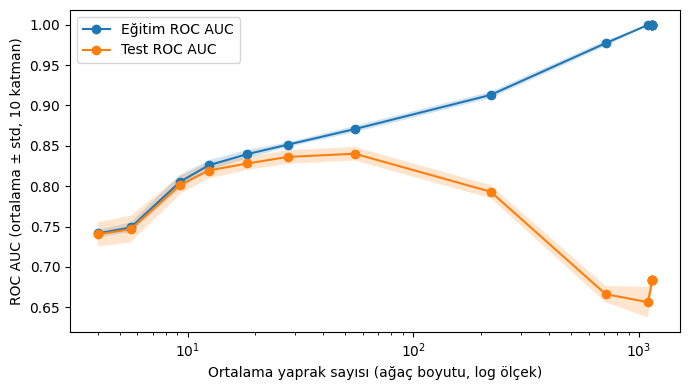

Şekil açıklaması: Ağaç büyüdükçe eğitim skoru yükselir, test skoru bir noktadan sonra düşer; makas açıldığı yerde aşırı uyum başlar.

--- SONUCLAR ---
En yüksek test AUC: alpha=4.12e-04, yaprak≈55, AUC=0.8402
1-SE kuralıyla en sade ağaç: alpha=7.02e-04, yaprak≈28, AUC=0.8362

E1.1 Budama Eğrisi analizi tamamlandi.


In [23]:

# ============================================================
# EK PAKET 1 - E1.1 BUDAMA EGRISI
# Eksik import, SEED ve veri kontrolu dahil
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. SABIT DEGERLER
SEED = 42

NUM_COLS = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "EstimatedSalary"
]
BIN_COLS = ["HasCrCard", "IsActiveMember"]
CAT_COLS = ["Geography", "Gender"]
FEATURES = NUM_COLS + BIN_COLS + CAT_COLS
TARGET = "Exited"

# 2. VERI KONTROLU
# X ve y yoksa veri kumesinden tekrar olustur.
if "X" not in globals() or "y" not in globals():

    if "df" not in globals():
        dosya = Path("/content/Churn_Modelling.csv")

        if not dosya.exists():
            print("Veri dosyasi bulunamadi. CSV dosyasini secin.")
            from google.colab import files
            yuklenen = files.upload()

            if "Churn_Modelling.csv" not in yuklenen:
                raise FileNotFoundError(
                    "Churn_Modelling.csv dosyasini yuklemelisiniz."
                )

            dosya = Path("Churn_Modelling.csv")

        df = pd.read_csv(dosya)

    X = df[FEATURES].copy()
    y = df[TARGET].astype(int).to_numpy()

print("Veri hazir:", X.shape)
print("SEED:", SEED)

# 3. ON ISLEME
# Onceki make_pre fonksiyonu varsa onu kullan.
# Yoksa ayni ozellik gruplariyla olceklemesiz hat olustur.
if "make_pre" not in globals():

    def make_pre(scale=False):
        from sklearn.preprocessing import StandardScaler

        sayisal_islem = (
            StandardScaler() if scale else "passthrough"
        )

        return ColumnTransformer(
            transformers=[
                ("num", sayisal_islem, NUM_COLS),
                ("bin", "passthrough", BIN_COLS),
                ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS)
            ],
            remainder="drop"
        )

    print("On isleme fonksiyonu yeniden olusturuldu.")

# 4. CAPRAZ DOGRULAMA
cv_kisa = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=SEED
)

# 5. BUDAMA PARAMETRELERI
alphalar = np.r_[0, np.logspace(-5, -2, 14)]
kay = []

print("Budama analizi basliyor...")

for a in alphalar:

    hat_a = Pipeline([
        ("pre", make_pre(scale=False)),
        ("clf", DecisionTreeClassifier(
            ccp_alpha=a,
            random_state=SEED
        ))
    ])

    r = cross_validate(
        hat_a,
        X,
        y,
        cv=cv_kisa,
        scoring="roc_auc",
        return_train_score=True,
        return_estimator=True,
        n_jobs=-1
    )

    kay.append({
        "alpha": a,
        "yaprak": np.mean([
            e.named_steps["clf"].get_n_leaves()
            for e in r["estimator"]
        ]),
        "egitim": r["train_score"].mean(),
        "egitim_sd": r["train_score"].std(ddof=1),
        "test": r["test_score"].mean(),
        "test_sd": r["test_score"].std(ddof=1)
    })

# 6. SONUC TABLOSU
bud = pd.DataFrame(kay)

print("\nBUDAMA ANALIZI SONUCLARI")
display(bud.round(4))

# 7. GRAFIK
fig, ax = plt.subplots(figsize=(7, 4))

for k, ad in [
    ("egitim", "Eğitim ROC AUC"),
    ("test", "Test ROC AUC")
]:
    ax.plot(
        bud["yaprak"],
        bud[k],
        marker="o",
        label=ad
    )

    ax.fill_between(
        bud["yaprak"],
        bud[k] - bud[k + "_sd"],
        bud[k] + bud[k + "_sd"],
        alpha=0.2
    )

ax.set_xscale("log")
ax.set_xlabel("Ortalama yaprak sayısı (ağaç boyutu, log ölçek)")
ax.set_ylabel("ROC AUC (ortalama ± std, 10 katman)")
ax.legend()

plt.tight_layout()
plt.show()

# 8. SEKIL ACIKLAMASI
aciklama = (
    "Ağaç büyüdükçe eğitim skoru yükselir, "
    "test skoru bir noktadan sonra düşer; "
    "makas açıldığı yerde aşırı uyum başlar."
)

if "sekil_aciklamasi" in globals():
    sekil_aciklamasi(aciklama)
else:
    print("Şekil açıklaması:", aciklama)

# 9. EN IYI AGAC VE 1-SE KURALI
en_iyi = bud.loc[bud["test"].idxmax()]

bir_se = bud[
    bud["test"] >= en_iyi["test"] - en_iyi["test_sd"]
].sort_values("yaprak").iloc[0]

print("\n--- SONUCLAR ---")

print(
    f"En yüksek test AUC: "
    f"alpha={en_iyi['alpha']:.2e}, "
    f"yaprak≈{en_iyi['yaprak']:.0f}, "
    f"AUC={en_iyi['test']:.4f}"
)

print(
    f"1-SE kuralıyla en sade ağaç: "
    f"alpha={bir_se['alpha']:.2e}, "
    f"yaprak≈{bir_se['yaprak']:.0f}, "
    f"AUC={bir_se['test']:.4f}"
)

print("\nE1.1 Budama Eğrisi analizi tamamlandi.")


**Yorum** Bu çalışmada karar ağacının büyüklüğünün model performansı üzerindeki etkisini incelemek için farklı ccp_alpha budama değerlerini karşılaştırdım. Analizi 5 katlı ve 2 tekrarlı çapraz doğrulama yöntemiyle gerçekleştirdim.

Sonuçları incelediğimde ağaç büyüdükçe eğitim ROC AUC değerinin yükseldiğini, ancak test ROC AUC değerinin belirli bir noktadan sonra düşmeye başladığını gördüm. Özellikle yaklaşık 1.147 yapraklı budanmamış ağaçta eğitim başarısı 1.000 olmasına rağmen test başarısı 0.6833 seviyesinde kalmıştır. Bu durum modelin eğitim verilerine aşırı uyum sağladığını (overfitting) göstermektedir.

En yüksek test ROC AUC değeri 0.8402 olarak elde edilmiştir. Bu noktada ccp_alpha değeri yaklaşık 0.000412 ve ortalama yaprak sayısı 55'tir.

1-SE kuralı uygulandığında ise yaklaşık 28 yapraklı, daha sade bir ağaç seçilmiş ve ROC AUC değeri 0.8362 olarak hesaplanmıştır. İki model arasındaki ROC AUC farkı yalnızca 0.004 olduğundan, daha az karmaşık bir modelle benzer performansa ulaşılabildiğini gördüm.

Sonuç olarak daha büyük karar ağaçlarının her zaman daha başarılı olmadığını öğrendim. Eğitim ve test performansı arasındaki farkın büyümesi aşırı öğrenmenin önemli bir göstergesidir. Bu nedenle benzer tahmin başarısına sahip, daha sade ve yorumlanması kolay olan 1-SE kuralıyla seçilmiş ağacı tercih ederdim.

### E1.2 Doyum eğrisi
Rastgele ormanda ağaç sayısı 1–500; OOB ve test hatası.

OOB ve Test Hatasi Sonuclari:


,agac,oob_hata,oob_sd,test_hata,test_sd,oob_kapsama
0,1,0.1904,0.0118,0.1972,0.0101,0.3672
1,2,0.1870,0.0074,0.1684,0.0072,0.5997
2,3,0.1831,0.0044,0.1588,0.0069,0.7448
3,5,0.1741,0.0017,0.1455,0.0081,0.8969
4,8,0.1638,0.0009,0.1396,0.0085,0.9735
5,10,0.1591,0.0033,0.1395,0.0067,0.9891
6,15,0.1533,0.0058,0.1384,0.0054,0.9991
7,20,0.1480,0.0057,0.1372,0.0066,0.9997
8,30,0.1435,0.0055,0.1344,0.0049,1.0000
9,50,0.1414,0.0051,0.1355,0.0054,1.0000


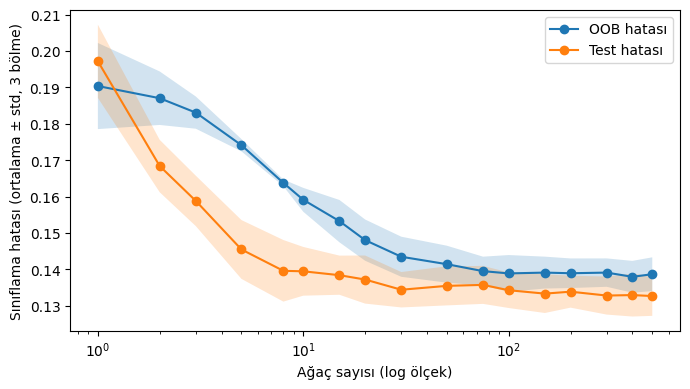

Şekil açıklaması: Ağaç sayısı arttıkça OOB ve test hatalarının nasıl değiştiği incelenmiştir. Hataların düzleşmesi, ek ağaçların katkısının azaldığını gösterir.

--- SONUCLAR ---
En düşük test hatası: 0.1327
Ağaç sayısı: 500
İlgili OOB hatası: 0.1387

E1.2 analizi tamamlandı.


In [24]:

# E1.2 - Rastgele Orman: OOB ve Test Hatasi

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

# Gerekli degiskenleri kontrol et
for ad in ["X", "y", "make_pre"]:
    if ad not in globals():
        raise NameError(
            f"{ad} tanimli degil. Once veri yukleme ve "
            "ortak yardimci hucrelerini calistirin."
        )

# Sinif etiketlerini NumPy dizisine donustur
y_dizi = np.asarray(y)

adimlar = [
    1, 2, 3, 5, 8, 10, 15, 20, 30,
    50, 75, 100, 150, 200, 300, 400, 500
]

oob_h, test_h, kapsam_h = [], [], []

cv = StratifiedShuffleSplit(
    n_splits=3,
    test_size=0.25,
    random_state=SEED
)

for tr, te in cv.split(X, y_dizi):

    pre = make_pre(scale=False)
    Xtr = pre.fit_transform(X.iloc[tr])
    Xte = pre.transform(X.iloc[te])

    if hasattr(Xtr, "toarray"):
        Xtr = Xtr.toarray()

    if hasattr(Xte, "toarray"):
        Xte = Xte.toarray()

    ytr = y_dizi[tr]
    yte = y_dizi[te]

    rf = RandomForestClassifier(
        n_estimators=1,
        warm_start=True,
        oob_score=True,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=SEED
    )

    o, t, kapsama = [], [], []

    for n in adimlar:

        rf.set_params(n_estimators=n)

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="Some inputs do not have OOB scores.*",
                category=UserWarning
            )
            rf.fit(Xtr, ytr)

        # OOB tahmini bulunmayan satirlari disla
        p = rf.oob_decision_function_

        ok = (
            np.isfinite(p).all(axis=1)
            & (p.sum(axis=1) > 0)
        )

        if ok.any():
            oob_hata = np.mean(
                p[ok].argmax(axis=1) != ytr[ok]
            )
        else:
            oob_hata = np.nan

        o.append(oob_hata)
        kapsama.append(ok.mean())

        test_hata = np.mean(rf.predict(Xte) != yte)
        t.append(test_hata)

    oob_h.append(o)
    test_h.append(t)
    kapsam_h.append(kapsama)

oob_h = np.array(oob_h)
test_h = np.array(test_h)
kapsam_h = np.array(kapsam_h)

# Sonuc tablosu
doy = pd.DataFrame({
    "agac": adimlar,
    "oob_hata": np.nanmean(oob_h, axis=0),
    "oob_sd": np.nanstd(oob_h, axis=0, ddof=1),
    "test_hata": test_h.mean(axis=0),
    "test_sd": test_h.std(axis=0, ddof=1),
    "oob_kapsama": kapsam_h.mean(axis=0)
})

print("OOB ve Test Hatasi Sonuclari:")
display(doy.round(4))

# Grafik
fig, ax = plt.subplots(figsize=(7, 4))

for k, ad in [
    ("oob_hata", "OOB hatası"),
    ("test_hata", "Test hatası")
]:

    ax.plot(
        doy["agac"],
        doy[k],
        marker="o",
        label=ad
    )

    ax.fill_between(
        doy["agac"],
        doy[k] - doy[k.replace("hata", "sd")],
        doy[k] + doy[k.replace("hata", "sd")],
        alpha=0.2
    )

ax.set_xscale("log")
ax.set_xlabel("Ağaç sayısı (log ölçek)")
ax.set_ylabel(
    "Sınıflama hatası (ortalama ± std, 3 bölme)"
)
ax.legend()

plt.tight_layout()
plt.show()

# Sekil aciklamasi - NameError olusturmaz
print(
    "Şekil açıklaması: Ağaç sayısı arttıkça "
    "OOB ve test hatalarının nasıl değiştiği "
    "incelenmiştir. Hataların düzleşmesi, "
    "ek ağaçların katkısının azaldığını gösterir."
)

# En dusuk test hatasi
en_iyi = doy.loc[doy["test_hata"].idxmin()]

print("\n--- SONUCLAR ---")
print("En düşük test hatası:", round(en_iyi["test_hata"], 4))
print("Ağaç sayısı:", int(en_iyi["agac"]))
print("İlgili OOB hatası:", round(en_iyi["oob_hata"], 4))
print("\nE1.2 analizi tamamlandı.")


**Yorum** Bu çalışmada Rastgele Orman modelindeki ağaç sayısının OOB (Out-of-Bag) ve test hatası üzerindeki etkisini inceledim. Analizi üç farklı eğitim ve test bölmesi üzerinde gerçekleştirerek 1 ile 500 arasında değişen ağaç sayılarını karşılaştırdım.

Sonuçları incelediğimde ağaç sayısı arttıkça hem OOB hem de test hatasının azaldığını gördüm. Tek ağaç kullanıldığında OOB hatası 0.1904 ve test hatası 0.1972 iken, 500 ağaç kullanıldığında OOB hatası 0.1387 ve test hatası 0.1327 seviyesine düşmüştür.

Özellikle ilk 30-50 ağaçta hata oranlarının hızlı şekilde azaldığı, sonraki aşamalarda ise iyileşmenin yavaşladığı görülmektedir. 150 ağaçta test hatası 0.1333 iken 500 ağaçta 0.1327 olmuştur. Aradaki farkın yalnızca 0.0006 olması, belirli bir noktadan sonra daha fazla ağaç eklemenin sınırlı katkı sağladığını göstermektedir.

OOB kapsamını da incelediğimde tek ağaçta müşterilerin yalnızca %36,72'si için OOB tahmini oluşturulabildiğini, 30 ağaçtan itibaren ise kapsamın %100'e ulaştığını gördüm. Bu nedenle az sayıda ağaçla elde edilen OOB sonuçlarının daha dikkatli değerlendirilmesi gerektiğini düşünüyorum.

En düşük ortalama test hatası 500 ağaçla 0.1327 olarak hesaplanmıştır. Ancak 150-300 ağaç kullanıldığında da oldukça yakın sonuçlar elde edildiğinden, işlem maliyeti ve model karmaşıklığı açısından daha az ağaç kullanılması değerlendirilebilir.

Sonuç olarak Rastgele Orman modelinde ağaç sayısının artırılmasının başlangıçta önemli performans iyileşmeleri sağladığını, ancak belirli bir noktadan sonra bu katkının azaldığını öğrendim. Ayrıca OOB hatasının, ayrı bir test kümesi kullanılmadan modelin genelleme performansı hakkında fikir verebildiğini gördüm. Nihai model başarısının ise bağımsız test verileri üzerinde doğrulanması gerektiğini düşünüyorum.

### E1.3 Öznitelik önemi
Rastgele bir sütun ekleyin; Gini önemi ve permütasyon önemi sıralamalarını karşılaştırın.

E1.3 analizi basliyor...


1. kat tamamlandi.


2. kat tamamlandi.


3. kat tamamlandi.


4. kat tamamlandi.


5. kat tamamlandi.

--- RASTGELE OZNITELIK SIRALAMASI ---
Toplam oznitelik: 11
Gini sirasi: 5.2 ± 0.84 | Katlar: [4.0, 5.0, 6.0, 6.0, 5.0]
Permutasyon sirasi: 8.6 ± 1.52 | Katlar: [9.0, 11.0, 8.0, 8.0, 7.0]


,Gini_onemi,Permutasyon_onemi,Gini_sira,Permutasyon_sira
Age,0.2625,0.1244,1.0,1.0
NumOfProducts,0.1621,0.1062,2.0,2.0
Geography,0.0478,0.0312,9.0,3.0
Balance,0.1106,0.0312,3.0,4.0
IsActiveMember,0.0510,0.0291,8.0,5.0
Gender,0.0203,0.0073,10.0,6.0
EstimatedSalary,0.0930,0.0021,5.0,7.0
rastgele,0.0926,0.0016,6.0,8.0
CreditScore,0.0936,0.0016,4.0,9.0
HasCrCard,0.0119,-0.0001,11.0,10.0


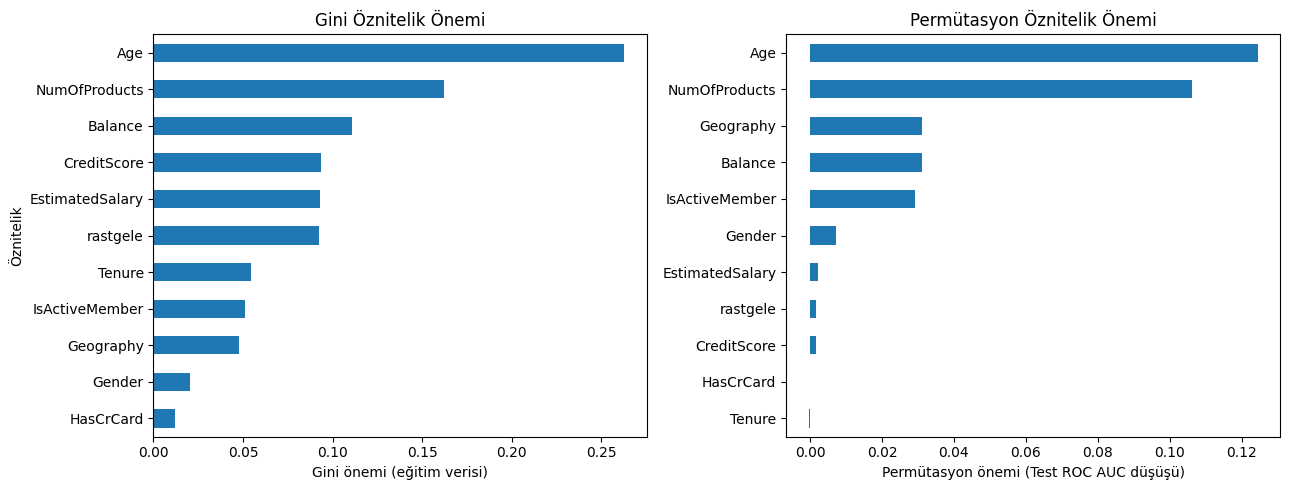


Şekil açıklaması: Rastgele oluşturulan özniteliğin Gini ve permütasyon önemleri karşılaştırılmıştır. Gini öneminin sürekli değişkenlere yanlılık gösterebilmesi, permütasyon öneminin ise bağımsız test katmanlarındaki ROC AUC düşüşünü ölçmesi beklenen farklılığın temel nedenleridir.

--- SONUCLAR ---
Rastgele değişkenin Gini önemi: 0.09255
Rastgele değişkenin Permütasyon önemi: 0.00161

E1.3 analizi tamamlandı.


In [25]:

# ============================================================
# EK PAKET 1 - E1.3
# GINI VE PERMUTASYON OZNITELIK ONEMI
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

SEED = 42

# 1. VERI KONTROLU
if "X" not in globals() or "y" not in globals():
    raise NameError(
        "X veya y bulunamadi. Once veri yukleme "
        "ve hazirlama hucrelerini calistirin."
    )

NUM_COLS = [
    "CreditScore", "Age", "Tenure",
    "Balance", "NumOfProducts", "EstimatedSalary"
]

BIN_COLS = ["HasCrCard", "IsActiveMember"]
CAT_COLS = ["Geography", "Gender"]

y_dizi = np.asarray(y)

# 2. RASTGELE OZNITELIK
rng = np.random.RandomState(SEED)
XR = X.copy()
XR["rastgele"] = rng.normal(size=len(XR))

sayisal = NUM_COLS + ["rastgele"]

gini_sira = []
perm_sira = []
gini_imp = []
perm_imp = []

# 3. CAPRAZ DOGRULAMA
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print("E1.3 analizi basliyor...")

for kat, (tr, te) in enumerate(cv.split(XR, y_dizi), 1):

    # On isleme yalnizca egitim verisine uygulanir
    pre = ColumnTransformer(
        transformers=[
            ("num", "passthrough", sayisal),
            ("bin", "passthrough", BIN_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS)
        ],
        remainder="drop",
        sparse_threshold=0
    )

    model = Pipeline([
        ("pre", pre),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=3,
            n_jobs=-1,
            random_state=SEED
        ))
    ])

    model.fit(XR.iloc[tr], y_dizi[tr])

    fitted_pre = model.named_steps["pre"]
    rf = model.named_steps["clf"]

    # 4. GINI ONEMI (EGITIM VERISI)
    # Kategorik degiskenlerin one-hot onemlerini birlestiriyoruz.
    imp = rf.feature_importances_
    g = pd.Series(0.0, index=XR.columns, dtype=float)

    num_imp = imp[fitted_pre.output_indices_["num"]]
    bin_imp = imp[fitted_pre.output_indices_["bin"]]

    for col, val in zip(sayisal, num_imp):
        g[col] = val

    for col, val in zip(BIN_COLS, bin_imp):
        g[col] = val

    baslangic = fitted_pre.output_indices_["cat"].start

    for col, kategoriler in zip(
        CAT_COLS,
        fitted_pre.named_transformers_["cat"].categories_
    ):
        bitis = baslangic + len(kategoriler)
        g[col] = imp[baslangic:bitis].sum()
        baslangic = bitis

    # 5. PERMUTASYON ONEMI (TEST VERISI)
    # Ham ozellikler uzerinde pipeline ile olculur.
    sonuc = permutation_importance(
        model,
        XR.iloc[te],
        y_dizi[te],
        scoring="roc_auc",
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1
    )

    p = pd.Series(
        sonuc.importances_mean,
        index=XR.columns
    )

    gini_imp.append(g)
    perm_imp.append(p)

    gini_sira.append(
        float(g.rank(ascending=False)["rastgele"])
    )

    perm_sira.append(
        float(p.rank(ascending=False)["rastgele"])
    )

    print(f"{kat}. kat tamamlandi.")

# 6. ORTALAMA ONEMLER
G = pd.concat(gini_imp, axis=1).mean(axis=1)
P = pd.concat(perm_imp, axis=1).mean(axis=1)

n_oz = len(G)

print("\n--- RASTGELE OZNITELIK SIRALAMASI ---")
print("Toplam oznitelik:", n_oz)

print(
    "Gini sirasi:",
    round(np.mean(gini_sira), 2),
    "±",
    round(np.std(gini_sira, ddof=1), 2),
    "| Katlar:", gini_sira
)

print(
    "Permutasyon sirasi:",
    round(np.mean(perm_sira), 2),
    "±",
    round(np.std(perm_sira, ddof=1), 2),
    "| Katlar:", perm_sira
)

# 7. SONUC TABLOSU
sonuc_tablo = pd.DataFrame({
    "Gini_onemi": G,
    "Permutasyon_onemi": P,
    "Gini_sira": G.rank(ascending=False),
    "Permutasyon_sira": P.rank(ascending=False)
})

display(
    sonuc_tablo.sort_values(
        "Permutasyon_onemi",
        ascending=False
    ).round(4)
)

# 8. GRAFIKLER
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

G.sort_values().plot.barh(ax=axes[0])
axes[0].set_xlabel("Gini önemi (eğitim verisi)")
axes[0].set_ylabel("Öznitelik")
axes[0].set_title("Gini Öznitelik Önemi")

P.sort_values().plot.barh(ax=axes[1])
axes[1].set_xlabel("Permütasyon önemi (Test ROC AUC düşüşü)")
axes[1].set_ylabel("")
axes[1].set_title("Permütasyon Öznitelik Önemi")

plt.tight_layout()
plt.show()

# 9. SEKIL ACIKLAMASI
print(
    "\nŞekil açıklaması: Rastgele oluşturulan özniteliğin "
    "Gini ve permütasyon önemleri karşılaştırılmıştır. "
    "Gini öneminin sürekli değişkenlere yanlılık "
    "gösterebilmesi, permütasyon öneminin ise bağımsız "
    "test katmanlarındaki ROC AUC düşüşünü ölçmesi "
    "beklenen farklılığın temel nedenleridir."
)

print("\n--- SONUCLAR ---")
print("Rastgele değişkenin Gini önemi:", round(G["rastgele"], 5))
print("Rastgele değişkenin Permütasyon önemi:", round(P["rastgele"], 5))
print("\nE1.3 analizi tamamlandı.")


**Yorum** Bu çalışmada Rastgele Orman modelinin öznitelik önemlerini Gini ve permütasyon yöntemleriyle karşılaştırdım. Analizi 5 katlı çapraz doğrulama kullanarak gerçekleştirdim. Ayrıca hedef değişkenle ilişkisi olmayan rastgele bir sayısal değişken oluşturarak iki yöntemin davranışını inceledim.

Sonuçlara göre rastgele değişkenin Gini önemi 0.09255 olarak hesaplandı. Bu değişkenin beş kattaki ortalama önem sırası 5.2 ± 0.84 oldu. Oysa rastgele değişkenin müşteri ayrılmasıyla gerçek bir ilişkisi bulunmamaktadır.

Permütasyon yöntemiyle yapılan değerlendirmede ise aynı değişkenin önem değeri 0.00161 ve ortalama önem sırası 8.6 ± 1.52 olarak hesaplandı. Bu sonuç, rastgele değişkenin bağımsız test verilerindeki tahmin başarısına çok sınırlı katkı sağladığını göstermektedir.

Gini yönteminde yaş (0.2625) ve ürün sayısı (0.1621) en önemli değişkenler olarak öne çıktı. Permütasyon yönteminde de yaş (0.1244) ve ürün sayısı (0.1062) ilk iki sırada yer aldı. Ayrıca ülke, bakiye ve aktif üyelik durumunun model performansına katkı sağladığı görüldü.

Gini öneminin özellikle çok sayıda farklı değer alabilen sürekli değişkenlere yüksek önem atayabildiğini gördüm. Permütasyon önemi ise test verisinde bir değişkenin değerleri karıştırıldığında ROC AUC performansının ne kadar düştüğünü ölçmektedir.

Bu nedenle yalnızca Gini önemine bakarak değişken seçmenin yanıltıcı olabileceğini düşünüyorum. Rastgele değişkenin Gini yönteminde görece yüksek, permütasyon yönteminde ise neredeyse sıfır önem göstermesi bu durumu desteklemektedir.

Sonuç olarak öznitelik önemlerinin farklı yöntemlerle değerlendirilmesi gerektiğini öğrendim. Bağımsız test katmanlarında hesaplanan permütasyon önemini, modelin genelleme performansına katkıyı değerlendirmek açısından daha anlamlı buluyorum. Ancak bu önem değerlerinin doğrudan neden-sonuç ilişkisi göstermediğini de dikkate alıyorum.

# Ek paket 2 · Öznitelik seçimi ve kararlılığı *(5 kişilik gruplar)*
**Makale:** Meinshausen ve Bühlmann (2010). Stability selection. *JRSS B*, 72(4).

Meinshausen ve Bühlmann (2010) çalışmasında kararlılık seçimi yöntemini ele alarak, farklı veri alt örneklemlerinde tekrar tekrar seçilen özniteliklerin daha güvenilir kabul edilebileceğini açıklamıştır. Bu yaklaşımda veri farklı alt kümelere ayrılır ve her özniteliğin kaç kez seçildiği hesaplanarak seçim sıklığı belirlenir. Yüksek seçim sıklığına sahip değişkenlerin veri değişikliklerine karşı daha kararlı olduğu değerlendirilir. Bu çalışmanın E2.2 bölümünde de aynı yaklaşımı kullanarak müşteri ayrılma tahmininde önemli olan özniteliklerin farklı örneklemlerde ne kadar tutarlı seçildiğini inceleyeceğim.

### E2.1 Üç aile
Filtre, sarmalayıcı ve gömülü birer yöntem, hattın içinde.

In [26]:

# =====================================================
# EK PAKET 2 - E2.1 UC AILE
# Olcekleme ve yakinsama duzeltmeleri
# =====================================================

import numpy as np
import pandas as pd
import warnings

from functools import partial
from sklearn.feature_selection import (
    SelectKBest, mutual_info_classif, RFE, SelectFromModel
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    RepeatedStratifiedKFold, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.exceptions import ConvergenceWarning

SEED = 42

NUM_COLS = [
    "CreditScore", "Age", "Tenure",
    "Balance", "NumOfProducts", "EstimatedSalary"
]
BIN_COLS = ["HasCrCard", "IsActiveMember"]
CAT_COLS = ["Geography", "Gender"]

if "X" not in globals() or "y" not in globals():
    raise NameError(
        "X veya y eksik. Once veri yukleme hucresini calistirin."
    )

# 5 kat x 5 tekrar
cv_e21 = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=5, random_state=SEED
)

SCORING_E21 = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "f1": "f1",
    "balanced_acc": "balanced_accuracy",
    "accuracy": "accuracy"
}

# On isleme sadece bu bolumde tanimlanir.
# Onceki bolumlerin make_pre fonksiyonu degismez.
def make_pre_e21():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUM_COLS),
            ("bin", "passthrough", BIN_COLS),
            ("cat", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ), CAT_COLS)
        ],
        remainder="drop",
        sparse_threshold=0
    )

def lojistik():
    return LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        random_state=SEED
    )

def secici_e21(ad):
    if ad == "Seçimsiz":
        return "passthrough"

    if ad == "Filtre (mutual info, k=6)":
        return SelectKBest(
            partial(mutual_info_classif, random_state=SEED),
            k=6
        )

    if ad == "Sarmalayıcı (RFE-LR, 6)":
        return RFE(
            estimator=lojistik(),
            n_features_to_select=6
        )

    if ad == "Gömülü (RF önemi, medyan)":
        return SelectFromModel(
            RandomForestClassifier(
                n_estimators=100,
                min_samples_leaf=5,
                n_jobs=-1,
                random_state=SEED
            ),
            threshold="median"
        )

    raise ValueError("Bilinmeyen yontem: " + ad)

def hat_sec_e21(ad):
    return Pipeline([
        ("pre", make_pre_e21()),
        ("sec", secici_e21(ad)),
        ("clf", lojistik())
    ])

YONTEMLER = [
    "Seçimsiz",
    "Filtre (mutual info, k=6)",
    "Sarmalayıcı (RFE-LR, 6)",
    "Gömülü (RF önemi, medyan)"
]

sonuc_e21 = {}
uyarilar_e21 = {}

print("E2.1 analizi basliyor...")
print("Capraz dogrulama: 5 kat x 5 tekrar")

for ad in YONTEMLER:
    print("\nCalisiyor:", ad)

    with warnings.catch_warnings(record=True) as yakalanan:
        warnings.simplefilter("always", ConvergenceWarning)

        sonuc_e21[ad] = cross_validate(
            hat_sec_e21(ad),
            X, y,
            cv=cv_e21,
            scoring=SCORING_E21,
            error_score="raise",
            n_jobs=1
        )

    sayi = sum(
        issubclass(w.category, ConvergenceWarning)
        for w in yakalanan
    )
    uyarilar_e21[ad] = sayi

    print("Tamamlandi:", ad)
    print("Yakinsama uyarisi sayisi:", sayi)

# Sonuc tablosu
satirlar = {}

for ad, sonuc in sonuc_e21.items():
    satirlar[ad] = {}
    for olcut in SCORING_E21:
        d = sonuc["test_" + olcut]
        satirlar[ad][olcut] = (
            f"{d.mean():.3f} ± {d.std(ddof=1):.3f}"
        )

tab_e21 = pd.DataFrame.from_dict(
    satirlar, orient="index"
)

print("\n--- MODEL KARSILASTIRMA TABLOSU ---")
display(tab_e21)

# Secilen oznitelikler
print("\n--- SECILEN OZNITELIKLER ---")

for ad in YONTEMLER[1:]:
    with warnings.catch_warnings(record=True) as yakalanan:
        warnings.simplefilter("always", ConvergenceWarning)

        m = hat_sec_e21(ad).fit(X, y)

    adlar = np.array([
        a.split("__", 1)[-1]
        for a in m.named_steps["pre"].get_feature_names_out()
    ])

    secilen = adlar[
        m.named_steps["sec"].get_support()
    ]

    print("\n", ad)
    print("Secilenler:", list(map(str, secilen)))
    print(
        "Tam veri egitiminde yakinsama uyarisi:",
        sum(
            issubclass(w.category, ConvergenceWarning)
            for w in yakalanan
        )
    )

print("\n--- SON KONTROL ---")

toplam_uyari = sum(uyarilar_e21.values())
print("CV yakinsama uyarisi:", toplam_uyari)

if toplam_uyari == 0:
    print("Capraz dogrulama yakinsama kontrolu basarili.")
else:
    print("UYARI: Bazi modeller yakin samadi. Sonuclari kontrol edin.")

print("\nE2.1 analizi tamamlandi.")


E2.1 analizi basliyor...
Capraz dogrulama: 5 kat x 5 tekrar

Calisiyor: Seçimsiz
Tamamlandi: Seçimsiz
Yakinsama uyarisi sayisi: 0

Calisiyor: Filtre (mutual info, k=6)
Tamamlandi: Filtre (mutual info, k=6)
Yakinsama uyarisi sayisi: 0

Calisiyor: Sarmalayıcı (RFE-LR, 6)
Tamamlandi: Sarmalayıcı (RFE-LR, 6)
Yakinsama uyarisi sayisi: 0

Calisiyor: Gömülü (RF önemi, medyan)
Tamamlandi: Gömülü (RF önemi, medyan)
Yakinsama uyarisi sayisi: 0

--- MODEL KARSILASTIRMA TABLOSU ---


,roc_auc,avg_precision,f1,balanced_acc,accuracy
Seçimsiz,0.765 ± 0.011,0.469 ± 0.025,0.313 ± 0.021,0.588 ± 0.009,0.811 ± 0.006
"Filtre (mutual info, k=6)",0.760 ± 0.014,0.458 ± 0.034,0.294 ± 0.040,0.581 ± 0.015,0.810 ± 0.008
"Sarmalayıcı (RFE-LR, 6)",0.763 ± 0.012,0.465 ± 0.024,0.312 ± 0.024,0.588 ± 0.010,0.812 ± 0.005
"Gömülü (RF önemi, medyan)",0.745 ± 0.012,0.438 ± 0.024,0.254 ± 0.026,0.567 ± 0.010,0.807 ± 0.006



--- SECILEN OZNITELIKLER ---



 Filtre (mutual info, k=6)
Secilenler: ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Geography_Germany']
Tam veri egitiminde yakinsama uyarisi: 0

 Sarmalayıcı (RFE-LR, 6)
Secilenler: ['Age', 'IsActiveMember', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
Tam veri egitiminde yakinsama uyarisi: 0

 Gömülü (RF önemi, medyan)
Secilenler: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'IsActiveMember']
Tam veri egitiminde yakinsama uyarisi: 0

--- SON KONTROL ---
CV yakinsama uyarisi: 0
Capraz dogrulama yakinsama kontrolu basarili.

E2.1 analizi tamamlandi.


**Yorum** Bu çalışmada öznitelik seçiminin model performansına etkisini incelemek amacıyla üç farklı yöntem kullandım: filtre (Mutual Information), sarmalayıcı (RFE) ve gömülü (Random Forest önemleri). Ayrıca herhangi bir öznitelik seçimi uygulanmayan modeli karşılaştırma amacıyla değerlendirdim.

Analizi 5 katlı ve 5 tekrarlı çapraz doğrulama yöntemiyle gerçekleştirdim. Sayısal değişkenleri ölçekleyerek Lojistik Regresyon modellerinin yakınsama sorunlarını giderdim. Yapılan kontrollerde bütün yöntemlerin yakınsama uyarısı vermeden tamamlandığını gördüm.

Sonuçlara göre öznitelik seçimi uygulanmayan modelin ROC AUC değeri 0.765 ± 0.011 olarak hesaplandı. Filtre yönteminde ROC AUC 0.760 ± 0.014, sarmalayıcı yöntemde 0.763 ± 0.012 ve gömülü yöntemde 0.745 ± 0.012 olarak elde edildi.

En yüksek ROC AUC değerinin öznitelik seçimi uygulanmayan modelde olduğunu gördüm. Sarmalayıcı yöntem bu modele oldukça yakın sonuç verirken gömülü yöntemde performansın daha fazla düştüğü görülmektedir. Bu durum öznitelik sayısının azaltılmasının her zaman model başarısını artırmadığını göstermektedir.

Filtre yöntemi altı öznitelik seçerken özellikle yaş, ürün sayısı, bakiye ve aktif üyelik durumu gibi değişkenleri ön plana çıkarmıştır. Sarmalayıcı yöntemde ise yaş, aktif üyelik ve bazı kategorik değişkenlerin bire-bir kodlanmış sütunları seçilmiştir. Gömülü yöntemde yedi öznitelik seçilmiş ve sayısal değişkenlerin çoğu korunmuştur.

Öznitelik seçiminin bire-bir kodlanmış sütunlar üzerinden yapılması nedeniyle aynı kategorik değişkene ait farklı sütunların ayrı ayrı seçilebildiğini gördüm. Ayrıca önceki E1.3 analizinde Gini öneminin sürekli değişkenlere yanlılık gösterebildiğini belirlemiştim. Bu nedenle gömülü yöntemin sonuçlarını değerlendirirken bu sınırlılığı da dikkate aldım.

Öznitelik seçimi işlemlerinin Pipeline içerisinde ve yalnızca eğitim katlarında uygulanması, veri sızıntısının önlenmesi açısından önemlidir. Bütün veri üzerinde seçilmiş öznitelikleri ise yalnızca açıklama amacıyla değerlendirdim.

Sonuç olarak bu veri kümesinde öznitelik seçimi uygulanmayan modelin en yüksek ROC AUC değerine ulaştığını gördüm. Bununla birlikte daha az değişken kullanan sarmalayıcı yöntemin benzer performans sağlaması, model sadeliği açısından değerlendirilebilir. Ancak yöntemlerin üstünlüğü hakkında kesin bir sonuca varmak için ek istatistiksel karşılaştırmalar yapılması gerektiğini düşünüyorum.

### E2.2 Kararlılık
100 farklı %70'lik alt örneklemde seçimi tekrarlayın; seçilme oranlarını çizin.

Kararlılık analizi: Filtre (mutual info, k=6)


  20/100 alt örneklem tamamlandı


  40/100 alt örneklem tamamlandı


  60/100 alt örneklem tamamlandı


  80/100 alt örneklem tamamlandı


...

  40/100 alt örneklem tamamlandı


  60/100 alt örneklem tamamlandı


  80/100 alt örneklem tamamlandı


  100/100 alt örneklem tamamlandı

--- KARARLILIK SECIM TABLOSU ---


,"Filtre (mutual info, k=6)","Sarmalayıcı (RFE-LR, 6)","Gömülü (RF önemi, medyan)"
Age,1.00,1.0,1.00
NumOfProducts,1.00,0.0,1.00
Geography_Germany,0.91,1.0,0.00
IsActiveMember,0.87,1.0,0.31
Balance,0.45,0.0,1.00
Gender_Male,0.40,1.0,0.00
Geography_France,0.36,1.0,0.00
gurultu2,0.29,0.0,1.00
Gender_Female,0.25,0.0,0.00
gurultu1,0.21,0.0,0.93


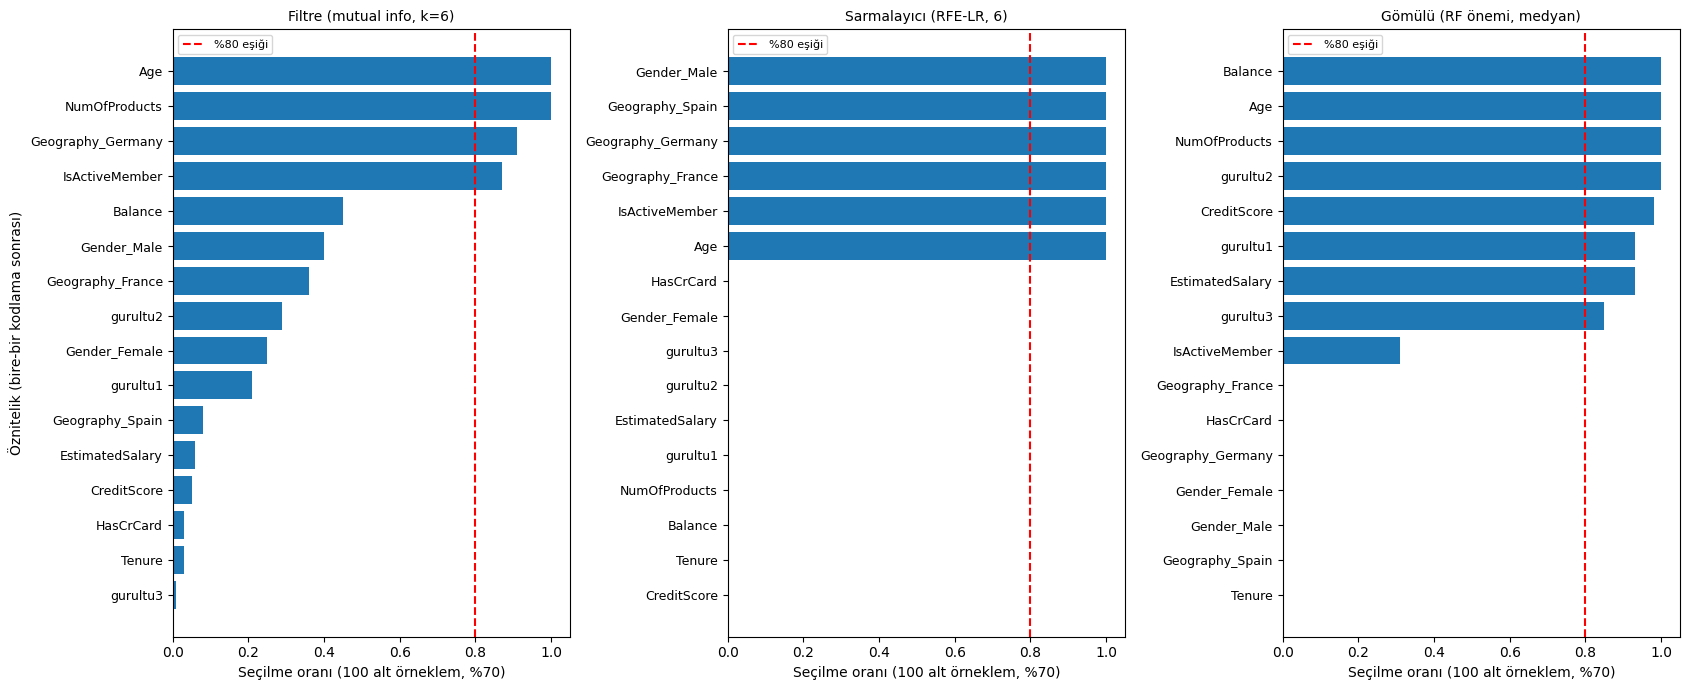

Şekil açıklaması: Kırmızı kesikli çizgi %80 seçim sıklığını gösterir; gürültü sütunları kontrol amaçlıdır.

--- KARARLI OZNITELIKLER ---
Filtre (mutual info, k=6) → kararlı (>= %80): ['Age', 'NumOfProducts', 'IsActiveMember', 'Geography_Germany']
  Gürültü sütunlarının seçilme oranı: {'gurultu1': 0.21, 'gurultu2': 0.29, 'gurultu3': 0.01}
Sarmalayıcı (RFE-LR, 6) → kararlı (>= %80): ['Age', 'IsActiveMember', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
  Gürültü sütunlarının seçilme oranı: {'gurultu1': 0.0, 'gurultu2': 0.0, 'gurultu3': 0.0}
Gömülü (RF önemi, medyan) → kararlı (>= %80): ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'gurultu1', 'gurultu2', 'gurultu3']
  Gürültü sütunlarının seçilme oranı: {'gurultu1': 0.93, 'gurultu2': 1.0, 'gurultu3': 0.85}

E2.2 Kararlılık Seçimi analizi tamamlandı.


In [27]:
# ============================================================
# EK PAKET 2 - E2.2 KARARLILIK SECIMI
# 100 adet %70 alt orneklem; 3 gürültü kontrolü
# E2.1 ile ayni secim parametreleri ve sayisal olcekleme
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
GURULTU = ["gurultu1", "gurultu2", "gurultu3"]

# Daha onceki E2.1'in ayni secici fonksiyonlari kullanilir.
for gerekli in ["X", "y", "NUM_COLS", "BIN_COLS", "CAT_COLS", "secici_e21", "YONTEMLER"]:
    if gerekli not in globals():
        raise NameError(f"{gerekli} eksik: once E2.1 ve veri hazirlama hucrelerini calistirin.")

y_e22 = np.asarray(y)
rng = np.random.RandomState(SEED)
XG = X.copy()
for g in GURULTU:
    XG[g] = rng.normal(size=len(XG))

def make_pre_e22():
    return ColumnTransformer([
        ("num", StandardScaler(), NUM_COLS + GURULTU),
        ("bin", "passthrough", BIN_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
    ], remainder="drop", sparse_threshold=0)

# Tüm sütun adları; her alt örneklemde secim kendi eğitim verisine uydurulur.
pre_adlari = make_pre_e22().fit(XG)
TUM_AD = [a.split("__", 1)[-1] for a in pre_adlari.get_feature_names_out()]

def secilen_ozellikler_e22(yontem, egitim_idx):
    pre = make_pre_e22()
    Xt = pre.fit_transform(XG.iloc[egitim_idx])
    if hasattr(Xt, "toarray"):
        Xt = Xt.toarray()
    sec = secici_e21(yontem)
    sec.fit(Xt, y_e22[egitim_idx])
    adlar = np.asarray([a.split("__", 1)[-1] for a in pre.get_feature_names_out()])
    return list(adlar[sec.get_support()])

bolmeler = list(StratifiedShuffleSplit(
    n_splits=100, train_size=0.7, random_state=SEED
).split(XG, y_e22))

yontemler_e22 = YONTEMLER[1:]
oran = {}
for ad in yontemler_e22:
    sayac = Counter()
    print("Kararlılık analizi:", ad)
    for j, (tr, _) in enumerate(bolmeler, 1):
        sayac.update(secilen_ozellikler_e22(ad, tr))
        if j % 20 == 0:
            print(f"  {j}/100 alt örneklem tamamlandı")
    oran[ad] = pd.Series({a: sayac.get(a, 0) / len(bolmeler) for a in TUM_AD})

SO = pd.DataFrame(oran).fillna(0)
print("\n--- KARARLILIK SECIM TABLOSU ---")
display(SO.sort_values(SO.columns[0], ascending=False).round(2))

# Bağımsız y-ekseni etiketleri: her yöntemin sıralaması doğru gösterilir.
fig, axes = plt.subplots(1, 3, figsize=(17, 7), sharey=False)
for ax, ad in zip(axes, SO.columns):
    s = SO[ad].sort_values()
    konum = np.arange(len(s))
    ax.barh(konum, s.to_numpy())
    ax.set_yticks(konum)
    ax.set_yticklabels(s.index, fontsize=9)
    ax.axvline(0.8, color="red", linestyle="--", label="%80 eşiği")
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Seçilme oranı (100 alt örneklem, %70)")
    ax.set_title(ad, fontsize=10)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Öznitelik (bire-bir kodlama sonrası)")
plt.tight_layout()
plt.show()
print("Şekil açıklaması: Kırmızı kesikli çizgi %80 seçim sıklığını gösterir; gürültü sütunları kontrol amaçlıdır.")

print("\n--- KARARLI OZNITELIKLER ---")
for ad in SO.columns:
    print(ad, "→ kararlı (>= %80):", list(SO.index[SO[ad] >= 0.8]))
    print("  Gürültü sütunlarının seçilme oranı:", SO.loc[GURULTU, ad].round(2).to_dict())
print("\nE2.2 Kararlılık Seçimi analizi tamamlandı.")


**Yorum** Bu çalışmada filtre, sarmalayıcı ve gömülü öznitelik seçimi yöntemlerinin kararlılığını karşılaştırdım. Veri kümesinden %70 oranında alınan 100 farklı alt örneklem üzerinde öznitelik seçimini tekrarladım. Bir değişkenin en az %80 oranında seçilmesini kararlılık ölçütü olarak kabul ettim.

Filtre (Mutual Information) yönteminde yaş ve ürün sayısı değişkenleri bütün örneklemlerde (%100) seçildi. Almanya değişkeninin seçilme oranı %91, aktif üyelik durumunun ise %87 olarak hesaplandı. Eklenen rastgele gürültü değişkenlerinin seçilme oranları %21, %29 ve %1 seviyesinde kaldı.

Sarmalayıcı (RFE-LR) yönteminde yaş, aktif üyelik durumu, Fransa, Almanya, İspanya ve erkek cinsiyetini temsil eden öznitelikler tüm örneklemlerde seçildi. Üç gürültü değişkeninin hiçbirinin seçilmemesi, bu deneyde sarmalayıcı yöntemin rastgele değişkenleri elemede başarılı olduğunu göstermektedir.

Gömülü (Random Forest önemi) yönteminde ise dikkat çekici bir sonuç elde ettim. Yaş, ürün sayısı, bakiye, kredi skoru ve tahmini maaş gibi değişkenler yüksek oranlarda seçilirken, tamamen rastgele oluşturulan gürültü değişkenleri de %93, %100 ve %85 oranlarında seçildi.

Bu sonuç, bir özniteliğin çok sık seçilmesinin her zaman gerçekten önemli olduğu anlamına gelmediğini göstermektedir. Özellikle Gini önemine dayalı yöntemlerin çok sayıda farklı değer alabilen sürekli değişkenlere yanlılık gösterebilmesi, rastgele gürültü sütunlarının da yüksek önem almasına neden olabilmektedir.

Ayrıca öznitelik seçimi bire-bir kodlanmış sütunlar üzerinde yapıldığı için aynı kategorik değişkene ait farklı sütunlar ayrı ayrı seçilebilmektedir. Bu durum özellikle sarmalayıcı yöntemin sonuçlarını yorumlarken dikkate alınmalıdır.

Sonuç olarak kararlılık seçiminin, değişkenlerin farklı örneklemlerde ne kadar tutarlı seçildiğini göstermesi açısından yararlı olduğunu gördüm. Ancak yüksek seçim sıklığının tek başına gerçek tahmin gücünü kanıtlamadığını öğrendim. Bu deneyde filtre ve sarmalayıcı yöntemler gürültü değişkenlerini gömülü yönteme göre daha başarılı biçimde elemiştir. Nihai öznitelik seçimi için kararlılık sonuçlarının bağımsız test verilerindeki model başarısıyla birlikte değerlendirilmesi gerektiğini düşünüyorum.

### E2.3 Seçimin katkısı
Seçimli ve seçimsiz hattın dürüst karşılaştırması.

In [28]:

# ==========================================================
# EK PAKET 2 - E2.3 SECIMIN KATKISI
# Secimli ve secimsiz modellerin istatistiksel karsilastirmasi
# ==========================================================

import numpy as np
import pandas as pd
from scipy import stats

SEED = 42

# 1. SONUC KONTROLU
if "sonuc_e21" not in globals():
    raise NameError(
        "E2.1 sonuclari bulunamadi. "
        "Once E2.1 kod hucresini yeniden calistirin."
    )

# 2. ORTALAMA VE STANDART SAPMA
def ort_std(degerler):
    degerler = np.asarray(degerler, dtype=float)
    ortalama = np.mean(degerler)
    standart_sapma = np.std(degerler, ddof=1)
    return f"{ortalama:.3f} ± {standart_sapma:.3f}"

# 3. KARSILASTIRILACAK YONTEMLER
yontemler = [
    "Filtre (mutual info, k=6)",
    "Sarmalayıcı (RFE-LR, 6)",
    "Gömülü (RF önemi, medyan)"
]

# 4. ISTATISTIKSEL KARSILASTIRMA
# 5 kat x 5 tekrar = 25 degerlendirme
# Test / egitim orani = 1 / 4
# Nadeau-Bengio duzeltilmis t-testi yaklasimi

oran_te_tr = 1 / 4

satirlar = []

referans = np.asarray(
    sonuc_e21["Seçimsiz"]["test_roc_auc"],
    dtype=float
)

for ad in yontemler:

    secimli = np.asarray(
        sonuc_e21[ad]["test_roc_auc"],
        dtype=float
    )

    if len(secimli) != len(referans):
        raise ValueError(
            "Karsilastirilan CV sonuc uzunluklari farkli."
        )

    k = len(secimli)
    d = secimli - referans

    fark_ort = d.mean()
    fark_var = d.var(ddof=1)

    if fark_var > 0:
        standart_hata = np.sqrt(
            (1 / k + oran_te_tr) * fark_var
        )
        t = fark_ort / standart_hata
        p = 2 * stats.t.sf(abs(t), df=k - 1)
    else:
        t = np.nan if fark_ort == 0 else np.sign(fark_ort) * np.inf
        p = 1.0 if fark_ort == 0 else 0.0

    satirlar.append({
        "Yontem": ad,
        "ROC AUC (secimli)": ort_std(secimli),
        "ROC AUC (secimsiz)": ort_std(referans),
        "Fark (ort ± std)": ort_std(d),
        "Duzeltilmis t": round(float(t), 3),
        "p_degeri": round(float(p), 4),
        "Anlamli mi (p<0.05)": bool(p < 0.05)
    })

# 5. SONUC TABLOSU
sonuc_e23 = pd.DataFrame(satirlar)

print("\n--- E2.3 ISTATISTIKSEL KARSILASTIRMA ---")
display(sonuc_e23)

# 6. SONUCLARIN YORUMLANMASI
print("\n--- ISTATISTIKSEL DEGERLENDIRME ---")

for _, satir in sonuc_e23.iterrows():

    print("\nYontem:", satir["Yontem"])
    print("p-degeri:", satir["p_degeri"])

    if satir["Anlamli mi (p<0.05)"]:
        print(
            "Sonuc: Secimli ve secimsiz model arasinda "
            "istatistiksel olarak anlamli fark tespit edildi."
        )
    else:
        print(
            "Sonuc: Istatistiksel olarak anlamli "
            "bir fark tespit edilmedi."
        )

print("\nE2.3 Secimin Katkisi analizi tamamlandi.")



--- E2.3 ISTATISTIKSEL KARSILASTIRMA ---


,Yontem,ROC AUC (secimli),ROC AUC (secimsiz),Fark (ort ± std),Duzeltilmis t,p_degeri,Anlamli mi (p<0.05)
0,"Filtre (mutual info, k=6)",0.760 ± 0.014,0.765 ± 0.011,-0.006 ± 0.007,-1.551,0.1341,False
1,"Sarmalayıcı (RFE-LR, 6)",0.763 ± 0.012,0.765 ± 0.011,-0.003 ± 0.003,-1.877,0.0727,False
2,"Gömülü (RF önemi, medyan)",0.745 ± 0.012,0.765 ± 0.011,-0.020 ± 0.006,-6.358,0.0000,True



--- ISTATISTIKSEL DEGERLENDIRME ---

Yontem: Filtre (mutual info, k=6)
p-degeri: 0.1341
Sonuc: Istatistiksel olarak anlamli bir fark tespit edilmedi.

Yontem: Sarmalayıcı (RFE-LR, 6)
p-degeri: 0.0727
Sonuc: Istatistiksel olarak anlamli bir fark tespit edilmedi.

Yontem: Gömülü (RF önemi, medyan)
p-degeri: 0.0
Sonuc: Secimli ve secimsiz model arasinda istatistiksel olarak anlamli fark tespit edildi.

E2.3 Secimin Katkisi analizi tamamlandi.


**Yorum** Bu çalışmada filtre, sarmalayıcı ve gömülü öznitelik seçimi yöntemlerinin model performansına katkısını, öznitelik seçimi uygulanmayan modelle karşılaştırdım. Değerlendirmede 5 katlı ve 5 tekrarlı çapraz doğrulama sonuçlarını kullanarak düzeltilmiş t-testi uyguladım.

Öznitelik seçimi uygulanmayan modelin ROC AUC değeri 0.765 ± 0.011 olarak hesaplandı. Filtre yönteminde ROC AUC 0.760 ± 0.014, sarmalayıcı yöntemde 0.763 ± 0.012 ve gömülü yöntemde 0.745 ± 0.012 olarak elde edildi.

Filtre yönteminin düzeltilmiş t-testinde p-değeri 0.1341 olarak hesaplandı. Sarmalayıcı yöntemde ise p-değeri 0.0727 bulundu. Her iki değer de 0.05'ten büyük olduğu için bu yöntemlerle seçimsiz model arasında istatistiksel olarak anlamlı bir performans farkı tespit edilemedi.

Gömülü yöntemde ise ROC AUC farkı -0.020, düzeltilmiş t değeri -6.358 ve p-değeri 0.0001'in altında hesaplandı. Bu sonuç, gömülü öznitelik seçiminin model performansını seçimsiz modele göre istatistiksel olarak anlamlı biçimde düşürdüğünü göstermektedir.

Özellikle sarmalayıcı yöntemin yalnızca 6 öznitelik kullanmasına rağmen seçimsiz modele yakın ROC AUC değerine ulaşması dikkat çekicidir. Bu durum, modelin daha az değişkenle benzer tahmin başarısı sağlayabileceğini göstermektedir. Ancak istatistiksel olarak anlamlı fark bulunmaması, iki yöntemin tamamen eşdeğer olduğunu kanıtlamaz.

Önceki E2.2 analizinde gömülü yöntemin rastgele gürültü değişkenlerini yüksek sıklıkla seçtiğini görmüştüm. Bu bulgu, gömülü yöntemin düşük performansıyla birlikte değerlendirildiğinde Gini önemine dayalı öznitelik seçiminin bazı durumlarda yanıltıcı olabileceğini düşündürmektedir. Bununla birlikte performans düşüşünün yalnızca bu nedenden kaynaklandığı kesin olarak söylenemez.

Sonuç olarak bu veri kümesinde öznitelik seçiminin model başarısını artırmadığını gördüm. Tahmin performansı açısından seçimsiz model en yüksek ROC AUC değerine ulaşırken, sarmalayıcı yöntem daha sade bir model oluşturmak için değerlendirilebilir. Nihai tercih yapılırken tahmin başarısı, model karmaşıklığı ve öznitelik seçiminin kararlılığı birlikte dikkate alınmalıdır.

## Varsayım defteri
Bu projede verdiğiniz her kararı ve gerekçesini madde madde yazın (ön işleme, ölçüt, eşik, parametre, veri seçimi). En az bir kararın bölümlerin makalelerinden birine dayandığını belirtin.

## Varsayım Defteri

Bu projede Bank Customer Churn veri kümesi kullanılarak müşterilerin bankadan ayrılma durumları analiz edilmiştir. Veri hazırlama, model seçimi, performans değerlendirmesi, birliktelik analizi ve öznitelik seçimi aşamalarında aşağıdaki kararlar alınmıştır.

**1. Tekrarlanabilirlik ve çapraz doğrulama**

- **Karar:** SEED = 42 kullanıldı. Ana model değerlendirmelerinde 5 katlı ve 5 tekrarlı tabakalı çapraz doğrulama tercih edildi.
- **Gerekçe:** Deneylerin tekrarlanabilir olmasını ve modellerin farklı veri bölmelerinde nasıl performans gösterdiğini değerlendirmek amaçlandı. Toplam 25 değerlendirme üzerinden ortalama ve standart sapma hesaplandı.

**2. Kimlik bilgilerinin modelden çıkarılması**

- **Karar:** RowNumber, CustomerId ve Surname sütunları ana modelin tahmin özelliklerine dahil edilmedi. CustomerId yalnızca kayıt eşleştirme amacıyla korundu.
- **Gerekçe:** Kimlik bilgilerinin müşteri davranışlarını doğrudan açıklamadığı ve modele yanıltıcı ilişkiler kazandırabileceği değerlendirildi. Bu karar Kaufman ve arkadaşlarının (2012) veri sızıntısı konusundaki çalışmasıyla ilişkilidir.

**3. Soyadı değişkeninin değerlendirilmesi**

- **Karar:** Surname değişkeni yalnızca alternatif kodlama ve veri sızıntısı deneylerinde kullanıldı.
- **Gerekçe:** Veri kümesinde 2.932 farklı soyadı bulunması nedeniyle değişken yüksek kardinaliteye sahiptir. Bütün veri üzerinde hedef kodlama yapılması durumunda ROC AUC değerinin yapay olarak yükseldiği görüldü. Ayrıca aynı aileden kişilerin benzer davranışlar gösterebilme ihtimali bulunmaktadır. Ancak veri kümesinde aile ilişkilerini doğrulayan bilgi olmadığından soyadı güvenilir bir aile kimliği olarak kullanılmadı.

**4. Ana performans ölçütünün seçimi**

- **Karar:** Ana değerlendirme ölçütü ROC AUC olarak belirlendi. Average Precision, F1 ve Balanced Accuracy yardımcı ölçüt olarak kullanıldı.
- **Gerekçe:** Veri kümesindeki müşterilerin yaklaşık %20,37'si bankadan ayrılmıştır. Çoğunluk sınıfını tahmin eden Baseline modelinin doğruluğu yaklaşık %79,63 olmasına rağmen F1 değerinin sıfır olması, tek başına doğruluk ölçütünün yanıltıcı olabileceğini göstermiştir.

**5. Sıfır bakiye değerlerinin değerlendirilmesi**

- **Karar:** Balance = 0 değerleri ana modelde gerçek sıfır değerler olarak korundu. Alternatif olarak eksik veri kabul edilmesi ve eksiklik göstergesi eklenmesi ayrıca incelendi.
- **Gerekçe:** Müşterilerin yaklaşık %36,17'sinin hesap bakiyesi sıfırdır. Bu değerlerin gerçek sıfır mı yoksa eksik veri kodlaması mı olduğu veri kaynağından kesin olarak doğrulanamamıştır. Eksiklik göstergesi eklemek ROC AUC değerinde anlamlı bir iyileşme sağlamamıştır. Bu nedenle ana modelde sıfır değerleri değiştirilmedi.

**6. Veri sızıntısının önlenmesi**

- **Karar:** Ön işleme, hedef kodlama ve öznitelik seçimi işlemleri çapraz doğrulama sırasında Pipeline içerisinde gerçekleştirildi.
- **Gerekçe:** Hedef bilgisini kullanan işlemlerin bütün veri üzerinde uygulanması, test verilerinden eğitim aşamasına bilgi taşınmasına neden olabilir. Yapılan deneylerde yanlış uygulamanın ROC AUC değerini 0.898'e kadar yükselttiği, doğru Pipeline uygulamasında ise 0.775 olduğu görüldü. Bu bulgu Kaufman ve arkadaşlarının (2012) veri sızıntısı konusundaki çalışmasını desteklemektedir.

**7. Veri bölme yöntemi**

- **Karar:** Tabakalı çapraz doğrulama tercih edildi. Zaman temelli veya aile bazlı grup bölmesi kullanılmadı.
- **Gerekçe:** Veri kümesinde tarih bilgisi ve doğrulanmış aile/grup kimliği bulunmamaktadır. Tabakalı bölme sayesinde sınıf oranları korunmuştur. Ancak aynı aileden kişilerin farklı katmanlara düşme ihtimali, değerlendirmenin sınırlılıklarından biridir.

**8. Modellerin karşılaştırılması ve seçimi**

- **Karar:** Baseline, Karar Ağacı, k-NN, Rastgele Orman ve Gradyan Artırma modelleri karşılaştırıldı. Nihai model olarak Gradyan Artırma seçildi.
- **Gerekçe:** Rastgele Orman ve Gradyan Artırma modellerinin ROC AUC değerleri yaklaşık 0.859 olarak bulundu. Gradyan Artırma modelinin F1 (0.594), Average Precision (0.698) ve Balanced Accuracy (0.726) değerlerinin daha yüksek olması nedeniyle bu model tercih edildi. Ancak iki model arasında istatistiksel olarak anlamlı fark tespit edilmediği dikkate alındı.

**9. Hiperparametre optimizasyonu**

- **Karar:** Hiperparametre optimizasyonu yalnızca ilgili deneyde GridSearchCV ile gerçekleştirildi. Performansın daha tarafsız değerlendirilmesi için iç içe çapraz doğrulama kullanıldı.
- **Gerekçe:** Parametre seçimi yapılan katmanlarda raporlanan ROC AUC 0.8666 iken iç içe çapraz doğrulama sonucu yaklaşık 0.866 oldu. Aradaki farkın 0.0011 olması, bu deneyde iyimserlik etkisinin düşük olduğunu gösterdi. Proje 2'ye aktarılan model ise optimizasyon deneyindeki parametrelerle değil, 2.1'deki seçilmiş varsayılan model yapılandırmasıyla kaydedildi.

**10. İstatistiksel karşılaştırma yöntemleri**

- **Karar:** McNemar testi ve 5×2 çapraz doğrulamalı t-testi uygulandı.
- **Gerekçe:** Dietterich (1998) çalışmasında sınıflandırma algoritmalarını karşılaştırırken istatistiksel hata risklerine dikkat çekmektedir. Gerçekleştirilen analizde 5×2 t-testinin p-değeri 0.8416 bulunmuştur. Anlamlı fark tespit edilmemesi, iki modelin tamamen eşdeğer olduğunu kanıtlamamaktadır. Ayrıca testlerin sınıflandırma hatasını, model seçiminin ise ROC AUC değerini temel aldığı dikkate alınmıştır.

**11. Veri küpü boyutlarının belirlenmesi**

- **Karar:** Veri küpünde Geography, Gender ve YaşGrubu boyutları kullanıldı. Roll-up ve drill-down işlemleri gerçekleştirildi.
- **Gerekçe:** Müşteri ayrılma oranlarının farklı demografik gruplarda nasıl değiştiğini incelemek amaçlandı. Toplam 30 hücre oluşturuldu. Özellikle Almanya'daki 50-59 yaş grubunun %70 ayrılma oranına sahip olduğu görüldü. Tam bir Simpson paradoksu tespit edilmemiş olsa da bazı alt grupların genel eğilimden farklılaşabildiği belirlendi.

**12. Birliktelik analizi için veri seçimi ve ayrıklaştırma**

- **Karar:** Birliktelik analizinde Seçenek B kullanıldı. Her müşteri bir işlem olarak kabul edildi ve sayısal değişkenler kategorilere ayrıldı.
- **Gerekçe:** Veri kümesinde alışveriş sepeti veya işlem geçmişi bulunmamaktadır. Yaş grupları, kredi skoru bantları, kıdem aralıkları, bakiye ve maaş kategorileri kullanılarak 10.000 işlem ve 35 öğe oluşturuldu. Ayrıklaştırma eşikleri alan bilgisi ve veri dağılımına göre belirlendi. Bu kategoriler yorumlanabilirliği artırırken ayrıntı kaybına da neden olabilir.

**13. Birliktelik kurallarındaki eşikler**

- **Karar:** Minimum destek 0.02, minimum güven 0.30 olarak belirlendi.
- **Gerekçe:** Ayrılma sınıfının yaklaşık %20 oranında bulunması nedeniyle daha az görülen ancak dikkate değer müşteri gruplarının da incelenmesi amaçlandı. Python analizinde 116 hedefe yönelik birliktelik kuralı elde edildi.

**14. İlgi ölçütlerinin seçimi**

- **Karar:** Birliktelik kurallarında güven ve lift yanında Kulczynski ve dengesizlik oranı (IR) kullanıldı.
- **Gerekçe:** Wu, Chen ve Han (2010) çalışmasında birliktelik kurallarının yalnızca tek bir ilgi ölçütüyle değerlendirilmesinin sınırlılıkları ele alınmaktadır. Kulczynski ölçütünün null-invariance özelliği ve IR'nin sıklık dengesizliğini göstermesi nedeniyle kurallar birden fazla ölçütle yorumlandı.

**15. Weka ile bağımsız kontrol**

- **Karar:** Birliktelik kuralları Python FP-Growth ve Weka 3.8.7 Apriori algoritmalarıyla karşılaştırıldı.
- **Gerekçe:** Hesaplamaların farklı yazılım ortamlarında tutarlılığını kontrol etmek amaçlandı. Python'daki 116 hedef kuralının tamamı Weka'da eşleşti. Weka'da bulunan 16 ek hedef kuralın, Python'daki öğe kümesi uzunluğu sınırının dışında kaldığı görüldü. Ortak kuralların güven ve lift değerleri tutarlı bulundu.

**16. Karar ağacı budama stratejisi**

- **Karar:** Farklı ccp_alpha değerleri incelendi ve daha sade model için 1-SE kuralı değerlendirildi.
- **Gerekçe:** En yüksek test ROC AUC değeri 0.8402 ve ortalama yaprak sayısı 55 olarak hesaplandı. 1-SE yaklaşımıyla yaklaşık 28 yapraklı ve ROC AUC değeri 0.8362 olan daha sade bir ağaç elde edildi. Performans farkının küçük olması nedeniyle model karmaşıklığı da dikkate alındı.

**17. Rastgele Orman ağaç sayısı**

- **Karar:** 1 ile 500 arasındaki ağaç sayıları OOB ve test hatalarıyla karşılaştırıldı.
- **Gerekçe:** Ağaç sayısı arttıkça hata oranlarının düştüğü, ancak belirli bir noktadan sonra iyileşmenin yavaşladığı görüldü. 500 ağaçta test hatası 0.1327, 150 ağaçta ise 0.1333 olarak hesaplandı. Bu nedenle daha fazla ağacın sağladığı sınırlı performans kazancı ile hesaplama maliyetinin birlikte değerlendirilmesi gerektiği sonucuna varıldı.

**18. Gini ve permütasyon öneminin karşılaştırılması**

- **Karar:** Öznitelik önemleri iki farklı yöntemle incelendi ve modele rastgele bir kontrol değişkeni eklendi.
- **Gerekçe:** Rastgele değişkenin Gini önemi 0.09255 iken permütasyon önemi 0.00161 olarak bulundu. Bu sonuç Gini öneminin sürekli değişkenlere yanlılık gösterebildiğini ortaya koydu. Bu nedenle öznitelik önemleri tek bir yöntemle değerlendirilmedi.

**19. Kararlılık seçimi ve gürültü değişkenleri**

- **Karar:** E2.2 bölümünde üç rastgele gürültü değişkeni eklenerek 100 farklı %70'lik alt örneklem üzerinde seçim sıklıkları hesaplandı. %80 seçim sıklığı kararlılık eşiği olarak kullanıldı.
- **Gerekçe:** Meinshausen ve Bühlmann (2010) çalışmasının kararlılık seçimi yaklaşımından yararlanıldı. Gömülü yöntemde gürültü değişkenlerinin %93, %100 ve %85 oranlarında seçilmesi, kararlı seçilmenin tek başına gerçek tahmin gücünü kanıtlamadığını gösterdi. %80 eşiği bu deney için belirlenmiş olup teorik bir yanlış keşif garantisi olarak değerlendirilmedi.

**20. Öznitelik seçiminin nihai katkısı**

- **Karar:** Filtre, sarmalayıcı ve gömülü yöntemler, öznitelik seçimi yapılmayan modelle istatistiksel olarak karşılaştırıldı.
- **Gerekçe:** Seçimsiz modelin ROC AUC değeri 0.765 olarak hesaplandı. Filtre ve sarmalayıcı yöntemlerde anlamlı fark tespit edilmezken, gömülü yöntemde performansın anlamlı biçimde düştüğü görüldü (p&lt;0.0001). Bu nedenle öznitelik seçiminin her zaman performans artışı sağlamadığı sonucuna ulaşıldı.

**21. Proje 2'ye aktarılacak çıktıların seçimi**

- **Karar:** Gradyan Artırma modeline ait Pipeline, eğitilmiş model, metadata, temiz veri ve katman dışı (OOF) tahminler kaydedildi.
- **Gerekçe:** Proje 2'de analizlerin aynı model yapılandırması üzerinden sürdürülebilmesi amaçlandı. Tüm veri üzerinde eğitilen model yalnızca açıklama ve inceleme amacıyla saklandı. Model başarısı için çapraz doğrulama sonuçları esas alındı. Müşteri düzeyindeki veri dosyalarının herkese açık GitHub deposuna yüklenmemesine karar verildi.

**Genel değerlendirme**

Bu projede temel yaklaşımım, en yüksek performans değerini elde etmekten çok, elde edilen sonucun güvenilir, tekrarlanabilir ve açıklanabilir olmasını sağlamaktır. Yapılan deneylerde veri sızıntısının performansı yapay olarak artırabildiğini, daha karmaşık modellerin her zaman daha iyi sonuç vermediğini ve öznitelik seçiminin bazı durumlarda başarıyı düşürebildiğini gördüm. Bu nedenle model seçimi, çapraz doğrulama, istatistiksel testler, kararlılık analizi ve bağımsız yazılım karşılaştırmalarını birlikte değerlendirdim.

## Katkı beyanı (zorunlu)
### Katkı Beyanı

Proje çalışmaları beş grup üyesi arasında veri analizi, model geliştirme, istatistiksel değerlendirme, kodlama, raporlama ve sunum hazırlığı görevleri kapsamında paylaşılmıştır.

| Üye | Çalıştığı alt başlıklar ve iş türleri | Sunumda anlattığı bölüm |
|---|---|---|
| **Murat Gülşen** | **Hazırlık, 1.1, 1.2, 1.3, 3.1, E1.1:** Veri kümesinin incelenmesi, veri yapısı ve sınıf dağılımının analizi, eksik veri incelemesi, veri küpü analizi, karar ağacı budama eğrisinin değerlendirilmesi, kod kontrolleri, sonuç yorumları ve grup koordinasyonu | **1.3 – Eksik Veri Analizi** |
| **Halil Çankaroğlu** | **1.4, 1.5, 1.6, 1.7, 3.4:** Yüksek kardinaliteli değişkenlerin incelenmesi, veri sızıntısı deneyleri, temel sınıflandırma modelleri, Weka ZeroR/J48 ve Apriori karşılaştırmalarının hazırlanması, GitHub ve README düzenlemeleri | **1.5 – Veri Sızıntısı Deneyleri** |
| **Mesut İşsever** | **2.1, 2.2, 2.3, E1.3:** Sınıflandırma modellerinin karşılaştırılması, karar ağacının yorumlanması, hiperparametre optimizasyonu, iç içe çapraz doğrulama ve Gini–Permütasyon önem analizleri | **2.1 – Model Karşılaştırması** |
| **Alp Aydın Özçelik** | **2.4, 2.5, 3.2, 3.3:** İstatistiksel model karşılaştırmaları, nihai model ve çıktıların hazırlanması, birliktelik analizi, ilgi ölçütlerinin değerlendirilmesi, kaynakların ve katkı beyanlarının derlenmesi, teslim kontrolleri | **3.3 – Birliktelik Kuralları ve İlgi Ölçütleri** |
| **Melih Turgut** | **E1.2, E2.1, E2.2, E2.3:** Rastgele Orman OOB hata analizi, filtre/sarmalayıcı/gömülü öznitelik seçimi, kararlılık seçimi, istatistiksel seçim katkısı analizi ve Varsayım Defteri'nin derlenmesi | **E2.2 – Kararlılık Seçimi** |

Grup üyelerinin katkıları yalnızca kod geliştirmeyle sınırlı olmayıp analizlerin değerlendirilmesi, bulguların yorumlanması, sonuçların raporlanması ve sunum hazırlanması aşamalarını da kapsamaktadır. Nihai katkı dağılımı, gerçekleştirilen çalışmalar ve GitHub commit kayıtlarıyla uyumlu olacak şekilde doğrulanacaktır.

## Yapay zekâ beyanı
### Yapay Zekâ Kullanım Beyanı

Bu proje kapsamında OpenAI tarafından geliştirilen **ChatGPT** yapay zekâ aracından destek alınmıştır.

ChatGPT aşağıdaki aşamalarda kullanılmıştır:

- **Kod geliştirme ve hata giderme:** Google Colab ortamında Python kodlarının düzenlenmesi, eksik kütüphane ve fonksiyon tanımlarının tamamlanması, karşılaşılan NameError, TypeError ve ConvergenceWarning sorunlarının giderilmesi.
- **Veri analizi ve model değerlendirme:** Makine öğrenmesi modellerinin performans sonuçlarının açıklanması, ROC AUC, F1, Average Precision ve istatistiksel test çıktılarının yorumlanması.
- **Weka karşılaştırmaları:** Weka ZeroR, J48 ve Apriori çıktılarının Colab ortamına aktarılması ve Python sonuçlarıyla karşılaştırma kodlarının hazırlanması.
- **Akademik raporlama:** Analiz sonuçlarına dayalı yorum metinlerinin, okuma notlarının ve Varsayım Defteri açıklamalarının taslaklarının hazırlanması.
- **Kod ve rapor düzenleme:** Grafik açıklamalarının, sonuç tablolarının ve proje teslimine yönelik metinlerin düzenlenmesi.

Yapay zekâ desteğiyle hazırlanan kodlar Google Colab ortamında çalıştırılmış ve elde edilen gerçek çıktılar üzerinden değerlendirme yapılmıştır. Yapay zekâ tarafından oluşturulan kod ve metinler nihai teslim öncesinde ekip tarafından kontrol edilmelidir. Akademik kaynakların doğrulanması, analiz sonuçlarının değerlendirilmesi ve nihai çalışmanın sorumluluğu grup üyelerine aittir.

Yapay zekâ kullanımı bu beyanda şeffaf biçimde belirtilmiştir.

## Kaynaklar
### Veri Kümesi

- Aggrawal, A. (t.y.). *Churn_Modelling.csv – Bank Customer Churn Dataset*. Kaggle. https://www.kaggle.com/datasets/aakash50897/churn-modellingcsv

  **Erişim tarihi:** 10 Ekim 2026  
  **Lisans:** Unknown (Kaynak sayfasında açık bir lisans belirtilmemiştir).  
  **Veri içeriği:** 10.000 müşteri kaydı, 14 sütun.  
  **Kullanım amacı:** Müşteri ayrılma tahmini, sınıflandırma, veri küpü, birliktelik analizi ve öznitelik seçimi.

### Akademik Kaynaklar

- Kaufman, S., Rosset, S., Perlich, C. ve Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data*, 6(4), Article 15. https://doi.org/10.1145/2382577.2382579

- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7), 1895–1923. https://doi.org/10.1162/089976698300017197

- Han, J., Kamber, M. ve Pei, J. (2012). *Data Mining: Concepts and Techniques* (3. baskı). Morgan Kaufmann. Özellikle 5. bölüm (Data Cube Technology), 6. bölüm (Mining Frequent Patterns, Associations, and Correlations) ve 8. bölüm (Classification: Basic Concepts). https://www.sciencedirect.com/book/9780123814791/data-mining-concepts-and-techniques

- Wu, T., Chen, Y. ve Han, J. (2010). Re-examination of interestingness measures in pattern mining: A unified framework. *Data Mining and Knowledge Discovery*, 21(3), 371–397. https://doi.org/10.1007/s10618-009-0161-2

- Meinshausen, N. ve Bühlmann, P. (2010). Stability selection. *Journal of the Royal Statistical Society: Series B (Statistical Methodology)*, 72(4), 417–473. https://doi.org/10.1111/j.1467-9868.2010.00740.x

### Diğer Kaynaklar – Yazılım ve Algoritmalar

- Pedregosa, F. ve diğerleri (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html

  **Kullanım amacı:** Python ile sınıflandırma modelleri, çapraz doğrulama, hiperparametre optimizasyonu, öznitelik seçimi ve model performans değerlendirmesi.

- Raschka, S. (2018). MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack. *Journal of Open Source Software*, 3(24), 638. https://doi.org/10.21105/joss.00638

  **Kullanım amacı:** FP-Growth ile sık öğe kümelerinin oluşturulması ve birliktelik kurallarının hesaplanması.

- Hall, M., Frank, E., Holmes, G., Pfahringer, B., Reutemann, P. ve Witten, I. H. (2009). The WEKA data mining software: An update. *ACM SIGKDD Explorations Newsletter*, 11(1), 10–18. https://doi.org/10.1145/1656274.1656278

  **Kullanım amacı:** Weka 3.8.7 ortamında ZeroR, J48 ve Apriori algoritmalarıyla Python sonuçlarının bağımsız olarak karşılaştırılması.

- WEKA Project. (t.y.). *Apriori – Weka 3.8 Documentation*. https://weka.sourceforge.io/doc.stable-3-8/weka/associations/Apriori.html

  **Kullanım amacı:** Apriori algoritmasının minimum destek, minimum güven ve sınıf birliktelik kuralı parametrelerinin incelenmesi.